In [44]:
import pandas as pd

ai_path = r"G:\.shortcut-targets-by-id\1KKrBsNyhwzbYus9ExtUkUd_3jE4VZ4W6\AI_Analysis\risk_index\ai_exposure_composite_clean.csv"
df = pd.read_csv(ai_path)
df.columns = df.columns.str.strip()

print("COLUMNS:")
print(df.columns.tolist())

print("\nSAMPLE:")
print(df.head(5))

COLUMNS:
['SOC', 'AI Exposure Category', 'Data Source', 'Occupation Title', 'PCA Weighted Score', 'Z Score Variance', 'Annual Total Openings', 'Annual Percent Change', 'Education Value', 'Work Experience Value', 'Growth Rate', '50th Percentile Wage']

SAMPLE:
       SOC AI Exposure Category            Data Source  \
0  11-1011                 High  AI Exposure Composite   
1  11-1021                 High  AI Exposure Composite   
2  11-2011                 High  AI Exposure Composite   
3  11-2021                 High  AI Exposure Composite   
4  11-2022                 High  AI Exposure Composite   

                      Occupation Title  PCA Weighted Score  Z Score Variance  \
0                     Chief Executives            0.818306          0.395745   
1      General and Operations Managers            0.696313          0.213237   
2  Advertising and Promotions Managers            0.678133          0.185190   
3                   Marketing Managers            0.783175          0.2

# Table. Summary Statistics by AI Exposure Quintile 
### Table. 6-digit breakdown growth (%), wages (median), employment (%) but the x5 quintiles of AI exposure>


### SCRIPT 1: AI COMPOSITE DOCUMENT VERSION 

In [38]:
from openpyxl import load_workbook
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from datetime import datetime

import pandas as pd
import numpy as np

# =========================================================
# LOAD DATA
# =========================================================

ai_path = r"G:\.shortcut-targets-by-id\1KKrBsNyhwzbYus9ExtUkUd_3jE4VZ4W6\AI_Analysis\risk_index\ai_exposure_composite_clean.csv"

df = pd.read_csv(ai_path)
df.columns = df.columns.str.strip()

# =========================================================
# FIX SOC
# =========================================================

def fix_soc(s):
    s = str(s).strip()

    if s.startswith("Nov"):
        return s.replace("Nov", "11")

    return s

df["SOC"] = df["SOC"].astype(str).apply(fix_soc)

# =========================================================
# CLEAN NUMERIC FIELDS
# =========================================================

def clean_money(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if s in ["", "-", "NA", "N/A", "nan"]:
        return np.nan

    return pd.to_numeric(
        s.replace("$", "").replace(",", ""),
        errors="coerce"
    )


def clean_num(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if s in ["", "-", "NA", "N/A", "nan"]:
        return np.nan

    return pd.to_numeric(
        s.replace(",", "").replace("%", "").replace("−", "-"),
        errors="coerce"
    )


df["Median_Wage"] = df["50th Percentile Wage"].apply(clean_money)
df["Openings"] = df["Annual Total Openings"].apply(clean_num)
df["Growth"] = df["Annual Percent Change"].apply(clean_num)
df["Exposure"] = df["AI Exposure Category"].astype(str).str.strip()

# =========================================================
# REMOVE AGGREGATES
# =========================================================

df = df[~df["SOC"].astype(str).str.endswith("0000")].copy()

# =========================================================
# COLLAPSE TO SOC LEVEL
# =========================================================

df_clean = (
    df.sort_values("Median_Wage", ascending=False)
      .groupby("SOC", as_index=False)
      .agg({
          "Occupation Title": "first",
          "Median_Wage": "first",
          "Openings": "first",
          "Growth": "first",
          "Exposure": "first"
      })
)

# =========================================================
# BUILD TABLE
# =========================================================

summary1 = (
    df_clean.groupby("Exposure", observed=False)
    .agg(
        **{
            "6-Digit SOC Occupations": ("SOC", "nunique"),
            "Median Wage": ("Median_Wage", "mean"),
            "Projected Growth": ("Growth", "mean"),
            "Annual Openings": ("Openings", "sum")
        }
    )
    .reset_index()
)

# =========================================================
# ORDER EXPOSURE GROUPS
# =========================================================

order = ["Very Low", "Low", "Medium", "High", "Very High"]

summary1["Exposure"] = pd.Categorical(
    summary1["Exposure"],
    categories=order,
    ordered=True
)

summary1 = summary1.sort_values("Exposure").reset_index(drop=True)

print(summary1)

    Exposure  6-Digit SOC Occupations   Median Wage  Projected Growth  \
0   Very Low                      152  48379.831933          0.008738   
1        Low                      154  53689.218750          0.010069   
2     Medium                      216  63733.820225          0.012083   
3       High                      151  85696.466165          0.012068   
4  Very High                      152  72175.886525          0.005623   

   Annual Openings  
0            63216  
1           119297  
2            97346  
3            54483  
4            82037  


### SCRIPT 2: OEWS + PROJECTIONS VERSION 

In [49]:
import pandas as pd
import numpy as np
from datetime import datetime

from openpyxl import load_workbook
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter

# =========================================================
# FILE PATHS
# =========================================================

ai_path = r"G:\.shortcut-targets-by-id\1KKrBsNyhwzbYus9ExtUkUd_3jE4VZ4W6\AI_Analysis\risk_index\ai_exposure_composite_clean.csv"
oews_path = r"C:\Users\301533\Downloads\Arizona OEWS 2024 (13).xlsx"

proj_2yr_path = r"C:\Users\301533\Downloads\occ_short_term (3).xlsx"
proj_10yr_path = r"C:\Users\301533\Downloads\ltop-04-2024to2034 (3).xlsx"

output_folder = r"G:\.shortcut-targets-by-id\1KKrBsNyhwzbYus9ExtUkUd_3jE4VZ4W6\AI_Analysis\Arielle's Stuff\Report Tables and Figures"
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
output_path = rf"{output_folder}\AI_Exposure_Quintile_Summary_Tables_{timestamp}.xlsx"

# =========================================================
# SETTINGS
# =========================================================

EXPOSURE_ORDER = ["Very Low", "Low", "Medium", "High", "Very High"]

PATINA_GREEN = "379B91"
LIGHT_GRAY = "EDEDED"
WHITE = "FFFFFF"
BLACK = "000000"
BORDER_GRAY = "C9C9C9"

# =========================================================
# HELPER FUNCTIONS
# =========================================================

def fix_soc(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip().replace(".0", "")

    if s.startswith("Nov-"):
        suffix = s.replace("Nov-", "").strip()
        nov_map = {
            "11": "11-2011",
            "21": "11-2021",
            "22": "11-2022",
            "32": "11-2032",
            "33": "11-2033",
            "12": "11-3012",
            "13": "11-3013",
            "31": "11-3031",
            "51": "11-3051",
            "61": "11-3061",
            "71": "11-3071",
            "41": "11-9041",
            "72": "11-9072",
            "81": "11-9081",
            "79": "11-9179",
            "99": "11-9199",
        }
        return nov_map.get(suffix, np.nan)

    return s


def clean_money(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if s in ["-", "", "NA", "N/A", "nan"]:
        return np.nan

    return pd.to_numeric(s.replace("$", "").replace(",", ""), errors="coerce")


def clean_num(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if s in ["-", "", "NA", "N/A", "nan"]:
        return np.nan

    return pd.to_numeric(
        s.replace(",", "").replace("%", "").replace("−", "-"),
        errors="coerce"
    )


def clean_percent_to_decimal(x):
    if pd.isna(x):
        return np.nan

    raw = str(x).strip()
    val = clean_num(x)

    if pd.isna(val):
        return np.nan

    if "%" in raw:
        return val / 100

    if abs(val) <= 1:
        return val

    return val / 100


def weighted_avg(data, value_col, weight_col):
    temp = data[[value_col, weight_col]].dropna()
    temp = temp[temp[weight_col] > 0]

    if temp.empty:
        return np.nan

    return np.average(temp[value_col], weights=temp[weight_col])


def build_composite_summary_table(data, openings_label):
    summary = (
        data.groupby("Exposure", observed=False)
        .apply(lambda x: pd.Series({
            "6-Digit SOC Occupations": x["SOC"].nunique(),
            "Median Wage": x["Median_Wage"].mean(),
            "Annual Growth": x["Growth"].mean(),
            openings_label: x["Openings"].sum()
        }))
        .reset_index()
    )

    summary["Exposure"] = pd.Categorical(
        summary["Exposure"],
        categories=EXPOSURE_ORDER,
        ordered=True
    )

    return summary.sort_values("Exposure").reset_index(drop=True)


def build_official_summary_table(data):
    total_employment = data["Employment"].sum()

    summary = (
        data.groupby("Exposure", observed=False)
        .apply(lambda x: pd.Series({
            "6-Digit SOC Occupations": x["SOC"].nunique(),
            "Median Wage": weighted_avg(x, "Median_Wage", "Employment"),
            "Employment": x["Employment"].sum(),
            "Employment Share": x["Employment"].sum() / total_employment,

            "Projected Growth, 2025-2027": weighted_avg(x, "Growth_2yr", "Employment"),
            "Projected Openings, 2025-2027": x["Openings_2yr"].sum(),

            "Projected Growth, 2024-2034": weighted_avg(x, "Growth_10yr", "Employment"),
            "Projected Openings, 2024-2034": x["Openings_10yr"].sum()
        }))
        .reset_index()
    )

    summary["Exposure"] = pd.Categorical(
        summary["Exposure"],
        categories=EXPOSURE_ORDER,
        ordered=True
    )

    return summary.sort_values("Exposure").reset_index(drop=True)


# =========================================================
# TABLE 1: AI COMPOSITE ONLY
# =========================================================

ai = pd.read_csv(ai_path)
ai.columns = ai.columns.str.strip()

composite = ai.copy()

composite["SOC"] = composite["SOC"].apply(fix_soc)
composite["Exposure"] = composite["AI Exposure Category"].astype(str).str.strip()

composite["Median_Wage"] = composite["50th Percentile Wage"].apply(clean_money)
composite["Openings"] = composite["Annual Total Openings"].apply(clean_num)

if "Annual Percent Change" in composite.columns:
    composite["Growth"] = composite["Annual Percent Change"].apply(clean_percent_to_decimal)
else:
    composite["Growth"] = composite["Growth Rate"].apply(clean_percent_to_decimal)

composite = composite[~composite["SOC"].astype(str).str.endswith("0000")].copy()
composite = composite[composite["Exposure"].isin(EXPOSURE_ORDER)].copy()

composite_soc = (
    composite
    .sort_values(["SOC", "Occupation Title"])
    .groupby("SOC", as_index=False)
    .agg({
        "Occupation Title": "first",
        "Exposure": "first",
        "Median_Wage": "first",
        "Growth": "first",
        "Openings": "first"
    })
)

summary_composite = build_composite_summary_table(
    composite_soc,
    openings_label="Annual Openings"
)

print("\nTABLE 1: AI COMPOSITE ONLY SUMMARY")
print(summary_composite)


# =========================================================
# TABLE 2: OEWS + 2-YEAR + 10-YEAR PROJECTIONS
# =========================================================

ai_lookup = ai.copy()
ai_lookup["SOC"] = ai_lookup["SOC"].apply(fix_soc)
ai_lookup["Exposure"] = ai_lookup["AI Exposure Category"].astype(str).str.strip()

ai_lookup = (
    ai_lookup[["SOC", "Exposure"]]
    .dropna()
    .drop_duplicates(subset=["SOC"])
)

ai_lookup = ai_lookup[ai_lookup["Exposure"].isin(EXPOSURE_ORDER)].copy()
ai_lookup = ai_lookup[~ai_lookup["SOC"].astype(str).str.endswith("0000")].copy()

# -------------------------
# OEWS wage and employment
# -------------------------

oews = pd.read_excel(oews_path, sheet_name="Annual", header=1)
oews.columns = oews.columns.str.strip()

oews["SOC"] = oews["SOC Code1"].apply(fix_soc)
oews["Median_Wage"] = oews["50th Percentile Wage"].apply(clean_money)
oews["Employment"] = oews["Rounded Employment"].apply(clean_num)

oews = oews[["SOC", "Occupation Title", "Median_Wage", "Employment"]].copy()
oews = oews[oews["SOC"].astype(str).str.match(r"^\d{2}-\d{4}$", na=False)].copy()
oews = oews[~oews["SOC"].astype(str).str.endswith("0000")].copy()
oews = oews.drop_duplicates(subset=["SOC"])

# -------------------------
# 2-year projections
# -------------------------

proj2 = pd.read_excel(proj_2yr_path, header=2)
proj2.columns = proj2.columns.str.strip()

soc2_col = [c for c in proj2.columns if "SOC Code" in c][0]

proj2 = proj2.rename(columns={
    soc2_col: "SOC",
    "Occupation Title": "Projection Occupation Title",
    "Percent": "Growth_2yr",
    "Total7": "Openings_2yr"
})

proj2["Area"] = proj2["Area"].astype(str).str.strip()
proj2 = proj2[proj2["Area"] == "Arizona"].copy()

proj2["SOC"] = proj2["SOC"].apply(fix_soc)
proj2["Growth_2yr"] = proj2["Growth_2yr"].apply(clean_percent_to_decimal)
proj2["Openings_2yr"] = proj2["Openings_2yr"].apply(clean_num)

proj2 = proj2[["SOC", "Growth_2yr", "Openings_2yr"]].copy()
proj2 = proj2[proj2["SOC"].astype(str).str.match(r"^\d{2}-\d{4}$", na=False)].copy()
proj2 = proj2[~proj2["SOC"].astype(str).str.endswith("0000")].copy()
proj2 = proj2.drop_duplicates(subset=["SOC"])

# -------------------------
# 10-year projections
# -------------------------

proj10 = pd.read_excel(proj_10yr_path, header=2)
proj10.columns = proj10.columns.str.strip()

soc10_col = [c for c in proj10.columns if "SOC Code" in c][0]

proj10 = proj10.rename(columns={
    soc10_col: "SOC",
    "Occupation Title": "Projection Occupation Title",
    "Percentage Change": "Growth_10yr",
    "Total7": "Openings_10yr"
})

if "Area Name" in proj10.columns:
    proj10["Area Name"] = proj10["Area Name"].astype(str).str.strip()
    proj10 = proj10[proj10["Area Name"] == "Arizona"].copy()

proj10["SOC"] = proj10["SOC"].apply(fix_soc)
proj10["Growth_10yr"] = proj10["Growth_10yr"].apply(clean_percent_to_decimal)
proj10["Openings_10yr"] = proj10["Openings_10yr"].apply(clean_num)

proj10 = proj10[["SOC", "Growth_10yr", "Openings_10yr"]].copy()
proj10 = proj10[proj10["SOC"].astype(str).str.match(r"^\d{2}-\d{4}$", na=False)].copy()
proj10 = proj10[~proj10["SOC"].astype(str).str.endswith("0000")].copy()
proj10 = proj10.drop_duplicates(subset=["SOC"])

# -------------------------
# Merge official data
# -------------------------

official = ai_lookup.merge(oews, on="SOC", how="left")
official = official.merge(proj2, on="SOC", how="left")
official = official.merge(proj10, on="SOC", how="left")

official = official[official["Exposure"].isin(EXPOSURE_ORDER)].copy()

summary_official = build_official_summary_table(official)

print("\nTABLE 2: OEWS + 2-YEAR + 10-YEAR PROJECTIONS SUMMARY")
print(summary_official)

# =========================================================
# DATA CHECKS
# =========================================================

print("\nComposite rows by exposure:")
print(composite_soc["Exposure"].value_counts(dropna=False))

print("\nOfficial rows by exposure:")
print(official["Exposure"].value_counts(dropna=False))

print("\nOfficial missing values:")
print(official[[
    "Median_Wage",
    "Employment",
    "Growth_2yr",
    "Openings_2yr",
    "Growth_10yr",
    "Openings_10yr"
]].isna().sum())

print("\nOfficial growth ranges by exposure:")
print(
    official.groupby("Exposure", observed=False)
    .agg(
        min_2yr=("Growth_2yr", "min"),
        max_2yr=("Growth_2yr", "max"),
        avg_2yr=("Growth_2yr", "mean"),
        min_10yr=("Growth_10yr", "min"),
        max_10yr=("Growth_10yr", "max"),
        avg_10yr=("Growth_10yr", "mean")
    )
)

# =========================================================
# EXPORT TO EXCEL
# =========================================================

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    summary_composite.to_excel(
        writer,
        sheet_name="Table 1 Composite Only",
        index=False,
        startrow=1
    )

    summary_official.to_excel(
        writer,
        sheet_name="Table 2 OEWS Projections",
        index=False,
        startrow=1
    )

    composite_soc.to_excel(
        writer,
        sheet_name="QA Composite SOC Data",
        index=False
    )

    official.to_excel(
        writer,
        sheet_name="QA Official Merged SOC Data",
        index=False
    )

# =========================================================
# FORMAT EXCEL LIKE REPORT TABLE STYLE
# =========================================================

wb = load_workbook(output_path)

def format_summary_sheet(ws, title):
    max_col = ws.max_column
    max_row = ws.max_row

    ws.merge_cells(start_row=1, start_column=1, end_row=1, end_column=max_col)

    title_cell = ws.cell(row=1, column=1)
    title_cell.value = title
    title_cell.font = Font(name="Arial", size=14, bold=True, color=BLACK)
    title_cell.alignment = Alignment(horizontal="center", vertical="center")
    ws.row_dimensions[1].height = 25

    header_row = 2

    thin = Side(style="thin", color=BORDER_GRAY)
    border = Border(left=thin, right=thin, top=thin, bottom=thin)

    for cell in ws[header_row]:
        cell.fill = PatternFill("solid", fgColor=PATINA_GREEN)
        cell.font = Font(name="Arial", size=11, bold=True, color=WHITE)
        cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        cell.border = border

    ws.row_dimensions[header_row].height = 42

    for row in range(header_row + 1, max_row + 1):
        fill_color = LIGHT_GRAY if row % 2 == 1 else WHITE

        for col in range(1, max_col + 1):
            cell = ws.cell(row=row, column=col)
            cell.fill = PatternFill("solid", fgColor=fill_color)
            cell.font = Font(name="Arial", size=10, color=BLACK)
            cell.border = border
            cell.alignment = Alignment(vertical="center", wrap_text=True)

    headers = {
        ws.cell(row=header_row, column=i).value: i
        for i in range(1, max_col + 1)
    }

    percent_cols = [
        "Employment Share",
        "Annual Growth",
        "Projected Growth, 2025-2027",
        "Projected Growth, 2024-2034"
    ]

    count_cols = [
        "6-Digit SOC Occupations",
        "Employment",
        "Annual Openings",
        "Projected Openings, 2025-2027",
        "Projected Openings, 2024-2034"
    ]

    for row in range(header_row + 1, max_row + 1):
        if "Median Wage" in headers:
            ws.cell(row=row, column=headers["Median Wage"]).number_format = '$#,##0'

        for col_name in percent_cols:
            if col_name in headers:
                ws.cell(row=row, column=headers[col_name]).number_format = '0.0%'

        for col_name in count_cols:
            if col_name in headers:
                ws.cell(row=row, column=headers[col_name]).number_format = '#,##0'

    for col in range(1, max_col + 1):
        ws.column_dimensions[get_column_letter(col)].width = 20

    ws.freeze_panes = "A3"


def format_data_sheet(ws):
    max_col = ws.max_column
    max_row = ws.max_row
    header_row = 1

    thin = Side(style="thin", color=BORDER_GRAY)
    border = Border(left=thin, right=thin, top=thin, bottom=thin)

    for cell in ws[header_row]:
        cell.fill = PatternFill("solid", fgColor=PATINA_GREEN)
        cell.font = Font(name="Arial", size=10, bold=True, color=WHITE)
        cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        cell.border = border

    for row in range(2, max_row + 1):
        fill_color = LIGHT_GRAY if row % 2 == 1 else WHITE

        for col in range(1, max_col + 1):
            cell = ws.cell(row=row, column=col)
            cell.fill = PatternFill("solid", fgColor=fill_color)
            cell.font = Font(name="Arial", size=10, color=BLACK)
            cell.border = border
            cell.alignment = Alignment(vertical="center", wrap_text=True)

    for col in range(1, max_col + 1):
        ws.column_dimensions[get_column_letter(col)].width = 20

    ws.freeze_panes = "A2"


format_summary_sheet(
    wb["Table 1 Composite Only"],
    "Table 1. Summary Statistics by AI Exposure Quintile, Composite File"
)

format_summary_sheet(
    wb["Table 2 OEWS Projections"],
    "Table 2. Summary Statistics by AI Exposure Quintile, OEWS and Projections"
)

format_data_sheet(wb["QA Composite SOC Data"])
format_data_sheet(wb["QA Official Merged SOC Data"])

wb.save(output_path)

print("\nDone.")
print("Saved to:", output_path)

C:\Users\301533\AppData\Local\Temp\ipykernel_30208\2864098183.py:129: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({



TABLE 1: AI COMPOSITE ONLY SUMMARY
    Exposure  6-Digit SOC Occupations   Median Wage  Annual Growth  \
0   Very Low                    152.0  48379.831933       0.008738   
1        Low                    154.0  53689.218750       0.010069   
2     Medium                    216.0  63733.820225       0.012083   
3       High                    151.0  85696.466165       0.012068   
4  Very High                    152.0  72175.886525       0.005623   

   Annual Openings  
0          63216.0  
1         119297.0  
2          97346.0  
3          54483.0  
4          82037.0  


C:\Users\301533\AppData\Local\Temp\ipykernel_30208\2864098183.py:152: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({



TABLE 2: OEWS + 2-YEAR + 10-YEAR PROJECTIONS SUMMARY
    Exposure  6-Digit SOC Occupations   Median Wage  Employment  \
0   Very Low                    152.0  43294.021670    427310.0   
1        Low                    154.0  43275.776810    689010.0   
2     Medium                    216.0  58345.480269    758430.0   
3       High                    151.0  85621.033581    508210.0   
4  Very High                    152.0  66809.709222    788460.0   

   Employment Share  Projected Growth, 2025-2027  \
0          0.134738                     0.007056   
1          0.217256                     0.015132   
2          0.239145                     0.019089   
3          0.160247                     0.015338   
4          0.248614                     0.005797   

   Projected Openings, 2025-2027  Projected Growth, 2024-2034  \
0                       119132.0                     0.133128   
1                       230756.0                     0.140931   
2                       188371.0   

# UPDATED TABLE 1 and 2
## Table. Economic Profile of Occupations by AI Exposure Quintile
## Table. Annualized 10-Year Occupational Projections by AI Exposure Quintile

In [39]:
import pandas as pd
import numpy as np
from datetime import datetime

from openpyxl import load_workbook
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter

# =========================================================
# FILE PATHS
# =========================================================

ai_path = r"G:\.shortcut-targets-by-id\1KKrBsNyhwzbYus9ExtUkUd_3jE4VZ4W6\AI_Analysis\risk_index\ai_exposure_composite_clean.csv"
oews_path = r"C:\Users\301533\Downloads\Arizona OEWS 2024 (13).xlsx"
proj_10yr_path = r"C:\Users\301533\Downloads\ltop-04-2024to2034 (3).xlsx"

output_folder = r"G:\.shortcut-targets-by-id\1KKrBsNyhwzbYus9ExtUkUd_3jE4VZ4W6\AI_Analysis\Arielle's Stuff\Report Tables and Figures"
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
output_path = rf"{output_folder}\AI_Exposure_Profile_and_10yr_Growth_{timestamp}.xlsx"

# =========================================================
# SETTINGS
# =========================================================

EXPOSURE_ORDER = ["Very High", "High", "Medium", "Low", "Very Low"]

PATINA_GREEN = "379B91"
LIGHT_GRAY = "EDEDED"
WHITE = "FFFFFF"
BLACK = "000000"
BORDER_GRAY = "C9C9C9"

# =========================================================
# HELPER FUNCTIONS
# =========================================================

def fix_soc(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip().replace(".0", "")

    if s.startswith("Nov-"):
        suffix = s.replace("Nov-", "").strip()
        nov_map = {
            "11": "11-2011",
            "21": "11-2021",
            "22": "11-2022",
            "32": "11-2032",
            "33": "11-2033",
            "12": "11-3012",
            "13": "11-3013",
            "31": "11-3031",
            "51": "11-3051",
            "61": "11-3061",
            "71": "11-3071",
            "41": "11-9041",
            "72": "11-9072",
            "81": "11-9081",
            "79": "11-9179",
            "99": "11-9199",
        }
        return nov_map.get(suffix, np.nan)

    return s


def clean_money(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if s in ["-", "", "NA", "N/A", "nan"]:
        return np.nan

    return pd.to_numeric(
        s.replace("$", "").replace(",", ""),
        errors="coerce"
    )


def clean_num(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if s in ["-", "", "NA", "N/A", "nan"]:
        return np.nan

    return pd.to_numeric(
        s.replace(",", "").replace("%", "").replace("−", "-"),
        errors="coerce"
    )


def clean_percent_to_decimal(x):
    if pd.isna(x):
        return np.nan

    raw = str(x).strip()
    val = clean_num(x)

    if pd.isna(val):
        return np.nan

    if "%" in raw:
        return val / 100

    if abs(val) <= 1:
        return val

    return val / 100


def weighted_avg(data, value_col, weight_col):
    temp = data[[value_col, weight_col]].dropna()
    temp = temp[temp[weight_col] > 0]

    if temp.empty:
        return np.nan

    return np.average(temp[value_col], weights=temp[weight_col])


# =========================================================
# BUILD SUMMARY TABLES
# =========================================================

def build_profile_table(data):
    total_employment = data["Employment"].sum()

    summary = (
        data.groupby("Exposure", observed=False)
        .apply(lambda x: pd.Series({
            "Median Wage": weighted_avg(x, "Median_Wage", "Employment"),
            "Employment": x["Employment"].sum(),
            "Employment Share": x["Employment"].sum() / total_employment
        }))
        .reset_index()
    )

    summary["Exposure"] = pd.Categorical(
        summary["Exposure"],
        categories=EXPOSURE_ORDER,
        ordered=True
    )

    return summary.sort_values("Exposure").reset_index(drop=True)


def build_projected_growth_table(data):
    summary = (
        data.groupby("Exposure", observed=False)
        .apply(lambda x: pd.Series({
            "Projected Growth, 2024-2034 Annualized": weighted_avg(
                x,
                "Growth_10yr_Annualized",
                "Employment"
            ),
            "Projected Openings, 2024-2034": x["Openings_10yr"].sum()
        }))
        .reset_index()
    )

    summary["Exposure"] = pd.Categorical(
        summary["Exposure"],
        categories=EXPOSURE_ORDER,
        ordered=True
    )

    return summary.sort_values("Exposure").reset_index(drop=True)


# =========================================================
# LOAD AI EXPOSURE LOOKUP
# =========================================================

ai = pd.read_csv(ai_path)
ai.columns = ai.columns.str.strip()

ai_lookup = ai.copy()
ai_lookup["SOC"] = ai_lookup["SOC"].apply(fix_soc)
ai_lookup["Exposure"] = ai_lookup["AI Exposure Category"].astype(str).str.strip()

ai_lookup = (
    ai_lookup[["SOC", "Exposure"]]
    .dropna()
    .drop_duplicates(subset=["SOC"])
)

ai_lookup = ai_lookup[ai_lookup["Exposure"].isin(EXPOSURE_ORDER)].copy()
ai_lookup = ai_lookup[~ai_lookup["SOC"].astype(str).str.endswith("0000")].copy()

# =========================================================
# LOAD OEWS WAGE AND EMPLOYMENT
# =========================================================

oews = pd.read_excel(oews_path, sheet_name="Annual", header=1)
oews.columns = oews.columns.str.strip()

oews["SOC"] = oews["SOC Code1"].apply(fix_soc)
oews["Median_Wage"] = oews["50th Percentile Wage"].apply(clean_money)
oews["Employment"] = oews["Rounded Employment"].apply(clean_num)

oews = oews[["SOC", "Occupation Title", "Median_Wage", "Employment"]].copy()
oews = oews[oews["SOC"].astype(str).str.match(r"^\d{2}-\d{4}$", na=False)].copy()
oews = oews[~oews["SOC"].astype(str).str.endswith("0000")].copy()
oews = oews.drop_duplicates(subset=["SOC"])

# =========================================================
# LOAD 10-YEAR PROJECTIONS ONLY
# =========================================================

proj10 = pd.read_excel(proj_10yr_path, header=2)
proj10.columns = proj10.columns.str.strip()

soc10_col = [c for c in proj10.columns if "SOC Code" in c][0]

proj10 = proj10.rename(columns={
    soc10_col: "SOC",
    "Occupation Title": "Projection Occupation Title",
    "Percentage Change": "Growth_10yr",
    "Total7": "Openings_10yr"
})

if "Area Name" in proj10.columns:
    proj10["Area Name"] = proj10["Area Name"].astype(str).str.strip()
    proj10 = proj10[proj10["Area Name"] == "Arizona"].copy()

proj10["SOC"] = proj10["SOC"].apply(fix_soc)
proj10["Growth_10yr"] = proj10["Growth_10yr"].apply(clean_percent_to_decimal)
proj10["Growth_10yr_Annualized"] = (1 + proj10["Growth_10yr"]) ** (1 / 10) - 1
proj10["Openings_10yr"] = proj10["Openings_10yr"].apply(clean_num)

proj10 = proj10[["SOC", "Growth_10yr", "Growth_10yr_Annualized", "Openings_10yr"]].copy()
proj10 = proj10[proj10["SOC"].astype(str).str.match(r"^\d{2}-\d{4}$", na=False)].copy()
proj10 = proj10[~proj10["SOC"].astype(str).str.endswith("0000")].copy()
proj10 = proj10.drop_duplicates(subset=["SOC"])

# =========================================================
# MERGE DATA
# =========================================================

official = ai_lookup.merge(oews, on="SOC", how="left")
official = official.merge(proj10, on="SOC", how="left")

official = official[official["Exposure"].isin(EXPOSURE_ORDER)].copy()

# =========================================================
# CREATE TWO OUTPUT TABLES
# =========================================================

summary_profile = build_profile_table(official)
summary_growth = build_projected_growth_table(official)

print("\nPROFILE TABLE")
print(summary_profile)

print("\nPROJECTED GROWTH FIGURE DATA")
print(summary_growth)

# =========================================================
# DATA CHECKS
# =========================================================

print("\nOfficial rows by exposure:")
print(official["Exposure"].value_counts(dropna=False))

print("\nOfficial missing values:")
print(
    official[[
        "Median_Wage",
        "Employment",
        "Growth_10yr",
        "Growth_10yr_Annualized",
        "Openings_10yr"
    ]].isna().sum()
)

print("\nOfficial growth ranges by exposure:")
print(
    official.groupby("Exposure", observed=False)
    .agg(
        min_10yr=("Growth_10yr", "min"),
        max_10yr=("Growth_10yr", "max"),
        avg_10yr=("Growth_10yr", "mean"),
        min_10yr_annualized=("Growth_10yr_Annualized", "min"),
        max_10yr_annualized=("Growth_10yr_Annualized", "max"),
        avg_10yr_annualized=("Growth_10yr_Annualized", "mean")
    )
)

# =========================================================
# EXPORT TO EXCEL
# =========================================================

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    summary_profile.to_excel(
        writer,
        sheet_name="Profile Table",
        index=False,
        startrow=1
    )

    summary_growth.to_excel(
        writer,
        sheet_name="Projected Growth Figure Data",
        index=False,
        startrow=1
    )

    official.to_excel(
        writer,
        sheet_name="QA Official Merged SOC Data",
        index=False
    )

# =========================================================
# FORMAT EXCEL
# =========================================================

wb = load_workbook(output_path)


def format_summary_sheet(ws, title):
    max_col = ws.max_column
    max_row = ws.max_row

    ws.merge_cells(start_row=1, start_column=1, end_row=1, end_column=max_col)

    title_cell = ws.cell(row=1, column=1)
    title_cell.value = title
    title_cell.font = Font(name="Arial", size=14, bold=True, color=BLACK)
    title_cell.alignment = Alignment(horizontal="center", vertical="center")
    ws.row_dimensions[1].height = 25

    header_row = 2

    thin = Side(style="thin", color=BORDER_GRAY)
    border = Border(left=thin, right=thin, top=thin, bottom=thin)

    for cell in ws[header_row]:
        cell.fill = PatternFill("solid", fgColor=PATINA_GREEN)
        cell.font = Font(name="Arial", size=11, bold=True, color=WHITE)
        cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        cell.border = border

    ws.row_dimensions[header_row].height = 42

    for row in range(header_row + 1, max_row + 1):
        fill_color = LIGHT_GRAY if row % 2 == 1 else WHITE

        for col in range(1, max_col + 1):
            cell = ws.cell(row=row, column=col)
            cell.fill = PatternFill("solid", fgColor=fill_color)
            cell.font = Font(name="Arial", size=10, color=BLACK)
            cell.border = border
            cell.alignment = Alignment(vertical="center", wrap_text=True)

    headers = {
        ws.cell(row=header_row, column=i).value: i
        for i in range(1, max_col + 1)
    }

    percent_cols = [
        "Employment Share",
        "Projected Growth, 2024-2034 Annualized"
    ]

    count_cols = [
        "Employment",
        "Projected Openings, 2024-2034"
    ]

    for row in range(header_row + 1, max_row + 1):
        if "Median Wage" in headers:
            ws.cell(row=row, column=headers["Median Wage"]).number_format = '$#,##0'

        for col_name in percent_cols:
            if col_name in headers:
                ws.cell(row=row, column=headers[col_name]).number_format = '0.0%'

        for col_name in count_cols:
            if col_name in headers:
                ws.cell(row=row, column=headers[col_name]).number_format = '#,##0'

    for col in range(1, max_col + 1):
        ws.column_dimensions[get_column_letter(col)].width = 24

    ws.freeze_panes = "A3"


def format_data_sheet(ws):
    max_col = ws.max_column
    max_row = ws.max_row
    header_row = 1

    thin = Side(style="thin", color=BORDER_GRAY)
    border = Border(left=thin, right=thin, top=thin, bottom=thin)

    for cell in ws[header_row]:
        cell.fill = PatternFill("solid", fgColor=PATINA_GREEN)
        cell.font = Font(name="Arial", size=10, bold=True, color=WHITE)
        cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        cell.border = border

    for row in range(2, max_row + 1):
        fill_color = LIGHT_GRAY if row % 2 == 1 else WHITE

        for col in range(1, max_col + 1):
            cell = ws.cell(row=row, column=col)
            cell.fill = PatternFill("solid", fgColor=fill_color)
            cell.font = Font(name="Arial", size=10, color=BLACK)
            cell.border = border
            cell.alignment = Alignment(vertical="center", wrap_text=True)

    for col in range(1, max_col + 1):
        ws.column_dimensions[get_column_letter(col)].width = 22

    ws.freeze_panes = "A2"


format_summary_sheet(
    wb["Profile Table"],
    "Table. AI Exposure Profile by Quintile, OEWS"
)

format_summary_sheet(
    wb["Projected Growth Figure Data"],
    "Figure Data. Annualized 10-Year Projected Growth by AI Exposure Quintile"
)

format_data_sheet(wb["QA Official Merged SOC Data"])

wb.save(output_path)

print("\nDone.")
print("Saved to:", output_path)

C:\Users\301533\AppData\Local\Temp\ipykernel_15236\3383600306.py:136: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

C:\Users\301533\AppData\Local\Temp\ipykernel_15236\3383600306.py:156: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.




PROFILE TABLE
    Exposure   Median Wage  Employment  Employment Share
0  Very High  66809.709222    788460.0          0.248614
1       High  85621.033581    508210.0          0.160247
2     Medium  58345.480269    758430.0          0.239145
3        Low  43275.776810    689010.0          0.217256
4   Very Low  43294.021670    427310.0          0.134738

PROJECTED GROWTH FIGURE DATA
    Exposure  Projected Growth, 2024-2034 Annualized  \
0  Very High                                0.007783   
1       High                                0.013137   
2     Medium                                0.013535   
3        Low                                0.013029   
4   Very Low                                0.012437   

   Projected Openings, 2024-2034  
0                       841531.0  
1                       577403.0  
2                      1045383.0  
3                      1257688.0  
4                       680593.0  

Official rows by exposure:
Exposure
Medium       216
Low         

## 2-digit SOC version of economic data of AI exposures

In [52]:
import pandas as pd
import numpy as np
from datetime import datetime
from pathlib import Path

from openpyxl import Workbook
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter

# =========================================================
# FILE PATHS
# =========================================================

ai_path = r"G:\.shortcut-targets-by-id\1KKrBsNyhwzbYus9ExtUkUd_3jE4VZ4W6\AI_Analysis\risk_index\ai_exposure_composite_clean.csv"
oews_path = r"C:\Users\301533\Downloads\Arizona OEWS 2024 (13).xlsx"

proj_2yr_path = r"C:\Users\301533\Downloads\occ_short_term (3).xlsx"
proj_10yr_path = r"C:\Users\301533\Downloads\ltop-04-2024to2034 (3).xlsx"

output_folder = r"G:\.shortcut-targets-by-id\1KKrBsNyhwzbYus9ExtUkUd_3jE4VZ4W6\AI_Analysis\Arielle's Stuff\Report Tables and Figures"
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
output_path = rf"{output_folder}\AI_2Digit_Low_vs_High_Large_Exposure_Table_{timestamp}.xlsx"

# =========================================================
# SETTINGS
# =========================================================

LOW_EXPOSURE = ["Very Low", "Low", "Medium"]
HIGH_EXPOSURE = ["High", "Very High"]

PATINA_GREEN = "379B91"
LIGHT_GRAY = "EDEDED"
WHITE = "FFFFFF"
BLACK = "000000"
BORDER_GRAY = "C9C9C9"

SOC2_TITLES = {
    "00": "All Occupations",
    "11": "Management",
    "13": "Business and Financial Operations",
    "15": "Computer and Mathematical",
    "17": "Architecture and Engineering",
    "19": "Life, Physical, and Social Science",
    "21": "Community and Social Service",
    "23": "Legal",
    "25": "Educational Instruction and Library",
    "27": "Arts, Design, Entertainment, Sports, and Media",
    "29": "Healthcare Practitioners and Technical",
    "31": "Healthcare Support",
    "33": "Protective Service",
    "35": "Food Preparation and Serving Related",
    "37": "Building and Grounds Cleaning and Maintenance",
    "39": "Personal Care and Service",
    "41": "Sales and Related",
    "43": "Office and Administrative Support",
    "45": "Farming, Fishing, and Forestry",
    "47": "Construction and Extraction",
    "49": "Installation, Maintenance, and Repair",
    "51": "Production",
    "53": "Transportation and Material Moving"
}

# =========================================================
# HELPER FUNCTIONS
# =========================================================

def fix_soc(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip().replace(".0", "")

    parts = s.split("-")
    if len(parts) == 2 and len(parts[0]) == 2 and len(parts[1]) == 4:
        return s

    if s.startswith("Nov-"):
        suffix = s.replace("Nov-", "").strip()

        nov_map = {
            "11": "11-2011",
            "21": "11-2021",
            "22": "11-2022",
            "32": "11-2032",
            "33": "11-2033",
            "12": "11-3012",
            "13": "11-3013",
            "31": "11-3031",
            "51": "11-3051",
            "61": "11-3061",
            "71": "11-3071",
            "41": "11-9041",
            "72": "11-9072",
            "81": "11-9081",
            "79": "11-9179",
            "99": "11-9199",
        }

        return nov_map.get(suffix, np.nan)

    return s


def clean_money(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if s in ["-", "", "NA", "N/A", "nan"]:
        return np.nan

    s = s.replace("$", "").replace(",", "")
    return pd.to_numeric(s, errors="coerce")


def clean_num(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if s in ["-", "", "NA", "N/A", "nan"]:
        return np.nan

    s = s.replace(",", "").replace("%", "").replace("−", "-")
    return pd.to_numeric(s, errors="coerce")


def clean_percent_to_decimal(x):
    if pd.isna(x):
        return np.nan

    raw = str(x).strip()
    val = clean_num(x)

    if pd.isna(val):
        return np.nan

    if "%" in raw:
        return val / 100

    if abs(val) <= 1:
        return val

    return val / 100


def weighted_avg(data, value_col, weight_col):
    temp = data[[value_col, weight_col]].dropna()
    temp = temp[temp[weight_col] > 0]

    if temp.empty:
        return np.nan

    return np.average(temp[value_col], weights=temp[weight_col])


def fmt_num(x, digits=0):
    if pd.isna(x):
        return "NA"
    return f"{x:,.{digits}f}"


def fmt_currency(x):
    if pd.isna(x):
        return "NA"
    return f"${x:,.0f}"


def fmt_percent(x):
    if pd.isna(x):
        return "NA"
    return f"{x:.2%}"


def fmt_diff_num(x, digits=0):
    if pd.isna(x):
        return "NA"
    sign = "+" if x >= 0 else "-"
    return f"{sign}{abs(x):,.{digits}f}"


def fmt_diff_currency(x):
    if pd.isna(x):
        return "NA"
    sign = "+" if x >= 0 else "-"
    return f"{sign}${abs(x):,.0f}"


def fmt_diff_percent(x):
    if pd.isna(x):
        return "NA"
    sign = "+" if x >= 0 else "-"
    return f"{sign}{abs(x):.2%}"

# =========================================================
# LOAD AI EXPOSURE FILE
# =========================================================

ai = pd.read_csv(ai_path)
ai.columns = ai.columns.str.strip()

ai["SOC"] = ai["SOC"].apply(fix_soc)
ai["SOC2"] = ai["SOC"].astype(str).str[:2]
ai["Exposure"] = ai["AI Exposure Category"].astype(str).str.strip()

ai["AI Group"] = pd.NA
ai.loc[ai["Exposure"].isin(LOW_EXPOSURE), "AI Group"] = "Low AI Exposure"
ai.loc[ai["Exposure"].isin(HIGH_EXPOSURE), "AI Group"] = "High AI Exposure"

possible_posting_cols = [
    "Count of Postings",
    "count_of_postings",
    "Postings",
    "Posting Count",
    "Job Postings",
    "Lightcast"
]

posting_col = None

for c in possible_posting_cols:
    if c in ai.columns:
        test = ai[c].apply(clean_num)
        if test.notna().sum() > 0:
            posting_col = c
            ai["Postings"] = test
            break

if posting_col is None:
    ai["Postings"] = np.nan
    print("\nWARNING: No usable postings column found in AI composite. Postings will show as NA.")
else:
    print(f"\nUsing postings column: {posting_col}")
    print("Non-missing postings:", ai["Postings"].notna().sum())

ai_lookup = (
    ai[["SOC", "SOC2", "Exposure", "AI Group", "Postings"]]
    .dropna(subset=["SOC", "AI Group"])
    .copy()
)

ai_lookup = ai_lookup[ai_lookup["SOC"].astype(str).str.match(r"^\d{2}-\d{4}$", na=False)].copy()
ai_lookup = ai_lookup[~ai_lookup["SOC"].astype(str).str.endswith("0000")].copy()

ai_lookup = (
    ai_lookup
    .sort_values(["SOC", "AI Group"])
    .groupby("SOC", as_index=False)
    .agg({
        "SOC2": "first",
        "Exposure": "first",
        "AI Group": "first",
        "Postings": "max"
    })
)

# =========================================================
# LOAD OEWS WAGE AND EMPLOYMENT
# =========================================================

oews = pd.read_excel(oews_path, sheet_name="Annual", header=1)
oews.columns = oews.columns.str.strip()

oews["SOC"] = oews["SOC Code1"].apply(fix_soc)
oews["Median_Wage"] = oews["50th Percentile Wage"].apply(clean_money)
oews["Employment"] = oews["Rounded Employment"].apply(clean_num)

oews = oews[["SOC", "Occupation Title", "Median_Wage", "Employment"]].copy()
oews = oews[oews["SOC"].astype(str).str.match(r"^\d{2}-\d{4}$", na=False)].copy()
oews = oews[~oews["SOC"].astype(str).str.endswith("0000")].copy()
oews = oews.drop_duplicates(subset=["SOC"])

# =========================================================
# LOAD 2 YEAR PROJECTIONS
# =========================================================

proj2 = pd.read_excel(proj_2yr_path, header=2)
proj2.columns = proj2.columns.str.strip()

soc2_col = [c for c in proj2.columns if "SOC Code" in c][0]

proj2 = proj2.rename(columns={
    soc2_col: "SOC",
    "Percent": "Growth_2yr"
})

proj2["Area"] = proj2["Area"].astype(str).str.strip()
proj2 = proj2[proj2["Area"] == "Arizona"].copy()

proj2["SOC"] = proj2["SOC"].apply(fix_soc)
proj2["Growth_2yr"] = proj2["Growth_2yr"].apply(clean_percent_to_decimal)

proj2 = proj2[["SOC", "Growth_2yr"]].copy()
proj2 = proj2[proj2["SOC"].astype(str).str.match(r"^\d{2}-\d{4}$", na=False)].copy()
proj2 = proj2[~proj2["SOC"].astype(str).str.endswith("0000")].copy()
proj2 = proj2.drop_duplicates(subset=["SOC"])

# =========================================================
# LOAD 10 YEAR PROJECTIONS
# =========================================================

proj10 = pd.read_excel(proj_10yr_path, header=2)
proj10.columns = proj10.columns.str.strip()

soc10_col = [c for c in proj10.columns if "SOC Code" in c][0]

proj10 = proj10.rename(columns={
    soc10_col: "SOC",
    "Percentage Change": "Growth_10yr"
})

if "Area Name" in proj10.columns:
    proj10["Area Name"] = proj10["Area Name"].astype(str).str.strip()
    proj10 = proj10[proj10["Area Name"] == "Arizona"].copy()

proj10["SOC"] = proj10["SOC"].apply(fix_soc)
proj10["Growth_10yr"] = proj10["Growth_10yr"].apply(clean_percent_to_decimal)

proj10 = proj10[["SOC", "Growth_10yr"]].copy()
proj10 = proj10[proj10["SOC"].astype(str).str.match(r"^\d{2}-\d{4}$", na=False)].copy()
proj10 = proj10[~proj10["SOC"].astype(str).str.endswith("0000")].copy()
proj10 = proj10.drop_duplicates(subset=["SOC"])

# =========================================================
# MERGE ALL DATA
# =========================================================

df = ai_lookup.merge(oews, on="SOC", how="left")
df = df.merge(proj2, on="SOC", how="left")
df = df.merge(proj10, on="SOC", how="left")

df["SOC2 Title"] = df["SOC2"].map(SOC2_TITLES)

# =========================================================
# GROUP BY 2 DIGIT SOC AND AI GROUP
# =========================================================

grouped = (
    df.groupby(["SOC2", "SOC2 Title", "AI Group"], observed=False)
    .apply(lambda x: pd.Series({
        "SOC Count": x["SOC"].nunique(),
        "Average Wage": weighted_avg(x, "Median_Wage", "Employment"),
        "Number of Postings": x["Postings"].sum(min_count=1),
        "Employment": x["Employment"].sum(min_count=1),
        "2-Year Growth": weighted_avg(x, "Growth_2yr", "Employment"),
        "10-Year Growth": weighted_avg(x, "Growth_10yr", "Employment")
    }))
    .reset_index()
)

# =========================================================
# PIVOT LOW VS HIGH AI
# =========================================================

wide = grouped.pivot_table(
    index=["SOC2", "SOC2 Title"],
    columns="AI Group",
    values=[
        "SOC Count",
        "Average Wage",
        "Number of Postings",
        "Employment",
        "2-Year Growth",
        "10-Year Growth"
    ],
    aggfunc="first"
)

wide.columns = [f"{metric}__{group}" for metric, group in wide.columns]
wide = wide.reset_index()

for metric in [
    "SOC Count",
    "Average Wage",
    "Number of Postings",
    "Employment",
    "2-Year Growth",
    "10-Year Growth"
]:
    for group in ["Low AI Exposure", "High AI Exposure"]:
        col = f"{metric}__{group}"
        if col not in wide.columns:
            wide[col] = np.nan

# =========================================================
# ADD ALL OCCUPATIONS ROW
# =========================================================

all_grouped = (
    df.groupby("AI Group", observed=False)
    .apply(lambda x: pd.Series({
        "SOC Count": x["SOC"].nunique(),
        "Average Wage": weighted_avg(x, "Median_Wage", "Employment"),
        "Number of Postings": x["Postings"].sum(min_count=1),
        "Employment": x["Employment"].sum(min_count=1),
        "2-Year Growth": weighted_avg(x, "Growth_2yr", "Employment"),
        "10-Year Growth": weighted_avg(x, "Growth_10yr", "Employment")
    }))
)

all_row = {
    "SOC2": "00",
    "SOC2 Title": "All Occupations"
}

for metric in [
    "SOC Count",
    "Average Wage",
    "Number of Postings",
    "Employment",
    "2-Year Growth",
    "10-Year Growth"
]:
    for group in ["Low AI Exposure", "High AI Exposure"]:
        all_row[f"{metric}__{group}"] = (
            all_grouped.loc[group, metric]
            if group in all_grouped.index else np.nan
        )

wide = pd.concat([pd.DataFrame([all_row]), wide], ignore_index=True)

# =========================================================
# CALCULATE DIFFERENCES
# Difference = Low AI minus High AI
# Positive means Low AI has the higher value
# =========================================================

for metric in [
    "SOC Count",
    "Average Wage",
    "Number of Postings",
    "Employment",
    "2-Year Growth",
    "10-Year Growth"
]:
    wide[f"{metric} Difference"] = (
        wide[f"{metric}__Low AI Exposure"] -
        wide[f"{metric}__High AI Exposure"]
    )

# =========================================================
# FINAL DISPLAY TABLE
# =========================================================

final = pd.DataFrame({
    "SOC Code": wide["SOC2"],
    "Occupation": wide["SOC2 Title"],

    "Low AI Occupations": wide["SOC Count__Low AI Exposure"].apply(lambda x: fmt_num(x, 0)),
    "High AI Occupations": wide["SOC Count__High AI Exposure"].apply(lambda x: fmt_num(x, 0)),
    "Occupation Difference": wide["SOC Count Difference"].apply(lambda x: fmt_diff_num(x, 0)),

    "Wage Low AI": wide["Average Wage__Low AI Exposure"].apply(fmt_currency),
    "Wage High AI": wide["Average Wage__High AI Exposure"].apply(fmt_currency),
    "Wage Difference": wide["Average Wage Difference"].apply(fmt_diff_currency),

    "Postings Low AI": wide["Number of Postings__Low AI Exposure"].apply(lambda x: fmt_num(x, 0)),
    "Postings High AI": wide["Number of Postings__High AI Exposure"].apply(lambda x: fmt_num(x, 0)),
    "Postings Difference": wide["Number of Postings Difference"].apply(lambda x: fmt_diff_num(x, 0)),

    "Employment Low AI": wide["Employment__Low AI Exposure"].apply(lambda x: fmt_num(x, 0)),
    "Employment High AI": wide["Employment__High AI Exposure"].apply(lambda x: fmt_num(x, 0)),
    "Employment Difference": wide["Employment Difference"].apply(lambda x: fmt_diff_num(x, 0)),

    "2-Year Growth Low AI": wide["2-Year Growth__Low AI Exposure"].apply(fmt_percent),
    "2-Year Growth High AI": wide["2-Year Growth__High AI Exposure"].apply(fmt_percent),
    "2-Year Growth Difference": wide["2-Year Growth Difference"].apply(fmt_diff_percent),

    "10-Year Growth Low AI": wide["10-Year Growth__Low AI Exposure"].apply(fmt_percent),
    "10-Year Growth High AI": wide["10-Year Growth__High AI Exposure"].apply(fmt_percent),
    "10-Year Growth Difference": wide["10-Year Growth Difference"].apply(fmt_diff_percent),
})

final["_order"] = final["SOC Code"].apply(lambda x: "00" if x == "00" else str(x))
final = final.sort_values("_order").drop(columns="_order").reset_index(drop=True)

# =========================================================
# EXPORT AND FORMAT EXCEL
# =========================================================

wb = Workbook()
ws = wb.active
ws.title = "AI 2-Digit Table"

title = "Table. Economic Characteristics of Low and High AI Exposure Occupations by Major Occupational Group"
ws.merge_cells(start_row=1, start_column=1, end_row=1, end_column=final.shape[1])
ws.cell(row=1, column=1).value = title
ws.cell(row=1, column=1).font = Font(name="Arial", size=14, bold=True, color=BLACK)
ws.cell(row=1, column=1).alignment = Alignment(horizontal="center", vertical="center")
ws.row_dimensions[1].height = 28

top_header = [
    "", "",
    "Occupation Count", "", "",
    "Average Wage", "", "",
    "Number of Postings", "", "",
    "Employment", "", "",
    "2-Year Growth", "", "",
    "10-Year Growth", "", ""
]

bottom_header = [
    "SOC Code", "Occupation",
    "Low AI", "High AI", "Difference",
    "Low AI", "High AI", "Difference",
    "Low AI", "High AI", "Difference",
    "Low AI", "High AI", "Difference",
    "Low AI", "High AI", "Difference",
    "Low AI", "High AI", "Difference"
]

for col_idx, value in enumerate(top_header, start=1):
    ws.cell(row=2, column=col_idx).value = value

for col_idx, value in enumerate(bottom_header, start=1):
    ws.cell(row=3, column=col_idx).value = value

merge_ranges = [
    (3, 5),
    (6, 8),
    (9, 11),
    (12, 14),
    (15, 17),
    (18, 20)
]

for start_col, end_col in merge_ranges:
    ws.merge_cells(start_row=2, start_column=start_col, end_row=2, end_column=end_col)

for row_idx, row in enumerate(final.itertuples(index=False), start=4):
    for col_idx, value in enumerate(row, start=1):
        ws.cell(row=row_idx, column=col_idx).value = value

thin = Side(style="thin", color=BORDER_GRAY)
border = Border(left=thin, right=thin, top=thin, bottom=thin)

for row in [2, 3]:
    for col in range(1, final.shape[1] + 1):
        cell = ws.cell(row=row, column=col)
        cell.fill = PatternFill("solid", fgColor=PATINA_GREEN)
        cell.font = Font(name="Arial", size=10, bold=True, color=WHITE)
        cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        cell.border = border

ws.row_dimensions[2].height = 28
ws.row_dimensions[3].height = 38

for row in range(4, ws.max_row + 1):
    fill_color = LIGHT_GRAY if row % 2 == 0 else WHITE

    for col in range(1, ws.max_column + 1):
        cell = ws.cell(row=row, column=col)
        cell.fill = PatternFill("solid", fgColor=fill_color)
        cell.font = Font(name="Arial", size=10, color=BLACK)
        cell.border = border
        cell.alignment = Alignment(vertical="center", wrap_text=True)

widths = {
    "A": 10,
    "B": 36,
    "C": 12,
    "D": 12,
    "E": 12,
    "F": 14,
    "G": 14,
    "H": 14,
    "I": 14,
    "J": 14,
    "K": 14,
    "L": 14,
    "M": 14,
    "N": 14,
    "O": 14,
    "P": 14,
    "Q": 14,
    "R": 14,
    "S": 14,
    "T": 14
}

for col_letter, width in widths.items():
    ws.column_dimensions[col_letter].width = width

ws.freeze_panes = "A4"

qa1 = wb.create_sheet("QA SOC Data")

for col_idx, col_name in enumerate(df.columns, start=1):
    qa1.cell(row=1, column=col_idx).value = col_name

for row_idx, row in enumerate(df.itertuples(index=False), start=2):
    for col_idx, value in enumerate(row, start=1):
        qa1.cell(row=row_idx, column=col_idx).value = value

qa2 = wb.create_sheet("QA Numeric Wide")

for col_idx, col_name in enumerate(wide.columns, start=1):
    qa2.cell(row=1, column=col_idx).value = col_name

for row_idx, row in enumerate(wide.itertuples(index=False), start=2):
    for col_idx, value in enumerate(row, start=1):
        qa2.cell(row=row_idx, column=col_idx).value = value

for sheet in [qa1, qa2]:
    for cell in sheet[1]:
        cell.fill = PatternFill("solid", fgColor=PATINA_GREEN)
        cell.font = Font(name="Arial", size=10, bold=True, color=WHITE)
        cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        cell.border = border

    for col in range(1, sheet.max_column + 1):
        sheet.column_dimensions[get_column_letter(col)].width = 20

    sheet.freeze_panes = "A2"

wb.save(output_path)

print("\nDone.")
print("Saved to:", output_path)
print("\nPreview:")
print(final.head(10))

C:\Users\301533\AppData\Local\Temp\ipykernel_30208\2264363207.py:342: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({
C:\Users\301533\AppData\Local\Temp\ipykernel_30208\2264363207.py:393: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({



Done.
Saved to: G:\.shortcut-targets-by-id\1KKrBsNyhwzbYus9ExtUkUd_3jE4VZ4W6\AI_Analysis\Arielle's Stuff\Report Tables and Figures\AI_2Digit_Low_vs_High_Large_Exposure_Table_20260506_1020.xlsx

Preview:
  SOC Code                                      Occupation Low AI Occupations  \
0       00                                 All Occupations                522   
1       11                                      Management                  8   
2       13               Business and Financial Operations                  4   
3       15                       Computer and Mathematical                  2   
4       17                    Architecture and Engineering                  8   
5       19              Life, Physical, and Social Science                 16   
6       21                    Community and Social Service                 15   
7       23                                           Legal                  1   
8       25             Educational Instruction and Library         

# Simpified 2-digit Table

In [53]:
# =========================================================
# FINAL DISPLAY TABLE
# =========================================================

final = pd.DataFrame({
    "SOC Code": wide["SOC2"],
    "Occupation": wide["SOC2 Title"],

    "Occupation Difference": wide["SOC Count Difference"].apply(lambda x: fmt_diff_num(x, 0)),

    "Wage Difference": wide["Average Wage Difference"].apply(fmt_diff_currency),

    "Employment Difference": wide["Employment Difference"].apply(lambda x: fmt_diff_num(x, 0)),

    "2-Year Growth Difference": wide["2-Year Growth Difference"].apply(fmt_diff_percent),

    "10-Year Growth Difference": wide["10-Year Growth Difference"].apply(fmt_diff_percent),
})

final["_order"] = final["SOC Code"].apply(lambda x: "00" if x == "00" else str(x))
final = final.sort_values("_order").drop(columns="_order").reset_index(drop=True)

# =========================================================
# EXPORT AND FORMAT EXCEL
# =========================================================

wb = Workbook()
ws = wb.active
ws.title = "AI 2-Digit Table"

# =========================================================
# TITLE
# =========================================================

title = (
    "Table. Economic Differences Between Low and High AI Exposure "
    "Occupations by Major Occupational Group"
)

ws.merge_cells(start_row=1, start_column=1, end_row=1, end_column=final.shape[1])

ws.cell(row=1, column=1).value = title
ws.cell(row=1, column=1).font = Font(
    name="Arial",
    size=14,
    bold=True,
    color=BLACK
)

ws.cell(row=1, column=1).alignment = Alignment(
    horizontal="center",
    vertical="center"
)

ws.row_dimensions[1].height = 28

# =========================================================
# NOTE
# =========================================================

note = (
    "Note: Differences are calculated as Low AI Exposure minus High AI Exposure. "
    "Positive values indicate higher values among Low AI occupations."
)

ws.merge_cells(start_row=2, start_column=1, end_row=2, end_column=final.shape[1])

ws.cell(row=2, column=1).value = note
ws.cell(row=2, column=1).font = Font(
    name="Arial",
    size=10,
    italic=True,
    color=BLACK
)

ws.cell(row=2, column=1).alignment = Alignment(
    horizontal="left",
    vertical="center",
    wrap_text=True
)

ws.row_dimensions[2].height = 35

# =========================================================
# HEADER
# =========================================================

header_row = 4

for col_idx, col_name in enumerate(final.columns, start=1):
    ws.cell(row=header_row, column=col_idx).value = col_name

thin = Side(style="thin", color=BORDER_GRAY)

border = Border(
    left=thin,
    right=thin,
    top=thin,
    bottom=thin
)

for cell in ws[header_row]:
    cell.fill = PatternFill("solid", fgColor=PATINA_GREEN)
    cell.font = Font(
        name="Arial",
        size=10,
        bold=True,
        color=WHITE
    )

    cell.alignment = Alignment(
        horizontal="center",
        vertical="center",
        wrap_text=True
    )

    cell.border = border

ws.row_dimensions[header_row].height = 40

# =========================================================
# DATA
# =========================================================

for row_idx, row in enumerate(final.itertuples(index=False), start=5):

    for col_idx, value in enumerate(row, start=1):

        cell = ws.cell(row=row_idx, column=col_idx)
        cell.value = value

        fill_color = LIGHT_GRAY if row_idx % 2 == 1 else WHITE

        cell.fill = PatternFill("solid", fgColor=fill_color)

        cell.font = Font(
            name="Arial",
            size=10,
            color=BLACK
        )

        cell.border = border

        cell.alignment = Alignment(
            vertical="center",
            wrap_text=True
        )

# =========================================================
# COLUMN WIDTHS
# =========================================================

widths = {
    "A": 10,
    "B": 36,
    "C": 18,
    "D": 18,
    "E": 18,
    "F": 20,
    "G": 20
}

for col_letter, width in widths.items():
    ws.column_dimensions[col_letter].width = width

ws.freeze_panes = "A5"

# =========================================================
# QA SHEETS
# =========================================================

qa1 = wb.create_sheet("QA SOC Data")

for col_idx, col_name in enumerate(df.columns, start=1):
    qa1.cell(row=1, column=col_idx).value = col_name

for row_idx, row in enumerate(df.itertuples(index=False), start=2):
    for col_idx, value in enumerate(row, start=1):
        qa1.cell(row=row_idx, column=col_idx).value = value

qa2 = wb.create_sheet("QA Numeric Wide")

for col_idx, col_name in enumerate(wide.columns, start=1):
    qa2.cell(row=1, column=col_idx).value = col_name

for row_idx, row in enumerate(wide.itertuples(index=False), start=2):
    for col_idx, value in enumerate(row, start=1):
        qa2.cell(row=row_idx, column=col_idx).value = value

for sheet in [qa1, qa2]:

    for cell in sheet[1]:

        cell.fill = PatternFill("solid", fgColor=PATINA_GREEN)

        cell.font = Font(
            name="Arial",
            size=10,
            bold=True,
            color=WHITE
        )

        cell.alignment = Alignment(
            horizontal="center",
            vertical="center",
            wrap_text=True
        )

        cell.border = border

    for col in range(1, sheet.max_column + 1):
        sheet.column_dimensions[get_column_letter(col)].width = 20

    sheet.freeze_panes = "A2"

# =========================================================
# SAVE
# =========================================================

wb.save(output_path)

print("\nDone.")
print("Saved to:", output_path)

print("\nPreview:")
print(final.head(10))


Done.
Saved to: G:\.shortcut-targets-by-id\1KKrBsNyhwzbYus9ExtUkUd_3jE4VZ4W6\AI_Analysis\Arielle's Stuff\Report Tables and Figures\AI_2Digit_Low_vs_High_Large_Exposure_Table_20260506_1020.xlsx

Preview:
  SOC Code                                      Occupation  \
0       00                                 All Occupations   
1       11                                      Management   
2       13               Business and Financial Operations   
3       15                       Computer and Mathematical   
4       17                    Architecture and Engineering   
5       19              Life, Physical, and Social Science   
6       21                    Community and Social Service   
7       23                                           Legal   
8       25             Educational Instruction and Library   
9       27  Arts, Design, Entertainment, Sports, and Media   

  Occupation Difference Wage Difference Employment Difference  \
0                  +219        -$24,762         

# UPDATED: Table. Economic Differences Between Low and High AI Exposure Occupations by Major Occupational Group 

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime

from openpyxl import Workbook
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter

# =========================================================
# FILE PATHS
# =========================================================

ai_path = r"G:\.shortcut-targets-by-id\1KKrBsNyhwzbYus9ExtUkUd_3jE4VZ4W6\AI_Analysis\risk_index\ai_exposure_composite_clean.csv"

oews_path = r"C:\Users\301533\Downloads\Arizona OEWS 2024 (13).xlsx"

proj_10yr_path = r"C:\Users\301533\Downloads\ltop-04-2024to2034 (3).xlsx"

output_folder = (
    r"G:\.shortcut-targets-by-id\1KKrBsNyhwzbYus9ExtUkUd_3jE4VZ4W6"
    r"\AI_Analysis\Arielle's Stuff\Report Tables and Figures"
)

timestamp = datetime.now().strftime("%Y%m%d_%H%M")

output_path = (
    rf"{output_folder}"
    rf"\AI_Exposure_2Digit_Differences_{timestamp}.xlsx"
)

# =========================================================
# SETTINGS
# =========================================================

MEDIUM_BELOW = ["Very Low", "Low", "Medium"]

PATINA_GREEN = "379B91"
LIGHT_GRAY = "EDEDED"
WHITE = "FFFFFF"
BLACK = "000000"
BORDER_GRAY = "C9C9C9"

SOC2_TITLES = {
    "00": "All Occupations",
    "11": "Management",
    "13": "Business and Financial Operations",
    "15": "Computer and Mathematical",
    "17": "Architecture and Engineering",
    "19": "Life, Physical, and Social Science",
    "21": "Community and Social Service",
    "23": "Legal",
    "25": "Educational Instruction and Library",
    "27": "Arts, Design, Entertainment, Sports, and Media",
    "29": "Healthcare Practitioners and Technical",
    "31": "Healthcare Support",
    "33": "Protective Service",
    "35": "Food Preparation and Serving Related",
    "37": "Building and Grounds Cleaning and Maintenance",
    "39": "Personal Care and Service",
    "41": "Sales and Related",
    "43": "Office and Administrative Support",
    "45": "Farming, Fishing, and Forestry",
    "47": "Construction and Extraction",
    "49": "Installation, Maintenance, and Repair",
    "51": "Production",
    "53": "Transportation and Material Moving"
}

# =========================================================
# HELPER FUNCTIONS
# =========================================================

def fix_soc(x):

    if pd.isna(x):
        return np.nan

    s = str(x).strip().replace(".0", "")

    if s.startswith("Nov-"):

        suffix = s.replace("Nov-", "").strip()

        nov_map = {
            "11": "11-2011",
            "21": "11-2021",
            "22": "11-2022",
            "32": "11-2032",
            "33": "11-2033",
            "12": "11-3012",
            "13": "11-3013",
            "31": "11-3031",
            "51": "11-3051",
            "61": "11-3061",
            "71": "11-3071",
            "41": "11-9041",
            "72": "11-9072",
            "81": "11-9081",
            "79": "11-9179",
            "99": "11-9199",
        }

        return nov_map.get(suffix, np.nan)

    return s


def clean_money(x):

    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if s in ["-", "", "NA", "N/A", "nan"]:
        return np.nan

    return pd.to_numeric(
        s.replace("$", "").replace(",", ""),
        errors="coerce"
    )


def clean_num(x):

    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if s in ["-", "", "NA", "N/A", "nan"]:
        return np.nan

    return pd.to_numeric(
        s.replace(",", "").replace("%", "").replace("−", "-"),
        errors="coerce"
    )


def clean_percent_to_decimal(x):

    if pd.isna(x):
        return np.nan

    raw = str(x).strip()

    val = clean_num(x)

    if pd.isna(val):
        return np.nan

    if "%" in raw:
        return val / 100

    if abs(val) <= 1:
        return val

    return val / 100


def weighted_avg(data, value_col, weight_col):

    temp = data[[value_col, weight_col]].dropna()

    temp = temp[temp[weight_col] > 0]

    if temp.empty:
        return np.nan

    return np.average(
        temp[value_col],
        weights=temp[weight_col]
    )


# =========================================================
# LOAD AI FILE
# =========================================================

ai = pd.read_csv(ai_path)

ai.columns = ai.columns.str.strip()

ai["SOC"] = ai["SOC"].apply(fix_soc)

ai["SOC2"] = ai["SOC"].astype(str).str[:2]

ai["Exposure"] = (
    ai["AI Exposure Category"]
    .astype(str)
    .str.strip()
)

ai = ai[
    ai["SOC"].astype(str).str.match(r"^\d{2}-\d{4}$", na=False)
].copy()

ai = ai[
    ~ai["SOC"].astype(str).str.endswith("0000")
].copy()

# =========================================================
# EXPOSURE GROUPS
# =========================================================

ai["Exposure_Group"] = "Medium and Below"

ai.loc[
    ai["Exposure"] == "High",
    "Exposure_Group"
] = "High"

ai.loc[
    ai["Exposure"] == "Very High",
    "Exposure_Group"
] = "Very High"

# =========================================================
# KEEP UNIQUE SOC
# =========================================================

ai_lookup = (
    ai.groupby("SOC", as_index=False)
    .agg({
        "SOC2": "first",
        "Exposure_Group": "first"
    })
)

# =========================================================
# LOAD OEWS
# =========================================================

oews = pd.read_excel(
    oews_path,
    sheet_name="Annual",
    header=1
)

oews.columns = oews.columns.str.strip()

oews["SOC"] = oews["SOC Code1"].apply(fix_soc)

oews["Median_Wage"] = (
    oews["50th Percentile Wage"]
    .apply(clean_money)
)

oews["Employment"] = (
    oews["Rounded Employment"]
    .apply(clean_num)
)

oews = oews[
    ["SOC", "Median_Wage", "Employment"]
].copy()

oews = oews[
    oews["SOC"].astype(str).str.match(r"^\d{2}-\d{4}$", na=False)
].copy()

oews = oews[
    ~oews["SOC"].astype(str).str.endswith("0000")
].copy()

oews = oews.drop_duplicates(subset=["SOC"])

# =========================================================
# LOAD 10 YEAR PROJECTIONS
# =========================================================

proj10 = pd.read_excel(
    proj_10yr_path,
    header=2
)

proj10.columns = proj10.columns.str.strip()

soc10_col = [
    c for c in proj10.columns
    if "SOC Code" in c
][0]

proj10 = proj10.rename(columns={
    soc10_col: "SOC",
    "Percentage Change": "Growth_10yr"
})

if "Area Name" in proj10.columns:

    proj10["Area Name"] = (
        proj10["Area Name"]
        .astype(str)
        .str.strip()
    )

    proj10 = proj10[
        proj10["Area Name"] == "Arizona"
    ].copy()

proj10["SOC"] = proj10["SOC"].apply(fix_soc)

proj10["Growth_10yr"] = (
    proj10["Growth_10yr"]
    .apply(clean_percent_to_decimal)
)

proj10 = proj10[
    ["SOC", "Growth_10yr"]
].copy()

proj10 = proj10[
    proj10["SOC"].astype(str).str.match(r"^\d{2}-\d{4}$", na=False)
].copy()

proj10 = proj10[
    ~proj10["SOC"].astype(str).str.endswith("0000")
].copy()

proj10 = proj10.drop_duplicates(subset=["SOC"])

# =========================================================
# MERGE
# =========================================================

df = ai_lookup.merge(
    oews,
    on="SOC",
    how="left"
)

df = df.merge(
    proj10,
    on="SOC",
    how="left"
)

df["SOC2"] = df["SOC"].str[:2]

df["SOC2 Title"] = (
    df["SOC2"]
    .map(SOC2_TITLES)
)

# =========================================================
# GROUP
# =========================================================

grouped = (
    df.groupby(
        ["SOC2", "SOC2 Title", "Exposure_Group"],
        observed=False
    )
    .apply(lambda x: pd.Series({

        "Wage": weighted_avg(
            x,
            "Median_Wage",
            "Employment"
        ),

        "Employment": x["Employment"].sum(),

        "Growth_10yr": weighted_avg(
            x,
            "Growth_10yr",
            "Employment"
        )

    }))
    .reset_index()
)

# =========================================================
# PIVOT
# =========================================================

wide = grouped.pivot_table(
    index=["SOC2", "SOC2 Title"],
    columns="Exposure_Group",
    values=[
        "Wage",
        "Employment",
        "Growth_10yr"
    ],
    aggfunc="first"
)

wide.columns = [
    f"{metric}__{group}"
    for metric, group in wide.columns
]

wide = wide.reset_index()

# =========================================================
# DIFFERENCES
# =========================================================

wide["High Wage Diff"] = (
    wide["Wage__Medium and Below"] -
    wide["Wage__High"]
)

wide["Very High Wage Diff"] = (
    wide["Wage__Medium and Below"] -
    wide["Wage__Very High"]
)

wide["High Employment Diff"] = (
    wide["Employment__Medium and Below"] -
    wide["Employment__High"]
)

wide["Very High Employment Diff"] = (
    wide["Employment__Medium and Below"] -
    wide["Employment__Very High"]
)

wide["High Growth Diff"] = (
    wide["Growth_10yr__Medium and Below"] -
    wide["Growth_10yr__High"]
)

wide["Very High Growth Diff"] = (
    wide["Growth_10yr__Medium and Below"] -
    wide["Growth_10yr__Very High"]
)

# =========================================================
# MAGNITUDE %
# =========================================================

wide["High Wage Diff %"] = (
    wide["High Wage Diff"] /
    wide["Wage__High"]
)

wide["Very High Wage Diff %"] = (
    wide["Very High Wage Diff"] /
    wide["Wage__Very High"]
)

# =========================================================
# FINAL TABLE
# =========================================================

final = pd.DataFrame({

    "SOC Code": wide["SOC2"],

    "Occupation": wide["SOC2 Title"],

    "Medium+ Wage": wide["Wage__Medium and Below"],

    "High Wage": wide["Wage__High"],

    "High Wage Difference": wide["High Wage Diff"],

    "High Wage Difference %": wide["High Wage Diff %"],

    "Very High Wage": wide["Wage__Very High"],

    "Very High Wage Difference": wide["Very High Wage Diff"],

    "Very High Wage Difference %": (
        wide["Very High Wage Diff %"]
    ),

    "High Employment Difference": (
        wide["High Employment Diff"]
    ),

    "Very High Employment Difference": (
        wide["Very High Employment Diff"]
    ),

    "High 10-Year Growth Difference": (
        wide["High Growth Diff"]
    ),

    "Very High 10-Year Growth Difference": (
        wide["Very High Growth Diff"]
    )

})

# =========================================================
# REMOVE FULL NA ROWS
# =========================================================

final = final.dropna(
    subset=[
        "High Wage Difference",
        "Very High Wage Difference",
        "High Employment Difference",
        "Very High Employment Difference",
        "High 10-Year Growth Difference",
        "Very High 10-Year Growth Difference"
    ],
    how="all"
)

# =========================================================
# SORT
# =========================================================

final["_order"] = final["SOC Code"].apply(
    lambda x: "00" if x == "00" else str(x)
)

final = (
    final
    .sort_values("_order")
    .drop(columns="_order")
    .reset_index(drop=True)
)

# =========================================================
# FORMAT DISPLAY
# =========================================================

currency_cols = [
    "Medium+ Wage",
    "High Wage",
    "High Wage Difference",
    "Very High Wage",
    "Very High Wage Difference"
]

percent_cols = [
    "High Wage Difference %",
    "Very High Wage Difference %",
    "High 10-Year Growth Difference",
    "Very High 10-Year Growth Difference"
]

count_cols = [
    "High Employment Difference",
    "Very High Employment Difference"
]

for col in currency_cols:
    final[col] = final[col].apply(
        lambda x:
        "NA" if pd.isna(x)
        else f"${x:,.0f}"
    )

for col in percent_cols:
    final[col] = final[col].apply(
        lambda x:
        "NA" if pd.isna(x)
        else f"{x:.2%}"
    )

for col in count_cols:
    final[col] = final[col].apply(
        lambda x:
        "NA" if pd.isna(x)
        else f"{x:,.0f}"
    )

# =========================================================
# EXPORT EXCEL
# =========================================================

wb = Workbook()

ws = wb.active

ws.title = "AI Exposure Differences"

title = (
    "Table. Economic Differences Between "
    "Higher and Lower AI Exposure Occupations "
    "by Major Occupational Group"
)

ws.merge_cells(
    start_row=1,
    start_column=1,
    end_row=1,
    end_column=final.shape[1]
)

ws.cell(row=1, column=1).value = title

ws.cell(row=1, column=1).font = Font(
    name="Arial",
    size=14,
    bold=True,
    color=BLACK
)

ws.cell(row=1, column=1).alignment = Alignment(
    horizontal="center",
    vertical="center"
)

note = (
    "Note: Differences are calculated as "
    "Medium and Below AI Exposure minus "
    "High or Very High AI Exposure."
)

ws.merge_cells(
    start_row=2,
    start_column=1,
    end_row=2,
    end_column=final.shape[1]
)

ws.cell(row=2, column=1).value = note

ws.cell(row=2, column=1).font = Font(
    name="Arial",
    size=10,
    italic=True,
    color=BLACK
)

header_row = 4

for col_idx, col_name in enumerate(final.columns, start=1):

    ws.cell(
        row=header_row,
        column=col_idx
    ).value = col_name

thin = Side(style="thin", color=BORDER_GRAY)

border = Border(
    left=thin,
    right=thin,
    top=thin,
    bottom=thin
)

for cell in ws[header_row]:

    cell.fill = PatternFill(
        "solid",
        fgColor=PATINA_GREEN
    )

    cell.font = Font(
        name="Arial",
        size=10,
        bold=True,
        color=WHITE
    )

    cell.alignment = Alignment(
        horizontal="center",
        vertical="center",
        wrap_text=True
    )

    cell.border = border

for row_idx, row in enumerate(
    final.itertuples(index=False),
    start=5
):

    for col_idx, value in enumerate(row, start=1):

        cell = ws.cell(
            row=row_idx,
            column=col_idx
        )

        cell.value = value

        fill_color = (
            LIGHT_GRAY
            if row_idx % 2 == 1
            else WHITE
        )

        cell.fill = PatternFill(
            "solid",
            fgColor=fill_color
        )

        cell.font = Font(
            name="Arial",
            size=10,
            color=BLACK
        )

        cell.border = border

        cell.alignment = Alignment(
            vertical="center",
            wrap_text=True
        )

for col in range(1, ws.max_column + 1):

    ws.column_dimensions[
        get_column_letter(col)
    ].width = 22

ws.freeze_panes = "A5"

wb.save(output_path)

print("\nDone.")
print("Saved to:", output_path)

print("\nPreview:")
print(final.head(10))

C:\Users\301533\AppData\Local\Temp\ipykernel_15236\4271906822.py:274: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

C:\Users\301533\AppData\Local\Temp\ipykernel_15236\4271906822.py:319: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.




Done.
Saved to: G:\.shortcut-targets-by-id\1KKrBsNyhwzbYus9ExtUkUd_3jE4VZ4W6\AI_Analysis\Arielle's Stuff\Report Tables and Figures\AI_2Digit_Low_vs_High_Differences_Table_20260517_2039.xlsx

Preview:
  SOC Code                                      Occupation  \
0       00                                 All Occupations   
1       11                                      Management   
2       13               Business and Financial Operations   
3       15                       Computer and Mathematical   
4       17                    Architecture and Engineering   
5       19              Life, Physical, and Social Science   
6       21                    Community and Social Service   
7       23                                           Legal   
8       25             Educational Instruction and Library   
9       27  Arts, Design, Entertainment, Sports, and Media   

  Occupation Difference Wage Difference Employment Difference  \
0                  +219        -$24,762            

# Updated Table. Economic Differences Between Lower and Higher AI Exposure Occupations by Major Occupational Group

In [48]:
import pandas as pd
import numpy as np
from datetime import datetime

from openpyxl import Workbook
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter

# =========================================================
# FILE PATHS
# =========================================================

ai_path = r"G:\.shortcut-targets-by-id\1KKrBsNyhwzbYus9ExtUkUd_3jE4VZ4W6\AI_Analysis\risk_index\ai_exposure_composite_clean.csv"
oews_path = r"C:\Users\301533\Downloads\Arizona OEWS 2024 (13).xlsx"
proj_10yr_path = r"C:\Users\301533\Downloads\ltop-04-2024to2034 (3).xlsx"

output_folder = r"G:\.shortcut-targets-by-id\1KKrBsNyhwzbYus9ExtUkUd_3jE4VZ4W6\AI_Analysis\Arielle's Stuff\Report Tables and Figures"
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
output_path = rf"{output_folder}\AI_2Digit_Economic_and_Growth_Comparison_Tables_{timestamp}.xlsx"

# =========================================================
# SETTINGS
# =========================================================

EXPOSURE_ORDER = ["Very Low", "Low", "Medium", "High", "Very High"]

PATINA_GREEN = "379B91"
LIGHT_GRAY = "EDEDED"
WHITE = "FFFFFF"
BLACK = "000000"
BORDER_GRAY = "C9C9C9"

SOC2_TITLES = {
    "00": "All Occupations",
    "11": "Management",
    "13": "Business and Financial Operations",
    "15": "Computer and Mathematical",
    "17": "Architecture and Engineering",
    "19": "Life, Physical, and Social Science",
    "21": "Community and Social Service",
    "23": "Legal",
    "25": "Educational Instruction and Library",
    "27": "Arts, Design, Entertainment, Sports, and Media",
    "29": "Healthcare Practitioners and Technical",
    "31": "Healthcare Support",
    "33": "Protective Service",
    "35": "Food Preparation and Serving Related",
    "37": "Building and Grounds Cleaning and Maintenance",
    "39": "Personal Care and Service",
    "41": "Sales and Related",
    "43": "Office and Administrative Support",
    "45": "Farming, Fishing, and Forestry",
    "47": "Construction and Extraction",
    "49": "Installation, Maintenance, and Repair",
    "51": "Production",
    "53": "Transportation and Material Moving"
}

COMPARISONS = [
    ("Medium", "High", "Medium vs High"),
    ("Very Low", "Very High", "Very Low vs Very High"),
    ("Low", "Very High", "Low vs Very High"),
    ("VL+L+M", "H+VH", "VL+L+M vs H+VH")
]

# =========================================================
# HELPER FUNCTIONS
# =========================================================

def fix_soc(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip().replace(".0", "")

    if s.startswith("Nov-"):
        suffix = s.replace("Nov-", "").strip()
        nov_map = {
            "11": "11-2011", "21": "11-2021", "22": "11-2022",
            "32": "11-2032", "33": "11-2033", "12": "11-3012",
            "13": "11-3013", "31": "11-3031", "51": "11-3051",
            "61": "11-3061", "71": "11-3071", "41": "11-9041",
            "72": "11-9072", "81": "11-9081", "79": "11-9179",
            "99": "11-9199",
        }
        return nov_map.get(suffix, np.nan)

    return s


def clean_money(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if s in ["-", "", "NA", "N/A", "nan"]:
        return np.nan

    return pd.to_numeric(s.replace("$", "").replace(",", ""), errors="coerce")


def clean_num(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if s in ["-", "", "NA", "N/A", "nan"]:
        return np.nan

    return pd.to_numeric(
        s.replace(",", "").replace("%", "").replace("−", "-"),
        errors="coerce"
    )


def clean_percent_to_decimal(x):
    if pd.isna(x):
        return np.nan

    raw = str(x).strip()
    val = clean_num(x)

    if pd.isna(val):
        return np.nan

    if "%" in raw:
        return val / 100

    if abs(val) <= 1:
        return val

    return val / 100


def weighted_avg(data, value_col, weight_col):
    temp = data[[value_col, weight_col]].dropna()
    temp = temp[temp[weight_col] > 0]

    if temp.empty:
        return np.nan

    return np.average(temp[value_col], weights=temp[weight_col])


def safe_diff(base_value, compare_value):
    if pd.isna(base_value) or pd.isna(compare_value):
        return np.nan

    return base_value - compare_value


def safe_pct_diff(base_value, compare_value):
    if pd.isna(base_value) or pd.isna(compare_value) or compare_value == 0:
        return np.nan

    return (base_value - compare_value) / compare_value


def fmt_money(x):
    if pd.isna(x):
        return "NA"

    sign = "-" if x < 0 else ""
    return f"{sign}${abs(x):,.0f}"


def fmt_plain_money(x):
    if pd.isna(x):
        return "NA"

    return f"${x:,.0f}"


def fmt_num(x):
    if pd.isna(x):
        return "NA"

    sign = "+" if x >= 0 else "-"
    return f"{sign}{abs(x):,.0f}"


def fmt_plain_num(x):
    if pd.isna(x):
        return "NA"

    return f"{x:,.0f}"


def fmt_pct(x):
    if pd.isna(x):
        return "NA"

    sign = "+" if x >= 0 else "-"
    return f"{sign}{abs(x):.2%}"


def fmt_plain_pct(x):
    if pd.isna(x):
        return "NA"

    return f"{x:.2%}"


# =========================================================
# LOAD AI EXPOSURE FILE
# =========================================================

ai = pd.read_csv(ai_path)
ai.columns = ai.columns.str.strip()

ai["SOC"] = ai["SOC"].apply(fix_soc)
ai["SOC2"] = ai["SOC"].astype(str).str[:2]
ai["Exposure"] = ai["AI Exposure Category"].astype(str).str.strip()

ai = ai[ai["Exposure"].isin(EXPOSURE_ORDER)].copy()
ai = ai[ai["SOC"].astype(str).str.match(r"^\d{2}-\d{4}$", na=False)].copy()
ai = ai[~ai["SOC"].astype(str).str.endswith("0000")].copy()

ai_lookup = (
    ai[["SOC", "SOC2", "Exposure"]]
    .dropna()
    .drop_duplicates(subset=["SOC"])
    .copy()
)

# =========================================================
# LOAD OEWS
# =========================================================

oews = pd.read_excel(oews_path, sheet_name="Annual", header=1)
oews.columns = oews.columns.str.strip()

oews["SOC"] = oews["SOC Code1"].apply(fix_soc)
oews["Median_Wage"] = oews["50th Percentile Wage"].apply(clean_money)
oews["Employment"] = oews["Rounded Employment"].apply(clean_num)

oews = oews[["SOC", "Occupation Title", "Median_Wage", "Employment"]].copy()
oews = oews[oews["SOC"].astype(str).str.match(r"^\d{2}-\d{4}$", na=False)].copy()
oews = oews[~oews["SOC"].astype(str).str.endswith("0000")].copy()
oews = oews.drop_duplicates(subset=["SOC"])

# =========================================================
# LOAD 10-YEAR PROJECTIONS
# =========================================================

proj10 = pd.read_excel(proj_10yr_path, header=2)
proj10.columns = proj10.columns.str.strip()

soc10_col = [c for c in proj10.columns if "SOC Code" in c][0]

proj10 = proj10.rename(columns={
    soc10_col: "SOC",
    "Percentage Change": "Growth_10yr"
})

if "Area Name" in proj10.columns:
    proj10["Area Name"] = proj10["Area Name"].astype(str).str.strip()
    proj10 = proj10[proj10["Area Name"] == "Arizona"].copy()

proj10["SOC"] = proj10["SOC"].apply(fix_soc)
proj10["Growth_10yr"] = proj10["Growth_10yr"].apply(clean_percent_to_decimal)

proj10 = proj10[["SOC", "Growth_10yr"]].copy()
proj10 = proj10[proj10["SOC"].astype(str).str.match(r"^\d{2}-\d{4}$", na=False)].copy()
proj10 = proj10[~proj10["SOC"].astype(str).str.endswith("0000")].copy()
proj10 = proj10.drop_duplicates(subset=["SOC"])

# =========================================================
# MERGE DATA
# =========================================================

df = ai_lookup.merge(oews, on="SOC", how="left")
df = df.merge(proj10, on="SOC", how="left")

df["SOC2"] = df["SOC"].astype(str).str[:2]
df["SOC2 Title"] = df["SOC2"].map(SOC2_TITLES)

# =========================================================
# GROUP BY SOC2 AND EXPOSURE
# =========================================================

grouped = (
    df.groupby(["SOC2", "SOC2 Title", "Exposure"], observed=False)
    .apply(lambda x: pd.Series({
        "Wage": weighted_avg(x, "Median_Wage", "Employment"),
        "Employment": x["Employment"].sum(min_count=1),
        "Growth_10yr": weighted_avg(x, "Growth_10yr", "Employment")
    }))
    .reset_index()
)

wide = grouped.pivot_table(
    index=["SOC2", "SOC2 Title"],
    columns="Exposure",
    values=["Wage", "Employment", "Growth_10yr"],
    aggfunc="first"
)

wide.columns = [f"{metric}__{exposure}" for metric, exposure in wide.columns]
wide = wide.reset_index()

for metric in ["Wage", "Employment", "Growth_10yr"]:
    for exposure in EXPOSURE_ORDER:
        col = f"{metric}__{exposure}"
        if col not in wide.columns:
            wide[col] = np.nan

# =========================================================
# ADD ALL OCCUPATIONS ROW
# =========================================================

all_grouped = (
    df.groupby("Exposure", observed=False)
    .apply(lambda x: pd.Series({
        "Wage": weighted_avg(x, "Median_Wage", "Employment"),
        "Employment": x["Employment"].sum(min_count=1),
        "Growth_10yr": weighted_avg(x, "Growth_10yr", "Employment")
    }))
)

all_row = {
    "SOC2": "00",
    "SOC2 Title": "All Occupations"
}

for metric in ["Wage", "Employment", "Growth_10yr"]:
    for exposure in EXPOSURE_ORDER:
        all_row[f"{metric}__{exposure}"] = (
            all_grouped.loc[exposure, metric]
            if exposure in all_grouped.index else np.nan
        )

wide = pd.concat([pd.DataFrame([all_row]), wide], ignore_index=True)

# =========================================================
# ADD COMBINED EXPOSURE GROUPS
# =========================================================

COMBINED_GROUPS = {
    "VL+L+M": ["Very Low", "Low", "Medium"],
    "H+VH": ["High", "Very High"]
}


def add_combined_group_columns(wide_df, new_group_name, exposure_groups):
    employment_total = pd.Series(0, index=wide_df.index, dtype="float64")

    wage_num = pd.Series(0, index=wide_df.index, dtype="float64")
    wage_den = pd.Series(0, index=wide_df.index, dtype="float64")

    growth_num = pd.Series(0, index=wide_df.index, dtype="float64")
    growth_den = pd.Series(0, index=wide_df.index, dtype="float64")

    for exposure in exposure_groups:
        emp_col = f"Employment__{exposure}"
        wage_col = f"Wage__{exposure}"
        growth_col = f"Growth_10yr__{exposure}"

        emp = wide_df[emp_col].fillna(0)
        wage = wide_df[wage_col]
        growth = wide_df[growth_col]

        employment_total = employment_total + emp

        wage_num = wage_num + wage.fillna(0) * emp
        wage_den = wage_den + emp.where(wage.notna(), 0)

        growth_num = growth_num + growth.fillna(0) * emp
        growth_den = growth_den + emp.where(growth.notna(), 0)

    wide_df[f"Employment__{new_group_name}"] = employment_total
    wide_df[f"Wage__{new_group_name}"] = np.where(
        wage_den > 0,
        wage_num / wage_den,
        np.nan
    )
    wide_df[f"Growth_10yr__{new_group_name}"] = np.where(
        growth_den > 0,
        growth_num / growth_den,
        np.nan
    )

    return wide_df


for group_name, exposure_groups in COMBINED_GROUPS.items():
    wide = add_combined_group_columns(wide, group_name, exposure_groups)

# =========================================================
# TABLE BUILDERS
# =========================================================

def build_economic_table(wide_df, base_group, compare_group):
    table = pd.DataFrame({
        "SOC Code": wide_df["SOC2"],
        "Occupation": wide_df["SOC2 Title"],

        f"{base_group} Wage": wide_df[f"Wage__{base_group}"],
        f"{compare_group} Wage": wide_df[f"Wage__{compare_group}"],
        "Wage Difference": wide_df.apply(
            lambda r: safe_diff(r[f"Wage__{base_group}"], r[f"Wage__{compare_group}"]),
            axis=1
        ),
        "Wage Difference %": wide_df.apply(
            lambda r: safe_pct_diff(r[f"Wage__{base_group}"], r[f"Wage__{compare_group}"]),
            axis=1
        ),

        f"{base_group} Employment": wide_df[f"Employment__{base_group}"],
        f"{compare_group} Employment": wide_df[f"Employment__{compare_group}"],
        "Employment Difference": wide_df.apply(
            lambda r: safe_diff(r[f"Employment__{base_group}"], r[f"Employment__{compare_group}"]),
            axis=1
        ),
        "Employment Difference %": wide_df.apply(
            lambda r: safe_pct_diff(r[f"Employment__{base_group}"], r[f"Employment__{compare_group}"]),
            axis=1
        )
    })

    diff_cols = [
        "Wage Difference",
        "Wage Difference %",
        "Employment Difference",
        "Employment Difference %"
    ]

    table = table.dropna(subset=diff_cols, how="all").copy()

    table["_order"] = table["SOC Code"].apply(lambda x: "00" if x == "00" else str(x))
    table = table.sort_values("_order").drop(columns="_order").reset_index(drop=True)

    table[f"{base_group} Wage"] = table[f"{base_group} Wage"].apply(fmt_plain_money)
    table[f"{compare_group} Wage"] = table[f"{compare_group} Wage"].apply(fmt_plain_money)
    table["Wage Difference"] = table["Wage Difference"].apply(fmt_money)
    table["Wage Difference %"] = table["Wage Difference %"].apply(fmt_pct)

    table[f"{base_group} Employment"] = table[f"{base_group} Employment"].apply(fmt_plain_num)
    table[f"{compare_group} Employment"] = table[f"{compare_group} Employment"].apply(fmt_plain_num)
    table["Employment Difference"] = table["Employment Difference"].apply(fmt_num)
    table["Employment Difference %"] = table["Employment Difference %"].apply(fmt_pct)

    return table


def build_growth_table(wide_df, base_group, compare_group):
    table = pd.DataFrame({
        "SOC Code": wide_df["SOC2"],
        "Occupation": wide_df["SOC2 Title"],

        f"{base_group} 10-Year Growth": wide_df[f"Growth_10yr__{base_group}"],
        f"{compare_group} 10-Year Growth": wide_df[f"Growth_10yr__{compare_group}"],
        "10-Year Growth Difference": wide_df.apply(
            lambda r: safe_diff(r[f"Growth_10yr__{base_group}"], r[f"Growth_10yr__{compare_group}"]),
            axis=1
        ),
        "10-Year Growth Difference %": wide_df.apply(
            lambda r: safe_pct_diff(r[f"Growth_10yr__{base_group}"], r[f"Growth_10yr__{compare_group}"]),
            axis=1
        )
    })

    diff_cols = [
        "10-Year Growth Difference",
        "10-Year Growth Difference %"
    ]

    table = table.dropna(subset=diff_cols, how="all").copy()

    table["_order"] = table["SOC Code"].apply(lambda x: "00" if x == "00" else str(x))
    table = table.sort_values("_order").drop(columns="_order").reset_index(drop=True)

    table[f"{base_group} 10-Year Growth"] = table[f"{base_group} 10-Year Growth"].apply(fmt_plain_pct)
    table[f"{compare_group} 10-Year Growth"] = table[f"{compare_group} 10-Year Growth"].apply(fmt_plain_pct)
    table["10-Year Growth Difference"] = table["10-Year Growth Difference"].apply(fmt_pct)
    table["10-Year Growth Difference %"] = table["10-Year Growth Difference %"].apply(fmt_pct)

    return table


# =========================================================
# CREATE TABLES
# =========================================================

tables = {}

for base_group, compare_group, label in COMPARISONS:
    tables[f"Econ {label}"] = build_economic_table(
        wide,
        base_group=base_group,
        compare_group=compare_group
    )

    tables[f"Growth {label}"] = build_growth_table(
        wide,
        base_group=base_group,
        compare_group=compare_group
    )

# =========================================================
# EXPORT EXCEL
# =========================================================

wb = Workbook()
ws_default = wb.active
wb.remove(ws_default)

thin = Side(style="thin", color=BORDER_GRAY)
border = Border(left=thin, right=thin, top=thin, bottom=thin)


def write_table(ws, table, title, note):
    ws.merge_cells(start_row=1, start_column=1, end_row=1, end_column=table.shape[1])
    ws.cell(row=1, column=1).value = title
    ws.cell(row=1, column=1).font = Font(name="Arial", size=14, bold=True, color=BLACK)
    ws.cell(row=1, column=1).alignment = Alignment(horizontal="center", vertical="center")
    ws.row_dimensions[1].height = 28

    ws.merge_cells(start_row=2, start_column=1, end_row=2, end_column=table.shape[1])
    ws.cell(row=2, column=1).value = note
    ws.cell(row=2, column=1).font = Font(name="Arial", size=10, italic=True, color=BLACK)
    ws.cell(row=2, column=1).alignment = Alignment(horizontal="left", vertical="center", wrap_text=True)
    ws.row_dimensions[2].height = 40

    header_row = 4

    for col_idx, col_name in enumerate(table.columns, start=1):
        ws.cell(row=header_row, column=col_idx).value = col_name

    for cell in ws[header_row]:
        cell.fill = PatternFill("solid", fgColor=PATINA_GREEN)
        cell.font = Font(name="Arial", size=10, bold=True, color=WHITE)
        cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        cell.border = border

    ws.row_dimensions[header_row].height = 42

    for row_idx, row in enumerate(table.itertuples(index=False), start=5):
        fill_color = LIGHT_GRAY if row_idx % 2 == 1 else WHITE

        for col_idx, value in enumerate(row, start=1):
            cell = ws.cell(row=row_idx, column=col_idx)
            cell.value = value
            cell.fill = PatternFill("solid", fgColor=fill_color)
            cell.font = Font(name="Arial", size=10, color=BLACK)
            cell.border = border
            cell.alignment = Alignment(vertical="center", wrap_text=True)

    for col in range(1, ws.max_column + 1):
        ws.column_dimensions[get_column_letter(col)].width = 22

    ws.column_dimensions["A"].width = 10
    ws.column_dimensions["B"].width = 40

    ws.freeze_panes = "A5"


for base_group, compare_group, label in COMPARISONS:
    econ_sheet_name = f"Econ {label}"[:31]
    growth_sheet_name = f"Growth {label}"[:31]

    econ_table = tables[f"Econ {label}"]
    growth_table = tables[f"Growth {label}"]

    ws_econ = wb.create_sheet(econ_sheet_name)
    write_table(
        ws_econ,
        econ_table,
        f"Economic Differences: {label}",
        f"Note: Differences are calculated as {base_group} minus {compare_group}. Positive values indicate higher values among {base_group} occupations."
    )

    ws_growth = wb.create_sheet(growth_sheet_name)
    write_table(
        ws_growth,
        growth_table,
        f"Projected Growth Differences: {label}",
        f"Note: Differences are calculated as {base_group} minus {compare_group}. Positive values indicate higher projected 10-year growth among {base_group} occupations."
    )

# =========================================================
# QA SHEET
# =========================================================

qa = wb.create_sheet("QA Numeric Wide")

for col_idx, col_name in enumerate(wide.columns, start=1):
    qa.cell(row=1, column=col_idx).value = col_name

for row_idx, row in enumerate(wide.itertuples(index=False), start=2):
    for col_idx, value in enumerate(row, start=1):
        qa.cell(row=row_idx, column=col_idx).value = value

for cell in qa[1]:
    cell.fill = PatternFill("solid", fgColor=PATINA_GREEN)
    cell.font = Font(name="Arial", size=10, bold=True, color=WHITE)
    cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    cell.border = border

for col in range(1, qa.max_column + 1):
    qa.column_dimensions[get_column_letter(col)].width = 20

qa.freeze_panes = "A2"

# =========================================================
# SAVE
# =========================================================

wb.save(output_path)

print("\nDone.")
print("Saved to:", output_path)

for sheet_name, table in tables.items():
    print(f"\n{sheet_name} preview:")
    print(table.head(10))

C:\Users\301533\AppData\Local\Temp\ipykernel_15236\1888522176.py:286: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

C:\Users\301533\AppData\Local\Temp\ipykernel_15236\1888522176.py:316: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.




Done.
Saved to: G:\.shortcut-targets-by-id\1KKrBsNyhwzbYus9ExtUkUd_3jE4VZ4W6\AI_Analysis\Arielle's Stuff\Report Tables and Figures\AI_2Digit_Economic_and_Growth_Comparison_Tables_20260517_2116.xlsx

Econ Medium vs High preview:
  SOC Code                                      Occupation Medium Wage  \
0       00                                 All Occupations     $58,345   
1       11                                      Management     $98,457   
2       13               Business and Financial Operations     $83,107   
3       15                       Computer and Mathematical    $104,894   
4       17                    Architecture and Engineering     $74,076   
5       19              Life, Physical, and Social Science     $76,654   
6       21                    Community and Social Service     $55,193   
7       23                                           Legal     $62,480   
8       25             Educational Instruction and Library     $50,518   
9       27  Arts, Design, Enter

# Figure. Stacked bar chart x axis would be the 2 digit sector and the grouping will be the classification. of 2 digit Soc of total of employment

In [54]:
import pandas as pd
import numpy as np
from datetime import datetime

from openpyxl import Workbook
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter

# =========================================================
# FILE PATHS
# =========================================================

ai_path = r"G:\.shortcut-targets-by-id\1KKrBsNyhwzbYus9ExtUkUd_3jE4VZ4W6\AI_Analysis\risk_index\ai_exposure_composite_clean.csv"

oews_path = r"C:\Users\301533\Downloads\Arizona OEWS 2024 (13).xlsx"

proj_10yr_path = r"C:\Users\301533\Downloads\ltop-04-2024to2034 (3).xlsx"

output_folder = (
    r"G:\.shortcut-targets-by-id\1KKrBsNyhwzbYus9ExtUkUd_3jE4VZ4W6"
    r"\AI_Analysis\Arielle's Stuff\Report Tables and Figures"
)

timestamp = datetime.now().strftime("%Y%m%d_%H%M")

output_path = (
    rf"{output_folder}"
    rf"\AI_Exposure_2Digit_Differences_{timestamp}.xlsx"
)

# =========================================================
# SETTINGS
# =========================================================

MEDIUM_BELOW = ["Very Low", "Low", "Medium"]

PATINA_GREEN = "379B91"
LIGHT_GRAY = "EDEDED"
WHITE = "FFFFFF"
BLACK = "000000"
BORDER_GRAY = "C9C9C9"

SOC2_TITLES = {
    "00": "All Occupations",
    "11": "Management",
    "13": "Business and Financial Operations",
    "15": "Computer and Mathematical",
    "17": "Architecture and Engineering",
    "19": "Life, Physical, and Social Science",
    "21": "Community and Social Service",
    "23": "Legal",
    "25": "Educational Instruction and Library",
    "27": "Arts, Design, Entertainment, Sports, and Media",
    "29": "Healthcare Practitioners and Technical",
    "31": "Healthcare Support",
    "33": "Protective Service",
    "35": "Food Preparation and Serving Related",
    "37": "Building and Grounds Cleaning and Maintenance",
    "39": "Personal Care and Service",
    "41": "Sales and Related",
    "43": "Office and Administrative Support",
    "45": "Farming, Fishing, and Forestry",
    "47": "Construction and Extraction",
    "49": "Installation, Maintenance, and Repair",
    "51": "Production",
    "53": "Transportation and Material Moving"
}

# =========================================================
# HELPER FUNCTIONS
# =========================================================

def fix_soc(x):

    if pd.isna(x):
        return np.nan

    s = str(x).strip().replace(".0", "")

    if s.startswith("Nov-"):

        suffix = s.replace("Nov-", "").strip()

        nov_map = {
            "11": "11-2011",
            "21": "11-2021",
            "22": "11-2022",
            "32": "11-2032",
            "33": "11-2033",
            "12": "11-3012",
            "13": "11-3013",
            "31": "11-3031",
            "51": "11-3051",
            "61": "11-3061",
            "71": "11-3071",
            "41": "11-9041",
            "72": "11-9072",
            "81": "11-9081",
            "79": "11-9179",
            "99": "11-9199",
        }

        return nov_map.get(suffix, np.nan)

    return s


def clean_money(x):

    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if s in ["-", "", "NA", "N/A", "nan"]:
        return np.nan

    return pd.to_numeric(
        s.replace("$", "").replace(",", ""),
        errors="coerce"
    )


def clean_num(x):

    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if s in ["-", "", "NA", "N/A", "nan"]:
        return np.nan

    return pd.to_numeric(
        s.replace(",", "").replace("%", "").replace("−", "-"),
        errors="coerce"
    )


def clean_percent_to_decimal(x):

    if pd.isna(x):
        return np.nan

    raw = str(x).strip()

    val = clean_num(x)

    if pd.isna(val):
        return np.nan

    if "%" in raw:
        return val / 100

    if abs(val) <= 1:
        return val

    return val / 100


def weighted_avg(data, value_col, weight_col):

    temp = data[[value_col, weight_col]].dropna()

    temp = temp[temp[weight_col] > 0]

    if temp.empty:
        return np.nan

    return np.average(
        temp[value_col],
        weights=temp[weight_col]
    )


# =========================================================
# LOAD AI FILE
# =========================================================

ai = pd.read_csv(ai_path)

ai.columns = ai.columns.str.strip()

ai["SOC"] = ai["SOC"].apply(fix_soc)

ai["SOC2"] = ai["SOC"].astype(str).str[:2]

ai["Exposure"] = (
    ai["AI Exposure Category"]
    .astype(str)
    .str.strip()
)

ai = ai[
    ai["SOC"].astype(str).str.match(r"^\d{2}-\d{4}$", na=False)
].copy()

ai = ai[
    ~ai["SOC"].astype(str).str.endswith("0000")
].copy()

# =========================================================
# EXPOSURE GROUPS
# =========================================================

ai["Exposure_Group"] = "Medium and Below"

ai.loc[
    ai["Exposure"] == "High",
    "Exposure_Group"
] = "High"

ai.loc[
    ai["Exposure"] == "Very High",
    "Exposure_Group"
] = "Very High"

# =========================================================
# KEEP UNIQUE SOC
# =========================================================

ai_lookup = (
    ai.groupby("SOC", as_index=False)
    .agg({
        "SOC2": "first",
        "Exposure_Group": "first"
    })
)

# =========================================================
# LOAD OEWS
# =========================================================

oews = pd.read_excel(
    oews_path,
    sheet_name="Annual",
    header=1
)

oews.columns = oews.columns.str.strip()

oews["SOC"] = oews["SOC Code1"].apply(fix_soc)

oews["Median_Wage"] = (
    oews["50th Percentile Wage"]
    .apply(clean_money)
)

oews["Employment"] = (
    oews["Rounded Employment"]
    .apply(clean_num)
)

oews = oews[
    ["SOC", "Median_Wage", "Employment"]
].copy()

oews = oews[
    oews["SOC"].astype(str).str.match(r"^\d{2}-\d{4}$", na=False)
].copy()

oews = oews[
    ~oews["SOC"].astype(str).str.endswith("0000")
].copy()

oews = oews.drop_duplicates(subset=["SOC"])

# =========================================================
# LOAD 10 YEAR PROJECTIONS
# =========================================================

proj10 = pd.read_excel(
    proj_10yr_path,
    header=2
)

proj10.columns = proj10.columns.str.strip()

soc10_col = [
    c for c in proj10.columns
    if "SOC Code" in c
][0]

proj10 = proj10.rename(columns={
    soc10_col: "SOC",
    "Percentage Change": "Growth_10yr"
})

if "Area Name" in proj10.columns:

    proj10["Area Name"] = (
        proj10["Area Name"]
        .astype(str)
        .str.strip()
    )

    proj10 = proj10[
        proj10["Area Name"] == "Arizona"
    ].copy()

proj10["SOC"] = proj10["SOC"].apply(fix_soc)

proj10["Growth_10yr"] = (
    proj10["Growth_10yr"]
    .apply(clean_percent_to_decimal)
)

proj10 = proj10[
    ["SOC", "Growth_10yr"]
].copy()

proj10 = proj10[
    proj10["SOC"].astype(str).str.match(r"^\d{2}-\d{4}$", na=False)
].copy()

proj10 = proj10[
    ~proj10["SOC"].astype(str).str.endswith("0000")
].copy()

proj10 = proj10.drop_duplicates(subset=["SOC"])

# =========================================================
# MERGE
# =========================================================

df = ai_lookup.merge(
    oews,
    on="SOC",
    how="left"
)

df = df.merge(
    proj10,
    on="SOC",
    how="left"
)

df["SOC2"] = df["SOC"].str[:2]

df["SOC2 Title"] = (
    df["SOC2"]
    .map(SOC2_TITLES)
)

# =========================================================
# GROUP
# =========================================================

grouped = (
    df.groupby(
        ["SOC2", "SOC2 Title", "Exposure_Group"],
        observed=False
    )
    .apply(lambda x: pd.Series({

        "Wage": weighted_avg(
            x,
            "Median_Wage",
            "Employment"
        ),

        "Employment": x["Employment"].sum(),

        "Growth_10yr": weighted_avg(
            x,
            "Growth_10yr",
            "Employment"
        )

    }))
    .reset_index()
)

# =========================================================
# PIVOT
# =========================================================

wide = grouped.pivot_table(
    index=["SOC2", "SOC2 Title"],
    columns="Exposure_Group",
    values=[
        "Wage",
        "Employment",
        "Growth_10yr"
    ],
    aggfunc="first"
)

wide.columns = [
    f"{metric}__{group}"
    for metric, group in wide.columns
]

wide = wide.reset_index()

# =========================================================
# DIFFERENCES
# =========================================================

wide["High Wage Diff"] = (
    wide["Wage__Medium and Below"] -
    wide["Wage__High"]
)

wide["Very High Wage Diff"] = (
    wide["Wage__Medium and Below"] -
    wide["Wage__Very High"]
)

wide["High Employment Diff"] = (
    wide["Employment__Medium and Below"] -
    wide["Employment__High"]
)

wide["Very High Employment Diff"] = (
    wide["Employment__Medium and Below"] -
    wide["Employment__Very High"]
)

wide["High Growth Diff"] = (
    wide["Growth_10yr__Medium and Below"] -
    wide["Growth_10yr__High"]
)

wide["Very High Growth Diff"] = (
    wide["Growth_10yr__Medium and Below"] -
    wide["Growth_10yr__Very High"]
)

# =========================================================
# MAGNITUDE %
# =========================================================

wide["High Wage Diff %"] = (
    wide["High Wage Diff"] /
    wide["Wage__High"]
)

wide["Very High Wage Diff %"] = (
    wide["Very High Wage Diff"] /
    wide["Wage__Very High"]
)

# =========================================================
# FINAL TABLE
# =========================================================

final = pd.DataFrame({

    "SOC Code": wide["SOC2"],

    "Occupation": wide["SOC2 Title"],

    "Medium+ Wage": wide["Wage__Medium and Below"],

    "High Wage": wide["Wage__High"],

    "High Wage Difference": wide["High Wage Diff"],

    "High Wage Difference %": wide["High Wage Diff %"],

    "Very High Wage": wide["Wage__Very High"],

    "Very High Wage Difference": wide["Very High Wage Diff"],

    "Very High Wage Difference %": (
        wide["Very High Wage Diff %"]
    ),

    "High Employment Difference": (
        wide["High Employment Diff"]
    ),

    "Very High Employment Difference": (
        wide["Very High Employment Diff"]
    ),

    "High 10-Year Growth Difference": (
        wide["High Growth Diff"]
    ),

    "Very High 10-Year Growth Difference": (
        wide["Very High Growth Diff"]
    )

})

# =========================================================
# REMOVE FULL NA ROWS
# =========================================================

final = final.dropna(
    subset=[
        "High Wage Difference",
        "Very High Wage Difference",
        "High Employment Difference",
        "Very High Employment Difference",
        "High 10-Year Growth Difference",
        "Very High 10-Year Growth Difference"
    ],
    how="all"
)

# =========================================================
# SORT
# =========================================================

final["_order"] = final["SOC Code"].apply(
    lambda x: "00" if x == "00" else str(x)
)

final = (
    final
    .sort_values("_order")
    .drop(columns="_order")
    .reset_index(drop=True)
)

# =========================================================
# FORMAT DISPLAY
# =========================================================

currency_cols = [
    "Medium+ Wage",
    "High Wage",
    "High Wage Difference",
    "Very High Wage",
    "Very High Wage Difference"
]

percent_cols = [
    "High Wage Difference %",
    "Very High Wage Difference %",
    "High 10-Year Growth Difference",
    "Very High 10-Year Growth Difference"
]

count_cols = [
    "High Employment Difference",
    "Very High Employment Difference"
]

for col in currency_cols:
    final[col] = final[col].apply(
        lambda x:
        "NA" if pd.isna(x)
        else f"${x:,.0f}"
    )

for col in percent_cols:
    final[col] = final[col].apply(
        lambda x:
        "NA" if pd.isna(x)
        else f"{x:.2%}"
    )

for col in count_cols:
    final[col] = final[col].apply(
        lambda x:
        "NA" if pd.isna(x)
        else f"{x:,.0f}"
    )

# =========================================================
# EXPORT EXCEL
# =========================================================

wb = Workbook()

ws = wb.active

ws.title = "AI Exposure Differences"

title = (
    "Table. Economic Differences Between "
    "Higher and Lower AI Exposure Occupations "
    "by Major Occupational Group"
)

ws.merge_cells(
    start_row=1,
    start_column=1,
    end_row=1,
    end_column=final.shape[1]
)

ws.cell(row=1, column=1).value = title

ws.cell(row=1, column=1).font = Font(
    name="Arial",
    size=14,
    bold=True,
    color=BLACK
)

ws.cell(row=1, column=1).alignment = Alignment(
    horizontal="center",
    vertical="center"
)

note = (
    "Note: Differences are calculated as "
    "Medium and Below AI Exposure minus "
    "High or Very High AI Exposure."
)

ws.merge_cells(
    start_row=2,
    start_column=1,
    end_row=2,
    end_column=final.shape[1]
)

ws.cell(row=2, column=1).value = note

ws.cell(row=2, column=1).font = Font(
    name="Arial",
    size=10,
    italic=True,
    color=BLACK
)

header_row = 4

for col_idx, col_name in enumerate(final.columns, start=1):

    ws.cell(
        row=header_row,
        column=col_idx
    ).value = col_name

thin = Side(style="thin", color=BORDER_GRAY)

border = Border(
    left=thin,
    right=thin,
    top=thin,
    bottom=thin
)

for cell in ws[header_row]:

    cell.fill = PatternFill(
        "solid",
        fgColor=PATINA_GREEN
    )

    cell.font = Font(
        name="Arial",
        size=10,
        bold=True,
        color=WHITE
    )

    cell.alignment = Alignment(
        horizontal="center",
        vertical="center",
        wrap_text=True
    )

    cell.border = border

for row_idx, row in enumerate(
    final.itertuples(index=False),
    start=5
):

    for col_idx, value in enumerate(row, start=1):

        cell = ws.cell(
            row=row_idx,
            column=col_idx
        )

        cell.value = value

        fill_color = (
            LIGHT_GRAY
            if row_idx % 2 == 1
            else WHITE
        )

        cell.fill = PatternFill(
            "solid",
            fgColor=fill_color
        )

        cell.font = Font(
            name="Arial",
            size=10,
            color=BLACK
        )

        cell.border = border

        cell.alignment = Alignment(
            vertical="center",
            wrap_text=True
        )

for col in range(1, ws.max_column + 1):

    ws.column_dimensions[
        get_column_letter(col)
    ].width = 22

ws.freeze_panes = "A5"

wb.save(output_path)

print("\nDone.")
print("Saved to:", output_path)

print("\nPreview:")
print(final.head(10))


Done.
Saved to: G:\.shortcut-targets-by-id\1KKrBsNyhwzbYus9ExtUkUd_3jE4VZ4W6\AI_Analysis\Arielle's Stuff\Report Tables and Figures\AI_Exposure_2Digit_Differences_20260517_2207.xlsx

Preview:
  SOC Code                                      Occupation Medium+ Wage  \
0       11                                      Management      $98,457   
1       13               Business and Financial Operations      $83,107   
2       15                       Computer and Mathematical     $104,894   
3       17                    Architecture and Engineering      $74,076   
4       19              Life, Physical, and Social Science      $76,654   
5       21                    Community and Social Service      $54,320   
6       23                                           Legal      $62,480   
7       25             Educational Instruction and Library      $49,298   
8       27  Arts, Design, Entertainment, Sports, and Media      $41,617   
9       29          Healthcare Practitioners and Technical

C:\Users\301533\AppData\Local\Temp\ipykernel_15236\2711846760.py:354: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



# UPDATED VERSION

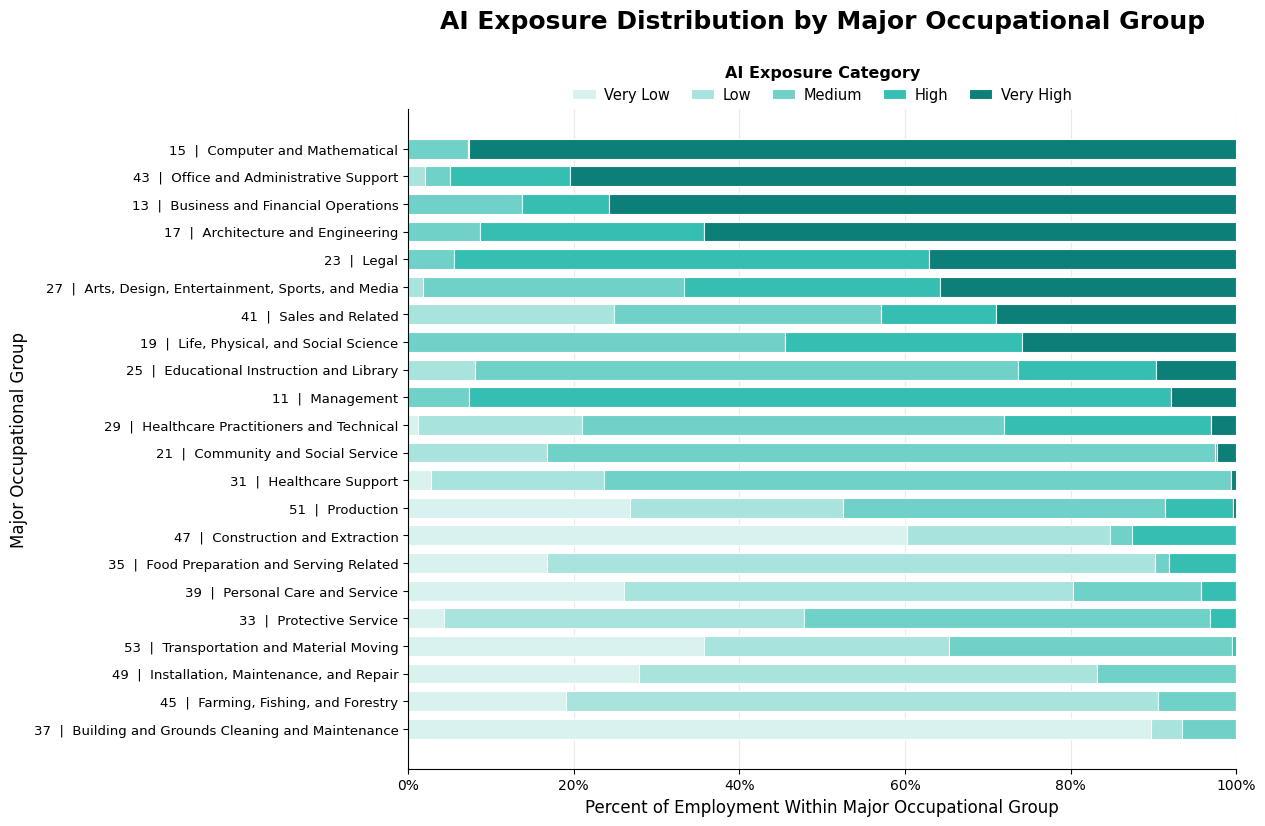


Done.
Figure saved to: G:\.shortcut-targets-by-id\1KKrBsNyhwzbYus9ExtUkUd_3jE4VZ4W6\AI_Analysis\Arielle's Stuff\Report Tables and Figures\AI_Exposure_Distribution_by_SOC2_20260517_2213.png
Data saved to: G:\.shortcut-targets-by-id\1KKrBsNyhwzbYus9ExtUkUd_3jE4VZ4W6\AI_Analysis\Arielle's Stuff\Report Tables and Figures\AI_Exposure_Distribution_by_SOC2_Data_20260517_2213.xlsx


In [58]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# =========================================================
# FILE PATHS
# =========================================================

ai_path = r"G:\.shortcut-targets-by-id\1KKrBsNyhwzbYus9ExtUkUd_3jE4VZ4W6\AI_Analysis\risk_index\ai_exposure_composite_clean.csv"
oews_path = r"C:\Users\301533\Downloads\Arizona OEWS 2024 (13).xlsx"

output_folder = r"G:\.shortcut-targets-by-id\1KKrBsNyhwzbYus9ExtUkUd_3jE4VZ4W6\AI_Analysis\Arielle's Stuff\Report Tables and Figures"
timestamp = datetime.now().strftime("%Y%m%d_%H%M")

figure_path = rf"{output_folder}\AI_Exposure_Distribution_by_SOC2_{timestamp}.png"
data_path = rf"{output_folder}\AI_Exposure_Distribution_by_SOC2_Data_{timestamp}.xlsx"

# =========================================================
# SETTINGS
# =========================================================

EXPOSURE_ORDER = ["Very Low", "Low", "Medium", "High", "Very High"]

EXPOSURE_COLORS = {
    "Very Low": "#D9F2EF",
    "Low": "#A9E3DD",
    "Medium": "#6FD1C7",
    "High": "#35BFB3",
    "Very High": "#0B7F78"
}

SOC2_TITLES = {
    "11": "Management",
    "13": "Business and Financial Operations",
    "15": "Computer and Mathematical",
    "17": "Architecture and Engineering",
    "19": "Life, Physical, and Social Science",
    "21": "Community and Social Service",
    "23": "Legal",
    "25": "Educational Instruction and Library",
    "27": "Arts, Design, Entertainment, Sports, and Media",
    "29": "Healthcare Practitioners and Technical",
    "31": "Healthcare Support",
    "33": "Protective Service",
    "35": "Food Preparation and Serving Related",
    "37": "Building and Grounds Cleaning and Maintenance",
    "39": "Personal Care and Service",
    "41": "Sales and Related",
    "43": "Office and Administrative Support",
    "45": "Farming, Fishing, and Forestry",
    "47": "Construction and Extraction",
    "49": "Installation, Maintenance, and Repair",
    "51": "Production",
    "53": "Transportation and Material Moving"
}

# =========================================================
# HELPER FUNCTIONS
# =========================================================

def fix_soc(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip().replace(".0", "")

    if s.startswith("Nov-"):
        suffix = s.replace("Nov-", "").strip()

        nov_map = {
            "11": "11-2011",
            "21": "11-2021",
            "22": "11-2022",
            "32": "11-2032",
            "33": "11-2033",
            "12": "11-3012",
            "13": "11-3013",
            "31": "11-3031",
            "51": "11-3051",
            "61": "11-3061",
            "71": "11-3071",
            "41": "11-9041",
            "72": "11-9072",
            "81": "11-9081",
            "79": "11-9179",
            "99": "11-9199",
        }

        return nov_map.get(suffix, np.nan)

    return s


def clean_num(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if s in ["-", "", "NA", "N/A", "nan"]:
        return np.nan

    return pd.to_numeric(
        s.replace(",", "").replace("%", "").replace("−", "-"),
        errors="coerce"
    )

# =========================================================
# LOAD AI EXPOSURE FILE
# =========================================================

ai = pd.read_csv(ai_path)
ai.columns = ai.columns.str.strip()

ai["SOC"] = ai["SOC"].apply(fix_soc)
ai["Exposure"] = ai["AI Exposure Category"].astype(str).str.strip()

ai = ai[ai["Exposure"].isin(EXPOSURE_ORDER)].copy()
ai = ai[ai["SOC"].astype(str).str.match(r"^\d{2}-\d{4}$", na=False)].copy()
ai = ai[~ai["SOC"].astype(str).str.endswith("0000")].copy()

ai_lookup = (
    ai[["SOC", "Exposure"]]
    .dropna()
    .drop_duplicates(subset=["SOC"])
    .copy()
)

# =========================================================
# LOAD OEWS EMPLOYMENT
# =========================================================

oews = pd.read_excel(oews_path, sheet_name="Annual", header=1)
oews.columns = oews.columns.str.strip()

oews["SOC"] = oews["SOC Code1"].apply(fix_soc)
oews["Employment"] = oews["Rounded Employment"].apply(clean_num)

oews = oews[["SOC", "Employment"]].copy()
oews = oews[oews["SOC"].astype(str).str.match(r"^\d{2}-\d{4}$", na=False)].copy()
oews = oews[~oews["SOC"].astype(str).str.endswith("0000")].copy()
oews = oews.drop_duplicates(subset=["SOC"])

# =========================================================
# MERGE AND CREATE SOC2
# =========================================================

df = ai_lookup.merge(oews, on="SOC", how="left")

df["SOC2"] = df["SOC"].astype(str).str[:2]
df["SOC2 Title"] = df["SOC2"].map(SOC2_TITLES)

df = df.dropna(subset=["SOC2 Title", "Employment", "Exposure"]).copy()

# =========================================================
# SUM EMPLOYMENT BY SOC2 AND EXPOSURE
# =========================================================

grouped = (
    df.groupby(["SOC2", "SOC2 Title", "Exposure"], observed=False)
    .agg(Employment=("Employment", "sum"))
    .reset_index()
)

wide_counts = grouped.pivot_table(
    index=["SOC2", "SOC2 Title"],
    columns="Exposure",
    values="Employment",
    aggfunc="sum",
    fill_value=0
).reset_index()

for exposure in EXPOSURE_ORDER:
    if exposure not in wide_counts.columns:
        wide_counts[exposure] = 0

wide_counts["Total Employment"] = wide_counts[EXPOSURE_ORDER].sum(axis=1)

plot_data = wide_counts.copy()

for exposure in EXPOSURE_ORDER:
    plot_data[exposure] = plot_data[exposure] / plot_data["Total Employment"]

# Sort primarily by Very High exposure
# then High exposure for cleaner visual flow

# =========================================================
# SORT FOR CLEAN VISUAL FLOW
# VH -> H -> M -> L -> VL
# =========================================================

plot_data = (
    plot_data
    .sort_values(
        by=[
            "Very High",
            "High",
            "Medium",
            "Low",
            "Very Low"
        ],
        ascending=[
            False,
            False,
            False,
            False,
            False
        ]
    )
    .reset_index(drop=True)
)

# Cleaner y-axis labels
# Keep all labels on ONE line

plot_data["SOC2 Label"] = (
    plot_data["SOC2"].astype(str) + "  |  " + plot_data["SOC2 Title"]
)

plot_data["SOC2 Label"] = plot_data["SOC2 Label"].str.replace(
    "\n",
    " ",
    regex=False
)
# =========================================================
# SAVE DATA
# =========================================================

with pd.ExcelWriter(data_path, engine="openpyxl") as writer:
    wide_counts.to_excel(writer, sheet_name="Employment Counts", index=False)
    plot_data.to_excel(writer, sheet_name="Plot Shares", index=False)

# =========================================================
# CREATE STACKED HORIZONTAL BAR CHART
# Updated based on feedback:
# - cleaner SOC labels
# - centered horizontal legend below title
# - better spacing
# - publication formatting
# =========================================================

fig, ax = plt.subplots(figsize=(18, 10))

y = np.arange(len(plot_data))
left = np.zeros(len(plot_data))

for exposure in EXPOSURE_ORDER:

    values = plot_data[exposure].values

    ax.barh(
        y,
        values,
        left=left,
        label=exposure,
        color=EXPOSURE_COLORS[exposure],
        height=0.72,
        edgecolor="white",
        linewidth=0.8
    )

    left += values

# =========================================================
# TITLE
# =========================================================

ax.set_title(
    "AI Exposure Distribution by Major Occupational Group",
    fontsize=18,
    fontweight="bold",
    pad=58
)

# =========================================================
# LEGEND
# =========================================================

legend = ax.legend(
    title="AI Exposure Category",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.075),
    ncol=5,
    frameon=False,
    fontsize=10.5,
    title_fontsize=11.5,
    handlelength=1.6,
    handletextpad=0.6,
    columnspacing=1.4,
    borderaxespad=0
)

legend.get_title().set_fontweight("bold")

# =========================================================
# AXES
# =========================================================

ax.set_yticks(y)

ax.set_yticklabels(
    plot_data["SOC2 Label"],
    fontsize=9.5,
    linespacing=1.35
)

ax.invert_yaxis()

ax.set_xlabel(
    "Percent of Employment Within Major Occupational Group",
    fontsize=12
)

ax.set_ylabel(
    "Major Occupational Group",
    fontsize=12
)

ax.set_xlim(0, 1)

ax.xaxis.set_major_formatter(
    PercentFormatter(xmax=1, decimals=0)
)

# =========================================================
# STYLE
# =========================================================

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="x", alpha=0.25)

ax.set_axisbelow(True)

# =========================================================
# LAYOUT
# =========================================================

plt.subplots_adjust(
    left=0.52,
    right=0.98,
    top=0.76,
    bottom=0.10
)

# =========================================================
# SAVE
# =========================================================

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nDone.")
print("Figure saved to:", figure_path)
print("Data saved to:", data_path)

c:\Users\301533\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipumspy\readers.py:70: CitationWarning: Use of data from IPUMS is subject to conditions including that users should cite the data appropriately.
See the `ipums_conditions` attribute of this codebook for terms of use.
See the `ipums_citation` attribute of this codebook for the appropriate citation.
  warnings.warn(


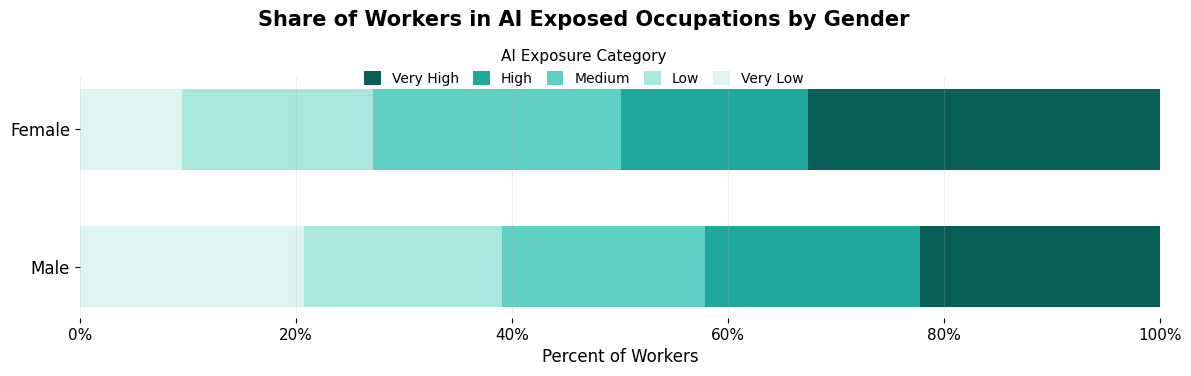

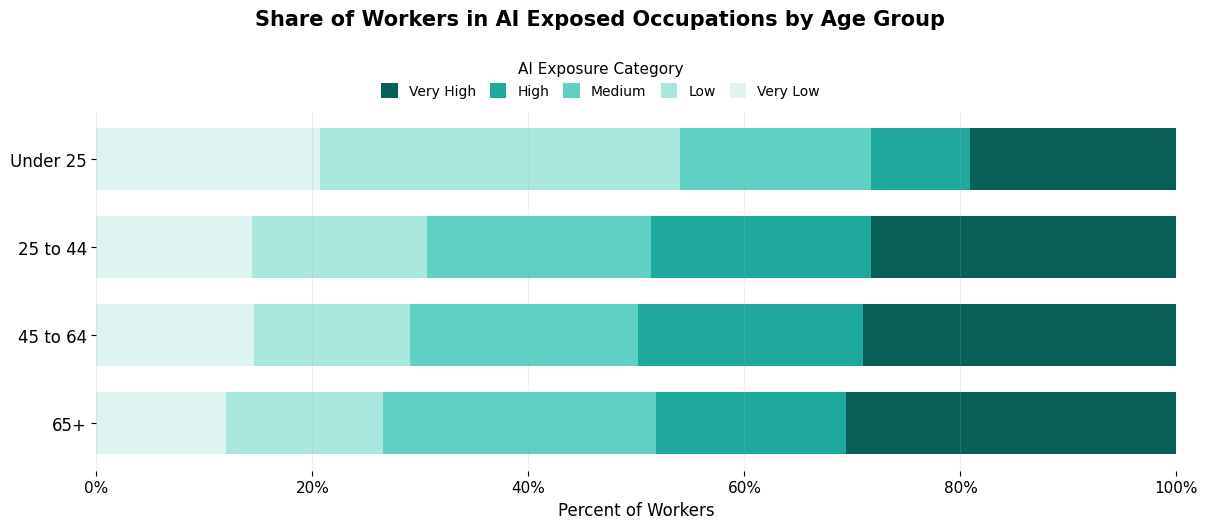

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from ipumspy import readers

# =========================================================
# FILE PATHS
# =========================================================

ddi_path = r"G:\.shortcut-targets-by-id\1KKrBsNyhwzbYus9ExtUkUd_3jE4VZ4W6\AI_Analysis\IPUMS\usa_00004.xml"

acs_path = r"G:\.shortcut-targets-by-id\1KKrBsNyhwzbYus9ExtUkUd_3jE4VZ4W6\AI_Analysis\IPUMS\usa_00004.dat\usa_00004.dat"

ai_path = r"G:\.shortcut-targets-by-id\1KKrBsNyhwzbYus9ExtUkUd_3jE4VZ4W6\AI_Analysis\risk_index\ai_exposure_composite_clean.csv"

# =========================================================
# LOAD ACS / IPUMS DATA
# =========================================================

ddi = readers.read_ipums_ddi(ddi_path)

acs_data = readers.read_microdata(
    ddi,
    acs_path
)

# =========================================================
# LOAD AI EXPOSURE FILE
# =========================================================

ai = pd.read_csv(ai_path)

ai.columns = ai.columns.str.strip()

if "SOC" not in ai.columns:
    soc_col = [
        c for c in ai.columns
        if c.lower() in ["soc", "soc2018", "soc code", "soc2018.1"]
    ][0]
    ai = ai.rename(columns={soc_col: "SOC"})

if "AI Exposure Category" not in ai.columns:
    exposure_col = [
        c for c in ai.columns
        if "exposure" in c.lower()
    ][0]
    ai = ai.rename(columns={exposure_col: "AI Exposure Category"})

# =========================================================
# CLEAN SOC CODES
# =========================================================

acs_data["OCCSOC"] = (
    acs_data["OCCSOC"]
    .astype(str)
    .str.strip()
    .str.replace(r"[^0-9]", "", regex=True)
)

ai["SOC"] = (
    ai["SOC"]
    .astype(str)
    .str.strip()
    .str.replace(r"[^0-9]", "", regex=True)
)

# =========================================================
# MERGE ACS DATA WITH AI EXPOSURE FILE
# =========================================================

merged = acs_data.merge(
    ai[["SOC", "AI Exposure Category", "Occupation Title"]].drop_duplicates(),
    left_on="OCCSOC",
    right_on="SOC",
    how="left"
)

merged = merged.rename(
    columns={"Occupation Title": "Occupation_Title"}
)

title_col = "Occupation_Title"

# =========================================================
# SETTINGS
# =========================================================

stack_order = ["Very Low", "Low", "Medium", "High", "Very High"]
legend_order = ["Very High", "High", "Medium", "Low", "Very Low"]

ai_colors = {
    "Very Low": "#DDF4F1",
    "Low": "#A8E6DE",
    "Medium": "#5FD0C3",
    "High": "#1FA99C",
    "Very High": "#075F57"
}

# =========================================================
# CREATE GENDER AND AGE VARIABLES
# =========================================================

merged["Gender"] = pd.Series(pd.NA, index=merged.index, dtype="object")
merged.loc[merged["SEX"] == 1, "Gender"] = "Male"
merged.loc[merged["SEX"] == 2, "Gender"] = "Female"

merged["Age_Group"] = pd.Series(pd.NA, index=merged.index, dtype="object")
merged.loc[merged["AGE"] < 25, "Age_Group"] = "Under 25"
merged.loc[(merged["AGE"] >= 25) & (merged["AGE"] < 45), "Age_Group"] = "25 to 44"
merged.loc[(merged["AGE"] >= 45) & (merged["AGE"] < 65), "Age_Group"] = "45 to 64"
merged.loc[merged["AGE"] >= 65, "Age_Group"] = "65+"

# =========================================================
# BUILD DISTRIBUTIONS
# =========================================================

gender_dist = (
    merged
    .dropna(subset=["Gender", "AI Exposure Category"])
    .groupby(["Gender", "AI Exposure Category"], as_index=False)["PERWT"]
    .sum()
    .rename(columns={"PERWT": "workers"})
)

gender_dist["pct"] = (
    gender_dist["workers"] /
    gender_dist.groupby("Gender")["workers"].transform("sum")
)

age_dist = (
    merged
    .dropna(subset=["Age_Group", "AI Exposure Category"])
    .groupby(["Age_Group", "AI Exposure Category"], as_index=False)["PERWT"]
    .sum()
    .rename(columns={"PERWT": "workers"})
)

age_dist["pct"] = (
    age_dist["workers"] /
    age_dist.groupby("Age_Group")["workers"].transform("sum")
)

# =========================================================
# SET ORDER FOR DISPLAY
# =========================================================

gender_dist["Gender"] = pd.Categorical(
    gender_dist["Gender"],
    categories=["Female", "Male"],
    ordered=True
)

gender_dist = gender_dist.sort_values("Gender")

age_dist["Age_Group"] = pd.Categorical(
    age_dist["Age_Group"],
    categories=["Under 25", "25 to 44", "45 to 64", "65+"],
    ordered=True
)

age_dist = age_dist.sort_values("Age_Group")

# =========================================================
# FUNCTION TO PLOT STACKED HORIZONTAL BARS
# =========================================================

def plot_ai_distribution(
    df,
    group_col,
    title,
    figsize,
    bar_height=0.45,
    gap=0.75
):

    plot_df = (
        df.pivot(
            index=group_col,
            columns="AI Exposure Category",
            values="pct"
        )
        .fillna(0)
    )

    for col in stack_order:
        if col not in plot_df.columns:
            plot_df[col] = 0

    plot_df = plot_df[stack_order]

    groups = list(plot_df.index)
    y_pos = np.arange(len(groups)) * gap

    fig, ax = plt.subplots(figsize=figsize)

    left = np.zeros(len(plot_df))

    for exposure in stack_order:
        ax.barh(
            y_pos,
            plot_df[exposure].values,
            left=left,
            height=bar_height,
            color=ai_colors[exposure],
            label=exposure
        )
        left += plot_df[exposure].values

    ax.set_yticks(y_pos)
    ax.set_yticklabels(groups)
    ax.invert_yaxis()

    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(PercentFormatter(1))

    ax.set_xlabel("Percent of Workers", fontsize=12)
    ax.set_ylabel("")

    ax.grid(axis="x", alpha=0.22)
    ax.grid(axis="y", visible=False)

    ax.tick_params(axis="x", labelsize=11)
    ax.tick_params(axis="y", labelsize=12)

    for spine in ax.spines.values():
        spine.set_visible(False)

    handles, labels = ax.get_legend_handles_labels()
    order = [labels.index(x) for x in legend_order]

    fig.suptitle(
        title,
        fontsize=15,
        fontweight="bold",
        y=0.97
    )

    fig.legend(
        [handles[i] for i in order],
        [labels[i] for i in order],
        title="AI Exposure Category",
        loc="upper center",
        bbox_to_anchor=(0.5, 0.90),
        ncol=5,
        frameon=False,
        fontsize=10,
        title_fontsize=11,
        handlelength=1.2,
        handleheight=1.2,
        columnspacing=1.0
    )

    plt.subplots_adjust(
        top=0.79,
        bottom=0.16,
        left=0.08,
        right=0.98
    )

    plt.show()

# =========================================================
# GENDER FIGURE
# =========================================================

plot_ai_distribution(
    df=gender_dist,
    group_col="Gender",
    title="Share of Workers in AI Exposed Occupations by Gender",
    figsize=(12, 3.8),
    bar_height=0.34,
    gap=0.58
)

# =========================================================
# AGE FIGURE
# =========================================================

plot_ai_distribution(
    df=age_dist,
    group_col="Age_Group",
    title="Share of Workers in AI Exposed Occupations by Age Group",
    figsize=(12, 5.7),
    bar_height=0.58,
    gap=0.82
)

In [13]:
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime
from ipumspy import readers

# =========================================================
# FILE PATHS
# =========================================================

ddi_path = r"G:\.shortcut-targets-by-id\1KKrBsNyhwzbYus9ExtUkUd_3jE4VZ4W6\AI_Analysis\IPUMS\usa_00004.xml"

acs_path = r"G:\.shortcut-targets-by-id\1KKrBsNyhwzbYus9ExtUkUd_3jE4VZ4W6\AI_Analysis\IPUMS\usa_00004.dat\usa_00004.dat"

ai_path = r"G:\.shortcut-targets-by-id\1KKrBsNyhwzbYus9ExtUkUd_3jE4VZ4W6\AI_Analysis\risk_index\ai_exposure_composite_clean.csv"

OUT_FOLDER = Path(
    r"G:\.shortcut-targets-by-id\1KKrBsNyhwzbYus9ExtUkUd_3jE4VZ4W6\AI_Analysis\Arielle's Stuff"
)

OUT_FOLDER.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M")
output_excel = OUT_FOLDER / f"AI_Exposure_Occupation_Detail_ACS_{timestamp}.xlsx"

# =========================================================
# LOAD ACS / IPUMS DATA
# =========================================================

ddi = readers.read_ipums_ddi(ddi_path)

acs_data = readers.read_microdata(
    ddi,
    acs_path
)

# =========================================================
# LOAD AI EXPOSURE FILE
# =========================================================

ai = pd.read_csv(ai_path)
ai.columns = ai.columns.str.strip()

# =========================================================
# CLEAN SOC CODES
# =========================================================

acs_data["OCCSOC"] = (
    acs_data["OCCSOC"]
    .astype(str)
    .str.strip()
    .str.replace(r"[^0-9]", "", regex=True)
)

ai["SOC"] = (
    ai["SOC"]
    .astype(str)
    .str.strip()
    .str.replace(r"[^0-9]", "", regex=True)
)

# =========================================================
# CREATE CLEAN AI LOOKUP WITH REAL OCCUPATION TITLES
# =========================================================

ai_lookup = (
    ai[["SOC", "Occupation Title", "AI Exposure Category"]]
    .dropna(subset=["SOC", "Occupation Title", "AI Exposure Category"])
    .drop_duplicates(subset=["SOC"])
    .rename(columns={"Occupation Title": "Occupation_Title"})
)

print("AI lookup sample:")
print(ai_lookup.head(10))

# =========================================================
# MERGE ACS DATA WITH AI EXPOSURE FILE
# =========================================================

merged = acs_data.merge(
    ai_lookup,
    left_on="OCCSOC",
    right_on="SOC",
    how="left"
)

print("\nMerged title check:")
print(
    merged[
        ["OCCSOC", "SOC", "Occupation_Title", "AI Exposure Category"]
    ]
    .dropna(subset=["AI Exposure Category"])
    .head(20)
)

# =========================================================
# CREATE GENDER AND AGE VARIABLES
# =========================================================

merged["Gender"] = pd.NA
merged.loc[merged["SEX"] == 1, "Gender"] = "Male"
merged.loc[merged["SEX"] == 2, "Gender"] = "Female"

merged["Age_Group"] = pd.NA
merged.loc[merged["AGE"] < 25, "Age_Group"] = "Under 25"
merged.loc[(merged["AGE"] >= 25) & (merged["AGE"] < 45), "Age_Group"] = "25 to 44"
merged.loc[(merged["AGE"] >= 45) & (merged["AGE"] < 65), "Age_Group"] = "45 to 64"
merged.loc[merged["AGE"] >= 65, "Age_Group"] = "65+"

# =========================================================
# HIGH VS NOT HIGH GROUP
# =========================================================

merged["AI_Group_Binary"] = np.where(
    merged["AI Exposure Category"].isin(["High", "Very High"]),
    "High or Very High",
    "Medium or Below"
)

merged.loc[
    merged["AI Exposure Category"].isna(),
    "AI_Group_Binary"
] = np.nan

# =========================================================
# OCCUPATION DETAIL BY EXPOSURE
# =========================================================

base = merged.dropna(
    subset=["OCCSOC", "Occupation_Title", "AI Exposure Category"]
).copy()

occ_detail = (
    base
    .groupby(
        ["OCCSOC", "Occupation_Title", "AI Exposure Category"],
        as_index=False
    )
    .agg(
        Workers=("PERWT", "sum"),
        Female_Workers=("PERWT", lambda x: x[base.loc[x.index, "Gender"].eq("Female")].sum()),
        Male_Workers=("PERWT", lambda x: x[base.loc[x.index, "Gender"].eq("Male")].sum()),
        Under_25_Workers=("PERWT", lambda x: x[base.loc[x.index, "Age_Group"].eq("Under 25")].sum()),
        Age_25_44_Workers=("PERWT", lambda x: x[base.loc[x.index, "Age_Group"].eq("25 to 44")].sum()),
        Age_45_64_Workers=("PERWT", lambda x: x[base.loc[x.index, "Age_Group"].eq("45 to 64")].sum()),
        Age_65_Plus_Workers=("PERWT", lambda x: x[base.loc[x.index, "Age_Group"].eq("65+")].sum())
    )
)

occ_detail["Female_Share"] = occ_detail["Female_Workers"] / occ_detail["Workers"]
occ_detail["Male_Share"] = occ_detail["Male_Workers"] / occ_detail["Workers"]

occ_detail["Age_45_Plus_Workers"] = (
    occ_detail["Age_45_64_Workers"] +
    occ_detail["Age_65_Plus_Workers"]
)

occ_detail["Age_45_Plus_Share"] = (
    occ_detail["Age_45_Plus_Workers"] /
    occ_detail["Workers"]
)

occ_detail["Exposure_Total_Workers"] = (
    occ_detail
    .groupby("AI Exposure Category")["Workers"]
    .transform("sum")
)

occ_detail["Share_of_Exposure_Group"] = (
    occ_detail["Workers"] /
    occ_detail["Exposure_Total_Workers"]
)

# =========================================================
# HIGH / VERY HIGH DETAIL
# =========================================================

top_high_very_high = (
    occ_detail[
        occ_detail["AI Exposure Category"].isin(["High", "Very High"])
    ]
    .sort_values("Workers", ascending=False)
)

# =========================================================
# HIGH VS NOT HIGH DETAIL
# =========================================================

binary_base = merged.dropna(
    subset=["OCCSOC", "Occupation_Title", "AI_Group_Binary"]
).copy()

occ_binary = (
    binary_base
    .groupby(
        ["OCCSOC", "Occupation_Title", "AI_Group_Binary"],
        as_index=False
    )
    .agg(
        Workers=("PERWT", "sum"),
        Female_Workers=("PERWT", lambda x: x[binary_base.loc[x.index, "Gender"].eq("Female")].sum()),
        Male_Workers=("PERWT", lambda x: x[binary_base.loc[x.index, "Gender"].eq("Male")].sum()),
        Under_25_Workers=("PERWT", lambda x: x[binary_base.loc[x.index, "Age_Group"].eq("Under 25")].sum()),
        Age_25_44_Workers=("PERWT", lambda x: x[binary_base.loc[x.index, "Age_Group"].eq("25 to 44")].sum()),
        Age_45_64_Workers=("PERWT", lambda x: x[binary_base.loc[x.index, "Age_Group"].eq("45 to 64")].sum()),
        Age_65_Plus_Workers=("PERWT", lambda x: x[binary_base.loc[x.index, "Age_Group"].eq("65+")].sum())
    )
)

occ_binary["Female_Share"] = occ_binary["Female_Workers"] / occ_binary["Workers"]

occ_binary["Age_45_Plus_Workers"] = (
    occ_binary["Age_45_64_Workers"] +
    occ_binary["Age_65_Plus_Workers"]
)

occ_binary["Age_45_Plus_Share"] = (
    occ_binary["Age_45_Plus_Workers"] /
    occ_binary["Workers"]
)

occ_binary["Group_Total_Workers"] = (
    occ_binary
    .groupby("AI_Group_Binary")["Workers"]
    .transform("sum")
)

occ_binary["Share_of_AI_Group"] = (
    occ_binary["Workers"] /
    occ_binary["Group_Total_Workers"]
)

# =========================================================
# EXAMPLE TABLES
# =========================================================

MIN_WORKERS = 1000

female_examples = (
    top_high_very_high[
        top_high_very_high["Workers"] >= MIN_WORKERS
    ]
    .sort_values(["Female_Share", "Workers"], ascending=[False, False])
)

older_worker_examples = (
    top_high_very_high[
        top_high_very_high["Workers"] >= MIN_WORKERS
    ]
    .sort_values(["Age_45_Plus_Share", "Workers"], ascending=[False, False])
)

summary_by_exposure = (
    occ_detail
    .groupby("AI Exposure Category", as_index=False)
    .agg(
        Total_Workers=("Workers", "sum"),
        Occupation_Count=("OCCSOC", "nunique"),
        Female_Workers=("Female_Workers", "sum"),
        Male_Workers=("Male_Workers", "sum"),
        Age_45_Plus_Workers=("Age_45_Plus_Workers", "sum")
    )
)

summary_by_exposure["Female_Share"] = (
    summary_by_exposure["Female_Workers"] /
    summary_by_exposure["Total_Workers"]
)

summary_by_exposure["Age_45_Plus_Share"] = (
    summary_by_exposure["Age_45_Plus_Workers"] /
    summary_by_exposure["Total_Workers"]
)

summary_binary = (
    occ_binary
    .groupby("AI_Group_Binary", as_index=False)
    .agg(
        Total_Workers=("Workers", "sum"),
        Occupation_Count=("OCCSOC", "nunique"),
        Female_Workers=("Female_Workers", "sum"),
        Male_Workers=("Male_Workers", "sum"),
        Age_45_Plus_Workers=("Age_45_Plus_Workers", "sum")
    )
)

summary_binary["Female_Share"] = (
    summary_binary["Female_Workers"] /
    summary_binary["Total_Workers"]
)

summary_binary["Age_45_Plus_Share"] = (
    summary_binary["Age_45_Plus_Workers"] /
    summary_binary["Total_Workers"]
)

# =========================================================
# EXPORT
# =========================================================

with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:
    summary_by_exposure.to_excel(writer, sheet_name="Summary by Exposure", index=False)
    summary_binary.to_excel(writer, sheet_name="Summary High vs Not", index=False)
    occ_detail.to_excel(writer, sheet_name="All Occupations by Exposure", index=False)
    top_high_very_high.to_excel(writer, sheet_name="High Very High Detail", index=False)
    occ_binary.to_excel(writer, sheet_name="High vs Not Detail", index=False)
    female_examples.head(50).to_excel(writer, sheet_name="Female Overindexed Examples", index=False)
    older_worker_examples.head(50).to_excel(writer, sheet_name="Older Worker Examples", index=False)

print("\nDONE.")
print("Saved occupation detail file to:")
print(output_excel)

print("\nTop High / Very High occupations by workers:")
print(
    top_high_very_high[
        [
            "OCCSOC",
            "Occupation_Title",
            "AI Exposure Category",
            "Workers",
            "Share_of_Exposure_Group",
            "Female_Share",
            "Age_45_Plus_Share"
        ]
    ].head(20)
)

c:\Users\301533\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipumspy\readers.py:70: CitationWarning: Use of data from IPUMS is subject to conditions including that users should cite the data appropriately.
See the `ipums_conditions` attribute of this codebook for terms of use.
See the `ipums_citation` attribute of this codebook for the appropriate citation.
  warnings.warn(


AI lookup sample:
      SOC                           Occupation_Title AI Exposure Category
0  111011                           Chief Executives                 High
1  111021            General and Operations Managers                 High
2  112011        Advertising and Promotions Managers                 High
3  112021                         Marketing Managers                 High
4  112022                             Sales Managers                 High
5  112032                  Public Relations Managers            Very High
6  112033                       Fundraising Managers            Very High
7  113012           Administrative Services Managers               Medium
8  113013                        Facilities Managers               Medium
9  113021  Computer and Information Systems Managers            Very High

Merged title check:
    OCCSOC     SOC                                   Occupation_Title  \
0   516011  516011                   Laundry and Dry-Cleaning Workers   
3

In [14]:
female_examples[
    [
        "Occupation_Title",
        "AI Exposure Category",
        "Workers",
        "Female_Share",
        "Share_of_Exposure_Group"
    ]
].head(25)

,Occupation_Title,AI Exposure Category,Workers,Female_Share,Share_of_Exposure_Group
136,Speech-Language Pathologists,High,258220.0,0.963287,0.010569
258,Legal Secretaries and Administrative Assistants,Very High,67725.0,0.958952,0.001881
257,Executive Secretaries and Executive Administra...,Very High,318890.0,0.932761,0.008855
260,"Secretaries and Administrative Assistants, Exc...",Very High,2614563.0,0.929705,0.072599
259,Medical Secretaries and Administrative Assistants,Very High,121558.0,0.926767,0.003375
126,Dietitians and Nutritionists,Very High,133379.0,0.906949,0.003704
156,Medical Records Specialists,Very High,225956.0,0.902277,0.006274
244,Receptionists and Information Clerks,Very High,1675354.0,0.888463,0.046520
262,Word Processors and Typists,Very High,39173.0,0.881372,0.001088
140,Audiologists,High,24388.0,0.872929,0.000998


In [17]:
# =========================================================
# EXPORT TOP HIGH / VERY HIGH OCCUPATIONS BY AGE GROUP
# =========================================================

age_output = OUT_FOLDER / f"Top_High_VeryHigh_Occupations_By_Age_Group_{timestamp}.xlsx"

with pd.ExcelWriter(age_output, engine="openpyxl") as writer:

    # All high/very high occupations by age group
    high_age_occ.sort_values(
        ["Age_Group", "Share_of_Age_Group"],
        ascending=[True, False]
    ).to_excel(
        writer,
        sheet_name="All Age Groups",
        index=False
    )

    # Separate tab for each age group
    for age in ["Under 25", "25 to 44", "45 to 64", "65+"]:
        temp = (
            high_age_occ[
                high_age_occ["Age_Group"] == age
            ]
            .sort_values(
                "Share_of_Age_Group",
                ascending=False
            )
        )

        sheet_name = age.replace("+", "plus").replace(" ", "_")[:31]

        temp.to_excel(
            writer,
            sheet_name=sheet_name,
            index=False
        )

print("Saved age occupation detail to:")
print(age_output)

Saved age occupation detail to:
G:\.shortcut-targets-by-id\1KKrBsNyhwzbYus9ExtUkUd_3jE4VZ4W6\AI_Analysis\Arielle's Stuff\Top_High_VeryHigh_Occupations_By_Age_Group_20260524_1832.xlsx


In [15]:
top_high_very_high[
    [
        "Occupation_Title",
        "AI Exposure Category",
        "Workers",
        "Female_Share"
    ]
].sort_values(
    ["Female_Share", "Workers"],
    ascending=[False, False]
).head(40)

,Occupation_Title,AI Exposure Category,Workers,Female_Share
136,Speech-Language Pathologists,High,258220.0,0.963287
258,Legal Secretaries and Administrative Assistants,Very High,67725.0,0.958952
257,Executive Secretaries and Executive Administra...,Very High,318890.0,0.932761
260,"Secretaries and Administrative Assistants, Exc...",Very High,2614563.0,0.929705
259,Medical Secretaries and Administrative Assistants,Very High,121558.0,0.926767
126,Dietitians and Nutritionists,Very High,133379.0,0.906949
156,Medical Records Specialists,Very High,225956.0,0.902277
244,Receptionists and Information Clerks,Very High,1675354.0,0.888463
262,Word Processors and Typists,Very High,39173.0,0.881372
140,Audiologists,High,24388.0,0.872929


# Sankey Plot

In [53]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from pathlib import Path
import json
import webbrowser

# ============================================================
# PATHS
# ============================================================

INPUT_FILE = Path(
    r"C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO\FINAL_VeryHigh_AI_Lightcast_ONET_Transitions_WITH_GATEWAYS.xlsx"
)

AI_COMPOSITE_FILE = Path(
    r"G:\.shortcut-targets-by-id\1KKrBsNyhwzbYus9ExtUkUd_3jE4VZ4W6\AI_Analysis\risk_index\ai_exposure_composite_clean.csv"
)

OEWS_FILE = Path(
    r"C:\Users\301533\Downloads\Arizona OEWS 2024 (13).xlsx"
)

OUT_HTML = Path(
    r"C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO\AI_Transition_Pathways_Clean_Dropdown.html"
)

# ============================================================
# SETTINGS
# ============================================================

LOWER_EXPOSURE_GROUPS = ["Very Low", "Low", "Medium"]

MAX_DIRECT_OCCS = 8
MAX_BRIDGE_OCCS = 3
MAX_DEST_PER_BRIDGE = 4

DARK = "#243B5A"
SOURCE_COLOR = "#075877"
DIRECT_COLOR = "#075877"
BRIDGE_COLOR = "#F79732"
WAGE_COLOR = "#B8B8B8"

EXPOSURE_COLORS = {
    "Very Low": "#17C3B2",
    "Low": "#8ED3F5",
    "Medium": "#75618C"
}

# ============================================================
# HELPERS
# ============================================================

def clean_soc(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip().replace(".0", "")

    if s.startswith("Nov-"):
        nov_map = {
            "11": "11-2011", "21": "11-2021", "22": "11-2022",
            "32": "11-2032", "33": "11-2033", "12": "11-3012",
            "13": "11-3013", "31": "11-3031", "51": "11-3051",
            "61": "11-3061", "71": "11-3071", "41": "11-9041",
            "72": "11-9072", "81": "11-9081", "79": "11-9179",
            "99": "11-9199",
        }
        return nov_map.get(s.replace("Nov-", "").strip(), np.nan)

    return s


def clean_money(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s in ["", "-", "NA", "N/A", "nan"]:
        return np.nan
    return pd.to_numeric(s.replace("$", "").replace(",", ""), errors="coerce")


def clean_num(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s in ["", "-", "NA", "N/A", "nan"]:
        return np.nan
    return pd.to_numeric(
        s.replace(",", "").replace("%", "").replace("−", "-"),
        errors="coerce"
    )


def clean_percent_to_decimal(x):
    if pd.isna(x):
        return np.nan

    raw = str(x).strip()
    val = clean_num(x)

    if pd.isna(val):
        return np.nan

    if "%" in raw:
        return val / 100

    if abs(val) <= 1:
        return val

    return val / 100


def find_col(df, possible_names):
    lookup = {c.lower().strip(): c for c in df.columns}
    for name in possible_names:
        key = name.lower().strip()
        if key in lookup:
            return lookup[key]
    return None


def fmt_currency(x):
    if pd.isna(x):
        return "NA"
    return f"${x:,.0f}"


def fmt_num(x):
    if pd.isna(x):
        return "NA"
    return f"{x:,.0f}"


def fmt_percent(x):
    if pd.isna(x):
        return "NA"
    return f"{x:.1%}"


def fmt_score(x):
    if pd.isna(x):
        return "NA"
    return f"{x:.2f}"


def short(label, n=46):
    label = str(label)
    return label if len(label) <= n else label[:n - 3] + "..."


def hex_to_rgba(hex_color, alpha):
    hex_color = hex_color.lstrip("#")
    r, g, b = tuple(int(hex_color[i:i + 2], 16) for i in (0, 2, 4))
    return f"rgba({r},{g},{b},{alpha})"


def make_positions(n, top=0.16, bottom=0.84):
    if n <= 1:
        return [0.50]
    return list(np.linspace(top, bottom, n))


def wage_bucket(target_wage, source_wage):
    if pd.isna(target_wage) or pd.isna(source_wage):
        return "Wage unknown"

    diff = target_wage - source_wage

    if diff >= 2500:
        return "Higher wage"
    elif diff <= -2500:
        return "Lower wage"
    else:
        return "Similar wage"


# ============================================================
# LOAD DATA
# ============================================================

final = pd.read_excel(INPUT_FILE, sheet_name="Final_Transitions")
gateway = pd.read_excel(INPUT_FILE, sheet_name="Gateway_Pathways")

final.columns = final.columns.astype(str).str.strip()
gateway.columns = gateway.columns.astype(str).str.strip()

for col in ["Source_SOC", "Target_SOC"]:
    final[col] = final[col].apply(clean_soc)

for col in ["Original_Source_SOC", "Gateway_SOC", "Destination_SOC"]:
    gateway[col] = gateway[col].apply(clean_soc)

ai = pd.read_csv(AI_COMPOSITE_FILE)
ai.columns = ai.columns.str.strip()

ai["SOC"] = ai["SOC"].apply(clean_soc)
ai["Exposure"] = ai["AI Exposure Category"].astype(str).str.strip()
ai["Median_Wage_Composite"] = ai["50th Percentile Wage"].apply(clean_money)

if "Annual Percent Change" in ai.columns:
    ai["Growth"] = ai["Annual Percent Change"].apply(clean_percent_to_decimal)
elif "Growth Rate" in ai.columns:
    ai["Growth"] = ai["Growth Rate"].apply(clean_percent_to_decimal)
else:
    ai["Growth"] = np.nan

if "Annual Total Openings" in ai.columns:
    ai["Openings"] = ai["Annual Total Openings"].apply(clean_num)
else:
    ai["Openings"] = np.nan

employment_col = find_col(ai, ["Rounded Employment", "Employment", "Jobs_2025", "Jobs 2025"])

if employment_col:
    ai["Employment_Composite"] = ai[employment_col].apply(clean_num)
else:
    ai["Employment_Composite"] = np.nan

econ = (
    ai[[
        "SOC",
        "Occupation Title",
        "Exposure",
        "Median_Wage_Composite",
        "Employment_Composite",
        "Openings",
        "Growth"
    ]]
    .dropna(subset=["SOC"])
    .drop_duplicates(subset=["SOC"])
    .copy()
)

if OEWS_FILE.exists():
    oews = pd.read_excel(OEWS_FILE, sheet_name="Annual", header=1)
    oews.columns = oews.columns.str.strip()

    oews["SOC"] = oews["SOC Code1"].apply(clean_soc)
    oews["Median_Wage_OEWS"] = oews["50th Percentile Wage"].apply(clean_money)
    oews["Employment_OEWS"] = oews["Rounded Employment"].apply(clean_num)

    oews = (
        oews[["SOC", "Median_Wage_OEWS", "Employment_OEWS"]]
        .dropna(subset=["SOC"])
        .drop_duplicates(subset=["SOC"])
    )

    econ = econ.merge(oews, on="SOC", how="left")
else:
    econ["Median_Wage_OEWS"] = np.nan
    econ["Employment_OEWS"] = np.nan

econ["Median_Wage"] = econ["Median_Wage_OEWS"].combine_first(econ["Median_Wage_Composite"])
econ["Employment"] = econ["Employment_OEWS"].combine_first(econ["Employment_Composite"])

econ_lookup = econ.set_index("SOC").to_dict("index")


def econ_value(soc, field):
    return econ_lookup.get(str(soc), {}).get(field, np.nan)


def hover_text(title, soc, exposure=None, score=None, wage_group=None, pathway=None, bridge=None):
    e = econ_lookup.get(str(soc), {})

    return (
        f"<b>{title}</b>"
        f"<br>SOC: {soc}"
        f"{f'<br>Pathway: {pathway}' if pathway else ''}"
        f"{f'<br>Bridge occupation: {bridge}' if bridge else ''}"
        f"{f'<br>AI exposure: {exposure}' if exposure else ''}"
        f"{f'<br>Compatibility score: {fmt_score(score)}' if score is not None else ''}"
        f"{f'<br>Wage group: {wage_group}' if wage_group else ''}"
        f"<br><br><b>Labor market information</b>"
        f"<br>Median wage: {fmt_currency(e.get('Median_Wage'))}"
        f"<br>Employment: {fmt_num(e.get('Employment'))}"
        f"<br>Openings: {fmt_num(e.get('Openings'))}"
        f"<br>Growth: {fmt_percent(e.get('Growth'))}"
    )


# ============================================================
# BUILD SOURCE OPTIONS
# ============================================================

source_options = (
    final[
        (final["Source_AI_Exposure_Group"] == "Very High") &
        (final["Source_SOC"].notna())
    ][["Source_SOC", "Source_Occupation"]]
    .drop_duplicates()
    .sort_values("Source_Occupation")
    .copy()
)

# ============================================================
# BUILD EDGE DATA
# ============================================================

def build_edges_for_source(source_soc):
    source_title = (
        final.loc[final["Source_SOC"].astype(str) == source_soc, "Source_Occupation"]
        .dropna()
        .iloc[0]
    )

    source_wage = econ_value(source_soc, "Median_Wage")
    all_rows = []

    # Direct related occupations
    direct = final[
        (final["Source_SOC"].astype(str) == source_soc) &
        (final["Source_AI_Exposure_Group"] == "Very High") &
        (final["Target_AI_Exposure_Group"].isin(LOWER_EXPOSURE_GROUPS))
    ].copy()

    if not direct.empty:
        direct["Score"] = pd.to_numeric(direct["Final_Compat_Index"], errors="coerce")
        direct["Wage"] = direct["Target_SOC"].map(lambda s: econ_value(s, "Median_Wage"))
        direct["Growth"] = direct["Target_SOC"].map(lambda s: econ_value(s, "Growth"))
        direct["Employment"] = direct["Target_SOC"].map(lambda s: econ_value(s, "Employment"))

        direct = (
            direct
            .drop_duplicates(subset=["Target_SOC"])
            .sort_values(["Score", "Wage", "Growth", "Employment"], ascending=[False, False, False, False])
            .head(MAX_DIRECT_OCCS)
        )

        for _, row in direct.iterrows():
            dest_soc = str(row["Target_SOC"])
            dest_wage = econ_value(dest_soc, "Median_Wage")

            all_rows.append({
                "Source_SOC": source_soc,
                "Source_Occupation": source_title,
                "Pathway_View": "direct",
                "Pathway_Label": "Direct related",
                "Pathway_Color": DIRECT_COLOR,
                "Bridge_Occupation": "",
                "Destination_SOC": dest_soc,
                "Destination_Occupation": row["Target_Occupation"],
                "Destination_AI_Exposure_Group": row["Target_AI_Exposure_Group"],
                "Score": row["Score"],
                "Wage_Group": wage_bucket(dest_wage, source_wage)
            })

    # Bridge occupations
    gw = gateway[
        (gateway["Original_Source_SOC"].astype(str) == source_soc) &
        (gateway["Gateway_AI_Exposure_Group"].isin(LOWER_EXPOSURE_GROUPS)) &
        (gateway["Destination_AI_Exposure_Group"].isin(LOWER_EXPOSURE_GROUPS))
    ].copy()

    if not gw.empty:
        gw["Gateway_Compat_Index"] = pd.to_numeric(gw["Gateway_Compat_Index"], errors="coerce")
        gw["Gateway_Jobs_2025"] = pd.to_numeric(gw["Gateway_Jobs_2025"], errors="coerce")
        gw["Destination_ONET_Index"] = pd.to_numeric(gw["Destination_ONET_Index"], errors="coerce")

        gw["Gateway_Wage"] = gw["Gateway_SOC"].map(lambda s: econ_value(s, "Median_Wage"))
        gw["Gateway_Growth"] = gw["Gateway_SOC"].map(lambda s: econ_value(s, "Growth"))
        gw["Gateway_Employment"] = gw["Gateway_SOC"].map(lambda s: econ_value(s, "Employment"))

        bridges = (
            gw[[
                "Gateway_SOC",
                "Gateway_Occupation",
                "Gateway_Compat_Index",
                "Gateway_Jobs_2025",
                "Gateway_Wage",
                "Gateway_Growth",
                "Gateway_Employment"
            ]]
            .drop_duplicates(subset=["Gateway_SOC"])
            .sort_values(
                ["Gateway_Compat_Index", "Gateway_Wage", "Gateway_Growth", "Gateway_Employment"],
                ascending=[False, False, False, False]
            )
            .head(MAX_BRIDGE_OCCS)
        )

        for _, bridge in bridges.iterrows():
            bridge_soc = str(bridge["Gateway_SOC"])

            dests = gw[gw["Gateway_SOC"].astype(str) == bridge_soc].copy()

            dests["Destination_Wage"] = dests["Destination_SOC"].map(lambda s: econ_value(s, "Median_Wage"))
            dests["Destination_Growth"] = dests["Destination_SOC"].map(lambda s: econ_value(s, "Growth"))
            dests["Destination_Employment"] = dests["Destination_SOC"].map(lambda s: econ_value(s, "Employment"))

            dests = (
                dests
                .drop_duplicates(subset=["Destination_SOC"])
                .sort_values(
                    ["Destination_ONET_Index", "Destination_Wage", "Destination_Growth", "Destination_Employment"],
                    ascending=[True, False, False, False]
                )
                .head(MAX_DEST_PER_BRIDGE)
            )

            for _, dest in dests.iterrows():
                dest_soc = str(dest["Destination_SOC"])
                dest_wage = econ_value(dest_soc, "Median_Wage")

                all_rows.append({
                    "Source_SOC": source_soc,
                    "Source_Occupation": source_title,
                    "Pathway_View": "bridge",
                    "Pathway_Label": "Bridge occupation",
                    "Pathway_Color": BRIDGE_COLOR,
                    "Bridge_Occupation": bridge["Gateway_Occupation"],
                    "Destination_SOC": dest_soc,
                    "Destination_Occupation": dest["Destination_Occupation"],
                    "Destination_AI_Exposure_Group": dest["Destination_AI_Exposure_Group"],
                    "Score": bridge["Gateway_Compat_Index"],
                    "Wage_Group": wage_bucket(dest_wage, source_wage)
                })

    return pd.DataFrame(all_rows)


# ============================================================
# MAKE SANKEY
# ============================================================

def make_sankey(edges, source_soc, source_title, mode):
    if mode == "direct":
        edges = edges[edges["Pathway_View"] == "direct"].copy()
        title_prefix = "Direct related occupation pathways"
        subtitle = "Directly related lower-exposure occupations, grouped by wage comparison."
    elif mode == "bridge":
        edges = edges[edges["Pathway_View"] == "bridge"].copy()
        title_prefix = "Bridge occupation pathways"
        subtitle = "Bridge occupations show stepping-stone routes into lower-exposure destination occupations."
    else:
        edges = edges.copy()
        title_prefix = "Direct and bridge occupation pathways"
        subtitle = "Direct related and bridge occupation pathways, grouped by wage comparison."

    if edges.empty:
        return None

    source_wage = econ_value(source_soc, "Median_Wage")

    wage_order = ["Higher wage", "Similar wage", "Lower wage", "Wage unknown"]
    exposure_order = {"Very Low": 1, "Low": 2, "Medium": 3}

    path_nodes = (
        edges[["Pathway_Label", "Pathway_Color"]]
        .drop_duplicates()
        .copy()
    )

    wages = edges[["Wage_Group"]].drop_duplicates().copy()
    wages["Order"] = wages["Wage_Group"].map({v: i for i, v in enumerate(wage_order)})
    wages = wages.sort_values("Order")

    destinations = (
        edges[["Destination_SOC", "Destination_Occupation", "Destination_AI_Exposure_Group", "Wage_Group"]]
        .drop_duplicates(subset=["Destination_SOC"])
        .copy()
    )
    destinations["Exposure_Order"] = destinations["Destination_AI_Exposure_Group"].map(exposure_order)
    destinations = destinations.sort_values(["Exposure_Order", "Destination_Occupation"])

    node_labels, node_colors, node_x, node_y, node_hover = [], [], [], [], []
    node_lookup = {}

    def add_node(key, label, color, x, y, hover):
        if key not in node_lookup:
            node_lookup[key] = len(node_labels)
            node_labels.append(label)
            node_colors.append(color)
            node_x.append(x)
            node_y.append(y)
            node_hover.append(hover)
        return node_lookup[key]

    origin_id = add_node(
        "source",
        short(source_title, 34),
        SOURCE_COLOR,
        0.05,
        0.52,
        hover_text(source_title, source_soc, exposure="Very High")
    )

    path_ys = make_positions(len(path_nodes), top=0.36, bottom=0.66)

    for i, (_, row) in enumerate(path_nodes.iterrows()):
        add_node(
            f"path_{row.Pathway_Label}",
            row.Pathway_Label,
            row.Pathway_Color,
            0.30,
            float(path_ys[i]),
            f"<b>{row.Pathway_Label}</b>"
        )

    wage_ys = make_positions(len(wages), top=0.28, bottom=0.74)

    for i, (_, row) in enumerate(wages.iterrows()):
        add_node(
            f"wage_{row.Wage_Group}",
            row.Wage_Group,
            WAGE_COLOR,
            0.55,
            float(wage_ys[i]),
            f"<b>{row.Wage_Group}</b><br>Compared to source wage: {fmt_currency(source_wage)}"
        )

    dest_ys = make_positions(len(destinations), top=0.12, bottom=0.90)
    dest_y_lookup = dict(zip(destinations["Destination_SOC"].astype(str), dest_ys))

    for _, row in destinations.iterrows():
        exposure = row["Destination_AI_Exposure_Group"]

        add_node(
            f"dest_{row.Destination_SOC}",
            short(row.Destination_Occupation, 44),
            EXPOSURE_COLORS.get(exposure, "#999999"),
            0.82,
            float(dest_y_lookup[str(row.Destination_SOC)]),
            hover_text(
                row.Destination_Occupation,
                row.Destination_SOC,
                exposure=exposure,
                wage_group=row.Wage_Group
            )
        )

    sources, targets, values, colors, hovers = [], [], [], [], []

    grouped_path = (
        edges.groupby(["Pathway_Label", "Pathway_Color"], as_index=False)
        .agg(Value=("Destination_SOC", "nunique"))
    )

    for _, row in grouped_path.iterrows():
        sources.append(origin_id)
        targets.append(node_lookup[f"path_{row.Pathway_Label}"])
        values.append(row["Value"])
        colors.append(hex_to_rgba(row.Pathway_Color, 0.42))
        hovers.append(f"<b>{source_title}</b> → <b>{row.Pathway_Label}</b>")

    grouped_wage = (
        edges.groupby(["Pathway_Label", "Wage_Group"], as_index=False)
        .agg(Value=("Destination_SOC", "nunique"))
    )

    for _, row in grouped_wage.iterrows():
        subset = edges[
            (edges["Pathway_Label"] == row["Pathway_Label"]) &
            (edges["Wage_Group"] == row["Wage_Group"])
        ]
        first_exposure = subset["Destination_AI_Exposure_Group"].iloc[0]
        path_color = EXPOSURE_COLORS.get(first_exposure, "#999999")

        sources.append(node_lookup[f"path_{row.Pathway_Label}"])
        targets.append(node_lookup[f"wage_{row.Wage_Group}"])
        values.append(row["Value"])
        colors.append(hex_to_rgba(path_color, 0.34))
        hovers.append(
            f"<b>{row.Pathway_Label}</b> → <b>{row.Wage_Group}</b><br>"
            f"Destination occupations: {row['Value']}"
        )

    for _, row in edges.iterrows():
        path_color = EXPOSURE_COLORS.get(row["Destination_AI_Exposure_Group"], "#999999")

        sources.append(node_lookup[f"wage_{row.Wage_Group}"])
        targets.append(node_lookup[f"dest_{row.Destination_SOC}"])
        values.append(1)
        colors.append(hex_to_rgba(path_color, 0.52))
        hovers.append(
            hover_text(
                row.Destination_Occupation,
                row.Destination_SOC,
                exposure=row.Destination_AI_Exposure_Group,
                score=row.Score,
                wage_group=row.Wage_Group,
                pathway=row.Pathway_Label,
                bridge=row.Bridge_Occupation if row.Pathway_View == "bridge" else None
            )
        )

    fig = go.Figure(data=[go.Sankey(
        arrangement="fixed",
        node=dict(
            pad=24,
            thickness=13,
            line=dict(color="white", width=1.3),
            label=node_labels,
            color=node_colors,
            x=node_x,
            y=node_y,
            customdata=node_hover,
            hovertemplate="%{customdata}<extra></extra>"
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=colors,
            customdata=hovers,
            hovertemplate="%{customdata}<extra></extra>"
        )
    )])

    annotations = [
        dict(
            x=0.04, y=1.12, xref="paper", yref="paper",
            showarrow=False, align="left",
            text=f"<b>{title_prefix} for {source_title}</b>",
            font=dict(size=23, color=DARK)
        ),
        dict(
            x=0.04, y=1.075, xref="paper", yref="paper",
            showarrow=False, align="left",
            text=subtitle,
            font=dict(size=14, color=DARK)
        ),
        dict(
            x=0.05, y=1.01, xref="paper", yref="paper",
            showarrow=False, text="<b>Very High occupation</b>",
            font=dict(size=12, color=DARK)
        ),
        dict(
            x=0.30, y=1.01, xref="paper", yref="paper",
            showarrow=False, text="<b>Pathway type</b>",
            font=dict(size=12, color=DARK)
        ),
        dict(
            x=0.55, y=1.01, xref="paper", yref="paper",
            showarrow=False, text="<b>Wage comparison</b>",
            font=dict(size=12, color=DARK)
        ),
        dict(
            x=0.82, y=1.01, xref="paper", yref="paper",
            showarrow=False, text="<b>Lower-exposure occupations</b>",
            font=dict(size=12, color=DARK)
        ),
        dict(
            x=0.04, y=-0.09, xref="paper", yref="paper",
            showarrow=False, align="left",
            text="<b>Legend:</b> pathway color = destination AI exposure &nbsp;&nbsp; "
                 "<span style='color:#17C3B2'>■ Very Low</span> &nbsp; "
                 "<span style='color:#8ED3F5'>■ Low</span> &nbsp; "
                 "<span style='color:#75618C'>■ Medium</span>",
            font=dict(size=12, color=DARK)
        ),
        dict(
            x=0.04, y=-0.14, xref="paper", yref="paper",
            showarrow=False, align="left",
            text="Note: Labor market details appear on hover. Wage comparison is based on the destination occupation’s median wage compared to the selected source occupation.",
            font=dict(size=11.5, color="#555555")
        )
    ]

    fig.update_layout(
        annotations=annotations,
        width=1300,
        height=780,
        font=dict(size=11, color=DARK, family="Arial"),
        paper_bgcolor="white",
        plot_bgcolor="white",
        margin=dict(l=35, r=35, t=160, b=100)
    )

    return fig


# ============================================================
# BUILD FIGURES FOR ALL SOURCES
# ============================================================

figure_store = {}

for _, src in source_options.iterrows():
    source_soc = str(src["Source_SOC"])
    source_title = src["Source_Occupation"]

    edges = build_edges_for_source(source_soc)

    if edges.empty:
        continue

    figure_store[source_soc] = {
        "title": source_title,
        "both": None,
        "direct": None,
        "bridge": None
    }

    for mode in ["both", "direct", "bridge"]:
        fig = make_sankey(edges, source_soc, source_title, mode)
        if fig is not None:
            figure_store[source_soc][mode] = fig.to_plotly_json()

figure_store = {
    soc: item for soc, item in figure_store.items()
    if item["both"] is not None or item["direct"] is not None or item["bridge"] is not None
}

if not figure_store:
    raise ValueError("No Sankey figures were created.")

default_soc = list(figure_store.keys())[0]

# ============================================================
# WRITE HTML
# ============================================================

html = f"""
<!DOCTYPE html>
<html>
<head>
    <meta charset="utf-8">
    <title>AI Transition Pathways</title>
    <script src="https://cdn.plot.ly/plotly-2.30.0.min.js"></script>

    <style>
        body {{
            font-family: Arial, sans-serif;
            margin: 22px;
            color: #333333;
            background: white;
        }}

        .controls {{
            display: flex;
            gap: 14px;
            align-items: flex-end;
            margin-bottom: 10px;
            flex-wrap: wrap;
        }}

        label {{
            font-weight: bold;
            font-size: 14px;
        }}

        input, select {{
            padding: 8px 10px;
            font-size: 14px;
            border: 1px solid #cccccc;
            border-radius: 6px;
            min-width: 260px;
            background: white;
        }}

        #occupationSelect {{
            min-width: 560px;
        }}

        #viewSelect {{
            min-width: 280px;
        }}

        .note {{
            font-size: 13px;
            color: #555555;
            margin-bottom: 8px;
        }}

        #chart {{
            width: 100%;
            min-height: 780px;
        }}
    </style>
</head>

<body>

<div class="controls">
    <div>
        <label for="searchBox">Search Very High AI occupation:</label><br>
        <input id="searchBox" type="text" placeholder="Search occupation or SOC..." oninput="filterOccupations()">
    </div>

    <div>
        <label for="occupationSelect">Occupation:</label><br>
        <select id="occupationSelect" onchange="renderFigure()"></select>
    </div>

    <div>
        <label for="viewSelect">Pathway view:</label><br>
        <select id="viewSelect" onchange="renderFigure()">
            <option value="both">Both direct and bridge</option>
            <option value="direct">Direct related only</option>
            <option value="bridge">Bridge occupations only</option>
        </select>
    </div>
</div>

<div class="note">
    This Sankey summarizes lower-exposure transition options by pathway type and wage comparison. Hover over final occupations for labor market details.
</div>

<div id="chart"></div>

<script>
const figures = {json.dumps(figure_store)};

const allOccupations = Object.entries(figures).map(([soc, item]) => {{
    return {{
        soc: soc,
        title: item.title,
        label: item.title + " (" + soc + ")"
    }};
}});

function populateDropdown(options) {{
    const select = document.getElementById("occupationSelect");
    const current = select.value;

    select.innerHTML = "";

    options.forEach(item => {{
        const opt = document.createElement("option");
        opt.value = item.soc;
        opt.textContent = item.label;
        select.appendChild(opt);
    }});

    if (options.some(item => item.soc === current)) {{
        select.value = current;
    }} else if (options.length > 0) {{
        select.value = options[0].soc;
    }}
}}

function filterOccupations() {{
    const q = document.getElementById("searchBox").value.toLowerCase();

    const filtered = allOccupations.filter(item =>
        item.title.toLowerCase().includes(q) ||
        item.soc.toLowerCase().includes(q)
    );

    populateDropdown(filtered.length ? filtered : allOccupations);
    renderFigure();
}}

function renderFigure() {{
    const soc = document.getElementById("occupationSelect").value;
    let view = document.getElementById("viewSelect").value;

    const item = figures[soc];

    if (!item) return;

    if (!item[view]) {{
        if (item.both) view = "both";
        else if (item.direct) view = "direct";
        else view = "bridge";

        document.getElementById("viewSelect").value = view;
    }}

    const fig = item[view];

    Plotly.react(
        "chart",
        fig.data,
        fig.layout,
        {{
            responsive: true,
            displayModeBar: true
        }}
    );
}}

populateDropdown(allOccupations);
document.getElementById("occupationSelect").value = "{default_soc}";
renderFigure();
</script>

</body>
</html>
"""

OUT_HTML.write_text(html, encoding="utf-8")

print("Saved Sankey to:", OUT_HTML)
print("Very High AI occupations included:", len(figure_store))

webbrowser.open(OUT_HTML.resolve().as_uri())

Saved Sankey to: C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO\AI_Transition_Pathways_Clean_Dropdown.html
Very High AI occupations included: 117


True

In [9]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from pathlib import Path
import json
import webbrowser

# ============================================================
# PATHS
# ============================================================

INPUT_FILE = Path(
    r"C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO\FINAL_VeryHigh_AI_Lightcast_ONET_Transitions_WITH_GATEWAYS.xlsx"
)

AI_COMPOSITE_FILE = Path(
    r"G:\.shortcut-targets-by-id\1KKrBsNyhwzbYus9ExtUkUd_3jE4VZ4W6\AI_Analysis\risk_index\ai_exposure_composite_clean.csv"
)

OEWS_FILE = Path(
    r"C:\Users\301533\Downloads\Arizona OEWS 2024 (13).xlsx"
)

OUT_HTML = Path(
    r"C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO\AI_Transition_Pathways_Clean_Dropdown.html"
)

# ============================================================
# SETTINGS
# ============================================================

LOWER_EXPOSURE_GROUPS = ["Very Low", "Low", "Medium"]

MAX_DIRECT_OCCS = 15
MAX_BRIDGE_OCCS = 6
MAX_BRIDGE_OCCS_IF_FEW_DIRECT = 8
DIRECT_COUNT_THRESHOLD = 8
MAX_DEST_PER_BRIDGE = 5

DARK = "#243B5A"
SOURCE_COLOR = "#075877"
DIRECT_COLOR = "#075877"
BRIDGE_COLOR = "#F79732"
WAGE_COLOR = "#B8B8B8"

EXPOSURE_COLORS = {
    "Very Low": "#17C3B2",
    "Low": "#8ED3F5",
    "Medium": "#75618C"
}

# ============================================================
# HELPERS
# ============================================================

def clean_soc(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip().replace(".0", "")

    if s.startswith("Nov-"):
        nov_map = {
            "11": "11-2011", "21": "11-2021", "22": "11-2022",
            "32": "11-2032", "33": "11-2033", "12": "11-3012",
            "13": "11-3013", "31": "11-3031", "51": "11-3051",
            "61": "11-3061", "71": "11-3071", "41": "11-9041",
            "72": "11-9072", "81": "11-9081", "79": "11-9179",
            "99": "11-9199",
        }
        return nov_map.get(s.replace("Nov-", "").strip(), np.nan)

    return s


def clean_money(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if s in ["", "-", "NA", "N/A", "nan"]:
        return np.nan

    return pd.to_numeric(s.replace("$", "").replace(",", ""), errors="coerce")


def clean_num(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if s in ["", "-", "NA", "N/A", "nan"]:
        return np.nan

    return pd.to_numeric(
        s.replace(",", "").replace("%", "").replace("−", "-"),
        errors="coerce"
    )


def clean_percent_to_decimal(x):
    if pd.isna(x):
        return np.nan

    raw = str(x).strip()
    val = clean_num(x)

    if pd.isna(val):
        return np.nan

    if "%" in raw:
        return val / 100

    if abs(val) <= 1:
        return val

    return val / 100


def find_col(df, possible_names):
    lookup = {c.lower().strip(): c for c in df.columns}

    for name in possible_names:
        key = name.lower().strip()
        if key in lookup:
            return lookup[key]

    return None


def fmt_currency(x):
    if pd.isna(x):
        return "NA"
    return f"${x:,.0f}"


def fmt_num(x):
    if pd.isna(x):
        return "NA"
    return f"{x:,.0f}"


def fmt_percent(x):
    if pd.isna(x):
        return "NA"
    return f"{x:.1%}"


def fmt_score(x):
    if pd.isna(x):
        return "NA"
    return f"{x:.2f}"


def short(label, n=46):
    label = str(label)
    return label if len(label) <= n else label[:n - 3] + "..."


def hex_to_rgba(hex_color, alpha):
    hex_color = hex_color.lstrip("#")
    r, g, b = tuple(int(hex_color[i:i + 2], 16) for i in (0, 2, 4))
    return f"rgba({r},{g},{b},{alpha})"


def make_positions(n, top=0.16, bottom=0.84):
    if n <= 1:
        return [0.50]
    return list(np.linspace(top, bottom, n))


def wage_bucket(target_wage, source_wage):
    if pd.isna(target_wage) or pd.isna(source_wage):
        return "Wage unknown"

    diff = target_wage - source_wage

    if diff >= 2500:
        return "Higher wage"
    elif diff <= -2500:
        return "Lower wage"
    else:
        return "Similar wage"


# ============================================================
# LOAD DATA
# ============================================================

final = pd.read_excel(INPUT_FILE, sheet_name="Final_Transitions")
gateway = pd.read_excel(INPUT_FILE, sheet_name="Gateway_Pathways")

final.columns = final.columns.astype(str).str.strip()
gateway.columns = gateway.columns.astype(str).str.strip()

for col in ["Source_SOC", "Target_SOC"]:
    final[col] = final[col].apply(clean_soc)

for col in ["Original_Source_SOC", "Gateway_SOC", "Destination_SOC"]:
    gateway[col] = gateway[col].apply(clean_soc)

ai = pd.read_csv(AI_COMPOSITE_FILE)
ai.columns = ai.columns.str.strip()

ai["SOC"] = ai["SOC"].apply(clean_soc)
ai["Exposure"] = ai["AI Exposure Category"].astype(str).str.strip()
ai["Median_Wage_Composite"] = ai["50th Percentile Wage"].apply(clean_money)

if "Annual Percent Change" in ai.columns:
    ai["Growth"] = ai["Annual Percent Change"].apply(clean_percent_to_decimal)
elif "Growth Rate" in ai.columns:
    ai["Growth"] = ai["Growth Rate"].apply(clean_percent_to_decimal)
else:
    ai["Growth"] = np.nan

if "Annual Total Openings" in ai.columns:
    ai["Openings"] = ai["Annual Total Openings"].apply(clean_num)
else:
    ai["Openings"] = np.nan

employment_col = find_col(ai, ["Rounded Employment", "Employment", "Jobs_2025", "Jobs 2025"])

if employment_col:
    ai["Employment_Composite"] = ai[employment_col].apply(clean_num)
else:
    ai["Employment_Composite"] = np.nan

econ = (
    ai[[
        "SOC",
        "Occupation Title",
        "Exposure",
        "Median_Wage_Composite",
        "Employment_Composite",
        "Openings",
        "Growth"
    ]]
    .dropna(subset=["SOC"])
    .drop_duplicates(subset=["SOC"])
    .copy()
)

if OEWS_FILE.exists():
    oews = pd.read_excel(OEWS_FILE, sheet_name="Annual", header=1)
    oews.columns = oews.columns.str.strip()

    oews["SOC"] = oews["SOC Code1"].apply(clean_soc)
    oews["Median_Wage_OEWS"] = oews["50th Percentile Wage"].apply(clean_money)
    oews["Employment_OEWS"] = oews["Rounded Employment"].apply(clean_num)

    oews = (
        oews[["SOC", "Median_Wage_OEWS", "Employment_OEWS"]]
        .dropna(subset=["SOC"])
        .drop_duplicates(subset=["SOC"])
    )

    econ = econ.merge(oews, on="SOC", how="left")
else:
    econ["Median_Wage_OEWS"] = np.nan
    econ["Employment_OEWS"] = np.nan

econ["Median_Wage"] = econ["Median_Wage_OEWS"].combine_first(econ["Median_Wage_Composite"])
econ["Employment"] = econ["Employment_OEWS"].combine_first(econ["Employment_Composite"])

econ_lookup = econ.set_index("SOC").to_dict("index")


def econ_value(soc, field):
    return econ_lookup.get(str(soc), {}).get(field, np.nan)


def hover_text(title, soc, exposure=None, score=None, wage_group=None, pathway=None, bridge=None):
    e = econ_lookup.get(str(soc), {})

    return (
        f"<b>{title}</b>"
        f"<br>SOC: {soc}"
        f"{f'<br>Pathway: {pathway}' if pathway else ''}"
        f"{f'<br>Bridge occupation: {bridge}' if bridge else ''}"
        f"{f'<br>AI exposure: {exposure}' if exposure else ''}"
        f"{f'<br>Compatibility score: {fmt_score(score)}' if score is not None else ''}"
        f"{f'<br>Wage group: {wage_group}' if wage_group else ''}"
        f"<br><br><b>Labor market information</b>"
        f"<br>Median wage: {fmt_currency(e.get('Median_Wage'))}"
        f"<br>Employment: {fmt_num(e.get('Employment'))}"
        f"<br>Openings: {fmt_num(e.get('Openings'))}"
        f"<br>Growth: {fmt_percent(e.get('Growth'))}"
    )


# ============================================================
# BUILD SOURCE OPTIONS
# ============================================================

source_options = (
    final[
        (final["Source_AI_Exposure_Group"] == "Very High") &
        (final["Source_SOC"].notna())
    ][["Source_SOC", "Source_Occupation"]]
    .drop_duplicates()
    .sort_values("Source_Occupation")
    .copy()
)

# ============================================================
# BUILD EDGE DATA
# ============================================================

def build_edges_for_source(source_soc):
    source_title = (
        final.loc[final["Source_SOC"].astype(str) == source_soc, "Source_Occupation"]
        .dropna()
        .iloc[0]
    )

    source_wage = econ_value(source_soc, "Median_Wage")
    all_rows = []

    # --------------------------------------------------------
    # Direct related occupations
    # --------------------------------------------------------

    direct = final[
        (final["Source_SOC"].astype(str) == source_soc) &
        (final["Source_AI_Exposure_Group"] == "Very High") &
        (final["Target_AI_Exposure_Group"].isin(LOWER_EXPOSURE_GROUPS))
    ].copy()

    if not direct.empty:
        direct["Score"] = pd.to_numeric(direct["Final_Compat_Index"], errors="coerce")
        direct["Wage"] = direct["Target_SOC"].map(lambda s: econ_value(s, "Median_Wage"))
        direct["Growth"] = direct["Target_SOC"].map(lambda s: econ_value(s, "Growth"))
        direct["Employment"] = direct["Target_SOC"].map(lambda s: econ_value(s, "Employment"))

        direct = (
            direct
            .drop_duplicates(subset=["Target_SOC"])
            .sort_values(
                ["Score", "Wage", "Growth", "Employment"],
                ascending=[False, False, False, False]
            )
            .head(MAX_DIRECT_OCCS)
        )

        for _, row in direct.iterrows():
            dest_soc = str(row["Target_SOC"])
            dest_wage = econ_value(dest_soc, "Median_Wage")

            all_rows.append({
                "Source_SOC": source_soc,
                "Source_Occupation": source_title,
                "Pathway_View": "direct",
                "Pathway_Label": "Direct related",
                "Pathway_Color": DIRECT_COLOR,
                "Bridge_Occupation": "",
                "Destination_SOC": dest_soc,
                "Destination_Occupation": row["Target_Occupation"],
                "Destination_AI_Exposure_Group": row["Target_AI_Exposure_Group"],
                "Score": row["Score"],
                "Wage_Group": wage_bucket(dest_wage, source_wage)
            })

    direct_count = len(direct) if not direct.empty else 0

    if direct_count < DIRECT_COUNT_THRESHOLD:
        bridge_limit = MAX_BRIDGE_OCCS_IF_FEW_DIRECT
    else:
        bridge_limit = MAX_BRIDGE_OCCS

    # --------------------------------------------------------
    # Bridge occupations
    # --------------------------------------------------------

    gw = gateway[
        (gateway["Original_Source_SOC"].astype(str) == source_soc) &
        (gateway["Gateway_AI_Exposure_Group"].isin(LOWER_EXPOSURE_GROUPS)) &
        (gateway["Destination_AI_Exposure_Group"].isin(LOWER_EXPOSURE_GROUPS))
    ].copy()

    if not gw.empty:
        gw["Gateway_Compat_Index"] = pd.to_numeric(gw["Gateway_Compat_Index"], errors="coerce")
        gw["Gateway_Jobs_2025"] = pd.to_numeric(gw["Gateway_Jobs_2025"], errors="coerce")
        gw["Destination_ONET_Index"] = pd.to_numeric(gw["Destination_ONET_Index"], errors="coerce")

        gw["Gateway_Wage"] = gw["Gateway_SOC"].map(lambda s: econ_value(s, "Median_Wage"))
        gw["Gateway_Growth"] = gw["Gateway_SOC"].map(lambda s: econ_value(s, "Growth"))
        gw["Gateway_Employment"] = gw["Gateway_SOC"].map(lambda s: econ_value(s, "Employment"))

        bridges = (
            gw[[
                "Gateway_SOC",
                "Gateway_Occupation",
                "Gateway_Compat_Index",
                "Gateway_Jobs_2025",
                "Gateway_Wage",
                "Gateway_Growth",
                "Gateway_Employment"
            ]]
            .drop_duplicates(subset=["Gateway_SOC"])
            .sort_values(
                ["Gateway_Compat_Index", "Gateway_Wage", "Gateway_Growth", "Gateway_Employment"],
                ascending=[False, False, False, False]
            )
            .head(bridge_limit)
        )

        for _, bridge in bridges.iterrows():
            bridge_soc = str(bridge["Gateway_SOC"])

            dests = gw[gw["Gateway_SOC"].astype(str) == bridge_soc].copy()

            dests["Destination_Wage"] = dests["Destination_SOC"].map(lambda s: econ_value(s, "Median_Wage"))
            dests["Destination_Growth"] = dests["Destination_SOC"].map(lambda s: econ_value(s, "Growth"))
            dests["Destination_Employment"] = dests["Destination_SOC"].map(lambda s: econ_value(s, "Employment"))

            dests = (
                dests
                .drop_duplicates(subset=["Destination_SOC"])
                .sort_values(
                    ["Destination_ONET_Index", "Destination_Wage", "Destination_Growth", "Destination_Employment"],
                    ascending=[True, False, False, False]
                )
                .head(MAX_DEST_PER_BRIDGE)
            )

            for _, dest in dests.iterrows():
                dest_soc = str(dest["Destination_SOC"])
                dest_wage = econ_value(dest_soc, "Median_Wage")

                all_rows.append({
                    "Source_SOC": source_soc,
                    "Source_Occupation": source_title,
                    "Pathway_View": "bridge",
                    "Pathway_Label": "Bridge occupation",
                    "Pathway_Color": BRIDGE_COLOR,
                    "Bridge_Occupation": bridge["Gateway_Occupation"],
                    "Destination_SOC": dest_soc,
                    "Destination_Occupation": dest["Destination_Occupation"],
                    "Destination_AI_Exposure_Group": dest["Destination_AI_Exposure_Group"],
                    "Score": bridge["Gateway_Compat_Index"],
                    "Wage_Group": wage_bucket(dest_wage, source_wage)
                })

    edges = pd.DataFrame(all_rows)

    if not edges.empty:
        edges["Destination_Wage"] = edges["Destination_SOC"].map(lambda s: econ_value(s, "Median_Wage"))
        edges["Destination_Growth"] = edges["Destination_SOC"].map(lambda s: econ_value(s, "Growth"))
        edges["Destination_Employment"] = edges["Destination_SOC"].map(lambda s: econ_value(s, "Employment"))

        edges = (
            edges
            .sort_values(
                ["Pathway_View", "Score", "Destination_Wage", "Destination_Growth", "Destination_Employment"],
                ascending=[True, False, False, False, False]
            )
            .copy()
        )

    return edges


# ============================================================
# MAKE SANKEY
# ============================================================

def make_sankey(edges, source_soc, source_title, mode):
    if mode == "direct":
        edges = edges[edges["Pathway_View"] == "direct"].copy()
        title_prefix = "Direct related occupation pathways"
        subtitle = "Directly related lower-exposure occupations, grouped by wage comparison."
    elif mode == "bridge":
        edges = edges[edges["Pathway_View"] == "bridge"].copy()
        title_prefix = "Bridge occupation pathways"
        subtitle = "Bridge occupations show stepping-stone routes into lower-exposure destination occupations."
    else:
        edges = edges.copy()
        title_prefix = "Direct and bridge occupation pathways"
        subtitle = "Direct related and bridge occupation pathways, grouped by wage comparison."

    if edges.empty:
        return None

    source_wage = econ_value(source_soc, "Median_Wage")

    wage_order = ["Higher wage", "Similar wage", "Lower wage", "Wage unknown"]
    exposure_order = {"Very Low": 1, "Low": 2, "Medium": 3}

    path_nodes = (
        edges[["Pathway_Label", "Pathway_Color"]]
        .drop_duplicates()
        .copy()
    )

    wages = edges[["Wage_Group"]].drop_duplicates().copy()
    wages["Order"] = wages["Wage_Group"].map({v: i for i, v in enumerate(wage_order)})
    wages = wages.sort_values("Order")

    destinations = (
        edges[["Destination_SOC", "Destination_Occupation", "Destination_AI_Exposure_Group", "Wage_Group"]]
        .drop_duplicates(subset=["Destination_SOC"])
        .copy()
    )
    destinations["Exposure_Order"] = destinations["Destination_AI_Exposure_Group"].map(exposure_order)
    destinations["Destination_Wage"] = destinations["Destination_SOC"].map(lambda s: econ_value(s, "Median_Wage"))
    destinations = destinations.sort_values(["Exposure_Order", "Destination_Wage", "Destination_Occupation"], ascending=[True, False, True])

    node_labels, node_colors, node_x, node_y, node_hover = [], [], [], [], []
    node_lookup = {}

    def add_node(key, label, color, x, y, hover):
        if key not in node_lookup:
            node_lookup[key] = len(node_labels)
            node_labels.append(label)
            node_colors.append(color)
            node_x.append(x)
            node_y.append(y)
            node_hover.append(hover)
        return node_lookup[key]

    origin_id = add_node(
        "source",
        short(source_title, 34),
        SOURCE_COLOR,
        0.05,
        0.52,
        hover_text(source_title, source_soc, exposure="Very High")
    )

    path_ys = make_positions(len(path_nodes), top=0.36, bottom=0.66)

    for i, (_, row) in enumerate(path_nodes.iterrows()):
        add_node(
            f"path_{row.Pathway_Label}",
            row.Pathway_Label,
            row.Pathway_Color,
            0.30,
            float(path_ys[i]),
            f"<b>{row.Pathway_Label}</b>"
        )

    wage_ys = make_positions(len(wages), top=0.28, bottom=0.74)

    for i, (_, row) in enumerate(wages.iterrows()):
        add_node(
            f"wage_{row.Wage_Group}",
            row.Wage_Group,
            WAGE_COLOR,
            0.55,
            float(wage_ys[i]),
            f"<b>{row.Wage_Group}</b><br>Compared to source wage: {fmt_currency(source_wage)}"
        )

    dest_ys = make_positions(len(destinations), top=0.12, bottom=0.90)
    dest_y_lookup = dict(zip(destinations["Destination_SOC"].astype(str), dest_ys))

    for _, row in destinations.iterrows():
        exposure = row["Destination_AI_Exposure_Group"]

        add_node(
            f"dest_{row.Destination_SOC}",
            short(row.Destination_Occupation, 44),
            EXPOSURE_COLORS.get(exposure, "#999999"),
            0.82,
            float(dest_y_lookup[str(row.Destination_SOC)]),
            hover_text(
                row.Destination_Occupation,
                row.Destination_SOC,
                exposure=exposure,
                wage_group=row.Wage_Group
            )
        )

    sources, targets, values, colors, hovers = [], [], [], [], []

    grouped_path = (
        edges.groupby(["Pathway_Label", "Pathway_Color"], as_index=False)
        .agg(Value=("Destination_SOC", "nunique"))
    )

    for _, row in grouped_path.iterrows():
        sources.append(origin_id)
        targets.append(node_lookup[f"path_{row.Pathway_Label}"])
        values.append(row["Value"])
        colors.append(hex_to_rgba(row.Pathway_Color, 0.42))
        hovers.append(f"<b>{source_title}</b> → <b>{row.Pathway_Label}</b>")

    grouped_wage = (
        edges.groupby(["Pathway_Label", "Wage_Group"], as_index=False)
        .agg(Value=("Destination_SOC", "nunique"))
    )

    for _, row in grouped_wage.iterrows():
        subset = edges[
            (edges["Pathway_Label"] == row["Pathway_Label"]) &
            (edges["Wage_Group"] == row["Wage_Group"])
        ]
        first_exposure = subset["Destination_AI_Exposure_Group"].iloc[0]
        path_color = EXPOSURE_COLORS.get(first_exposure, "#999999")

        sources.append(node_lookup[f"path_{row.Pathway_Label}"])
        targets.append(node_lookup[f"wage_{row.Wage_Group}"])
        values.append(row["Value"])
        colors.append(hex_to_rgba(path_color, 0.34))
        hovers.append(
            f"<b>{row.Pathway_Label}</b> → <b>{row.Wage_Group}</b><br>"
            f"Destination occupations: {row['Value']}"
        )

    for _, row in edges.iterrows():
        path_color = EXPOSURE_COLORS.get(row["Destination_AI_Exposure_Group"], "#999999")

        sources.append(node_lookup[f"wage_{row.Wage_Group}"])
        targets.append(node_lookup[f"dest_{row.Destination_SOC}"])
        values.append(1)
        colors.append(hex_to_rgba(path_color, 0.52))
        hovers.append(
            hover_text(
                row.Destination_Occupation,
                row.Destination_SOC,
                exposure=row.Destination_AI_Exposure_Group,
                score=row.Score,
                wage_group=row.Wage_Group,
                pathway=row.Pathway_Label,
                bridge=row.Bridge_Occupation if row.Pathway_View == "bridge" else None
            )
        )

    fig = go.Figure(data=[go.Sankey(
        arrangement="fixed",
        node=dict(
            pad=24,
            thickness=13,
            line=dict(color="white", width=1.3),
            label=node_labels,
            color=node_colors,
            x=node_x,
            y=node_y,
            customdata=node_hover,
            hovertemplate="%{customdata}<extra></extra>"
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=colors,
            customdata=hovers,
            hovertemplate="%{customdata}<extra></extra>"
        )
    )])

    annotations = [
        dict(
            x=0.04, y=1.12, xref="paper", yref="paper",
            showarrow=False, align="left",
            text=f"<b>{title_prefix} for {source_title}</b>",
            font=dict(size=23, color=DARK)
        ),
        dict(
            x=0.04, y=1.075, xref="paper", yref="paper",
            showarrow=False, align="left",
            text=subtitle,
            font=dict(size=14, color=DARK)
        ),
        dict(
            x=0.05, y=1.01, xref="paper", yref="paper",
            showarrow=False, text="<b>Very High occupation</b>",
            font=dict(size=12, color=DARK)
        ),
        dict(
            x=0.30, y=1.01, xref="paper", yref="paper",
            showarrow=False, text="<b>Pathway type</b>",
            font=dict(size=12, color=DARK)
        ),
        dict(
            x=0.55, y=1.01, xref="paper", yref="paper",
            showarrow=False, text="<b>Wage comparison</b>",
            font=dict(size=12, color=DARK)
        ),
        dict(
            x=0.82, y=1.01, xref="paper", yref="paper",
            showarrow=False, text="<b>Lower-exposure occupations</b>",
            font=dict(size=12, color=DARK)
        ),
        dict(
            x=0.04, y=-0.09, xref="paper", yref="paper",
            showarrow=False, align="left",
            text="<b>Legend:</b> pathway color = destination AI exposure &nbsp;&nbsp; "
                 "<span style='color:#17C3B2'>■ Very Low</span> &nbsp; "
                 "<span style='color:#8ED3F5'>■ Low</span> &nbsp; "
                 "<span style='color:#75618C'>■ Medium</span>",
            font=dict(size=12, color=DARK)
        ),
        dict(
            x=0.04, y=-0.14, xref="paper", yref="paper",
            showarrow=False, align="left",
            text="Note: Labor market details appear on hover. Wage comparison is based on the destination occupation’s median wage compared to the selected source occupation.",
            font=dict(size=11.5, color="#555555")
        )
    ]

    fig.update_layout(
        annotations=annotations,
        width=1300,
        height=780,
        font=dict(size=11, color=DARK, family="Arial"),
        paper_bgcolor="white",
        plot_bgcolor="white",
        margin=dict(l=35, r=35, t=160, b=100)
    )

    return fig


# ============================================================
# BUILD FIGURES FOR ALL SOURCES
# ============================================================

figure_store = {}

for _, src in source_options.iterrows():
    source_soc = str(src["Source_SOC"])
    source_title = src["Source_Occupation"]

    edges = build_edges_for_source(source_soc)

    if edges.empty:
        continue

    figure_store[source_soc] = {
        "title": source_title,
        "both": None,
        "direct": None,
        "bridge": None
    }

    for mode in ["both", "direct", "bridge"]:
        fig = make_sankey(edges, source_soc, source_title, mode)
        if fig is not None:
            figure_store[source_soc][mode] = fig.to_plotly_json()

figure_store = {
    soc: item for soc, item in figure_store.items()
    if item["both"] is not None or item["direct"] is not None or item["bridge"] is not None
}

if not figure_store:
    raise ValueError("No Sankey figures were created.")

default_soc = list(figure_store.keys())[0]

# ============================================================
# WRITE HTML
# ============================================================

html = f"""
<!DOCTYPE html>
<html>
<head>
    <meta charset="utf-8">
    <title>AI Transition Pathways</title>
    <script src="https://cdn.plot.ly/plotly-2.30.0.min.js"></script>

    <style>
        body {{
            font-family: Arial, sans-serif;
            margin: 22px;
            color: #333333;
            background: white;
        }}

        .controls {{
            display: flex;
            gap: 14px;
            align-items: flex-end;
            margin-bottom: 10px;
            flex-wrap: wrap;
        }}

        label {{
            font-weight: bold;
            font-size: 14px;
        }}

        input, select {{
            padding: 8px 10px;
            font-size: 14px;
            border: 1px solid #cccccc;
            border-radius: 6px;
            min-width: 260px;
            background: white;
        }}

        #occupationSelect {{
            min-width: 560px;
        }}

        #viewSelect {{
            min-width: 280px;
        }}

        .note {{
            font-size: 13px;
            color: #555555;
            margin-bottom: 8px;
        }}

        #chart {{
            width: 100%;
            min-height: 780px;
        }}
    </style>
</head>

<body>

<div class="controls">
    <div>
        <label for="searchBox">Search Very High AI occupation:</label><br>
        <input id="searchBox" type="text" placeholder="Search occupation or SOC..." oninput="filterOccupations()">
    </div>

    <div>
        <label for="occupationSelect">Occupation:</label><br>
        <select id="occupationSelect" onchange="renderFigure()"></select>
    </div>

    <div>
        <label for="viewSelect">Pathway view:</label><br>
        <select id="viewSelect" onchange="renderFigure()">
            <option value="both">Both direct and bridge</option>
            <option value="direct">Direct related only</option>
            <option value="bridge">Bridge occupations only</option>
        </select>
    </div>
</div>

<div class="note">
    This Sankey summarizes lower-exposure transition options by pathway type and wage comparison. Hover over final occupations for labor market details.
</div>

<div id="chart"></div>

<script>
const figures = {json.dumps(figure_store)};

const allOccupations = Object.entries(figures).map(([soc, item]) => {{
    return {{
        soc: soc,
        title: item.title,
        label: item.title + " (" + soc + ")"
    }};
}});

function populateDropdown(options) {{
    const select = document.getElementById("occupationSelect");
    const current = select.value;

    select.innerHTML = "";

    options.forEach(item => {{
        const opt = document.createElement("option");
        opt.value = item.soc;
        opt.textContent = item.label;
        select.appendChild(opt);
    }});

    if (options.some(item => item.soc === current)) {{
        select.value = current;
    }} else if (options.length > 0) {{
        select.value = options[0].soc;
    }}
}}

function filterOccupations() {{
    const q = document.getElementById("searchBox").value.toLowerCase();

    const filtered = allOccupations.filter(item =>
        item.title.toLowerCase().includes(q) ||
        item.soc.toLowerCase().includes(q)
    );

    populateDropdown(filtered.length ? filtered : allOccupations);
    renderFigure();
}}

function renderFigure() {{
    const soc = document.getElementById("occupationSelect").value;
    let view = document.getElementById("viewSelect").value;

    const item = figures[soc];

    if (!item) return;

    if (!item[view]) {{
        if (item.both) view = "both";
        else if (item.direct) view = "direct";
        else view = "bridge";

        document.getElementById("viewSelect").value = view;
    }}

    const fig = item[view];

    Plotly.react(
        "chart",
        fig.data,
        fig.layout,
        {{
            responsive: true,
            displayModeBar: true
        }}
    );
}}

populateDropdown(allOccupations);
document.getElementById("occupationSelect").value = "{default_soc}";
renderFigure();
</script>

</body>
</html>
"""

OUT_HTML.write_text(html, encoding="utf-8")

print("Saved Sankey to:", OUT_HTML)
print("Very High AI occupations included:", len(figure_store))

webbrowser.open(OUT_HTML.resolve().as_uri())

Saved Sankey to: C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO\AI_Transition_Pathways_Clean_Dropdown.html
Very High AI occupations included: 117


True

In [13]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from pathlib import Path
import json
import webbrowser

# ============================================================
# PATHS
# ============================================================

INPUT_FILE = Path(
    r"C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO\FINAL_VeryHigh_AI_Lightcast_ONET_Transitions_WITH_GATEWAYS.xlsx"
)

AI_COMPOSITE_FILE = Path(
    r"G:\.shortcut-targets-by-id\1KKrBsNyhwzbYus9ExtUkUd_3jE4VZ4W6\AI_Analysis\risk_index\ai_exposure_composite_clean.csv"
)

OEWS_FILE = Path(
    r"C:\Users\301533\Downloads\Arizona OEWS 2024 (13).xlsx"
)

OUT_HTML = Path(
    r"C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO\AI_Transition_Pathways_Clean_Dropdown.html"
)

# ============================================================
# SETTINGS
# ============================================================

LOWER_EXPOSURE_GROUPS = ["Very Low", "Low", "Medium"]

MAX_DIRECT_OCCS = 15
MAX_BRIDGE_OCCS = 6
MAX_BRIDGE_OCCS_IF_FEW_DIRECT = 8
DIRECT_COUNT_THRESHOLD = 8
MAX_DEST_PER_BRIDGE = 5

DARK = "#111111"
SOURCE_COLOR = "#075877"
DIRECT_COLOR = "#075877"
BRIDGE_COLOR = "#F79732"
WAGE_COLOR = "#B8B8B8"

EXPOSURE_COLORS = {
    "Very Low": "#17C3B2",
    "Low": "#8ED3F5",
    "Medium": "#75618C"
}

# ============================================================
# HELPERS
# ============================================================

def clean_soc(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip().replace(".0", "")

    if s.startswith("Nov-"):
        nov_map = {
            "11": "11-2011", "21": "11-2021", "22": "11-2022",
            "32": "11-2032", "33": "11-2033", "12": "11-3012",
            "13": "11-3013", "31": "11-3031", "51": "11-3051",
            "61": "11-3061", "71": "11-3071", "41": "11-9041",
            "72": "11-9072", "81": "11-9081", "79": "11-9179",
            "99": "11-9199",
        }
        return nov_map.get(s.replace("Nov-", "").strip(), np.nan)

    return s


def clean_money(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if s in ["", "-", "NA", "N/A", "nan"]:
        return np.nan

    return pd.to_numeric(s.replace("$", "").replace(",", ""), errors="coerce")


def clean_num(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if s in ["", "-", "NA", "N/A", "nan"]:
        return np.nan

    return pd.to_numeric(
        s.replace(",", "").replace("%", "").replace("−", "-"),
        errors="coerce"
    )


def clean_percent_to_decimal(x):
    if pd.isna(x):
        return np.nan

    raw = str(x).strip()
    val = clean_num(x)

    if pd.isna(val):
        return np.nan

    if "%" in raw:
        return val / 100

    if abs(val) <= 1:
        return val

    return val / 100


def find_col(df, possible_names):
    lookup = {c.lower().strip(): c for c in df.columns}

    for name in possible_names:
        key = name.lower().strip()
        if key in lookup:
            return lookup[key]

    return None


def fmt_currency(x):
    if pd.isna(x):
        return "NA"
    return f"${x:,.0f}"


def fmt_num(x):
    if pd.isna(x):
        return "NA"
    return f"{x:,.0f}"


def fmt_percent(x):
    if pd.isna(x):
        return "NA"
    return f"{x:.1%}"


def fmt_score(x):
    if pd.isna(x):
        return "NA"
    return f"{x:.2f}"


def short(label, n=46):
    label = str(label)
    return label if len(label) <= n else label[:n - 3] + "..."


def hex_to_rgba(hex_color, alpha):
    hex_color = hex_color.lstrip("#")
    r, g, b = tuple(int(hex_color[i:i + 2], 16) for i in (0, 2, 4))
    return f"rgba({r},{g},{b},{alpha})"


def make_positions(n, top=0.16, bottom=0.84):
    if n <= 1:
        return [0.50]
    return list(np.linspace(top, bottom, n))


def wage_bucket(target_wage, source_wage):
    if pd.isna(target_wage) or pd.isna(source_wage):
        return "Wage unknown"

    diff = target_wage - source_wage

    if diff >= 2500:
        return "Higher wage"
    elif diff <= -2500:
        return "Lower wage"
    else:
        return "Similar wage"


def style_label(label, label_type):
    if label_type == "source":
        return f"<b><span style='font-size:12px; color:#111111'>{label}</span></b>"

    if label_type == "middle":
        return f"<b><span style='font-size:13px; color:#111111'>{label}</span></b>"

    if label_type == "wage":
        return f"<b><span style='font-size:13px; color:#111111'>{label}</span></b>"

    if label_type == "destination":
        return f"<span style='font-size:10px; font-weight:500; color:#222222'>{label}</span>"

    return f"<span style='font-size:11px; color:#111111'>{label}</span>"


# ============================================================
# LOAD DATA
# ============================================================

final = pd.read_excel(INPUT_FILE, sheet_name="Final_Transitions")
gateway = pd.read_excel(INPUT_FILE, sheet_name="Gateway_Pathways")

final.columns = final.columns.astype(str).str.strip()
gateway.columns = gateway.columns.astype(str).str.strip()

for col in ["Source_SOC", "Target_SOC"]:
    final[col] = final[col].apply(clean_soc)

for col in ["Original_Source_SOC", "Gateway_SOC", "Destination_SOC"]:
    gateway[col] = gateway[col].apply(clean_soc)

ai = pd.read_csv(AI_COMPOSITE_FILE)
ai.columns = ai.columns.str.strip()

ai["SOC"] = ai["SOC"].apply(clean_soc)
ai["Exposure"] = ai["AI Exposure Category"].astype(str).str.strip()
ai["Median_Wage_Composite"] = ai["50th Percentile Wage"].apply(clean_money)

if "Annual Percent Change" in ai.columns:
    ai["Growth"] = ai["Annual Percent Change"].apply(clean_percent_to_decimal)
elif "Growth Rate" in ai.columns:
    ai["Growth"] = ai["Growth Rate"].apply(clean_percent_to_decimal)
else:
    ai["Growth"] = np.nan

if "Annual Total Openings" in ai.columns:
    ai["Openings"] = ai["Annual Total Openings"].apply(clean_num)
else:
    ai["Openings"] = np.nan

employment_col = find_col(ai, ["Rounded Employment", "Employment", "Jobs_2025", "Jobs 2025"])

if employment_col:
    ai["Employment_Composite"] = ai[employment_col].apply(clean_num)
else:
    ai["Employment_Composite"] = np.nan

econ = (
    ai[[
        "SOC",
        "Occupation Title",
        "Exposure",
        "Median_Wage_Composite",
        "Employment_Composite",
        "Openings",
        "Growth"
    ]]
    .dropna(subset=["SOC"])
    .drop_duplicates(subset=["SOC"])
    .copy()
)

# ============================================================
# LOAD OEWS WAGE AND EMPLOYMENT
# ============================================================

if OEWS_FILE.exists():
    oews_raw = None

    for header_row in [0, 1, 2, 3, 4, 5]:
        temp = pd.read_excel(OEWS_FILE, sheet_name="Annual", header=header_row)
        temp.columns = temp.columns.astype(str).str.strip()

        if "SOC Code1" in temp.columns and "50th Percentile Wage" in temp.columns:
            oews_raw = temp.copy()
            print(f"OEWS header row used: {header_row}")
            break

    if oews_raw is None:
        raise ValueError("Could not find OEWS columns: SOC Code1 and 50th Percentile Wage")

    oews = oews_raw.copy()

    oews["SOC"] = oews["SOC Code1"].apply(clean_soc)
    oews["Median_Wage_Raw"] = oews["50th Percentile Wage"].apply(clean_money)

    oews["Median_Wage_OEWS"] = np.where(
        oews["Median_Wage_Raw"] <= 300,
        oews["Median_Wage_Raw"] * 2080,
        oews["Median_Wage_Raw"]
    )

    oews["Employment_OEWS"] = oews["Rounded Employment"].apply(clean_num)

    oews = (
        oews[["SOC", "Median_Wage_OEWS", "Employment_OEWS"]]
        .dropna(subset=["SOC"])
        .drop_duplicates(subset=["SOC"])
    )

    econ = econ.merge(oews, on="SOC", how="left")

else:
    econ["Median_Wage_OEWS"] = np.nan
    econ["Employment_OEWS"] = np.nan


econ["Median_Wage"] = econ["Median_Wage_OEWS"].combine_first(econ["Median_Wage_Composite"])
econ["Employment"] = econ["Employment_OEWS"].combine_first(econ["Employment_Composite"])

econ_lookup = econ.set_index("SOC").to_dict("index")


def econ_value(soc, field):
    return econ_lookup.get(str(soc), {}).get(field, np.nan)


def hover_text(title, soc, exposure=None, score=None, wage_group=None, pathway=None, bridge=None):
    e = econ_lookup.get(str(soc), {})

    return (
        f"<b>{title}</b>"
        f"<br>SOC: {soc}"
        f"{f'<br>Pathway: {pathway}' if pathway else ''}"
        f"{f'<br>Bridge occupation: {bridge}' if bridge else ''}"
        f"{f'<br>AI exposure: {exposure}' if exposure else ''}"
        f"{f'<br>Compatibility score: {fmt_score(score)}' if score is not None else ''}"
        f"{f'<br>Wage group: {wage_group}' if wage_group else ''}"
        f"<br><br><b>Labor market information</b>"
        f"<br>Median wage: {fmt_currency(e.get('Median_Wage'))}"
        f"<br>Employment: {fmt_num(e.get('Employment'))}"
        f"<br>Openings: {fmt_num(e.get('Openings'))}"
        f"<br>Growth: {fmt_percent(e.get('Growth'))}"
    )


# ============================================================
# BUILD SOURCE OPTIONS
# ============================================================

source_options = (
    final[
        (final["Source_AI_Exposure_Group"] == "Very High") &
        (final["Source_SOC"].notna())
    ][["Source_SOC", "Source_Occupation"]]
    .drop_duplicates()
    .sort_values("Source_Occupation")
    .copy()
)

# ============================================================
# BUILD EDGE DATA
# ============================================================

def build_edges_for_source(source_soc):
    source_title = (
        final.loc[final["Source_SOC"].astype(str) == source_soc, "Source_Occupation"]
        .dropna()
        .iloc[0]
    )

    source_wage = econ_value(source_soc, "Median_Wage")
    all_rows = []

    direct = final[
        (final["Source_SOC"].astype(str) == source_soc) &
        (final["Source_AI_Exposure_Group"] == "Very High") &
        (final["Target_AI_Exposure_Group"].isin(LOWER_EXPOSURE_GROUPS))
    ].copy()

    if not direct.empty:
        direct["Score"] = pd.to_numeric(direct["Final_Compat_Index"], errors="coerce")
        direct["Wage"] = direct["Target_SOC"].map(lambda s: econ_value(s, "Median_Wage"))
        direct["Growth"] = direct["Target_SOC"].map(lambda s: econ_value(s, "Growth"))
        direct["Employment"] = direct["Target_SOC"].map(lambda s: econ_value(s, "Employment"))

        direct = (
            direct
            .drop_duplicates(subset=["Target_SOC"])
            .sort_values(
                ["Score", "Wage", "Growth", "Employment"],
                ascending=[False, False, False, False]
            )
            .head(MAX_DIRECT_OCCS)
        )

        for _, row in direct.iterrows():
            dest_soc = str(row["Target_SOC"])
            dest_wage = econ_value(dest_soc, "Median_Wage")

            all_rows.append({
                "Source_SOC": source_soc,
                "Source_Occupation": source_title,
                "Pathway_View": "direct",
                "Pathway_Label": "Direct related",
                "Pathway_Color": DIRECT_COLOR,
                "Bridge_SOC": "",
                "Bridge_Occupation": "",
                "Middle_Label": "Direct related",
                "Destination_SOC": dest_soc,
                "Destination_Occupation": row["Target_Occupation"],
                "Destination_AI_Exposure_Group": row["Target_AI_Exposure_Group"],
                "Score": row["Score"],
                "Wage_Group": wage_bucket(dest_wage, source_wage)
            })

    direct_count = len(direct) if not direct.empty else 0
    bridge_limit = MAX_BRIDGE_OCCS_IF_FEW_DIRECT if direct_count < DIRECT_COUNT_THRESHOLD else MAX_BRIDGE_OCCS

    gw = gateway[
        (gateway["Original_Source_SOC"].astype(str) == source_soc) &
        (gateway["Gateway_AI_Exposure_Group"].isin(LOWER_EXPOSURE_GROUPS)) &
        (gateway["Destination_AI_Exposure_Group"].isin(LOWER_EXPOSURE_GROUPS))
    ].copy()

    if not gw.empty:
        gw["Gateway_Compat_Index"] = pd.to_numeric(gw["Gateway_Compat_Index"], errors="coerce")
        gw["Gateway_Jobs_2025"] = pd.to_numeric(gw["Gateway_Jobs_2025"], errors="coerce")
        gw["Destination_ONET_Index"] = pd.to_numeric(gw["Destination_ONET_Index"], errors="coerce")

        gw["Gateway_Wage"] = gw["Gateway_SOC"].map(lambda s: econ_value(s, "Median_Wage"))
        gw["Gateway_Growth"] = gw["Gateway_SOC"].map(lambda s: econ_value(s, "Growth"))
        gw["Gateway_Employment"] = gw["Gateway_SOC"].map(lambda s: econ_value(s, "Employment"))

        bridges = (
            gw[[
                "Gateway_SOC",
                "Gateway_Occupation",
                "Gateway_Compat_Index",
                "Gateway_Jobs_2025",
                "Gateway_Wage",
                "Gateway_Growth",
                "Gateway_Employment"
            ]]
            .drop_duplicates(subset=["Gateway_SOC"])
            .sort_values(
                ["Gateway_Compat_Index", "Gateway_Wage", "Gateway_Growth", "Gateway_Employment"],
                ascending=[False, False, False, False]
            )
            .head(bridge_limit)
        )

        for _, bridge in bridges.iterrows():
            bridge_soc = str(bridge["Gateway_SOC"])

            dests = gw[gw["Gateway_SOC"].astype(str) == bridge_soc].copy()

            dests["Destination_Wage"] = dests["Destination_SOC"].map(lambda s: econ_value(s, "Median_Wage"))
            dests["Destination_Growth"] = dests["Destination_SOC"].map(lambda s: econ_value(s, "Growth"))
            dests["Destination_Employment"] = dests["Destination_SOC"].map(lambda s: econ_value(s, "Employment"))

            dests = (
                dests
                .drop_duplicates(subset=["Destination_SOC"])
                .sort_values(
                    ["Destination_ONET_Index", "Destination_Wage", "Destination_Growth", "Destination_Employment"],
                    ascending=[True, False, False, False]
                )
                .head(MAX_DEST_PER_BRIDGE)
            )

            for _, dest in dests.iterrows():
                dest_soc = str(dest["Destination_SOC"])
                dest_wage = econ_value(dest_soc, "Median_Wage")

                all_rows.append({
                    "Source_SOC": source_soc,
                    "Source_Occupation": source_title,
                    "Pathway_View": "bridge",
                    "Pathway_Label": "Bridge occupation",
                    "Pathway_Color": BRIDGE_COLOR,
                    "Bridge_SOC": bridge_soc,
                    "Bridge_Occupation": bridge["Gateway_Occupation"],
                    "Middle_Label": bridge["Gateway_Occupation"],
                    "Destination_SOC": dest_soc,
                    "Destination_Occupation": dest["Destination_Occupation"],
                    "Destination_AI_Exposure_Group": dest["Destination_AI_Exposure_Group"],
                    "Score": bridge["Gateway_Compat_Index"],
                    "Wage_Group": wage_bucket(dest_wage, source_wage)
                })

    edges = pd.DataFrame(all_rows)

    if not edges.empty:
        edges["Destination_Wage"] = edges["Destination_SOC"].map(lambda s: econ_value(s, "Median_Wage"))
        edges["Destination_Growth"] = edges["Destination_SOC"].map(lambda s: econ_value(s, "Growth"))
        edges["Destination_Employment"] = edges["Destination_SOC"].map(lambda s: econ_value(s, "Employment"))

        edges = (
            edges
            .sort_values(
                ["Pathway_View", "Score", "Destination_Wage", "Destination_Growth", "Destination_Employment"],
                ascending=[True, False, False, False, False]
            )
            .copy()
        )

    return edges


# ============================================================
# MAKE SANKEY
# ============================================================

def make_sankey(edges, source_soc, source_title, mode):
    if mode == "direct":
        edges = edges[edges["Pathway_View"] == "direct"].copy()
        title_prefix = "Direct related occupation pathways"
        subtitle = "Direct related occupations are one-step transitions from the selected Very High AI occupation."
    elif mode == "bridge":
        edges = edges[edges["Pathway_View"] == "bridge"].copy()
        title_prefix = "Bridge occupation pathways"
        subtitle = "Bridge occupations are intermediate stepping-stone roles that connect the selected occupation to additional lower-exposure destination occupations."
    else:
        edges = edges.copy()
        title_prefix = "Direct and bridge occupation pathways"
        subtitle = "Direct related occupations are one-step transitions. Bridge occupations are intermediate stepping-stone roles."

    if edges.empty:
        return None

    source_wage = econ_value(source_soc, "Median_Wage")
    wage_order = ["Higher wage", "Similar wage", "Lower wage", "Wage unknown"]
    exposure_order = {"Very Low": 1, "Low": 2, "Medium": 3}

    middle_nodes = (
        edges[["Middle_Label", "Pathway_View", "Pathway_Label", "Pathway_Color", "Bridge_SOC", "Bridge_Occupation"]]
        .drop_duplicates()
        .copy()
    )

    middle_nodes["Sort_Order"] = middle_nodes["Pathway_View"].map({"direct": 1, "bridge": 2})
    middle_nodes = middle_nodes.sort_values(["Sort_Order", "Middle_Label"])

    wages = edges[["Wage_Group"]].drop_duplicates().copy()
    wages["Order"] = wages["Wage_Group"].map({v: i for i, v in enumerate(wage_order)})
    wages = wages.sort_values("Order")

    destinations = (
        edges[["Destination_SOC", "Destination_Occupation", "Destination_AI_Exposure_Group", "Wage_Group"]]
        .drop_duplicates(subset=["Destination_SOC"])
        .copy()
    )

    destinations["Exposure_Order"] = destinations["Destination_AI_Exposure_Group"].map(exposure_order)
    destinations["Destination_Wage"] = destinations["Destination_SOC"].map(lambda s: econ_value(s, "Median_Wage"))
    destinations = destinations.sort_values(
        ["Exposure_Order", "Destination_Wage", "Destination_Occupation"],
        ascending=[True, False, True]
    )

    node_labels, node_colors, node_x, node_y, node_hover = [], [], [], [], []
    node_lookup = {}

    def add_node(key, label, label_type, color, x, y, hover):
        if key not in node_lookup:
            node_lookup[key] = len(node_labels)
            node_labels.append(style_label(label, label_type))
            node_colors.append(color)
            node_x.append(x)
            node_y.append(y)
            node_hover.append(hover)
        return node_lookup[key]

    origin_id = add_node(
        "source",
        short(source_title, 34),
        "source",
        SOURCE_COLOR,
        0.05,
        0.52,
        hover_text(source_title, source_soc, exposure="Very High")
    )

    middle_ys = make_positions(len(middle_nodes), top=0.20, bottom=0.84)

    for i, (_, row) in enumerate(middle_nodes.iterrows()):
        if row["Pathway_View"] == "direct":
            label = "Direct related"
            hover = "<b>Direct related</b><br>One-step transition from the selected Very High AI occupation."
        else:
            label = short(row["Bridge_Occupation"], 36)
            hover = hover_text(
                row["Bridge_Occupation"],
                row["Bridge_SOC"],
                pathway="Bridge occupation"
            )

        add_node(
            f"middle_{row.Middle_Label}",
            label,
            "middle",
            row.Pathway_Color,
            0.30,
            float(middle_ys[i]),
            hover
        )

    wage_ys = make_positions(len(wages), top=0.28, bottom=0.74)

    for i, (_, row) in enumerate(wages.iterrows()):
        add_node(
            f"wage_{row.Wage_Group}",
            row.Wage_Group,
            "wage",
            WAGE_COLOR,
            0.55,
            float(wage_ys[i]),
            f"<b>{row.Wage_Group}</b><br>Compared to source wage: {fmt_currency(source_wage)}"
        )

    dest_ys = make_positions(len(destinations), top=0.12, bottom=0.90)
    dest_y_lookup = dict(zip(destinations["Destination_SOC"].astype(str), dest_ys))

    for _, row in destinations.iterrows():
        exposure = row["Destination_AI_Exposure_Group"]

        add_node(
            f"dest_{row.Destination_SOC}",
            short(row.Destination_Occupation, 44),
            "destination",
            EXPOSURE_COLORS.get(exposure, "#999999"),
            0.82,
            float(dest_y_lookup[str(row.Destination_SOC)]),
            hover_text(
                row.Destination_Occupation,
                row.Destination_SOC,
                exposure=exposure,
                wage_group=row.Wage_Group
            )
        )

    sources, targets, values, colors, hovers = [], [], [], [], []

    grouped_middle = (
        edges.groupby(["Middle_Label", "Pathway_View", "Pathway_Label", "Pathway_Color", "Bridge_Occupation"], as_index=False)
        .agg(Value=("Destination_SOC", "nunique"))
    )

    for _, row in grouped_middle.iterrows():
        sources.append(origin_id)
        targets.append(node_lookup[f"middle_{row.Middle_Label}"])
        values.append(row["Value"])
        colors.append(hex_to_rgba(row.Pathway_Color, 0.42))

        if row["Pathway_View"] == "bridge":
            hovers.append(
                f"<b>{source_title}</b> → <b>{row.Bridge_Occupation}</b><br>"
                f"Pathway: Bridge occupation<br>"
                f"Destination occupations: {row['Value']}"
            )
        else:
            hovers.append(
                f"<b>{source_title}</b> → <b>Direct related occupations</b><br>"
                f"One-step transition pathway<br>"
                f"Destination occupations: {row['Value']}"
            )

    grouped_wage = (
        edges.groupby(["Middle_Label", "Pathway_Color", "Wage_Group"], as_index=False)
        .agg(Value=("Destination_SOC", "nunique"))
    )

    for _, row in grouped_wage.iterrows():
        subset = edges[
            (edges["Middle_Label"] == row["Middle_Label"]) &
            (edges["Wage_Group"] == row["Wage_Group"])
        ]
        first_exposure = subset["Destination_AI_Exposure_Group"].iloc[0]
        path_color = EXPOSURE_COLORS.get(first_exposure, "#999999")

        sources.append(node_lookup[f"middle_{row.Middle_Label}"])
        targets.append(node_lookup[f"wage_{row.Wage_Group}"])
        values.append(row["Value"])
        colors.append(hex_to_rgba(path_color, 0.34))
        hovers.append(
            f"<b>{row.Middle_Label}</b> → <b>{row.Wage_Group}</b><br>"
            f"Destination occupations: {row['Value']}"
        )

    for _, row in edges.iterrows():
        path_color = EXPOSURE_COLORS.get(row["Destination_AI_Exposure_Group"], "#999999")

        sources.append(node_lookup[f"wage_{row.Wage_Group}"])
        targets.append(node_lookup[f"dest_{row.Destination_SOC}"])
        values.append(1)
        colors.append(hex_to_rgba(path_color, 0.52))
        hovers.append(
            hover_text(
                row.Destination_Occupation,
                row.Destination_SOC,
                exposure=row.Destination_AI_Exposure_Group,
                score=row.Score,
                wage_group=row.Wage_Group,
                pathway=row.Pathway_Label,
                bridge=row.Bridge_Occupation if row.Pathway_View == "bridge" else None
            )
        )

    fig = go.Figure(data=[go.Sankey(
        arrangement="fixed",
        node=dict(
            pad=24,
            thickness=13,
            line=dict(color="white", width=1.3),
            label=node_labels,
            color=node_colors,
            x=node_x,
            y=node_y,
            customdata=node_hover,
            hovertemplate="%{customdata}<extra></extra>"
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=colors,
            customdata=hovers,
            hovertemplate="%{customdata}<extra></extra>"
        )
    )])

    annotations = [
        dict(
            x=0.04, y=1.12, xref="paper", yref="paper",
            showarrow=False, align="left",
            text=f"<b>{title_prefix} for {source_title}</b>",
            font=dict(size=23, color=DARK)
        ),
        dict(
            x=0.04, y=1.075, xref="paper", yref="paper",
            showarrow=False, align="left",
            text=subtitle,
            font=dict(size=14, color=DARK)
        ),
        dict(x=0.05, y=1.01, xref="paper", yref="paper", showarrow=False, text="<b>Very High occupation</b>", font=dict(size=12, color=DARK)),
        dict(x=0.30, y=1.01, xref="paper", yref="paper", showarrow=False, text="<b>Direct or bridge occupation</b>", font=dict(size=12, color=DARK)),
        dict(x=0.55, y=1.01, xref="paper", yref="paper", showarrow=False, text="<b>Wage comparison</b>", font=dict(size=12, color=DARK)),
        dict(x=0.82, y=1.01, xref="paper", yref="paper", showarrow=False, text="<b>Lower-exposure occupations</b>", font=dict(size=12, color=DARK)),
        dict(
            x=0.04, y=-0.09, xref="paper", yref="paper",
            showarrow=False, align="left",
            text="<b>Legend:</b> pathway color = destination AI exposure &nbsp;&nbsp; "
                 "<span style='color:#17C3B2'>■ Very Low</span> &nbsp; "
                 "<span style='color:#8ED3F5'>■ Low</span> &nbsp; "
                 "<span style='color:#75618C'>■ Medium</span>",
            font=dict(size=12, color=DARK)
        ),
        dict(
            x=0.04, y=-0.14, xref="paper", yref="paper",
            showarrow=False, align="left",
            text="Note: Wage values use OEWS median wages when available. Hourly wages are annualized only when needed. Labor market details appear on hover.",
            font=dict(size=11.5, color="#333333")
        )
    ]

    fig.update_layout(
        annotations=annotations,
        width=1300,
        height=780,
        font=dict(size=11, color="#111111", family="Arial"),
        paper_bgcolor="white",
        plot_bgcolor="white",
        margin=dict(l=35, r=35, t=160, b=100)
    )

    return fig


# ============================================================
# BUILD FIGURES FOR ALL SOURCES
# ============================================================

figure_store = {}

for _, src in source_options.iterrows():
    source_soc = str(src["Source_SOC"])
    source_title = src["Source_Occupation"]

    edges = build_edges_for_source(source_soc)

    if edges.empty:
        continue

    figure_store[source_soc] = {
        "title": source_title,
        "both": None,
        "direct": None,
        "bridge": None
    }

    for mode in ["both", "direct", "bridge"]:
        fig = make_sankey(edges, source_soc, source_title, mode)
        if fig is not None:
            figure_store[source_soc][mode] = fig.to_plotly_json()

figure_store = {
    soc: item for soc, item in figure_store.items()
    if item["both"] is not None or item["direct"] is not None or item["bridge"] is not None
}

if not figure_store:
    raise ValueError("No Sankey figures were created.")

default_soc = list(figure_store.keys())[0]

# ============================================================
# WRITE HTML
# ============================================================

html = f"""
<!DOCTYPE html>
<html>
<head>
    <meta charset="utf-8">
    <title>AI Transition Pathways</title>
    <script src="https://cdn.plot.ly/plotly-2.30.0.min.js"></script>

    <style>
        body {{
            font-family: Arial, sans-serif;
            margin: 22px;
            color: #111111;
            background: white;
        }}

        .controls {{
            display: flex;
            gap: 14px;
            align-items: flex-end;
            margin-bottom: 10px;
            flex-wrap: wrap;
        }}

        label {{
            font-weight: bold;
            font-size: 14px;
        }}

        input, select {{
            padding: 8px 10px;
            font-size: 14px;
            border: 1px solid #cccccc;
            border-radius: 6px;
            min-width: 260px;
            background: white;
        }}

        #occupationSelect {{
            min-width: 560px;
        }}

        #viewSelect {{
            min-width: 300px;
        }}

        .note {{
            font-size: 13px;
            color: #222222;
            font-weight: 500;
            margin-bottom: 8px;
            max-width: 1300px;
        }}

        #chart {{
            width: 100%;
            min-height: 780px;
        }}
    </style>
</head>

<body>

<div class="controls">
    <div>
        <label for="searchBox">Search Very High AI occupation:</label><br>
        <input id="searchBox" type="text" placeholder="Search occupation or SOC..." oninput="filterOccupations()">
    </div>

    <div>
        <label for="occupationSelect">Occupation:</label><br>
        <select id="occupationSelect" onchange="renderFigure()"></select>
    </div>

    <div>
        <label for="viewSelect">Pathway view:</label><br>
        <select id="viewSelect" onchange="renderFigure()">
            <option value="both">Both direct and bridge pathways</option>
            <option value="direct">Direct related occupations only</option>
            <option value="bridge">Bridge occupations only</option>
        </select>
    </div>
</div>

<div class="note">
    This Sankey summarizes lower-exposure transition options by pathway type and wage comparison.
    Direct related occupations are one-step transitions from the selected Very High AI occupation.
    Bridge occupations are intermediate stepping-stone roles that connect the selected occupation to additional lower-exposure destination occupations.
    Hover over final occupations for wage, employment, openings, and growth.
</div>

<div id="chart"></div>

<script>
const figures = {json.dumps(figure_store)};

const allOccupations = Object.entries(figures).map(([soc, item]) => {{
    return {{
        soc: soc,
        title: item.title,
        label: item.title + " (" + soc + ")"
    }};
}});

function populateDropdown(options) {{
    const select = document.getElementById("occupationSelect");
    const current = select.value;

    select.innerHTML = "";

    options.forEach(item => {{
        const opt = document.createElement("option");
        opt.value = item.soc;
        opt.textContent = item.label;
        select.appendChild(opt);
    }});

    if (options.some(item => item.soc === current)) {{
        select.value = current;
    }} else if (options.length > 0) {{
        select.value = options[0].soc;
    }}
}}

function filterOccupations() {{
    const q = document.getElementById("searchBox").value.toLowerCase();

    const filtered = allOccupations.filter(item =>
        item.title.toLowerCase().includes(q) ||
        item.soc.toLowerCase().includes(q)
    );

    populateDropdown(filtered.length ? filtered : allOccupations);
    renderFigure();
}}

function renderFigure() {{
    const soc = document.getElementById("occupationSelect").value;
    let view = document.getElementById("viewSelect").value;

    const item = figures[soc];

    if (!item) return;

    if (!item[view]) {{
        if (item.both) view = "both";
        else if (item.direct) view = "direct";
        else view = "bridge";

        document.getElementById("viewSelect").value = view;
    }}

    const fig = item[view];

    Plotly.react(
        "chart",
        fig.data,
        fig.layout,
        {{
            responsive: true,
            displayModeBar: true
        }}
    );
}}

populateDropdown(allOccupations);
document.getElementById("occupationSelect").value = "{default_soc}";
renderFigure();
</script>

</body>
</html>
"""

OUT_HTML.write_text(html, encoding="utf-8")

print("Saved Sankey to:", OUT_HTML)
print("Very High AI occupations included:", len(figure_store))

webbrowser.open(OUT_HTML.resolve().as_uri())

OEWS header row used: 1
Saved Sankey to: C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO\AI_Transition_Pathways_Clean_Dropdown.html
Very High AI occupations included: 117


True

In [2]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from pathlib import Path
import json
import webbrowser

# ============================================================
# PATHS
# ============================================================

INPUT_FILE = Path(
    r"C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO\FINAL_VeryHigh_AI_Lightcast_ONET_Transitions_WITH_GATEWAYS.xlsx"
)

AI_COMPOSITE_FILE = Path(
    r"G:\.shortcut-targets-by-id\1KKrBsNyhwzbYus9ExtUkUd_3jE4VZ4W6\AI_Analysis\risk_index\ai_exposure_composite_clean.csv"
)

OEWS_FILE = Path(
    r"C:\Users\301533\Downloads\Arizona OEWS 2024 (13).xlsx"
)

OUT_HTML = Path(
    r"C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO\AI_Transition_Pathways_Clean_Dropdown.html"
)

# ============================================================
# SETTINGS
# ============================================================

LOWER_EXPOSURE_GROUPS = ["Very Low", "Low", "Medium"]

MAX_DIRECT_OCCS = 15
MAX_BRIDGE_OCCS = 6
MAX_BRIDGE_OCCS_IF_FEW_DIRECT = 8
DIRECT_COUNT_THRESHOLD = 8
MAX_DEST_PER_BRIDGE = 5

DARK = "#111111"
SOURCE_COLOR = "#075877"
DIRECT_COLOR = "#075877"
BRIDGE_COLOR = "#F79732"
WAGE_COLOR = "#B8B8B8"

EXPOSURE_COLORS = {
    "Very Low": "#17C3B2",
    "Low": "#8ED3F5",
    "Medium": "#75618C"
}

# ============================================================
# HELPERS
# ============================================================

def clean_soc(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip().replace(".0", "")

    if s.startswith("Nov-"):
        nov_map = {
            "11": "11-2011", "21": "11-2021", "22": "11-2022",
            "32": "11-2032", "33": "11-2033", "12": "11-3012",
            "13": "11-3013", "31": "11-3031", "51": "11-3051",
            "61": "11-3061", "71": "11-3071", "41": "11-9041",
            "72": "11-9072", "81": "11-9081", "79": "11-9179",
            "99": "11-9199",
        }
        return nov_map.get(s.replace("Nov-", "").strip(), np.nan)

    return s


def clean_money(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if s in ["", "-", "NA", "N/A", "nan"]:
        return np.nan

    return pd.to_numeric(s.replace("$", "").replace(",", ""), errors="coerce")


def clean_num(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if s in ["", "-", "NA", "N/A", "nan"]:
        return np.nan

    return pd.to_numeric(
        s.replace(",", "").replace("%", "").replace("−", "-"),
        errors="coerce"
    )


def clean_percent_to_decimal(x):
    if pd.isna(x):
        return np.nan

    raw = str(x).strip()
    val = clean_num(x)

    if pd.isna(val):
        return np.nan

    if "%" in raw:
        return val / 100

    if abs(val) <= 1:
        return val

    return val / 100


def find_col(df, possible_names):
    lookup = {c.lower().strip(): c for c in df.columns}

    for name in possible_names:
        key = name.lower().strip()
        if key in lookup:
            return lookup[key]

    return None


def fmt_currency(x):
    if pd.isna(x):
        return "NA"
    return f"${x:,.0f}"


def fmt_num(x):
    if pd.isna(x):
        return "NA"
    return f"{x:,.0f}"


def fmt_percent(x):
    if pd.isna(x):
        return "NA"
    return f"{x:.1%}"


def fmt_score(x):
    if pd.isna(x):
        return "NA"
    return f"{x:.2f}"


def short(label, n=46):
    label = str(label)
    return label if len(label) <= n else label[:n - 3] + "..."


def hex_to_rgba(hex_color, alpha):
    hex_color = hex_color.lstrip("#")
    r, g, b = tuple(int(hex_color[i:i + 2], 16) for i in (0, 2, 4))
    return f"rgba({r},{g},{b},{alpha})"


def make_positions(n, top=0.16, bottom=0.84):
    if n <= 1:
        return [0.50]
    return list(np.linspace(top, bottom, n))


def wage_bucket(target_wage, source_wage):
    if pd.isna(target_wage) or pd.isna(source_wage):
        return "Wage unknown"

    diff = target_wage - source_wage

    if diff >= 2500:
        return "Higher wage"
    elif diff <= -2500:
        return "Lower wage"
    else:
        return "Similar wage"


def style_label(label, label_type):
    if label_type == "source":
        return f"<b><span style='font-size:12px; color:#111111'>{label}</span></b>"

    if label_type == "middle":
        return f"<b><span style='font-size:13px; color:#111111'>{label}</span></b>"

    if label_type == "wage":
        return f"<b><span style='font-size:13px; color:#111111'>{label}</span></b>"

    if label_type == "destination":
        return f"<span style='font-size:10px; font-weight:500; color:#222222'>{label}</span>"

    return f"<span style='font-size:11px; color:#111111'>{label}</span>"


# ============================================================
# RELATIONSHIP STRENGTH HELPERS
# ============================================================

def clean_str(x):
    if pd.isna(x):
        return ""
    return str(x).strip()


def get_best_compat(row):
    for col in [
        "Final_Compat_Index",
        "Weighted_Compat_Index",
        "Avg_Compat_Index",
        "Median_Compat_Index",
        "Max_Compat_Index",
        "Min_Compat_Index",
        "Gateway_Compat_Index"
    ]:
        if col in row.index and pd.notna(row[col]):
            return pd.to_numeric(row[col], errors="coerce")
    return np.nan


def relationship_strength(source_type, onet_tier, score):
    source_type = clean_str(source_type)
    onet_tier = clean_str(onet_tier)

    if source_type == "Both":
        return "Strongest match"

    if onet_tier == "Primary-Short":
        return "Strong match"
    elif onet_tier == "Primary-Long":
        return "Moderate match"
    elif onet_tier == "Supplemental":
        return "Broader related match"

    if pd.notna(score):
        if score >= 95:
            return "Strong match"
        elif score >= 90:
            return "Moderate match"
        else:
            return "Broader related match"

    return "Related match"


def relationship_weight(strength):
    if strength == "Strongest match":
        return 5
    if strength == "Strong match":
        return 4
    if strength == "Moderate match":
        return 2.5
    if strength == "Broader related match":
        return 1.5
    return 1


def relationship_rank(strength):
    return {
        "Strongest match": 1,
        "Strong match": 2,
        "Moderate match": 3,
        "Broader related match": 4,
        "Related match": 5
    }.get(strength, 6)


def onet_rank(tier):
    return {
        "Primary-Short": 1,
        "Primary-Long": 2,
        "Supplemental": 3
    }.get(clean_str(tier), 9)


# ============================================================
# LOAD DATA
# ============================================================

final = pd.read_excel(INPUT_FILE, sheet_name="Final_Transitions")
gateway = pd.read_excel(INPUT_FILE, sheet_name="Gateway_Pathways")

final.columns = final.columns.astype(str).str.strip()
gateway.columns = gateway.columns.astype(str).str.strip()

for col in ["Source_SOC", "Target_SOC"]:
    final[col] = final[col].apply(clean_soc)

for col in ["Original_Source_SOC", "Gateway_SOC", "Destination_SOC"]:
    gateway[col] = gateway[col].apply(clean_soc)

for col in ["Source_Type", "ONET_Tier"]:
    if col in final.columns:
        final[col] = final[col].apply(clean_str)
    else:
        final[col] = ""

for col in ["Source_Type", "Gateway_Source_Type", "Gateway_ONET_Tier", "Destination_Source_Type", "Destination_ONET_Tier"]:
    if col in gateway.columns:
        gateway[col] = gateway[col].apply(clean_str)

for col in [
    "Final_Compat_Index",
    "Weighted_Compat_Index",
    "Avg_Compat_Index",
    "Min_Compat_Index",
    "Max_Compat_Index",
    "ONET_Index"
]:
    if col in final.columns:
        final[col] = pd.to_numeric(final[col], errors="coerce")

for col in [
    "Gateway_Compat_Index",
    "Destination_ONET_Index",
    "Gateway_ONET_Index",
    "Destination_Compat_Index"
]:
    if col in gateway.columns:
        gateway[col] = pd.to_numeric(gateway[col], errors="coerce")

final["Score"] = final.apply(get_best_compat, axis=1)
final["Relationship_Strength"] = final.apply(
    lambda r: relationship_strength(r.get("Source_Type"), r.get("ONET_Tier"), r.get("Score")),
    axis=1
)
final["Relationship_Weight"] = final["Relationship_Strength"].apply(relationship_weight)
final["Relationship_Rank"] = final["Relationship_Strength"].apply(relationship_rank)
final["ONET_Tier_Rank"] = final["ONET_Tier"].apply(onet_rank)

ai = pd.read_csv(AI_COMPOSITE_FILE)
ai.columns = ai.columns.str.strip()

ai["SOC"] = ai["SOC"].apply(clean_soc)
ai["Exposure"] = ai["AI Exposure Category"].astype(str).str.strip()
ai["Median_Wage_Composite"] = ai["50th Percentile Wage"].apply(clean_money)

if "Annual Percent Change" in ai.columns:
    ai["Growth"] = ai["Annual Percent Change"].apply(clean_percent_to_decimal)
elif "Growth Rate" in ai.columns:
    ai["Growth"] = ai["Growth Rate"].apply(clean_percent_to_decimal)
else:
    ai["Growth"] = np.nan

if "Annual Total Openings" in ai.columns:
    ai["Openings"] = ai["Annual Total Openings"].apply(clean_num)
else:
    ai["Openings"] = np.nan

employment_col = find_col(ai, ["Rounded Employment", "Employment", "Jobs_2025", "Jobs 2025"])

if employment_col:
    ai["Employment_Composite"] = ai[employment_col].apply(clean_num)
else:
    ai["Employment_Composite"] = np.nan

econ = (
    ai[[
        "SOC",
        "Occupation Title",
        "Exposure",
        "Median_Wage_Composite",
        "Employment_Composite",
        "Openings",
        "Growth"
    ]]
    .dropna(subset=["SOC"])
    .drop_duplicates(subset=["SOC"])
    .copy()
)

# ============================================================
# LOAD OEWS WAGE AND EMPLOYMENT
# ============================================================

if OEWS_FILE.exists():
    oews_raw = None

    for header_row in [0, 1, 2, 3, 4, 5]:
        temp = pd.read_excel(OEWS_FILE, sheet_name="Annual", header=header_row)
        temp.columns = temp.columns.astype(str).str.strip()

        if "SOC Code1" in temp.columns and "50th Percentile Wage" in temp.columns:
            oews_raw = temp.copy()
            print(f"OEWS header row used: {header_row}")
            break

    if oews_raw is None:
        raise ValueError("Could not find OEWS columns: SOC Code1 and 50th Percentile Wage")

    oews = oews_raw.copy()

    oews["SOC"] = oews["SOC Code1"].apply(clean_soc)
    oews["Median_Wage_Raw"] = oews["50th Percentile Wage"].apply(clean_money)

    oews["Median_Wage_OEWS"] = np.where(
        oews["Median_Wage_Raw"] <= 300,
        oews["Median_Wage_Raw"] * 2080,
        oews["Median_Wage_Raw"]
    )

    oews["Employment_OEWS"] = oews["Rounded Employment"].apply(clean_num)

    oews = (
        oews[["SOC", "Median_Wage_OEWS", "Employment_OEWS"]]
        .dropna(subset=["SOC"])
        .drop_duplicates(subset=["SOC"])
    )

    econ = econ.merge(oews, on="SOC", how="left")

else:
    econ["Median_Wage_OEWS"] = np.nan
    econ["Employment_OEWS"] = np.nan

econ["Median_Wage"] = econ["Median_Wage_OEWS"].combine_first(econ["Median_Wage_Composite"])
econ["Employment"] = econ["Employment_OEWS"].combine_first(econ["Employment_Composite"])

econ_lookup = econ.set_index("SOC").to_dict("index")


def econ_value(soc, field):
    return econ_lookup.get(str(soc), {}).get(field, np.nan)


def hover_text(
    title,
    soc,
    exposure=None,
    score=None,
    wage_group=None,
    pathway=None,
    bridge=None,
    source_type=None,
    onet_tier=None,
    relationship=None
):
    e = econ_lookup.get(str(soc), {})

    return (
        f"<b>{title}</b>"
        f"<br>SOC: {soc}"
        f"{f'<br>Pathway: {pathway}' if pathway else ''}"
        f"{f'<br>Bridge occupation: {bridge}' if bridge else ''}"
        f"{f'<br>AI exposure: {exposure}' if exposure else ''}"
        f"{f'<br>Relationship strength: {relationship}' if relationship else ''}"
        f"{f'<br>Source type: {source_type}' if source_type else ''}"
        f"{f'<br>O*NET tier: {onet_tier}' if onet_tier else ''}"
        f"{f'<br>Compatibility score: {fmt_score(score)}' if score is not None else ''}"
        f"{f'<br>Wage group: {wage_group}' if wage_group else ''}"
        f"<br><br><b>Labor market information</b>"
        f"<br>Median wage: {fmt_currency(e.get('Median_Wage'))}"
        f"<br>Employment: {fmt_num(e.get('Employment'))}"
        f"<br>Openings: {fmt_num(e.get('Openings'))}"
        f"<br>Growth: {fmt_percent(e.get('Growth'))}"
    )


# ============================================================
# BUILD SOURCE OPTIONS
# ============================================================

source_options = (
    final[
        (final["Source_AI_Exposure_Group"] == "Very High") &
        (final["Source_SOC"].notna())
    ][["Source_SOC", "Source_Occupation"]]
    .drop_duplicates()
    .sort_values("Source_Occupation")
    .copy()
)

# ============================================================
# BUILD EDGE DATA
# ============================================================

def build_edges_for_source(source_soc):
    source_title = (
        final.loc[final["Source_SOC"].astype(str) == source_soc, "Source_Occupation"]
        .dropna()
        .iloc[0]
    )

    source_wage = econ_value(source_soc, "Median_Wage")
    all_rows = []

    direct = final[
        (final["Source_SOC"].astype(str) == source_soc) &
        (final["Source_AI_Exposure_Group"] == "Very High") &
        (final["Target_AI_Exposure_Group"].isin(LOWER_EXPOSURE_GROUPS))
    ].copy()

    if not direct.empty:
        direct["Wage"] = direct["Target_SOC"].map(lambda s: econ_value(s, "Median_Wage"))
        direct["Growth"] = direct["Target_SOC"].map(lambda s: econ_value(s, "Growth"))
        direct["Employment"] = direct["Target_SOC"].map(lambda s: econ_value(s, "Employment"))

        direct = (
            direct
            .drop_duplicates(subset=["Target_SOC"])
            .sort_values(
                ["Relationship_Rank", "ONET_Tier_Rank", "Score", "Wage", "Growth", "Employment"],
                ascending=[True, True, False, False, False, False]
            )
            .head(MAX_DIRECT_OCCS)
        )

        for _, row in direct.iterrows():
            dest_soc = str(row["Target_SOC"])
            dest_wage = econ_value(dest_soc, "Median_Wage")

            all_rows.append({
                "Source_SOC": source_soc,
                "Source_Occupation": source_title,
                "Pathway_View": "direct",
                "Pathway_Label": "Direct related",
                "Pathway_Color": DIRECT_COLOR,
                "Bridge_SOC": "",
                "Bridge_Occupation": "",
                "Middle_Label": "Direct related",
                "Destination_SOC": dest_soc,
                "Destination_Occupation": row["Target_Occupation"],
                "Destination_AI_Exposure_Group": row["Target_AI_Exposure_Group"],
                "Score": row["Score"],
                "Source_Type": row.get("Source_Type", ""),
                "ONET_Tier": row.get("ONET_Tier", ""),
                "Relationship_Strength": row.get("Relationship_Strength", "Related match"),
                "Relationship_Weight": row.get("Relationship_Weight", 1),
                "Wage_Group": wage_bucket(dest_wage, source_wage)
            })

    direct_count = len(direct) if not direct.empty else 0
    bridge_limit = MAX_BRIDGE_OCCS_IF_FEW_DIRECT if direct_count < DIRECT_COUNT_THRESHOLD else MAX_BRIDGE_OCCS

    gw = gateway[
        (gateway["Original_Source_SOC"].astype(str) == source_soc) &
        (gateway["Gateway_AI_Exposure_Group"].isin(LOWER_EXPOSURE_GROUPS)) &
        (gateway["Destination_AI_Exposure_Group"].isin(LOWER_EXPOSURE_GROUPS))
    ].copy()

    if not gw.empty:
        gw["Gateway_Compat_Index"] = pd.to_numeric(gw["Gateway_Compat_Index"], errors="coerce")
        gw["Gateway_Jobs_2025"] = pd.to_numeric(gw["Gateway_Jobs_2025"], errors="coerce")
        gw["Destination_ONET_Index"] = pd.to_numeric(gw["Destination_ONET_Index"], errors="coerce")

        if "Gateway_Source_Type" in gw.columns:
            gw["Gateway_Source_Type_Clean"] = gw["Gateway_Source_Type"].apply(clean_str)
        else:
            gw["Gateway_Source_Type_Clean"] = "Lightcast"

        if "Gateway_ONET_Tier" in gw.columns:
            gw["Gateway_ONET_Tier_Clean"] = gw["Gateway_ONET_Tier"].apply(clean_str)
        else:
            gw["Gateway_ONET_Tier_Clean"] = ""

        gw["Gateway_Relationship_Strength"] = gw.apply(
            lambda r: relationship_strength(
                r.get("Gateway_Source_Type_Clean"),
                r.get("Gateway_ONET_Tier_Clean"),
                r.get("Gateway_Compat_Index")
            ),
            axis=1
        )
        gw["Gateway_Relationship_Weight"] = gw["Gateway_Relationship_Strength"].apply(relationship_weight)
        gw["Gateway_Relationship_Rank"] = gw["Gateway_Relationship_Strength"].apply(relationship_rank)
        gw["Gateway_ONET_Tier_Rank"] = gw["Gateway_ONET_Tier_Clean"].apply(onet_rank)

        gw["Gateway_Wage"] = gw["Gateway_SOC"].map(lambda s: econ_value(s, "Median_Wage"))
        gw["Gateway_Growth"] = gw["Gateway_SOC"].map(lambda s: econ_value(s, "Growth"))
        gw["Gateway_Employment"] = gw["Gateway_SOC"].map(lambda s: econ_value(s, "Employment"))

        bridges = (
            gw[[
                "Gateway_SOC",
                "Gateway_Occupation",
                "Gateway_Compat_Index",
                "Gateway_Jobs_2025",
                "Gateway_Wage",
                "Gateway_Growth",
                "Gateway_Employment",
                "Gateway_Source_Type_Clean",
                "Gateway_ONET_Tier_Clean",
                "Gateway_Relationship_Strength",
                "Gateway_Relationship_Weight",
                "Gateway_Relationship_Rank",
                "Gateway_ONET_Tier_Rank"
            ]]
            .drop_duplicates(subset=["Gateway_SOC"])
            .sort_values(
                [
                    "Gateway_Relationship_Rank",
                    "Gateway_ONET_Tier_Rank",
                    "Gateway_Compat_Index",
                    "Gateway_Wage",
                    "Gateway_Growth",
                    "Gateway_Employment"
                ],
                ascending=[True, True, False, False, False, False]
            )
            .head(bridge_limit)
        )

        for _, bridge in bridges.iterrows():
            bridge_soc = str(bridge["Gateway_SOC"])

            dests = gw[gw["Gateway_SOC"].astype(str) == bridge_soc].copy()

            dests["Destination_Wage"] = dests["Destination_SOC"].map(lambda s: econ_value(s, "Median_Wage"))
            dests["Destination_Growth"] = dests["Destination_SOC"].map(lambda s: econ_value(s, "Growth"))
            dests["Destination_Employment"] = dests["Destination_SOC"].map(lambda s: econ_value(s, "Employment"))

            if "Destination_Source_Type" in dests.columns:
                dests["Destination_Source_Type_Clean"] = dests["Destination_Source_Type"].apply(clean_str)
            else:
                dests["Destination_Source_Type_Clean"] = ""

            if "Destination_ONET_Tier" in dests.columns:
                dests["Destination_ONET_Tier_Clean"] = dests["Destination_ONET_Tier"].apply(clean_str)
            else:
                dests["Destination_ONET_Tier_Clean"] = ""

            if "Destination_Compat_Index" in dests.columns:
                dests["Destination_Compat_Clean"] = pd.to_numeric(dests["Destination_Compat_Index"], errors="coerce")
            else:
                dests["Destination_Compat_Clean"] = np.nan

            dests["Destination_Relationship_Strength"] = dests.apply(
                lambda r: relationship_strength(
                    r.get("Destination_Source_Type_Clean"),
                    r.get("Destination_ONET_Tier_Clean"),
                    r.get("Destination_Compat_Clean")
                ),
                axis=1
            )
            dests["Destination_Relationship_Weight"] = dests["Destination_Relationship_Strength"].apply(relationship_weight)
            dests["Destination_Relationship_Rank"] = dests["Destination_Relationship_Strength"].apply(relationship_rank)
            dests["Destination_ONET_Tier_Rank"] = dests["Destination_ONET_Tier_Clean"].apply(onet_rank)

            dests = (
                dests
                .drop_duplicates(subset=["Destination_SOC"])
                .sort_values(
                    [
                        "Destination_Relationship_Rank",
                        "Destination_ONET_Tier_Rank",
                        "Destination_ONET_Index",
                        "Destination_Wage",
                        "Destination_Growth",
                        "Destination_Employment"
                    ],
                    ascending=[True, True, True, False, False, False]
                )
                .head(MAX_DEST_PER_BRIDGE)
            )

            for _, dest in dests.iterrows():
                dest_soc = str(dest["Destination_SOC"])
                dest_wage = econ_value(dest_soc, "Median_Wage")

                all_rows.append({
                    "Source_SOC": source_soc,
                    "Source_Occupation": source_title,
                    "Pathway_View": "bridge",
                    "Pathway_Label": "Bridge occupation",
                    "Pathway_Color": BRIDGE_COLOR,
                    "Bridge_SOC": bridge_soc,
                    "Bridge_Occupation": bridge["Gateway_Occupation"],
                    "Middle_Label": bridge["Gateway_Occupation"],
                    "Destination_SOC": dest_soc,
                    "Destination_Occupation": dest["Destination_Occupation"],
                    "Destination_AI_Exposure_Group": dest["Destination_AI_Exposure_Group"],
                    "Score": bridge["Gateway_Compat_Index"],
                    "Source_Type": bridge["Gateway_Source_Type_Clean"],
                    "ONET_Tier": bridge["Gateway_ONET_Tier_Clean"],
                    "Relationship_Strength": bridge["Gateway_Relationship_Strength"],
                    "Relationship_Weight": bridge["Gateway_Relationship_Weight"],
                    "Wage_Group": wage_bucket(dest_wage, source_wage)
                })

    edges = pd.DataFrame(all_rows)

    if not edges.empty:
        edges["Destination_Wage"] = edges["Destination_SOC"].map(lambda s: econ_value(s, "Median_Wage"))
        edges["Destination_Growth"] = edges["Destination_SOC"].map(lambda s: econ_value(s, "Growth"))
        edges["Destination_Employment"] = edges["Destination_SOC"].map(lambda s: econ_value(s, "Employment"))
        edges["Relationship_Rank"] = edges["Relationship_Strength"].apply(relationship_rank)
        edges["ONET_Tier_Rank"] = edges["ONET_Tier"].apply(onet_rank)

        edges = (
            edges
            .sort_values(
                [
                    "Pathway_View",
                    "Relationship_Rank",
                    "ONET_Tier_Rank",
                    "Score",
                    "Destination_Wage",
                    "Destination_Growth",
                    "Destination_Employment"
                ],
                ascending=[True, True, True, False, False, False, False]
            )
            .copy()
        )

    return edges


# ============================================================
# MAKE SANKEY
# ============================================================

def make_sankey(edges, source_soc, source_title, mode):
    if mode == "direct":
        edges = edges[edges["Pathway_View"] == "direct"].copy()
        title_prefix = "Direct related occupation pathways"
        subtitle = "Direct related occupations are one-step transitions from the selected Very High AI occupation."
    elif mode == "bridge":
        edges = edges[edges["Pathway_View"] == "bridge"].copy()
        title_prefix = "Bridge occupation pathways"
        subtitle = "Bridge occupations are intermediate stepping-stone roles that connect the selected occupation to additional lower-exposure destination occupations."
    else:
        edges = edges.copy()
        title_prefix = "Direct and bridge occupation pathways"
        subtitle = "Direct related occupations are one-step transitions. Bridge occupations are intermediate stepping-stone roles."

    if edges.empty:
        return None

    source_wage = econ_value(source_soc, "Median_Wage")
    wage_order = ["Higher wage", "Similar wage", "Lower wage", "Wage unknown"]
    exposure_order = {"Very Low": 1, "Low": 2, "Medium": 3}

    middle_nodes = (
        edges[["Middle_Label", "Pathway_View", "Pathway_Label", "Pathway_Color", "Bridge_SOC", "Bridge_Occupation"]]
        .drop_duplicates()
        .copy()
    )

    middle_nodes["Sort_Order"] = middle_nodes["Pathway_View"].map({"direct": 1, "bridge": 2})
    middle_nodes = middle_nodes.sort_values(["Sort_Order", "Middle_Label"])

    wages = edges[["Wage_Group"]].drop_duplicates().copy()
    wages["Order"] = wages["Wage_Group"].map({v: i for i, v in enumerate(wage_order)})
    wages = wages.sort_values("Order")

    destinations = (
        edges[["Destination_SOC", "Destination_Occupation", "Destination_AI_Exposure_Group", "Wage_Group"]]
        .drop_duplicates(subset=["Destination_SOC"])
        .copy()
    )

    dest_sort = (
        edges[[
            "Destination_SOC",
            "Relationship_Strength",
            "ONET_Tier",
            "Score"
        ]]
        .drop_duplicates(subset=["Destination_SOC"])
        .copy()
    )

    dest_sort["Relationship_Rank"] = dest_sort["Relationship_Strength"].apply(relationship_rank)
    dest_sort["ONET_Tier_Rank"] = dest_sort["ONET_Tier"].apply(onet_rank)

    destinations = destinations.merge(
        dest_sort[["Destination_SOC", "Relationship_Rank", "ONET_Tier_Rank", "Score"]],
        on="Destination_SOC",
        how="left"
    )

    destinations["Exposure_Order"] = destinations["Destination_AI_Exposure_Group"].map(exposure_order)
    destinations["Destination_Wage"] = destinations["Destination_SOC"].map(lambda s: econ_value(s, "Median_Wage"))

    destinations = destinations.sort_values(
        [
            "Relationship_Rank",
            "ONET_Tier_Rank",
            "Score",
            "Exposure_Order",
            "Destination_Wage",
            "Destination_Occupation"
        ],
        ascending=[True, True, False, True, False, True]
    )

    node_labels, node_colors, node_x, node_y, node_hover = [], [], [], [], []
    node_lookup = {}

    def add_node(key, label, label_type, color, x, y, hover):
        if key not in node_lookup:
            node_lookup[key] = len(node_labels)
            node_labels.append(style_label(label, label_type))
            node_colors.append(color)
            node_x.append(x)
            node_y.append(y)
            node_hover.append(hover)
        return node_lookup[key]

    origin_id = add_node(
        "source",
        short(source_title, 34),
        "source",
        SOURCE_COLOR,
        0.05,
        0.52,
        hover_text(source_title, source_soc, exposure="Very High")
    )

    middle_ys = make_positions(len(middle_nodes), top=0.20, bottom=0.84)

    for i, (_, row) in enumerate(middle_nodes.iterrows()):
        subset = edges[edges["Middle_Label"] == row["Middle_Label"]].copy()

        rel = subset["Relationship_Strength"].iloc[0] if "Relationship_Strength" in subset.columns and not subset.empty else None
        src_type = subset["Source_Type"].iloc[0] if "Source_Type" in subset.columns and not subset.empty else None
        tier = subset["ONET_Tier"].iloc[0] if "ONET_Tier" in subset.columns and not subset.empty else None
        score = subset["Score"].iloc[0] if "Score" in subset.columns and not subset.empty else None

        if row["Pathway_View"] == "direct":
            label = "Direct related"
            hover = (
                "<b>Direct related</b><br>"
                "One-step transition from the selected Very High AI occupation.<br>"
                f"Relationship strength: {rel}<br>"
                f"Source type: {src_type or 'NA'}<br>"
                f"O*NET tier: {tier or 'NA'}<br>"
                f"Compatibility score: {fmt_score(score)}"
            )
        else:
            label = short(row["Bridge_Occupation"], 36)
            hover = hover_text(
                row["Bridge_Occupation"],
                row["Bridge_SOC"],
                pathway="Bridge occupation",
                score=score,
                source_type=src_type,
                onet_tier=tier,
                relationship=rel
            )

        add_node(
            f"middle_{row.Middle_Label}",
            label,
            "middle",
            row.Pathway_Color,
            0.30,
            float(middle_ys[i]),
            hover
        )

    wage_ys = make_positions(len(wages), top=0.28, bottom=0.74)

    for i, (_, row) in enumerate(wages.iterrows()):
        add_node(
            f"wage_{row.Wage_Group}",
            row.Wage_Group,
            "wage",
            WAGE_COLOR,
            0.55,
            float(wage_ys[i]),
            f"<b>{row.Wage_Group}</b><br>Compared to source wage: {fmt_currency(source_wage)}"
        )

    dest_ys = make_positions(len(destinations), top=0.12, bottom=0.90)
    dest_y_lookup = dict(zip(destinations["Destination_SOC"].astype(str), dest_ys))

    for _, row in destinations.iterrows():
        exposure = row["Destination_AI_Exposure_Group"]

        dest_subset = edges[edges["Destination_SOC"].astype(str) == str(row.Destination_SOC)].copy()
        rel = dest_subset["Relationship_Strength"].iloc[0] if not dest_subset.empty else None
        src_type = dest_subset["Source_Type"].iloc[0] if not dest_subset.empty else None
        tier = dest_subset["ONET_Tier"].iloc[0] if not dest_subset.empty else None
        score = dest_subset["Score"].iloc[0] if not dest_subset.empty else None

        add_node(
            f"dest_{row.Destination_SOC}",
            short(row.Destination_Occupation, 44),
            "destination",
            EXPOSURE_COLORS.get(exposure, "#999999"),
            0.82,
            float(dest_y_lookup[str(row.Destination_SOC)]),
            hover_text(
                row.Destination_Occupation,
                row.Destination_SOC,
                exposure=exposure,
                score=score,
                wage_group=row.Wage_Group,
                source_type=src_type,
                onet_tier=tier,
                relationship=rel
            )
        )

    sources, targets, values, colors, hovers = [], [], [], [], []

    grouped_middle = (
        edges.groupby(
            ["Middle_Label", "Pathway_View", "Pathway_Label", "Pathway_Color", "Bridge_Occupation"],
            as_index=False
        )
        .agg(
            Value=("Relationship_Weight", "sum"),
            Destinations=("Destination_SOC", "nunique"),
            Avg_Score=("Score", "mean")
        )
    )

    for _, row in grouped_middle.iterrows():
        subset = edges[edges["Middle_Label"] == row["Middle_Label"]].copy()
        rel = subset["Relationship_Strength"].iloc[0] if not subset.empty else "NA"
        src_type = subset["Source_Type"].iloc[0] if not subset.empty else "NA"
        tier = subset["ONET_Tier"].iloc[0] if not subset.empty else "NA"

        sources.append(origin_id)
        targets.append(node_lookup[f"middle_{row.Middle_Label}"])
        values.append(row["Value"])
        colors.append(hex_to_rgba(row.Pathway_Color, 0.42))

        if row["Pathway_View"] == "bridge":
            hovers.append(
                f"<b>{source_title}</b> → <b>{row.Bridge_Occupation}</b><br>"
                f"Pathway: Bridge occupation<br>"
                f"Destination occupations: {row['Destinations']}<br>"
                f"Relationship strength: {rel}<br>"
                f"Source type: {src_type or 'NA'}<br>"
                f"O*NET tier: {tier or 'NA'}<br>"
                f"Compatibility score: {fmt_score(row['Avg_Score'])}"
            )
        else:
            hovers.append(
                f"<b>{source_title}</b> → <b>Direct related occupations</b><br>"
                f"One-step transition pathway<br>"
                f"Destination occupations: {row['Destinations']}<br>"
                f"Relationship strength reflects O*NET tier or Lightcast compatibility score."
            )

    grouped_wage = (
        edges.groupby(["Middle_Label", "Pathway_Color", "Wage_Group"], as_index=False)
        .agg(
            Value=("Relationship_Weight", "sum"),
            Destinations=("Destination_SOC", "nunique")
        )
    )

    for _, row in grouped_wage.iterrows():
        subset = edges[
            (edges["Middle_Label"] == row["Middle_Label"]) &
            (edges["Wage_Group"] == row["Wage_Group"])
        ]
        first_exposure = subset["Destination_AI_Exposure_Group"].iloc[0]
        path_color = EXPOSURE_COLORS.get(first_exposure, "#999999")

        sources.append(node_lookup[f"middle_{row.Middle_Label}"])
        targets.append(node_lookup[f"wage_{row.Wage_Group}"])
        values.append(row["Value"])
        colors.append(hex_to_rgba(path_color, 0.34))
        hovers.append(
            f"<b>{row.Middle_Label}</b> → <b>{row.Wage_Group}</b><br>"
            f"Destination occupations: {row['Destinations']}<br>"
            f"Pathway width reflects relationship strength."
        )

    for _, row in edges.iterrows():
        path_color = EXPOSURE_COLORS.get(row["Destination_AI_Exposure_Group"], "#999999")

        sources.append(node_lookup[f"wage_{row.Wage_Group}"])
        targets.append(node_lookup[f"dest_{row.Destination_SOC}"])
        values.append(row["Relationship_Weight"])
        colors.append(hex_to_rgba(path_color, 0.52))
        hovers.append(
            hover_text(
                row.Destination_Occupation,
                row.Destination_SOC,
                exposure=row.Destination_AI_Exposure_Group,
                score=row.Score,
                wage_group=row.Wage_Group,
                pathway=row.Pathway_Label,
                bridge=row.Bridge_Occupation if row.Pathway_View == "bridge" else None,
                source_type=row.Source_Type,
                onet_tier=row.ONET_Tier,
                relationship=row.Relationship_Strength
            )
        )

    fig = go.Figure(data=[go.Sankey(
        arrangement="fixed",
        node=dict(
            pad=24,
            thickness=13,
            line=dict(color="white", width=1.3),
            label=node_labels,
            color=node_colors,
            x=node_x,
            y=node_y,
            customdata=node_hover,
            hovertemplate="%{customdata}<extra></extra>"
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=colors,
            customdata=hovers,
            hovertemplate="%{customdata}<extra></extra>"
        )
    )])

    annotations = [
        dict(
            x=0.04, y=1.12, xref="paper", yref="paper",
            showarrow=False, align="left",
            text=f"<b>{title_prefix} for {source_title}</b>",
            font=dict(size=23, color=DARK)
        ),
        dict(
            x=0.04, y=1.075, xref="paper", yref="paper",
            showarrow=False, align="left",
            text=subtitle,
            font=dict(size=14, color=DARK)
        ),
        dict(x=0.05, y=1.01, xref="paper", yref="paper", showarrow=False, text="<b>Very High occupation</b>", font=dict(size=12, color=DARK)),
        dict(x=0.30, y=1.01, xref="paper", yref="paper", showarrow=False, text="<b>Direct or bridge occupation</b>", font=dict(size=12, color=DARK)),
        dict(x=0.55, y=1.01, xref="paper", yref="paper", showarrow=False, text="<b>Wage comparison</b>", font=dict(size=12, color=DARK)),
        dict(x=0.82, y=1.01, xref="paper", yref="paper", showarrow=False, text="<b>Lower-exposure occupations</b>", font=dict(size=12, color=DARK)),
        dict(
            x=0.04, y=-0.09, xref="paper", yref="paper",
            showarrow=False, align="left",
            text="<b>Legend:</b> pathway color = destination AI exposure &nbsp;&nbsp; "
                 "<span style='color:#17C3B2'>■ Very Low</span> &nbsp; "
                 "<span style='color:#8ED3F5'>■ Low</span> &nbsp; "
                 "<span style='color:#75618C'>■ Medium</span>",
            font=dict(size=12, color=DARK)
        ),
        dict(
            x=0.04, y=-0.14, xref="paper", yref="paper",
            showarrow=False, align="left",
            text="Note: Pathway width reflects relationship strength. O*NET rows use Primary-Short, Primary-Long, and Supplemental tiers. Lightcast-only rows use compatibility scores. Labor market details appear on hover.",
            font=dict(size=11.5, color="#333333")
        )
    ]

    fig.update_layout(
        annotations=annotations,
        width=1300,
        height=780,
        font=dict(size=11, color="#111111", family="Arial"),
        paper_bgcolor="white",
        plot_bgcolor="white",
        margin=dict(l=35, r=35, t=160, b=100)
    )

    return fig


# ============================================================
# BUILD FIGURES FOR ALL SOURCES
# ============================================================

figure_store = {}

for _, src in source_options.iterrows():
    source_soc = str(src["Source_SOC"])
    source_title = src["Source_Occupation"]

    edges = build_edges_for_source(source_soc)

    if edges.empty:
        continue

    figure_store[source_soc] = {
        "title": source_title,
        "both": None,
        "direct": None,
        "bridge": None
    }

    for mode in ["both", "direct", "bridge"]:
        fig = make_sankey(edges, source_soc, source_title, mode)
        if fig is not None:
            figure_store[source_soc][mode] = fig.to_plotly_json()

figure_store = {
    soc: item for soc, item in figure_store.items()
    if item["both"] is not None or item["direct"] is not None or item["bridge"] is not None
}

if not figure_store:
    raise ValueError("No Sankey figures were created.")

default_soc = list(figure_store.keys())[0]

# ============================================================
# WRITE HTML
# ============================================================

html = f"""
<!DOCTYPE html>
<html>
<head>
    <meta charset="utf-8">
    <title>AI Transition Pathways</title>
    <script src="https://cdn.plot.ly/plotly-2.30.0.min.js"></script>

    <style>
        body {{
            font-family: Arial, sans-serif;
            margin: 22px;
            color: #111111;
            background: white;
        }}

        .controls {{
            display: flex;
            gap: 14px;
            align-items: flex-end;
            margin-bottom: 10px;
            flex-wrap: wrap;
        }}

        label {{
            font-weight: bold;
            font-size: 14px;
        }}

        input, select {{
            padding: 8px 10px;
            font-size: 14px;
            border: 1px solid #cccccc;
            border-radius: 6px;
            min-width: 260px;
            background: white;
        }}

        #occupationSelect {{
            min-width: 560px;
        }}

        #viewSelect {{
            min-width: 300px;
        }}

        .note {{
            font-size: 13px;
            color: #222222;
            font-weight: 500;
            margin-bottom: 8px;
            max-width: 1300px;
        }}

        #chart {{
            width: 100%;
            min-height: 780px;
        }}
    </style>
</head>

<body>

<div class="controls">
    <div>
        <label for="searchBox">Search Very High AI occupation:</label><br>
        <input id="searchBox" type="text" placeholder="Search occupation or SOC..." oninput="filterOccupations()">
    </div>

    <div>
        <label for="occupationSelect">Occupation:</label><br>
        <select id="occupationSelect" onchange="renderFigure()"></select>
    </div>

    <div>
        <label for="viewSelect">Pathway view:</label><br>
        <select id="viewSelect" onchange="renderFigure()">
            <option value="both">Both direct and bridge pathways</option>
            <option value="direct">Direct related occupations only</option>
            <option value="bridge">Bridge occupations only</option>
        </select>
    </div>
</div>

<div class="note">
    This Sankey summarizes lower-exposure transition options by pathway type and wage comparison.
    Primary-Short appears first, Primary-Long next, and Supplemental lower in the destination order.
    Lightcast-only rows are ordered by compatibility score.
    Hover over pathways or final occupations for source type, O*NET tier, compatibility score, wage, employment, openings, and growth.
</div>

<div id="chart"></div>

<script>
const figures = {json.dumps(figure_store)};

const allOccupations = Object.entries(figures).map(([soc, item]) => {{
    return {{
        soc: soc,
        title: item.title,
        label: item.title + " (" + soc + ")"
    }};
}});

function populateDropdown(options) {{
    const select = document.getElementById("occupationSelect");
    const current = select.value;

    select.innerHTML = "";

    options.forEach(item => {{
        const opt = document.createElement("option");
        opt.value = item.soc;
        opt.textContent = item.label;
        select.appendChild(opt);
    }});

    if (options.some(item => item.soc === current)) {{
        select.value = current;
    }} else if (options.length > 0) {{
        select.value = options[0].soc;
    }}
}}

function filterOccupations() {{
    const q = document.getElementById("searchBox").value.toLowerCase();

    const filtered = allOccupations.filter(item =>
        item.title.toLowerCase().includes(q) ||
        item.soc.toLowerCase().includes(q)
    );

    populateDropdown(filtered.length ? filtered : allOccupations);
    renderFigure();
}}

function renderFigure() {{
    const soc = document.getElementById("occupationSelect").value;
    let view = document.getElementById("viewSelect").value;

    const item = figures[soc];

    if (!item) return;

    if (!item[view]) {{
        if (item.both) view = "both";
        else if (item.direct) view = "direct";
        else view = "bridge";

        document.getElementById("viewSelect").value = view;
    }}

    const fig = item[view];

    Plotly.react(
        "chart",
        fig.data,
        fig.layout,
        {{
            responsive: true,
            displayModeBar: true
        }}
    );
}}

populateDropdown(allOccupations);
document.getElementById("occupationSelect").value = "{default_soc}";
renderFigure();
</script>

</body>
</html>
"""

OUT_HTML.write_text(html, encoding="utf-8")

print("Saved Sankey to:", OUT_HTML)
print("Very High AI occupations included:", len(figure_store))

webbrowser.open(OUT_HTML.resolve().as_uri())

OEWS header row used: 1
Saved Sankey to: C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO\AI_Transition_Pathways_Clean_Dropdown.html
Very High AI occupations included: 117


True

# Adding Education On

In [4]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from pathlib import Path
import json
import webbrowser

# ============================================================
# PATHS
# ============================================================

INPUT_FILE = Path(
    r"C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO\FINAL_VeryHigh_AI_Lightcast_ONET_Transitions_WITH_GATEWAYS.xlsx"
)

AI_COMPOSITE_FILE = Path(
    r"G:\.shortcut-targets-by-id\1KKrBsNyhwzbYus9ExtUkUd_3jE4VZ4W6\AI_Analysis\risk_index\ai_exposure_composite_clean.csv"
)

OEWS_FILE = Path(
    r"C:\Users\301533\Downloads\Arizona OEWS 2024 (13).xlsx"
)

OUT_HTML = Path(
    r"C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO\AI_Transition_Pathways_Clean_Dropdown.html"
)

# ============================================================
# SETTINGS
# ============================================================

LOWER_EXPOSURE_GROUPS = ["Very Low", "Low", "Medium"]

MAX_DIRECT_OCCS = 15
MAX_BRIDGE_OCCS = 6
MAX_BRIDGE_OCCS_IF_FEW_DIRECT = 8
DIRECT_COUNT_THRESHOLD = 8
MAX_DEST_PER_BRIDGE = 5

DARK = "#111111"
SOURCE_COLOR = "#075877"
DIRECT_COLOR = "#075877"
BRIDGE_COLOR = "#F79732"
WAGE_COLOR = "#B8B8B8"
EDUCATION_MARKER_COLOR = "#BB638F"

EXPOSURE_COLORS = {
    "Very Low": "#17C3B2",
    "Low": "#8ED3F5",
    "Medium": "#75618C"
}

EDUCATION_RANK = {
    "no formal education": 1,
    "no formal educational credential": 1,
    "high school diploma": 2,
    "high school diploma or equivalent": 2,
    "some college, no degree": 3,
    "postsecondary non-degree": 4,
    "postsecondary nondegree": 4,
    "postsecondary nondegree award": 4,
    "postsecondary non-degree award": 4,
    "associate's degree": 5,
    "associates degree": 5,
    "bachelor's degree": 6,
    "bachelors degree": 6,
    "master's degree": 7,
    "masters degree": 7,
    "doctoral or professional degree": 8,
    "doctorate or professional degree": 8,
}

# ============================================================
# HELPERS
# ============================================================

def clean_soc(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip().replace(".0", "")

    if s.startswith("Nov-"):
        nov_map = {
            "11": "11-2011", "21": "11-2021", "22": "11-2022",
            "32": "11-2032", "33": "11-2033", "12": "11-3012",
            "13": "11-3013", "31": "11-3031", "51": "11-3051",
            "61": "11-3061", "71": "11-3071", "41": "11-9041",
            "72": "11-9072", "81": "11-9081", "79": "11-9179",
            "99": "11-9199",
        }
        return nov_map.get(s.replace("Nov-", "").strip(), np.nan)

    return s


def clean_money(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if s in ["", "-", "NA", "N/A", "nan"]:
        return np.nan

    return pd.to_numeric(s.replace("$", "").replace(",", ""), errors="coerce")


def clean_num(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if s in ["", "-", "NA", "N/A", "nan"]:
        return np.nan

    return pd.to_numeric(
        s.replace(",", "").replace("%", "").replace("−", "-"),
        errors="coerce"
    )


def clean_percent_to_decimal(x):
    if pd.isna(x):
        return np.nan

    raw = str(x).strip()
    val = clean_num(x)

    if pd.isna(val):
        return np.nan

    if "%" in raw:
        return val / 100

    if abs(val) <= 1:
        return val

    return val / 100


def find_col(df, possible_names):
    lookup = {c.lower().strip(): c for c in df.columns}

    for name in possible_names:
        key = name.lower().strip()
        if key in lookup:
            return lookup[key]

    return None


def fmt_currency(x):
    if pd.isna(x):
        return "NA"
    return f"${x:,.0f}"


def fmt_num(x):
    if pd.isna(x):
        return "NA"
    return f"{x:,.0f}"


def fmt_percent(x):
    if pd.isna(x):
        return "NA"
    return f"{x:.1%}"


def fmt_score(x):
    if pd.isna(x):
        return "NA"
    return f"{x:.2f}"


def short(label, n=46):
    label = str(label)
    return label if len(label) <= n else label[:n - 3] + "..."


def hex_to_rgba(hex_color, alpha):
    hex_color = hex_color.lstrip("#")
    r, g, b = tuple(int(hex_color[i:i + 2], 16) for i in (0, 2, 4))
    return f"rgba({r},{g},{b},{alpha})"


def make_positions(n, top=0.16, bottom=0.84):
    if n <= 1:
        return [0.50]
    return list(np.linspace(top, bottom, n))


def wage_bucket(target_wage, source_wage):
    if pd.isna(target_wage) or pd.isna(source_wage):
        return "Wage unknown"

    diff = target_wage - source_wage

    if diff >= 2500:
        return "Higher wage"
    elif diff <= -2500:
        return "Lower wage"
    else:
        return "Similar wage"


def style_label(label, label_type):
    if label_type == "source":
        return f"<b><span style='font-size:12px; color:#111111'>{label}</span></b>"

    if label_type == "middle":
        return f"<b><span style='font-size:13px; color:#111111'>{label}</span></b>"

    if label_type == "wage":
        return f"<b><span style='font-size:13px; color:#111111'>{label}</span></b>"

    if label_type == "destination":
        return f"<span style='font-size:10px; font-weight:500; color:#222222'>{label}</span>"

    return f"<span style='font-size:11px; color:#111111'>{label}</span>"


def clean_str(x):
    if pd.isna(x):
        return ""
    return str(x).strip()


def normalize_education(value):
    if pd.isna(value):
        return ""

    s = str(value).strip().lower()
    s = s.replace("’", "'")
    s = s.replace("–", "-")
    s = s.replace("—", "-")
    s = s.replace("nondegree", "non-degree")
    s = " ".join(s.split())

    return s


def education_rank(value):
    s = normalize_education(value)
    return EDUCATION_RANK.get(s, np.nan)


def requires_more_education(source_soc, target_soc):
    source_edu = econ_value(source_soc, "Education_Value")
    target_edu = econ_value(target_soc, "Education_Value")

    source_rank = education_rank(source_edu)
    target_rank = education_rank(target_edu)

    if pd.isna(source_rank) or pd.isna(target_rank):
        return False

    return target_rank > source_rank


# ============================================================
# RELATIONSHIP STRENGTH HELPERS
# ============================================================

def get_best_compat(row):
    for col in [
        "Final_Compat_Index",
        "Weighted_Compat_Index",
        "Avg_Compat_Index",
        "Median_Compat_Index",
        "Max_Compat_Index",
        "Min_Compat_Index",
        "Gateway_Compat_Index"
    ]:
        if col in row.index and pd.notna(row[col]):
            return pd.to_numeric(row[col], errors="coerce")
    return np.nan


def relationship_strength(source_type, onet_tier, score):
    source_type = clean_str(source_type)
    onet_tier = clean_str(onet_tier)

    if source_type == "Both":
        return "Strongest match"

    if onet_tier == "Primary-Short":
        return "Strong match"
    elif onet_tier == "Primary-Long":
        return "Moderate match"
    elif onet_tier == "Supplemental":
        return "Broader related match"

    if pd.notna(score):
        if score >= 95:
            return "Strong match"
        elif score >= 90:
            return "Moderate match"
        else:
            return "Broader related match"

    return "Related match"


def relationship_weight(strength):
    if strength == "Strongest match":
        return 5
    if strength == "Strong match":
        return 4
    if strength == "Moderate match":
        return 2.5
    if strength == "Broader related match":
        return 1.5
    return 1


def relationship_rank(strength):
    return {
        "Strongest match": 1,
        "Strong match": 2,
        "Moderate match": 3,
        "Broader related match": 4,
        "Related match": 5
    }.get(strength, 6)


def onet_rank(tier):
    return {
        "Primary-Short": 1,
        "Primary-Long": 2,
        "Supplemental": 3
    }.get(clean_str(tier), 9)


# ============================================================
# LOAD DATA
# ============================================================

final = pd.read_excel(INPUT_FILE, sheet_name="Final_Transitions")
gateway = pd.read_excel(INPUT_FILE, sheet_name="Gateway_Pathways")

final.columns = final.columns.astype(str).str.strip()
gateway.columns = gateway.columns.astype(str).str.strip()

for col in ["Source_SOC", "Target_SOC"]:
    final[col] = final[col].apply(clean_soc)

for col in ["Original_Source_SOC", "Gateway_SOC", "Destination_SOC"]:
    gateway[col] = gateway[col].apply(clean_soc)

for col in ["Source_Type", "ONET_Tier"]:
    if col in final.columns:
        final[col] = final[col].apply(clean_str)
    else:
        final[col] = ""

for col in ["Source_Type", "Gateway_Source_Type", "Gateway_ONET_Tier", "Destination_Source_Type", "Destination_ONET_Tier"]:
    if col in gateway.columns:
        gateway[col] = gateway[col].apply(clean_str)

for col in [
    "Final_Compat_Index",
    "Weighted_Compat_Index",
    "Avg_Compat_Index",
    "Min_Compat_Index",
    "Max_Compat_Index",
    "ONET_Index"
]:
    if col in final.columns:
        final[col] = pd.to_numeric(final[col], errors="coerce")

for col in [
    "Gateway_Compat_Index",
    "Destination_ONET_Index",
    "Gateway_ONET_Index",
    "Destination_Compat_Index"
]:
    if col in gateway.columns:
        gateway[col] = pd.to_numeric(gateway[col], errors="coerce")

final["Score"] = final.apply(get_best_compat, axis=1)
final["Relationship_Strength"] = final.apply(
    lambda r: relationship_strength(r.get("Source_Type"), r.get("ONET_Tier"), r.get("Score")),
    axis=1
)
final["Relationship_Weight"] = final["Relationship_Strength"].apply(relationship_weight)
final["Relationship_Rank"] = final["Relationship_Strength"].apply(relationship_rank)
final["ONET_Tier_Rank"] = final["ONET_Tier"].apply(onet_rank)

ai = pd.read_csv(AI_COMPOSITE_FILE)
ai.columns = ai.columns.str.strip()

ai["SOC"] = ai["SOC"].apply(clean_soc)
ai["Exposure"] = ai["AI Exposure Category"].astype(str).str.strip()
ai["Median_Wage_Composite"] = ai["50th Percentile Wage"].apply(clean_money)

if "Annual Percent Change" in ai.columns:
    ai["Growth"] = ai["Annual Percent Change"].apply(clean_percent_to_decimal)
elif "Growth Rate" in ai.columns:
    ai["Growth"] = ai["Growth Rate"].apply(clean_percent_to_decimal)
else:
    ai["Growth"] = np.nan

if "Annual Total Openings" in ai.columns:
    ai["Openings"] = ai["Annual Total Openings"].apply(clean_num)
else:
    ai["Openings"] = np.nan

employment_col = find_col(ai, ["Rounded Employment", "Employment", "Jobs_2025", "Jobs 2025"])

if employment_col:
    ai["Employment_Composite"] = ai[employment_col].apply(clean_num)
else:
    ai["Employment_Composite"] = np.nan

if "Education Value" not in ai.columns:
    ai["Education Value"] = np.nan

if "Work Experience Value" not in ai.columns:
    ai["Work Experience Value"] = np.nan

econ = (
    ai[[
        "SOC",
        "Occupation Title",
        "Exposure",
        "Median_Wage_Composite",
        "Employment_Composite",
        "Openings",
        "Growth",
        "Education Value",
        "Work Experience Value"
    ]]
    .rename(columns={
        "Education Value": "Education_Value",
        "Work Experience Value": "Work_Experience_Value"
    })
    .dropna(subset=["SOC"])
    .drop_duplicates(subset=["SOC"])
    .copy()
)

# ============================================================
# LOAD OEWS WAGE AND EMPLOYMENT
# ============================================================

if OEWS_FILE.exists():
    oews_raw = None

    for header_row in [0, 1, 2, 3, 4, 5]:
        temp = pd.read_excel(OEWS_FILE, sheet_name="Annual", header=header_row)
        temp.columns = temp.columns.astype(str).str.strip()

        if "SOC Code1" in temp.columns and "50th Percentile Wage" in temp.columns:
            oews_raw = temp.copy()
            print(f"OEWS header row used: {header_row}")
            break

    if oews_raw is None:
        raise ValueError("Could not find OEWS columns: SOC Code1 and 50th Percentile Wage")

    oews = oews_raw.copy()

    oews["SOC"] = oews["SOC Code1"].apply(clean_soc)
    oews["Median_Wage_Raw"] = oews["50th Percentile Wage"].apply(clean_money)

    oews["Median_Wage_OEWS"] = np.where(
        oews["Median_Wage_Raw"] <= 300,
        oews["Median_Wage_Raw"] * 2080,
        oews["Median_Wage_Raw"]
    )

    oews["Employment_OEWS"] = oews["Rounded Employment"].apply(clean_num)

    oews = (
        oews[["SOC", "Median_Wage_OEWS", "Employment_OEWS"]]
        .dropna(subset=["SOC"])
        .drop_duplicates(subset=["SOC"])
    )

    econ = econ.merge(oews, on="SOC", how="left")

else:
    econ["Median_Wage_OEWS"] = np.nan
    econ["Employment_OEWS"] = np.nan

econ["Median_Wage"] = econ["Median_Wage_OEWS"].combine_first(econ["Median_Wage_Composite"])
econ["Employment"] = econ["Employment_OEWS"].combine_first(econ["Employment_Composite"])

econ_lookup = econ.set_index("SOC").to_dict("index")


def econ_value(soc, field):
    return econ_lookup.get(str(soc), {}).get(field, np.nan)


def hover_text(
    title,
    soc,
    exposure=None,
    score=None,
    wage_group=None,
    pathway=None,
    bridge=None,
    source_type=None,
    onet_tier=None,
    relationship=None
):
    e = econ_lookup.get(str(soc), {})

    return (
        f"<b>{title}</b>"
        f"<br>SOC: {soc}"
        f"{f'<br>Pathway: {pathway}' if pathway else ''}"
        f"{f'<br>Intermediary transition occupation: {bridge}' if bridge else ''}"
        f"{f'<br>AI exposure: {exposure}' if exposure else ''}"
        f"{f'<br>Relationship strength: {relationship}' if relationship else ''}"
        f"{f'<br>Source type: {source_type}' if source_type else ''}"
        f"{f'<br>O*NET tier: {onet_tier}' if onet_tier else ''}"
        f"{f'<br>Compatibility score: {fmt_score(score)}' if score is not None else ''}"
        f"{f'<br>Wage group: {wage_group}' if wage_group else ''}"
        f"<br><br><b>Labor market information</b>"
        f"<br>Median wage: {fmt_currency(e.get('Median_Wage'))}"
        f"<br>Employment: {fmt_num(e.get('Employment'))}"
        f"<br>Openings: {fmt_num(e.get('Openings'))}"
        f"<br>Growth: {fmt_percent(e.get('Growth'))}"
        f"<br>Education: {e.get('Education_Value', 'NA')}"
        f"<br>Work experience: {e.get('Work_Experience_Value', 'NA')}"
    )


# ============================================================
# BUILD SOURCE OPTIONS
# ============================================================

source_options = (
    final[
        (final["Source_AI_Exposure_Group"] == "Very High") &
        (final["Source_SOC"].notna())
    ][["Source_SOC", "Source_Occupation"]]
    .drop_duplicates()
    .sort_values("Source_Occupation")
    .copy()
)

# ============================================================
# BUILD EDGE DATA
# ============================================================

def build_edges_for_source(source_soc):
    source_title = (
        final.loc[final["Source_SOC"].astype(str) == source_soc, "Source_Occupation"]
        .dropna()
        .iloc[0]
    )

    source_wage = econ_value(source_soc, "Median_Wage")
    all_rows = []

    direct = final[
        (final["Source_SOC"].astype(str) == source_soc) &
        (final["Source_AI_Exposure_Group"] == "Very High") &
        (final["Target_AI_Exposure_Group"].isin(LOWER_EXPOSURE_GROUPS))
    ].copy()

    if not direct.empty:
        direct["Wage"] = direct["Target_SOC"].map(lambda s: econ_value(s, "Median_Wage"))
        direct["Growth"] = direct["Target_SOC"].map(lambda s: econ_value(s, "Growth"))
        direct["Employment"] = direct["Target_SOC"].map(lambda s: econ_value(s, "Employment"))

        direct = (
            direct
            .drop_duplicates(subset=["Target_SOC"])
            .sort_values(
                ["Relationship_Rank", "ONET_Tier_Rank", "Score", "Wage", "Growth", "Employment"],
                ascending=[True, True, False, False, False, False]
            )
            .head(MAX_DIRECT_OCCS)
        )

        for _, row in direct.iterrows():
            dest_soc = str(row["Target_SOC"])
            dest_wage = econ_value(dest_soc, "Median_Wage")

            all_rows.append({
                "Source_SOC": source_soc,
                "Source_Occupation": source_title,
                "Pathway_View": "direct",
                "Pathway_Label": "Direct related",
                "Pathway_Color": DIRECT_COLOR,
                "Bridge_SOC": "",
                "Bridge_Occupation": "",
                "Middle_Label": "Direct related",
                "Destination_SOC": dest_soc,
                "Destination_Occupation": row["Target_Occupation"],
                "Destination_AI_Exposure_Group": row["Target_AI_Exposure_Group"],
                "Score": row["Score"],
                "Source_Type": row.get("Source_Type", ""),
                "ONET_Tier": row.get("ONET_Tier", ""),
                "Relationship_Strength": row.get("Relationship_Strength", "Related match"),
                "Relationship_Weight": row.get("Relationship_Weight", 1),
                "Wage_Group": wage_bucket(dest_wage, source_wage),
                "Requires_More_Education": requires_more_education(source_soc, dest_soc)
            })

    direct_count = len(direct) if not direct.empty else 0
    bridge_limit = MAX_BRIDGE_OCCS_IF_FEW_DIRECT if direct_count < DIRECT_COUNT_THRESHOLD else MAX_BRIDGE_OCCS

    gw = gateway[
        (gateway["Original_Source_SOC"].astype(str) == source_soc) &
        (gateway["Gateway_AI_Exposure_Group"].isin(LOWER_EXPOSURE_GROUPS)) &
        (gateway["Destination_AI_Exposure_Group"].isin(LOWER_EXPOSURE_GROUPS))
    ].copy()

    if not gw.empty:
        gw["Gateway_Compat_Index"] = pd.to_numeric(gw["Gateway_Compat_Index"], errors="coerce")
        gw["Gateway_Jobs_2025"] = pd.to_numeric(gw["Gateway_Jobs_2025"], errors="coerce")
        gw["Destination_ONET_Index"] = pd.to_numeric(gw["Destination_ONET_Index"], errors="coerce")

        if "Gateway_Source_Type" in gw.columns:
            gw["Gateway_Source_Type_Clean"] = gw["Gateway_Source_Type"].apply(clean_str)
        else:
            gw["Gateway_Source_Type_Clean"] = "Lightcast"

        if "Gateway_ONET_Tier" in gw.columns:
            gw["Gateway_ONET_Tier_Clean"] = gw["Gateway_ONET_Tier"].apply(clean_str)
        else:
            gw["Gateway_ONET_Tier_Clean"] = ""

        gw["Gateway_Relationship_Strength"] = gw.apply(
            lambda r: relationship_strength(
                r.get("Gateway_Source_Type_Clean"),
                r.get("Gateway_ONET_Tier_Clean"),
                r.get("Gateway_Compat_Index")
            ),
            axis=1
        )

        gw["Gateway_Relationship_Weight"] = gw["Gateway_Relationship_Strength"].apply(relationship_weight)
        gw["Gateway_Relationship_Rank"] = gw["Gateway_Relationship_Strength"].apply(relationship_rank)
        gw["Gateway_ONET_Tier_Rank"] = gw["Gateway_ONET_Tier_Clean"].apply(onet_rank)

        gw["Gateway_Wage"] = gw["Gateway_SOC"].map(lambda s: econ_value(s, "Median_Wage"))
        gw["Gateway_Growth"] = gw["Gateway_SOC"].map(lambda s: econ_value(s, "Growth"))
        gw["Gateway_Employment"] = gw["Gateway_SOC"].map(lambda s: econ_value(s, "Employment"))

        bridges = (
            gw[[
                "Gateway_SOC",
                "Gateway_Occupation",
                "Gateway_Compat_Index",
                "Gateway_Jobs_2025",
                "Gateway_Wage",
                "Gateway_Growth",
                "Gateway_Employment",
                "Gateway_Source_Type_Clean",
                "Gateway_ONET_Tier_Clean",
                "Gateway_Relationship_Strength",
                "Gateway_Relationship_Weight",
                "Gateway_Relationship_Rank",
                "Gateway_ONET_Tier_Rank"
            ]]
            .drop_duplicates(subset=["Gateway_SOC"])
            .sort_values(
                [
                    "Gateway_Relationship_Rank",
                    "Gateway_ONET_Tier_Rank",
                    "Gateway_Compat_Index",
                    "Gateway_Wage",
                    "Gateway_Growth",
                    "Gateway_Employment"
                ],
                ascending=[True, True, False, False, False, False]
            )
            .head(bridge_limit)
        )

        for _, bridge in bridges.iterrows():
            bridge_soc = str(bridge["Gateway_SOC"])

            dests = gw[gw["Gateway_SOC"].astype(str) == bridge_soc].copy()

            dests["Destination_Wage"] = dests["Destination_SOC"].map(lambda s: econ_value(s, "Median_Wage"))
            dests["Destination_Growth"] = dests["Destination_SOC"].map(lambda s: econ_value(s, "Growth"))
            dests["Destination_Employment"] = dests["Destination_SOC"].map(lambda s: econ_value(s, "Employment"))

            if "Destination_Source_Type" in dests.columns:
                dests["Destination_Source_Type_Clean"] = dests["Destination_Source_Type"].apply(clean_str)
            else:
                dests["Destination_Source_Type_Clean"] = ""

            if "Destination_ONET_Tier" in dests.columns:
                dests["Destination_ONET_Tier_Clean"] = dests["Destination_ONET_Tier"].apply(clean_str)
            else:
                dests["Destination_ONET_Tier_Clean"] = ""

            if "Destination_Compat_Index" in dests.columns:
                dests["Destination_Compat_Clean"] = pd.to_numeric(dests["Destination_Compat_Index"], errors="coerce")
            else:
                dests["Destination_Compat_Clean"] = np.nan

            dests["Destination_Relationship_Strength"] = dests.apply(
                lambda r: relationship_strength(
                    r.get("Destination_Source_Type_Clean"),
                    r.get("Destination_ONET_Tier_Clean"),
                    r.get("Destination_Compat_Clean")
                ),
                axis=1
            )

            dests["Destination_Relationship_Weight"] = dests["Destination_Relationship_Strength"].apply(relationship_weight)
            dests["Destination_Relationship_Rank"] = dests["Destination_Relationship_Strength"].apply(relationship_rank)
            dests["Destination_ONET_Tier_Rank"] = dests["Destination_ONET_Tier_Clean"].apply(onet_rank)

            dests = (
                dests
                .drop_duplicates(subset=["Destination_SOC"])
                .sort_values(
                    [
                        "Destination_Relationship_Rank",
                        "Destination_ONET_Tier_Rank",
                        "Destination_ONET_Index",
                        "Destination_Wage",
                        "Destination_Growth",
                        "Destination_Employment"
                    ],
                    ascending=[True, True, True, False, False, False]
                )
                .head(MAX_DEST_PER_BRIDGE)
            )

            for _, dest in dests.iterrows():
                dest_soc = str(dest["Destination_SOC"])
                dest_wage = econ_value(dest_soc, "Median_Wage")

                all_rows.append({
                    "Source_SOC": source_soc,
                    "Source_Occupation": source_title,
                    "Pathway_View": "bridge",
                    "Pathway_Label": "Intermediary transition occupation",
                    "Pathway_Color": BRIDGE_COLOR,
                    "Bridge_SOC": bridge_soc,
                    "Bridge_Occupation": bridge["Gateway_Occupation"],
                    "Middle_Label": bridge["Gateway_Occupation"],
                    "Destination_SOC": dest_soc,
                    "Destination_Occupation": dest["Destination_Occupation"],
                    "Destination_AI_Exposure_Group": dest["Destination_AI_Exposure_Group"],
                    "Score": bridge["Gateway_Compat_Index"],
                    "Source_Type": bridge["Gateway_Source_Type_Clean"],
                    "ONET_Tier": bridge["Gateway_ONET_Tier_Clean"],
                    "Relationship_Strength": bridge["Gateway_Relationship_Strength"],
                    "Relationship_Weight": bridge["Gateway_Relationship_Weight"],
                    "Wage_Group": wage_bucket(dest_wage, source_wage),
                    "Requires_More_Education": requires_more_education(source_soc, dest_soc)
                })

    edges = pd.DataFrame(all_rows)

    if not edges.empty:
        edges["Destination_Wage"] = edges["Destination_SOC"].map(lambda s: econ_value(s, "Median_Wage"))
        edges["Destination_Growth"] = edges["Destination_SOC"].map(lambda s: econ_value(s, "Growth"))
        edges["Destination_Employment"] = edges["Destination_SOC"].map(lambda s: econ_value(s, "Employment"))
        edges["Relationship_Rank"] = edges["Relationship_Strength"].apply(relationship_rank)
        edges["ONET_Tier_Rank"] = edges["ONET_Tier"].apply(onet_rank)

        edges = (
            edges
            .sort_values(
                [
                    "Pathway_View",
                    "Relationship_Rank",
                    "ONET_Tier_Rank",
                    "Score",
                    "Destination_Wage",
                    "Destination_Growth",
                    "Destination_Employment"
                ],
                ascending=[True, True, True, False, False, False, False]
            )
            .copy()
        )

    return edges


# ============================================================
# MAKE SANKEY
# ============================================================

def make_sankey(edges, source_soc, source_title, mode):
    if mode == "direct":
        edges = edges[edges["Pathway_View"] == "direct"].copy()
        title_prefix = "Direct related occupation pathways"
        subtitle = "Direct related occupations are one-step transitions from the selected Very High AI occupation."
    elif mode == "bridge":
        edges = edges[edges["Pathway_View"] == "bridge"].copy()
        title_prefix = "Intermediary transition occupation pathways"
        subtitle = "Intermediary transition occupations are stepping-stone roles that connect the selected occupation to additional lower-exposure destination occupations."
    else:
        edges = edges.copy()
        title_prefix = "Direct and intermediary transition occupation pathways"
        subtitle = "Direct related occupations are one-step transitions. Intermediary transition occupations are stepping-stone roles."

    if edges.empty:
        return None

    source_wage = econ_value(source_soc, "Median_Wage")
    wage_order = ["Higher wage", "Similar wage", "Lower wage", "Wage unknown"]
    exposure_order = {"Very Low": 1, "Low": 2, "Medium": 3}

    middle_nodes = (
        edges[["Middle_Label", "Pathway_View", "Pathway_Label", "Pathway_Color", "Bridge_SOC", "Bridge_Occupation"]]
        .drop_duplicates()
        .copy()
    )

    middle_nodes["Sort_Order"] = middle_nodes["Pathway_View"].map({"direct": 1, "bridge": 2})
    middle_nodes = middle_nodes.sort_values(["Sort_Order", "Middle_Label"])

    wages = edges[["Wage_Group"]].drop_duplicates().copy()
    wages["Order"] = wages["Wage_Group"].map({v: i for i, v in enumerate(wage_order)})
    wages = wages.sort_values("Order")

    destinations = (
        edges[["Destination_SOC", "Destination_Occupation", "Destination_AI_Exposure_Group", "Wage_Group", "Requires_More_Education"]]
        .drop_duplicates(subset=["Destination_SOC"])
        .copy()
    )

    dest_sort = (
        edges[["Destination_SOC", "Relationship_Strength", "ONET_Tier", "Score"]]
        .drop_duplicates(subset=["Destination_SOC"])
        .copy()
    )

    dest_sort["Relationship_Rank"] = dest_sort["Relationship_Strength"].apply(relationship_rank)
    dest_sort["ONET_Tier_Rank"] = dest_sort["ONET_Tier"].apply(onet_rank)

    destinations = destinations.merge(
        dest_sort[["Destination_SOC", "Relationship_Rank", "ONET_Tier_Rank", "Score"]],
        on="Destination_SOC",
        how="left"
    )

    destinations["Exposure_Order"] = destinations["Destination_AI_Exposure_Group"].map(exposure_order)
    destinations["Destination_Wage"] = destinations["Destination_SOC"].map(lambda s: econ_value(s, "Median_Wage"))

    destinations = destinations.sort_values(
        [
            "Relationship_Rank",
            "ONET_Tier_Rank",
            "Score",
            "Exposure_Order",
            "Destination_Wage",
            "Destination_Occupation"
        ],
        ascending=[True, True, False, True, False, True]
    )

    node_labels, node_colors, node_x, node_y, node_hover = [], [], [], [], []
    node_lookup = {}

    def add_node(key, label, label_type, color, x, y, hover):
        if key not in node_lookup:
            node_lookup[key] = len(node_labels)
            node_labels.append(style_label(label, label_type))
            node_colors.append(color)
            node_x.append(x)
            node_y.append(y)
            node_hover.append(hover)
        return node_lookup[key]

    origin_id = add_node(
        "source",
        short(source_title, 34),
        "source",
        SOURCE_COLOR,
        0.05,
        0.52,
        hover_text(source_title, source_soc, exposure="Very High")
    )

    middle_ys = make_positions(len(middle_nodes), top=0.20, bottom=0.84)

    for i, (_, row) in enumerate(middle_nodes.iterrows()):
        subset = edges[edges["Middle_Label"] == row["Middle_Label"]].copy()

        rel = subset["Relationship_Strength"].iloc[0] if "Relationship_Strength" in subset.columns and not subset.empty else None
        src_type = subset["Source_Type"].iloc[0] if "Source_Type" in subset.columns and not subset.empty else None
        tier = subset["ONET_Tier"].iloc[0] if "ONET_Tier" in subset.columns and not subset.empty else None
        score = subset["Score"].iloc[0] if "Score" in subset.columns and not subset.empty else None

        if row["Pathway_View"] == "direct":
            label = "Direct related"
            hover = (
                "<b>Direct related</b><br>"
                "One-step transition from the selected Very High AI occupation.<br>"
                f"Relationship strength: {rel}<br>"
                f"Source type: {src_type or 'NA'}<br>"
                f"O*NET tier: {tier or 'NA'}<br>"
                f"Compatibility score: {fmt_score(score)}"
            )
        else:
            label = short(row["Bridge_Occupation"], 36)
            hover = hover_text(
                row["Bridge_Occupation"],
                row["Bridge_SOC"],
                pathway="Intermediary transition occupation",
                score=score,
                source_type=src_type,
                onet_tier=tier,
                relationship=rel
            )

        add_node(
            f"middle_{row.Middle_Label}",
            label,
            "middle",
            row.Pathway_Color,
            0.30,
            float(middle_ys[i]),
            hover
        )

    wage_ys = make_positions(len(wages), top=0.28, bottom=0.74)

    for i, (_, row) in enumerate(wages.iterrows()):
        add_node(
            f"wage_{row.Wage_Group}",
            row.Wage_Group,
            "wage",
            WAGE_COLOR,
            0.55,
            float(wage_ys[i]),
            f"<b>{row.Wage_Group}</b><br>Compared to source wage: {fmt_currency(source_wage)}"
        )

    dest_ys = make_positions(len(destinations), top=0.12, bottom=0.90)
    dest_y_lookup = dict(zip(destinations["Destination_SOC"].astype(str), dest_ys))

    for _, row in destinations.iterrows():
        exposure = row["Destination_AI_Exposure_Group"]

        dest_subset = edges[edges["Destination_SOC"].astype(str) == str(row.Destination_SOC)].copy()
        rel = dest_subset["Relationship_Strength"].iloc[0] if not dest_subset.empty else None
        src_type = dest_subset["Source_Type"].iloc[0] if not dest_subset.empty else None
        tier = dest_subset["ONET_Tier"].iloc[0] if not dest_subset.empty else None
        score = dest_subset["Score"].iloc[0] if not dest_subset.empty else None

        education_dot = ""
        if bool(row.get("Requires_More_Education", False)):
            education_dot = f" <span style='color:{EDUCATION_MARKER_COLOR}; font-size:13px'>●</span>"

        destination_label = short(row.Destination_Occupation, 40) + education_dot

        add_node(
            f"dest_{row.Destination_SOC}",
            destination_label,
            "destination",
            EXPOSURE_COLORS.get(exposure, "#999999"),
            0.82,
            float(dest_y_lookup[str(row.Destination_SOC)]),
            hover_text(
                row.Destination_Occupation,
                row.Destination_SOC,
                exposure=exposure,
                score=score,
                wage_group=row.Wage_Group,
                source_type=src_type,
                onet_tier=tier,
                relationship=rel
            )
        )

    sources, targets, values, colors, hovers = [], [], [], [], []

    grouped_middle = (
        edges.groupby(
            ["Middle_Label", "Pathway_View", "Pathway_Label", "Pathway_Color", "Bridge_Occupation"],
            as_index=False
        )
        .agg(
            Value=("Relationship_Weight", "sum"),
            Destinations=("Destination_SOC", "nunique"),
            Avg_Score=("Score", "mean")
        )
    )

    for _, row in grouped_middle.iterrows():
        subset = edges[edges["Middle_Label"] == row["Middle_Label"]].copy()
        rel = subset["Relationship_Strength"].iloc[0] if not subset.empty else "NA"
        src_type = subset["Source_Type"].iloc[0] if not subset.empty else "NA"
        tier = subset["ONET_Tier"].iloc[0] if not subset.empty else "NA"

        sources.append(origin_id)
        targets.append(node_lookup[f"middle_{row.Middle_Label}"])
        values.append(row["Value"])
        colors.append(hex_to_rgba(row.Pathway_Color, 0.42))

        if row["Pathway_View"] == "bridge":
            hovers.append(
                f"<b>{source_title}</b> → <b>{row.Bridge_Occupation}</b><br>"
                f"Pathway: Intermediary transition occupation<br>"
                f"Destination occupations: {row['Destinations']}<br>"
                f"Relationship strength: {rel}<br>"
                f"Source type: {src_type or 'NA'}<br>"
                f"O*NET tier: {tier or 'NA'}<br>"
                f"Compatibility score: {fmt_score(row['Avg_Score'])}"
            )
        else:
            hovers.append(
                f"<b>{source_title}</b> → <b>Direct related occupations</b><br>"
                f"One-step transition pathway<br>"
                f"Destination occupations: {row['Destinations']}<br>"
                f"Relationship strength reflects O*NET tier or Lightcast compatibility score."
            )

    grouped_wage = (
        edges.groupby(["Middle_Label", "Pathway_Color", "Wage_Group"], as_index=False)
        .agg(
            Value=("Relationship_Weight", "sum"),
            Destinations=("Destination_SOC", "nunique")
        )
    )

    for _, row in grouped_wage.iterrows():
        subset = edges[
            (edges["Middle_Label"] == row["Middle_Label"]) &
            (edges["Wage_Group"] == row["Wage_Group"])
        ]
        first_exposure = subset["Destination_AI_Exposure_Group"].iloc[0]
        path_color = EXPOSURE_COLORS.get(first_exposure, "#999999")

        sources.append(node_lookup[f"middle_{row.Middle_Label}"])
        targets.append(node_lookup[f"wage_{row.Wage_Group}"])
        values.append(row["Value"])
        colors.append(hex_to_rgba(path_color, 0.34))
        hovers.append(
            f"<b>{row.Middle_Label}</b> → <b>{row.Wage_Group}</b><br>"
            f"Destination occupations: {row['Destinations']}<br>"
            f"Pathway width reflects relationship strength."
        )

    for _, row in edges.iterrows():
        path_color = EXPOSURE_COLORS.get(row["Destination_AI_Exposure_Group"], "#999999")

        sources.append(node_lookup[f"wage_{row.Wage_Group}"])
        targets.append(node_lookup[f"dest_{row.Destination_SOC}"])
        values.append(row["Relationship_Weight"])
        colors.append(hex_to_rgba(path_color, 0.52))
        hovers.append(
            hover_text(
                row.Destination_Occupation,
                row.Destination_SOC,
                exposure=row.Destination_AI_Exposure_Group,
                score=row.Score,
                wage_group=row.Wage_Group,
                pathway=row.Pathway_Label,
                bridge=row.Bridge_Occupation if row.Pathway_View == "bridge" else None,
                source_type=row.Source_Type,
                onet_tier=row.ONET_Tier,
                relationship=row.Relationship_Strength
            )
        )

    fig = go.Figure(data=[go.Sankey(
        arrangement="fixed",
        node=dict(
            pad=24,
            thickness=13,
            line=dict(color="white", width=1.3),
            label=node_labels,
            color=node_colors,
            x=node_x,
            y=node_y,
            customdata=node_hover,
            hovertemplate="%{customdata}<extra></extra>"
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=colors,
            customdata=hovers,
            hovertemplate="%{customdata}<extra></extra>"
        )
    )])

    annotations = [
        dict(
            x=0.04, y=1.12, xref="paper", yref="paper",
            showarrow=False, align="left",
            text=f"<b>{title_prefix} for {source_title}</b>",
            font=dict(size=23, color=DARK)
        ),
        dict(
            x=0.04, y=1.075, xref="paper", yref="paper",
            showarrow=False, align="left",
            text=subtitle,
            font=dict(size=14, color=DARK)
        ),
        dict(x=0.05, y=1.01, xref="paper", yref="paper", showarrow=False, text="<b>Very High occupation</b>", font=dict(size=12, color=DARK)),
        dict(x=0.30, y=1.01, xref="paper", yref="paper", showarrow=False, text="<b>Direct or intermediary occupation</b>", font=dict(size=12, color=DARK)),
        dict(x=0.55, y=1.01, xref="paper", yref="paper", showarrow=False, text="<b>Wage comparison</b>", font=dict(size=12, color=DARK)),
        dict(x=0.82, y=1.01, xref="paper", yref="paper", showarrow=False, text="<b>Lower-exposure occupations</b>", font=dict(size=12, color=DARK)),
        dict(
            x=0.04, y=-0.09, xref="paper", yref="paper",
            showarrow=False, align="left",
            text="<b>Legend:</b> pathway color = destination AI exposure &nbsp;&nbsp; "
                 "<span style='color:#17C3B2'>■ Very Low</span> &nbsp; "
                 "<span style='color:#8ED3F5'>■ Low</span> &nbsp; "
                 "<span style='color:#75618C'>■ Medium</span> &nbsp;&nbsp; "
                 "<span style='color:#BB638F'>●</span> Higher education level required",
            font=dict(size=12, color=DARK)
        ),
        dict(
            x=0.04, y=-0.145, xref="paper", yref="paper",
            showarrow=False, align="left",
            text="Note: Pathway width reflects relationship strength. O*NET rows use Primary-Short, Primary-Long, and Supplemental tiers. Lightcast-only rows use compatibility scores. A magenta dot next to an occupation indicates the destination occupation typically requires a higher education level than the selected source occupation based on the AI composite file. Labor market details appear on hover.",
            font=dict(size=11.5, color="#333333")
        )
    ]

    fig.update_layout(
        annotations=annotations,
        width=1300,
        height=780,
        font=dict(size=11, color="#111111", family="Arial"),
        paper_bgcolor="white",
        plot_bgcolor="white",
        margin=dict(l=35, r=35, t=160, b=110)
    )

    return fig


# ============================================================
# BUILD FIGURES FOR ALL SOURCES
# ============================================================

figure_store = {}

for _, src in source_options.iterrows():
    source_soc = str(src["Source_SOC"])
    source_title = src["Source_Occupation"]

    edges = build_edges_for_source(source_soc)

    if not edges.empty:
        print(
            source_title,
            "| Source education:",
            econ_value(source_soc, "Education_Value"),
            "| Higher education destinations:",
            int(edges["Requires_More_Education"].sum())
        )

    if edges.empty:
        continue

    figure_store[source_soc] = {
        "title": source_title,
        "both": None,
        "direct": None,
        "bridge": None
    }

    for mode in ["both", "direct", "bridge"]:
        fig = make_sankey(edges, source_soc, source_title, mode)
        if fig is not None:
            figure_store[source_soc][mode] = fig.to_plotly_json()

figure_store = {
    soc: item for soc, item in figure_store.items()
    if item["both"] is not None or item["direct"] is not None or item["bridge"] is not None
}

if not figure_store:
    raise ValueError("No Sankey figures were created.")

default_soc = list(figure_store.keys())[0]

# ============================================================
# WRITE HTML
# ============================================================

html = f"""
<!DOCTYPE html>
<html>
<head>
    <meta charset="utf-8">
    <title>AI Transition Pathways</title>
    <script src="https://cdn.plot.ly/plotly-2.30.0.min.js"></script>

    <style>
        body {{
            font-family: Arial, sans-serif;
            margin: 22px;
            color: #111111;
            background: white;
        }}

        .controls {{
            display: flex;
            gap: 14px;
            align-items: flex-end;
            margin-bottom: 10px;
            flex-wrap: wrap;
        }}

        label {{
            font-weight: bold;
            font-size: 14px;
        }}

        input, select {{
            padding: 8px 10px;
            font-size: 14px;
            border: 1px solid #cccccc;
            border-radius: 6px;
            min-width: 260px;
            background: white;
        }}

        #occupationSelect {{
            min-width: 560px;
        }}

        #viewSelect {{
            min-width: 330px;
        }}

        .note {{
            font-size: 13px;
            color: #222222;
            font-weight: 500;
            margin-bottom: 8px;
            max-width: 1300px;
        }}

        #chart {{
            width: 100%;
            min-height: 780px;
        }}
    </style>
</head>

<body>

<div class="controls">
    <div>
        <label for="searchBox">Search Very High AI occupation:</label><br>
        <input id="searchBox" type="text" placeholder="Search occupation or SOC..." oninput="filterOccupations()">
    </div>

    <div>
        <label for="occupationSelect">Occupation:</label><br>
        <select id="occupationSelect" onchange="renderFigure()"></select>
    </div>

    <div>
        <label for="viewSelect">Pathway view:</label><br>
        <select id="viewSelect" onchange="renderFigure()">
            <option value="both">Both direct and intermediary pathways</option>
            <option value="direct">Direct related occupations only</option>
            <option value="bridge">Intermediary transition occupations only</option>
        </select>
    </div>
</div>

<div class="note">
    This Sankey summarizes lower-exposure transition options by pathway type and wage comparison.
    Primary-Short appears first, Primary-Long next, and Supplemental lower in the destination order.
    Lightcast-only rows are ordered by compatibility score.
    A magenta dot next to an occupation indicates that the destination occupation typically requires a higher education level than the selected source occupation.
    Hover over pathways or final occupations for source type, O*NET tier, compatibility score, wage, employment, openings, growth, education, and work experience.
</div>

<div id="chart"></div>

<script>
const figures = {json.dumps(figure_store)};

const allOccupations = Object.entries(figures).map(([soc, item]) => {{
    return {{
        soc: soc,
        title: item.title,
        label: item.title + " (" + soc + ")"
    }};
}});

function populateDropdown(options) {{
    const select = document.getElementById("occupationSelect");
    const current = select.value;

    select.innerHTML = "";

    options.forEach(item => {{
        const opt = document.createElement("option");
        opt.value = item.soc;
        opt.textContent = item.label;
        select.appendChild(opt);
    }});

    if (options.some(item => item.soc === current)) {{
        select.value = current;
    }} else if (options.length > 0) {{
        select.value = options[0].soc;
    }}
}}

function filterOccupations() {{
    const q = document.getElementById("searchBox").value.toLowerCase();

    const filtered = allOccupations.filter(item =>
        item.title.toLowerCase().includes(q) ||
        item.soc.toLowerCase().includes(q)
    );

    populateDropdown(filtered.length ? filtered : allOccupations);
    renderFigure();
}}

function renderFigure() {{
    const soc = document.getElementById("occupationSelect").value;
    let view = document.getElementById("viewSelect").value;

    const item = figures[soc];

    if (!item) return;

    if (!item[view]) {{
        if (item.both) view = "both";
        else if (item.direct) view = "direct";
        else view = "bridge";

        document.getElementById("viewSelect").value = view;
    }}

    const fig = item[view];

    Plotly.react(
        "chart",
        fig.data,
        fig.layout,
        {{
            responsive: true,
            displayModeBar: true
        }}
    );
}}

populateDropdown(allOccupations);
document.getElementById("occupationSelect").value = "{default_soc}";
renderFigure();
</script>

</body>
</html>
"""

OUT_HTML.write_text(html, encoding="utf-8")

print("Saved Sankey to:", OUT_HTML)
print("Very High AI occupations included:", len(figure_store))

webbrowser.open(OUT_HTML.resolve().as_uri())

OEWS header row used: 1
Accountants and Auditors | Source education: Bachelor's degree | Higher education destinations: 0
Advertising Sales Agents | Source education: High school diploma | Higher education destinations: 0
Aerospace Engineers | Source education: Bachelor's degree | Higher education destinations: 0
Agents and Business Managers of Artists, Performers, and Athletes | Source education: Bachelor's degree | Higher education destinations: 0
Animal Scientists | Source education: Bachelor's degree | Higher education destinations: 4
Architectural and Civil Drafters | Source education: Associate's degree | Higher education destinations: 1
Atmospheric and Space Scientists | Source education: Bachelor's degree | Higher education destinations: 5
Bioengineers and Biomedical Engineers | Source education: Bachelor's degree | Higher education destinations: 0
Biological Scientists, All Other | Source education: Bachelor's degree | Higher education destinations: 4
Broadcast Announcers and 

True

In [7]:
print("\n===== EDUCATION TEST =====")

test_source = "31-9094"

for test_target in ["29-1212", "29-1242", "29-1243"]:
    print(
        test_target,
        "| target education:",
        econ_value(test_target, "Education_Value"),
        "| target rank:",
        education_rank(econ_value(test_target, "Education_Value")),
        "| source education:",
        econ_value(test_source, "Education_Value"),
        "| source rank:",
        education_rank(econ_value(test_source, "Education_Value")),
        "| requires more:",
        requires_more_education(test_source, test_target)
    )

print("==========================\n")


===== EDUCATION TEST =====
29-1212 | target education: Doctoral or professional degree | target rank: 8 | source education: Postsecondary non-degree | source rank: 4 | requires more: True
29-1242 | target education: Doctoral or professional degree | target rank: 8 | source education: Postsecondary non-degree | source rank: 4 | requires more: True
29-1243 | target education: Doctoral or professional degree | target rank: 8 | source education: Postsecondary non-degree | source rank: 4 | requires more: True



In [7]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from pathlib import Path
import json
import webbrowser

# ============================================================
# PATHS
# ============================================================

INPUT_FILE = Path(
    r"G:\Shared drives\EO_ECONOMIC ANALYSIS\ea_common\Projects\AI\Related Occupations\High_VeryHigh_AND_Medium_Related_Occs_Final.xlsx"
)

OUT_HTML = Path(
    r"C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO\AI_Transition_Pathways_High_VeryHigh_With_Medium_Related.html"
)

# ============================================================
# SETTINGS
# ============================================================

SOURCE_EXPOSURE_GROUPS = ["High", "Very High"]
LOWER_EXPOSURE_GROUPS = ["Medium", "Low", "Very Low"]

MAX_DIRECT_OCCS = 15
MAX_BRIDGE_OCCS = 6
MAX_BRIDGE_OCCS_IF_FEW_DIRECT = 8
DIRECT_COUNT_THRESHOLD = 8
MAX_DEST_PER_BRIDGE = 5

WAGE_SIMILAR_THRESHOLD = 1000

DARK = "#111111"
SOURCE_COLOR = "#075877"
DIRECT_COLOR = "#075877"
BRIDGE_COLOR = "#F79732"
WAGE_COLOR = "#B8B8B8"
EDUCATION_MARKER_COLOR = "#BB638F"

EXPOSURE_COLORS = {
    "Very Low": "#17C3B2",
    "Low": "#8ED3F5",
    "Medium": "#75618C",
    "High": "#075877",
    "Very High": "#003057",
}

EDUCATION_RANK = {
    "no formal education": 1,
    "no formal educational credential": 1,
    "high school diploma": 2,
    "high school diploma or equivalent": 2,
    "some college, no degree": 3,
    "postsecondary non-degree": 4,
    "postsecondary nondegree": 4,
    "postsecondary nondegree award": 4,
    "postsecondary non-degree award": 4,
    "associate's degree": 5,
    "associates degree": 5,
    "bachelor's degree": 6,
    "bachelors degree": 6,
    "master's degree": 7,
    "masters degree": 7,
    "doctoral or professional degree": 8,
    "doctorate or professional degree": 8,
}

# ============================================================
# HELPERS
# ============================================================

def clean_soc(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().replace(".0", "")
    if s.startswith("Nov-"):
        nov_map = {
            "11": "11-2011", "21": "11-2021", "22": "11-2022",
            "32": "11-2032", "33": "11-2033", "12": "11-3012",
            "13": "11-3013", "31": "11-3031", "51": "11-3051",
            "61": "11-3061", "71": "11-3071", "41": "11-9041",
            "72": "11-9072", "81": "11-9081", "79": "11-9179",
            "99": "11-9199",
        }
        return nov_map.get(s.replace("Nov-", "").strip(), np.nan)
    return s


def clean_money(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s in ["", "-", "NA", "N/A", "nan", "None"]:
        return np.nan
    return pd.to_numeric(s.replace("$", "").replace(",", "").replace("−", "-"), errors="coerce")


def clean_num(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s in ["", "-", "NA", "N/A", "nan", "None"]:
        return np.nan
    return pd.to_numeric(s.replace(",", "").replace("%", "").replace("−", "-"), errors="coerce")


def clean_percent_to_decimal(x):
    if pd.isna(x):
        return np.nan
    raw = str(x).strip()
    val = clean_num(x)
    if pd.isna(val):
        return np.nan
    if "%" in raw:
        return val / 100
    if abs(val) <= 1:
        return val
    return val / 100


def clean_str(x):
    if pd.isna(x):
        return ""
    return str(x).strip()


def fmt_currency(x):
    if pd.isna(x):
        return "NA"
    return f"${x:,.0f}"


def fmt_num(x):
    if pd.isna(x):
        return "NA"
    return f"{x:,.0f}"


def fmt_percent(x):
    if pd.isna(x):
        return "NA"
    return f"{x:.1%}"


def fmt_score(x):
    if pd.isna(x):
        return "NA"
    return f"{x:.1f}"


def fmt_diff(x):
    if pd.isna(x):
        return "NA"
    sign = "+" if x >= 0 else "-"
    return f"{sign}${abs(x):,.0f}"


def short(label, n=46):
    label = str(label)
    return label if len(label) <= n else label[:n - 3] + "..."


def hex_to_rgba(hex_color, alpha):
    hex_color = hex_color.lstrip("#")
    r, g, b = tuple(int(hex_color[i:i + 2], 16) for i in (0, 2, 4))
    return f"rgba({r},{g},{b},{alpha})"


def make_positions(n, top=0.16, bottom=0.84):
    if n <= 1:
        return [0.50]
    return list(np.linspace(top, bottom, n))


def normalize_education(value):
    if pd.isna(value):
        return ""
    s = str(value).strip().lower()
    s = s.replace("’", "'").replace("–", "-").replace("—", "-")
    s = s.replace("nondegree", "non-degree")
    return " ".join(s.split())


def education_rank(value):
    return EDUCATION_RANK.get(normalize_education(value), np.nan)


def allowed_target_groups(source_exposure):
    if clean_str(source_exposure) in ["Very High", "High"]:
        return ["Medium", "Low", "Very Low"]
    return []


def wage_bucket(target_wage, source_wage):
    if pd.isna(target_wage) or pd.isna(source_wage):
        return "Wage unknown"
    diff = target_wage - source_wage
    if diff >= WAGE_SIMILAR_THRESHOLD:
        return "Higher wage"
    elif diff <= -WAGE_SIMILAR_THRESHOLD:
        return "Lower wage"
    else:
        return "Similar wage"


def wage_sort_rank(wage_group):
    return {
        "Higher wage": 1,
        "Similar wage": 2,
        "Lower wage": 3,
        "Wage unknown": 4,
    }.get(wage_group, 5)


def style_label(label, label_type):
    if label_type == "source":
        return f"<b><span style='font-size:12px; color:#111111'>{label}</span></b>"
    if label_type == "middle":
        return f"<b><span style='font-size:13px; color:#111111'>{label}</span></b>"
    if label_type == "wage":
        return f"<b><span style='font-size:13px; color:#111111'>{label}</span></b>"
    if label_type == "destination":
        return f"<span style='font-size:10px; font-weight:500; color:#222222'>{label}</span>"
    return f"<span style='font-size:11px; color:#111111'>{label}</span>"


# ============================================================
# RELATIONSHIP HELPERS
# ============================================================

def get_best_compat(row):
    for col in [
        "Combined_Score_0_100",
        "Lightcast_Compatibility_Index",
        "Combined_Compat_Index",
        "Final_Compat_Index",
        "Weighted_Compat_Index",
        "Avg_Compat_Index",
        "Median_Compat_Index",
        "Max_Compat_Index",
        "Min_Compat_Index",
        "Gateway_Compat_Index",
        "Destination_Compat_Index",
        "ONET_Index",
    ]:
        if col in row.index and pd.notna(row[col]):
            return pd.to_numeric(row[col], errors="coerce")
    return np.nan


def relationship_strength(source_type, onet_tier, score):
    source_type = clean_str(source_type)
    onet_tier = clean_str(onet_tier)

    if source_type == "Both":
        return "Strongest match"
    if onet_tier == "Primary-Short":
        return "Strong match"
    if onet_tier == "Primary-Long":
        return "Moderate match"
    if onet_tier == "Supplemental":
        return "Broader related match"

    if pd.notna(score):
        if score >= 95:
            return "Strong match"
        if score >= 90:
            return "Moderate match"
        return "Broader related match"

    return "Related match"


def relationship_weight(strength):
    return {
        "Strongest match": 5,
        "Strong match": 4,
        "Moderate match": 2.5,
        "Broader related match": 1.5,
        "Related match": 1,
    }.get(strength, 1)


def relationship_rank(strength):
    return {
        "Strongest match": 1,
        "Strong match": 2,
        "Moderate match": 3,
        "Broader related match": 4,
        "Related match": 5,
    }.get(strength, 6)


def onet_rank(tier):
    return {
        "Primary-Short": 1,
        "Primary-Long": 2,
        "Supplemental": 3,
    }.get(clean_str(tier), 9)


# ============================================================
# LOAD DATA
# ============================================================

xl = pd.ExcelFile(INPUT_FILE)

print("Workbook sheets:", xl.sheet_names)

pathway_sheet = "Related_Occs_Final"

final = pd.read_excel(INPUT_FILE, sheet_name=pathway_sheet)
final.columns = final.columns.astype(str).str.strip()

ai_econ = pd.read_excel(INPUT_FILE, sheet_name="AI_Economic")
ai_econ.columns = ai_econ.columns.astype(str).str.strip()

print("Pathway sheet used:", pathway_sheet)
print("Rows in pathway sheet:", len(final))
print("Rows in AI_Economic:", len(ai_econ))

final = final.rename(columns={
    "Pathway Type": "Original_Pathway_Type",
    "Source SOC": "Source_SOC",
    "Source Occupation": "Source_Occupation",
    "Source AI Exposure": "Source_AI_Exposure_Group",
    "Gateway Rank": "Gateway_Rank",
    "Gateway SOC": "Gateway_SOC",
    "Gateway Occupation": "Gateway_Occupation",
    "Gateway AI Exposure": "Gateway_AI_Exposure_Group",
    "Related Occupation SOC": "Target_SOC",
    "Related Occupation": "Target_Occupation",
    "Related Occupation AI Exposure": "Target_AI_Exposure_Group",
    "Related Occupation O*NET Tier": "ONET_Tier",
    "Related Occupation O*NET Index": "ONET_Index",
    "Lightcast Compatibility Index": "Lightcast_Compatibility_Index",
    "Lightcast Score": "Lightcast_Score",
    "Related Occupation O*NET Score": "ONET_Score",
    "Combined Lightcast + O*NET Score": "Combined_Compat_Index",
    "Combined Score 0-100": "Combined_Score_0_100",
})

required_final_cols = [
    "Source_SOC",
    "Source_Occupation",
    "Source_AI_Exposure_Group",
    "Target_SOC",
    "Target_Occupation",
    "Target_AI_Exposure_Group",
]

missing_final_cols = [c for c in required_final_cols if c not in final.columns]
if missing_final_cols:
    print("Available final columns:")
    print(list(final.columns))
    raise ValueError(f"Missing required columns in pathway sheet: {missing_final_cols}")

for col in ["Source_SOC", "Target_SOC", "Gateway_SOC"]:
    if col in final.columns:
        final[col] = final[col].apply(clean_soc)

ai_econ["SOC"] = ai_econ["SOC"].apply(clean_soc)

if "Original_Pathway_Type" in final.columns:
    final["Original_Pathway_Type"] = final["Original_Pathway_Type"].apply(clean_str)
else:
    final["Original_Pathway_Type"] = ""

for col in [
    "Combined_Score_0_100",
    "Combined_Compat_Index",
    "Lightcast_Compatibility_Index",
    "Lightcast_Score",
    "ONET_Score",
    "ONET_Index",
    "Gateway_Rank",
]:
    if col in final.columns:
        final[col] = pd.to_numeric(final[col], errors="coerce")

if "Source_Type" not in final.columns:
    final["Source_Type"] = np.where(
        final["Lightcast_Compatibility_Index"].notna() & final["ONET_Index"].notna(),
        "Both",
        np.where(final["Lightcast_Compatibility_Index"].notna(), "Lightcast", "ONET")
    )

final["Source_Type"] = final["Source_Type"].apply(clean_str)
final["ONET_Tier"] = final["ONET_Tier"].apply(clean_str)
final["Score"] = final.apply(get_best_compat, axis=1)
final["Relationship_Strength"] = final.apply(
    lambda r: relationship_strength(r.get("Source_Type"), r.get("ONET_Tier"), r.get("Score")),
    axis=1
)
final["Relationship_Weight"] = final["Relationship_Strength"].apply(relationship_weight)
final["Relationship_Rank"] = final["Relationship_Strength"].apply(relationship_rank)
final["ONET_Tier_Rank"] = final["ONET_Tier"].apply(onet_rank)

econ = (
    ai_econ[[
        "SOC",
        "AI_Occupation_Title",
        "AI_Exposure_Group",
        "AI_Annual_Total_Openings",
        "AI_Annual_Percent_Change",
        "AI_Education_Value",
        "AI_Work_Experience_Value",
        "AI_50th_Percentile_Wage",
    ]]
    .rename(columns={
        "AI_Occupation_Title": "Occupation Title",
        "AI_Exposure_Group": "Exposure",
        "AI_Annual_Total_Openings": "Openings",
        "AI_Annual_Percent_Change": "Growth",
        "AI_Education_Value": "Education_Value",
        "AI_Work_Experience_Value": "Work_Experience_Value",
        "AI_50th_Percentile_Wage": "Median_Wage",
    })
    .dropna(subset=["SOC"])
    .drop_duplicates(subset=["SOC"])
    .copy()
)

econ["Median_Wage"] = econ["Median_Wage"].apply(clean_money)
econ["Openings"] = econ["Openings"].apply(clean_num)
econ["Growth"] = econ["Growth"].apply(clean_percent_to_decimal)
econ["Employment"] = np.nan

econ_lookup = econ.set_index("SOC").to_dict("index")


def econ_value(soc, field):
    return econ_lookup.get(str(soc), {}).get(field, np.nan)


def requires_more_education(source_soc, target_soc):
    source_edu = econ_value(source_soc, "Education_Value")
    target_edu = econ_value(target_soc, "Education_Value")
    source_rank = education_rank(source_edu)
    target_rank = education_rank(target_edu)
    if pd.isna(source_rank) or pd.isna(target_rank):
        return False
    return target_rank > source_rank


def build_hover_text(
    title,
    soc,
    source_soc=None,
    exposure=None,
    score=None,
    wage_group=None,
    pathway=None,
    bridge=None,
    source_type=None,
    onet_tier=None,
    relationship=None,
    role_label="Occupation"
):
    e = econ_lookup.get(str(soc), {})
    source_e = econ_lookup.get(str(source_soc), {}) if source_soc else {}

    dest_wage = e.get("Median_Wage")
    source_wage = source_e.get("Median_Wage")
    wage_diff = dest_wage - source_wage if pd.notna(dest_wage) and pd.notna(source_wage) else np.nan

    lines = [
        f"<b>{role_label}</b>",
        f"{title}",
        f"SOC: {soc}",
    ]

    if exposure:
        lines.append(f"AI exposure: {exposure}")

    if pathway or bridge:
        lines.append("<br><b>Pathway details</b>")

    if pathway:
        lines.append(f"Pathway type: {pathway}")

    if bridge:
        lines.append(f"Intermediary occupation: {bridge}")

    if relationship:
        lines.append(f"Relationship type: {relationship}")

    if source_type:
        lines.append(f"Data source: {source_type}")

    if onet_tier:
        lines.append(f"O*NET tier: {onet_tier}")

    if score is not None:
        lines.append(f"Match score: {fmt_score(score)} out of 100")

    lines.append("<br><b>Wage comparison</b>")

    if source_soc:
        lines.append(f"Source wage: {fmt_currency(source_wage)}")

    lines.append(f"Destination wage: {fmt_currency(dest_wage)}")

    if source_soc:
        lines.append(f"Wage difference: {fmt_diff(wage_diff)}")

    if wage_group:
        lines.append(f"Wage category: {wage_group}")

    lines.append("<br><b>Labor market information</b>")
    lines.append(f"Annual openings: {fmt_num(e.get('Openings'))}")
    lines.append(f"Annual growth: {fmt_percent(e.get('Growth'))}")
    lines.append(f"Education: {e.get('Education_Value', 'NA')}")
    lines.append(f"Work experience: {e.get('Work_Experience_Value', 'NA')}")

    return "<br>".join(lines)


# ============================================================
# BUILD SOURCE OPTIONS
# ============================================================

source_options = (
    final[
        (final["Source_AI_Exposure_Group"].isin(SOURCE_EXPOSURE_GROUPS)) &
        (final["Source_SOC"].notna())
    ][["Source_SOC", "Source_Occupation", "Source_AI_Exposure_Group"]]
    .drop_duplicates()
    .sort_values(["Source_AI_Exposure_Group", "Source_Occupation"])
    .copy()
)

print("High and Very High source occupations included:", len(source_options))


# ============================================================
# BUILD EDGE DATA
# ============================================================

def build_edges_for_source(source_soc):
    source_rows = final[final["Source_SOC"].astype(str) == str(source_soc)].copy()

    if source_rows.empty:
        return pd.DataFrame()

    source_title = source_rows["Source_Occupation"].dropna().iloc[0]
    source_exposure = source_rows["Source_AI_Exposure_Group"].dropna().iloc[0]
    source_wage = econ_value(source_soc, "Median_Wage")
    target_groups = allowed_target_groups(source_exposure)

    if not target_groups:
        return pd.DataFrame()

    all_rows = []

    direct = final[
        (final["Source_SOC"].astype(str) == str(source_soc)) &
        (final["Source_AI_Exposure_Group"] == source_exposure) &
        (final["Target_AI_Exposure_Group"].isin(target_groups))
    ].copy()

    if not direct.empty:
        direct["Wage"] = direct["Target_SOC"].map(lambda s: econ_value(s, "Median_Wage"))
        direct["Growth"] = direct["Target_SOC"].map(lambda s: econ_value(s, "Growth"))
        direct["Wage_Group"] = direct["Target_SOC"].map(lambda s: wage_bucket(econ_value(s, "Median_Wage"), source_wage))

        direct = (
            direct
            .drop_duplicates(subset=["Target_SOC"])
            .sort_values(
                ["ONET_Tier_Rank", "Wage", "Relationship_Rank", "Score", "Growth"],
                ascending=[True, False, True, False, False]
            )
            .head(MAX_DIRECT_OCCS)
        )

        for _, row in direct.iterrows():
            dest_soc = str(row["Target_SOC"])
            dest_wage = econ_value(dest_soc, "Median_Wage")

            all_rows.append({
                "Source_SOC": source_soc,
                "Source_Occupation": source_title,
                "Source_AI_Exposure_Group": source_exposure,
                "Pathway_View": "direct",
                "Pathway_Label": "Direct related occupation",
                "Pathway_Color": DIRECT_COLOR,
                "Bridge_SOC": "",
                "Bridge_Occupation": "",
                "Middle_Label": "Direct related occupations",
                "Destination_SOC": dest_soc,
                "Destination_Occupation": row["Target_Occupation"],
                "Destination_AI_Exposure_Group": row["Target_AI_Exposure_Group"],
                "Score": row["Score"],
                "Source_Type": row.get("Source_Type", ""),
                "ONET_Tier": row.get("ONET_Tier", ""),
                "Relationship_Strength": row.get("Relationship_Strength", "Related match"),
                "Relationship_Weight": row.get("Relationship_Weight", 1),
                "Wage_Group": wage_bucket(dest_wage, source_wage),
                "Requires_More_Education": requires_more_education(source_soc, dest_soc),
            })

    direct_count = len(direct) if not direct.empty else 0
    bridge_limit = MAX_BRIDGE_OCCS_IF_FEW_DIRECT if direct_count < DIRECT_COUNT_THRESHOLD else MAX_BRIDGE_OCCS

    possible_bridges = final[
        (final["Source_SOC"].astype(str) == str(source_soc)) &
        (final["Source_AI_Exposure_Group"] == source_exposure) &
        (final["Target_AI_Exposure_Group"].isin(target_groups))
    ].copy()

    if not possible_bridges.empty:
        possible_bridges["Gateway_Wage"] = possible_bridges["Target_SOC"].map(lambda s: econ_value(s, "Median_Wage"))
        possible_bridges["Gateway_Growth"] = possible_bridges["Target_SOC"].map(lambda s: econ_value(s, "Growth"))

        bridges = (
            possible_bridges[[
                "Target_SOC",
                "Target_Occupation",
                "Target_AI_Exposure_Group",
                "Score",
                "Source_Type",
                "ONET_Tier",
                "Relationship_Strength",
                "Relationship_Weight",
                "Relationship_Rank",
                "ONET_Tier_Rank",
                "Gateway_Wage",
                "Gateway_Growth",
            ]]
            .rename(columns={
                "Target_SOC": "Gateway_SOC",
                "Target_Occupation": "Gateway_Occupation",
                "Target_AI_Exposure_Group": "Gateway_AI_Exposure_Group",
                "Score": "Gateway_Compat_Index",
                "Source_Type": "Gateway_Source_Type",
                "ONET_Tier": "Gateway_ONET_Tier",
                "Relationship_Strength": "Gateway_Relationship_Strength",
                "Relationship_Weight": "Gateway_Relationship_Weight",
                "Relationship_Rank": "Gateway_Relationship_Rank",
                "ONET_Tier_Rank": "Gateway_ONET_Tier_Rank",
            })
            .drop_duplicates(subset=["Gateway_SOC"])
            .sort_values(
                [
                    "Gateway_ONET_Tier_Rank",
                    "Gateway_Wage",
                    "Gateway_Relationship_Rank",
                    "Gateway_Compat_Index",
                    "Gateway_Growth",
                ],
                ascending=[True, False, True, False, False]
            )
            .head(bridge_limit)
        )

        for _, bridge in bridges.iterrows():
            bridge_soc = str(bridge["Gateway_SOC"])

            dests = final[
                (final["Source_SOC"].astype(str) == bridge_soc) &
                (final["Target_AI_Exposure_Group"].isin(target_groups))
            ].copy()

            if dests.empty:
                continue

            dests = dests[dests["Target_SOC"].astype(str) != str(source_soc)].copy()
            dests = dests[dests["Target_SOC"].astype(str) != bridge_soc].copy()

            if dests.empty:
                continue

            dests["Destination_Wage"] = dests["Target_SOC"].map(lambda s: econ_value(s, "Median_Wage"))
            dests["Destination_Growth"] = dests["Target_SOC"].map(lambda s: econ_value(s, "Growth"))

            dests = (
                dests
                .drop_duplicates(subset=["Target_SOC"])
                .sort_values(
                    [
                        "ONET_Tier_Rank",
                        "Destination_Wage",
                        "Relationship_Rank",
                        "Score",
                        "Destination_Growth",
                    ],
                    ascending=[True, False, True, False, False]
                )
                .head(MAX_DEST_PER_BRIDGE)
            )

            for _, dest in dests.iterrows():
                dest_soc = str(dest["Target_SOC"])
                dest_wage = econ_value(dest_soc, "Median_Wage")

                all_rows.append({
                    "Source_SOC": source_soc,
                    "Source_Occupation": source_title,
                    "Source_AI_Exposure_Group": source_exposure,
                    "Pathway_View": "bridge",
                    "Pathway_Label": "Intermediary transition occupation",
                    "Pathway_Color": BRIDGE_COLOR,
                    "Bridge_SOC": bridge_soc,
                    "Bridge_Occupation": bridge["Gateway_Occupation"],
                    "Middle_Label": bridge["Gateway_Occupation"],
                    "Destination_SOC": dest_soc,
                    "Destination_Occupation": dest["Target_Occupation"],
                    "Destination_AI_Exposure_Group": dest["Target_AI_Exposure_Group"],
                    "Score": dest["Score"],
                    "Source_Type": dest.get("Source_Type", ""),
                    "ONET_Tier": dest.get("ONET_Tier", ""),
                    "Relationship_Strength": dest.get("Relationship_Strength", "Related match"),
                    "Relationship_Weight": dest.get("Relationship_Weight", 1),
                    "Wage_Group": wage_bucket(dest_wage, source_wage),
                    "Requires_More_Education": requires_more_education(source_soc, dest_soc),
                })

    edges = pd.DataFrame(all_rows)

    if not edges.empty:
        edges["Destination_Wage"] = edges["Destination_SOC"].map(lambda s: econ_value(s, "Median_Wage"))
        edges["Destination_Growth"] = edges["Destination_SOC"].map(lambda s: econ_value(s, "Growth"))
        edges["Relationship_Rank"] = edges["Relationship_Strength"].apply(relationship_rank)
        edges["ONET_Tier_Rank"] = edges["ONET_Tier"].apply(onet_rank)
        edges["Wage_Rank"] = edges["Wage_Group"].apply(wage_sort_rank)

        edges = (
            edges
            .sort_values(
                [
                    "Pathway_View",
                    "ONET_Tier_Rank",
                    "Destination_Wage",
                    "Relationship_Rank",
                    "Score",
                    "Destination_Growth",
                ],
                ascending=[True, True, False, True, False, False]
            )
            .copy()
        )

    return edges


# ============================================================
# MAKE SANKEY
# ============================================================

def make_sankey(edges, source_soc, source_title, mode):
    source_exposure = econ_value(source_soc, "Exposure")

    if mode == "direct":
        edges = edges[edges["Pathway_View"] == "direct"].copy()
        title_prefix = "Direct related occupation pathways"
        subtitle = "Direct related occupations are one-step transitions from the selected High or Very High AI occupation."
    elif mode == "bridge":
        edges = edges[edges["Pathway_View"] == "bridge"].copy()
        title_prefix = "Intermediary transition occupation pathways"
        subtitle = "Intermediary transition occupations are stepping-stone roles that connect the selected occupation to additional lower-exposure occupations."
    else:
        edges = edges.copy()
        title_prefix = "Direct and intermediary transition occupation pathways"
        subtitle = "Pathways are ordered by O*NET tier first, then by highest wage within each tier."

    if edges.empty:
        return None

    source_wage = econ_value(source_soc, "Median_Wage")
    wage_order = ["Higher wage", "Similar wage", "Lower wage", "Wage unknown"]

    middle_nodes = (
        edges[["Middle_Label", "Pathway_View", "Pathway_Label", "Pathway_Color", "Bridge_SOC", "Bridge_Occupation"]]
        .drop_duplicates()
        .copy()
    )

    middle_nodes["Sort_Order"] = middle_nodes["Pathway_View"].map({"direct": 1, "bridge": 2})
    middle_nodes = middle_nodes.sort_values(["Sort_Order", "Middle_Label"])

    wages = edges[["Wage_Group"]].drop_duplicates().copy()
    wages["Order"] = wages["Wage_Group"].map({v: i for i, v in enumerate(wage_order)})
    wages = wages.sort_values("Order")

    destinations = (
        edges[[
            "Destination_SOC",
            "Destination_Occupation",
            "Destination_AI_Exposure_Group",
            "Wage_Group",
            "Requires_More_Education",
        ]]
        .drop_duplicates(subset=["Destination_SOC"])
        .copy()
    )

    dest_sort = (
        edges[["Destination_SOC", "Relationship_Strength", "ONET_Tier", "Score", "Destination_Wage"]]
        .drop_duplicates(subset=["Destination_SOC"])
        .copy()
    )

    dest_sort["ONET_Tier_Rank"] = dest_sort["ONET_Tier"].apply(onet_rank)

    destinations = destinations.merge(
        dest_sort[["Destination_SOC", "ONET_Tier_Rank", "Score", "Destination_Wage"]],
        on="Destination_SOC",
        how="left"
    )

    destinations = destinations.sort_values(
        ["ONET_Tier_Rank", "Destination_Wage", "Score", "Destination_Occupation"],
        ascending=[True, False, False, True]
    )

    node_labels, node_colors, node_x, node_y, node_hover = [], [], [], [], []
    node_lookup = {}

    def add_node(key, label, label_type, color, x, y, hover):
        if key not in node_lookup:
            node_lookup[key] = len(node_labels)
            node_labels.append(style_label(label, label_type))
            node_colors.append(color)
            node_x.append(x)
            node_y.append(y)
            node_hover.append(hover)
        return node_lookup[key]

    origin_id = add_node(
        "source",
        short(source_title, 34),
        "source",
        SOURCE_COLOR,
        0.05,
        0.52,
        build_hover_text(
            source_title,
            source_soc,
            exposure=source_exposure,
            role_label="Starting occupation"
        )
    )

    middle_ys = make_positions(len(middle_nodes), top=0.20, bottom=0.84)

    for i, (_, row) in enumerate(middle_nodes.iterrows()):
        subset = edges[edges["Middle_Label"] == row["Middle_Label"]].copy()

        rel = subset["Relationship_Strength"].iloc[0] if not subset.empty else None
        src_type = subset["Source_Type"].iloc[0] if not subset.empty else None
        tier = subset["ONET_Tier"].iloc[0] if not subset.empty else None
        score = subset["Score"].iloc[0] if not subset.empty else None

        if row["Pathway_View"] == "direct":
            label = "Direct related occupations"
            hover = (
                "<b>Pathway group</b><br>"
                "Direct related occupations<br><br>"
                "<b>Description</b><br>"
                "One-step transitions from the selected occupation.<br><br>"
                f"<b>Relationship details</b><br>"
                f"Relationship type: {rel}<br>"
                f"Data source: {src_type or 'NA'}<br>"
                f"O*NET tier: {tier or 'NA'}<br>"
                f"Match score: {fmt_score(score)} out of 100"
            )
            middle_color = DIRECT_COLOR
        else:
            label = short(row["Bridge_Occupation"], 36)
            bridge_exposure = econ_value(row["Bridge_SOC"], "Exposure")
            middle_color = EXPOSURE_COLORS.get(bridge_exposure, BRIDGE_COLOR)
            hover = build_hover_text(
                row["Bridge_Occupation"],
                row["Bridge_SOC"],
                source_soc=source_soc,
                exposure=bridge_exposure,
                pathway="Intermediary transition occupation",
                score=score,
                source_type=src_type,
                onet_tier=tier,
                relationship=rel,
                role_label="Intermediary transition occupation"
            )

        add_node(
            f"middle_{row.Middle_Label}",
            label,
            "middle",
            middle_color,
            0.30,
            float(middle_ys[i]),
            hover
        )

    wage_ys = make_positions(len(wages), top=0.28, bottom=0.74)

    for i, (_, row) in enumerate(wages.iterrows()):
        add_node(
            f"wage_{row.Wage_Group}",
            row.Wage_Group,
            "wage",
            WAGE_COLOR,
            0.55,
            float(wage_ys[i]),
            (
                f"<b>Wage comparison group</b><br>"
                f"{row.Wage_Group}<br><br>"
                f"<b>Source occupation wage</b><br>"
                f"{fmt_currency(source_wage)}<br><br>"
                f"<b>Threshold</b><br>"
                f"Similar wage means within plus or minus {fmt_currency(WAGE_SIMILAR_THRESHOLD)} of the source wage."
            )
        )

    dest_ys = make_positions(len(destinations), top=0.12, bottom=0.90)
    dest_y_lookup = dict(zip(destinations["Destination_SOC"].astype(str), dest_ys))

    for _, row in destinations.iterrows():
        exposure = row["Destination_AI_Exposure_Group"]

        dest_subset = edges[edges["Destination_SOC"].astype(str) == str(row.Destination_SOC)].copy()
        rel = dest_subset["Relationship_Strength"].iloc[0] if not dest_subset.empty else None
        src_type = dest_subset["Source_Type"].iloc[0] if not dest_subset.empty else None
        tier = dest_subset["ONET_Tier"].iloc[0] if not dest_subset.empty else None
        score = dest_subset["Score"].iloc[0] if not dest_subset.empty else None
        wage_group = dest_subset["Wage_Group"].iloc[0] if not dest_subset.empty else None
        pathway = dest_subset["Pathway_Label"].iloc[0] if not dest_subset.empty else None
        bridge = dest_subset["Bridge_Occupation"].iloc[0] if not dest_subset.empty and dest_subset["Pathway_View"].iloc[0] == "bridge" else None

        education_dot = ""
        if bool(row.get("Requires_More_Education", False)):
            education_dot = f" <span style='color:{EDUCATION_MARKER_COLOR}; font-size:30px; font-weight:900'>●</span>"

        destination_label = short(row.Destination_Occupation, 40) + education_dot

        add_node(
            f"dest_{row.Destination_SOC}",
            destination_label,
            "destination",
            EXPOSURE_COLORS.get(exposure, "#999999"),
            0.82,
            float(dest_y_lookup[str(row.Destination_SOC)]),
            build_hover_text(
                row.Destination_Occupation,
                row.Destination_SOC,
                source_soc=source_soc,
                exposure=exposure,
                score=score,
                wage_group=wage_group,
                pathway=pathway,
                bridge=bridge,
                source_type=src_type,
                onet_tier=tier,
                relationship=rel,
                role_label="Destination occupation"
            )
        )

    sources, targets, values, colors, hovers = [], [], [], [], []

    grouped_middle = (
        edges.groupby(
            ["Middle_Label", "Pathway_View", "Pathway_Label", "Pathway_Color", "Bridge_Occupation"],
            as_index=False
        )
        .agg(
            Value=("Relationship_Weight", "sum"),
            Destinations=("Destination_SOC", "nunique"),
            Avg_Score=("Score", "mean")
        )
    )

    for _, row in grouped_middle.iterrows():
        subset = edges[edges["Middle_Label"] == row["Middle_Label"]].copy()

        sources.append(origin_id)
        targets.append(node_lookup[f"middle_{row.Middle_Label}"])
        values.append(row["Value"])

        if row["Pathway_View"] == "bridge":
            bridge_soc = subset["Bridge_SOC"].iloc[0] if "Bridge_SOC" in subset.columns else None
            bridge_exposure = econ_value(bridge_soc, "Exposure") if bridge_soc else None
            colors.append(hex_to_rgba(EXPOSURE_COLORS.get(bridge_exposure, BRIDGE_COLOR), 0.46))
            hovers.append(
                f"<b>Pathway segment</b><br>"
                f"{source_title} to {row.Bridge_Occupation}<br><br>"
                f"<b>Pathway details</b><br>"
                f"Type: Intermediary transition occupation<br>"
                f"Destination occupations connected: {row['Destinations']}<br>"
                f"Average match score: {fmt_score(row['Avg_Score'])} out of 100"
            )
        else:
            colors.append(hex_to_rgba(DIRECT_COLOR, 0.36))
            hovers.append(
                f"<b>Pathway segment</b><br>"
                f"{source_title} to direct related occupations<br><br>"
                f"<b>Pathway details</b><br>"
                f"Type: One-step transition pathway<br>"
                f"Destination occupations connected: {row['Destinations']}<br>"
                f"Pathway width reflects relationship strength."
            )

    grouped_wage = (
        edges.groupby(["Middle_Label", "Wage_Group"], as_index=False)
        .agg(
            Value=("Relationship_Weight", "sum"),
            Destinations=("Destination_SOC", "nunique")
        )
    )

    for _, row in grouped_wage.iterrows():
        subset = edges[
            (edges["Middle_Label"] == row["Middle_Label"]) &
            (edges["Wage_Group"] == row["Wage_Group"])
        ]

        first_exposure = subset["Destination_AI_Exposure_Group"].iloc[0]
        path_color = EXPOSURE_COLORS.get(first_exposure, "#999999")

        sources.append(node_lookup[f"middle_{row.Middle_Label}"])
        targets.append(node_lookup[f"wage_{row.Wage_Group}"])
        values.append(row["Value"])
        colors.append(hex_to_rgba(path_color, 0.34))
        hovers.append(
            f"<b>Pathway segment</b><br>"
            f"{row.Middle_Label} to {row.Wage_Group}<br><br>"
            f"<b>Summary</b><br>"
            f"Destination occupations in this wage group: {row['Destinations']}<br>"
            f"Pathway width reflects relationship strength."
        )

    for _, row in edges.iterrows():
        path_color = EXPOSURE_COLORS.get(row["Destination_AI_Exposure_Group"], "#999999")

        sources.append(node_lookup[f"wage_{row.Wage_Group}"])
        targets.append(node_lookup[f"dest_{row.Destination_SOC}"])
        values.append(row["Relationship_Weight"])
        colors.append(hex_to_rgba(path_color, 0.52))
        hovers.append(
            build_hover_text(
                row.Destination_Occupation,
                row.Destination_SOC,
                source_soc=source_soc,
                exposure=row.Destination_AI_Exposure_Group,
                score=row.Score,
                wage_group=row.Wage_Group,
                pathway=row.Pathway_Label,
                bridge=row.Bridge_Occupation if row.Pathway_View == "bridge" else None,
                source_type=row.Source_Type,
                onet_tier=row.ONET_Tier,
                relationship=row.Relationship_Strength,
                role_label="Destination occupation"
            )
        )

    fig = go.Figure(data=[go.Sankey(
        arrangement="fixed",
        node=dict(
            pad=24,
            thickness=13,
            line=dict(color="white", width=1.3),
            label=node_labels,
            color=node_colors,
            x=node_x,
            y=node_y,
            customdata=node_hover,
            hovertemplate="%{customdata}<extra></extra>",
            hoverlabel=dict(
                bgcolor="white",
                bordercolor="#333333",
                font=dict(color="#111111", size=13, family="Arial"),
                align="left"
            )
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=colors,
            customdata=hovers,
            hovertemplate="%{customdata}<extra></extra>",
            hoverlabel=dict(
                bgcolor="white",
                bordercolor="#333333",
                font=dict(color="#111111", size=13, family="Arial"),
                align="left"
            )
        )
    )])

    annotations = [
        dict(
            x=0.04, y=1.12, xref="paper", yref="paper",
            showarrow=False, align="left",
            text=f"<b>{title_prefix} for {source_title}</b>",
            font=dict(size=23, color=DARK)
        ),
        dict(
            x=0.04, y=1.075, xref="paper", yref="paper",
            showarrow=False, align="left",
            text=subtitle,
            font=dict(size=14, color=DARK)
        ),
        dict(x=0.05, y=1.01, xref="paper", yref="paper", showarrow=False, text="<b>High or Very High occupation</b>", font=dict(size=12, color=DARK)),
        dict(x=0.30, y=1.01, xref="paper", yref="paper", showarrow=False, text="<b>Pathway type or intermediary occupation</b>", font=dict(size=12, color=DARK)),
        dict(x=0.55, y=1.01, xref="paper", yref="paper", showarrow=False, text="<b>Wage comparison</b>", font=dict(size=12, color=DARK)),
        dict(x=0.82, y=1.01, xref="paper", yref="paper", showarrow=False, text="<b>Lower-exposure occupations</b>", font=dict(size=12, color=DARK)),
        dict(
            x=0.04, y=-0.09, xref="paper", yref="paper",
            showarrow=False, align="left",
            text="<b>Legend:</b> "
                 "<span style='color:#075877'>■</span> <span style='color:#111111'>Direct related bucket</span> &nbsp; "
                 "<span style='color:#17C3B2'>■</span> <span style='color:#111111'>Very Low</span> &nbsp; "
                 "<span style='color:#8ED3F5'>■</span> <span style='color:#111111'>Low</span> &nbsp; "
                 "<span style='color:#75618C'>■</span> <span style='color:#111111'>Medium</span> &nbsp;&nbsp; "
                 f"<span style='color:{EDUCATION_MARKER_COLOR}; font-size:24px'>●</span> <span style='color:#111111'>Higher education level required</span>",
            font=dict(size=12, color=DARK)
        ),
        dict(
            x=0.04, y=-0.145, xref="paper", yref="paper",
            showarrow=False, align="left",
            text=f"Note: High and Very High source occupations can transition to Medium, Low, or Very Low related occupations. Direct related occupations are one-step pathways. Intermediary transition occupations are stepping-stone roles that reveal additional lower-exposure destinations. Similar wage means within plus or minus {fmt_currency(WAGE_SIMILAR_THRESHOLD)} of the selected source occupation.",
            font=dict(size=11.5, color="#333333")
        )
    ]

    fig.update_layout(
        annotations=annotations,
        width=1300,
        height=780,
        font=dict(size=11, color="#111111", family="Arial"),
        paper_bgcolor="white",
        plot_bgcolor="white",
        margin=dict(l=35, r=35, t=160, b=110),
        hoverlabel=dict(
            bgcolor="white",
            bordercolor="#333333",
            font=dict(color="#111111", size=13, family="Arial"),
            align="left"
        )
    )

    return fig


# ============================================================
# BUILD FIGURES FOR ALL SOURCES
# ============================================================

figure_store = {}

for _, src in source_options.iterrows():
    source_soc = str(src["Source_SOC"])
    source_title = src["Source_Occupation"]

    edges = build_edges_for_source(source_soc)

    if not edges.empty:
        print(
            source_title,
            "| Exposure:",
            econ_value(source_soc, "Exposure"),
            "| Source education:",
            econ_value(source_soc, "Education_Value"),
            "| Higher education destinations:",
            int(edges["Requires_More_Education"].sum())
        )

    if edges.empty:
        continue

    figure_store[source_soc] = {
        "title": source_title,
        "exposure": econ_value(source_soc, "Exposure"),
        "both": None,
        "direct": None,
        "bridge": None
    }

    for mode in ["both", "direct", "bridge"]:
        fig = make_sankey(edges, source_soc, source_title, mode)
        if fig is not None:
            figure_store[source_soc][mode] = fig.to_plotly_json()

figure_store = {
    soc: item for soc, item in figure_store.items()
    if item["both"] is not None or item["direct"] is not None or item["bridge"] is not None
}

if not figure_store:
    raise ValueError("No Sankey figures were created.")

default_soc = list(figure_store.keys())[0]

# ============================================================
# WRITE HTML
# ============================================================

html = f"""
<!DOCTYPE html>
<html>
<head>
    <meta charset="utf-8">
    <title>AI Transition Pathways</title>
    <script src="https://cdn.plot.ly/plotly-2.30.0.min.js"></script>

    <style>
        body {{
            font-family: Arial, sans-serif;
            margin: 22px;
            color: #111111;
            background: white;
        }}

        .controls {{
            display: flex;
            gap: 14px;
            align-items: flex-end;
            margin-bottom: 10px;
            flex-wrap: wrap;
        }}

        label {{
            font-weight: bold;
            font-size: 14px;
        }}

        input, select {{
            padding: 8px 10px;
            font-size: 14px;
            border: 1px solid #cccccc;
            border-radius: 6px;
            min-width: 260px;
            background: white;
        }}

        #occupationSelect {{
            min-width: 560px;
        }}

        #viewSelect {{
            min-width: 330px;
        }}

        .note {{
            font-size: 13px;
            color: #222222;
            font-weight: 500;
            margin-bottom: 8px;
            max-width: 1300px;
            line-height: 1.4;
        }}

        #chart {{
            width: 100%;
            min-height: 780px;
        }}
    </style>
</head>

<body>

<div class="controls">
    <div>
        <label for="searchBox">Search High or Very High AI occupation:</label><br>
        <input id="searchBox" type="text" placeholder="Search occupation, SOC, or exposure group..." oninput="filterOccupations()">
    </div>

    <div>
        <label for="occupationSelect">Occupation:</label><br>
        <select id="occupationSelect" onchange="renderFigure()"></select>
    </div>

    <div>
        <label for="viewSelect">Pathway view:</label><br>
        <select id="viewSelect" onchange="renderFigure()">
            <option value="both">Both direct and intermediary pathways</option>
            <option value="direct">Direct related occupations only</option>
            <option value="bridge">Intermediary transition occupations only</option>
        </select>
    </div>
</div>

<div class="note">
    This Sankey starts with a High or Very High AI exposure occupation and shows related Medium, Low, and Very Low transition options.
    Direct related occupations are one-step pathways. Intermediary transition occupations are stepping-stone roles that reveal additional lower-exposure destinations.
    Occupations are ordered by O*NET tier first, then by highest wage within each tier.
    A magenta dot next to an occupation means the destination typically requires a higher education level than the selected source occupation.
</div>

<div id="chart"></div>

<script>
const figures = {json.dumps(figure_store)};

const allOccupations = Object.entries(figures).map(([soc, item]) => {{
    return {{
        soc: soc,
        title: item.title,
        exposure: item.exposure,
        label: item.title + " (" + soc + ", " + item.exposure + ")"
    }};
}});

function populateDropdown(options) {{
    const select = document.getElementById("occupationSelect");
    const current = select.value;

    select.innerHTML = "";

    options.forEach(item => {{
        const opt = document.createElement("option");
        opt.value = item.soc;
        opt.textContent = item.label;
        select.appendChild(opt);
    }});

    if (options.some(item => item.soc === current)) {{
        select.value = current;
    }} else if (options.length > 0) {{
        select.value = options[0].soc;
    }}
}}

function filterOccupations() {{
    const q = document.getElementById("searchBox").value.toLowerCase();

    const filtered = allOccupations.filter(item =>
        item.title.toLowerCase().includes(q) ||
        item.soc.toLowerCase().includes(q) ||
        String(item.exposure).toLowerCase().includes(q)
    );

    populateDropdown(filtered.length ? filtered : allOccupations);
    renderFigure();
}}

function renderFigure() {{
    const soc = document.getElementById("occupationSelect").value;
    let view = document.getElementById("viewSelect").value;

    const item = figures[soc];

    if (!item) return;

    if (!item[view]) {{
        if (item.both) view = "both";
        else if (item.direct) view = "direct";
        else view = "bridge";

        document.getElementById("viewSelect").value = view;
    }}

    const fig = item[view];

    Plotly.react(
        "chart",
        fig.data,
        fig.layout,
        {{
            responsive: true,
            displayModeBar: true
        }}
    );
}}

populateDropdown(allOccupations);
document.getElementById("occupationSelect").value = "{default_soc}";
renderFigure();
</script>

</body>
</html>
"""

OUT_HTML.write_text(html, encoding="utf-8")

print("Saved Sankey to:", OUT_HTML)
print("High and Very High AI occupations with figures:", len(figure_store))

webbrowser.open(OUT_HTML.resolve().as_uri())

Workbook sheets: ['Related_Occs_Final', 'Final_Transitions', 'Clean_Direct_Lower_Only', 'Clean_Gateway_Pathways', 'Lightcast_Parsed', 'ONET_Parsed', 'Lightcast_Raw_All', 'Lightcast_Source_Econ', 'Lightcast_Source_Edu', 'AI_Economic', 'Score_Summary', 'Source_Type_By_Source', 'Target_Not_In_AI', 'Lightcast_Parse_Errors', 'SOC_Title_Lookup', 'Crosswalk_Used']
Pathway sheet used: Related_Occs_Final
Rows in pathway sheet: 12931
Rows in AI_Economic: 825
High and Very High source occupations included: 283
Actuaries | Exposure: High | Source education: Bachelor's degree | Higher education destinations: 0
Administrative Law Judges, Adjudicators, and Hearing Officers | Exposure: High | Source education: Doctoral or professional degree | Higher education destinations: 0
Advertising and Promotions Managers | Exposure: High | Source education: Bachelor's degree | Higher education destinations: 0
Agricultural Engineers | Exposure: High | Source education: Bachelor's degree | Higher education destin

True

In [6]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from pathlib import Path
import json

# ============================================================
# PATHS
# ============================================================

INPUT_FILE = Path(
    r"G:\Shared drives\EO_ECONOMIC ANALYSIS\ea_common\Projects\AI\Related Occupations\High_VeryHigh_AND_Medium_Related_Occs_Final.xlsx"
)

WEBSITE_FOLDER = Path(r"C:\Users\301533\Documents\AI Website")
OUT_JS = WEBSITE_FOLDER / "sankey_figures.js"

# ============================================================
# SETTINGS
# ============================================================

SOURCE_EXPOSURE_GROUPS = ["High", "Very High"]
LOWER_EXPOSURE_GROUPS = ["Medium", "Low", "Very Low"]

MAX_DIRECT_OCCS = 15
MAX_BRIDGE_OCCS = 6
MAX_BRIDGE_OCCS_IF_FEW_DIRECT = 8
DIRECT_COUNT_THRESHOLD = 8
MAX_DEST_PER_BRIDGE = 5

WAGE_SIMILAR_THRESHOLD = 1000

DARK = "#111111"
SOURCE_COLOR = "#075877"
DIRECT_COLOR = "#075877"
BRIDGE_COLOR = "#F79732"
WAGE_COLOR = "#B8B8B8"
EDUCATION_MARKER_COLOR = "#BB638F"

EXPOSURE_COLORS = {
    "Very Low": "#17C3B2",
    "Low": "#8ED3F5",
    "Medium": "#75618C",
    "High": "#075877",
    "Very High": "#003057",
}

EDUCATION_RANK = {
    "no formal education": 1,
    "no formal educational credential": 1,
    "high school diploma": 2,
    "high school diploma or equivalent": 2,
    "some college, no degree": 3,
    "postsecondary non-degree": 4,
    "postsecondary nondegree": 4,
    "postsecondary nondegree award": 4,
    "postsecondary non-degree award": 4,
    "associate's degree": 5,
    "associates degree": 5,
    "bachelor's degree": 6,
    "bachelors degree": 6,
    "master's degree": 7,
    "masters degree": 7,
    "doctoral or professional degree": 8,
    "doctorate or professional degree": 8,
}

# ============================================================
# HELPERS
# ============================================================

def clean_soc(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().replace(".0", "")
    if s.startswith("Nov-"):
        nov_map = {
            "11": "11-2011", "21": "11-2021", "22": "11-2022",
            "32": "11-2032", "33": "11-2033", "12": "11-3012",
            "13": "11-3013", "31": "11-3031", "51": "11-3051",
            "61": "11-3061", "71": "11-3071", "41": "11-9041",
            "72": "11-9072", "81": "11-9081", "79": "11-9179",
            "99": "11-9199",
        }
        return nov_map.get(s.replace("Nov-", "").strip(), np.nan)
    return s


def clean_money(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s in ["", "-", "NA", "N/A", "nan", "None"]:
        return np.nan
    return pd.to_numeric(s.replace("$", "").replace(",", "").replace("−", "-"), errors="coerce")


def clean_num(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s in ["", "-", "NA", "N/A", "nan", "None"]:
        return np.nan
    return pd.to_numeric(s.replace(",", "").replace("%", "").replace("−", "-"), errors="coerce")


def clean_percent_to_decimal(x):
    if pd.isna(x):
        return np.nan
    raw = str(x).strip()
    val = clean_num(x)
    if pd.isna(val):
        return np.nan
    if "%" in raw:
        return val / 100
    if abs(val) <= 1:
        return val
    return val / 100


def clean_str(x):
    if pd.isna(x):
        return ""
    return str(x).strip()


def fmt_currency(x):
    if pd.isna(x):
        return "NA"
    return f"${x:,.0f}"


def fmt_num(x):
    if pd.isna(x):
        return "NA"
    return f"{x:,.0f}"


def fmt_percent(x):
    if pd.isna(x):
        return "NA"
    return f"{x:.1%}"


def fmt_score(x):
    if pd.isna(x):
        return "NA"
    return f"{x:.1f}"


def fmt_diff(x):
    if pd.isna(x):
        return "NA"
    sign = "+" if x >= 0 else "-"
    return f"{sign}${abs(x):,.0f}"


def short(label, n=46):
    label = str(label)
    return label if len(label) <= n else label[:n - 3] + "..."


def hex_to_rgba(hex_color, alpha):
    hex_color = hex_color.lstrip("#")
    r, g, b = tuple(int(hex_color[i:i + 2], 16) for i in (0, 2, 4))
    return f"rgba({r},{g},{b},{alpha})"


def make_positions(n, top=0.16, bottom=0.84):
    if n <= 1:
        return [0.50]
    return list(np.linspace(top, bottom, n))


def normalize_education(value):
    if pd.isna(value):
        return ""
    s = str(value).strip().lower()
    s = s.replace("’", "'").replace("–", "-").replace("—", "-")
    s = s.replace("nondegree", "non-degree")
    return " ".join(s.split())


def education_rank(value):
    return EDUCATION_RANK.get(normalize_education(value), np.nan)


def allowed_target_groups(source_exposure):
    if clean_str(source_exposure) in ["Very High", "High"]:
        return ["Medium", "Low", "Very Low"]
    return []


def wage_bucket(target_wage, source_wage):
    if pd.isna(target_wage) or pd.isna(source_wage):
        return "Wage unknown"
    diff = target_wage - source_wage
    if diff >= WAGE_SIMILAR_THRESHOLD:
        return "Higher wage"
    elif diff <= -WAGE_SIMILAR_THRESHOLD:
        return "Lower wage"
    else:
        return "Similar wage"


def wage_sort_rank(wage_group):
    return {
        "Higher wage": 1,
        "Similar wage": 2,
        "Lower wage": 3,
        "Wage unknown": 4,
    }.get(wage_group, 5)


def style_label(label, label_type):
    if label_type == "source":
        return f"<b><span style='font-size:12px; color:#111111'>{label}</span></b>"
    if label_type == "middle":
        return f"<b><span style='font-size:13px; color:#111111'>{label}</span></b>"
    if label_type == "wage":
        return f"<b><span style='font-size:13px; color:#111111'>{label}</span></b>"
    if label_type == "destination":
        return f"<span style='font-size:10px; font-weight:500; color:#222222'>{label}</span>"
    return f"<span style='font-size:11px; color:#111111'>{label}</span>"


# ============================================================
# RELATIONSHIP HELPERS
# ============================================================

def get_best_compat(row):
    for col in [
        "Combined_Score_0_100",
        "Lightcast_Compatibility_Index",
        "Combined_Compat_Index",
        "Final_Compat_Index",
        "Weighted_Compat_Index",
        "Avg_Compat_Index",
        "Median_Compat_Index",
        "Max_Compat_Index",
        "Min_Compat_Index",
        "Gateway_Compat_Index",
        "Destination_Compat_Index",
        "ONET_Index",
    ]:
        if col in row.index and pd.notna(row[col]):
            return pd.to_numeric(row[col], errors="coerce")
    return np.nan


def relationship_strength(source_type, onet_tier, score):
    source_type = clean_str(source_type)
    onet_tier = clean_str(onet_tier)

    if source_type == "Both":
        return "Strongest match"
    if onet_tier == "Primary-Short":
        return "Strong match"
    if onet_tier == "Primary-Long":
        return "Moderate match"
    if onet_tier == "Supplemental":
        return "Broader related match"

    if pd.notna(score):
        if score >= 95:
            return "Strong match"
        if score >= 90:
            return "Moderate match"
        return "Broader related match"

    return "Related match"


def relationship_weight(strength):
    return {
        "Strongest match": 5,
        "Strong match": 4,
        "Moderate match": 2.5,
        "Broader related match": 1.5,
        "Related match": 1,
    }.get(strength, 1)


def relationship_rank(strength):
    return {
        "Strongest match": 1,
        "Strong match": 2,
        "Moderate match": 3,
        "Broader related match": 4,
        "Related match": 5,
    }.get(strength, 6)


def onet_rank(tier):
    return {
        "Primary-Short": 1,
        "Primary-Long": 2,
        "Supplemental": 3,
    }.get(clean_str(tier), 9)


# ============================================================
# LOAD DATA
# ============================================================

xl = pd.ExcelFile(INPUT_FILE)

print("Workbook sheets:", xl.sheet_names)

pathway_sheet = "Related_Occs_Final"

final = pd.read_excel(INPUT_FILE, sheet_name=pathway_sheet)
final.columns = final.columns.astype(str).str.strip()

ai_econ = pd.read_excel(INPUT_FILE, sheet_name="AI_Economic")
ai_econ.columns = ai_econ.columns.astype(str).str.strip()

print("Pathway sheet used:", pathway_sheet)
print("Rows in pathway sheet:", len(final))
print("Rows in AI_Economic:", len(ai_econ))

final = final.rename(columns={
    "Pathway Type": "Original_Pathway_Type",
    "Source SOC": "Source_SOC",
    "Source Occupation": "Source_Occupation",
    "Source AI Exposure": "Source_AI_Exposure_Group",
    "Gateway Rank": "Gateway_Rank",
    "Gateway SOC": "Gateway_SOC",
    "Gateway Occupation": "Gateway_Occupation",
    "Gateway AI Exposure": "Gateway_AI_Exposure_Group",
    "Related Occupation SOC": "Target_SOC",
    "Related Occupation": "Target_Occupation",
    "Related Occupation AI Exposure": "Target_AI_Exposure_Group",
    "Related Occupation O*NET Tier": "ONET_Tier",
    "Related Occupation O*NET Index": "ONET_Index",
    "Lightcast Compatibility Index": "Lightcast_Compatibility_Index",
    "Lightcast Score": "Lightcast_Score",
    "Related Occupation O*NET Score": "ONET_Score",
    "Combined Lightcast + O*NET Score": "Combined_Compat_Index",
    "Combined Score 0-100": "Combined_Score_0_100",
})

required_final_cols = [
    "Source_SOC",
    "Source_Occupation",
    "Source_AI_Exposure_Group",
    "Target_SOC",
    "Target_Occupation",
    "Target_AI_Exposure_Group",
]

missing_final_cols = [c for c in required_final_cols if c not in final.columns]
if missing_final_cols:
    print("Available final columns:")
    print(list(final.columns))
    raise ValueError(f"Missing required columns in pathway sheet: {missing_final_cols}")

for col in ["Source_SOC", "Target_SOC", "Gateway_SOC"]:
    if col in final.columns:
        final[col] = final[col].apply(clean_soc)

ai_econ["SOC"] = ai_econ["SOC"].apply(clean_soc)

if "Original_Pathway_Type" in final.columns:
    final["Original_Pathway_Type"] = final["Original_Pathway_Type"].apply(clean_str)
else:
    final["Original_Pathway_Type"] = ""

for col in [
    "Combined_Score_0_100",
    "Combined_Compat_Index",
    "Lightcast_Compatibility_Index",
    "Lightcast_Score",
    "ONET_Score",
    "ONET_Index",
    "Gateway_Rank",
]:
    if col in final.columns:
        final[col] = pd.to_numeric(final[col], errors="coerce")

if "Source_Type" not in final.columns:
    final["Source_Type"] = np.where(
        final["Lightcast_Compatibility_Index"].notna() & final["ONET_Index"].notna(),
        "Both",
        np.where(final["Lightcast_Compatibility_Index"].notna(), "Lightcast", "ONET")
    )

final["Source_Type"] = final["Source_Type"].apply(clean_str)
final["ONET_Tier"] = final["ONET_Tier"].apply(clean_str)
final["Score"] = final.apply(get_best_compat, axis=1)
final["Relationship_Strength"] = final.apply(
    lambda r: relationship_strength(r.get("Source_Type"), r.get("ONET_Tier"), r.get("Score")),
    axis=1
)
final["Relationship_Weight"] = final["Relationship_Strength"].apply(relationship_weight)
final["Relationship_Rank"] = final["Relationship_Strength"].apply(relationship_rank)
final["ONET_Tier_Rank"] = final["ONET_Tier"].apply(onet_rank)

econ = (
    ai_econ[[
        "SOC",
        "AI_Occupation_Title",
        "AI_Exposure_Group",
        "AI_Annual_Total_Openings",
        "AI_Annual_Percent_Change",
        "AI_Education_Value",
        "AI_Work_Experience_Value",
        "AI_50th_Percentile_Wage",
    ]]
    .rename(columns={
        "AI_Occupation_Title": "Occupation Title",
        "AI_Exposure_Group": "Exposure",
        "AI_Annual_Total_Openings": "Openings",
        "AI_Annual_Percent_Change": "Growth",
        "AI_Education_Value": "Education_Value",
        "AI_Work_Experience_Value": "Work_Experience_Value",
        "AI_50th_Percentile_Wage": "Median_Wage",
    })
    .dropna(subset=["SOC"])
    .drop_duplicates(subset=["SOC"])
    .copy()
)

econ["Median_Wage"] = econ["Median_Wage"].apply(clean_money)
econ["Openings"] = econ["Openings"].apply(clean_num)
econ["Growth"] = econ["Growth"].apply(clean_percent_to_decimal)
econ["Employment"] = np.nan

econ_lookup = econ.set_index("SOC").to_dict("index")


def econ_value(soc, field):
    return econ_lookup.get(str(soc), {}).get(field, np.nan)


def requires_more_education(source_soc, target_soc):
    source_edu = econ_value(source_soc, "Education_Value")
    target_edu = econ_value(target_soc, "Education_Value")
    source_rank = education_rank(source_edu)
    target_rank = education_rank(target_edu)
    if pd.isna(source_rank) or pd.isna(target_rank):
        return False
    return target_rank > source_rank


def build_hover_text(
    title,
    soc,
    source_soc=None,
    exposure=None,
    score=None,
    wage_group=None,
    pathway=None,
    bridge=None,
    source_type=None,
    onet_tier=None,
    relationship=None,
    role_label="Occupation"
):
    e = econ_lookup.get(str(soc), {})
    source_e = econ_lookup.get(str(source_soc), {}) if source_soc else {}

    dest_wage = e.get("Median_Wage")
    source_wage = source_e.get("Median_Wage")
    wage_diff = dest_wage - source_wage if pd.notna(dest_wage) and pd.notna(source_wage) else np.nan

    lines = [
        f"<b>{role_label}</b>",
        f"{title}",
        f"SOC: {soc}",
    ]

    if exposure:
        lines.append(f"AI exposure: {exposure}")

    if pathway or bridge:
        lines.append("<br><b>Pathway details</b>")

    if pathway:
        lines.append(f"Pathway type: {pathway}")

    if bridge:
        lines.append(f"Intermediary occupation: {bridge}")

    if relationship:
        lines.append(f"Relationship type: {relationship}")

    if source_type:
        lines.append(f"Data source: {source_type}")

    if onet_tier:
        lines.append(f"O*NET tier: {onet_tier}")

    if score is not None:
        lines.append(f"Match score: {fmt_score(score)} out of 100")

    lines.append("<br><b>Wage comparison</b>")

    if source_soc:
        lines.append(f"Source wage: {fmt_currency(source_wage)}")

    lines.append(f"Destination wage: {fmt_currency(dest_wage)}")

    if source_soc:
        lines.append(f"Wage difference: {fmt_diff(wage_diff)}")

    if wage_group:
        lines.append(f"Wage category: {wage_group}")

    lines.append("<br><b>Labor market information</b>")
    lines.append(f"Annual openings: {fmt_num(e.get('Openings'))}")
    lines.append(f"Annual growth: {fmt_percent(e.get('Growth'))}")
    lines.append(f"Education: {e.get('Education_Value', 'NA')}")
    lines.append(f"Work experience: {e.get('Work_Experience_Value', 'NA')}")

    return "<br>".join(lines)


# ============================================================
# BUILD SOURCE OPTIONS
# ============================================================

source_options = (
    final[
        (final["Source_AI_Exposure_Group"].isin(SOURCE_EXPOSURE_GROUPS)) &
        (final["Source_SOC"].notna())
    ][["Source_SOC", "Source_Occupation", "Source_AI_Exposure_Group"]]
    .drop_duplicates()
    .sort_values(["Source_AI_Exposure_Group", "Source_Occupation"])
    .copy()
)

print("High and Very High source occupations included:", len(source_options))


# ============================================================
# BUILD EDGE DATA
# ============================================================

def build_edges_for_source(source_soc):
    source_rows = final[final["Source_SOC"].astype(str) == str(source_soc)].copy()

    if source_rows.empty:
        return pd.DataFrame()

    source_title = source_rows["Source_Occupation"].dropna().iloc[0]
    source_exposure = source_rows["Source_AI_Exposure_Group"].dropna().iloc[0]
    source_wage = econ_value(source_soc, "Median_Wage")
    target_groups = allowed_target_groups(source_exposure)

    if not target_groups:
        return pd.DataFrame()

    all_rows = []

    direct = final[
        (final["Source_SOC"].astype(str) == str(source_soc)) &
        (final["Source_AI_Exposure_Group"] == source_exposure) &
        (final["Target_AI_Exposure_Group"].isin(target_groups))
    ].copy()

    if not direct.empty:
        direct["Wage"] = direct["Target_SOC"].map(lambda s: econ_value(s, "Median_Wage"))
        direct["Growth"] = direct["Target_SOC"].map(lambda s: econ_value(s, "Growth"))
        direct["Wage_Group"] = direct["Target_SOC"].map(lambda s: wage_bucket(econ_value(s, "Median_Wage"), source_wage))

        direct = (
            direct
            .drop_duplicates(subset=["Target_SOC"])
            .sort_values(
                ["ONET_Tier_Rank", "Wage", "Relationship_Rank", "Score", "Growth"],
                ascending=[True, False, True, False, False]
            )
            .head(MAX_DIRECT_OCCS)
        )

        for _, row in direct.iterrows():
            dest_soc = str(row["Target_SOC"])
            dest_wage = econ_value(dest_soc, "Median_Wage")

            all_rows.append({
                "Source_SOC": source_soc,
                "Source_Occupation": source_title,
                "Source_AI_Exposure_Group": source_exposure,
                "Pathway_View": "direct",
                "Pathway_Label": "Direct related occupation",
                "Pathway_Color": DIRECT_COLOR,
                "Bridge_SOC": "",
                "Bridge_Occupation": "",
                "Middle_Label": "Direct related occupations",
                "Destination_SOC": dest_soc,
                "Destination_Occupation": row["Target_Occupation"],
                "Destination_AI_Exposure_Group": row["Target_AI_Exposure_Group"],
                "Score": row["Score"],
                "Source_Type": row.get("Source_Type", ""),
                "ONET_Tier": row.get("ONET_Tier", ""),
                "Relationship_Strength": row.get("Relationship_Strength", "Related match"),
                "Relationship_Weight": row.get("Relationship_Weight", 1),
                "Wage_Group": wage_bucket(dest_wage, source_wage),
                "Requires_More_Education": requires_more_education(source_soc, dest_soc),
            })

    direct_count = len(direct) if not direct.empty else 0
    bridge_limit = MAX_BRIDGE_OCCS_IF_FEW_DIRECT if direct_count < DIRECT_COUNT_THRESHOLD else MAX_BRIDGE_OCCS

    possible_bridges = final[
        (final["Source_SOC"].astype(str) == str(source_soc)) &
        (final["Source_AI_Exposure_Group"] == source_exposure) &
        (final["Target_AI_Exposure_Group"].isin(target_groups))
    ].copy()

    if not possible_bridges.empty:
        possible_bridges["Gateway_Wage"] = possible_bridges["Target_SOC"].map(lambda s: econ_value(s, "Median_Wage"))
        possible_bridges["Gateway_Growth"] = possible_bridges["Target_SOC"].map(lambda s: econ_value(s, "Growth"))

        bridges = (
            possible_bridges[[
                "Target_SOC",
                "Target_Occupation",
                "Target_AI_Exposure_Group",
                "Score",
                "Source_Type",
                "ONET_Tier",
                "Relationship_Strength",
                "Relationship_Weight",
                "Relationship_Rank",
                "ONET_Tier_Rank",
                "Gateway_Wage",
                "Gateway_Growth",
            ]]
            .rename(columns={
                "Target_SOC": "Gateway_SOC",
                "Target_Occupation": "Gateway_Occupation",
                "Target_AI_Exposure_Group": "Gateway_AI_Exposure_Group",
                "Score": "Gateway_Compat_Index",
                "Source_Type": "Gateway_Source_Type",
                "ONET_Tier": "Gateway_ONET_Tier",
                "Relationship_Strength": "Gateway_Relationship_Strength",
                "Relationship_Weight": "Gateway_Relationship_Weight",
                "Relationship_Rank": "Gateway_Relationship_Rank",
                "ONET_Tier_Rank": "Gateway_ONET_Tier_Rank",
            })
            .drop_duplicates(subset=["Gateway_SOC"])
            .sort_values(
                [
                    "Gateway_ONET_Tier_Rank",
                    "Gateway_Wage",
                    "Gateway_Relationship_Rank",
                    "Gateway_Compat_Index",
                    "Gateway_Growth",
                ],
                ascending=[True, False, True, False, False]
            )
            .head(bridge_limit)
        )

        for _, bridge in bridges.iterrows():
            bridge_soc = str(bridge["Gateway_SOC"])

            dests = final[
                (final["Source_SOC"].astype(str) == bridge_soc) &
                (final["Target_AI_Exposure_Group"].isin(target_groups))
            ].copy()

            if dests.empty:
                continue

            dests = dests[dests["Target_SOC"].astype(str) != str(source_soc)].copy()
            dests = dests[dests["Target_SOC"].astype(str) != bridge_soc].copy()

            if dests.empty:
                continue

            dests["Destination_Wage"] = dests["Target_SOC"].map(lambda s: econ_value(s, "Median_Wage"))
            dests["Destination_Growth"] = dests["Target_SOC"].map(lambda s: econ_value(s, "Growth"))

            dests = (
                dests
                .drop_duplicates(subset=["Target_SOC"])
                .sort_values(
                    [
                        "ONET_Tier_Rank",
                        "Destination_Wage",
                        "Relationship_Rank",
                        "Score",
                        "Destination_Growth",
                    ],
                    ascending=[True, False, True, False, False]
                )
                .head(MAX_DEST_PER_BRIDGE)
            )

            for _, dest in dests.iterrows():
                dest_soc = str(dest["Target_SOC"])
                dest_wage = econ_value(dest_soc, "Median_Wage")

                all_rows.append({
                    "Source_SOC": source_soc,
                    "Source_Occupation": source_title,
                    "Source_AI_Exposure_Group": source_exposure,
                    "Pathway_View": "bridge",
                    "Pathway_Label": "Intermediary transition occupation",
                    "Pathway_Color": BRIDGE_COLOR,
                    "Bridge_SOC": bridge_soc,
                    "Bridge_Occupation": bridge["Gateway_Occupation"],
                    "Middle_Label": bridge["Gateway_Occupation"],
                    "Destination_SOC": dest_soc,
                    "Destination_Occupation": dest["Target_Occupation"],
                    "Destination_AI_Exposure_Group": dest["Target_AI_Exposure_Group"],
                    "Score": dest["Score"],
                    "Source_Type": dest.get("Source_Type", ""),
                    "ONET_Tier": dest.get("ONET_Tier", ""),
                    "Relationship_Strength": dest.get("Relationship_Strength", "Related match"),
                    "Relationship_Weight": dest.get("Relationship_Weight", 1),
                    "Wage_Group": wage_bucket(dest_wage, source_wage),
                    "Requires_More_Education": requires_more_education(source_soc, dest_soc),
                })

    edges = pd.DataFrame(all_rows)

    if not edges.empty:
        edges["Destination_Wage"] = edges["Destination_SOC"].map(lambda s: econ_value(s, "Median_Wage"))
        edges["Destination_Growth"] = edges["Destination_SOC"].map(lambda s: econ_value(s, "Growth"))
        edges["Relationship_Rank"] = edges["Relationship_Strength"].apply(relationship_rank)
        edges["ONET_Tier_Rank"] = edges["ONET_Tier"].apply(onet_rank)
        edges["Wage_Rank"] = edges["Wage_Group"].apply(wage_sort_rank)

        edges = (
            edges
            .sort_values(
                [
                    "Pathway_View",
                    "ONET_Tier_Rank",
                    "Destination_Wage",
                    "Relationship_Rank",
                    "Score",
                    "Destination_Growth",
                ],
                ascending=[True, True, False, True, False, False]
            )
            .copy()
        )

    return edges


# ============================================================
# MAKE SANKEY
# ============================================================

def make_sankey(edges, source_soc, source_title, mode):
    source_exposure = econ_value(source_soc, "Exposure")

    if mode == "direct":
        edges = edges[edges["Pathway_View"] == "direct"].copy()
        title_prefix = "Direct related occupation pathways"
        subtitle = "Direct related occupations are one-step transitions from the selected High or Very High AI occupation."
    elif mode == "bridge":
        edges = edges[edges["Pathway_View"] == "bridge"].copy()
        title_prefix = "Intermediary transition occupation pathways"
        subtitle = "Intermediary transition occupations are stepping-stone roles that connect the selected occupation to additional lower-exposure occupations."
    else:
        edges = edges.copy()
        title_prefix = "Direct and intermediary transition occupation pathways"
        subtitle = "Pathways are ordered by O*NET tier first, then by highest wage within each tier."

    if edges.empty:
        return None

    source_wage = econ_value(source_soc, "Median_Wage")
    wage_order = ["Higher wage", "Similar wage", "Lower wage", "Wage unknown"]

    middle_nodes = (
        edges[["Middle_Label", "Pathway_View", "Pathway_Label", "Pathway_Color", "Bridge_SOC", "Bridge_Occupation"]]
        .drop_duplicates()
        .copy()
    )

    middle_nodes["Sort_Order"] = middle_nodes["Pathway_View"].map({"direct": 1, "bridge": 2})
    middle_nodes = middle_nodes.sort_values(["Sort_Order", "Middle_Label"])

    wages = edges[["Wage_Group"]].drop_duplicates().copy()
    wages["Order"] = wages["Wage_Group"].map({v: i for i, v in enumerate(wage_order)})
    wages = wages.sort_values("Order")

    destinations = (
        edges[[
            "Destination_SOC",
            "Destination_Occupation",
            "Destination_AI_Exposure_Group",
            "Wage_Group",
            "Requires_More_Education",
        ]]
        .drop_duplicates(subset=["Destination_SOC"])
        .copy()
    )

    dest_sort = (
        edges[["Destination_SOC", "Relationship_Strength", "ONET_Tier", "Score", "Destination_Wage"]]
        .drop_duplicates(subset=["Destination_SOC"])
        .copy()
    )

    dest_sort["ONET_Tier_Rank"] = dest_sort["ONET_Tier"].apply(onet_rank)

    destinations = destinations.merge(
        dest_sort[["Destination_SOC", "ONET_Tier_Rank", "Score", "Destination_Wage"]],
        on="Destination_SOC",
        how="left"
    )

    destinations = destinations.sort_values(
        ["ONET_Tier_Rank", "Destination_Wage", "Score", "Destination_Occupation"],
        ascending=[True, False, False, True]
    )

    node_labels, node_colors, node_x, node_y, node_hover = [], [], [], [], []
    node_lookup = {}

    def add_node(key, label, label_type, color, x, y, hover):
        if key not in node_lookup:
            node_lookup[key] = len(node_labels)
            node_labels.append(style_label(label, label_type))
            node_colors.append(color)
            node_x.append(x)
            node_y.append(y)
            node_hover.append(hover)
        return node_lookup[key]

    origin_id = add_node(
        "source",
        short(source_title, 34),
        "source",
        SOURCE_COLOR,
        0.05,
        0.52,
        build_hover_text(
            source_title,
            source_soc,
            exposure=source_exposure,
            role_label="Starting occupation"
        )
    )

    middle_ys = make_positions(len(middle_nodes), top=0.20, bottom=0.84)

    for i, (_, row) in enumerate(middle_nodes.iterrows()):
        subset = edges[edges["Middle_Label"] == row["Middle_Label"]].copy()

        rel = subset["Relationship_Strength"].iloc[0] if not subset.empty else None
        src_type = subset["Source_Type"].iloc[0] if not subset.empty else None
        tier = subset["ONET_Tier"].iloc[0] if not subset.empty else None
        score = subset["Score"].iloc[0] if not subset.empty else None

        if row["Pathway_View"] == "direct":
            label = "Direct related occupations"
            hover = (
                "<b>Pathway group</b><br>"
                "Direct related occupations<br><br>"
                "<b>Description</b><br>"
                "One-step transitions from the selected occupation.<br><br>"
                f"<b>Relationship details</b><br>"
                f"Relationship type: {rel}<br>"
                f"Data source: {src_type or 'NA'}<br>"
                f"O*NET tier: {tier or 'NA'}<br>"
                f"Match score: {fmt_score(score)} out of 100"
            )
            middle_color = DIRECT_COLOR
        else:
            label = short(row["Bridge_Occupation"], 36)
            bridge_exposure = econ_value(row["Bridge_SOC"], "Exposure")
            middle_color = EXPOSURE_COLORS.get(bridge_exposure, BRIDGE_COLOR)
            hover = build_hover_text(
                row["Bridge_Occupation"],
                row["Bridge_SOC"],
                source_soc=source_soc,
                exposure=bridge_exposure,
                pathway="Intermediary transition occupation",
                score=score,
                source_type=src_type,
                onet_tier=tier,
                relationship=rel,
                role_label="Intermediary transition occupation"
            )

        add_node(
            f"middle_{row.Middle_Label}",
            label,
            "middle",
            middle_color,
            0.30,
            float(middle_ys[i]),
            hover
        )

    wage_ys = make_positions(len(wages), top=0.28, bottom=0.74)

    for i, (_, row) in enumerate(wages.iterrows()):
        add_node(
            f"wage_{row.Wage_Group}",
            row.Wage_Group,
            "wage",
            WAGE_COLOR,
            0.55,
            float(wage_ys[i]),
            (
                f"<b>Wage comparison group</b><br>"
                f"{row.Wage_Group}<br><br>"
                f"<b>Source occupation wage</b><br>"
                f"{fmt_currency(source_wage)}<br><br>"
                f"<b>Threshold</b><br>"
                f"Similar wage means within plus or minus {fmt_currency(WAGE_SIMILAR_THRESHOLD)} of the source wage."
            )
        )

    dest_ys = make_positions(len(destinations), top=0.12, bottom=0.90)
    dest_y_lookup = dict(zip(destinations["Destination_SOC"].astype(str), dest_ys))

    for _, row in destinations.iterrows():
        exposure = row["Destination_AI_Exposure_Group"]

        dest_subset = edges[edges["Destination_SOC"].astype(str) == str(row.Destination_SOC)].copy()
        rel = dest_subset["Relationship_Strength"].iloc[0] if not dest_subset.empty else None
        src_type = dest_subset["Source_Type"].iloc[0] if not dest_subset.empty else None
        tier = dest_subset["ONET_Tier"].iloc[0] if not dest_subset.empty else None
        score = dest_subset["Score"].iloc[0] if not dest_subset.empty else None
        wage_group = dest_subset["Wage_Group"].iloc[0] if not dest_subset.empty else None
        pathway = dest_subset["Pathway_Label"].iloc[0] if not dest_subset.empty else None
        bridge = dest_subset["Bridge_Occupation"].iloc[0] if not dest_subset.empty and dest_subset["Pathway_View"].iloc[0] == "bridge" else None

        education_dot = ""
        if bool(row.get("Requires_More_Education", False)):
            education_dot = f" <span style='color:{EDUCATION_MARKER_COLOR}; font-size:30px; font-weight:900'>●</span>"

        destination_label = short(row.Destination_Occupation, 40) + education_dot

        add_node(
            f"dest_{row.Destination_SOC}",
            destination_label,
            "destination",
            EXPOSURE_COLORS.get(exposure, "#999999"),
            0.82,
            float(dest_y_lookup[str(row.Destination_SOC)]),
            build_hover_text(
                row.Destination_Occupation,
                row.Destination_SOC,
                source_soc=source_soc,
                exposure=exposure,
                score=score,
                wage_group=wage_group,
                pathway=pathway,
                bridge=bridge,
                source_type=src_type,
                onet_tier=tier,
                relationship=rel,
                role_label="Destination occupation"
            )
        )

    sources, targets, values, colors, hovers = [], [], [], [], []

    grouped_middle = (
        edges.groupby(
            ["Middle_Label", "Pathway_View", "Pathway_Label", "Pathway_Color", "Bridge_Occupation"],
            as_index=False
        )
        .agg(
            Value=("Relationship_Weight", "sum"),
            Destinations=("Destination_SOC", "nunique"),
            Avg_Score=("Score", "mean")
        )
    )

    for _, row in grouped_middle.iterrows():
        subset = edges[edges["Middle_Label"] == row["Middle_Label"]].copy()

        sources.append(origin_id)
        targets.append(node_lookup[f"middle_{row.Middle_Label}"])
        values.append(row["Value"])

        if row["Pathway_View"] == "bridge":
            bridge_soc = subset["Bridge_SOC"].iloc[0] if "Bridge_SOC" in subset.columns else None
            bridge_exposure = econ_value(bridge_soc, "Exposure") if bridge_soc else None
            colors.append(hex_to_rgba(EXPOSURE_COLORS.get(bridge_exposure, BRIDGE_COLOR), 0.46))
            hovers.append(
                f"<b>Pathway segment</b><br>"
                f"{source_title} to {row.Bridge_Occupation}<br><br>"
                f"<b>Pathway details</b><br>"
                f"Type: Intermediary transition occupation<br>"
                f"Destination occupations connected: {row['Destinations']}<br>"
                f"Average match score: {fmt_score(row['Avg_Score'])} out of 100"
            )
        else:
            colors.append(hex_to_rgba(DIRECT_COLOR, 0.36))
            hovers.append(
                f"<b>Pathway segment</b><br>"
                f"{source_title} to direct related occupations<br><br>"
                f"<b>Pathway details</b><br>"
                f"Type: One-step transition pathway<br>"
                f"Destination occupations connected: {row['Destinations']}<br>"
                f"Pathway width reflects relationship strength."
            )

    grouped_wage = (
        edges.groupby(["Middle_Label", "Wage_Group"], as_index=False)
        .agg(
            Value=("Relationship_Weight", "sum"),
            Destinations=("Destination_SOC", "nunique")
        )
    )

    for _, row in grouped_wage.iterrows():
        subset = edges[
            (edges["Middle_Label"] == row["Middle_Label"]) &
            (edges["Wage_Group"] == row["Wage_Group"])
        ]

        first_exposure = subset["Destination_AI_Exposure_Group"].iloc[0]
        path_color = EXPOSURE_COLORS.get(first_exposure, "#999999")

        sources.append(node_lookup[f"middle_{row.Middle_Label}"])
        targets.append(node_lookup[f"wage_{row.Wage_Group}"])
        values.append(row["Value"])
        colors.append(hex_to_rgba(path_color, 0.34))
        hovers.append(
            f"<b>Pathway segment</b><br>"
            f"{row.Middle_Label} to {row.Wage_Group}<br><br>"
            f"<b>Summary</b><br>"
            f"Destination occupations in this wage group: {row['Destinations']}<br>"
            f"Pathway width reflects relationship strength."
        )

    for _, row in edges.iterrows():
        path_color = EXPOSURE_COLORS.get(row["Destination_AI_Exposure_Group"], "#999999")

        sources.append(node_lookup[f"wage_{row.Wage_Group}"])
        targets.append(node_lookup[f"dest_{row.Destination_SOC}"])
        values.append(row["Relationship_Weight"])
        colors.append(hex_to_rgba(path_color, 0.52))
        hovers.append(
            build_hover_text(
                row.Destination_Occupation,
                row.Destination_SOC,
                source_soc=source_soc,
                exposure=row.Destination_AI_Exposure_Group,
                score=row.Score,
                wage_group=row.Wage_Group,
                pathway=row.Pathway_Label,
                bridge=row.Bridge_Occupation if row.Pathway_View == "bridge" else None,
                source_type=row.Source_Type,
                onet_tier=row.ONET_Tier,
                relationship=row.Relationship_Strength,
                role_label="Destination occupation"
            )
        )

    fig = go.Figure(data=[go.Sankey(
        arrangement="fixed",
        node=dict(
            pad=24,
            thickness=13,
            line=dict(color="white", width=1.3),
            label=node_labels,
            color=node_colors,
            x=node_x,
            y=node_y,
            customdata=node_hover,
            hovertemplate="%{customdata}<extra></extra>",
            hoverlabel=dict(
                bgcolor="white",
                bordercolor="#333333",
                font=dict(color="#111111", size=13, family="Arial"),
                align="left"
            )
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=colors,
            customdata=hovers,
            hovertemplate="%{customdata}<extra></extra>",
            hoverlabel=dict(
                bgcolor="white",
                bordercolor="#333333",
                font=dict(color="#111111", size=13, family="Arial"),
                align="left"
            )
        )
    )])

    annotations = [
        dict(
            x=0.04, y=1.12, xref="paper", yref="paper",
            showarrow=False, align="left",
            text=f"<b>{title_prefix} for {source_title}</b>",
            font=dict(size=23, color=DARK)
        ),
        dict(
            x=0.04, y=1.075, xref="paper", yref="paper",
            showarrow=False, align="left",
            text=subtitle,
            font=dict(size=14, color=DARK)
        ),
        dict(x=0.05, y=1.01, xref="paper", yref="paper", showarrow=False, text="<b>High or Very High occupation</b>", font=dict(size=12, color=DARK)),
        dict(x=0.30, y=1.01, xref="paper", yref="paper", showarrow=False, text="<b>Pathway type or intermediary occupation</b>", font=dict(size=12, color=DARK)),
        dict(x=0.55, y=1.01, xref="paper", yref="paper", showarrow=False, text="<b>Wage comparison</b>", font=dict(size=12, color=DARK)),
        dict(x=0.82, y=1.01, xref="paper", yref="paper", showarrow=False, text="<b>Lower-exposure occupations</b>", font=dict(size=12, color=DARK)),
        dict(
            x=0.04, y=-0.09, xref="paper", yref="paper",
            showarrow=False, align="left",
            text="<b>Legend:</b> "
                 "<span style='color:#075877'>■</span> <span style='color:#111111'>Direct related bucket</span> &nbsp; "
                 "<span style='color:#17C3B2'>■</span> <span style='color:#111111'>Very Low</span> &nbsp; "
                 "<span style='color:#8ED3F5'>■</span> <span style='color:#111111'>Low</span> &nbsp; "
                 "<span style='color:#75618C'>■</span> <span style='color:#111111'>Medium</span> &nbsp;&nbsp; "
                 f"<span style='color:{EDUCATION_MARKER_COLOR}; font-size:24px'>●</span> <span style='color:#111111'>Higher education level required</span>",
            font=dict(size=12, color=DARK)
        ),
        dict(
            x=0.04, y=-0.145, xref="paper", yref="paper",
            showarrow=False, align="left",
            text=f"Note: High and Very High source occupations can transition to Medium, Low, or Very Low related occupations. Direct related occupations are one-step pathways. Intermediary transition occupations are stepping-stone roles that reveal additional lower-exposure destinations. Similar wage means within plus or minus {fmt_currency(WAGE_SIMILAR_THRESHOLD)} of the selected source occupation.",
            font=dict(size=11.5, color="#333333")
        )
    ]

    fig.update_layout(
        annotations=annotations,
        width=1300,
        height=780,
        font=dict(size=11, color="#111111", family="Arial"),
        paper_bgcolor="white",
        plot_bgcolor="white",
        margin=dict(l=35, r=35, t=160, b=110),
        hoverlabel=dict(
            bgcolor="white",
            bordercolor="#333333",
            font=dict(color="#111111", size=13, family="Arial"),
            align="left"
        )
    )

    return fig


# ============================================================
# BUILD FIGURES FOR ALL SOURCES
# ============================================================

figure_store = {}

for _, src in source_options.iterrows():
    source_soc = str(src["Source_SOC"])
    source_title = src["Source_Occupation"]

    edges = build_edges_for_source(source_soc)

    if not edges.empty:
        print(
            source_title,
            "| Exposure:",
            econ_value(source_soc, "Exposure"),
            "| Source education:",
            econ_value(source_soc, "Education_Value"),
            "| Higher education destinations:",
            int(edges["Requires_More_Education"].sum())
        )

    if edges.empty:
        continue

    figure_store[source_soc] = {
        "title": source_title,
        "exposure": econ_value(source_soc, "Exposure"),
        "both": None,
        "direct": None,
        "bridge": None
    }

    for mode in ["both", "direct", "bridge"]:
        fig = make_sankey(edges, source_soc, source_title, mode)
        if fig is not None:
            figure_store[source_soc][mode] = fig.to_plotly_json()

figure_store = {
    soc: item for soc, item in figure_store.items()
    if item["both"] is not None or item["direct"] is not None or item["bridge"] is not None
}

if not figure_store:
    raise ValueError("No Sankey figures were created.")

default_soc = list(figure_store.keys())[0]

# ============================================================
# WRITE SANKEY DATA FOR WEBSITE
# ============================================================

sankey_payload = {
    "figures": figure_store,
    "default_soc": default_soc
}

js_text = "window.SANKEY_PAYLOAD = " + json.dumps(sankey_payload) + ";"

OUT_JS.write_text(js_text, encoding="utf-8")

print("Saved Sankey website data to:", OUT_JS)
print("High and Very High AI occupations with figures:", len(figure_store))


Workbook sheets: ['Related_Occs_Final', 'Final_Transitions', 'Clean_Direct_Lower_Only', 'Clean_Gateway_Pathways', 'Lightcast_Parsed', 'ONET_Parsed', 'Lightcast_Raw_All', 'Lightcast_Source_Econ', 'Lightcast_Source_Edu', 'AI_Economic', 'Score_Summary', 'Source_Type_By_Source', 'Target_Not_In_AI', 'Lightcast_Parse_Errors', 'SOC_Title_Lookup', 'Crosswalk_Used']
Pathway sheet used: Related_Occs_Final
Rows in pathway sheet: 12931
Rows in AI_Economic: 825
High and Very High source occupations included: 283
Actuaries | Exposure: High | Source education: Bachelor's degree | Higher education destinations: 0
Administrative Law Judges, Adjudicators, and Hearing Officers | Exposure: High | Source education: Doctoral or professional degree | Higher education destinations: 0
Advertising and Promotions Managers | Exposure: High | Source education: Bachelor's degree | Higher education destinations: 0
Agricultural Engineers | Exposure: High | Source education: Bachelor's degree | Higher education destin

# Skills Figure


Reading Very High files from: C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO
Files found: 162

Reading High files from: C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO\High AI
Files found: 143


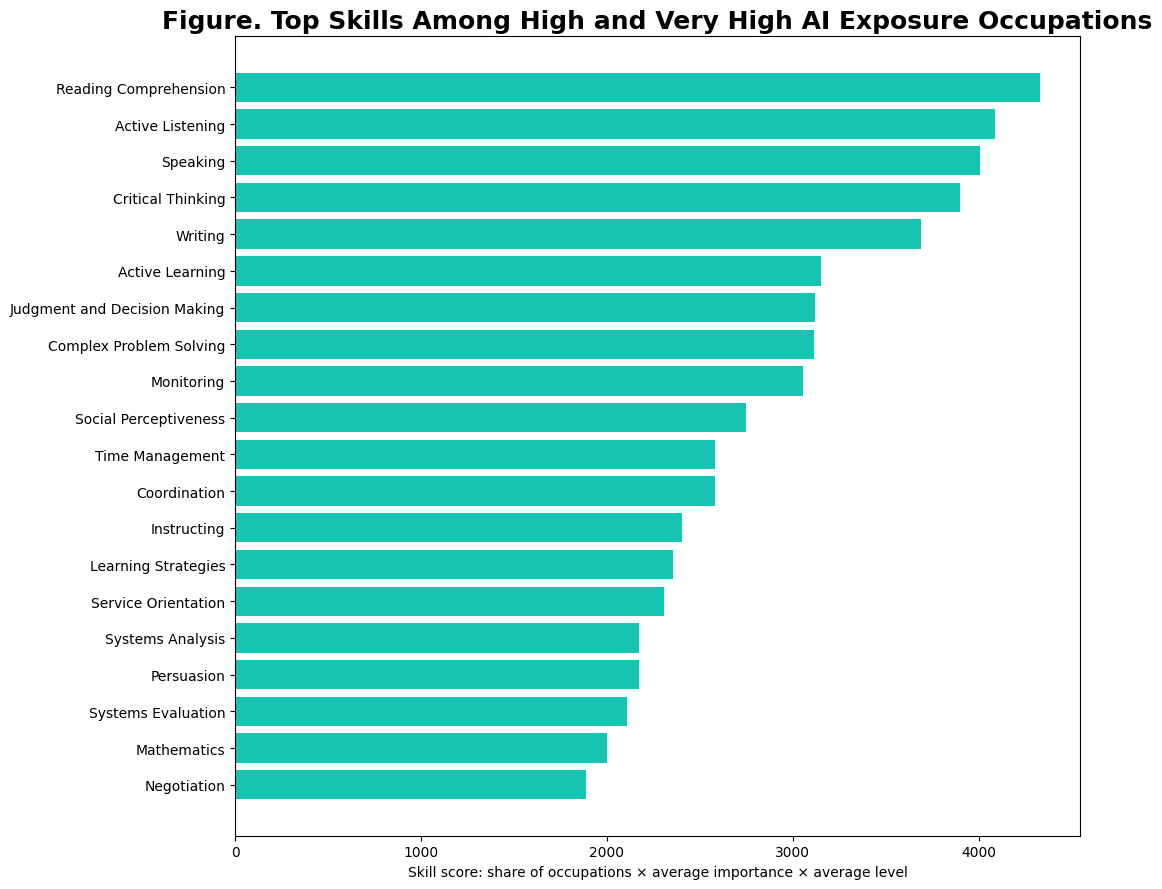


Done.
Raw skill rows: 10,675
Unique occupations: 301
Unique skills: 35
Outputs saved to: C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO\Skill Outputs

Top 10 skills:
                           Skill  Occupation_Count  Share_of_Occupations  \
23         Reading Comprehension               301                   1.0   
1               Active Listening               301                   1.0   
28                      Speaking               301                   1.0   
4              Critical Thinking               301                   1.0   
34                       Writing               301                   1.0   
0                Active Learning               301                   1.0   
9   Judgment and Decision Making               301                   1.0   
2        Complex Problem Solving               301                   1.0   
15                    Monitoring               301                   1.0   
27         Social Perceptiveness               301          

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import textwrap
import re

# =========================================================
# PATHS
# =========================================================

VERY_HIGH_FOLDER = Path(
    r"C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO"
)

HIGH_FOLDER = Path(
    r"C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO\High AI"
)

OUT_FOLDER = Path(
    r"C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO\Skill Outputs"
)
OUT_FOLDER.mkdir(parents=True, exist_ok=True)

OLD_FOLDER = Path(
    r"C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO\Old Pull 2021 2022"
)

# =========================================================
# SETTINGS
# =========================================================

TOP_N = 20
SKILL_SHEET_NAME = "Competencies - Skills"

PATINA = "#17C3B2"
CARROT = "#F79732"
DARK_BLUE = "#003057"

# =========================================================
# HELPERS
# =========================================================

def wrap_label(text, width=28):
    return "\n".join(textwrap.wrap(str(text), width))

def find_skill_sheet(xlsx_path):
    xl = pd.ExcelFile(xlsx_path)

    if SKILL_SHEET_NAME in xl.sheet_names:
        return SKILL_SHEET_NAME

    for sheet in xl.sheet_names:
        s = sheet.lower().replace("-", " ")
        if "competencies" in s and "skills" in s:
            return sheet

    return None

def clean_skill_df(df):
    df.columns = df.columns.astype(str).str.strip()

    rename_map = {}
    for col in df.columns:
        c = str(col).lower().strip()

        if c == "skill" or "skill" in c:
            rename_map[col] = "Skill"
        elif "importance" in c:
            rename_map[col] = "Importance"
        elif c == "level" or "level" in c:
            rename_map[col] = "Level"

    df = df.rename(columns=rename_map)

    required_cols = ["Skill", "Importance", "Level"]
    missing_cols = [c for c in required_cols if c not in df.columns]

    if missing_cols:
        return pd.DataFrame()

    df = df[required_cols].copy()

    df["Skill"] = df["Skill"].astype(str).str.strip()
    df = df[df["Skill"].notna()]
    df = df[df["Skill"].str.lower() != "nan"]
    df = df[df["Skill"] != ""]
    df = df[df["Skill"].str.lower() != "skill"]

    df["Importance"] = pd.to_numeric(df["Importance"], errors="coerce")
    df["Level"] = pd.to_numeric(df["Level"], errors="coerce")

    df = df[df["Importance"].notna() | df["Level"].notna()]

    return df

def infer_occupation_from_filename(path):
    name = path.stem
    name = re.sub(r"^Skills_Transferability_", "", name)
    name = re.sub(r"_in_(United_States|Arizona).*", "", name)
    name = name.replace("_", " ")
    return name.strip()

def read_lightcast_skill_files(folder, exposure_group):
    rows = []

    files = sorted(folder.glob("Skills_Transferability_*.xlsx"))
    print(f"\nReading {exposure_group} files from: {folder}")
    print(f"Files found: {len(files)}")

    for file in files:
        try:
            sheet = find_skill_sheet(file)

            if sheet is None:
                print(f"Skipped, no Competencies - Skills sheet: {file.name}")
                continue

            # Header row is row 3 in Excel, so use header=2
            df = pd.read_excel(file, sheet_name=sheet, header=2)
            df = clean_skill_df(df)

            if df.empty:
                print(f"Skipped, no usable skills after cleaning: {file.name}")
                continue

            df["Occupation"] = infer_occupation_from_filename(file)
            df["Exposure Group"] = exposure_group
            df["Source File"] = file.name

            rows.append(df)

        except Exception as e:
            print(f"Error reading {file.name}: {e}")

    if not rows:
        return pd.DataFrame(columns=[
            "Skill", "Importance", "Level", "Occupation", "Exposure Group", "Source File"
        ])

    return pd.concat(rows, ignore_index=True)

def aggregate_skills(df):
    if df.empty:
        raise ValueError("No skill rows were found. Check folder paths and sheet names.")

    required_cols = ["Skill", "Importance", "Level", "Occupation"]
    missing_cols = [c for c in required_cols if c not in df.columns]

    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    total_occupations = df["Occupation"].nunique()

    summary = (
        df.groupby("Skill", as_index=False)
        .agg(
            Occupation_Count=("Occupation", "nunique"),
            Total_Mentions=("Skill", "size"),
            Avg_Importance=("Importance", "mean"),
            Avg_Level=("Level", "mean"),
            Median_Importance=("Importance", "median"),
            Median_Level=("Level", "median")
        )
    )

    summary["Share_of_Occupations"] = summary["Occupation_Count"] / total_occupations

    summary["Skill_Score"] = (
        summary["Share_of_Occupations"] *
        summary["Avg_Importance"].fillna(0) *
        summary["Avg_Level"].fillna(0)
    )

    return summary.sort_values("Skill_Score", ascending=False)

def plot_top_skills(summary, title, out_file, top_n=20):
    plot_df = summary.head(top_n).sort_values("Skill_Score", ascending=True)

    plt.figure(figsize=(11, 9))

    plt.barh(
        [wrap_label(x) for x in plot_df["Skill"]],
        plot_df["Skill_Score"],
        color=PATINA
    )

    plt.title(title, fontsize=18, weight="bold")
    plt.xlabel("Skill score: share of occupations × average importance × average level")
    plt.ylabel("")
    plt.tight_layout()
    plt.savefig(out_file, dpi=300, bbox_inches="tight")
    plt.show()

def compare_old_new(old_summary, new_summary):
    old_top = old_summary.head(50)[["Skill", "Skill_Score"]].rename(
        columns={"Skill_Score": "Skill_Score_2021_2022"}
    )

    new_top = new_summary.head(50)[["Skill", "Skill_Score"]].rename(
        columns={"Skill_Score": "Skill_Score_2026"}
    )

    compare = pd.merge(old_top, new_top, on="Skill", how="outer").fillna(0)

    compare["Change"] = (
        compare["Skill_Score_2026"] -
        compare["Skill_Score_2021_2022"]
    )

    compare["Abs_Change"] = compare["Change"].abs()

    return compare.sort_values("Abs_Change", ascending=False)

def plot_skill_change(compare_df, out_file, top_n=20):
    plot_df = compare_df.head(top_n).sort_values("Change", ascending=True)

    colors = np.where(plot_df["Change"] >= 0, PATINA, CARROT)

    plt.figure(figsize=(11, 9))

    plt.barh(
        [wrap_label(x) for x in plot_df["Skill"]],
        plot_df["Change"],
        color=colors
    )

    plt.axvline(0, color="black", linewidth=0.8)

    plt.title(
        "Figure. Largest Skill Changes Among High and Very High AI Exposure Occupations",
        fontsize=16,
        weight="bold"
    )

    plt.xlabel("Change in skill score, 2026 minus 2021/2022")
    plt.ylabel("")
    plt.tight_layout()
    plt.savefig(out_file, dpi=300, bbox_inches="tight")
    plt.show()

# =========================================================
# CURRENT LIGHTCAST PULL
# =========================================================

very_high_df = read_lightcast_skill_files(VERY_HIGH_FOLDER, "Very High")
high_df = read_lightcast_skill_files(HIGH_FOLDER, "High")

current_df = pd.concat([very_high_df, high_df], ignore_index=True)

current_summary = aggregate_skills(current_df)

current_df.to_excel(
    OUT_FOLDER / "Lightcast_High_VeryHigh_Skills_Raw.xlsx",
    index=False
)

current_summary.to_excel(
    OUT_FOLDER / "Lightcast_High_VeryHigh_Top_Skills_Current.xlsx",
    index=False
)

plot_top_skills(
    current_summary,
    "Figure. Top Skills Among High and Very High AI Exposure Occupations",
    OUT_FOLDER / "Figure_Top_Skills_High_VeryHigh_Current.png",
    top_n=TOP_N
)

# =========================================================
# OPTIONAL OLD VS NEW COMPARISON
# =========================================================

if OLD_FOLDER.exists():
    old_df = read_lightcast_skill_files(OLD_FOLDER, "High or Very High")
    old_summary = aggregate_skills(old_df)

    change_df = compare_old_new(old_summary, current_summary)

    change_df.to_excel(
        OUT_FOLDER / "Lightcast_High_VeryHigh_Skill_Change_2021_2022_vs_2026.xlsx",
        index=False
    )

    plot_skill_change(
        change_df,
        OUT_FOLDER / "Figure_Skill_Change_2021_2022_vs_2026.png",
        top_n=TOP_N
    )

# =========================================================
# PRINT CHECKS
# =========================================================

print("\nDone.")
print(f"Raw skill rows: {len(current_df):,}")
print(f"Unique occupations: {current_df['Occupation'].nunique():,}")
print(f"Unique skills: {current_df['Skill'].nunique():,}")
print(f"Outputs saved to: {OUT_FOLDER}")

print("\nTop 10 skills:")
print(
    current_summary[
        ["Skill", "Occupation_Count", "Share_of_Occupations", "Avg_Importance", "Avg_Level", "Skill_Score"]
    ].head(10)
)

Reading Very High files: 162
Reading High files: 143

STEP 1 DONE
Lightcast raw rows: 10,675
Approved unique skills: 35
Processed chunk 1. Rows processed: 240,992. Skill matches counted: 60,795.
Processed chunk 2. Rows processed: 481,801. Skill matches counted: 121,954.
Processed chunk 3. Rows processed: 722,966. Skill matches counted: 181,956.
Processed chunk 4. Rows processed: 964,207. Skill matches counted: 241,121.
Processed chunk 5. Rows processed: 1,205,280. Skill matches counted: 301,367.
Processed chunk 6. Rows processed: 1,444,605. Skill matches counted: 366,665.
Processed chunk 7. Rows processed: 1,683,978. Skill matches counted: 432,088.
Processed chunk 8. Rows processed: 1,923,277. Skill matches counted: 497,428.
Processed chunk 9. Rows processed: 2,162,512. Skill matches counted: 563,598.
Processed chunk 10. Rows processed: 2,401,597. Skill matches counted: 630,812.
Processed chunk 11. Rows processed: 2,640,719. Skill matches counted: 697,318.
Processed chunk 12. Rows proc

C:\Users\301533\AppData\Local\Temp\ipykernel_15236\1371496044.py:278: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



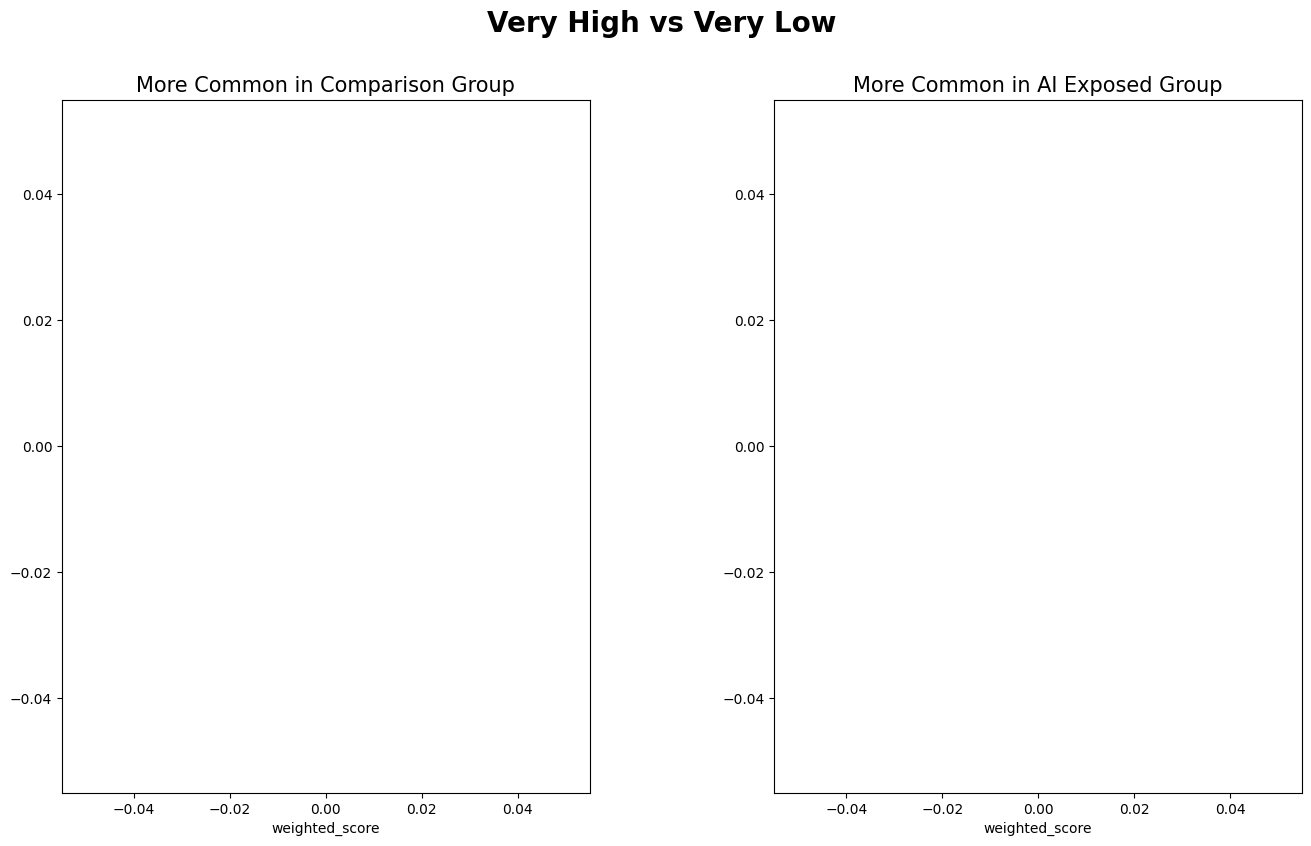

C:\Users\301533\AppData\Local\Temp\ipykernel_15236\1371496044.py:278: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



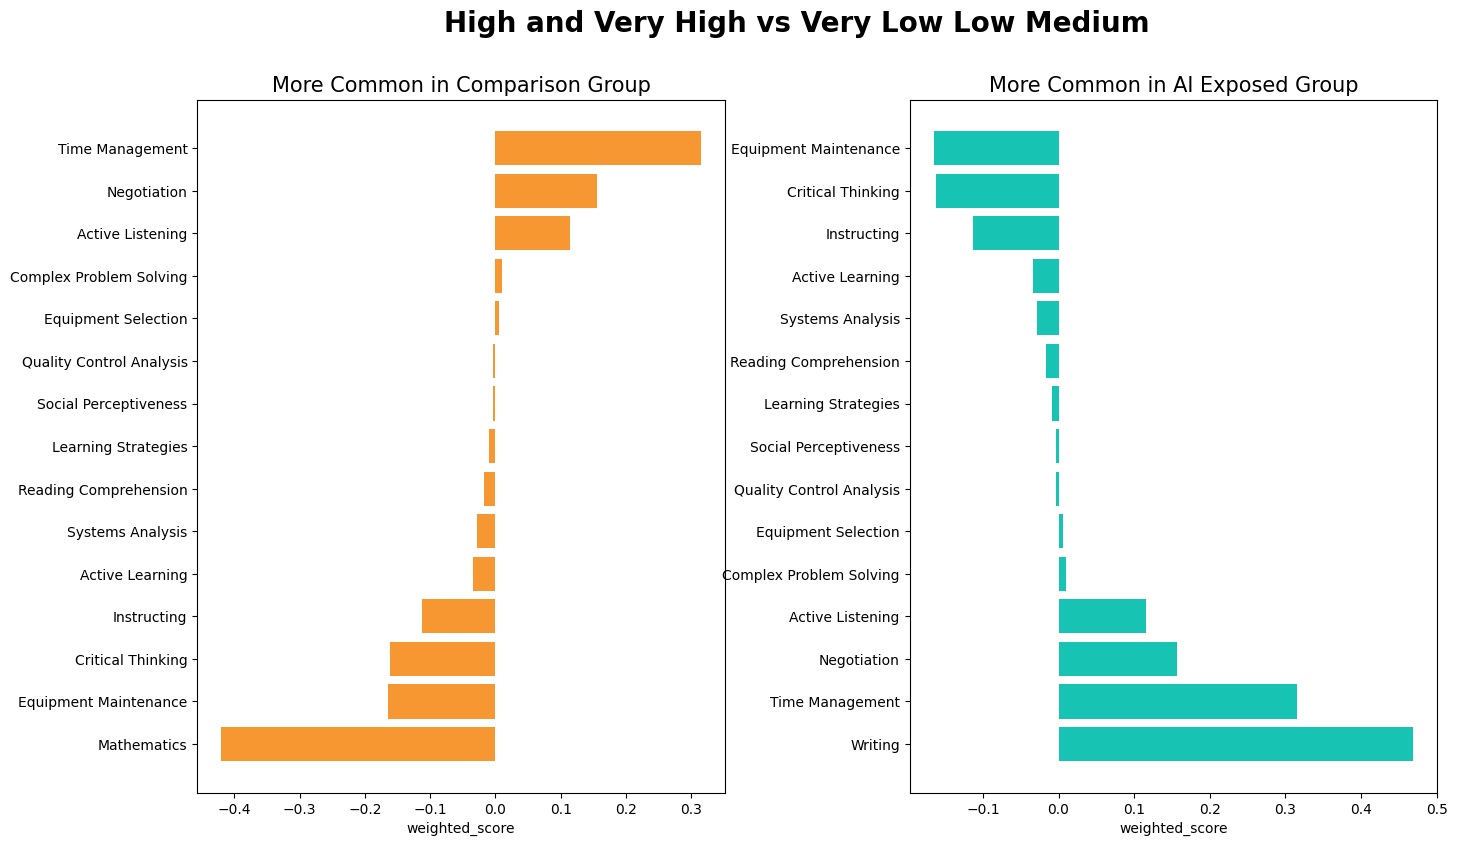

C:\Users\301533\AppData\Local\Temp\ipykernel_15236\1371496044.py:278: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



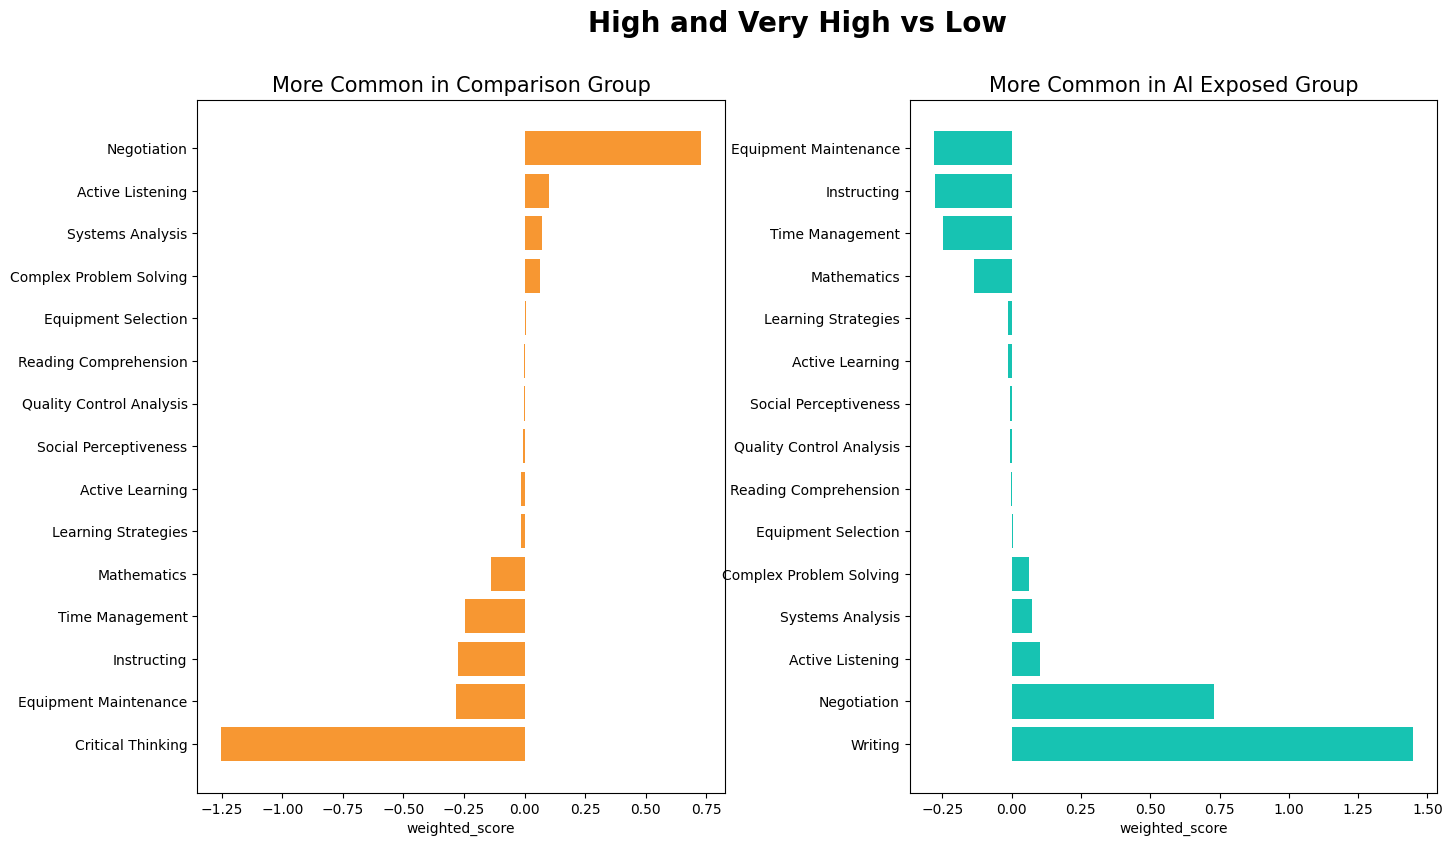

C:\Users\301533\AppData\Local\Temp\ipykernel_15236\1371496044.py:278: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



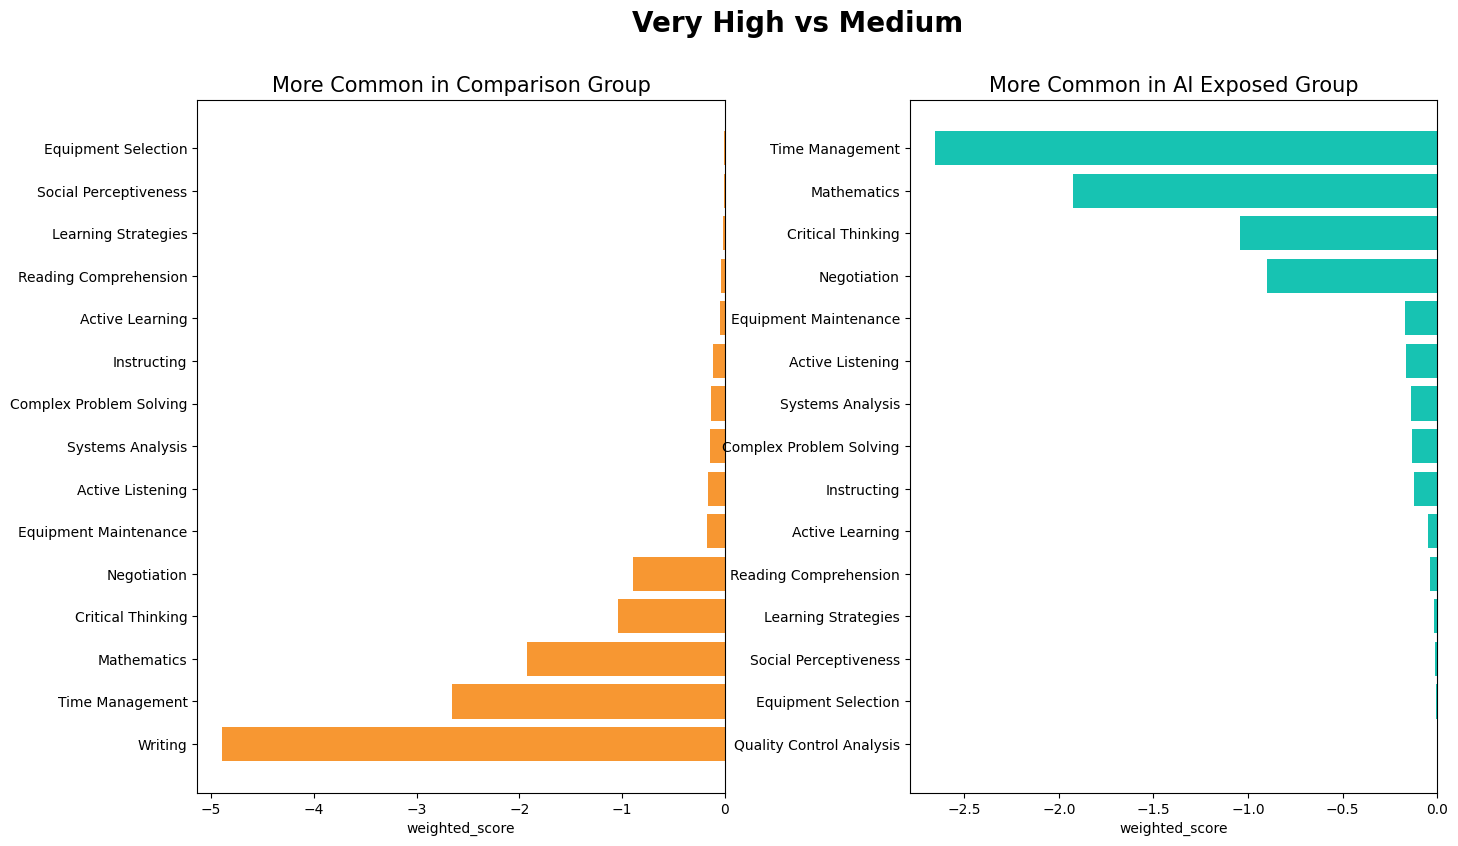

DTypePromotionError: The DType <class 'numpy.dtypes.StrDType'> could not be promoted by <class 'numpy.dtypes._PyFloatDType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes._PyFloatDType'>)

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import textwrap
import re
import ast
import json

# =========================================================
# PATHS
# =========================================================

VERY_HIGH_FOLDER = Path(
    r"C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO"
)

HIGH_FOLDER = Path(
    r"C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO\High AI"
)

POSTINGS_FILE = Path(
    r"G:\Shared drives\EO_OPERATIONS\Grants\PCIC Analysis\Job Posting Data\raw_data\df_2016_2025.csv"
)

OUT_FOLDER = Path(
    r"C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO\Skill Outputs"
)
OUT_FOLDER.mkdir(parents=True, exist_ok=True)

# =========================================================
# SETTINGS
# =========================================================

TOP_N_FIGURE = 15
CHUNK_SIZE = 100_000

EXPOSURE_COL = "Category"   # Your postings file already has Category
SOC_COL = "SOC_5"
YEAR_COL = "YEAR"

PRE_YEARS = [2021, 2022]
CURRENT_YEARS = [2025]      # change to [2024, 2025] if needed

PATINA = "#17C3B2"
CARROT = "#F79732"

# =========================================================
# HELPERS
# =========================================================

def clean_skill_name(x):
    return (
        str(x)
        .strip()
        .lower()
        .replace("’", "'")
        .replace("–", "-")
        .replace("—", "-")
    )

def wrap(text, width=24):
    return "\n".join(textwrap.wrap(str(text), width))

def find_skill_sheet(xlsx_path):
    xl = pd.ExcelFile(xlsx_path)

    if "Competencies - Skills" in xl.sheet_names:
        return "Competencies - Skills"

    for sheet in xl.sheet_names:
        s = sheet.lower().replace("-", " ")
        if "competencies" in s and "skills" in s:
            return sheet

    return None

def infer_occupation_from_filename(path):
    name = path.stem
    name = re.sub(r"^Skills_Transferability_", "", name)
    name = re.sub(r"_in_(United_States|Arizona).*", "", name)
    name = name.replace("_", " ")
    return name.strip()

def parse_skill_list(x):
    if pd.isna(x):
        return []

    if isinstance(x, list):
        return x

    s = str(x).strip()

    if s in ["", "[]", "nan", "None"]:
        return []

    try:
        parsed = ast.literal_eval(s)
        if isinstance(parsed, list):
            return [str(v).strip() for v in parsed if str(v).strip()]
    except:
        pass

    try:
        parsed = json.loads(s)
        if isinstance(parsed, list):
            return [str(v).strip() for v in parsed if str(v).strip()]
    except:
        pass

    return [v.strip() for v in s.split(",") if v.strip()]

def read_lightcast_skill_files(folder, exposure_group):
    rows = []
    files = sorted(folder.glob("Skills_Transferability_*.xlsx"))

    print(f"Reading {exposure_group} files: {len(files)}")

    for file in files:
        try:
            sheet = find_skill_sheet(file)
            if sheet is None:
                continue

            df = pd.read_excel(file, sheet_name=sheet, header=2)
            df.columns = df.columns.astype(str).str.strip()

            if "Skill" not in df.columns:
                continue

            keep = [c for c in ["Skill", "Importance", "Level"] if c in df.columns]
            df = df[keep].copy()

            df["Skill"] = df["Skill"].astype(str).str.strip()
            df = df[df["Skill"].str.lower() != "nan"]
            df = df[df["Skill"] != ""]

            df["skill_clean"] = df["Skill"].apply(clean_skill_name)
            df["Lightcast Exposure Source"] = exposure_group
            df["Lightcast Occupation"] = infer_occupation_from_filename(file)
            df["Source File"] = file.name

            rows.append(df)

        except Exception as e:
            print(f"Error reading {file.name}: {e}")

    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

def build_lightcast_word_bank():
    very_high = read_lightcast_skill_files(VERY_HIGH_FOLDER, "Very High")
    high = read_lightcast_skill_files(HIGH_FOLDER, "High")

    raw = pd.concat([very_high, high], ignore_index=True)

    bank = (
        raw.groupby("skill_clean", as_index=False)
        .agg(
            Skill=("Skill", "first"),
            Lightcast_Mentions=("Skill", "size"),
            Lightcast_Occupation_Count=("Lightcast Occupation", "nunique")
        )
        .sort_values(
            ["Lightcast_Occupation_Count", "Lightcast_Mentions"],
            ascending=[False, False]
        )
    )

    return raw, bank

def standardize_exposure(x):
    s = str(x).strip()

    mapping = {
        "very low": "Very Low",
        "low": "Low",
        "medium": "Medium",
        "high": "High",
        "very high": "Very High"
    }

    return mapping.get(s.lower(), s)

def explode_posting_skills(chunk, word_bank_set):
    needed = [SOC_COL, YEAR_COL, EXPOSURE_COL, "SKILLS_NAME", "SOFTWARE_SKILLS_NAME"]
    chunk = chunk[[c for c in needed if c in chunk.columns]].copy()

    chunk[SOC_COL] = chunk[SOC_COL].astype(str).str.strip()
    chunk[YEAR_COL] = pd.to_numeric(chunk[YEAR_COL], errors="coerce")
    chunk[EXPOSURE_COL] = chunk[EXPOSURE_COL].apply(standardize_exposure)

    chunk = chunk[chunk[SOC_COL].str.match(r"^\d{2}-\d{4}$", na=False)].copy()
    chunk = chunk[chunk[EXPOSURE_COL].isin(["Very Low", "Low", "Medium", "High", "Very High"])].copy()

    rows = []

    for _, row in chunk.iterrows():
        skills = []
        skills += parse_skill_list(row.get("SKILLS_NAME"))
        skills += parse_skill_list(row.get("SOFTWARE_SKILLS_NAME"))

        if not skills:
            continue

        unique_skills = sorted(set(skills))

        for skill in unique_skills:
            skill_clean = clean_skill_name(skill)

            if skill_clean in word_bank_set:
                rows.append({
                    "SOC": row[SOC_COL],
                    "SOC2": str(row[SOC_COL])[:2],
                    "Year": row[YEAR_COL],
                    "Exposure": row[EXPOSURE_COL],
                    "Skill": skill,
                    "skill_clean": skill_clean,
                    "Count": 1
                })

    return pd.DataFrame(rows)

def aggregate_counts(df):
    return (
        df.groupby(["Skill", "skill_clean", "Exposure"], as_index=False)
        .agg(
            Count=("Count", "sum"),
            SOC_Count=("SOC", "nunique")
        )
    )

def build_comparison(agg, high_groups, low_groups, comparison_name):
    high = (
        agg[agg["Exposure"].isin(high_groups)]
        .groupby(["Skill", "skill_clean"], as_index=False)
        .agg(Count_High=("Count", "sum"))
    )

    low = (
        agg[agg["Exposure"].isin(low_groups)]
        .groupby(["Skill", "skill_clean"], as_index=False)
        .agg(Count_Low=("Count", "sum"))
    )

    out = high.merge(low, on=["Skill", "skill_clean"], how="outer").fillna(0)

    total_high = out["Count_High"].sum()
    total_low = out["Count_Low"].sum()

    out["Freq_High"] = out["Count_High"] / total_high if total_high > 0 else 0
    out["Freq_Low"] = out["Count_Low"] / total_low if total_low > 0 else 0

    out["log_ratio"] = np.log((out["Count_High"] + 1) / (out["Count_Low"] + 1))
    out["share_diff"] = out["Freq_High"] - out["Freq_Low"]
    out["Total_Mentions"] = out["Count_High"] + out["Count_Low"]
    out["weighted_score"] = out["share_diff"] * np.log1p(out["Total_Mentions"])
    out["Comparison"] = comparison_name

    return out.sort_values("weighted_score", ascending=False)

def plot_comparison(df, title, out_file, score_col="weighted_score"):
    high = df.sort_values(score_col, ascending=False).head(TOP_N_FIGURE)
    low = df.sort_values(score_col, ascending=True).head(TOP_N_FIGURE)

    fig, (ax1, ax2) = plt.subplots(
        1, 2, figsize=(16, 9), gridspec_kw={"wspace": 0.35}
    )

    ax1.barh([wrap(x) for x in low["Skill"]], low[score_col], color=CARROT)
    ax1.set_title("More Common in Comparison Group", fontsize=15)
    ax1.set_xlabel(score_col)

    ax2.barh([wrap(x) for x in high["Skill"]], high[score_col], color=PATINA)
    ax2.set_title("More Common in AI Exposed Group", fontsize=15)
    ax2.set_xlabel(score_col)

    fig.suptitle(title, fontsize=20, weight="bold")
    plt.tight_layout()
    plt.savefig(out_file, dpi=300, bbox_inches="tight")
    plt.show()

def build_time_comparison(matched):
    temp = matched.copy()

    temp["Period"] = np.where(
        temp["Year"].isin(PRE_YEARS),
        "Pre AI, 2021-2022",
        np.where(temp["Year"].isin(CURRENT_YEARS), "Current", np.nan)
    )

    temp = temp[temp["Period"].notna()].copy()
    temp = temp[temp["Exposure"].isin(["High", "Very High"])].copy()

    period_counts = (
        temp.groupby(["Skill", "skill_clean", "Period"], as_index=False)
        .agg(Count=("Count", "sum"))
    )

    wide = period_counts.pivot_table(
        index=["Skill", "skill_clean"],
        columns="Period",
        values="Count",
        fill_value=0
    ).reset_index()

    for col in ["Pre AI, 2021-2022", "Current"]:
        if col not in wide.columns:
            wide[col] = 0

    total_pre = wide["Pre AI, 2021-2022"].sum()
    total_current = wide["Current"].sum()

    wide["Freq_Pre"] = wide["Pre AI, 2021-2022"] / total_pre if total_pre > 0 else 0
    wide["Freq_Current"] = wide["Current"] / total_current if total_current > 0 else 0

    wide["Change"] = wide["Freq_Current"] - wide["Freq_Pre"]
    wide["Abs_Change"] = wide["Change"].abs()

    return wide.sort_values("Abs_Change", ascending=False)

def plot_time_change(df, out_file, top_n=20):
    plot_df = df.head(top_n).sort_values("Change", ascending=True)
    colors = np.where(plot_df["Change"] >= 0, PATINA, CARROT)

    plt.figure(figsize=(11, 9))
    plt.barh([wrap(x) for x in plot_df["Skill"]], plot_df["Change"], color=colors)
    plt.axvline(0, color="black", linewidth=0.8)

    plt.title(
        "Largest Skill Frequency Changes Among High and Very High AI Occupations",
        fontsize=16,
        weight="bold"
    )
    plt.xlabel("Current skill share minus 2021-2022 skill share")
    plt.ylabel("")
    plt.tight_layout()
    plt.savefig(out_file, dpi=300, bbox_inches="tight")
    plt.show()

# =========================================================
# STEP 1: LIGHTCAST APPROVED WORD BANK
# =========================================================

lightcast_raw, word_bank = build_lightcast_word_bank()
word_bank_set = set(word_bank["skill_clean"])

lightcast_raw.to_excel(
    OUT_FOLDER / "Step1_Lightcast_All_Approved_Skills_Raw.xlsx",
    index=False
)

word_bank.to_excel(
    OUT_FOLDER / "Step1_Lightcast_Approved_Skill_Word_Bank.xlsx",
    index=False
)

print("\nSTEP 1 DONE")
print(f"Lightcast raw rows: {len(lightcast_raw):,}")
print(f"Approved unique skills: {word_bank['skill_clean'].nunique():,}")

# =========================================================
# STEP 2: FAST COUNT POSTING SKILLS WITHOUT ROW-LEVEL EXPLOSION
# =========================================================

from collections import Counter

skill_counter = Counter()
soc2_counter = Counter()
time_counter = Counter()

usecols = [
    SOC_COL,
    YEAR_COL,
    EXPOSURE_COL,
    "SKILLS_NAME",
    "SOFTWARE_SKILLS_NAME"
]

total_rows_processed = 0
total_skill_matches = 0

for i, chunk in enumerate(
    pd.read_csv(
        POSTINGS_FILE,
        usecols=lambda c: c in usecols,
        chunksize=250_000,
        low_memory=False
    ),
    start=1
):
    chunk[SOC_COL] = chunk[SOC_COL].astype(str).str.strip()
    chunk[YEAR_COL] = pd.to_numeric(chunk[YEAR_COL], errors="coerce")
    chunk[EXPOSURE_COL] = chunk[EXPOSURE_COL].apply(standardize_exposure)

    chunk = chunk[chunk[SOC_COL].str.match(r"^\d{2}-\d{4}$", na=False)].copy()
    chunk = chunk[chunk[EXPOSURE_COL].isin(["Very Low", "Low", "Medium", "High", "Very High"])].copy()

    for row in chunk.itertuples(index=False):
        row_dict = row._asdict()

        soc = row_dict[SOC_COL]
        soc2 = str(soc)[:2]
        year = row_dict[YEAR_COL]
        exposure = row_dict[EXPOSURE_COL]

        skills = parse_skill_list(row_dict.get("SKILLS_NAME")) + parse_skill_list(row_dict.get("SOFTWARE_SKILLS_NAME"))

        if not skills:
            continue

        for skill in set(skills):
            skill_clean = clean_skill_name(skill)

            if skill_clean not in word_bank_set:
                continue

            skill_counter[(skill, skill_clean, exposure)] += 1
            soc2_counter[(soc2, exposure, skill, skill_clean)] += 1

            if pd.notna(year):
                time_counter[(skill, skill_clean, exposure, int(year))] += 1

            total_skill_matches += 1

    total_rows_processed += len(chunk)

    print(
        f"Processed chunk {i}. "
        f"Rows processed: {total_rows_processed:,}. "
        f"Skill matches counted: {total_skill_matches:,}."
    )

# Convert counters to summary dataframes
agg = pd.DataFrame([
    {
        "Skill": k[0],
        "skill_clean": k[1],
        "Exposure": k[2],
        "Count": v
    }
    for k, v in skill_counter.items()
])

soc2_output = pd.DataFrame([
    {
        "SOC2": k[0],
        "Exposure": k[1],
        "Skill": k[2],
        "skill_clean": k[3],
        "Count": v
    }
    for k, v in soc2_counter.items()
])

time_agg = pd.DataFrame([
    {
        "Skill": k[0],
        "skill_clean": k[1],
        "Exposure": k[2],
        "Year": k[3],
        "Count": v
    }
    for k, v in time_counter.items()
])

agg.to_excel(
    OUT_FOLDER / "Step3_Skill_Counts_By_AI_Exposure.xlsx",
    index=False
)

soc2_output.to_excel(
    OUT_FOLDER / "Step6_Skill_Counts_By_SOC2_Exposure.xlsx",
    index=False
)

time_agg.to_excel(
    OUT_FOLDER / "Step5_Skill_Counts_By_Year_Exposure.xlsx",
    index=False
)

print("\nSTEP 2 FAST COUNT DONE")
print(f"Skill matches counted: {total_skill_matches:,}")
print(f"Skill-exposure rows: {len(agg):,}")
print(f"SOC2-skill rows: {len(soc2_output):,}")
print(f"Skill-year rows: {len(time_agg):,}")

# =========================================================
# STEP 3: EXPOSURE COMPARISONS
# =========================================================

comparisons = {
    "Very High vs Very Low": {
        "high": ["Very High"],
        "low": ["Very Low"]
    },
    "High and Very High vs Very Low Low Medium": {
        "high": ["High", "Very High"],
        "low": ["Very Low", "Low", "Medium"]
    },
    "High and Very High vs Low": {
        "high": ["High", "Very High"],
        "low": ["Low"]
    },
    "Very High vs Medium": {
        "high": ["Very High"],
        "low": ["Medium"]
    }
}

all_outputs = []

for name, groups in comparisons.items():
    comp = build_comparison(
        agg,
        high_groups=groups["high"],
        low_groups=groups["low"],
        comparison_name=name
    )

    safe_name = re.sub(r"[^A-Za-z0-9]+", "_", name).strip("_")

    comp.to_excel(
        OUT_FOLDER / f"Step4_Comparison_{safe_name}.xlsx",
        index=False
    )

    plot_comparison(
        comp,
        title=name,
        out_file=OUT_FOLDER / f"Figure_{safe_name}_Weighted_Score.png"
    )

    all_outputs.append(comp)

all_comparisons = pd.concat(all_outputs, ignore_index=True)

all_comparisons.to_excel(
    OUT_FOLDER / "Step4_All_Exposure_Comparisons.xlsx",
    index=False
)

# =========================================================
# STEP 4: TIME CHANGE AMONG HIGH AND VERY HIGH
# =========================================================

def build_time_comparison_from_agg(time_agg):
    temp = time_agg.copy()

    temp["Period"] = np.where(
        temp["Year"].isin(PRE_YEARS),
        "Pre AI, 2021-2022",
        np.where(temp["Year"].isin(CURRENT_YEARS), "Current", np.nan)
    )

    temp = temp[temp["Period"].notna()].copy()
    temp = temp[temp["Exposure"].isin(["High", "Very High"])].copy()

    period_counts = (
        temp.groupby(["Skill", "skill_clean", "Period"], as_index=False)
        .agg(Count=("Count", "sum"))
    )

    wide = period_counts.pivot_table(
        index=["Skill", "skill_clean"],
        columns="Period",
        values="Count",
        fill_value=0
    ).reset_index()

    for col in ["Pre AI, 2021-2022", "Current"]:
        if col not in wide.columns:
            wide[col] = 0

    total_pre = wide["Pre AI, 2021-2022"].sum()
    total_current = wide["Current"].sum()

    wide["Freq_Pre"] = wide["Pre AI, 2021-2022"] / total_pre if total_pre > 0 else 0
    wide["Freq_Current"] = wide["Current"] / total_current if total_current > 0 else 0

    wide["Change"] = wide["Freq_Current"] - wide["Freq_Pre"]
    wide["Abs_Change"] = wide["Change"].abs()

    return wide.sort_values("Abs_Change", ascending=False)

time_change = build_time_comparison_from_agg(time_agg)

time_change.to_excel(
    OUT_FOLDER / "Step5_Skill_Change_High_VeryHigh_PreAI_vs_Current.xlsx",
    index=False
)

plot_time_change(
    time_change,
    OUT_FOLDER / "Figure_Skill_Change_High_VeryHigh_PreAI_vs_Current.png",
    top_n=20
)

# =========================================================
# FINAL CHECKS
# =========================================================

print("\nDONE.")
print(f"Outputs saved to: {OUT_FOLDER}")

print("\nTop matched posting skills:")
print(
    agg.groupby("Skill", as_index=False)
    .agg(Count=("Count", "sum"))
    .sort_values("Count", ascending=False)
    .head(20)
)

print("\nTop High and Very High distinctive skills:")
main_comp = all_comparisons[
    all_comparisons["Comparison"] == "High and Very High vs Very Low Low Medium"
].copy()

print(
    main_comp.sort_values("weighted_score", ascending=False)
    [["Skill", "Count_High", "Count_Low", "Freq_High", "Freq_Low", "weighted_score"]]
    .head(20)
)

In [21]:
import pandas as pd
import numpy as np

def build_time_comparison_from_existing(time_agg):
    temp = time_agg.copy()
    temp["Year"] = pd.to_numeric(temp["Year"], errors="coerce")

    temp["Period"] = None
    temp.loc[temp["Year"].isin([2021, 2022]), "Period"] = "Pre AI, 2021-2022"
    temp.loc[temp["Year"].isin([2025]), "Period"] = "Current"

    temp = temp[temp["Period"].notna()].copy()
    temp = temp[temp["Exposure"].isin(["High", "Very High"])].copy()

    period_counts = (
        temp.groupby(["Skill", "skill_clean", "Period"], as_index=False)
        .agg(Count=("Count", "sum"))
    )

    wide = period_counts.pivot_table(
        index=["Skill", "skill_clean"],
        columns="Period",
        values="Count",
        fill_value=0
    ).reset_index()

    for col in ["Pre AI, 2021-2022", "Current"]:
        if col not in wide.columns:
            wide[col] = 0

    total_pre = wide["Pre AI, 2021-2022"].sum()
    total_current = wide["Current"].sum()

    wide["Freq_Pre"] = wide["Pre AI, 2021-2022"] / total_pre if total_pre > 0 else 0
    wide["Freq_Current"] = wide["Current"] / total_current if total_current > 0 else 0

    wide["Change"] = wide["Freq_Current"] - wide["Freq_Pre"]
    wide["Abs_Change"] = wide["Change"].abs()

    return wide.sort_values("Abs_Change", ascending=False)

time_change = build_time_comparison_from_existing(time_agg)

time_change.to_excel(
    OUT_FOLDER / "Step5_Skill_Change_High_VeryHigh_PreAI_vs_Current.xlsx",
    index=False
)

print("Done. Saved time_change file.")
print(time_change.head(20))

Done. Saved time_change file.
Period                     Skill               skill_clean  Current  \
9                    Negotiation               negotiation   1603.0   
15                       Writing                   writing   5615.0   
8                    Mathematics               mathematics   1972.0   
14               Time Management           time management   3879.0   
2        Complex Problem Solving   complex problem solving    178.0   
13              Systems Analysis          systems analysis    106.0   
5            Equipment Selection       equipment selection     48.0   
1               Active Listening          active listening    431.0   
6                    Instructing               instructing     49.0   
11         Reading Comprehension     reading comprehension     21.0   
0                Active Learning           active learning     10.0   
4          Equipment Maintenance     equipment maintenance     66.0   
7            Learning Strategies       learning

C:\Users\301533\AppData\Local\Temp\ipykernel_15236\688430927.py:74: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



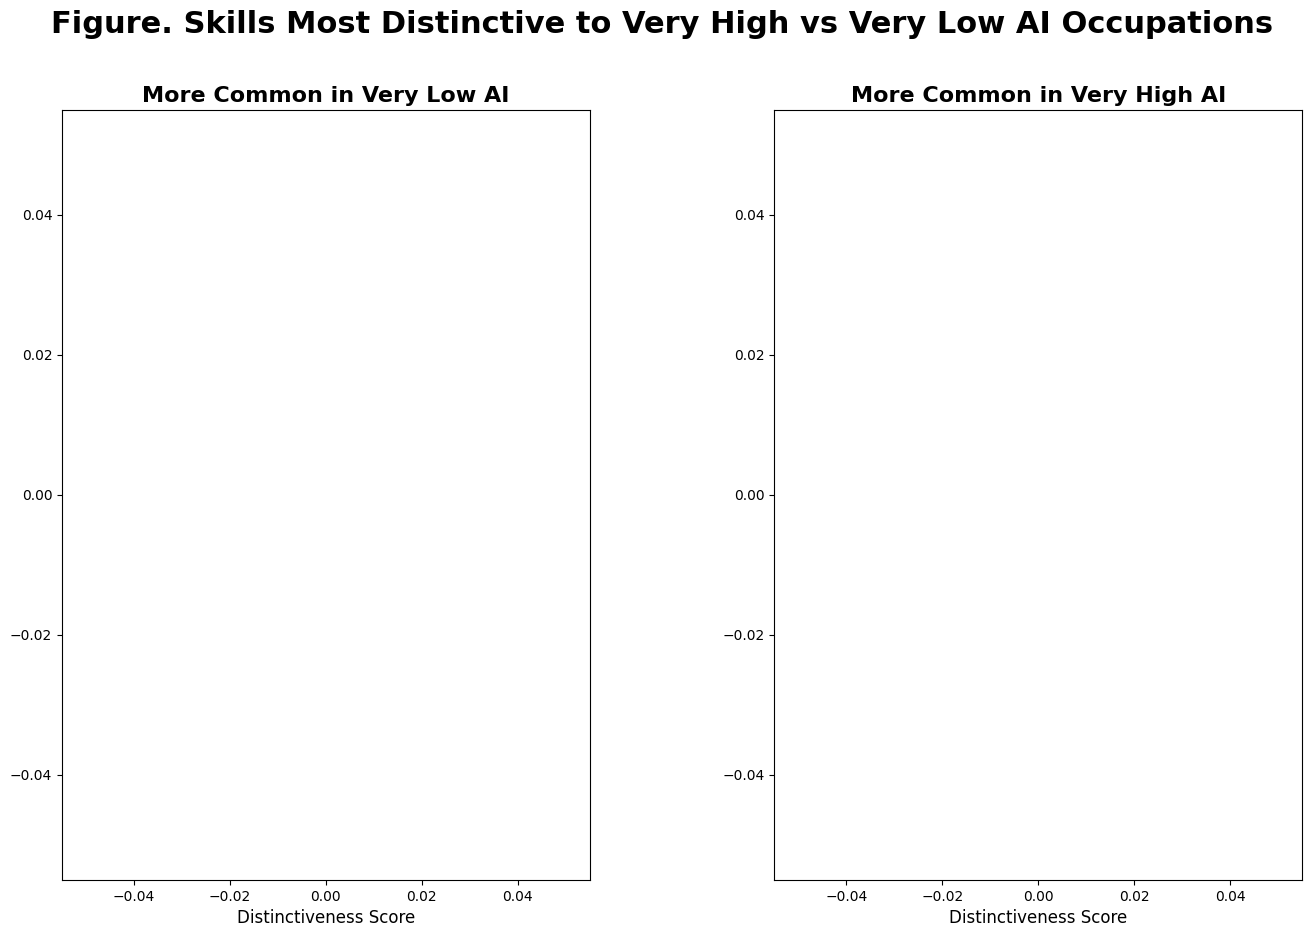

C:\Users\301533\AppData\Local\Temp\ipykernel_15236\688430927.py:74: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



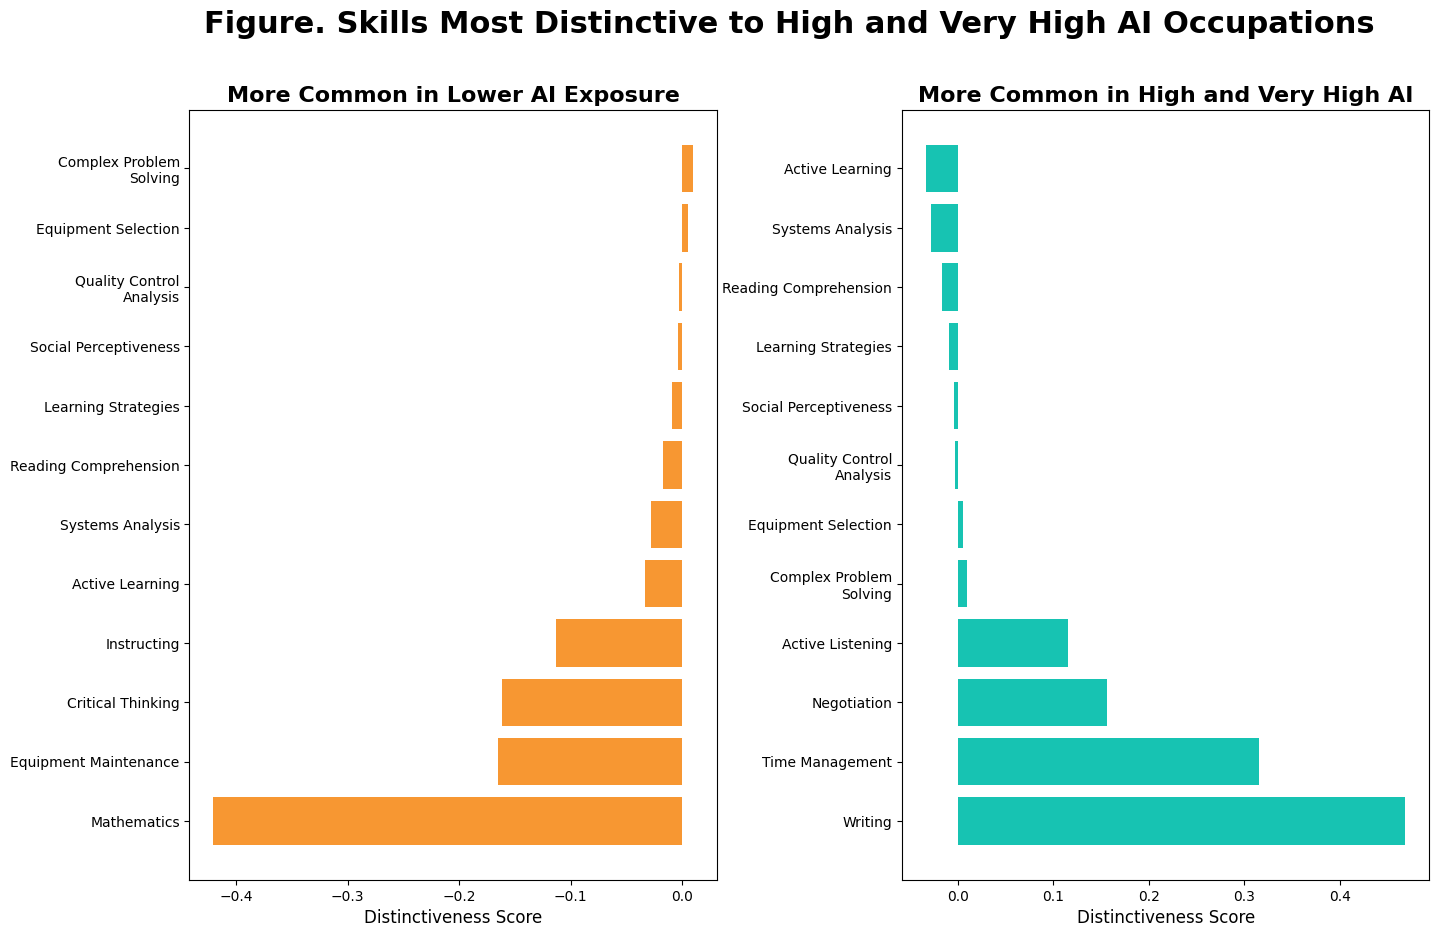

C:\Users\301533\AppData\Local\Temp\ipykernel_15236\688430927.py:74: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



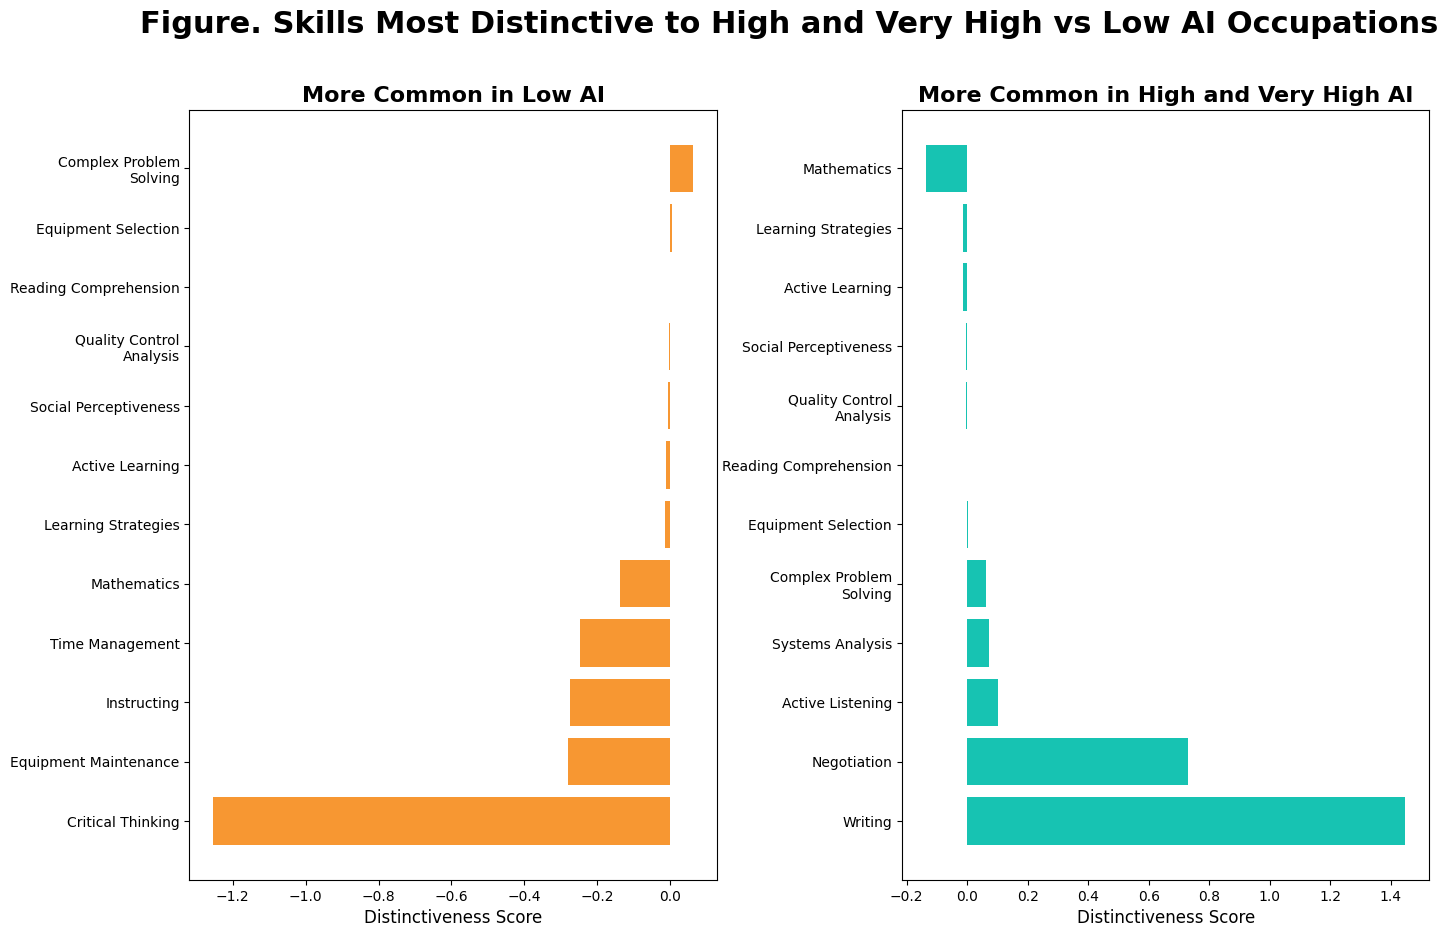

C:\Users\301533\AppData\Local\Temp\ipykernel_15236\688430927.py:74: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



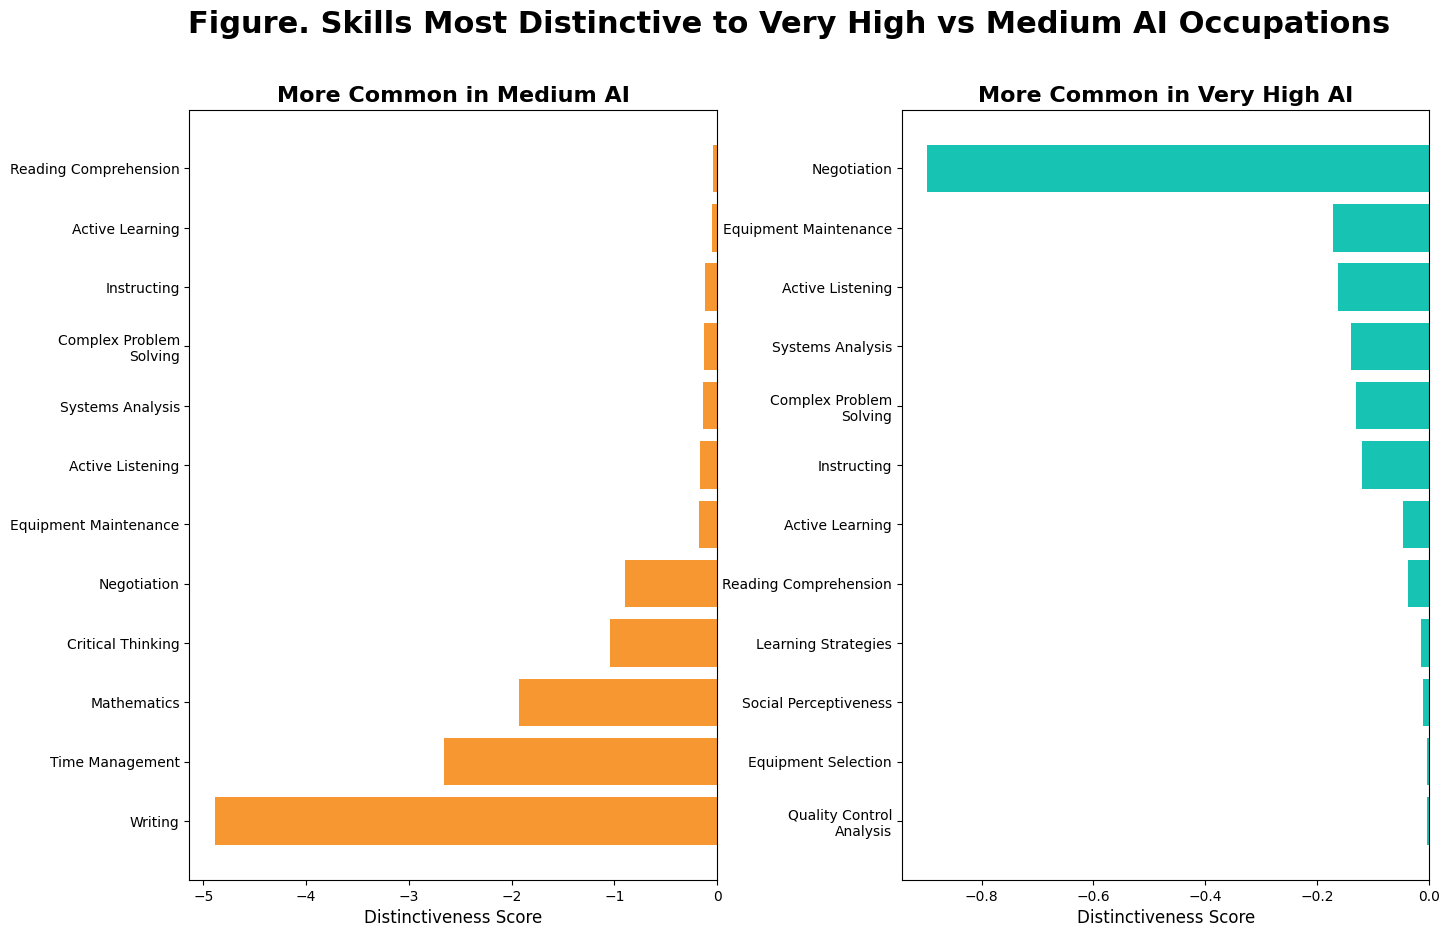


Done. All comparison figures saved.


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import textwrap
import re

# =========================================================
# PATHS
# =========================================================

OUT_FOLDER = Path(
    r"C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO\Skill Outputs"
)

# =========================================================
# SETTINGS
# =========================================================

TOP_N = 12

PATINA = "#17C3B2"
CARROT = "#F79732"
DARK = "#003057"

# =========================================================
# HELPERS
# =========================================================

def wrap(text, width=22):
    return "\n".join(textwrap.wrap(str(text), width))

def make_skill_plot(
    df,
    title,
    left_title,
    right_title,
    out_file,
    score_col="weighted_score",
    top_n=12
):
    high = df.sort_values(score_col, ascending=False).head(top_n)
    low = df.sort_values(score_col, ascending=True).head(top_n)

    fig, (ax1, ax2) = plt.subplots(
        1,
        2,
        figsize=(16, 10),
        gridspec_kw={"wspace": 0.35}
    )

    # LEFT SIDE
    ax1.barh(
        [wrap(x) for x in low["Skill"]],
        low[score_col],
        color=CARROT
    )

    ax1.set_title(left_title, fontsize=16, weight="bold")
    ax1.set_xlabel("Distinctiveness Score", fontsize=12)

    # RIGHT SIDE
    ax2.barh(
        [wrap(x) for x in high["Skill"]],
        high[score_col],
        color=PATINA
    )

    ax2.set_title(right_title, fontsize=16, weight="bold")
    ax2.set_xlabel("Distinctiveness Score", fontsize=12)

    fig.suptitle(title, fontsize=22, weight="bold")

    plt.tight_layout()

    plt.savefig(
        OUT_FOLDER / out_file,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

# =========================================================
# LOAD COMPARISON FILES
# =========================================================

comparison_files = {
    "Very High vs Very Low":
        "Step4_Comparison_Very_High_vs_Very_Low.xlsx",

    "High and Very High vs Very Low Low Medium":
        "Step4_Comparison_High_and_Very_High_vs_Very_Low_Low_Medium.xlsx",

    "High and Very High vs Low":
        "Step4_Comparison_High_and_Very_High_vs_Low.xlsx",

    "Very High vs Medium":
        "Step4_Comparison_Very_High_vs_Medium.xlsx"
}

# =========================================================
# FIGURE 1
# =========================================================

df = pd.read_excel(
    OUT_FOLDER / comparison_files["Very High vs Very Low"]
)

make_skill_plot(
    df=df,
    title="Figure. Skills Most Distinctive to Very High vs Very Low AI Occupations",
    left_title="More Common in Very Low AI",
    right_title="More Common in Very High AI",
    out_file="Figure_VH_vs_VL.png",
    score_col="weighted_score",
    top_n=TOP_N
)

# =========================================================
# FIGURE 2
# =========================================================

df = pd.read_excel(
    OUT_FOLDER / comparison_files["High and Very High vs Very Low Low Medium"]
)

make_skill_plot(
    df=df,
    title="Figure. Skills Most Distinctive to High and Very High AI Occupations",
    left_title="More Common in Lower AI Exposure",
    right_title="More Common in High and Very High AI",
    out_file="Figure_HVH_vs_Lower.png",
    score_col="weighted_score",
    top_n=TOP_N
)

# =========================================================
# FIGURE 3
# =========================================================

df = pd.read_excel(
    OUT_FOLDER / comparison_files["High and Very High vs Low"]
)

make_skill_plot(
    df=df,
    title="Figure. Skills Most Distinctive to High and Very High vs Low AI Occupations",
    left_title="More Common in Low AI",
    right_title="More Common in High and Very High AI",
    out_file="Figure_HVH_vs_Low.png",
    score_col="weighted_score",
    top_n=TOP_N
)

# =========================================================
# FIGURE 4
# =========================================================

df = pd.read_excel(
    OUT_FOLDER / comparison_files["Very High vs Medium"]
)

make_skill_plot(
    df=df,
    title="Figure. Skills Most Distinctive to Very High vs Medium AI Occupations",
    left_title="More Common in Medium AI",
    right_title="More Common in Very High AI",
    out_file="Figure_VH_vs_Medium.png",
    score_col="weighted_score",
    top_n=TOP_N
)

print("\nDone. All comparison figures saved.")

Reading Very High Lightcast files: 162
Reading High Lightcast files: 143

STEP 1 DONE
Lightcast raw rows: 10,675
Approved unique skills: 35

AI composite exposure counts:
Exposure
Medium       216
Low          154
Very High    152
Very Low     152
High         151
Name: count, dtype: int64
Processed chunk 1. Rows processed: 240,992. Skill matches counted: 60,795.
Processed chunk 2. Rows processed: 481,801. Skill matches counted: 121,954.
Processed chunk 3. Rows processed: 722,966. Skill matches counted: 181,956.
Processed chunk 4. Rows processed: 964,207. Skill matches counted: 241,121.
Processed chunk 5. Rows processed: 1,205,280. Skill matches counted: 301,367.
Processed chunk 6. Rows processed: 1,444,605. Skill matches counted: 366,665.
Processed chunk 7. Rows processed: 1,683,978. Skill matches counted: 432,088.
Processed chunk 8. Rows processed: 1,923,277. Skill matches counted: 497,428.
Processed chunk 9. Rows processed: 2,162,512. Skill matches counted: 563,598.
Processed chunk 

C:\Users\301533\AppData\Local\Temp\ipykernel_15236\3396554526.py:290: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



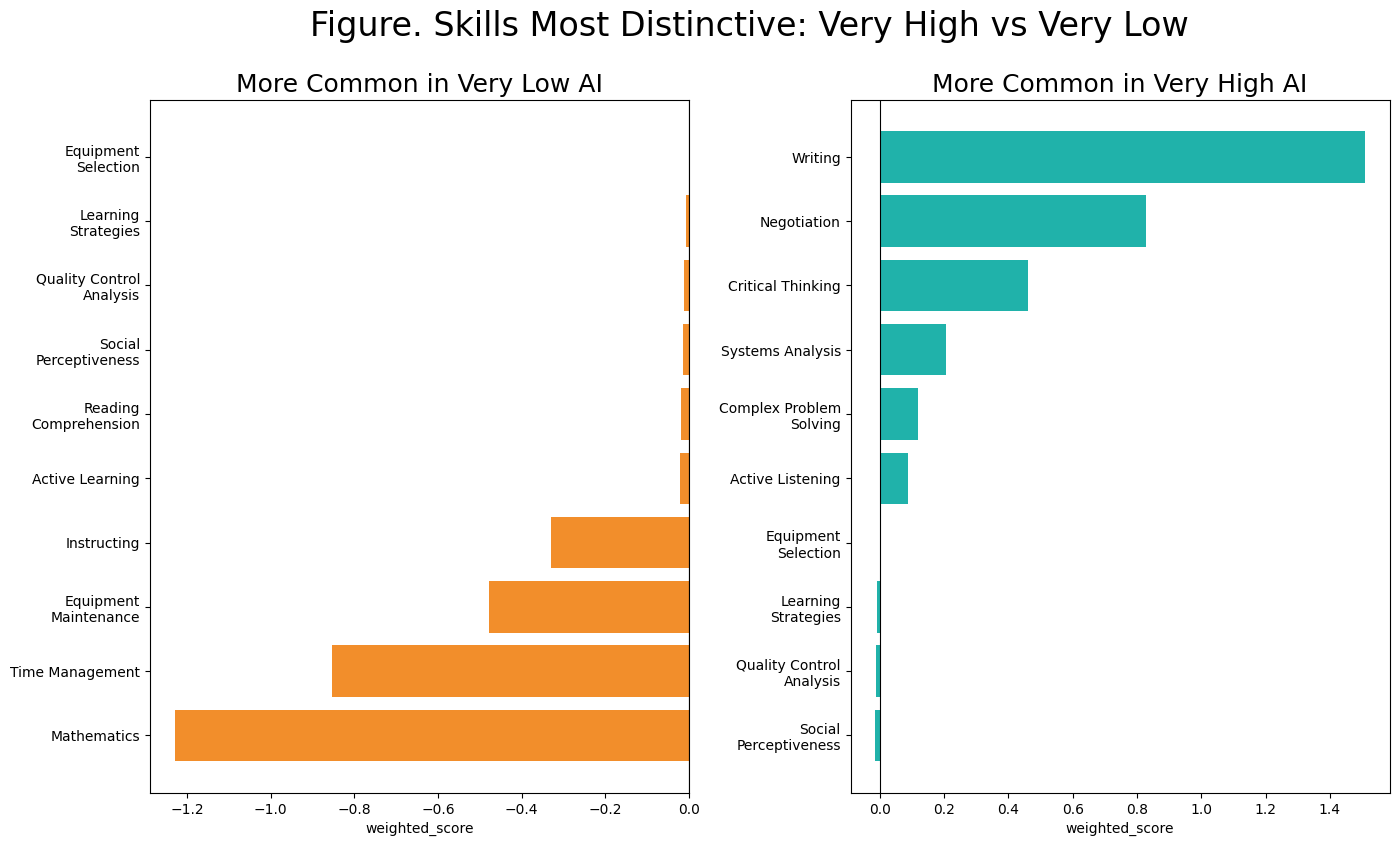

C:\Users\301533\AppData\Local\Temp\ipykernel_15236\3396554526.py:290: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



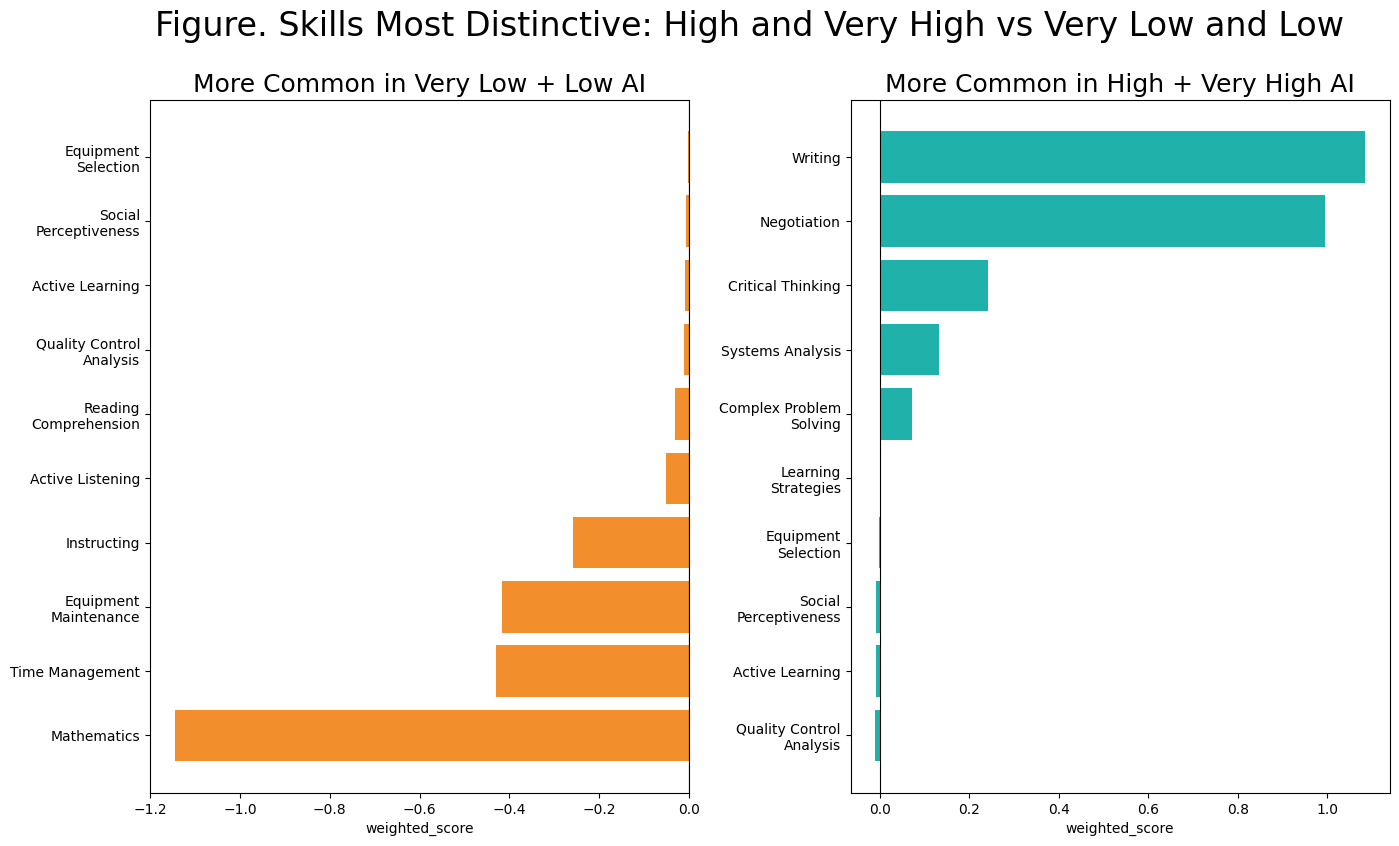

C:\Users\301533\AppData\Local\Temp\ipykernel_15236\3396554526.py:290: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



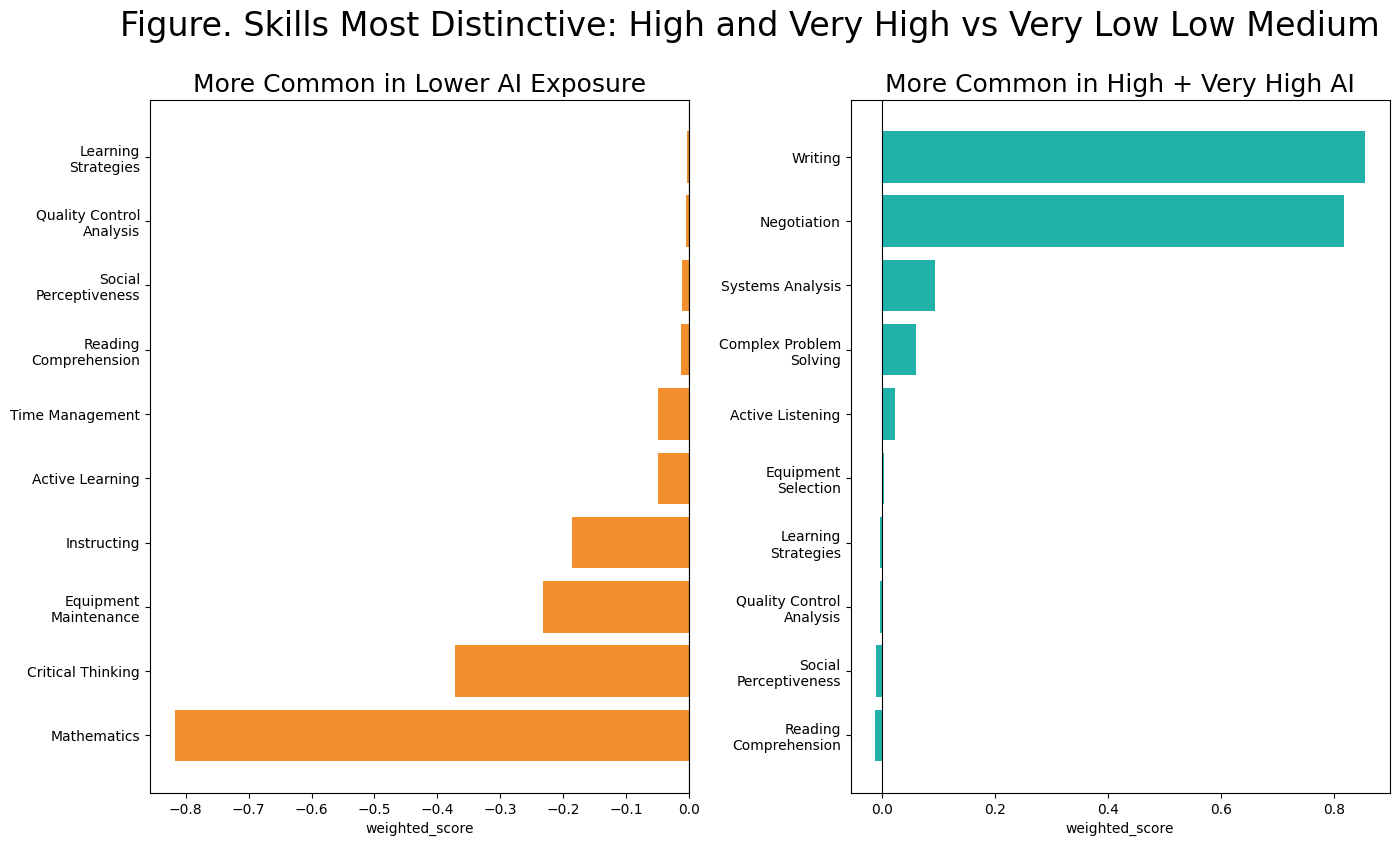

C:\Users\301533\AppData\Local\Temp\ipykernel_15236\3396554526.py:290: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



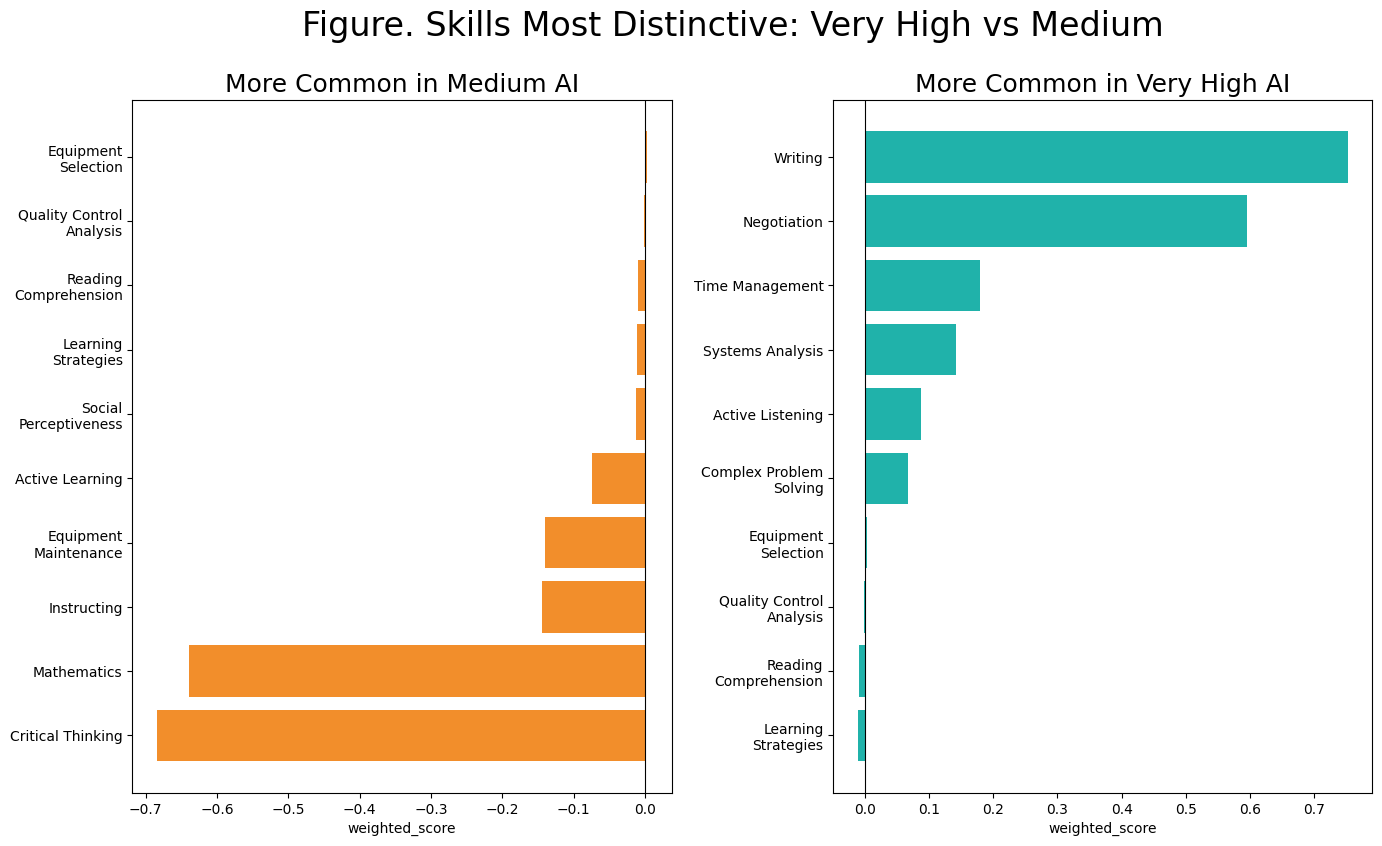

C:\Users\301533\AppData\Local\Temp\ipykernel_15236\3396554526.py:290: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



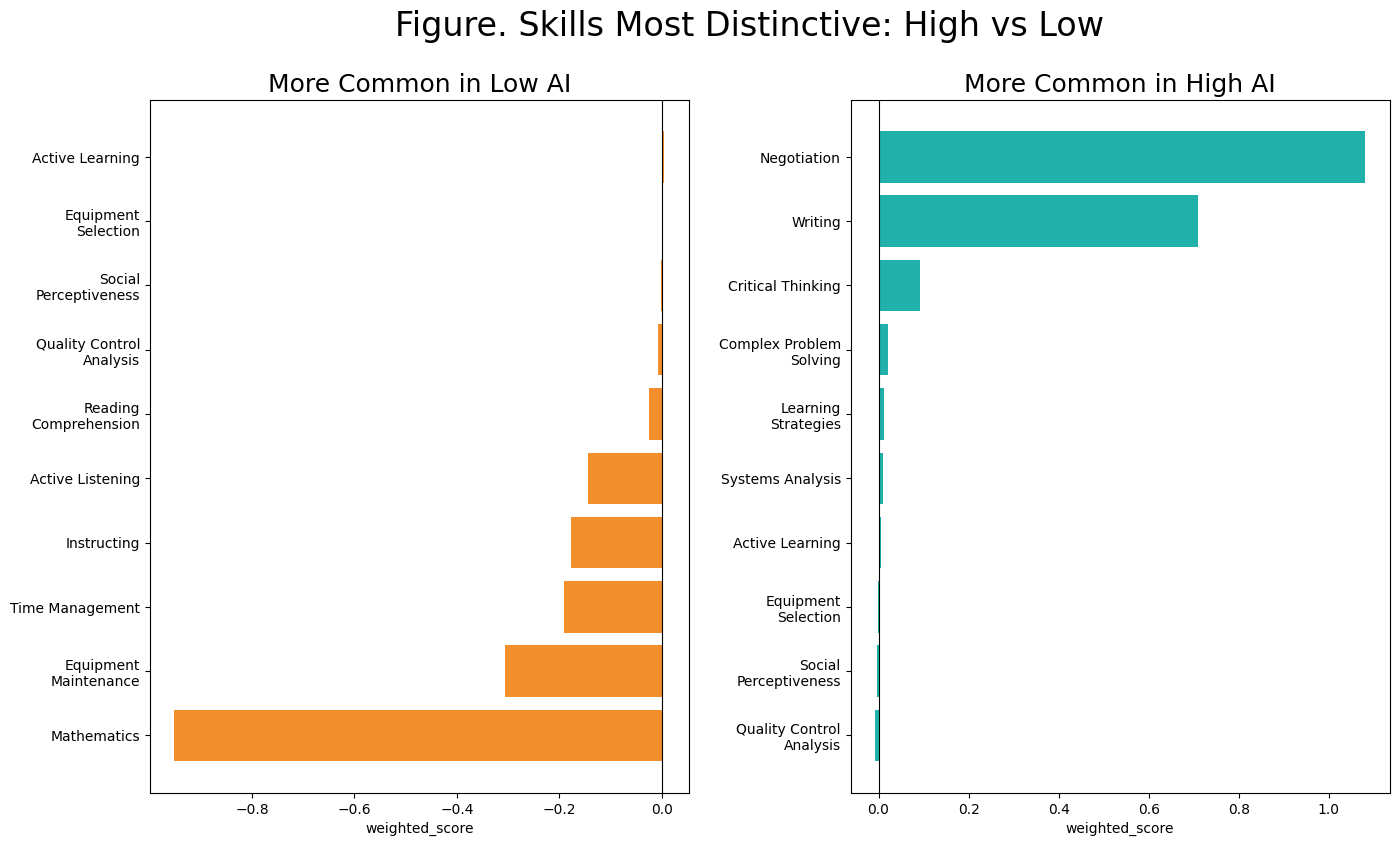

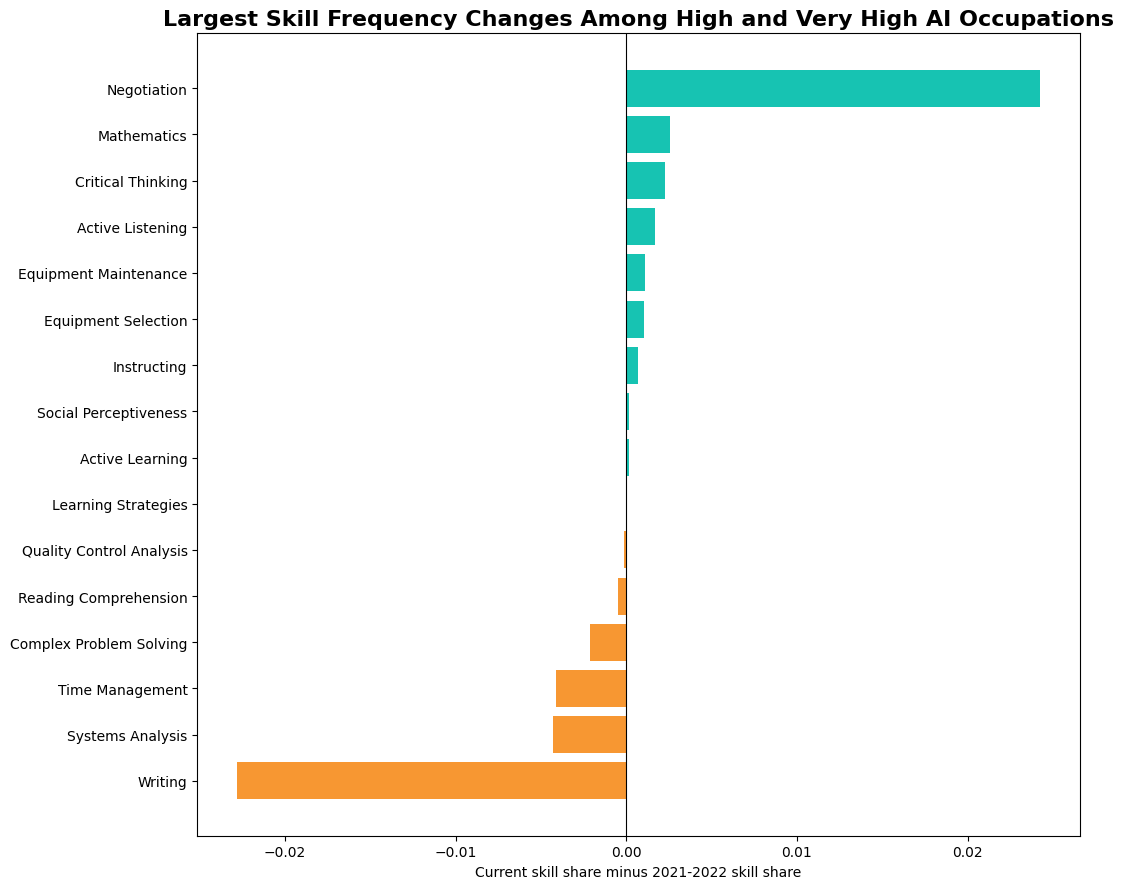


DONE.
Outputs saved to: C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO\Skill Outputs

Top matched posting skills:
                       Skill   Count
15                   Writing  835319
14           Time Management  510978
8                Mathematics  320787
3          Critical Thinking  226464
9                Negotiation  164824
1           Active Listening   45269
4      Equipment Maintenance   32339
2    Complex Problem Solving   28904
6                Instructing   26569
13          Systems Analysis   25971
0            Active Learning    8363
11     Reading Comprehension    8023
7        Learning Strategies    3633
12     Social Perceptiveness    3250
5        Equipment Selection    2112
10  Quality Control Analysis    1046

Exposure totals:
Exposure
Very Low      92172
Low          172754
Medium       479242
High         569121
Very High    930562
Name: Count, dtype: int64


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
import textwrap
import re
import ast
import json

# =========================================================
# PATHS
# =========================================================

VERY_HIGH_FOLDER = Path(
    r"C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO"
)

HIGH_FOLDER = Path(
    r"C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO\High AI"
)

POSTINGS_FILE = Path(
    r"G:\Shared drives\EO_OPERATIONS\Grants\PCIC Analysis\Job Posting Data\raw_data\df_2016_2025.csv"
)

AI_COMPOSITE_FILE = Path(
    r"G:\Shared drives\EO_ECONOMIC ANALYSIS\ea_common\Projects\AI\risk_index\ai_exposure_composite_clean.csv"
)

OUT_FOLDER = Path(
    r"C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO\Skill Outputs"
)
OUT_FOLDER.mkdir(parents=True, exist_ok=True)

# =========================================================
# SETTINGS
# =========================================================

SOC_COL = "SOC_5"
YEAR_COL = "YEAR"
CHUNK_SIZE = 250_000
TOP_N_FIGURE = 15

PRE_YEARS = [2021, 2022]
CURRENT_YEARS = [2025]

EXPOSURE_ORDER = ["Very Low", "Low", "Medium", "High", "Very High"]

PATINA = "#17C3B2"
CARROT = "#F79732"

# =========================================================
# HELPERS
# =========================================================

def clean_skill_name(x):
    return (
        str(x)
        .strip()
        .lower()
        .replace("’", "'")
        .replace("–", "-")
        .replace("—", "-")
    )

def wrap(text, width=24):
    return "\n".join(textwrap.wrap(str(text), width))

def standardize_exposure(x):
    s = str(x).strip()

    mapping = {
        "very low": "Very Low",
        "low": "Low",
        "medium": "Medium",
        "high": "High",
        "very high": "Very High"
    }

    return mapping.get(s.lower(), s)

def fix_soc(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip().replace(".0", "")

    if re.match(r"^\d{2}-\d{4}$", s):
        return s

    if s.startswith("Nov-"):
        nov_map = {
            "11": "11-2011",
            "21": "11-2021",
            "22": "11-2022",
            "32": "11-2032",
            "33": "11-2033",
            "12": "11-3012",
            "13": "11-3013",
            "31": "11-3031",
            "51": "11-3051",
            "61": "11-3061",
            "71": "11-3071",
            "41": "11-9041",
            "72": "11-9072",
            "81": "11-9081",
            "79": "11-9179",
            "99": "11-9199",
        }
        return nov_map.get(s.replace("Nov-", "").strip(), np.nan)

    return s

def parse_skill_list(x):
    if pd.isna(x):
        return []

    s = str(x).strip()

    if s in ["", "[]", "nan", "None"]:
        return []

    try:
        parsed = ast.literal_eval(s)
        if isinstance(parsed, list):
            return [str(v).strip() for v in parsed if str(v).strip()]
    except:
        pass

    try:
        parsed = json.loads(s)
        if isinstance(parsed, list):
            return [str(v).strip() for v in parsed if str(v).strip()]
    except:
        pass

    return [v.strip() for v in s.split(",") if v.strip()]

def find_skill_sheet(xlsx_path):
    xl = pd.ExcelFile(xlsx_path)

    if "Competencies - Skills" in xl.sheet_names:
        return "Competencies - Skills"

    for sheet in xl.sheet_names:
        s = sheet.lower().replace("-", " ")
        if "competencies" in s and "skills" in s:
            return sheet

    return None

def infer_occupation_from_filename(path):
    name = path.stem
    name = re.sub(r"^Skills_Transferability_", "", name)
    name = re.sub(r"_in_(United_States|Arizona).*", "", name)
    name = name.replace("_", " ")
    return name.strip()

def read_lightcast_skill_files(folder, exposure_group):
    rows = []
    files = sorted(folder.glob("Skills_Transferability_*.xlsx"))

    print(f"Reading {exposure_group} Lightcast files: {len(files)}")

    for file in files:
        try:
            sheet = find_skill_sheet(file)
            if sheet is None:
                continue

            df = pd.read_excel(file, sheet_name=sheet, header=2)
            df.columns = df.columns.astype(str).str.strip()

            if "Skill" not in df.columns:
                continue

            keep = [c for c in ["Skill", "Importance", "Level"] if c in df.columns]
            df = df[keep].copy()

            df["Skill"] = df["Skill"].astype(str).str.strip()
            df = df[df["Skill"].str.lower() != "nan"]
            df = df[df["Skill"] != ""]
            df = df[df["Skill"].str.lower() != "skill"]

            df["skill_clean"] = df["Skill"].apply(clean_skill_name)
            df["Lightcast Exposure Source"] = exposure_group
            df["Lightcast Occupation"] = infer_occupation_from_filename(file)
            df["Source File"] = file.name

            rows.append(df)

        except Exception as e:
            print(f"Error reading {file.name}: {e}")

    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

def build_lightcast_word_bank():
    very_high = read_lightcast_skill_files(VERY_HIGH_FOLDER, "Very High")
    high = read_lightcast_skill_files(HIGH_FOLDER, "High")

    raw = pd.concat([very_high, high], ignore_index=True)

    bank = (
        raw.groupby("skill_clean", as_index=False)
        .agg(
            Skill=("Skill", "first"),
            Lightcast_Mentions=("Skill", "size"),
            Lightcast_Occupation_Count=("Lightcast Occupation", "nunique")
        )
        .sort_values(
            ["Lightcast_Occupation_Count", "Lightcast_Mentions"],
            ascending=[False, False]
        )
    )

    return raw, bank

def build_comparison(agg, high_groups, low_groups, comparison_name):
    high = (
        agg[agg["Exposure"].isin(high_groups)]
        .groupby(["Skill", "skill_clean"], as_index=False)
        .agg(Count_High=("Count", "sum"))
    )

    low = (
        agg[agg["Exposure"].isin(low_groups)]
        .groupby(["Skill", "skill_clean"], as_index=False)
        .agg(Count_Low=("Count", "sum"))
    )

    out = high.merge(low, on=["Skill", "skill_clean"], how="outer").fillna(0)

    total_high = out["Count_High"].sum()
    total_low = out["Count_Low"].sum()

    out["Freq_High"] = out["Count_High"] / total_high if total_high > 0 else 0
    out["Freq_Low"] = out["Count_Low"] / total_low if total_low > 0 else 0

    out["log_ratio"] = np.log((out["Count_High"] + 1) / (out["Count_Low"] + 1))
    out["share_diff"] = out["Freq_High"] - out["Freq_Low"]
    out["Total_Mentions"] = out["Count_High"] + out["Count_Low"]
    out["weighted_score"] = out["share_diff"] * np.log1p(out["Total_Mentions"])
    out["Comparison"] = comparison_name

    return out.sort_values("weighted_score", ascending=False)

def plot_comparison(df, title, left_title, right_title, out_file, score_col="weighted_score"):
    if df.empty:
        print(f"Skipping blank plot, no data for: {title}")
        return

    high = df.sort_values(score_col, ascending=False).head(10).copy()
    low = df.sort_values(score_col, ascending=True).head(10).copy()

    high = high.sort_values(score_col, ascending=True)
    low = low.sort_values(score_col, ascending=True)

    fig, (ax1, ax2) = plt.subplots(
        1,
        2,
        figsize=(16, 9),
        gridspec_kw={"wspace": 0.30}
    )

    # LEFT SIDE
    ax1.barh(
        [wrap(x, width=18) for x in low["Skill"]],
        low[score_col],
        color="#F28E2B"
    )

    ax1.set_title(left_title, fontsize=18)
    ax1.set_xlabel(score_col)
    ax1.axvline(0, color="black", linewidth=0.8)

    # RIGHT SIDE
    ax2.barh(
        [wrap(x, width=18) for x in high["Skill"]],
        high[score_col],
        color="#20B2AA"
    )

    ax2.set_title(right_title, fontsize=18)
    ax2.set_xlabel(score_col)
    ax2.axvline(0, color="black", linewidth=0.8)

    fig.suptitle(title, fontsize=24)

    plt.tight_layout()
    plt.savefig(out_file, dpi=300, bbox_inches="tight")
    plt.show()
    
def build_time_comparison_from_agg(time_agg):
    temp = time_agg.copy()
    temp["Year"] = pd.to_numeric(temp["Year"], errors="coerce")

    temp["Period"] = None
    temp.loc[temp["Year"].isin(PRE_YEARS), "Period"] = "Pre AI, 2021-2022"
    temp.loc[temp["Year"].isin(CURRENT_YEARS), "Period"] = "Current"

    temp = temp[temp["Period"].notna()].copy()
    temp = temp[temp["Exposure"].isin(["High", "Very High"])].copy()

    period_counts = (
        temp.groupby(["Skill", "skill_clean", "Period"], as_index=False)
        .agg(Count=("Count", "sum"))
    )

    wide = period_counts.pivot_table(
        index=["Skill", "skill_clean"],
        columns="Period",
        values="Count",
        fill_value=0
    ).reset_index()

    for col in ["Pre AI, 2021-2022", "Current"]:
        if col not in wide.columns:
            wide[col] = 0

    total_pre = wide["Pre AI, 2021-2022"].sum()
    total_current = wide["Current"].sum()

    wide["Freq_Pre"] = wide["Pre AI, 2021-2022"] / total_pre if total_pre > 0 else 0
    wide["Freq_Current"] = wide["Current"] / total_current if total_current > 0 else 0

    wide["Change"] = wide["Freq_Current"] - wide["Freq_Pre"]
    wide["Abs_Change"] = wide["Change"].abs()

    return wide.sort_values("Abs_Change", ascending=False)

def plot_time_change(df, out_file, top_n=20):
    if df.empty:
        print("Skipping time-change plot, no data.")
        return

    plot_df = df.head(top_n).sort_values("Change", ascending=True)
    colors = np.where(plot_df["Change"] >= 0, PATINA, CARROT)

    plt.figure(figsize=(11, 9))
    plt.barh([wrap(x) for x in plot_df["Skill"]], plot_df["Change"], color=colors)
    plt.axvline(0, color="black", linewidth=0.8)

    plt.title(
        "Largest Skill Frequency Changes Among High and Very High AI Occupations",
        fontsize=16,
        weight="bold"
    )
    plt.xlabel("Current skill share minus 2021-2022 skill share")
    plt.ylabel("")
    plt.tight_layout()
    plt.savefig(out_file, dpi=300, bbox_inches="tight")
    plt.show()

# =========================================================
# STEP 1: BUILD LIGHTCAST APPROVED WORD BANK
# =========================================================

lightcast_raw, word_bank = build_lightcast_word_bank()
word_bank_set = set(word_bank["skill_clean"])

lightcast_raw.to_excel(
    OUT_FOLDER / "Step1_Lightcast_All_Approved_Skills_Raw.xlsx",
    index=False
)

word_bank.to_excel(
    OUT_FOLDER / "Step1_Lightcast_Approved_Skill_Word_Bank.xlsx",
    index=False
)

print("\nSTEP 1 DONE")
print(f"Lightcast raw rows: {len(lightcast_raw):,}")
print(f"Approved unique skills: {word_bank['skill_clean'].nunique():,}")

# =========================================================
# STEP 2: LOAD 5-LEVEL AI EXPOSURE LOOKUP
# =========================================================

ai = pd.read_csv(AI_COMPOSITE_FILE)
ai.columns = ai.columns.astype(str).str.strip()

ai["SOC"] = ai["SOC"].apply(fix_soc)
ai["Exposure"] = ai["AI Exposure Category"].astype(str).str.strip().apply(standardize_exposure)

ai_lookup = (
    ai[["SOC", "Exposure"]]
    .dropna()
    .drop_duplicates(subset=["SOC"])
)

exposure_map = dict(zip(ai_lookup["SOC"], ai_lookup["Exposure"]))

print("\nAI composite exposure counts:")
print(ai_lookup["Exposure"].value_counts(dropna=False))

# =========================================================
# STEP 3: FAST COUNT POSTING SKILLS USING COMPOSITE EXPOSURE
# =========================================================

skill_counter = Counter()
soc2_counter = Counter()
time_counter = Counter()

usecols = [
    SOC_COL,
    YEAR_COL,
    "SKILLS_NAME",
    "SOFTWARE_SKILLS_NAME"
]

total_rows_processed = 0
total_skill_matches = 0

for i, chunk in enumerate(
    pd.read_csv(
        POSTINGS_FILE,
        usecols=lambda c: c in usecols,
        chunksize=CHUNK_SIZE,
        low_memory=False
    ),
    start=1
):
    chunk[SOC_COL] = chunk[SOC_COL].astype(str).str.strip()
    chunk[YEAR_COL] = pd.to_numeric(chunk[YEAR_COL], errors="coerce")

    chunk = chunk[chunk[SOC_COL].str.match(r"^\d{2}-\d{4}$", na=False)].copy()
    chunk["Exposure"] = chunk[SOC_COL].map(exposure_map)
    chunk["Exposure"] = chunk["Exposure"].apply(standardize_exposure)

    chunk = chunk[chunk["Exposure"].isin(EXPOSURE_ORDER)].copy()

    for row in chunk.itertuples(index=False):
        row_dict = row._asdict()

        soc = row_dict[SOC_COL]
        soc2 = str(soc)[:2]
        year = row_dict[YEAR_COL]
        exposure = row_dict["Exposure"]

        skills = (
            parse_skill_list(row_dict.get("SKILLS_NAME")) +
            parse_skill_list(row_dict.get("SOFTWARE_SKILLS_NAME"))
        )

        if not skills:
            continue

        for skill in set(skills):
            skill_clean = clean_skill_name(skill)

            if skill_clean not in word_bank_set:
                continue

            skill_counter[(skill, skill_clean, exposure)] += 1
            soc2_counter[(soc2, exposure, skill, skill_clean)] += 1

            if pd.notna(year):
                time_counter[(skill, skill_clean, exposure, int(year))] += 1

            total_skill_matches += 1

    total_rows_processed += len(chunk)

    print(
        f"Processed chunk {i}. "
        f"Rows processed: {total_rows_processed:,}. "
        f"Skill matches counted: {total_skill_matches:,}."
    )

# =========================================================
# STEP 4: CONVERT COUNTS TO DATAFRAMES
# =========================================================

agg = pd.DataFrame([
    {
        "Skill": k[0],
        "skill_clean": k[1],
        "Exposure": k[2],
        "Count": v
    }
    for k, v in skill_counter.items()
])

soc2_output = pd.DataFrame([
    {
        "SOC2": k[0],
        "Exposure": k[1],
        "Skill": k[2],
        "skill_clean": k[3],
        "Count": v
    }
    for k, v in soc2_counter.items()
])

time_agg = pd.DataFrame([
    {
        "Skill": k[0],
        "skill_clean": k[1],
        "Exposure": k[2],
        "Year": k[3],
        "Count": v
    }
    for k, v in time_counter.items()
])

agg.to_excel(
    OUT_FOLDER / "Step3_Skill_Counts_By_AI_Exposure_5Level.xlsx",
    index=False
)

soc2_output.to_excel(
    OUT_FOLDER / "Step6_Skill_Counts_By_SOC2_Exposure_5Level.xlsx",
    index=False
)

time_agg.to_excel(
    OUT_FOLDER / "Step5_Skill_Counts_By_Year_Exposure_5Level.xlsx",
    index=False
)

print("\nSTEP 4 DONE")
print(f"Skill matches counted: {total_skill_matches:,}")
print(f"Skill-exposure rows: {len(agg):,}")
print("\nCounts by exposure:")
print(agg.groupby("Exposure")["Count"].sum().sort_values(ascending=False))

# =========================================================
# STEP 5: BUILD COMPARISONS
# =========================================================

comparisons = {
    "Very High vs Very Low": {
        "high": ["Very High"],
        "low": ["Very Low"],
        "left": "More Common in Very Low AI",
        "right": "More Common in Very High AI"
    },
    "High and Very High vs Very Low and Low": {
        "high": ["High", "Very High"],
        "low": ["Very Low", "Low"],
        "left": "More Common in Very Low + Low AI",
        "right": "More Common in High + Very High AI"
    },
    "High and Very High vs Very Low Low Medium": {
        "high": ["High", "Very High"],
        "low": ["Very Low", "Low", "Medium"],
        "left": "More Common in Lower AI Exposure",
        "right": "More Common in High + Very High AI"
    },
    "Very High vs Medium": {
        "high": ["Very High"],
        "low": ["Medium"],
        "left": "More Common in Medium AI",
        "right": "More Common in Very High AI"
    },
    "High vs Low": {
        "high": ["High"],
        "low": ["Low"],
        "left": "More Common in Low AI",
        "right": "More Common in High AI"
    }
}

all_outputs = []

for name, groups in comparisons.items():
    comp = build_comparison(
        agg,
        high_groups=groups["high"],
        low_groups=groups["low"],
        comparison_name=name
    )

    safe_name = re.sub(r"[^A-Za-z0-9]+", "_", name).strip("_")

    comp.to_excel(
        OUT_FOLDER / f"Step4_Comparison_{safe_name}_5Level.xlsx",
        index=False
    )

    plot_comparison(
        comp,
        title=f"Figure. Skills Most Distinctive: {name}",
        left_title=groups["left"],
        right_title=groups["right"],
        out_file=OUT_FOLDER / f"Figure_{safe_name}_Weighted_Score_5Level.png"
    )

    all_outputs.append(comp)

all_comparisons = pd.concat(all_outputs, ignore_index=True)

all_comparisons.to_excel(
    OUT_FOLDER / "Step4_All_Exposure_Comparisons_5Level.xlsx",
    index=False
)

# =========================================================
# STEP 6: TIME CHANGE
# =========================================================

time_change = build_time_comparison_from_agg(time_agg)

time_change.to_excel(
    OUT_FOLDER / "Step5_Skill_Change_High_VeryHigh_PreAI_vs_Current_5Level.xlsx",
    index=False
)

plot_time_change(
    time_change,
    OUT_FOLDER / "Figure_Skill_Change_High_VeryHigh_PreAI_vs_Current_5Level.png",
    top_n=20
)

# =========================================================
# FINAL CHECKS
# =========================================================

print("\nDONE.")
print(f"Outputs saved to: {OUT_FOLDER}")

print("\nTop matched posting skills:")
print(
    agg.groupby("Skill", as_index=False)
    .agg(Count=("Count", "sum"))
    .sort_values("Count", ascending=False)
    .head(20)
)

print("\nExposure totals:")
print(agg.groupby("Exposure")["Count"].sum().reindex(EXPOSURE_ORDER))

# Program Record Builder

## Script
Single row DataFrame → Excel

## Purpose
Create a single program record and export it

## What it does
- Builds a dictionary with program details
- Converts dictionary to DataFrame
- Exports to Excel (pima_programs.xlsx)

## Key Notes
- Assumes variables already exist
- Used for testing or manual entry

In [ ]:
import pandas as pd
import numpy as np
import re
from pathlib import Path

# =========================================================
# CONFIG
# =========================================================

INPUT_FILE = Path(r"C:\Users\301533\Documents\AI Analysis\AI Exposure Sheet\ai_exposure_composite.csv.xlsx")
OUTPUT_DIR = Path(r"C:\Users\301533\Documents\AI Analysis\AI Exposure Sheet\outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================================================
# LOAD
# =========================================================

# Change to read_csv(...) if needed
df = pd.read_excel(INPUT_FILE)

# Clean column names
df.columns = [str(c).strip() for c in df.columns]

print("Loaded rows:", len(df))
print("Columns:")
for c in df.columns:
    print("-", c)

# =========================================================
# EXPECTED COLUMNS
# =========================================================

PCA_COL = "PCA Weighted Score.1"
Z_COL = "Z Score Variance.1"
TITLE_COL = "Title"
DESC_COL = "Description"

# Try these in priority order for SOC columns
SOC_CANDIDATES = ["SOC2018.1", "O*NET-SOC Code", "SOC Code", "SOC Code1"]

WAGE_COL = "50th Percentile Wage"
OPENINGS_COL = "Annual Total Openings"
GROWTH_COL = "GrowthRate"
GROWTH_PCT_STR_COL = "Annual Percent Change"
EMPLOYMENT_COL = "Rounded Employment"
EDU_COL = "EducationValue"
WORKEXP_COL = "WorkExperienceValue"

# =========================================================
# HELPERS
# =========================================================

def first_existing_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of these columns were found: {candidates}")

RAW_SOC_COL = first_existing_col(df, SOC_CANDIDATES)

def clean_money(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace(r"[\$,]", "", regex=True).str.strip(),
        errors="coerce"
    )

def clean_numeric(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace(",", "", regex=False).str.strip(),
        errors="coerce"
    )

def clean_percent_string(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace("%", "", regex=False).str.strip(),
        errors="coerce"
    )

# =========================================================
# FIX EXCEL-MANGLED SOC CODES
# =========================================================
# Excel auto-converted some 11-xxxx SOC codes into date-like values such as:
# Nov-11, Nov-21, Nov-31, etc.
#
# This function repairs them.
#
# Strategy:
# 1. Keep already-valid SOC codes as-is
# 2. Use title-based overrides for known 11-xxxx occupations
# 3. Fallback for Nov-YY = 11-20YY, which correctly restores many 11-20xx codes
#
# Note:
# The title override dictionary is the safest way to recover the 11-group manager/admin codes.

TITLE_TO_SOC_OVERRIDE = {
    # 11-2xxx
    "Advertising and Promotions Managers": "11-2011",
    "Compensation and Benefits Managers": "11-2021",
    "Human Resources Managers": "11-2021",
    "Training and Development Managers": "11-2021",
    "Marketing Managers": "11-2021",
    "Sales Managers": "11-2022",
    "Public Relations Managers": "11-2032",
    "Fundraising Managers": "11-2033",

    # 11-3xxx
    "Administrative Services Managers": "11-3012",
    "Facilities Managers": "11-3013",
    "Security Managers": "11-3013",
    "Computer and Information Systems Managers": "11-3021",
    "Financial Managers": "11-3031",
    "Treasurers and Controllers": "11-3031",
    "Investment Fund Managers": "11-3031",
    "Education and Childcare Administrators, Preschool and Daycare": "11-9031",
    "Education Administrators, Kindergarten through Secondary": "11-9032",
    "Education Administrators, Postsecondary": "11-9033",

    # 11-4xxx
    "Architectural and Engineering Managers": "11-9041",
    "Biofuels/Biodiesel Technology and Product Development Managers": "11-9041",

    # 11-5xxx
    "Industrial Production Managers": "11-3051",
    "Quality Control Systems Managers": "11-3051",
    "Geothermal Production Managers": "11-3051",
    "Biofuels Production Managers": "11-3051",
    "Biomass Power Plant Managers": "11-3051",
    "Hydroelectric Production Managers": "11-3051",
    "Food Service Managers": "11-9051",
    "Medical and Health Services Managers": "11-9111",
    "Natural Sciences Managers": "11-9121",
    "Clinical Research Coordinators": "11-9121",
    "Water Resource Specialists": "11-9121",
    "Postmasters and Mail Superintendents": "11-9131",
    "Property, Real Estate, and Community Association Managers": "11-9141",
    "Social and Community Service Managers": "11-9151",
    "Emergency Management Directors": "11-9161",
    "Funeral Home Managers": "11-9171",
    "Personal Service Managers, All Other": "11-9179",
    "Fitness and Wellness Coordinators": "11-9179",
    "Spa Managers": "11-9179",
    "Managers, All Other": "11-9199",
    "Regulatory Affairs Managers": "11-9199",
    "Compliance Managers": "11-9199",
    "Loss Prevention Managers": "11-9199",
    "Wind Energy Operations Managers": "11-9199",
    "Wind Energy Development Managers": "11-9199",
    "Brownfield Redevelopment Specialists and Site Managers": "11-9199",

    # 11-6xxx, 11-7xxx, etc.
    "Purchasing Managers": "11-3061",
    "Transportation, Storage, and Distribution Managers": "11-3071",
    "Supply Chain Managers": "11-3071",
    "Gambling Managers": "11-9071",
    "Entertainment and Recreation Managers, Except Gambling": "11-9072",
    "Lodging Managers": "11-9081",
}

VALID_SOC_PATTERN = re.compile(r"^\d{2}-\d{4}$")
NOV_PATTERN = re.compile(r"^Nov-(\d{2})$", re.IGNORECASE)

def fix_soc_code(raw_soc, title):
    if pd.isna(raw_soc):
        raw_soc = ""
    s = str(raw_soc).strip()

    # already valid
    if VALID_SOC_PATTERN.match(s):
        return s

    # title-based override
    if pd.notna(title):
        t = str(title).strip()
        if t in TITLE_TO_SOC_OVERRIDE:
            return TITLE_TO_SOC_OVERRIDE[t]

    # fallback for Nov-YY -> 11-20YY
    m = NOV_PATTERN.match(s)
    if m:
        yy = m.group(1)
        return f"11-20{yy}"

    return np.nan

df["soc_code_clean"] = df.apply(lambda x: fix_soc_code(x.get(RAW_SOC_COL), x.get(TITLE_COL)), axis=1)

# If some rows are still missing, try other SOC candidate columns
for alt_col in SOC_CANDIDATES:
    if alt_col in df.columns and alt_col != RAW_SOC_COL:
        missing_mask = df["soc_code_clean"].isna()
        df.loc[missing_mask, "soc_code_clean"] = df.loc[missing_mask].apply(
            lambda x: fix_soc_code(x.get(alt_col), x.get(TITLE_COL)),
            axis=1
        )

# Flag unresolved SOCs
unresolved = df[df["soc_code_clean"].isna()].copy()
if len(unresolved) > 0:
    unresolved.to_csv(OUTPUT_DIR / "unresolved_soc_codes.csv", index=False)
    print(f"Unresolved SOC rows exported: {len(unresolved)}")
else:
    print("All SOC codes resolved.")

# =========================================================
# CLEAN METRICS
# =========================================================

df["pca_score"] = clean_numeric(df[PCA_COL])
df["z_score"] = clean_numeric(df[Z_COL])

df["wage"] = clean_money(df[WAGE_COL])
df["openings"] = clean_numeric(df[OPENINGS_COL])
df["growth_rate"] = clean_numeric(df[GROWTH_COL])

# fallback if GrowthRate is missing
if df["growth_rate"].isna().all() and GROWTH_PCT_STR_COL in df.columns:
    df["growth_rate"] = clean_percent_string(df[GROWTH_PCT_STR_COL])

df["employment"] = clean_numeric(df[EMPLOYMENT_COL])

# =========================================================
# DEDUPLICATE TO ONE ROW PER SOC
# =========================================================
# Important:
# Your file includes multiple O*NET titles mapped to the same SOC.
# For AI Table 1, you want ONE row per SOC, otherwise some SOCs get overcounted.

def first_non_null(series):
    s = series.dropna()
    return s.iloc[0] if len(s) > 0 else np.nan

soc_level = (
    df.groupby("soc_code_clean", as_index=False)
      .agg({
          "pca_score": "mean",
          "z_score": "mean",
          "wage": "median",
          "openings": "median",
          "growth_rate": "median",
          "employment": "median",
          TITLE_COL: first_non_null,
          EDU_COL: first_non_null if EDU_COL in df.columns else "first",
          WORKEXP_COL: first_non_null if WORKEXP_COL in df.columns else "first"
      })
)

# =========================================================
# BUILD 5 AI EXPOSURE TIERS BY QUINTILE
# =========================================================

# Drop rows missing PCA score before qcut
soc_level = soc_level[~soc_level["pca_score"].isna()].copy()

soc_level["exposure_group"] = pd.qcut(
    soc_level["pca_score"],
    5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)

# ordered category
soc_level["exposure_group"] = pd.Categorical(
    soc_level["exposure_group"],
    categories=["Very Low", "Low", "Medium", "High", "Very High"],
    ordered=True
)

# =========================================================
# BUILD AI TABLE 1 (UNWEIGHTED)
# =========================================================

table1 = (
    soc_level.groupby("exposure_group", observed=False)
    .agg(
        Median_Wage=("wage", "median"),
        Mean_Growth_Rate=("growth_rate", "mean"),
        Mean_Annual_Openings=("openings", "mean"),
        Median_Employment=("employment", "median"),
        Occupation_Count=("soc_code_clean", "count")
    )
    .reset_index()
)

# Pretty formatting copy
table1_fmt = table1.copy()
table1_fmt["Median_Wage"] = table1_fmt["Median_Wage"].map(lambda x: f"${x:,.0f}" if pd.notna(x) else "")
table1_fmt["Mean_Growth_Rate"] = table1_fmt["Mean_Growth_Rate"].map(lambda x: f"{x:.2f}%" if pd.notna(x) else "")
table1_fmt["Mean_Annual_Openings"] = table1_fmt["Mean_Annual_Openings"].map(lambda x: f"{x:,.0f}" if pd.notna(x) else "")
table1_fmt["Median_Employment"] = table1_fmt["Median_Employment"].map(lambda x: f"{x:,.0f}" if pd.notna(x) else "")

# Pivot version for presentation
table1_pivot = table1.set_index("exposure_group")[[
    "Median_Wage", "Mean_Growth_Rate", "Mean_Annual_Openings", "Median_Employment", "Occupation_Count"
]].T

table1_pivot_fmt = table1_fmt.set_index("exposure_group")[[
    "Median_Wage", "Mean_Growth_Rate", "Mean_Annual_Openings", "Median_Employment", "Occupation_Count"
]].T

# =========================================================
# BUILD OPTIONAL WEIGHTED VERSION
# =========================================================
# This can be useful if you want the exposure groups weighted by employment.

def weighted_mean(values, weights):
    values = pd.to_numeric(values, errors="coerce")
    weights = pd.to_numeric(weights, errors="coerce")

    mask = values.notna() & weights.notna() & (weights > 0)
    if mask.sum() == 0:
        return np.nan
    return np.average(values[mask], weights=weights[mask])

weighted_rows = []
for grp, sub in soc_level.groupby("exposure_group", observed=False):
    weighted_rows.append({
        "exposure_group": grp,
        "Weighted_Wage": weighted_mean(sub["wage"], sub["employment"]),
        "Weighted_Growth_Rate": weighted_mean(sub["growth_rate"], sub["employment"]),
        "Weighted_Annual_Openings": weighted_mean(sub["openings"], sub["employment"]),
        "Total_Employment": sub["employment"].sum(skipna=True),
        "Occupation_Count": sub["soc_code_clean"].nunique()
    })

table1_weighted = pd.DataFrame(weighted_rows)
table1_weighted["exposure_group"] = pd.Categorical(
    table1_weighted["exposure_group"],
    categories=["Very Low", "Low", "Medium", "High", "Very High"],
    ordered=True
)
table1_weighted = table1_weighted.sort_values("exposure_group")

table1_weighted_fmt = table1_weighted.copy()
table1_weighted_fmt["Weighted_Wage"] = table1_weighted_fmt["Weighted_Wage"].map(lambda x: f"${x:,.0f}" if pd.notna(x) else "")
table1_weighted_fmt["Weighted_Growth_Rate"] = table1_weighted_fmt["Weighted_Growth_Rate"].map(lambda x: f"{x:.2f}%" if pd.notna(x) else "")
table1_weighted_fmt["Weighted_Annual_Openings"] = table1_weighted_fmt["Weighted_Annual_Openings"].map(lambda x: f"{x:,.0f}" if pd.notna(x) else "")
table1_weighted_fmt["Total_Employment"] = table1_weighted_fmt["Total_Employment"].map(lambda x: f"{x:,.0f}" if pd.notna(x) else "")

table1_weighted_pivot = table1_weighted.set_index("exposure_group")[[
    "Weighted_Wage", "Weighted_Growth_Rate", "Weighted_Annual_Openings", "Total_Employment", "Occupation_Count"
]].T

table1_weighted_pivot_fmt = table1_weighted_fmt.set_index("exposure_group")[[
    "Weighted_Wage", "Weighted_Growth_Rate", "Weighted_Annual_Openings", "Total_Employment", "Occupation_Count"
]].T

# =========================================================
# EXPORT
# =========================================================

cleaned_file = OUTPUT_DIR / "ai_exposure_cleaned_soc_level.csv"
table1_file = OUTPUT_DIR / "AI_Table_1_unweighted.csv"
table1_pivot_file = OUTPUT_DIR / "AI_Table_1_unweighted_pivot.csv"
table1_weighted_file = OUTPUT_DIR / "AI_Table_1_weighted.csv"
table1_weighted_pivot_file = OUTPUT_DIR / "AI_Table_1_weighted_pivot.csv"
full_cleaned_rows_file = OUTPUT_DIR / "ai_exposure_full_rows_with_fixed_soc.csv"

df.to_csv(full_cleaned_rows_file, index=False)
soc_level.to_csv(cleaned_file, index=False)
table1.to_csv(table1_file, index=False)
table1_pivot.to_csv(table1_pivot_file)
table1_weighted.to_csv(table1_weighted_file, index=False)
table1_weighted_pivot.to_csv(table1_weighted_pivot_file)

print("\nSaved files:")
print("-", full_cleaned_rows_file)
print("-", cleaned_file)
print("-", table1_file)
print("-", table1_pivot_file)
print("-", table1_weighted_file)
print("-", table1_weighted_pivot_file)

# =========================================================
# PREVIEW
# =========================================================

print("\nCleaned SOC-level preview:")
print(soc_level.head(15))

print("\nAI Table 1 (unweighted):")
print(table1)

print("\nAI Table 1 (presentation pivot):")
print(table1_pivot_fmt)

print("\nAI Table 1 (weighted):")
print(table1_weighted)

print("\nExposure group counts:")
print(soc_level["exposure_group"].value_counts(dropna=False).sort_index())

Loaded rows: 896
Columns:
- SOC2018.1
- PCA Weighted Score.1
- Z Score Variance.1
- O*NET-SOC Code
- Title
- Description
- SOC Code
- Annual Total Openings
- Annual Percent Change
- EducationValue
- WorkExperienceValue
- GrowthRate
- SOC Code1
- 50th Percentile Wage
- Rounded Employment
- exposure
Unresolved SOC rows exported: 2

Saved files:
- C:\Users\301533\Documents\AI Analysis\AI Exposure Sheet\outputs\ai_exposure_full_rows_with_fixed_soc.csv
- C:\Users\301533\Documents\AI Analysis\AI Exposure Sheet\outputs\ai_exposure_cleaned_soc_level.csv
- C:\Users\301533\Documents\AI Analysis\AI Exposure Sheet\outputs\AI_Table_1_unweighted.csv
- C:\Users\301533\Documents\AI Analysis\AI Exposure Sheet\outputs\AI_Table_1_unweighted_pivot.csv
- C:\Users\301533\Documents\AI Analysis\AI Exposure Sheet\outputs\AI_Table_1_weighted.csv
- C:\Users\301533\Documents\AI Analysis\AI Exposure Sheet\outputs\AI_Table_1_weighted_pivot.csv

Cleaned SOC-level preview:
   soc_code_clean  pca_score   z_score      

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

# =========================================================
# FILE PATHS
# =========================================================

AI_FILE = Path(r"C:\Users\301533\Documents\AI Analysis\AI Exposure Sheet\outputs\AI_Master_Output.xlsx")
RELATED_FILE = Path(r"C:\Users\301533\Documents\AI Analysis\Related Occupations.xlsx")
CROSSWALK_FILE = Path(r"C:\Users\301533\Documents\AI Analysis\2019_to_SOC_Crosswalk.xlsx")

OUTPUT_FILE = Path(r"C:\Users\301533\Documents\AI Analysis\AI_NorthStar_Transitions.xlsx")

# =========================================================
# LOAD AI MASTER OUTPUT
# =========================================================
# This uses your already-cleaned 6-digit SOC file

ai = pd.read_excel(AI_FILE, sheet_name="SOC_Level_Cleaned", dtype=str)
ai.columns = ai.columns.str.strip()

# Clean numeric fields
for col in ["pca_score", "z_score", "wage", "openings", "growth_rate", "employment"]:
    ai[col] = pd.to_numeric(ai[col], errors="coerce")

ai["soc_code_clean"] = ai["soc_code_clean"].astype(str).str.strip()
ai["exposure_group"] = ai["exposure_group"].astype(str).str.strip()

# =========================================================
# LOAD RELATED OCCUPATIONS
# =========================================================

rel = pd.read_excel(RELATED_FILE, dtype=str)
rel.columns = rel.columns.str.strip()

# Keep only needed columns
rel = rel[[
    "O*NET-SOC Code",
    "Title",
    "Related O*NET-SOC Code",
    "Related Title",
    "Relatedness Tier",
    "Index"
]].copy()

rel = rel.rename(columns={
    "O*NET-SOC Code": "from_onet_2019",
    "Title": "from_onet_title",
    "Related O*NET-SOC Code": "to_onet_2019",
    "Related Title": "to_onet_title",
    "Relatedness Tier": "relatedness_tier",
    "Index": "related_index"
})

rel["from_onet_2019"] = rel["from_onet_2019"].astype(str).str.strip()
rel["to_onet_2019"] = rel["to_onet_2019"].astype(str).str.strip()
rel["related_index"] = pd.to_numeric(rel["related_index"], errors="coerce")

# =========================================================
# LOAD CROSSWALK
# =========================================================
# IMPORTANT: this file has extra text rows before the real header
# so use header=3

cross = pd.read_excel(CROSSWALK_FILE, header=3, dtype=str)
cross.columns = cross.columns.str.strip()

cross = cross[[
    "O*NET-SOC 2019 Code",
    "O*NET-SOC 2019 Title",
    "2018 SOC Code",
    "2018 SOC Title"
]].copy()

cross = cross.rename(columns={
    "O*NET-SOC 2019 Code": "onet_2019_code",
    "O*NET-SOC 2019 Title": "onet_2019_title",
    "2018 SOC Code": "soc_2018_code",
    "2018 SOC Title": "soc_2018_title"
})

cross["onet_2019_code"] = cross["onet_2019_code"].astype(str).str.strip()
cross["soc_2018_code"] = cross["soc_2018_code"].astype(str).str.strip()

# =========================================================
# CROSSWALK RELATED OCCUPATIONS TO 2018 6-DIGIT SOC
# =========================================================

# FROM side
rel = rel.merge(
    cross[["onet_2019_code", "soc_2018_code"]],
    left_on="from_onet_2019",
    right_on="onet_2019_code",
    how="left"
).rename(columns={"soc_2018_code": "from_soc_2018"})

rel = rel.drop(columns=["onet_2019_code"])

# TO side
rel = rel.merge(
    cross[["onet_2019_code", "soc_2018_code"]],
    left_on="to_onet_2019",
    right_on="onet_2019_code",
    how="left"
).rename(columns={"soc_2018_code": "to_soc_2018"})

rel = rel.drop(columns=["onet_2019_code"])

# Drop rows where crosswalk failed
rel = rel.dropna(subset=["from_soc_2018", "to_soc_2018"]).copy()

# =========================================================
# MERGE AI DATA FOR FROM JOB
# =========================================================

from_ai = ai[[
    "soc_code_clean", "Title", "wage", "growth_rate", "openings", "employment", "exposure_group"
]].copy()

from_ai = from_ai.rename(columns={
    "soc_code_clean": "from_soc_2018",
    "Title": "from_title_ai",
    "wage": "from_wage",
    "growth_rate": "from_growth",
    "openings": "from_openings",
    "employment": "from_employment",
    "exposure_group": "from_exposure"
})

df = rel.merge(from_ai, on="from_soc_2018", how="left")

# =========================================================
# MERGE AI DATA FOR TO JOB
# =========================================================

to_ai = ai[[
    "soc_code_clean", "Title", "wage", "growth_rate", "openings", "employment", "exposure_group"
]].copy()

to_ai = to_ai.rename(columns={
    "soc_code_clean": "to_soc_2018",
    "Title": "to_title_ai",
    "wage": "to_wage",
    "growth_rate": "to_growth",
    "openings": "to_openings",
    "employment": "to_employment",
    "exposure_group": "to_exposure"
})

df = df.merge(to_ai, on="to_soc_2018", how="left")

# =========================================================
# DROP BAD ROWS
# =========================================================

df = df.dropna(subset=[
    "from_wage", "to_wage",
    "from_growth", "to_growth",
    "from_openings", "to_openings",
    "from_exposure", "to_exposure"
]).copy()

# =========================================================
# OPTIONAL: KEEP STRONGER RELATEDNESS ONLY
# =========================================================
# You can comment this out if you want all tiers

df = df[df["relatedness_tier"].isin(["Primary-Short", "Primary-Long", "Supplemental"])].copy()

# =========================================================
# FILTER TO THE NORTH STAR STORY
# =========================================================
# Ferris wants movement from higher exposure into medium/lower exposure

df = df[
    df["from_exposure"].isin(["High", "Very High"]) &
    df["to_exposure"].isin(["Medium", "Low", "Very Low"])
].copy()

# Remove self-transitions at the 6-digit level
df = df[df["from_soc_2018"] != df["to_soc_2018"]].copy()

# =========================================================
# CALCULATE DIFFERENCES
# =========================================================

df["wage_change"] = df["to_wage"] - df["from_wage"]
df["growth_change"] = df["to_growth"] - df["from_growth"]
df["openings_change"] = df["to_openings"] - df["from_openings"]

# Transition label
df["transition_type"] = df["from_exposure"] + " → " + df["to_exposure"]

# =========================================================
# SUMMARY TABLE FOR FERRIS
# =========================================================

summary = (
    df.groupby("transition_type", as_index=False)
      .agg(
          Avg_Wage_Change=("wage_change", "mean"),
          Median_Wage_Change=("wage_change", "median"),
          Avg_Growth_Change=("growth_change", "mean"),
          Avg_Openings_Change=("openings_change", "mean"),
          Transition_Count=("from_soc_2018", "count")
      )
)

# Format for presentation
summary_fmt = summary.copy()
summary_fmt["Avg_Wage_Change"] = summary_fmt["Avg_Wage_Change"].map(lambda x: f"${x:,.0f}")
summary_fmt["Median_Wage_Change"] = summary_fmt["Median_Wage_Change"].map(lambda x: f"${x:,.0f}")
summary_fmt["Avg_Growth_Change"] = summary_fmt["Avg_Growth_Change"].map(lambda x: f"{x:.2f}%")
summary_fmt["Avg_Openings_Change"] = summary_fmt["Avg_Openings_Change"].map(lambda x: f"{x:,.0f}")

# =========================================================
# EXAMPLE TOP TRANSITIONS


examples = df[[
    "transition_type",
    "from_soc_2018", "from_title_ai", "from_exposure",
    "to_soc_2018", "to_title_ai", "to_exposure",
    "relatedness_tier", "related_index",
    "from_wage", "to_wage", "wage_change",
    "from_growth", "to_growth", "growth_change",
    "from_openings", "to_openings", "openings_change"
]].copy()

examples = examples.sort_values(
    by=["transition_type", "wage_change", "growth_change"],
    ascending=[True, False, False]
)

# =========================================================
# EXPORT
# =========================================================

with pd.ExcelWriter(OUTPUT_FILE, engine="openpyxl") as writer:
    cross.to_excel(writer, sheet_name="Crosswalk_Cleaned", index=False)
    rel.to_excel(writer, sheet_name="Related_Crosswalked", index=False)
    df.to_excel(writer, sheet_name="Transitions_Raw", index=False)
    summary.to_excel(writer, sheet_name="NorthStar_Summary_Raw", index=False)
    summary_fmt.to_excel(writer, sheet_name="NorthStar_Summary_Final", index=False)
    examples.to_excel(writer, sheet_name="Example_Transitions", index=False)

print("Done. Saved file:")
print(OUTPUT_FILE)

print("\nSummary preview:")
print(summary_fmt)

Done. Saved file:
C:\Users\301533\Documents\AI Analysis\AI_NorthStar_Transitions.xlsx

Summary preview:
        transition_type Avg_Wage_Change Median_Wage_Change Avg_Growth_Change  \
0            High → Low        $-17,959           $-12,370             0.11%   
1         High → Medium        $-13,873            $-9,675            -0.13%   
2       High → Very Low         $-9,910            $-8,690             0.25%   
3       Very High → Low        $-17,718           $-10,425             0.22%   
4    Very High → Medium         $-6,434            $-7,840             0.05%   
5  Very High → Very Low        $-43,728           $-47,520             0.37%   

  Avg_Openings_Change  Transition_Count  
0               1,231               169  
1                 309               652  
2                 119                69  
3               1,670                82  
4                 348               501  
5                 388                10  


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from openpyxl import load_workbook
from openpyxl.styles import PatternFill, Font, Alignment
from openpyxl.utils import get_column_letter

# =========================================================
# OUTPUT FILE
# =========================================================

OUTPUT_FILE = Path(r"C:\Users\301533\Documents\AI Analysis\AI_Transitions_Clean_Output.xlsx")

# =========================================================
# 1. CLEAN TRANSITIONS TABLE
# =========================================================

transitions_clean = df[[
    "transition_type",
    "from_soc_2018",
    "from_title_ai",
    "from_exposure",
    "to_soc_2018",
    "to_title_ai",
    "to_exposure",
    "relatedness_tier",
    "related_index",
    "from_wage",
    "to_wage",
    "wage_change",
    "from_growth",
    "to_growth",
    "growth_change",
    "from_openings",
    "to_openings",
    "openings_change"
]].copy()

transitions_clean = transitions_clean.rename(columns={
    "transition_type": "Transition Type",
    "from_soc_2018": "From SOC",
    "from_title_ai": "From Occupation",
    "from_exposure": "From Exposure",
    "to_soc_2018": "To SOC",
    "to_title_ai": "To Occupation",
    "to_exposure": "To Exposure",
    "relatedness_tier": "Relatedness Tier",
    "related_index": "Related Rank",
    "from_wage": "From Wage",
    "to_wage": "To Wage",
    "wage_change": "Wage Change",
    "from_growth": "From Growth Rate",
    "to_growth": "To Growth Rate",
    "growth_change": "Growth Change",
    "from_openings": "From Openings",
    "to_openings": "To Openings",
    "openings_change": "Openings Change"
})

# Sort so stronger tiers and better outcomes show first
tier_order = {
    "Primary-Short": 1,
    "Primary-Long": 2,
    "Supplemental": 3
}
transitions_clean["tier_sort"] = transitions_clean["Relatedness Tier"].map(tier_order).fillna(99)

transitions_clean = transitions_clean.sort_values(
    by=["Transition Type", "tier_sort", "Wage Change", "Growth Change"],
    ascending=[True, True, False, False]
).drop(columns=["tier_sort"])

# =========================================================
# 2. NORTH STAR SUMMARY TAB
# =========================================================

northstar_summary = summary_fmt.copy()

northstar_summary = northstar_summary.rename(columns={
    "transition_type": "Transition Type",
    "Avg_Wage_Change": "Average Wage Change",
    "Median_Wage_Change": "Median Wage Change",
    "Avg_Growth_Change": "Average Growth Change",
    "Avg_Openings_Change": "Average Openings Change",
    "Transition_Count": "Transition Count"
})

# =========================================================
# 3. FULL EXPOSURE SUMMARY TAB
# =========================================================

exposure_summary = (
    soc_level.groupby("exposure_group", observed=False)
    .agg(
        Median_Wage=("wage", "median"),
        Mean_Growth_Rate=("growth_rate", "mean"),
        Total_Openings=("openings", "sum"),
        Median_Employment=("employment", "median"),
        Occupation_Count=("soc_code_clean", "count")
    )
    .reset_index()
)

exposure_summary = exposure_summary.rename(columns={
    "exposure_group": "Exposure Group",
    "Median_Wage": "Median Wage",
    "Mean_Growth_Rate": "Average Growth Rate",
    "Total_Openings": "Total Openings",
    "Median_Employment": "Median Employment",
    "Occupation_Count": "Occupation Count"
})

# format copy
exposure_summary_fmt = exposure_summary.copy()
exposure_summary_fmt["Median Wage"] = exposure_summary_fmt["Median Wage"].map(lambda x: f"${x:,.0f}" if pd.notna(x) else "")
exposure_summary_fmt["Average Growth Rate"] = exposure_summary_fmt["Average Growth Rate"].map(lambda x: f"{x:.2f}%" if pd.notna(x) else "")
exposure_summary_fmt["Total Openings"] = exposure_summary_fmt["Total Openings"].map(lambda x: f"{x:,.0f}" if pd.notna(x) else "")
exposure_summary_fmt["Median Employment"] = exposure_summary_fmt["Median Employment"].map(lambda x: f"{x:,.0f}" if pd.notna(x) else "")

# =========================================================
# 4. TOP TRANSITIONS TAB
# =========================================================
# Keep stronger transition examples only

top_transitions = transitions_clean[
    transitions_clean["Relatedness Tier"].isin(["Primary-Short", "Primary-Long"])
].copy()

# Keep the best few per transition type
top_transitions = (
    top_transitions.groupby("Transition Type", group_keys=False)
    .head(25)
    .copy()
)

# =========================================================
# 5. EXPORT ALL TO ONE WORKBOOK
# =========================================================

with pd.ExcelWriter(OUTPUT_FILE, engine="openpyxl") as writer:
    transitions_clean.to_excel(writer, sheet_name="Transitions_Cleaned", index=False)
    northstar_summary.to_excel(writer, sheet_name="NorthStar_Summary", index=False)
    exposure_summary_fmt.to_excel(writer, sheet_name="Exposure_Summary_Full", index=False)
    top_transitions.to_excel(writer, sheet_name="Top_Transitions", index=False)

# =========================================================
# 6. STYLE THE WORKBOOK
# =========================================================

wb = load_workbook(OUTPUT_FILE)

# Colors similar to what you usually use
TEAL_FILL = PatternFill(fill_type="solid", fgColor="0F766E")      # teal
HEADER_FONT = Font(color="FFFFFF", bold=True)
ROW_FILL_1 = PatternFill(fill_type="solid", fgColor="F2F2F2")     # light gray
ROW_FILL_2 = PatternFill(fill_type="solid", fgColor="D9D9D9")     # gray
CENTER_ALIGN = Alignment(horizontal="center", vertical="center")
LEFT_ALIGN = Alignment(horizontal="left", vertical="center")

def style_worksheet(ws):
    # Header
    for cell in ws[1]:
        cell.fill = TEAL_FILL
        cell.font = HEADER_FONT
        cell.alignment = CENTER_ALIGN

    # Alternating row colors
    for row_idx in range(2, ws.max_row + 1):
        fill = ROW_FILL_1 if row_idx % 2 == 0 else ROW_FILL_2
        for cell in ws[row_idx]:
            cell.fill = fill
            if isinstance(cell.value, str):
                cell.alignment = LEFT_ALIGN
            else:
                cell.alignment = CENTER_ALIGN

    # Freeze top row
    ws.freeze_panes = "A2"

    # Autofilter
    ws.auto_filter.ref = ws.dimensions

    # Column widths
    for col in ws.columns:
        max_len = 0
        col_letter = get_column_letter(col[0].column)
        for cell in col:
            try:
                cell_len = len(str(cell.value)) if cell.value is not None else 0
                if cell_len > max_len:
                    max_len = cell_len
            except:
                pass
        adjusted_width = min(max_len + 2, 40)
        ws.column_dimensions[col_letter].width = adjusted_width

# Style all sheets
for ws_name in wb.sheetnames:
    style_worksheet(wb[ws_name])

wb.save(OUTPUT_FILE)

print("Done. Saved styled workbook to:")
print(OUTPUT_FILE)

Done. Saved styled workbook to:
C:\Users\301533\Documents\AI Analysis\AI_Transitions_Clean_Output.xlsx


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from openpyxl import load_workbook
from openpyxl.styles import PatternFill, Font, Alignment
from openpyxl.utils import get_column_letter

# =========================================================
# FILE PATHS
# =========================================================

AI_FILE = Path(r"C:\Users\301533\Documents\AI Analysis\AI Exposure Sheet\outputs\AI_Master_Output.xlsx")
RELATED_FILE = Path(r"C:\Users\301533\Documents\AI Analysis\Related Occupations.xlsx")
CROSSWALK_FILE = Path(r"C:\Users\301533\Documents\AI Analysis\2019_to_SOC_Crosswalk.xlsx")
OUTPUT_FILE = Path(r"C:\Users\301533\Documents\AI Analysis\AI_Transitions_Clean_Output_v3.xlsx")

# =========================================================
# LOAD AI MASTER OUTPUT
# =========================================================

ai = pd.read_excel(AI_FILE, sheet_name="SOC_Level_Cleaned", dtype=str)
ai.columns = ai.columns.str.strip()

for col in ["pca_score", "z_score", "wage", "openings", "growth_rate", "employment"]:
    ai[col] = pd.to_numeric(ai[col], errors="coerce")

ai["soc_code_clean"] = ai["soc_code_clean"].astype(str).str.strip()
ai["exposure_group"] = ai["exposure_group"].astype(str).str.strip()

# =========================================================
# LOAD RELATED OCCUPATIONS
# =========================================================

rel = pd.read_excel(RELATED_FILE, dtype=str)
rel.columns = rel.columns.str.strip()

rel = rel[[
    "O*NET-SOC Code",
    "Title",
    "Related O*NET-SOC Code",
    "Related Title",
    "Relatedness Tier",
    "Index"
]].copy()

rel = rel.rename(columns={
    "O*NET-SOC Code": "from_onet_2019",
    "Title": "from_onet_title",
    "Related O*NET-SOC Code": "to_onet_2019",
    "Related Title": "to_onet_title",
    "Relatedness Tier": "relatedness_tier",
    "Index": "related_index"
})

rel["from_onet_2019"] = rel["from_onet_2019"].astype(str).str.strip()
rel["to_onet_2019"] = rel["to_onet_2019"].astype(str).str.strip()
rel["related_index"] = pd.to_numeric(rel["related_index"], errors="coerce")

# =========================================================
# LOAD CROSSWALK
# =========================================================

cross = pd.read_excel(CROSSWALK_FILE, header=3, dtype=str)
cross.columns = cross.columns.str.strip()

cross = cross[[
    "O*NET-SOC 2019 Code",
    "O*NET-SOC 2019 Title",
    "2018 SOC Code",
    "2018 SOC Title"
]].copy()

cross = cross.rename(columns={
    "O*NET-SOC 2019 Code": "onet_2019_code",
    "O*NET-SOC 2019 Title": "onet_2019_title",
    "2018 SOC Code": "soc_2018_code",
    "2018 SOC Title": "soc_2018_title"
})

cross["onet_2019_code"] = cross["onet_2019_code"].astype(str).str.strip()
cross["soc_2018_code"] = cross["soc_2018_code"].astype(str).str.strip()

# =========================================================
# CROSSWALK RELATED OCCUPATIONS TO 2018 6-DIGIT SOC
# =========================================================

rel = rel.merge(
    cross[["onet_2019_code", "soc_2018_code"]],
    left_on="from_onet_2019",
    right_on="onet_2019_code",
    how="left"
).rename(columns={"soc_2018_code": "from_soc_2018"}).drop(columns=["onet_2019_code"])

rel = rel.merge(
    cross[["onet_2019_code", "soc_2018_code"]],
    left_on="to_onet_2019",
    right_on="onet_2019_code",
    how="left"
).rename(columns={"soc_2018_code": "to_soc_2018"}).drop(columns=["onet_2019_code"])

rel = rel.dropna(subset=["from_soc_2018", "to_soc_2018"]).copy()

# =========================================================
# MERGE AI DATA - FROM SIDE
# =========================================================

from_ai = ai[[
    "soc_code_clean", "Title", "wage", "growth_rate", "openings", "employment", "exposure_group"
]].copy()

from_ai = from_ai.rename(columns={
    "soc_code_clean": "from_soc_2018",
    "Title": "from_title_ai",
    "wage": "from_wage",
    "growth_rate": "from_growth",
    "openings": "from_openings",
    "employment": "from_employment",
    "exposure_group": "from_exposure"
})

df = rel.merge(from_ai, on="from_soc_2018", how="left")

# =========================================================
# MERGE AI DATA - TO SIDE
# =========================================================

to_ai = ai[[
    "soc_code_clean", "Title", "wage", "growth_rate", "openings", "employment", "exposure_group"
]].copy()

to_ai = to_ai.rename(columns={
    "soc_code_clean": "to_soc_2018",
    "Title": "to_title_ai",
    "wage": "to_wage",
    "growth_rate": "to_growth",
    "openings": "to_openings",
    "employment": "to_employment",
    "exposure_group": "to_exposure"
})

df = df.merge(to_ai, on="to_soc_2018", how="left")

# =========================================================
# DROP BAD ROWS
# =========================================================

df = df.dropna(subset=[
    "from_wage", "to_wage",
    "from_growth", "to_growth",
    "from_openings", "to_openings",
    "from_exposure", "to_exposure"
]).copy()

# =========================================================
# FILTER TO THE STORY YOU WANT
# =========================================================

df = df[
    df["from_exposure"].isin(["High", "Very High"]) &
    df["to_exposure"].isin(["Very Low", "Low", "Medium"])
].copy()

df = df[df["from_soc_2018"] != df["to_soc_2018"]].copy()

# =========================================================
# CALCULATE DIFFERENCES
# =========================================================

df["wage_change"] = df["to_wage"] - df["from_wage"]
df["growth_change"] = df["to_growth"] - df["from_growth"]
df["openings_change"] = df["to_openings"] - df["from_openings"]
df["transition_type"] = df["from_exposure"] + " → " + df["to_exposure"]

# =========================================================
# NORTH STAR SUMMARY
# =========================================================

summary = (
    df.groupby("transition_type", as_index=False)
      .agg(
          Avg_Wage_Change=("wage_change", "mean"),
          Median_Wage_Change=("wage_change", "median"),
          Avg_Growth_Change=("growth_change", "mean"),
          Avg_Openings_Change=("openings_change", "mean"),
          Transition_Count=("from_soc_2018", "count")
      )
)

summary_fmt = summary.copy()
summary_fmt["Avg_Wage_Change"] = summary_fmt["Avg_Wage_Change"].map(lambda x: f"${x:,.0f}")
summary_fmt["Median_Wage_Change"] = summary_fmt["Median_Wage_Change"].map(lambda x: f"${x:,.0f}")
summary_fmt["Avg_Growth_Change"] = summary_fmt["Avg_Growth_Change"].map(lambda x: f"{x:.2f}%")
summary_fmt["Avg_Openings_Change"] = summary_fmt["Avg_Openings_Change"].map(lambda x: f"{x:,.0f}")

summary_fmt = summary_fmt.rename(columns={
    "transition_type": "Transition Type",
    "Avg_Wage_Change": "Average Wage Change",
    "Median_Wage_Change": "Median Wage Change",
    "Avg_Growth_Change": "Average Growth Change",
    "Avg_Openings_Change": "Average Openings Change",
    "Transition_Count": "Transition Count"
})

transition_order = {
    "Very High → Very Low": 1,
    "Very High → Low": 2,
    "Very High → Medium": 3,
    "High → Very Low": 4,
    "High → Low": 5,
    "High → Medium": 6
}

summary_fmt["transition_sort"] = summary_fmt["Transition Type"].map(transition_order).fillna(99)
summary_fmt = summary_fmt.sort_values("transition_sort").drop(columns=["transition_sort"])

# =========================================================
# FULL EXPOSURE SUMMARY
# =========================================================

exposure_summary = (
    ai.groupby("exposure_group", observed=False)
      .agg(
          Median_Wage=("wage", "median"),
          Average_Growth_Rate=("growth_rate", "mean"),
          Total_Openings=("openings", "sum"),
          Median_Employment=("employment", "median"),
          Occupation_Count=("soc_code_clean", "count")
      )
      .reset_index()
)

exposure_order = ["Very Low", "Low", "Medium", "High", "Very High"]
exposure_summary["exposure_group"] = pd.Categorical(
    exposure_summary["exposure_group"],
    categories=exposure_order,
    ordered=True
)
exposure_summary = exposure_summary.sort_values("exposure_group")

exposure_summary = exposure_summary.rename(columns={
    "exposure_group": "Exposure Group",
    "Median_Wage": "Median Wage",
    "Average_Growth_Rate": "Average Growth Rate",
    "Total_Openings": "Total Openings",
    "Median_Employment": "Median Employment",
    "Occupation_Count": "Occupation Count"
})

exposure_summary_fmt = exposure_summary.copy()
exposure_summary_fmt["Median Wage"] = exposure_summary_fmt["Median Wage"].map(lambda x: f"${x:,.0f}" if pd.notna(x) else "")
exposure_summary_fmt["Average Growth Rate"] = exposure_summary_fmt["Average Growth Rate"].map(lambda x: f"{x:.2f}%" if pd.notna(x) else "")
exposure_summary_fmt["Total Openings"] = exposure_summary_fmt["Total Openings"].map(lambda x: f"{x:,.0f}" if pd.notna(x) else "")
exposure_summary_fmt["Median Employment"] = exposure_summary_fmt["Median Employment"].map(lambda x: f"{x:,.0f}" if pd.notna(x) else "")

# =========================================================
# TRANSITIONS CLEANED
# =========================================================

transitions_clean = df[[
    "from_soc_2018",
    "from_title_ai",
    "from_exposure",
    "to_soc_2018",
    "to_title_ai",
    "to_exposure",
    "relatedness_tier",
    "related_index",
    "wage_change",
    "growth_change",
    "openings_change",
    "from_wage",
    "to_wage",
    "from_growth",
    "to_growth",
    "from_openings",
    "to_openings"
]].copy()

transitions_clean = transitions_clean.rename(columns={
    "from_soc_2018": "From SOC",
    "from_title_ai": "From Occupation",
    "from_exposure": "From Exposure",
    "to_soc_2018": "To SOC",
    "to_title_ai": "To Occupation",
    "to_exposure": "To Exposure",
    "relatedness_tier": "Relatedness Tier",
    "related_index": "Related Rank",
    "wage_change": "Wage Change",
    "growth_change": "Growth Change",
    "openings_change": "Openings Change",
    "from_wage": "From Wage",
    "to_wage": "To Wage",
    "from_growth": "From Growth Rate",
    "to_growth": "To Growth Rate",
    "from_openings": "From Openings",
    "to_openings": "To Openings"
})

transitions_clean["Transition Type"] = transitions_clean["From Exposure"] + " → " + transitions_clean["To Exposure"]

tier_order = {
    "Primary-Short": 1,
    "Primary-Long": 2,
    "Supplemental": 3
}
to_exposure_order = {
    "Very Low": 1,
    "Low": 2,
    "Medium": 3
}
from_exposure_order = {
    "Very High": 1,
    "High": 2
}

transitions_clean["from_exposure_sort"] = transitions_clean["From Exposure"].map(from_exposure_order).fillna(99)
transitions_clean["tier_sort"] = transitions_clean["Relatedness Tier"].map(tier_order).fillna(99)
transitions_clean["to_exposure_sort"] = transitions_clean["To Exposure"].map(to_exposure_order).fillna(99)

transitions_clean = transitions_clean.sort_values(
    by=[
        "from_exposure_sort",
        "From Occupation",
        "tier_sort",
        "Related Rank",
        "to_exposure_sort",
        "To Occupation"
    ],
    ascending=[True, True, True, True, True, True]
).drop(columns=["from_exposure_sort", "tier_sort", "to_exposure_sort"])

transitions_clean = transitions_clean[[
    "From Occupation",
    "From Exposure",
    "From SOC",
    "To Occupation",
    "To Exposure",
    "To SOC",
    "Relatedness Tier",
    "Related Rank",
    "Transition Type",
    "Wage Change",
    "Growth Change",
    "Openings Change",
    "From Wage",
    "To Wage",
    "From Growth Rate",
    "To Growth Rate",
    "From Openings",
    "To Openings"
]]

# =========================================================
# TOP TRANSITIONS
# =========================================================

top_transitions = transitions_clean[
    transitions_clean["Relatedness Tier"].isin(["Primary-Short", "Primary-Long"])
].copy()

top_transitions["from_exposure_sort"] = top_transitions["From Exposure"].map(from_exposure_order).fillna(99)
top_transitions["tier_sort"] = top_transitions["Relatedness Tier"].map(tier_order).fillna(99)
top_transitions["to_exposure_sort"] = top_transitions["To Exposure"].map(to_exposure_order).fillna(99)

top_transitions = top_transitions.sort_values(
    by=[
        "from_exposure_sort",
        "From Occupation",
        "tier_sort",
        "Related Rank",
        "to_exposure_sort",
        "To Occupation"
    ],
    ascending=[True, True, True, True, True, True]
).drop(columns=["from_exposure_sort", "tier_sort", "to_exposure_sort"])

top_transitions = (
    top_transitions.groupby(["From SOC", "From Occupation"], group_keys=False)
    .head(15)
    .copy()
)

# =========================================================
# EXPORT
# =========================================================

with pd.ExcelWriter(OUTPUT_FILE, engine="openpyxl") as writer:
    transitions_clean.to_excel(writer, sheet_name="Transitions_Cleaned", index=False)
    top_transitions.to_excel(writer, sheet_name="Top_Transitions", index=False)
    summary_fmt.to_excel(writer, sheet_name="NorthStar_Summary", index=False)
    exposure_summary_fmt.to_excel(writer, sheet_name="Exposure_Summary_Full", index=False)

# =========================================================
# STYLE WORKBOOK
# =========================================================

wb = load_workbook(OUTPUT_FILE)

TEAL_FILL = PatternFill(fill_type="solid", fgColor="0F766E")
HEADER_FONT = Font(color="FFFFFF", bold=True)
ROW_FILL_1 = PatternFill(fill_type="solid", fgColor="F2F2F2")
ROW_FILL_2 = PatternFill(fill_type="solid", fgColor="D9D9D9")
CENTER_ALIGN = Alignment(horizontal="center", vertical="center")
LEFT_ALIGN = Alignment(horizontal="left", vertical="center")

def style_worksheet(ws):
    for cell in ws[1]:
        cell.fill = TEAL_FILL
        cell.font = HEADER_FONT
        cell.alignment = CENTER_ALIGN

    for row_idx in range(2, ws.max_row + 1):
        fill = ROW_FILL_1 if row_idx % 2 == 0 else ROW_FILL_2
        for cell in ws[row_idx]:
            cell.fill = fill
            if isinstance(cell.value, str):
                cell.alignment = LEFT_ALIGN
            else:
                cell.alignment = CENTER_ALIGN

    ws.freeze_panes = "A2"
    ws.auto_filter.ref = ws.dimensions

    for col in ws.columns:
        max_len = 0
        col_letter = get_column_letter(col[0].column)
        for cell in col:
            try:
                cell_len = len(str(cell.value)) if cell.value is not None else 0
                if cell_len > max_len:
                    max_len = cell_len
            except:
                pass
        adjusted_width = min(max_len + 2, 40)
        ws.column_dimensions[col_letter].width = adjusted_width

for ws_name in wb.sheetnames:
    style_worksheet(wb[ws_name])

wb.save(OUTPUT_FILE)

print("Done. Saved styled workbook to:")
print(OUTPUT_FILE)

Done. Saved styled workbook to:
C:\Users\301533\Documents\AI Analysis\AI_Transitions_Clean_Output_v3.xlsx


# 2 digit SOC Group Table Economical comaparison for AI Exposures

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from openpyxl import load_workbook
from openpyxl.styles import PatternFill, Font, Alignment
from openpyxl.utils import get_column_letter

# =========================================================
# INPUT / OUTPUT
# =========================================================

AI_FILE = Path(r"C:\Users\301533\Documents\AI Analysis\AI Exposure Sheet\outputs\AI_Master_Output.xlsx")
OUTPUT_FILE = Path(r"C:\Users\301533\Documents\AI Analysis\AI_2digit_NorthStar_Styled.xlsx")

# =========================================================
# LOAD CLEAN SOC-LEVEL DATA
# =========================================================

soc_level = pd.read_excel(AI_FILE, sheet_name="SOC_Level_Cleaned", dtype=str)
soc_level.columns = soc_level.columns.str.strip()

for col in ["pca_score", "z_score", "wage", "openings", "growth_rate", "employment"]:
    soc_level[col] = pd.to_numeric(soc_level[col], errors="coerce")

soc_level["soc_code_clean"] = soc_level["soc_code_clean"].astype(str).str.strip()
soc_level["soc_2digit"] = soc_level["soc_code_clean"].str[:2]
soc_level["exposure_group"] = soc_level["exposure_group"].astype(str).str.strip()

# =========================================================
# CREATE BINARY EXPOSURE GROUP
# =========================================================

soc_level["exposure_binary"] = soc_level["exposure_group"].map({
    "Very High": "High Exposure",
    "High": "High Exposure",
    "Medium": "Lower Exposure",
    "Low": "Lower Exposure",
    "Very Low": "Lower Exposure"
})

# =========================================================
# OPTIONAL: 2-DIGIT SOC LABELS
# =========================================================

soc2_map = {
    "11": "Management",
    "13": "Business and Financial Operations",
    "15": "Computer and Mathematical",
    "17": "Architecture and Engineering",
    "19": "Life, Physical, and Social Science",
    "21": "Community and Social Service",
    "23": "Legal",
    "25": "Educational Instruction and Library",
    "27": "Arts, Design, Entertainment, Sports, and Media",
    "29": "Healthcare Practitioners and Technical",
    "31": "Healthcare Support",
    "33": "Protective Service",
    "35": "Food Preparation and Serving Related",
    "37": "Building and Grounds Cleaning and Maintenance",
    "39": "Personal Care and Service",
    "41": "Sales and Related",
    "43": "Office and Administrative Support",
    "45": "Farming, Fishing, and Forestry",
    "47": "Construction and Extraction",
    "49": "Installation, Maintenance, and Repair",
    "51": "Production",
    "53": "Transportation and Material Moving"
}

# =========================================================
# GROUP BY 2-DIGIT + EXPOSURE
# =========================================================

summary = (
    soc_level
    .groupby(["soc_2digit", "exposure_binary"], observed=False)
    .agg(
        Median_Wage=("wage", "median"),
        Mean_Growth=("growth_rate", "mean"),
        Mean_Openings=("openings", "mean"),
        Total_Employment=("employment", "sum"),
        Occupation_Count=("soc_code_clean", "count")
    )
    .reset_index()
)

# =========================================================
# SPLIT INTO HIGH vs LOWER
# =========================================================

high = summary[summary["exposure_binary"] == "High Exposure"].copy()
low = summary[summary["exposure_binary"] == "Lower Exposure"].copy()

comparison = high.merge(
    low,
    on="soc_2digit",
    how="outer",
    suffixes=("_high", "_low")
)

# =========================================================
# ADD STATUS COLUMN
# =========================================================

comparison["comparison_status"] = np.select(
    [
        comparison["Median_Wage_high"].notna() & comparison["Median_Wage_low"].notna(),
        comparison["Median_Wage_high"].notna() & comparison["Median_Wage_low"].isna(),
        comparison["Median_Wage_high"].isna() & comparison["Median_Wage_low"].notna()
    ],
    [
        "Both groups present",
        "Only High Exposure present",
        "Only Lower Exposure present"
    ],
    default="Missing / check data"
)

# =========================================================
# CALCULATE DIFFERENCES
# =========================================================

comparison["Wage_Diff"] = comparison["Median_Wage_low"] - comparison["Median_Wage_high"]
comparison["Growth_Diff"] = comparison["Mean_Growth_low"] - comparison["Mean_Growth_high"]
comparison["Openings_Diff"] = comparison["Mean_Openings_low"] - comparison["Mean_Openings_high"]

# =========================================================
# ADD 2-DIGIT TITLE
# =========================================================

comparison["SOC_2digit_Title"] = comparison["soc_2digit"].map(soc2_map)

# =========================================================
# CLEAN OUTPUT TABLE
# =========================================================

final_table = comparison[[
    "soc_2digit",
    "SOC_2digit_Title",
    "comparison_status",
    "Median_Wage_high", "Median_Wage_low", "Wage_Diff",
    "Mean_Growth_high", "Mean_Growth_low", "Growth_Diff",
    "Mean_Openings_high", "Mean_Openings_low", "Openings_Diff",
    "Occupation_Count_high", "Occupation_Count_low",
    "Total_Employment_high", "Total_Employment_low"
]].copy()

final_table = final_table.rename(columns={
    "soc_2digit": "SOC 2-digit",
    "SOC_2digit_Title": "SOC 2-digit Title",
    "comparison_status": "Comparison Status",
    "Median_Wage_high": "High Exposure Median Wage",
    "Median_Wage_low": "Lower Exposure Median Wage",
    "Wage_Diff": "Wage Difference",
    "Mean_Growth_high": "High Exposure Avg Growth",
    "Mean_Growth_low": "Lower Exposure Avg Growth",
    "Growth_Diff": "Growth Difference",
    "Mean_Openings_high": "High Exposure Avg Openings",
    "Mean_Openings_low": "Lower Exposure Avg Openings",
    "Openings_Diff": "Openings Difference",
    "Occupation_Count_high": "High Exposure Occupation Count",
    "Occupation_Count_low": "Lower Exposure Occupation Count",
    "Total_Employment_high": "High Exposure Total Employment",
    "Total_Employment_low": "Lower Exposure Total Employment"
})

status_order = {
    "Both groups present": 1,
    "Only High Exposure present": 2,
    "Only Lower Exposure present": 3,
    "Missing / check data": 4
}
final_table["status_sort"] = final_table["Comparison Status"].map(status_order).fillna(99)
final_table = final_table.sort_values(["status_sort", "SOC 2-digit"]).drop(columns=["status_sort"])

# =========================================================
# FORMATTED COPY
# =========================================================

final_table_fmt = final_table.copy()

money_cols = [
    "High Exposure Median Wage",
    "Lower Exposure Median Wage",
    "Wage Difference"
]

growth_cols = [
    "High Exposure Avg Growth",
    "Lower Exposure Avg Growth",
    "Growth Difference"
]

openings_cols = [
    "High Exposure Avg Openings",
    "Lower Exposure Avg Openings",
    "Openings Difference",
    "High Exposure Total Employment",
    "Lower Exposure Total Employment"
]

for col in money_cols:
    final_table_fmt[col] = final_table_fmt[col].map(lambda x: f"${x:,.0f}" if pd.notna(x) else "")

for col in growth_cols:
    final_table_fmt[col] = final_table_fmt[col].map(lambda x: f"{x:.2f}%" if pd.notna(x) else "")

for col in openings_cols:
    final_table_fmt[col] = final_table_fmt[col].map(lambda x: f"{x:,.0f}" if pd.notna(x) else "")

# =========================================================
# FULL EXPOSURE SUMMARY
# =========================================================

exposure_summary = (
    soc_level.groupby("exposure_group", observed=False)
    .agg(
        Median_Wage=("wage", "median"),
        Average_Growth_Rate=("growth_rate", "mean"),
        Total_Openings=("openings", "sum"),
        Median_Employment=("employment", "median"),
        Occupation_Count=("soc_code_clean", "count")
    )
    .reset_index()
)

exposure_order = ["Very Low", "Low", "Medium", "High", "Very High"]
exposure_summary["exposure_group"] = pd.Categorical(
    exposure_summary["exposure_group"],
    categories=exposure_order,
    ordered=True
)
exposure_summary = exposure_summary.sort_values("exposure_group")

exposure_summary = exposure_summary.rename(columns={
    "exposure_group": "Exposure Group",
    "Median_Wage": "Median Wage",
    "Average_Growth_Rate": "Average Growth Rate",
    "Total_Openings": "Total Openings",
    "Median_Employment": "Median Employment",
    "Occupation_Count": "Occupation Count"
})

exposure_summary_fmt = exposure_summary.copy()
exposure_summary_fmt["Median Wage"] = exposure_summary_fmt["Median Wage"].map(lambda x: f"${x:,.0f}" if pd.notna(x) else "")
exposure_summary_fmt["Average Growth Rate"] = exposure_summary_fmt["Average Growth Rate"].map(lambda x: f"{x:.2f}%" if pd.notna(x) else "")
exposure_summary_fmt["Total Openings"] = exposure_summary_fmt["Total Openings"].map(lambda x: f"{x:,.0f}" if pd.notna(x) else "")
exposure_summary_fmt["Median Employment"] = exposure_summary_fmt["Median Employment"].map(lambda x: f"{x:,.0f}" if pd.notna(x) else "")

# =========================================================
# GROUPED SUMMARY (INTERMEDIATE TAB)
# =========================================================

grouped_summary = summary.copy()
grouped_summary["SOC 2-digit Title"] = grouped_summary["soc_2digit"].map(soc2_map)

grouped_summary = grouped_summary.rename(columns={
    "soc_2digit": "SOC 2-digit",
    "exposure_binary": "Exposure Binary",
    "Median_Wage": "Median Wage",
    "Mean_Growth": "Average Growth",
    "Mean_Openings": "Average Openings",
    "Total_Employment": "Total Employment",
    "Occupation_Count": "Occupation Count"
})

grouped_summary_fmt = grouped_summary.copy()
grouped_summary_fmt["Median Wage"] = grouped_summary_fmt["Median Wage"].map(lambda x: f"${x:,.0f}" if pd.notna(x) else "")
grouped_summary_fmt["Average Growth"] = grouped_summary_fmt["Average Growth"].map(lambda x: f"{x:.2f}%" if pd.notna(x) else "")
grouped_summary_fmt["Average Openings"] = grouped_summary_fmt["Average Openings"].map(lambda x: f"{x:,.0f}" if pd.notna(x) else "")
grouped_summary_fmt["Total Employment"] = grouped_summary_fmt["Total Employment"].map(lambda x: f"{x:,.0f}" if pd.notna(x) else "")

# =========================================================
# EXPORT TO ONE WORKBOOK
# =========================================================

with pd.ExcelWriter(OUTPUT_FILE, engine="openpyxl") as writer:
    final_table_fmt.to_excel(writer, sheet_name="2digit_Comparison", index=False)
    grouped_summary_fmt.to_excel(writer, sheet_name="Grouped_Summary", index=False)
    exposure_summary_fmt.to_excel(writer, sheet_name="Exposure_Summary_Full", index=False)
    soc_level.to_excel(writer, sheet_name="SOC_Level_Data", index=False)

# =========================================================
# STYLE WORKBOOK
# =========================================================

wb = load_workbook(OUTPUT_FILE)

TEAL_FILL = PatternFill(fill_type="solid", fgColor="1F6F78")
HEADER_FONT = Font(color="FFFFFF", bold=True)
ROW_FILL_1 = PatternFill(fill_type="solid", fgColor="F2F2F2")
ROW_FILL_2 = PatternFill(fill_type="solid", fgColor="D9D9D9")
CENTER_ALIGN = Alignment(horizontal="center", vertical="center")
LEFT_ALIGN = Alignment(horizontal="left", vertical="center")

def style_sheet(ws):
    for cell in ws[1]:
        cell.fill = TEAL_FILL
        cell.font = HEADER_FONT
        cell.alignment = CENTER_ALIGN

    for row in ws.iter_rows(min_row=2, max_row=ws.max_row):
        fill = ROW_FILL_1 if row[0].row % 2 == 0 else ROW_FILL_2
        for cell in row:
            cell.fill = fill
            if isinstance(cell.value, str):
                cell.alignment = LEFT_ALIGN
            else:
                cell.alignment = CENTER_ALIGN

    ws.freeze_panes = "A2"
    ws.auto_filter.ref = ws.dimensions

    for col in ws.columns:
        max_length = 0
        col_letter = get_column_letter(col[0].column)
        for cell in col:
            try:
                if cell.value is not None:
                    max_length = max(max_length, len(str(cell.value)))
            except:
                pass
        ws.column_dimensions[col_letter].width = min(max_length + 2, 35)

for sheet_name in wb.sheetnames:
    style_sheet(wb[sheet_name])

wb.save(OUTPUT_FILE)

print("Styled Excel saved to:", OUTPUT_FILE)

Styled Excel saved to: C:\Users\301533\Documents\AI Analysis\AI_2digit_NorthStar_Styled.xlsx


# Table 2

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from openpyxl import load_workbook
from openpyxl.styles import PatternFill, Font, Alignment
from openpyxl.utils import get_column_letter

# =========================================================
# FILE PATHS
# =========================================================
from pathlib import Path

BASE = Path(r"C:\Users\301533\Documents\AI Analysis\AI Exposure Sheet")

INPUT_FILE = BASE / "AI_Transitions_Output_Economics_Comparison_AA.xlsx"
OUTPUT_FILE = BASE / "AI_Table_2_HighLevel_Transitions_AA.xlsx"

# =========================================================
# LOAD CLEANED TRANSITIONS
# =========================================================

df = pd.read_excel(INPUT_FILE, sheet_name="Transitions_Cleaned", dtype=str)
df.columns = df.columns.str.strip()

# =========================================================
# CLEAN NUMERIC FIELDS
# =========================================================

numeric_cols = [
    "Related Rank",
    "Wage Change",
    "Growth Change",
    "Openings Change",
    "From Wage",
    "To Wage",
    "From Growth Rate",
    "To Growth Rate",
    "From Openings",
    "To Openings"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# =========================================================
# CREATE 2-DIGIT SOC FIELDS
# =========================================================

df["From 2-digit SOC"] = df["From SOC"].astype(str).str[:2]
df["To 2-digit SOC"] = df["To SOC"].astype(str).str[:2]

soc2_map = {
    "11": "Management",
    "13": "Business and Financial Operations",
    "15": "Computer and Mathematical",
    "17": "Architecture and Engineering",
    "19": "Life, Physical, and Social Science",
    "21": "Community and Social Service",
    "23": "Legal",
    "25": "Educational Instruction and Library",
    "27": "Arts, Design, Entertainment, Sports, and Media",
    "29": "Healthcare Practitioners and Technical",
    "31": "Healthcare Support",
    "33": "Protective Service",
    "35": "Food Preparation and Serving Related",
    "37": "Building and Grounds Cleaning and Maintenance",
    "39": "Personal Care and Service",
    "41": "Sales and Related",
    "43": "Office and Administrative Support",
    "45": "Farming, Fishing, and Forestry",
    "47": "Construction and Extraction",
    "49": "Installation, Maintenance, and Repair",
    "51": "Production",
    "53": "Transportation and Material Moving"
}

df["From 2-digit Title"] = df["From 2-digit SOC"].map(soc2_map)
df["To 2-digit Title"] = df["To 2-digit SOC"].map(soc2_map)

# =========================================================
# FILTER TO THE TABLE 2 STORY
# =========================================================
# High / Very High -> Medium / Low / Very Low

df = df[
    df["From Exposure"].isin(["High", "Very High"]) &
    df["To Exposure"].isin(["Medium", "Low", "Very Low"])
].copy()

# =========================================================
# RANK TRANSITIONS
# =========================================================

tier_order = {
    "Primary-Short": 1,
    "Primary-Long": 2,
    "Supplemental": 3
}

df["tier_sort"] = df["Relatedness Tier"].map(tier_order).fillna(99)

# Sort from strongest relatedness to weaker, then by rank,
# then prefer better wage/growth outcomes as tie-breakers
df = df.sort_values(
    by=[
        "From 2-digit SOC",
        "tier_sort",
        "Related Rank",
        "Wage Change",
        "Growth Change"
    ],
    ascending=[True, True, True, False, False]
)

# =========================================================
# KEEP DISTINCT DESTINATION OCCUPATIONS WITHIN EACH 2-DIGIT SOURCE GROUP
# =========================================================
# This avoids repeating the same destination occupation over and over

df_distinct = df.drop_duplicates(
    subset=["From 2-digit SOC", "To Occupation"]
).copy()

# Rank within each source 2-digit group
df_distinct["Rank Within Source 2-digit"] = (
    df_distinct.groupby("From 2-digit SOC").cumcount() + 1
)

# Keep top 3
top3 = df_distinct[df_distinct["Rank Within Source 2-digit"] <= 3].copy()

# =========================================================
# BUILD A LONG VERSION (EASIER TO CHECK)
# =========================================================

table2_long = top3[[
    "From 2-digit SOC",
    "From 2-digit Title",
    "Rank Within Source 2-digit",
    "From Occupation",
    "From Exposure",
    "To Occupation",
    "To SOC",
    "To Exposure",
    "To 2-digit SOC",
    "To 2-digit Title",
    "Relatedness Tier",
    "Related Rank",
    "Wage Change",
    "Growth Change",
    "Openings Change"
]].copy()

table2_long = table2_long.rename(columns={
    "Rank Within Source 2-digit": "Rank",
    "From Occupation": "Example Source Occupation"
})

# =========================================================
# BUILD A WIDE VERSION (MORE PRESENTATION-FRIENDLY)
# =========================================================

wide_rows = []

for soc2, grp in top3.groupby("From 2-digit SOC"):
    grp = grp.sort_values(["Rank Within Source 2-digit"])

    base = {
        "From 2-digit SOC": soc2,
        "From 2-digit Title": grp["From 2-digit Title"].iloc[0],
        "Example Source Occupation": "; ".join(grp["From Occupation"].dropna().astype(str).unique()[:3])
    }

    for i, (_, row) in enumerate(grp.iterrows(), start=1):
        base[f"Top {i} To Occupation"] = row["To Occupation"]
        base[f"Top {i} To SOC"] = row["To SOC"]
        base[f"Top {i} To Exposure"] = row["To Exposure"]
        base[f"Top {i} Relatedness Tier"] = row["Relatedness Tier"]
        base[f"Top {i} Related Rank"] = row["Related Rank"]
        base[f"Top {i} Wage Change"] = row["Wage Change"]
        base[f"Top {i} Growth Change"] = row["Growth Change"]
        base[f"Top {i} Openings Change"] = row["Openings Change"]

    wide_rows.append(base)

table2_wide = pd.DataFrame(wide_rows)

# =========================================================
# FORMAT COPIES
# =========================================================

table2_long_fmt = table2_long.copy()
table2_wide_fmt = table2_wide.copy()

# format long
for col in ["Wage Change"]:
    if col in table2_long_fmt.columns:
        table2_long_fmt[col] = table2_long_fmt[col].map(lambda x: f"${x:,.0f}" if pd.notna(x) else "")

for col in ["Growth Change"]:
    if col in table2_long_fmt.columns:
        table2_long_fmt[col] = table2_long_fmt[col].map(lambda x: f"{x:.2f}%" if pd.notna(x) else "")

for col in ["Openings Change"]:
    if col in table2_long_fmt.columns:
        table2_long_fmt[col] = table2_long_fmt[col].map(lambda x: f"{x:,.0f}" if pd.notna(x) else "")

# format wide
for i in [1, 2, 3]:
    wage_col = f"Top {i} Wage Change"
    growth_col = f"Top {i} Growth Change"
    open_col = f"Top {i} Openings Change"

    if wage_col in table2_wide_fmt.columns:
        table2_wide_fmt[wage_col] = table2_wide_fmt[wage_col].map(lambda x: f"${x:,.0f}" if pd.notna(x) else "")

    if growth_col in table2_wide_fmt.columns:
        table2_wide_fmt[growth_col] = table2_wide_fmt[growth_col].map(lambda x: f"{x:.2f}%" if pd.notna(x) else "")

    if open_col in table2_wide_fmt.columns:
        table2_wide_fmt[open_col] = table2_wide_fmt[open_col].map(lambda x: f"{x:,.0f}" if pd.notna(x) else "")

# =========================================================
# EXPORT TO EXCEL
# =========================================================

with pd.ExcelWriter(OUTPUT_FILE, engine="openpyxl") as writer:
    table2_long_fmt.to_excel(writer, sheet_name="AI_Table2_Long", index=False)
    table2_wide_fmt.to_excel(writer, sheet_name="AI_Table2_Wide", index=False)
    top3.to_excel(writer, sheet_name="Top3_Raw", index=False)

# =========================================================
# STYLE WORKBOOK
# =========================================================

wb = load_workbook(OUTPUT_FILE)

TEAL_FILL = PatternFill(fill_type="solid", fgColor="1F6F78")
HEADER_FONT = Font(color="FFFFFF", bold=True)
ROW_FILL_1 = PatternFill(fill_type="solid", fgColor="F2F2F2")
ROW_FILL_2 = PatternFill(fill_type="solid", fgColor="D9D9D9")
CENTER_ALIGN = Alignment(horizontal="center", vertical="center")
LEFT_ALIGN = Alignment(horizontal="left", vertical="center")

def style_sheet(ws):
    for cell in ws[1]:
        cell.fill = TEAL_FILL
        cell.font = HEADER_FONT
        cell.alignment = CENTER_ALIGN

    for row in ws.iter_rows(min_row=2, max_row=ws.max_row):
        fill = ROW_FILL_1 if row[0].row % 2 == 0 else ROW_FILL_2
        for cell in row:
            cell.fill = fill
            if isinstance(cell.value, str):
                cell.alignment = LEFT_ALIGN
            else:
                cell.alignment = CENTER_ALIGN

    ws.freeze_panes = "A2"
    ws.auto_filter.ref = ws.dimensions

    for col in ws.columns:
        max_length = 0
        col_letter = get_column_letter(col[0].column)
        for cell in col:
            try:
                if cell.value is not None:
                    max_length = max(max_length, len(str(cell.value)))
            except:
                pass
        ws.column_dimensions[col_letter].width = min(max_length + 2, 40)

for sheet_name in wb.sheetnames:
    style_sheet(wb[sheet_name])

wb.save(OUTPUT_FILE)

print("Saved styled workbook to:")
print(OUTPUT_FILE)

Saved styled workbook to:
C:\Users\301533\Documents\AI Analysis\AI Exposure Sheet\AI_Table_2_HighLevel_Transitions_AA.xlsx


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from openpyxl import load_workbook
from openpyxl.styles import PatternFill, Font, Alignment
from openpyxl.utils import get_column_letter

# =========================================================
# FILE PATHS
# =========================================================

INPUT_FILE = Path(r"C:\Users\301533\Documents\AI Analysis\AI Exposure Sheet\AI_Transitions_Output_Economics_Comparison_AA.xlsx")
OUTPUT_FILE = Path(r"C:\Users\301533\Documents\AI Analysis\AI Exposure Sheet\AI_Table_2_HighLevel_Transitions_2.xlsx")

# =========================================================
# CHECK SHEET NAMES
# =========================================================

xls = pd.ExcelFile(INPUT_FILE)
print("Available sheets:", xls.sheet_names)

# CHANGE THIS IF NEEDED
TRANSITIONS_SHEET = "Transitions_Cleaned"

# =========================================================
# LOAD CLEANED TRANSITIONS
# =========================================================

df = pd.read_excel(INPUT_FILE, sheet_name=TRANSITIONS_SHEET, dtype=str)
df.columns = df.columns.str.strip()

print("\nColumns:")
print(df.columns.tolist())

# =========================================================
# CLEAN NUMERIC FIELDS
# =========================================================

numeric_cols = [
    "Related Rank",
    "Wage Change",
    "Growth Change",
    "Openings Change",
    "From Wage",
    "To Wage",
    "From Growth Rate",
    "To Growth Rate",
    "From Openings",
    "To Openings"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(
            df[col].astype(str).str.replace(r"[\$,%]", "", regex=True),
            errors="coerce"
        )

# =========================================================
# CREATE 2-DIGIT SOC FIELDS
# =========================================================

df["From 2-digit SOC"] = df["From SOC"].astype(str).str[:2]
df["To 2-digit SOC"] = df["To SOC"].astype(str).str[:2]

soc2_map = {
    "11": "Management",
    "13": "Business and Financial Operations",
    "15": "Computer and Mathematical",
    "17": "Architecture and Engineering",
    "19": "Life, Physical, and Social Science",
    "21": "Community and Social Service",
    "23": "Legal",
    "25": "Educational Instruction and Library",
    "27": "Arts, Design, Entertainment, Sports, and Media",
    "29": "Healthcare Practitioners and Technical",
    "31": "Healthcare Support",
    "33": "Protective Service",
    "35": "Food Preparation and Serving Related",
    "37": "Building and Grounds Cleaning and Maintenance",
    "39": "Personal Care and Service",
    "41": "Sales and Related",
    "43": "Office and Administrative Support",
    "45": "Farming, Fishing, and Forestry",
    "47": "Construction and Extraction",
    "49": "Installation, Maintenance, and Repair",
    "51": "Production",
    "53": "Transportation and Material Moving"
}

df["From 2-digit Title"] = df["From 2-digit SOC"].map(soc2_map)
df["To 2-digit Title"] = df["To 2-digit SOC"].map(soc2_map)

# =========================================================
# FILTER TO TABLE 2 STORY
# =========================================================
# Only start from High / Very High
# Only keep Medium / Low / Very Low destinations

df = df[
    df["From Exposure"].isin(["High", "Very High"]) &
    df["To Exposure"].isin(["Medium", "Low", "Very Low"])
].copy()

# =========================================================
# RANKING LOGIC
# =========================================================
# Most related first:
# 1. Primary-Short
# 2. Primary-Long
# 3. Supplemental
# Then Related Rank ascending
# Then better wage/growth as tie-breakers

tier_order = {
    "Primary-Short": 1,
    "Primary-Long": 2,
    "Supplemental": 3
}

exposure_order = {
    "Medium": 1,
    "Low": 2,
    "Very Low": 3
}

from_exposure_order = {
    "Very High": 1,
    "High": 2
}

df["tier_sort"] = df["Relatedness Tier"].map(tier_order).fillna(99)
df["to_exposure_sort"] = df["To Exposure"].map(exposure_order).fillna(99)
df["from_exposure_sort"] = df["From Exposure"].map(from_exposure_order).fillna(99)

df = df.sort_values(
    by=[
        "from_exposure_sort",
        "From 2-digit SOC",
        "tier_sort",
        "Related Rank",
        "Wage Change",
        "Growth Change"
    ],
    ascending=[True, True, True, True, False, False]
)

# =========================================================
# KEEP DISTINCT DESTINATION OCCUPATIONS WITHIN EACH SOURCE 2-DIGIT GROUP
# =========================================================

df_distinct = df.drop_duplicates(
    subset=["From 2-digit SOC", "To Occupation"]
).copy()

df_distinct["Rank Within Source 2-digit"] = (
    df_distinct.groupby("From 2-digit SOC").cumcount() + 1
)

top3 = df_distinct[df_distinct["Rank Within Source 2-digit"] <= 3].copy()

# =========================================================
# LONG VERSION
# =========================================================

table2_long = top3[[
    "From 2-digit SOC",
    "From 2-digit Title",
    "Rank Within Source 2-digit",
    "From Occupation",
    "From Exposure",
    "To Occupation",
    "To SOC",
    "To Exposure",
    "To 2-digit SOC",
    "To 2-digit Title",
    "Relatedness Tier",
    "Related Rank",
    "Wage Change",
    "Growth Change",
    "Openings Change"
]].copy()

table2_long = table2_long.rename(columns={
    "Rank Within Source 2-digit": "Rank",
    "From Occupation": "Example Source Occupation"
})

table2_long = table2_long.sort_values(
    by=["From 2-digit SOC", "Rank"]
)

# =========================================================
# WIDE VERSION
# =========================================================

wide_rows = []

for soc2, grp in top3.groupby("From 2-digit SOC"):
    grp = grp.sort_values(["Rank Within Source 2-digit"])

    base = {
        "From 2-digit SOC": soc2,
        "From 2-digit Title": grp["From 2-digit Title"].iloc[0],
        "Example Source Occupation": "; ".join(
            grp["From Occupation"].dropna().astype(str).unique()[:3]
        )
    }

    for i, (_, row) in enumerate(grp.iterrows(), start=1):
        base[f"Top {i} To Occupation"] = row["To Occupation"]
        base[f"Top {i} To SOC"] = row["To SOC"]
        base[f"Top {i} To Exposure"] = row["To Exposure"]
        base[f"Top {i} Relatedness Tier"] = row["Relatedness Tier"]
        base[f"Top {i} Related Rank"] = row["Related Rank"]
        base[f"Top {i} Wage Change"] = row["Wage Change"]
        base[f"Top {i} Growth Change"] = row["Growth Change"]
        base[f"Top {i} Openings Change"] = row["Openings Change"]

    wide_rows.append(base)

table2_wide = pd.DataFrame(wide_rows)

# =========================================================
# FORMATTED COPIES
# =========================================================

table2_long_fmt = table2_long.copy()
table2_wide_fmt = table2_wide.copy()

# long formatting
if "Wage Change" in table2_long_fmt.columns:
    table2_long_fmt["Wage Change"] = table2_long_fmt["Wage Change"].map(
        lambda x: f"${x:,.0f}" if pd.notna(x) else ""
    )

if "Growth Change" in table2_long_fmt.columns:
    table2_long_fmt["Growth Change"] = table2_long_fmt["Growth Change"].map(
        lambda x: f"{x:.2f}%" if pd.notna(x) else ""
    )

if "Openings Change" in table2_long_fmt.columns:
    table2_long_fmt["Openings Change"] = table2_long_fmt["Openings Change"].map(
        lambda x: f"{x:,.0f}" if pd.notna(x) else ""
    )

# wide formatting
for i in [1, 2, 3]:
    wage_col = f"Top {i} Wage Change"
    growth_col = f"Top {i} Growth Change"
    open_col = f"Top {i} Openings Change"

    if wage_col in table2_wide_fmt.columns:
        table2_wide_fmt[wage_col] = table2_wide_fmt[wage_col].map(
            lambda x: f"${x:,.0f}" if pd.notna(x) else ""
        )

    if growth_col in table2_wide_fmt.columns:
        table2_wide_fmt[growth_col] = table2_wide_fmt[growth_col].map(
            lambda x: f"{x:.2f}%" if pd.notna(x) else ""
        )

    if open_col in table2_wide_fmt.columns:
        table2_wide_fmt[open_col] = table2_wide_fmt[open_col].map(
            lambda x: f"{x:,.0f}" if pd.notna(x) else ""
        )

# =========================================================
# EXPORT
# =========================================================

with pd.ExcelWriter(OUTPUT_FILE, engine="openpyxl") as writer:
    table2_long_fmt.to_excel(writer, sheet_name="AI_Table2_Long", index=False)
    table2_wide_fmt.to_excel(writer, sheet_name="AI_Table2_Wide", index=False)
    top3.to_excel(writer, sheet_name="Top3_Raw", index=False)

# =========================================================
# STYLE WORKBOOK
# =========================================================

wb = load_workbook(OUTPUT_FILE)

TEAL_FILL = PatternFill(fill_type="solid", fgColor="1F6F78")
HEADER_FONT = Font(color="FFFFFF", bold=True)
ROW_FILL_1 = PatternFill(fill_type="solid", fgColor="F2F2F2")
ROW_FILL_2 = PatternFill(fill_type="solid", fgColor="D9D9D9")
CENTER_ALIGN = Alignment(horizontal="center", vertical="center")
LEFT_ALIGN = Alignment(horizontal="left", vertical="center")

def style_sheet(ws):
    for cell in ws[1]:
        cell.fill = TEAL_FILL
        cell.font = HEADER_FONT
        cell.alignment = CENTER_ALIGN

    for row in ws.iter_rows(min_row=2, max_row=ws.max_row):
        fill = ROW_FILL_1 if row[0].row % 2 == 0 else ROW_FILL_2
        for cell in row:
            cell.fill = fill
            if isinstance(cell.value, str):
                cell.alignment = LEFT_ALIGN
            else:
                cell.alignment = CENTER_ALIGN

    ws.freeze_panes = "A2"
    ws.auto_filter.ref = ws.dimensions

    for col in ws.columns:
        max_length = 0
        col_letter = get_column_letter(col[0].column)
        for cell in col:
            try:
                if cell.value is not None:
                    max_length = max(max_length, len(str(cell.value)))
            except:
                pass
        ws.column_dimensions[col_letter].width = min(max_length + 2, 40)

for sheet_name in wb.sheetnames:
    style_sheet(wb[sheet_name])

wb.save(OUTPUT_FILE)

print("Saved styled workbook to:")
print(OUTPUT_FILE)

Available sheets: ['Transitions_Cleaned', 'Top_Transitions', 'NorthStar_Summary', 'Exposure_Summary_Full']

Columns:
['From Occupation', 'From Exposure', 'From SOC', 'To Occupation', 'To Exposure', 'To SOC', 'Relatedness Tier', 'Related Rank', 'Transition Type', 'Wage Change', 'Growth Change', 'Openings Change', 'From Wage', 'To Wage', 'From Growth Rate', 'To Growth Rate', 'From Openings', 'To Openings']
Saved styled workbook to:
C:\Users\301533\Documents\AI Analysis\AI Exposure Sheet\AI_Table_2_HighLevel_Transitions_2.xlsx


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from openpyxl import load_workbook
from openpyxl.styles import PatternFill, Font, Alignment
from openpyxl.utils import get_column_letter

# =========================================================
# INPUT / OUTPUT
# =========================================================

AI_FILE = Path(r"C:\Users\301533\Documents\AI Analysis\AI Exposure Sheet\AI_2digit_Exposure_Economics_Comparison_AA.xlsx")
OUTPUT_FILE = Path(r"C:\Users\301533\Documents\AI Analysis\AI_2digit_NorthStar_Styled.xlsx")

# =========================================================
# LOAD CLEAN SOC-LEVEL DATA
# =========================================================

soc_level = pd.read_excel(AI_FILE, sheet_name="SOC_Level_Data", dtype=str)
soc_level.columns = soc_level.columns.str.strip()

for col in ["pca_score", "z_score", "wage", "openings", "growth_rate", "employment"]:
    soc_level[col] = pd.to_numeric(soc_level[col], errors="coerce")

soc_level["soc_code_clean"] = soc_level["soc_code_clean"].astype(str).str.strip()
soc_level["soc_2digit"] = soc_level["soc_code_clean"].str[:2]
soc_level["exposure_group"] = soc_level["exposure_group"].astype(str).str.strip()

# =========================================================
# CREATE BINARY EXPOSURE GROUP
# =========================================================

soc_level["exposure_binary"] = soc_level["exposure_group"].map({
    "Very High": "High Exposure",
    "High": "High Exposure",
    "Medium": "Lower Exposure",
    "Low": "Lower Exposure",
    "Very Low": "Lower Exposure"
})

# =========================================================
# OPTIONAL: 2-DIGIT SOC LABELS
# =========================================================

soc2_map = {
    "11": "Management",
    "13": "Business and Financial Operations",
    "15": "Computer and Mathematical",
    "17": "Architecture and Engineering",
    "19": "Life, Physical, and Social Science",
    "21": "Community and Social Service",
    "23": "Legal",
    "25": "Educational Instruction and Library",
    "27": "Arts, Design, Entertainment, Sports, and Media",
    "29": "Healthcare Practitioners and Technical",
    "31": "Healthcare Support",
    "33": "Protective Service",
    "35": "Food Preparation and Serving Related",
    "37": "Building and Grounds Cleaning and Maintenance",
    "39": "Personal Care and Service",
    "41": "Sales and Related",
    "43": "Office and Administrative Support",
    "45": "Farming, Fishing, and Forestry",
    "47": "Construction and Extraction",
    "49": "Installation, Maintenance, and Repair",
    "51": "Production",
    "53": "Transportation and Material Moving"
}

# =========================================================
# GROUP BY 2-DIGIT + EXPOSURE
# =========================================================

summary = (
    soc_level
    .groupby(["soc_2digit", "exposure_binary"], observed=False)
    .agg(
        Median_Wage=("wage", "median"),
        Mean_Growth=("growth_rate", "mean"),
        Mean_Openings=("openings", "mean"),
        Total_Employment=("employment", "sum"),
        Occupation_Count=("soc_code_clean", "count")
    )
    .reset_index()
)

# =========================================================
# SPLIT INTO HIGH vs LOWER
# =========================================================

high = summary[summary["exposure_binary"] == "High Exposure"].copy()
low = summary[summary["exposure_binary"] == "Lower Exposure"].copy()

comparison = high.merge(
    low,
    on="soc_2digit",
    how="outer",
    suffixes=("_high", "_low")
)

# =========================================================
# ADD STATUS COLUMN
# =========================================================

comparison["comparison_status"] = np.select(
    [
        comparison["Median_Wage_high"].notna() & comparison["Median_Wage_low"].notna(),
        comparison["Median_Wage_high"].notna() & comparison["Median_Wage_low"].isna(),
        comparison["Median_Wage_high"].isna() & comparison["Median_Wage_low"].notna()
    ],
    [
        "Both groups present",
        "Only High Exposure present",
        "Only Lower Exposure present"
    ],
    default="Missing / check data"
)

# =========================================================
# CALCULATE DIFFERENCES
# =========================================================

comparison["Wage_Diff"] = comparison["Median_Wage_low"] - comparison["Median_Wage_high"]
comparison["Growth_Diff"] = comparison["Mean_Growth_low"] - comparison["Mean_Growth_high"]
comparison["Openings_Diff"] = comparison["Mean_Openings_low"] - comparison["Mean_Openings_high"]

# =========================================================
# ADD 2-DIGIT TITLE
# =========================================================

comparison["SOC_2digit_Title"] = comparison["soc_2digit"].map(soc2_map)

# =========================================================
# CLEAN OUTPUT TABLE
# =========================================================

final_table = comparison[[
    "soc_2digit",
    "SOC_2digit_Title",
    "comparison_status",
    "Median_Wage_high", "Median_Wage_low", "Wage_Diff",
    "Mean_Growth_high", "Mean_Growth_low", "Growth_Diff",
    "Mean_Openings_high", "Mean_Openings_low", "Openings_Diff",
    "Occupation_Count_high", "Occupation_Count_low",
    "Total_Employment_high", "Total_Employment_low"
]].copy()

final_table = final_table.rename(columns={
    "soc_2digit": "SOC 2-digit",
    "SOC_2digit_Title": "SOC 2-digit Title",
    "comparison_status": "Comparison Status",
    "Median_Wage_high": "High Exposure Median Wage",
    "Median_Wage_low": "Lower Exposure Median Wage",
    "Wage_Diff": "Wage Difference",
    "Mean_Growth_high": "High Exposure Avg Growth",
    "Mean_Growth_low": "Lower Exposure Avg Growth",
    "Growth_Diff": "Growth Difference",
    "Mean_Openings_high": "High Exposure Avg Openings",
    "Mean_Openings_low": "Lower Exposure Avg Openings",
    "Openings_Diff": "Openings Difference",
    "Occupation_Count_high": "High Exposure Occupation Count",
    "Occupation_Count_low": "Lower Exposure Occupation Count",
    "Total_Employment_high": "High Exposure Total Employment",
    "Total_Employment_low": "Lower Exposure Total Employment"
})

status_order = {
    "Both groups present": 1,
    "Only High Exposure present": 2,
    "Only Lower Exposure present": 3,
    "Missing / check data": 4
}
final_table["status_sort"] = final_table["Comparison Status"].map(status_order).fillna(99)
final_table = final_table.sort_values(["status_sort", "SOC 2-digit"]).drop(columns=["status_sort"])

# =========================================================
# FORMATTED COPY
# =========================================================

final_table_fmt = final_table.copy()

money_cols = [
    "High Exposure Median Wage",
    "Lower Exposure Median Wage",
    "Wage Difference"
]

growth_cols = [
    "High Exposure Avg Growth",
    "Lower Exposure Avg Growth",
    "Growth Difference"
]

openings_cols = [
    "High Exposure Avg Openings",
    "Lower Exposure Avg Openings",
    "Openings Difference",
    "High Exposure Total Employment",
    "Lower Exposure Total Employment"
]

for col in money_cols:
    final_table_fmt[col] = final_table_fmt[col].map(lambda x: f"${x:,.0f}" if pd.notna(x) else "")

for col in growth_cols:
    final_table_fmt[col] = final_table_fmt[col].map(lambda x: f"{x:.2f}%" if pd.notna(x) else "")

for col in openings_cols:
    final_table_fmt[col] = final_table_fmt[col].map(lambda x: f"{x:,.0f}" if pd.notna(x) else "")

# =========================================================
# FULL EXPOSURE SUMMARY
# =========================================================

exposure_summary = (
    soc_level.groupby("exposure_group", observed=False)
    .agg(
        Median_Wage=("wage", "median"),
        Average_Growth_Rate=("growth_rate", "mean"),
        Total_Openings=("openings", "sum"),
        Median_Employment=("employment", "median"),
        Occupation_Count=("soc_code_clean", "count")
    )
    .reset_index()
)

exposure_order = ["Very Low", "Low", "Medium", "High", "Very High"]
exposure_summary["exposure_group"] = pd.Categorical(
    exposure_summary["exposure_group"],
    categories=exposure_order,
    ordered=True
)
exposure_summary = exposure_summary.sort_values("exposure_group")

exposure_summary = exposure_summary.rename(columns={
    "exposure_group": "Exposure Group",
    "Median_Wage": "Median Wage",
    "Average_Growth_Rate": "Average Growth Rate",
    "Total_Openings": "Total Openings",
    "Median_Employment": "Median Employment",
    "Occupation_Count": "Occupation Count"
})

exposure_summary_fmt = exposure_summary.copy()
exposure_summary_fmt["Median Wage"] = exposure_summary_fmt["Median Wage"].map(lambda x: f"${x:,.0f}" if pd.notna(x) else "")
exposure_summary_fmt["Average Growth Rate"] = exposure_summary_fmt["Average Growth Rate"].map(lambda x: f"{x:.2f}%" if pd.notna(x) else "")
exposure_summary_fmt["Total Openings"] = exposure_summary_fmt["Total Openings"].map(lambda x: f"{x:,.0f}" if pd.notna(x) else "")
exposure_summary_fmt["Median Employment"] = exposure_summary_fmt["Median Employment"].map(lambda x: f"{x:,.0f}" if pd.notna(x) else "")

# =========================================================
# GROUPED SUMMARY (INTERMEDIATE TAB)
# =========================================================

grouped_summary = summary.copy()
grouped_summary["SOC 2-digit Title"] = grouped_summary["soc_2digit"].map(soc2_map)

grouped_summary = grouped_summary.rename(columns={
    "soc_2digit": "SOC 2-digit",
    "exposure_binary": "Exposure Binary",
    "Median_Wage": "Median Wage",
    "Mean_Growth": "Average Growth",
    "Mean_Openings": "Average Openings",
    "Total_Employment": "Total Employment",
    "Occupation_Count": "Occupation Count"
})

grouped_summary_fmt = grouped_summary.copy()
grouped_summary_fmt["Median Wage"] = grouped_summary_fmt["Median Wage"].map(lambda x: f"${x:,.0f}" if pd.notna(x) else "")
grouped_summary_fmt["Average Growth"] = grouped_summary_fmt["Average Growth"].map(lambda x: f"{x:.2f}%" if pd.notna(x) else "")
grouped_summary_fmt["Average Openings"] = grouped_summary_fmt["Average Openings"].map(lambda x: f"{x:,.0f}" if pd.notna(x) else "")
grouped_summary_fmt["Total Employment"] = grouped_summary_fmt["Total Employment"].map(lambda x: f"{x:,.0f}" if pd.notna(x) else "")

# =========================================================
# EXPORT TO ONE WORKBOOK
# =========================================================

with pd.ExcelWriter(OUTPUT_FILE, engine="openpyxl") as writer:
    final_table_fmt.to_excel(writer, sheet_name="2digit_Comparison", index=False)
    grouped_summary_fmt.to_excel(writer, sheet_name="Grouped_Summary", index=False)
    exposure_summary_fmt.to_excel(writer, sheet_name="Exposure_Summary_Full", index=False)
    soc_level.to_excel(writer, sheet_name="SOC_Level_Data", index=False)

# =========================================================
# STYLE WORKBOOK
# =========================================================

wb = load_workbook(OUTPUT_FILE)

TEAL_FILL = PatternFill(fill_type="solid", fgColor="1F6F78")
HEADER_FONT = Font(color="FFFFFF", bold=True)
ROW_FILL_1 = PatternFill(fill_type="solid", fgColor="F2F2F2")
ROW_FILL_2 = PatternFill(fill_type="solid", fgColor="D9D9D9")
CENTER_ALIGN = Alignment(horizontal="center", vertical="center")
LEFT_ALIGN = Alignment(horizontal="left", vertical="center")

def style_sheet(ws):
    for cell in ws[1]:
        cell.fill = TEAL_FILL
        cell.font = HEADER_FONT
        cell.alignment = CENTER_ALIGN

    for row in ws.iter_rows(min_row=2, max_row=ws.max_row):
        fill = ROW_FILL_1 if row[0].row % 2 == 0 else ROW_FILL_2
        for cell in row:
            cell.fill = fill
            if isinstance(cell.value, str):
                cell.alignment = LEFT_ALIGN
            else:
                cell.alignment = CENTER_ALIGN

    ws.freeze_panes = "A2"
    ws.auto_filter.ref = ws.dimensions

    for col in ws.columns:
        max_length = 0
        col_letter = get_column_letter(col[0].column)
        for cell in col:
            try:
                if cell.value is not None:
                    max_length = max(max_length, len(str(cell.value)))
            except:
                pass
        ws.column_dimensions[col_letter].width = min(max_length + 2, 35)

for sheet_name in wb.sheetnames:
    style_sheet(wb[sheet_name])

wb.save(OUTPUT_FILE)

print("Styled Excel saved to:", OUTPUT_FILE)

Styled Excel saved to: C:\Users\301533\Documents\AI Analysis\AI_2digit_NorthStar_Styled.xlsx


In [ ]:
import pandas as pd
from pathlib import Path

AI_FILE = Path(r"C:\Users\301533\Documents\AI Analysis\AI Exposure Sheet\AI_2digit_Exposure_Economics_Comparison_AA.xlsx")

xls = pd.ExcelFile(AI_FILE)
print(xls.sheet_names)

['2digit_Comparison', 'Grouped_Summary', 'Exposure_Summary_Full', 'SOC_Level_Data']


# TABLE 3. TOP SKILLS IN THE AI ECONOMY (EXPLORATORY)

# PURPOSE:
# Compare top skills in:
#   1. AI-Exposed jobs (High + Very High exposure)
#   2. Lower-risk jobs (Medium + Low + Very Low exposure)
#
# OUTPUTS:
#   - Top skills by group
#   - Comparison table
#   - Shared vs. unique lower-risk skills
#   - Skill category grouping
#   - Optional bar chart
#
# IMPORTANT:
# Update file paths as needed.
# Assumes your large Lightcast dataframe is called `df`
# and contains:
#   - YEAR
#   - SOC_5
#   - SKILLS_NAME
# =========================================================

Loading Lightcast data...
Using path: G:\Shared drives\EO_OPERATIONS\Grants\PCIC Analysis\Job Posting Data\raw_data\df_2016_2025.csv
Loaded Lightcast data shape: (863482, 3)
Loading AI exposure file...

Exposure merge check:
exposure
Medium       414225
Very High    324637
NaN          158472
High         146918
Low          127575
Very Low     124082
Name: count, dtype: int64

AI group counts:
AI_GROUP
Low/Medium Exposure    665882
AI-Exposed             471555
Name: count, dtype: int64

Rows remaining after skill parsing/filtering: 1095093

Top skills by AI group:
               AI_GROUP                                              SKILL  \
0            AI-Exposed                                      Communication   
1            AI-Exposed                                         Management   
2            AI-Exposed                                   Customer Service   
3            AI-Exposed                                         Leadership   
4            AI-Exposed              

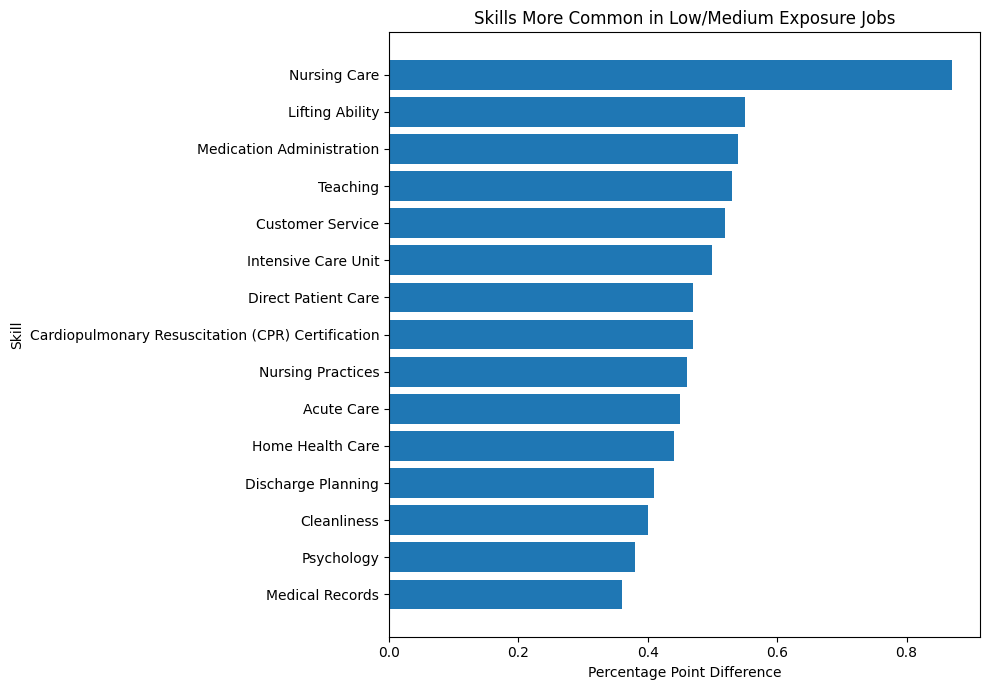


Top 15 skills more common in lower-risk jobs:
AI_GROUP                                              Skill  \
0                                              Nursing Care   
1                                           Lifting Ability   
2                                 Medication Administration   
3                                                  Teaching   
4                                          Customer Service   
5                                       Intensive Care Unit   
6                                       Direct Patient Care   
7         Cardiopulmonary Resuscitation (CPR) Certification   
8                                         Nursing Practices   
9                                                Acute Care   
10                                         Home Health Care   
11                                       Discharge Planning   
12                                              Cleanliness   
13                                               Psychology   
14      

In [ ]:
# =========================================================
# TABLE 3. TOP SKILLS IN THE AI ECONOMY (EXPLORATORY)
# =========================================================

from pathlib import Path
from ast import literal_eval
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# =========================================================
# FILE PATHS
# =========================================================
LIGHTCAST_FILE = r"G:\Shared drives\EO_OPERATIONS\Grants\PCIC Analysis\Job Posting Data\raw_data\df_2016_2025.csv"
AI_EXPOSURE_FILE = r"C:\Users\301533\Documents\AI Analysis\AI Exposure Sheet\ai_exposure_composite.csv.xlsx"

OUTPUT_DIR = Path(r"C:\Users\301533\Documents\AI Analysis")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================================================
# LOAD LIGHTCAST DATA
# =========================================================
print("Loading Lightcast data...")

# Use raw string path directly, then normalize
lightcast_path = os.path.normpath(LIGHTCAST_FILE)
print("Using path:", lightcast_path)

df = pd.read_csv(
    lightcast_path,
    usecols=["YEAR", "SOC_5", "SKILLS_NAME"]
)

df.columns = df.columns.str.strip()
df = df[df["YEAR"] == 2024].copy()

print("Loaded Lightcast data shape:", df.shape)

# =========================================================
# LOAD AI EXPOSURE FILE
# =========================================================
print("Loading AI exposure file...")

exposure_df = pd.read_excel(AI_EXPOSURE_FILE)
exposure_df.columns = exposure_df.columns.str.strip()
exposure_df = exposure_df[["SOC Code", "Title", "exposure"]].copy()

# =========================================================
# HELPER: FIX EXCEL-CORRUPTED SOC CODES
# =========================================================
month_map = {
    "Jan": "01", "Feb": "02", "Mar": "03", "Apr": "04",
    "May": "05", "Jun": "06", "Jul": "07", "Aug": "08",
    "Sep": "09", "Oct": "10", "Nov": "11", "Dec": "12"
}

def fix_soc_code(x):
    x = str(x).strip()
    if "-" in x:
        left, right = x.split("-", 1)
        if left in month_map and right.isdigit():
            return f"{month_map[left]}-{right.zfill(4)}"
    return x

# =========================================================
# CLEAN AI EXPOSURE SOC CODES
# =========================================================
exposure_df["SOC Code"] = (
    exposure_df["SOC Code"]
    .astype(str)
    .str.strip()
    .str.replace(".00", "", regex=False)
    .apply(fix_soc_code)
)

# =========================================================
# CLEAN LIGHTCAST SOC CODES
# =========================================================
df["SOC_5"] = (
    df["SOC_5"]
    .astype(str)
    .str.strip()
    .str.replace(".00", "", regex=False)
    .apply(fix_soc_code)
)

# =========================================================
# MERGE AI EXPOSURE ONTO POSTINGS
# =========================================================
df2 = df.merge(
    exposure_df[["SOC Code", "Title", "exposure"]],
    left_on="SOC_5",
    right_on="SOC Code",
    how="left"
)

print("\nExposure merge check:")
print(df2["exposure"].value_counts(dropna=False))

# =========================================================
# DEFINE AI GROUPS
# =========================================================
high_ai_groups = ["Very High", "High"]
lower_risk_groups = ["Medium", "Low", "Very Low"]

df2 = df2[df2["exposure"].isin(high_ai_groups + lower_risk_groups)].copy()

df2["AI_GROUP"] = np.where(
    df2["exposure"].isin(high_ai_groups),
    "AI-Exposed",
    "Low/Medium Exposure"
)

print("\nAI group counts:")
print(df2["AI_GROUP"].value_counts(dropna=False))

# =========================================================
# HELPER TO PARSE SKILLS_NAME
# =========================================================
def parse_skills(x):
    if pd.isna(x):
        return []

    if isinstance(x, list):
        return [str(i).strip() for i in x if pd.notna(i) and str(i).strip() != ""]

    if isinstance(x, (tuple, set)):
        return [str(i).strip() for i in x if pd.notna(i) and str(i).strip() != ""]

    if isinstance(x, str):
        x = x.strip()
        if x == "":
            return []
        try:
            parsed = literal_eval(x)
            if isinstance(parsed, list):
                return [str(i).strip() for i in parsed if pd.notna(i) and str(i).strip() != ""]
            elif isinstance(parsed, (tuple, set)):
                return [str(i).strip() for i in parsed if pd.notna(i) and str(i).strip() != ""]
            else:
                return [str(parsed).strip()] if str(parsed).strip() != "" else []
        except Exception:
            return [x]

    return [str(x).strip()] if str(x).strip() != "" else []

# =========================================================
# PARSE SKILLS
# =========================================================
df2["SKILLS_LIST"] = df2["SKILLS_NAME"].apply(parse_skills)
df2["SKILLS_LIST"] = df2["SKILLS_LIST"].apply(
    lambda lst: [skill.strip() for skill in lst if skill.strip() != ""]
)

# =========================================================
# OPTIONAL SKILL FILTERING
# =========================================================
exclude_skills = {
    "Valid Driver's License",
    "Driver's License",
    "Registered Nurse (RN)",
    "Nursing",
    "Basic Life Support (BLS) Certification",
    "Advanced Cardiovascular Life Support (ACLS) Certification",
    "CPR Certification",
    "First Aid",
}

def clean_skill_list(skill_list):
    return [s for s in skill_list if s not in exclude_skills]

df2["SKILLS_LIST"] = df2["SKILLS_LIST"].apply(clean_skill_list)
df2 = df2[df2["SKILLS_LIST"].map(len) > 0].copy()

print("\nRows remaining after skill parsing/filtering:", len(df2))

# =========================================================
# EXPLODE TO POSTING-SKILL ROWS
# =========================================================
df_exploded = df2[["SOC_5", "Title", "exposure", "AI_GROUP", "SKILLS_LIST"]].explode("SKILLS_LIST")
df_exploded = df_exploded.dropna(subset=["AI_GROUP", "SKILLS_LIST"]).copy()
df_exploded = df_exploded.rename(columns={"SKILLS_LIST": "SKILL"})

# =========================================================
# SKILL FREQUENCY BY AI GROUP
# =========================================================
skill_freq = (
    df_exploded
    .groupby(["AI_GROUP", "SKILL"], as_index=False)
    .size()
    .rename(columns={"size": "skill_count"})
)

group_totals = (
    skill_freq
    .groupby("AI_GROUP", as_index=False)["skill_count"]
    .sum()
    .rename(columns={"skill_count": "total_skill_mentions"})
)

skill_freq = skill_freq.merge(group_totals, on="AI_GROUP", how="left")
skill_freq["skill_pct_within_group"] = (
    skill_freq["skill_count"] / skill_freq["total_skill_mentions"]
) * 100

skill_freq["rank_within_group"] = (
    skill_freq.groupby("AI_GROUP")["skill_count"]
    .rank(method="first", ascending=False)
)

# =========================================================
# TOP SKILLS WITHIN EACH GROUP
# =========================================================
TOP_N = 30

top_skills = (
    skill_freq[skill_freq["rank_within_group"] <= TOP_N]
    .sort_values(["AI_GROUP", "rank_within_group"])
    .reset_index(drop=True)
)

print("\nTop skills by AI group:")
print(top_skills.head(60))

top_skills.to_excel(OUTPUT_DIR / "AI_Top_Skills_By_Group.xlsx", index=False)

# =========================================================
# BUILD COMPARISON TABLE
# =========================================================
table3 = (
    skill_freq
    .pivot(index="SKILL", columns="AI_GROUP", values="skill_pct_within_group")
    .fillna(0)
    .reset_index()
)

for col in ["AI-Exposed", "Low/Medium Exposure"]:
    if col not in table3.columns:
        table3[col] = 0

table3["Difference"] = table3["Low/Medium Exposure"] - table3["AI-Exposed"]

table3["In_Both_Groups"] = np.where(
    (table3["AI-Exposed"] > 0) & (table3["Low/Medium Exposure"] > 0),
    "Yes", "No"
)

table3["Unique_to_Lower_Risk"] = np.where(
    (table3["Low/Medium Exposure"] > 0) & (table3["AI-Exposed"] == 0),
    "Yes", "No"
)

# =========================================================
# MANUAL SKILL CATEGORIES
# =========================================================
technical_skills = {
    "Python", "SQL", "R", "SAS", "Tableau", "Power BI",
    "Data Analysis", "Data Visualization", "Programming",
    "Software Development", "Machine Learning", "Artificial Intelligence",
    "Microsoft Excel", "Microsoft Office", "Computer Literacy",
    "Auditing", "HVAC", "Construction", "Warehousing", "Plumbing",
    "Electrical Systems", "Equipment Maintenance", "Troubleshooting"
}

analytical_skills = {
    "Research", "Problem Solving", "Critical Thinking", "Analysis",
    "Planning", "Project Management", "Forecasting", "Evaluation",
    "Strategic Planning", "Mathematics", "Budgeting", "Quality Control"
}

operational_skills = {
    "Customer Service", "Communication", "Leadership", "Management",
    "Coordinating", "Scheduling", "Time Management", "Detail Oriented",
    "Organizational Skills", "Interpersonal Communications",
    "Professionalism", "Sales", "Writing", "Lifting Ability",
    "Teamwork", "Operations", "Multitasking", "Verbal Communication Skills"
}

def assign_skill_category(skill):
    if skill in technical_skills:
        return "Technical"
    elif skill in analytical_skills:
        return "Analytical"
    elif skill in operational_skills:
        return "Operational / Hands-on"
    else:
        return "Other / Review"

table3["Skill_Category"] = table3["SKILL"].apply(assign_skill_category)

# =========================================================
# FINAL TABLE 3
# =========================================================
table3_final = table3[
    [
        "SKILL",
        "Skill_Category",
        "AI-Exposed",
        "Low/Medium Exposure",
        "Difference",
        "In_Both_Groups",
        "Unique_to_Lower_Risk"
    ]
].copy()

table3_final = table3_final.rename(columns={
    "SKILL": "Skill",
    "AI-Exposed": "AI-Exposed Jobs (%)",
    "Low/Medium Exposure": "Low/Medium Exposure Jobs (%)",
    "Difference": "Lower-Risk Minus AI-Exposed (pp)"
})

for col in [
    "AI-Exposed Jobs (%)",
    "Low/Medium Exposure Jobs (%)",
    "Lower-Risk Minus AI-Exposed (pp)"
]:
    table3_final[col] = table3_final[col].round(2)

table3_final = table3_final.sort_values(
    ["Low/Medium Exposure Jobs (%)", "Lower-Risk Minus AI-Exposed (pp)"],
    ascending=[False, False]
).reset_index(drop=True)

print("\nFinal Table 3 preview:")
print(table3_final.head(30))

table3_final.to_excel(OUTPUT_DIR / "Table3_Top_Skills_AI_Economy.xlsx", index=False)

# =========================================================
# OPTIONAL OUTPUTS
# =========================================================
shared_skills = table3_final[
    table3_final["In_Both_Groups"] == "Yes"
].copy().sort_values(
    ["AI-Exposed Jobs (%)", "Low/Medium Exposure Jobs (%)"],
    ascending=[False, False]
)
shared_skills.to_excel(OUTPUT_DIR / "Table3_Shared_Skills.xlsx", index=False)

lower_risk_skills = table3_final.sort_values(
    "Lower-Risk Minus AI-Exposed (pp)",
    ascending=False
).reset_index(drop=True)
lower_risk_skills.to_excel(OUTPUT_DIR / "Table3_Lower_Risk_Skills.xlsx", index=False)

plot_df = lower_risk_skills.head(15).copy()
plt.figure(figsize=(10, 7))
plt.barh(plot_df["Skill"], plot_df["Lower-Risk Minus AI-Exposed (pp)"])
plt.xlabel("Percentage Point Difference")
plt.ylabel("Skill")
plt.title("Skills More Common in Low/Medium Exposure Jobs")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "Table3_Lower_Risk_Skills_BarChart.png", dpi=300, bbox_inches="tight")
plt.show()

ai_exposed_skills = table3_final.sort_values(
    "Lower-Risk Minus AI-Exposed (pp)",
    ascending=True
).reset_index(drop=True)
ai_exposed_skills.to_excel(OUTPUT_DIR / "Table3_AI_Exposed_Skills.xlsx", index=False)

print("\nTop 15 skills more common in lower-risk jobs:")
print(
    lower_risk_skills[
        ["Skill", "Skill_Category", "Low/Medium Exposure Jobs (%)", "AI-Exposed Jobs (%)", "Lower-Risk Minus AI-Exposed (pp)"]
    ].head(15)
)

print("\nTop 15 skills more common in AI-exposed jobs:")
print(
    ai_exposed_skills[
        ["Skill", "Skill_Category", "Low/Medium Exposure Jobs (%)", "AI-Exposed Jobs (%)", "Lower-Risk Minus AI-Exposed (pp)"]
    ].head(15)
)

print("\nDone. Files saved to:")
print(OUTPUT_DIR)


================ SHARED SKILLS ACROSS BOTH GROUPS ================

AI_GROUP                              Skill          Skill_Category  \
0                             Communication  Operational / Hands-on   
1                                Management  Operational / Hands-on   
2                          Customer Service  Operational / Hands-on   
3                                Leadership  Operational / Hands-on   
4                                Operations  Operational / Hands-on   
5                           Problem Solving              Analytical   
6                                     Sales  Operational / Hands-on   
7                           Detail Oriented  Operational / Hands-on   
8                                  Planning              Analytical   
9                        Project Management              Analytical   
10                                  Writing  Operational / Hands-on   
11                         Microsoft Office               Technical   
12      

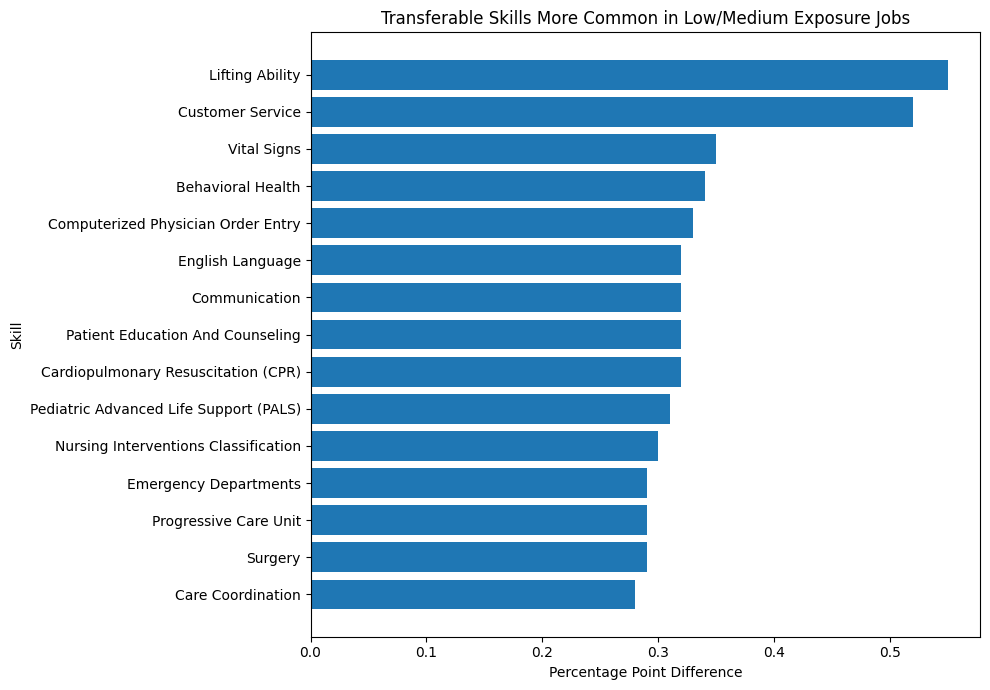

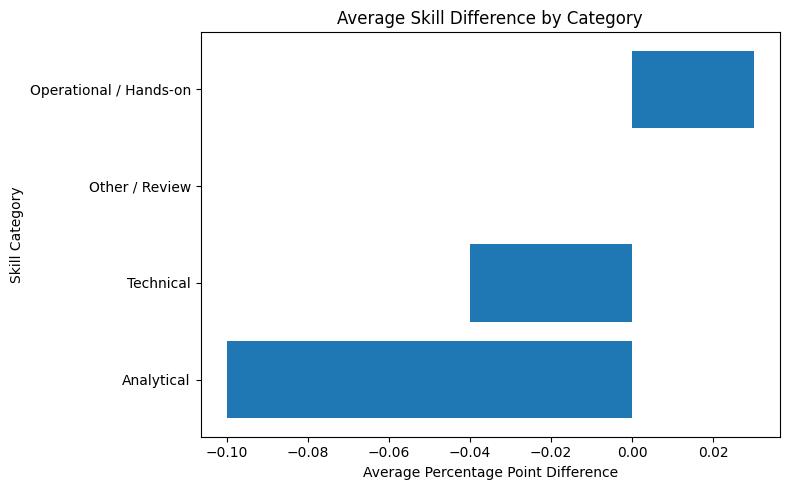


================ WRITE-UP SUMMARY ================

                                            Question  \
0  What skills appear across both AI-exposed and ...   
1  What skills are more common in lower-risk / AI...   
2    What skills are more common in AI-exposed jobs?   
3  Which skill categories skew more toward lower-...   

                                      Answer_Preview  
0  Communication, Management, Customer Service, L...  
1  Lifting Ability, Customer Service, Vital Signs...  
2  Project Management, Computer Science, Agile Me...  
3  Operational / Hands-on, Other / Review, Techni...  

Done. Additional exploratory outputs saved to:
C:\Users\301533\Documents\AI Analysis


In [ ]:
# =========================================================
# EXTRA EXPLORATORY OUTPUTS FOR FERRIS QUESTIONS
# Run this AFTER your main Table 3 script
# Assumes table3_final already exists
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================================================
# OUTPUT FOLDER
# =========================================================
OUTPUT_DIR = Path(r"C:\Users\301533\Documents\AI Analysis")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================================================
# 1. EXPAND FILTER FOR OCCUPATION-SPECIFIC / CLINICAL SKILLS
# This helps surface broader transferable skills
# =========================================================
extra_exclude_skills = {
    "Nursing Care",
    "Nursing Practices",
    "Medication Administration",
    "Direct Patient Care",
    "Intensive Care Unit",
    "Acute Care",
    "Home Health Care",
    "Medical Records",
    "Discharge Planning",
    "Cardiopulmonary Resuscitation (CPR) Certification",
    "Teaching",   # optional, remove if you want to keep it
    "Psychology", # optional, remove if you want to keep it
    "Cleanliness"
}

clean_table3 = table3_final[~table3_final["Skill"].isin(extra_exclude_skills)].copy()

# =========================================================
# 2. SHARED SKILLS ACROSS BOTH GROUPS
# Core skills appearing in both AI-exposed and lower-risk jobs
# =========================================================
shared_skills_clean = (
    clean_table3[clean_table3["In_Both_Groups"] == "Yes"]
    .copy()
    .sort_values(
        ["AI-Exposed Jobs (%)", "Low/Medium Exposure Jobs (%)"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

print("\n================ SHARED SKILLS ACROSS BOTH GROUPS ================\n")
print(shared_skills_clean.head(25))

shared_skills_clean.to_excel(
    OUTPUT_DIR / "Table3_Shared_Skills_Clean.xlsx",
    index=False
)

# =========================================================
# 3. SKILLS MOST ASSOCIATED WITH LOWER-RISK JOBS
# "Top Skills for AI-Resilient Jobs"
# =========================================================
lower_risk_transferable = (
    clean_table3
    .sort_values("Lower-Risk Minus AI-Exposed (pp)", ascending=False)
    .reset_index(drop=True)
)

print("\n================ TOP LOWER-RISK / AI-RESILIENT SKILLS ================\n")
print(lower_risk_transferable.head(25))

lower_risk_transferable.to_excel(
    OUTPUT_DIR / "Table3_Lower_Risk_Transferable_Skills.xlsx",
    index=False
)

# =========================================================
# 4. SKILLS MOST ASSOCIATED WITH AI-EXPOSED JOBS
# =========================================================
ai_exposed_transferable = (
    clean_table3
    .sort_values("Lower-Risk Minus AI-Exposed (pp)", ascending=True)
    .reset_index(drop=True)
)

print("\n================ TOP AI-EXPOSED SKILLS ================\n")
print(ai_exposed_transferable.head(25))

ai_exposed_transferable.to_excel(
    OUTPUT_DIR / "Table3_AI_Exposed_Transferable_Skills.xlsx",
    index=False
)

# =========================================================
# 5. CATEGORY COUNTS
# How many skills fall into each category?
# =========================================================
category_counts = (
    clean_table3.groupby("Skill_Category", dropna=False)
    .size()
    .reset_index(name="Skill_Count")
    .sort_values("Skill_Count", ascending=False)
    .reset_index(drop=True)
)

print("\n================ CATEGORY COUNTS ================\n")
print(category_counts)

category_counts.to_excel(
    OUTPUT_DIR / "Table3_Skill_Category_Counts.xlsx",
    index=False
)

# =========================================================
# 6. CATEGORY AVERAGES
# Average difference by skill category
# Positive = more common in lower-risk jobs
# Negative = more common in AI-exposed jobs
# =========================================================
category_summary = (
    clean_table3.groupby("Skill_Category", dropna=False)
    .agg(
        Skill_Count=("Skill", "count"),
        Avg_AI_Exposed=("AI-Exposed Jobs (%)", "mean"),
        Avg_Low_Medium=("Low/Medium Exposure Jobs (%)", "mean"),
        Avg_Difference=("Lower-Risk Minus AI-Exposed (pp)", "mean"),
        Median_Difference=("Lower-Risk Minus AI-Exposed (pp)", "median")
    )
    .reset_index()
    .sort_values("Avg_Difference", ascending=False)
    .reset_index(drop=True)
)

category_summary = category_summary.round(2)

print("\n================ CATEGORY SUMMARY ================\n")
print(category_summary)

category_summary.to_excel(
    OUTPUT_DIR / "Table3_Skill_Category_Summary.xlsx",
    index=False
)

# =========================================================
# 7. TOP 15 SHARED SKILLS
# =========================================================
top_shared_skills = shared_skills_clean.head(15).copy()
top_shared_skills.to_excel(
    OUTPUT_DIR / "Table3_Top15_Shared_Skills.xlsx",
    index=False
)

# =========================================================
# 8. TOP 15 LOWER-RISK TRANSFERABLE SKILLS
# =========================================================
top15_lower_risk = lower_risk_transferable.head(15).copy()
top15_lower_risk.to_excel(
    OUTPUT_DIR / "Table3_Top15_Lower_Risk_Transferable_Skills.xlsx",
    index=False
)

# =========================================================
# 9. TOP 15 AI-EXPOSED SKILLS
# =========================================================
top15_ai_exposed = ai_exposed_transferable.head(15).copy()
top15_ai_exposed.to_excel(
    OUTPUT_DIR / "Table3_Top15_AI_Exposed_Skills.xlsx",
    index=False
)

# =========================================================
# 10. BAR CHART: CLEAN LOWER-RISK / AI-RESILIENT SKILLS
# =========================================================
plot_df = top15_lower_risk.copy()

plt.figure(figsize=(10, 7))
plt.barh(plot_df["Skill"], plot_df["Lower-Risk Minus AI-Exposed (pp)"])
plt.xlabel("Percentage Point Difference")
plt.ylabel("Skill")
plt.title("Transferable Skills More Common in Low/Medium Exposure Jobs")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "Table3_Clean_Lower_Risk_Transferable_Skills_BarChart.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# =========================================================
# 11. BAR CHART: CATEGORY AVERAGE DIFFERENCE
# =========================================================
plot_cat = category_summary.copy()

plt.figure(figsize=(8, 5))
plt.barh(plot_cat["Skill_Category"], plot_cat["Avg_Difference"])
plt.xlabel("Average Percentage Point Difference")
plt.ylabel("Skill Category")
plt.title("Average Skill Difference by Category")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "Table3_Category_Average_Difference_BarChart.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# =========================================================
# 12. SIMPLE NARRATIVE TABLE FOR WRITE-UP
# =========================================================
writeup_summary = pd.DataFrame({
    "Question": [
        "What skills appear across both AI-exposed and lower-risk jobs?",
        "What skills are more common in lower-risk / AI-resilient jobs?",
        "What skills are more common in AI-exposed jobs?",
        "Which skill categories skew more toward lower-risk jobs?"
    ],
    "Answer_Preview": [
        ", ".join(shared_skills_clean["Skill"].head(10).tolist()),
        ", ".join(lower_risk_transferable["Skill"].head(10).tolist()),
        ", ".join(ai_exposed_transferable["Skill"].head(10).tolist()),
        ", ".join(category_summary.sort_values("Avg_Difference", ascending=False)["Skill_Category"].tolist())
    ]
})

print("\n================ WRITE-UP SUMMARY ================\n")
print(writeup_summary)

writeup_summary.to_excel(
    OUTPUT_DIR / "Table3_Writeup_Summary.xlsx",
    index=False
)

print("\nDone. Additional exploratory outputs saved to:")
print(OUTPUT_DIR)

Loading Lightcast data...
Using path: G:\Shared drives\EO_OPERATIONS\Grants\PCIC Analysis\Job Posting Data\raw_data\df_2016_2025.csv
Loaded Lightcast data shape: (863482, 3)
Loading AI exposure file...

Exposure merge check:
exposure
Medium       414225
Very High    324637
NaN          158472
High         146918
Low          127575
Very Low     124082
Name: count, dtype: int64

AI group counts:
AI_GROUP
Low/Medium Exposure    665882
AI-Exposed             471555
Name: count, dtype: int64

Rows remaining after skill parsing/filtering: 1089957

Top skills by AI group:
               AI_GROUP                              SKILL  skill_count  \
0            AI-Exposed                      Communication       207988   
1            AI-Exposed                         Management       146189   
2            AI-Exposed                   Customer Service       132192   
3            AI-Exposed                         Leadership       104664   
4            AI-Exposed                         Oper

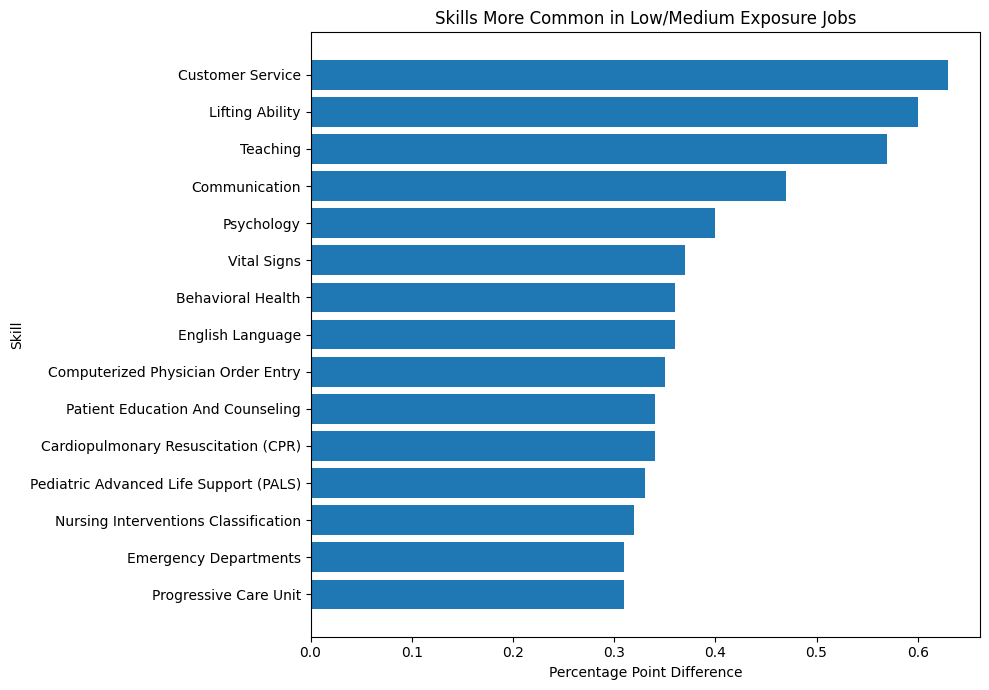

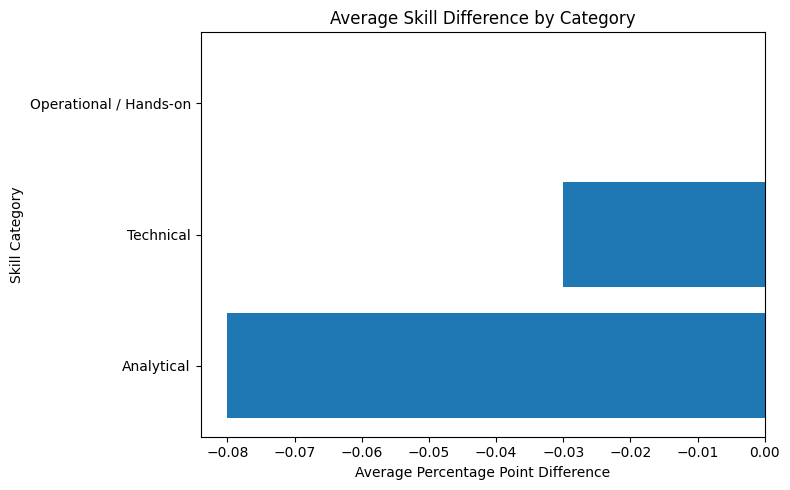


Write-up summary:
                                            Question  \
0  What skills appear across both AI-exposed and ...   
1  What skills are more common in lower-risk / AI...   
2    What skills are more common in AI-exposed jobs?   
3  Which skill categories skew more toward lower-...   

                                      Answer_Preview  
0  Communication, Management, Customer Service, L...  
1  Customer Service, Lifting Ability, Teaching, C...  
2  Project Management, Computer Science, Agile Me...  
3      Operational / Hands-on, Technical, Analytical  

Top 15 skills more common in lower-risk jobs:
AI_GROUP                                   Skill          Skill_Category  \
0                               Customer Service  Operational / Hands-on   
1                                Lifting Ability  Operational / Hands-on   
2                                       Teaching  Operational / Hands-on   
3                                  Communication  Operational / Hands-on  

In [ ]:
# =========================================================
# TABLE 3. TOP SKILLS IN THE AI ECONOMY (EXPLORATORY)
# FULL SCRIPT WITH 3 SKILL CATEGORIES
# =========================================================

from pathlib import Path
from ast import literal_eval
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# =========================================================
# FILE PATHS
# =========================================================
LIGHTCAST_FILE = r"G:\Shared drives\EO_OPERATIONS\Grants\PCIC Analysis\Job Posting Data\raw_data\df_2016_2025.csv"
AI_EXPOSURE_FILE = r"C:\Users\301533\Documents\AI Analysis\AI Exposure Sheet\ai_exposure_composite.csv.xlsx"

OUTPUT_DIR = Path(r"C:\Users\301533\Documents\AI Analysis")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================================================
# LOAD LIGHTCAST DATA
# =========================================================
print("Loading Lightcast data...")

lightcast_path = os.path.normpath(LIGHTCAST_FILE)
print("Using path:", lightcast_path)

df = pd.read_csv(
    lightcast_path,
    usecols=["YEAR", "SOC_5", "SKILLS_NAME"]
)

df.columns = df.columns.str.strip()
df = df[df["YEAR"] == 2024].copy()

print("Loaded Lightcast data shape:", df.shape)

# =========================================================
# LOAD AI EXPOSURE FILE
# =========================================================
print("Loading AI exposure file...")

exposure_df = pd.read_excel(AI_EXPOSURE_FILE)
exposure_df.columns = exposure_df.columns.str.strip()
exposure_df = exposure_df[["SOC Code", "Title", "exposure"]].copy()

# =========================================================
# HELPER: FIX EXCEL-CORRUPTED SOC CODES
# =========================================================
month_map = {
    "Jan": "01", "Feb": "02", "Mar": "03", "Apr": "04",
    "May": "05", "Jun": "06", "Jul": "07", "Aug": "08",
    "Sep": "09", "Oct": "10", "Nov": "11", "Dec": "12"
}

def fix_soc_code(x):
    x = str(x).strip()
    if "-" in x:
        left, right = x.split("-", 1)
        if left in month_map and right.isdigit():
            return f"{month_map[left]}-{right.zfill(4)}"
    return x

# =========================================================
# CLEAN AI EXPOSURE SOC CODES
# =========================================================
exposure_df["SOC Code"] = (
    exposure_df["SOC Code"]
    .astype(str)
    .str.strip()
    .str.replace(".00", "", regex=False)
    .apply(fix_soc_code)
)

# =========================================================
# CLEAN LIGHTCAST SOC CODES
# =========================================================
df["SOC_5"] = (
    df["SOC_5"]
    .astype(str)
    .str.strip()
    .str.replace(".00", "", regex=False)
    .apply(fix_soc_code)
)

# =========================================================
# MERGE AI EXPOSURE ONTO POSTINGS
# =========================================================
df2 = df.merge(
    exposure_df[["SOC Code", "Title", "exposure"]],
    left_on="SOC_5",
    right_on="SOC Code",
    how="left"
)

print("\nExposure merge check:")
print(df2["exposure"].value_counts(dropna=False))

# =========================================================
# DEFINE AI GROUPS
# =========================================================
high_ai_groups = ["Very High", "High"]
lower_risk_groups = ["Medium", "Low", "Very Low"]

df2 = df2[df2["exposure"].isin(high_ai_groups + lower_risk_groups)].copy()

df2["AI_GROUP"] = np.where(
    df2["exposure"].isin(high_ai_groups),
    "AI-Exposed",
    "Low/Medium Exposure"
)

print("\nAI group counts:")
print(df2["AI_GROUP"].value_counts(dropna=False))

# =========================================================
# HELPER TO PARSE SKILLS_NAME
# =========================================================
def parse_skills(x):
    if pd.isna(x):
        return []

    if isinstance(x, list):
        return [str(i).strip() for i in x if pd.notna(i) and str(i).strip() != ""]

    if isinstance(x, (tuple, set)):
        return [str(i).strip() for i in x if pd.notna(i) and str(i).strip() != ""]

    if isinstance(x, str):
        x = x.strip()
        if x == "":
            return []
        try:
            parsed = literal_eval(x)
            if isinstance(parsed, list):
                return [str(i).strip() for i in parsed if pd.notna(i) and str(i).strip() != ""]
            elif isinstance(parsed, (tuple, set)):
                return [str(i).strip() for i in parsed if pd.notna(i) and str(i).strip() != ""]
            else:
                return [str(parsed).strip()] if str(parsed).strip() != "" else []
        except Exception:
            return [x]

    return [str(x).strip()] if str(x).strip() != "" else []

# =========================================================
# PARSE SKILLS
# =========================================================
df2["SKILLS_LIST"] = df2["SKILLS_NAME"].apply(parse_skills)
df2["SKILLS_LIST"] = df2["SKILLS_LIST"].apply(
    lambda lst: [skill.strip() for skill in lst if skill.strip() != ""]
)

# =========================================================
# REMOVE NOISY / OCCUPATION-SPECIFIC SKILLS
# =========================================================
exclude_skills = {
    "Valid Driver's License",
    "Driver's License",
    "Registered Nurse (RN)",
    "Nursing",
    "Basic Life Support (BLS) Certification",
    "Advanced Cardiovascular Life Support (ACLS) Certification",
    "CPR Certification",
    "First Aid",
    "Nursing Care",
    "Nursing Practices",
    "Medication Administration",
    "Direct Patient Care",
    "Intensive Care Unit",
    "Acute Care",
    "Home Health Care",
    "Medical Records",
    "Discharge Planning",
    "Cardiopulmonary Resuscitation (CPR) Certification",
    "Cleanliness"
}

def clean_skill_list(skill_list):
    return [s for s in skill_list if s not in exclude_skills]

df2["SKILLS_LIST"] = df2["SKILLS_LIST"].apply(clean_skill_list)
df2 = df2[df2["SKILLS_LIST"].map(len) > 0].copy()

print("\nRows remaining after skill parsing/filtering:", len(df2))

# =========================================================
# EXPLODE TO POSTING-SKILL ROWS
# =========================================================
df_exploded = df2[["SOC_5", "Title", "exposure", "AI_GROUP", "SKILLS_LIST"]].explode("SKILLS_LIST")
df_exploded = df_exploded.dropna(subset=["AI_GROUP", "SKILLS_LIST"]).copy()
df_exploded = df_exploded.rename(columns={"SKILLS_LIST": "SKILL"})

# =========================================================
# SKILL FREQUENCY BY AI GROUP
# =========================================================
skill_freq = (
    df_exploded
    .groupby(["AI_GROUP", "SKILL"], as_index=False)
    .size()
    .rename(columns={"size": "skill_count"})
)

group_totals = (
    skill_freq
    .groupby("AI_GROUP", as_index=False)["skill_count"]
    .sum()
    .rename(columns={"skill_count": "total_skill_mentions"})
)

skill_freq = skill_freq.merge(group_totals, on="AI_GROUP", how="left")
skill_freq["skill_pct_within_group"] = (
    skill_freq["skill_count"] / skill_freq["total_skill_mentions"]
) * 100

skill_freq["rank_within_group"] = (
    skill_freq.groupby("AI_GROUP")["skill_count"]
    .rank(method="first", ascending=False)
)

# =========================================================
# TOP SKILLS WITHIN EACH GROUP
# =========================================================
TOP_N = 30

top_skills = (
    skill_freq[skill_freq["rank_within_group"] <= TOP_N]
    .sort_values(["AI_GROUP", "rank_within_group"])
    .reset_index(drop=True)
)

print("\nTop skills by AI group:")
print(top_skills.head(60))

top_skills.to_excel(OUTPUT_DIR / "AI_Top_Skills_By_Group.xlsx", index=False)

# =========================================================
# BUILD COMPARISON TABLE
# =========================================================
table3 = (
    skill_freq
    .pivot(index="SKILL", columns="AI_GROUP", values="skill_pct_within_group")
    .fillna(0)
    .reset_index()
)

for col in ["AI-Exposed", "Low/Medium Exposure"]:
    if col not in table3.columns:
        table3[col] = 0

table3["Difference"] = table3["Low/Medium Exposure"] - table3["AI-Exposed"]

table3["In_Both_Groups"] = np.where(
    (table3["AI-Exposed"] > 0) & (table3["Low/Medium Exposure"] > 0),
    "Yes", "No"
)

table3["Unique_to_Lower_Risk"] = np.where(
    (table3["Low/Medium Exposure"] > 0) & (table3["AI-Exposed"] == 0),
    "Yes", "No"
)

# =========================================================
# 3 SKILL CATEGORIES
# =========================================================
technical_skills = {
    "Python", "SQL", "R", "SAS", "Tableau", "Power BI",
    "Data Analysis", "Data Visualization", "Programming",
    "Software Development", "Machine Learning", "Artificial Intelligence",
    "Microsoft Excel", "Microsoft Office", "Computer Literacy",
    "Auditing", "HVAC", "Construction", "Warehousing", "Plumbing",
    "Electrical Systems", "Equipment Maintenance", "Troubleshooting"
}

analytical_skills = {
    "Research", "Problem Solving", "Critical Thinking", "Analysis",
    "Planning", "Project Management", "Forecasting", "Evaluation",
    "Strategic Planning", "Mathematics", "Budgeting", "Quality Control"
}

def assign_skill_category(skill):
    if skill in technical_skills:
        return "Technical"
    elif skill in analytical_skills:
        return "Analytical"
    else:
        return "Operational / Hands-on"

table3["Skill_Category"] = table3["SKILL"].apply(assign_skill_category)

# =========================================================
# FINAL TABLE 3
# =========================================================
table3_final = table3[
    [
        "SKILL",
        "Skill_Category",
        "AI-Exposed",
        "Low/Medium Exposure",
        "Difference",
        "In_Both_Groups",
        "Unique_to_Lower_Risk"
    ]
].copy()

table3_final = table3_final.rename(columns={
    "SKILL": "Skill",
    "AI-Exposed": "AI-Exposed Jobs (%)",
    "Low/Medium Exposure": "Low/Medium Exposure Jobs (%)",
    "Difference": "Lower-Risk Minus AI-Exposed (pp)"
})

for col in [
    "AI-Exposed Jobs (%)",
    "Low/Medium Exposure Jobs (%)",
    "Lower-Risk Minus AI-Exposed (pp)"
]:
    table3_final[col] = table3_final[col].round(2)

table3_final = table3_final.sort_values(
    ["Low/Medium Exposure Jobs (%)", "Lower-Risk Minus AI-Exposed (pp)"],
    ascending=[False, False]
).reset_index(drop=True)

print("\nFinal Table 3 preview:")
print(table3_final.head(30))

table3_final.to_excel(OUTPUT_DIR / "Table3_Top_Skills_AI_Economy.xlsx", index=False)

# =========================================================
# SHARED SKILLS
# =========================================================
shared_skills = (
    table3_final[table3_final["In_Both_Groups"] == "Yes"]
    .copy()
    .sort_values(
        ["AI-Exposed Jobs (%)", "Low/Medium Exposure Jobs (%)"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

shared_skills.to_excel(OUTPUT_DIR / "Table3_Shared_Skills.xlsx", index=False)

# =========================================================
# LOWER-RISK / AI-RESILIENT SKILLS
# =========================================================
lower_risk_skills = table3_final.sort_values(
    "Lower-Risk Minus AI-Exposed (pp)",
    ascending=False
).reset_index(drop=True)

lower_risk_skills.to_excel(OUTPUT_DIR / "Table3_Lower_Risk_Skills.xlsx", index=False)

# =========================================================
# AI-EXPOSED SKILLS
# =========================================================
ai_exposed_skills = table3_final.sort_values(
    "Lower-Risk Minus AI-Exposed (pp)",
    ascending=True
).reset_index(drop=True)

ai_exposed_skills.to_excel(OUTPUT_DIR / "Table3_AI_Exposed_Skills.xlsx", index=False)

# =========================================================
# CATEGORY COUNTS
# =========================================================
category_counts = (
    table3_final.groupby("Skill_Category", dropna=False)
    .size()
    .reset_index(name="Skill_Count")
    .sort_values("Skill_Count", ascending=False)
    .reset_index(drop=True)
)

print("\nCategory counts:")
print(category_counts)

category_counts.to_excel(
    OUTPUT_DIR / "Table3_Skill_Category_Counts.xlsx",
    index=False
)

# =========================================================
# CATEGORY SUMMARY
# =========================================================
category_summary = (
    table3_final.groupby("Skill_Category", dropna=False)
    .agg(
        Skill_Count=("Skill", "count"),
        Avg_AI_Exposed=("AI-Exposed Jobs (%)", "mean"),
        Avg_Low_Medium=("Low/Medium Exposure Jobs (%)", "mean"),
        Avg_Difference=("Lower-Risk Minus AI-Exposed (pp)", "mean"),
        Median_Difference=("Lower-Risk Minus AI-Exposed (pp)", "median")
    )
    .reset_index()
    .sort_values("Avg_Difference", ascending=False)
    .reset_index(drop=True)
)

category_summary = category_summary.round(2)

print("\nCategory summary:")
print(category_summary)

category_summary.to_excel(
    OUTPUT_DIR / "Table3_Skill_Category_Summary.xlsx",
    index=False
)

# =========================================================
# TOP 15 FILES
# =========================================================
top15_shared_skills = shared_skills.head(15).copy()
top15_shared_skills.to_excel(
    OUTPUT_DIR / "Table3_Top15_Shared_Skills.xlsx",
    index=False
)

top15_lower_risk = lower_risk_skills.head(15).copy()
top15_lower_risk.to_excel(
    OUTPUT_DIR / "Table3_Top15_Lower_Risk_Skills.xlsx",
    index=False
)

top15_ai_exposed = ai_exposed_skills.head(15).copy()
top15_ai_exposed.to_excel(
    OUTPUT_DIR / "Table3_Top15_AI_Exposed_Skills.xlsx",
    index=False
)

# =========================================================
# CHART 1: LOWER-RISK SKILLS
# =========================================================
plot_df = top15_lower_risk.copy()

plt.figure(figsize=(10, 7))
plt.barh(plot_df["Skill"], plot_df["Lower-Risk Minus AI-Exposed (pp)"])
plt.xlabel("Percentage Point Difference")
plt.ylabel("Skill")
plt.title("Skills More Common in Low/Medium Exposure Jobs")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "Table3_Lower_Risk_Skills_BarChart.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# =========================================================
# CHART 2: CATEGORY AVERAGE DIFFERENCE
# =========================================================
plot_cat = category_summary.copy()

plt.figure(figsize=(8, 5))
plt.barh(plot_cat["Skill_Category"], plot_cat["Avg_Difference"])
plt.xlabel("Average Percentage Point Difference")
plt.ylabel("Skill Category")
plt.title("Average Skill Difference by Category")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "Table3_Category_Average_Difference_BarChart.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# =========================================================
# WRITE-UP SUMMARY
# =========================================================
writeup_summary = pd.DataFrame({
    "Question": [
        "What skills appear across both AI-exposed and lower-risk jobs?",
        "What skills are more common in lower-risk / AI-resilient jobs?",
        "What skills are more common in AI-exposed jobs?",
        "Which skill categories skew more toward lower-risk jobs?"
    ],
    "Answer_Preview": [
        ", ".join(shared_skills["Skill"].head(10).tolist()),
        ", ".join(lower_risk_skills["Skill"].head(10).tolist()),
        ", ".join(ai_exposed_skills["Skill"].head(10).tolist()),
        ", ".join(category_summary.sort_values("Avg_Difference", ascending=False)["Skill_Category"].tolist())
    ]
})

print("\nWrite-up summary:")
print(writeup_summary)

writeup_summary.to_excel(
    OUTPUT_DIR / "Table3_Writeup_Summary.xlsx",
    index=False
)

print("\nTop 15 skills more common in lower-risk jobs:")
print(
    lower_risk_skills[
        ["Skill", "Skill_Category", "Low/Medium Exposure Jobs (%)", "AI-Exposed Jobs (%)", "Lower-Risk Minus AI-Exposed (pp)"]
    ].head(15)
)

print("\nTop 15 skills more common in AI-exposed jobs:")
print(
    ai_exposed_skills[
        ["Skill", "Skill_Category", "Low/Medium Exposure Jobs (%)", "AI-Exposed Jobs (%)", "Lower-Risk Minus AI-Exposed (pp)"]
    ].head(15)
)

print("\nDone. Files saved to:")
print(OUTPUT_DIR)

Loading Lightcast data...
Using path: G:\Shared drives\EO_OPERATIONS\Grants\PCIC Analysis\Job Posting Data\raw_data\df_2016_2025.csv
Loaded Lightcast data shape: (863482, 3)
Loading AI exposure file...

Exposure merge check:
exposure
Medium       414225
Very High    324637
NaN          158472
High         146918
Low          127575
Very Low     124082
Name: count, dtype: int64

AI group counts:
AI_GROUP
Low/Medium Exposure    665882
AI-Exposed             471555
Name: count, dtype: int64

Rows remaining after skill parsing/filtering: 1089957

Top skills by AI group:
               AI_GROUP                              SKILL  skill_count  \
0            AI-Exposed                      Communication       207988   
1            AI-Exposed                         Management       146189   
2            AI-Exposed                   Customer Service       132192   
3            AI-Exposed                         Leadership       104664   
4            AI-Exposed                         Oper

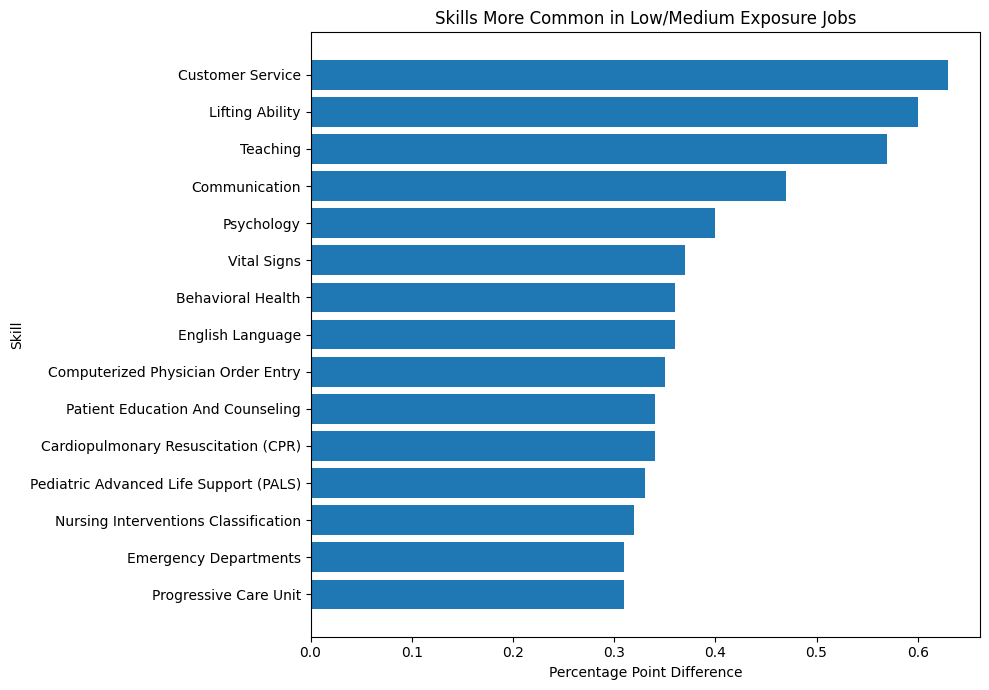

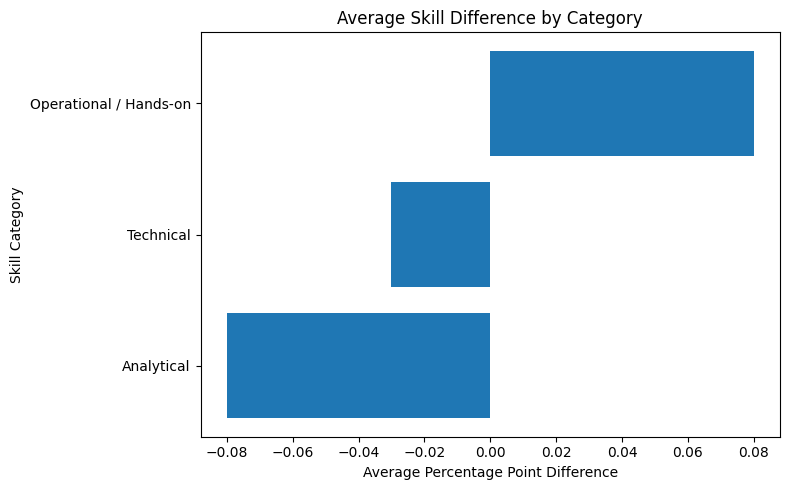


Write-up summary:
                                            Question  \
0  What skills appear across both AI-exposed and ...   
1  What skills are more common in lower-risk / AI...   
2    What skills are more common in AI-exposed jobs?   
3  Which skill categories skew more toward lower-...   

                                      Answer_Preview  
0  Communication, Management, Customer Service, L...  
1  Customer Service, Lifting Ability, Teaching, C...  
2  Project Management, Computer Science, Agile Me...  
3      Operational / Hands-on, Technical, Analytical  

Top 15 skills more common in lower-risk jobs:
AI_GROUP                                   Skill          Skill_Category  \
0                               Customer Service  Operational / Hands-on   
1                                Lifting Ability  Operational / Hands-on   
2                                       Teaching                     NaN   
3                                  Communication  Operational / Hands-on  

In [ ]:
# =========================================================
# TABLE 3. TOP SKILLS IN THE AI ECONOMY (EXPLORATORY)
# FULL SCRIPT
# 3 REAL CATEGORIES ONLY:
#   - Technical
#   - Analytical
#   - Operational / Hands-on
#
# IMPORTANT:
# This version does NOT force all unmatched skills into Operational.
# Instead, unmatched skills are set to NA and dropped from the
# category summary so the averages are cleaner and more interpretable.
# =========================================================

from pathlib import Path
from ast import literal_eval
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# =========================================================
# FILE PATHS
# =========================================================
LIGHTCAST_FILE = r"G:\Shared drives\EO_OPERATIONS\Grants\PCIC Analysis\Job Posting Data\raw_data\df_2016_2025.csv"
AI_EXPOSURE_FILE = r"C:\Users\301533\Documents\AI Analysis\AI Exposure Sheet\ai_exposure_composite.csv.xlsx"

OUTPUT_DIR = Path(r"C:\Users\301533\Documents\AI Analysis")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================================================
# LOAD LIGHTCAST DATA
# =========================================================
print("Loading Lightcast data...")

lightcast_path = os.path.normpath(LIGHTCAST_FILE)
print("Using path:", lightcast_path)

df = pd.read_csv(
    lightcast_path,
    usecols=["YEAR", "SOC_5", "SKILLS_NAME"]
)

df.columns = df.columns.str.strip()
df = df[df["YEAR"] == 2024].copy()

print("Loaded Lightcast data shape:", df.shape)

# =========================================================
# LOAD AI EXPOSURE FILE
# =========================================================
print("Loading AI exposure file...")

exposure_df = pd.read_excel(AI_EXPOSURE_FILE)
exposure_df.columns = exposure_df.columns.str.strip()
exposure_df = exposure_df[["SOC Code", "Title", "exposure"]].copy()

# =========================================================
# HELPER: FIX EXCEL-CORRUPTED SOC CODES
# Example: Nov-11 -> 11-0011
# =========================================================
month_map = {
    "Jan": "01", "Feb": "02", "Mar": "03", "Apr": "04",
    "May": "05", "Jun": "06", "Jul": "07", "Aug": "08",
    "Sep": "09", "Oct": "10", "Nov": "11", "Dec": "12"
}

def fix_soc_code(x):
    x = str(x).strip()
    if "-" in x:
        left, right = x.split("-", 1)
        if left in month_map and right.isdigit():
            return f"{month_map[left]}-{right.zfill(4)}"
    return x

# =========================================================
# CLEAN AI EXPOSURE SOC CODES
# =========================================================
exposure_df["SOC Code"] = (
    exposure_df["SOC Code"]
    .astype(str)
    .str.strip()
    .str.replace(".00", "", regex=False)
    .apply(fix_soc_code)
)

# =========================================================
# CLEAN LIGHTCAST SOC CODES
# =========================================================
df["SOC_5"] = (
    df["SOC_5"]
    .astype(str)
    .str.strip()
    .str.replace(".00", "", regex=False)
    .apply(fix_soc_code)
)

# =========================================================
# MERGE AI EXPOSURE ONTO POSTINGS
# =========================================================
df2 = df.merge(
    exposure_df[["SOC Code", "Title", "exposure"]],
    left_on="SOC_5",
    right_on="SOC Code",
    how="left"
)

print("\nExposure merge check:")
print(df2["exposure"].value_counts(dropna=False))

# =========================================================
# DEFINE AI GROUPS
# =========================================================
high_ai_groups = ["Very High", "High"]
lower_risk_groups = ["Medium", "Low", "Very Low"]

df2 = df2[df2["exposure"].isin(high_ai_groups + lower_risk_groups)].copy()

df2["AI_GROUP"] = np.where(
    df2["exposure"].isin(high_ai_groups),
    "AI-Exposed",
    "Low/Medium Exposure"
)

print("\nAI group counts:")
print(df2["AI_GROUP"].value_counts(dropna=False))

# =========================================================
# HELPER TO PARSE SKILLS_NAME
# =========================================================
def parse_skills(x):
    if pd.isna(x):
        return []

    if isinstance(x, list):
        return [str(i).strip() for i in x if pd.notna(i) and str(i).strip() != ""]

    if isinstance(x, (tuple, set)):
        return [str(i).strip() for i in x if pd.notna(i) and str(i).strip() != ""]

    if isinstance(x, str):
        x = x.strip()
        if x == "":
            return []
        try:
            parsed = literal_eval(x)
            if isinstance(parsed, list):
                return [str(i).strip() for i in parsed if pd.notna(i) and str(i).strip() != ""]
            elif isinstance(parsed, (tuple, set)):
                return [str(i).strip() for i in parsed if pd.notna(i) and str(i).strip() != ""]
            else:
                return [str(parsed).strip()] if str(parsed).strip() != "" else []
        except Exception:
            return [x]

    return [str(x).strip()] if str(x).strip() != "" else []

# =========================================================
# PARSE SKILLS
# =========================================================
df2["SKILLS_LIST"] = df2["SKILLS_NAME"].apply(parse_skills)
df2["SKILLS_LIST"] = df2["SKILLS_LIST"].apply(
    lambda lst: [skill.strip() for skill in lst if skill.strip() != ""]
)

# =========================================================
# REMOVE NOISY / OCCUPATION-SPECIFIC SKILLS
# =========================================================
exclude_skills = {
    "Valid Driver's License",
    "Driver's License",
    "Registered Nurse (RN)",
    "Nursing",
    "Basic Life Support (BLS) Certification",
    "Advanced Cardiovascular Life Support (ACLS) Certification",
    "CPR Certification",
    "First Aid",
    "Nursing Care",
    "Nursing Practices",
    "Medication Administration",
    "Direct Patient Care",
    "Intensive Care Unit",
    "Acute Care",
    "Home Health Care",
    "Medical Records",
    "Discharge Planning",
    "Cardiopulmonary Resuscitation (CPR) Certification",
    "Cleanliness"
}

def clean_skill_list(skill_list):
    return [s for s in skill_list if s not in exclude_skills]

df2["SKILLS_LIST"] = df2["SKILLS_LIST"].apply(clean_skill_list)
df2 = df2[df2["SKILLS_LIST"].map(len) > 0].copy()

print("\nRows remaining after skill parsing/filtering:", len(df2))

# =========================================================
# EXPLODE TO POSTING-SKILL ROWS
# =========================================================
df_exploded = df2[["SOC_5", "Title", "exposure", "AI_GROUP", "SKILLS_LIST"]].explode("SKILLS_LIST")
df_exploded = df_exploded.dropna(subset=["AI_GROUP", "SKILLS_LIST"]).copy()
df_exploded = df_exploded.rename(columns={"SKILLS_LIST": "SKILL"})

# =========================================================
# SKILL FREQUENCY BY AI GROUP
# =========================================================
skill_freq = (
    df_exploded
    .groupby(["AI_GROUP", "SKILL"], as_index=False)
    .size()
    .rename(columns={"size": "skill_count"})
)

group_totals = (
    skill_freq
    .groupby("AI_GROUP", as_index=False)["skill_count"]
    .sum()
    .rename(columns={"skill_count": "total_skill_mentions"})
)

skill_freq = skill_freq.merge(group_totals, on="AI_GROUP", how="left")
skill_freq["skill_pct_within_group"] = (
    skill_freq["skill_count"] / skill_freq["total_skill_mentions"]
) * 100

skill_freq["rank_within_group"] = (
    skill_freq.groupby("AI_GROUP")["skill_count"]
    .rank(method="first", ascending=False)
)

# =========================================================
# TOP SKILLS WITHIN EACH GROUP
# =========================================================
TOP_N = 30

top_skills = (
    skill_freq[skill_freq["rank_within_group"] <= TOP_N]
    .sort_values(["AI_GROUP", "rank_within_group"])
    .reset_index(drop=True)
)

print("\nTop skills by AI group:")
print(top_skills.head(60))

top_skills.to_excel(OUTPUT_DIR / "AI_Top_Skills_By_Group.xlsx", index=False)

# =========================================================
# BUILD COMPARISON TABLE
# =========================================================
table3 = (
    skill_freq
    .pivot(index="SKILL", columns="AI_GROUP", values="skill_pct_within_group")
    .fillna(0)
    .reset_index()
)

for col in ["AI-Exposed", "Low/Medium Exposure"]:
    if col not in table3.columns:
        table3[col] = 0

table3["Difference"] = table3["Low/Medium Exposure"] - table3["AI-Exposed"]

table3["In_Both_Groups"] = np.where(
    (table3["AI-Exposed"] > 0) & (table3["Low/Medium Exposure"] > 0),
    "Yes", "No"
)

table3["Unique_to_Lower_Risk"] = np.where(
    (table3["Low/Medium Exposure"] > 0) & (table3["AI-Exposed"] == 0),
    "Yes", "No"
)

# =========================================================
# 3 SKILL CATEGORIES
# =========================================================
technical_skills = {
    "Python", "SQL", "R", "SAS", "Tableau", "Power BI",
    "Data Analysis", "Data Visualization", "Programming",
    "Software Development", "Machine Learning", "Artificial Intelligence",
    "Microsoft Excel", "Microsoft Office", "Computer Literacy",
    "Auditing", "HVAC", "Construction", "Warehousing", "Plumbing",
    "Electrical Systems", "Equipment Maintenance", "Troubleshooting"
}

analytical_skills = {
    "Research", "Problem Solving", "Critical Thinking", "Analysis",
    "Planning", "Project Management", "Forecasting", "Evaluation",
    "Strategic Planning", "Mathematics", "Budgeting", "Quality Control"
}

operational_skills = {
    "Customer Service", "Communication", "Leadership", "Management",
    "Coordinating", "Scheduling", "Time Management", "Detail Oriented",
    "Organizational Skills", "Interpersonal Communications",
    "Professionalism", "Sales", "Writing", "Lifting Ability",
    "Teamwork", "Operations", "Multitasking", "Verbal Communication Skills"
}

def assign_skill_category(skill):
    if skill in technical_skills:
        return "Technical"
    elif skill in analytical_skills:
        return "Analytical"
    elif skill in operational_skills:
        return "Operational / Hands-on"
    else:
        return np.nan

table3["Skill_Category"] = table3["SKILL"].apply(assign_skill_category)

# =========================================================
# FINAL TABLE 3
# =========================================================
table3_final = table3[
    [
        "SKILL",
        "Skill_Category",
        "AI-Exposed",
        "Low/Medium Exposure",
        "Difference",
        "In_Both_Groups",
        "Unique_to_Lower_Risk"
    ]
].copy()

table3_final = table3_final.rename(columns={
    "SKILL": "Skill",
    "AI-Exposed": "AI-Exposed Jobs (%)",
    "Low/Medium Exposure": "Low/Medium Exposure Jobs (%)",
    "Difference": "Lower-Risk Minus AI-Exposed (pp)"
})

for col in [
    "AI-Exposed Jobs (%)",
    "Low/Medium Exposure Jobs (%)",
    "Lower-Risk Minus AI-Exposed (pp)"
]:
    table3_final[col] = table3_final[col].round(2)

table3_final = table3_final.sort_values(
    ["Low/Medium Exposure Jobs (%)", "Lower-Risk Minus AI-Exposed (pp)"],
    ascending=[False, False]
).reset_index(drop=True)

print("\nFinal Table 3 preview:")
print(table3_final.head(30))

table3_final.to_excel(OUTPUT_DIR / "Table3_Top_Skills_AI_Economy.xlsx", index=False)

# =========================================================
# CATEGORY-ONLY VERSION
# Drop uncategorized skills for category summaries/charts
# =========================================================
table3_categorized = table3_final.dropna(subset=["Skill_Category"]).copy()

# =========================================================
# SHARED SKILLS
# =========================================================
shared_skills = (
    table3_final[table3_final["In_Both_Groups"] == "Yes"]
    .copy()
    .sort_values(
        ["AI-Exposed Jobs (%)", "Low/Medium Exposure Jobs (%)"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

shared_skills.to_excel(OUTPUT_DIR / "Table3_Shared_Skills.xlsx", index=False)

# =========================================================
# LOWER-RISK / AI-RESILIENT SKILLS
# =========================================================
lower_risk_skills = table3_final.sort_values(
    "Lower-Risk Minus AI-Exposed (pp)",
    ascending=False
).reset_index(drop=True)

lower_risk_skills.to_excel(OUTPUT_DIR / "Table3_Lower_Risk_Skills.xlsx", index=False)

# =========================================================
# AI-EXPOSED SKILLS
# =========================================================
ai_exposed_skills = table3_final.sort_values(
    "Lower-Risk Minus AI-Exposed (pp)",
    ascending=True
).reset_index(drop=True)

ai_exposed_skills.to_excel(OUTPUT_DIR / "Table3_AI_Exposed_Skills.xlsx", index=False)

# =========================================================
# CATEGORY COUNTS
# =========================================================
category_counts = (
    table3_categorized.groupby("Skill_Category", dropna=False)
    .size()
    .reset_index(name="Skill_Count")
    .sort_values("Skill_Count", ascending=False)
    .reset_index(drop=True)
)

print("\nCategory counts:")
print(category_counts)

category_counts.to_excel(
    OUTPUT_DIR / "Table3_Skill_Category_Counts.xlsx",
    index=False
)

# =========================================================
# CATEGORY SUMMARY
# =========================================================
category_summary = (
    table3_categorized.groupby("Skill_Category", dropna=False)
    .agg(
        Skill_Count=("Skill", "count"),
        Avg_AI_Exposed=("AI-Exposed Jobs (%)", "mean"),
        Avg_Low_Medium=("Low/Medium Exposure Jobs (%)", "mean"),
        Avg_Difference=("Lower-Risk Minus AI-Exposed (pp)", "mean"),
        Median_Difference=("Lower-Risk Minus AI-Exposed (pp)", "median")
    )
    .reset_index()
    .sort_values("Avg_Difference", ascending=False)
    .reset_index(drop=True)
)

category_summary = category_summary.round(2)

print("\nCategory summary:")
print(category_summary)

category_summary.to_excel(
    OUTPUT_DIR / "Table3_Skill_Category_Summary.xlsx",
    index=False
)

# =========================================================
# TOP 15 FILES
# =========================================================
top15_shared_skills = shared_skills.head(15).copy()
top15_shared_skills.to_excel(
    OUTPUT_DIR / "Table3_Top15_Shared_Skills.xlsx",
    index=False
)

top15_lower_risk = lower_risk_skills.head(15).copy()
top15_lower_risk.to_excel(
    OUTPUT_DIR / "Table3_Top15_Lower_Risk_Skills.xlsx",
    index=False
)

top15_ai_exposed = ai_exposed_skills.head(15).copy()
top15_ai_exposed.to_excel(
    OUTPUT_DIR / "Table3_Top15_AI_Exposed_Skills.xlsx",
    index=False
)

# =========================================================
# CHART 1: LOWER-RISK SKILLS
# =========================================================
plot_df = top15_lower_risk.copy()

plt.figure(figsize=(10, 7))
plt.barh(plot_df["Skill"], plot_df["Lower-Risk Minus AI-Exposed (pp)"])
plt.xlabel("Percentage Point Difference")
plt.ylabel("Skill")
plt.title("Skills More Common in Low/Medium Exposure Jobs")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "Table3_Lower_Risk_Skills_BarChart.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# =========================================================
# CHART 2: CATEGORY AVERAGE DIFFERENCE
# =========================================================
plot_cat = category_summary.copy()

plt.figure(figsize=(8, 5))
plt.barh(plot_cat["Skill_Category"], plot_cat["Avg_Difference"])
plt.xlabel("Average Percentage Point Difference")
plt.ylabel("Skill Category")
plt.title("Average Skill Difference by Category")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "Table3_Category_Average_Difference_BarChart.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# =========================================================
# WRITE-UP SUMMARY
# =========================================================
writeup_summary = pd.DataFrame({
    "Question": [
        "What skills appear across both AI-exposed and lower-risk jobs?",
        "What skills are more common in lower-risk / AI-resilient jobs?",
        "What skills are more common in AI-exposed jobs?",
        "Which skill categories skew more toward lower-risk jobs?"
    ],
    "Answer_Preview": [
        ", ".join(shared_skills["Skill"].head(10).tolist()),
        ", ".join(lower_risk_skills["Skill"].head(10).tolist()),
        ", ".join(ai_exposed_skills["Skill"].head(10).tolist()),
        ", ".join(category_summary.sort_values("Avg_Difference", ascending=False)["Skill_Category"].tolist())
    ]
})

print("\nWrite-up summary:")
print(writeup_summary)

writeup_summary.to_excel(
    OUTPUT_DIR / "Table3_Writeup_Summary.xlsx",
    index=False
)

print("\nTop 15 skills more common in lower-risk jobs:")
print(
    lower_risk_skills[
        ["Skill", "Skill_Category", "Low/Medium Exposure Jobs (%)", "AI-Exposed Jobs (%)", "Lower-Risk Minus AI-Exposed (pp)"]
    ].head(15)
)

print("\nTop 15 skills more common in AI-exposed jobs:")
print(
    ai_exposed_skills[
        ["Skill", "Skill_Category", "Low/Medium Exposure Jobs (%)", "AI-Exposed Jobs (%)", "Lower-Risk Minus AI-Exposed (pp)"]
    ].head(15)
)

print("\nDone. Files saved to:")
print(OUTPUT_DIR)

# NEW

# Build the core 6-digit transition table

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

# =========================================================
# FILE PATHS
# =========================================================

AI_FILE = Path(r"C:\Users\301533\Documents\AI Analysis\AI Exposure Sheet\outputs\ai_exposure_cleaned_soc_level.csv")
RELATED_FILE = Path(r"C:\Users\301533\Documents\AI Analysis\Related Occupations.xlsx")
CROSSWALK_FILE = Path(r"C:\Users\301533\Documents\AI Analysis\2019_to_SOC_Crosswalk.xlsx")

OUTPUT_DIR = Path(r"C:\Users\301533\Documents\AI Analysis\NorthStar_Transition_Output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================================================
# SCENARIO SETTINGS
# =========================================================

SOURCE_EXPOSURES = ["Very High", "High"]
DEST_EXPOSURES = ["Medium", "Low", "Very Low"]
TOP_N = 3

# =========================================================
# HELPERS
# =========================================================

def safe_mean(series):
    s = pd.to_numeric(series, errors="coerce").dropna()
    return s.mean() if len(s) > 0 else np.nan

def first_non_null(series):
    s = series.dropna()
    return s.iloc[0] if len(s) > 0 else np.nan

def soc2(code):
    if pd.isna(code):
        return np.nan
    code = str(code).strip()
    return code[:2] if len(code) >= 2 else np.nan

# =========================================================
# CHECK FILES
# =========================================================

print("Checking files...")
print("AI_FILE exists:", AI_FILE.exists(), AI_FILE)
print("RELATED_FILE exists:", RELATED_FILE.exists(), RELATED_FILE)
print("CROSSWALK_FILE exists:", CROSSWALK_FILE.exists(), CROSSWALK_FILE)

if not AI_FILE.exists():
    raise FileNotFoundError(f"Missing AI_FILE: {AI_FILE}")

if not RELATED_FILE.exists():
    raise FileNotFoundError(f"Missing RELATED_FILE: {RELATED_FILE}")

if not CROSSWALK_FILE.exists():
    raise FileNotFoundError(f"Missing CROSSWALK_FILE: {CROSSWALK_FILE}")

# =========================================================
# LOAD AI DATA
# =========================================================

ai = pd.read_csv(AI_FILE, dtype=str)
ai.columns = ai.columns.str.strip()

for col in ["wage", "openings", "growth_rate", "employment", "pca_score", "z_score"]:
    if col in ai.columns:
        ai[col] = pd.to_numeric(ai[col], errors="coerce")

required_ai_cols = [
    "soc_code_clean",
    "Title",
    "wage",
    "openings",
    "growth_rate",
    "employment",
    "exposure_group"
]

missing_ai = [c for c in required_ai_cols if c not in ai.columns]
if missing_ai:
    raise ValueError(f"AI file is missing required columns: {missing_ai}")

ai["soc_code_clean"] = ai["soc_code_clean"].astype(str).str.strip()
ai["Title"] = ai["Title"].astype(str).str.strip()
ai["exposure_group"] = ai["exposure_group"].astype(str).str.strip()
ai["soc2"] = ai["soc_code_clean"].apply(soc2)

soc2_title_lookup = (
    ai.groupby("soc2", as_index=False)
      .agg(two_digit_example_title=("Title", first_non_null))
)

print("\nAI preview:")
print(ai.head())

# =========================================================
# LOAD RELATED OCCUPATIONS
# =========================================================

rel = pd.read_excel(RELATED_FILE, dtype=str)
rel.columns = rel.columns.str.strip()

required_rel_cols = [
    "O*NET-SOC Code",
    "Title",
    "Related O*NET-SOC Code",
    "Related Title",
    "Relatedness Tier",
    "Index"
]

missing_rel = [c for c in required_rel_cols if c not in rel.columns]
if missing_rel:
    raise ValueError(f"Related Occupations file is missing required columns: {missing_rel}")

rel = rel[required_rel_cols].copy()

rel = rel.rename(columns={
    "O*NET-SOC Code": "from_onet_2019",
    "Title": "from_onet_title",
    "Related O*NET-SOC Code": "to_onet_2019",
    "Related Title": "to_onet_title",
    "Relatedness Tier": "relatedness_tier",
    "Index": "related_index"
})

rel["from_onet_2019"] = rel["from_onet_2019"].astype(str).str.strip()
rel["to_onet_2019"] = rel["to_onet_2019"].astype(str).str.strip()
rel["related_index"] = pd.to_numeric(rel["related_index"], errors="coerce")

print("\nRelated occupations preview:")
print(rel.head())

# =========================================================
# LOAD CROSSWALK
# =========================================================

cross = pd.read_excel(CROSSWALK_FILE, header=3, dtype=str)
cross.columns = cross.columns.str.strip()

required_cross_cols = [
    "O*NET-SOC 2019 Code",
    "2018 SOC Code"
]

missing_cross = [c for c in required_cross_cols if c not in cross.columns]
if missing_cross:
    raise ValueError(f"Crosswalk file is missing required columns: {missing_cross}")

cross = cross[required_cross_cols].copy()

cross = cross.rename(columns={
    "O*NET-SOC 2019 Code": "onet_2019_code",
    "2018 SOC Code": "soc_2018_code"
})

cross["onet_2019_code"] = cross["onet_2019_code"].astype(str).str.strip()
cross["soc_2018_code"] = cross["soc_2018_code"].astype(str).str.strip()

print("\nCrosswalk preview:")
print(cross.head())

# =========================================================
# CROSSWALK RELATED OCCUPATIONS TO 2018 SOC
# =========================================================

rel = rel.merge(
    cross,
    left_on="from_onet_2019",
    right_on="onet_2019_code",
    how="left"
).rename(columns={"soc_2018_code": "from_soc_2018"}).drop(columns=["onet_2019_code"])

rel = rel.merge(
    cross,
    left_on="to_onet_2019",
    right_on="onet_2019_code",
    how="left"
).rename(columns={"soc_2018_code": "to_soc_2018"}).drop(columns=["onet_2019_code"])

rel = rel.dropna(subset=["from_soc_2018", "to_soc_2018"]).copy()

print("\nRows after crosswalk:", len(rel))

# =========================================================
# MERGE AI DATA ON BOTH SIDES
# =========================================================

from_ai = ai[[
    "soc_code_clean", "Title", "wage", "openings", "growth_rate",
    "employment", "exposure_group", "soc2"
]].copy()

from_ai = from_ai.rename(columns={
    "soc_code_clean": "from_soc_2018",
    "Title": "from_title_ai",
    "wage": "from_wage",
    "openings": "from_openings",
    "growth_rate": "from_growth",
    "employment": "from_employment",
    "exposure_group": "from_exposure",
    "soc2": "from_soc2"
})

to_ai = ai[[
    "soc_code_clean", "Title", "wage", "openings", "growth_rate",
    "employment", "exposure_group", "soc2"
]].copy()

to_ai = to_ai.rename(columns={
    "soc_code_clean": "to_soc_2018",
    "Title": "to_title_ai",
    "wage": "to_wage",
    "openings": "to_openings",
    "growth_rate": "to_growth",
    "employment": "to_employment",
    "exposure_group": "to_exposure",
    "soc2": "to_soc2"
})

df = rel.merge(from_ai, on="from_soc_2018", how="left")
df = df.merge(to_ai, on="to_soc_2018", how="left")

print("\nRows after merging AI data:", len(df))

# =========================================================
# DROP BAD ROWS
# =========================================================

df = df.dropna(subset=[
    "from_wage", "to_wage",
    "from_growth", "to_growth",
    "from_openings", "to_openings",
    "from_exposure", "to_exposure"
]).copy()

print("Rows after dropping missing metrics:", len(df))

# =========================================================
# FILTER TO THE SCENARIO
# =========================================================

df = df[
    df["from_exposure"].isin(SOURCE_EXPOSURES) &
    df["to_exposure"].isin(DEST_EXPOSURES)
].copy()

# remove self transitions
df = df[df["from_soc_2018"] != df["to_soc_2018"]].copy()

print("Rows after exposure filtering:", len(df))

# =========================================================
# RANK RELATED OCCUPATIONS WITHIN EACH SOURCE 6-DIGIT SOC
# =========================================================

tier_order = {
    "Primary-Short": 1,
    "Primary-Long": 2,
    "Supplemental": 3
}

dest_exposure_order = {
    "Medium": 1,
    "Low": 2,
    "Very Low": 3
}

source_exposure_order = {
    "Very High": 1,
    "High": 2
}

df["tier_sort"] = df["relatedness_tier"].map(tier_order).fillna(99)
df["to_exposure_sort"] = df["to_exposure"].map(dest_exposure_order).fillna(99)
df["from_exposure_sort"] = df["from_exposure"].map(source_exposure_order).fillna(99)

df = df.sort_values(
    by=[
        "from_exposure_sort",
        "from_soc_2018",
        "tier_sort",
        "related_index",
        "to_exposure_sort",
        "to_wage",
        "to_growth",
        "to_openings"
    ],
    ascending=[True, True, True, True, True, False, False, False]
)

# keep unique destinations within each source SOC
df = df.drop_duplicates(subset=["from_soc_2018", "to_soc_2018"]).copy()

df["rank_within_source_soc"] = df.groupby("from_soc_2018").cumcount() + 1
topn = df[df["rank_within_source_soc"] <= TOP_N].copy()

print("Rows in top-N transition file:", len(topn))
print("Unique source SOCs:", topn["from_soc_2018"].nunique())

# =========================================================
# BUILD LONG OUTPUT OF TOP 3 DESTINATIONS
# =========================================================

topn_long = topn[[
    "from_soc_2018", "from_title_ai", "from_exposure", "from_soc2",
    "to_soc_2018", "to_title_ai", "to_exposure", "to_soc2",
    "relatedness_tier", "related_index", "rank_within_source_soc",
    "from_wage", "from_openings", "from_growth",
    "to_wage", "to_openings", "to_growth"
]].copy()

topn_long = topn_long.rename(columns={
    "from_soc_2018": "Source SOC",
    "from_title_ai": "Source Occupation",
    "from_exposure": "Source Exposure",
    "from_soc2": "Source 2-digit SOC",
    "to_soc_2018": "Destination SOC",
    "to_title_ai": "Destination Occupation",
    "to_exposure": "Destination Exposure",
    "to_soc2": "Destination 2-digit SOC",
    "relatedness_tier": "Relatedness Tier",
    "related_index": "Related Rank",
    "rank_within_source_soc": "Destination Rank",
    "from_wage": "Source Wage",
    "from_openings": "Source Openings",
    "from_growth": "Source Growth",
    "to_wage": "Destination Wage",
    "to_openings": "Destination Openings",
    "to_growth": "Destination Growth"
})

# =========================================================
# AGGREGATE DESTINATION METRICS INTO ONE RECORD PER SOURCE SOC
# =========================================================

agg = (
    topn.groupby("from_soc_2018", as_index=False)
        .agg(
            source_occupation=("from_title_ai", first_non_null),
            source_exposure=("from_exposure", first_non_null),
            source_soc2=("from_soc2", first_non_null),

            source_wage=("from_wage", first_non_null),
            source_openings=("from_openings", first_non_null),
            source_growth=("from_growth", first_non_null),
            source_employment=("from_employment", first_non_null),

            avg_destination_wage=("to_wage", safe_mean),
            avg_destination_openings=("to_openings", safe_mean),
            avg_destination_growth=("to_growth", safe_mean),
            avg_destination_employment=("to_employment", safe_mean),

            destination_count=("to_soc_2018", "nunique"),

            dest1_soc=("to_soc_2018", lambda s: s.iloc[0] if len(s) >= 1 else np.nan),
            dest1_title=("to_title_ai", lambda s: s.iloc[0] if len(s) >= 1 else np.nan),
            dest1_exposure=("to_exposure", lambda s: s.iloc[0] if len(s) >= 1 else np.nan),

            dest2_soc=("to_soc_2018", lambda s: s.iloc[1] if len(s) >= 2 else np.nan),
            dest2_title=("to_title_ai", lambda s: s.iloc[1] if len(s) >= 2 else np.nan),
            dest2_exposure=("to_exposure", lambda s: s.iloc[1] if len(s) >= 2 else np.nan),

            dest3_soc=("to_soc_2018", lambda s: s.iloc[2] if len(s) >= 3 else np.nan),
            dest3_title=("to_title_ai", lambda s: s.iloc[2] if len(s) >= 3 else np.nan),
            dest3_exposure=("to_exposure", lambda s: s.iloc[2] if len(s) >= 3 else np.nan)
        )
)

# rename source SOC column
agg = agg.rename(columns={"from_soc_2018": "source_soc_2018"})

# =========================================================
# CALCULATE DIFFERENCES
# =========================================================

agg["wage_difference"] = agg["avg_destination_wage"] - agg["source_wage"]
agg["openings_difference"] = agg["avg_destination_openings"] - agg["source_openings"]
agg["growth_difference"] = agg["avg_destination_growth"] - agg["source_growth"]

agg["wage_difference_abs_loss"] = agg["source_wage"] - agg["avg_destination_wage"]
agg["positive_wage_move"] = np.where(agg["wage_difference"] > 0, "Yes", "No")
agg["positive_openings_move"] = np.where(agg["openings_difference"] > 0, "Yes", "No")
agg["positive_growth_move"] = np.where(agg["growth_difference"] > 0, "Yes", "No")

# =========================================================
# MERGE IN 2-DIGIT TITLES
# =========================================================

agg = agg.merge(
    soc2_title_lookup.rename(columns={
        "soc2": "source_soc2",
        "two_digit_example_title": "source_soc2_example_title"
    }),
    on="source_soc2",
    how="left"
)

# =========================================================
# SORT
# =========================================================

agg = agg.sort_values(
    by=[
        "source_exposure",
        "source_soc2",
        "wage_difference",
        "openings_difference"
    ],
    ascending=[True, True, False, False]
)

# =========================================================
# EXPORT
# =========================================================

scenario_name = "VH_H_to_M_L_VL"

topn_long_file = OUTPUT_DIR / f"Transitions_LONG_{scenario_name}.xlsx"
agg_file = OUTPUT_DIR / f"Transitions_AGG_6digit_{scenario_name}.xlsx"

topn_long.to_excel(topn_long_file, index=False)
agg.to_excel(agg_file, index=False)

print("\nSaved:")
print(topn_long_file)
print(agg_file)

print("\nPreview: aggregated 6-digit transition table")
print(agg.head(20))

Checking files...
AI_FILE exists: True C:\Users\301533\Documents\AI Analysis\AI Exposure Sheet\outputs\ai_exposure_cleaned_soc_level.csv
RELATED_FILE exists: True C:\Users\301533\Documents\AI Analysis\Related Occupations.xlsx
CROSSWALK_FILE exists: True C:\Users\301533\Documents\AI Analysis\2019_to_SOC_Crosswalk.xlsx

AI preview:
  soc_code_clean  pca_score   z_score      wage  openings  growth_rate  \
0        11-1011   0.818306  0.395745  150590.0     462.0       1.4890   
1        11-1021   0.696313  0.213237   90000.0    8878.0       0.8106   
2        11-2011   0.678133  0.185190  107000.0       8.0       0.5038   
3        11-2021   0.775449  0.278310  130340.0     199.0       0.8188   
4        11-2022   0.557335  0.267552  129690.0    1014.0       0.4360   

   employment                                Title     EducationValue  \
0      3100.0                     Chief Executives  Bachelor's degree   
1    100340.0      General and Operations Managers  Bachelor's degree   
2   

# Roll the 6-digit output up to 2-digit SOC

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

# =========================================================
# FILE PATHS
# =========================================================

INPUT_FILE = Path(r"C:\Users\301533\Documents\AI Analysis\NorthStar_Transition_Output\Transitions_AGG_6digit_VH_H_to_M_L_VL.xlsx")
OUTPUT_FILE = Path(r"C:\Users\301533\Documents\AI Analysis\NorthStar_Transition_Output\Transitions_AGG_2digit_VH_H_to_M_L_VL_v2.xlsx")
# =========================================================
# LOAD
# =========================================================

df = pd.read_excel(INPUT_FILE)
df.columns = [str(c).strip() for c in df.columns]

# =========================================================
# CLEAN NUMERIC COLUMNS
# =========================================================

numeric_cols = [
    "source_wage",
    "source_openings",
    "source_growth",
    "source_employment",
    "avg_destination_wage",
    "avg_destination_openings",
    "avg_destination_growth",
    "avg_destination_employment",
    "wage_difference",
    "openings_difference",
    "growth_difference",
    "wage_difference_abs_loss",
    "destination_count"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# =========================================================
# FORCE SOC2 AS 2-DIGIT TEXT
# =========================================================

df["source_soc2"] = df["source_soc2"].astype(str).str.extract(r"(\d+)")[0].str.zfill(2)

# =========================================================
# TRUE 2-DIGIT SOC TITLES
# =========================================================

soc2_major_group_map = {
    "11": "Management Occupations",
    "13": "Business and Financial Operations Occupations",
    "15": "Computer and Mathematical Occupations",
    "17": "Architecture and Engineering Occupations",
    "19": "Life, Physical, and Social Science Occupations",
    "21": "Community and Social Service Occupations",
    "23": "Legal Occupations",
    "25": "Educational Instruction and Library Occupations",
    "27": "Arts, Design, Entertainment, Sports, and Media Occupations",
    "29": "Healthcare Practitioners and Technical Occupations",
    "31": "Healthcare Support Occupations",
    "33": "Protective Service Occupations",
    "35": "Food Preparation and Serving Related Occupations",
    "37": "Building and Grounds Cleaning and Maintenance Occupations",
    "39": "Personal Care and Service Occupations",
    "41": "Sales and Related Occupations",
    "43": "Office and Administrative Support Occupations",
    "45": "Farming, Fishing, and Forestry Occupations",
    "47": "Construction and Extraction Occupations",
    "49": "Installation, Maintenance, and Repair Occupations",
    "51": "Production Occupations",
    "53": "Transportation and Material Moving Occupations",
    "55": "Military Specific Occupations"
}

# =========================================================
# BUILD FULL 2-DIGIT SUMMARY
# =========================================================

summary_2digit = (
    df.groupby("source_soc2", as_index=False)
      .agg(
          occupation_count=("source_soc_2018", "count"),
          very_high_count=("source_exposure", lambda s: (s == "Very High").sum()),
          high_count=("source_exposure", lambda s: (s == "High").sum()),

          mean_source_wage=("source_wage", "mean"),
          mean_dest_wage=("avg_destination_wage", "mean"),
          mean_wage_difference=("wage_difference", "mean"),
          median_wage_difference=("wage_difference", "median"),

          mean_source_openings=("source_openings", "mean"),
          mean_dest_openings=("avg_destination_openings", "mean"),
          mean_openings_difference=("openings_difference", "mean"),
          median_openings_difference=("openings_difference", "median"),

          mean_source_growth=("source_growth", "mean"),
          mean_dest_growth=("avg_destination_growth", "mean"),
          mean_growth_difference=("growth_difference", "mean"),
          median_growth_difference=("growth_difference", "median"),

          share_positive_wage=("positive_wage_move", lambda s: (s == "Yes").mean()),
          share_positive_openings=("positive_openings_move", lambda s: (s == "Yes").mean()),
          share_positive_growth=("positive_growth_move", lambda s: (s == "Yes").mean()),

          avg_destination_count=("destination_count", "mean")
      )
)

summary_2digit["source_soc2_title"] = summary_2digit["source_soc2"].map(soc2_major_group_map)

# convert shares to percents
for col in ["share_positive_wage", "share_positive_openings", "share_positive_growth"]:
    summary_2digit[col] = summary_2digit[col] * 100

# sort by SOC code
summary_2digit["source_soc2_num"] = pd.to_numeric(summary_2digit["source_soc2"], errors="coerce")
summary_2digit = summary_2digit.sort_values("source_soc2_num").drop(columns=["source_soc2_num"]).reset_index(drop=True)

# reorder columns
summary_2digit = summary_2digit[
    [
        "source_soc2",
        "source_soc2_title",
        "occupation_count",
        "very_high_count",
        "high_count",
        "mean_source_wage",
        "mean_dest_wage",
        "mean_wage_difference",
        "median_wage_difference",
        "mean_source_openings",
        "mean_dest_openings",
        "mean_openings_difference",
        "median_openings_difference",
        "mean_source_growth",
        "mean_dest_growth",
        "mean_growth_difference",
        "median_growth_difference",
        "share_positive_wage",
        "share_positive_openings",
        "share_positive_growth",
        "avg_destination_count"
    ]
]

# =========================================================
# BUILD EASY-TO-DIGEST TABLE
# =========================================================

digest = summary_2digit.copy()

digest["Avg Wage Change"] = digest["mean_wage_difference"].round(0)
digest["Avg Openings Change"] = digest["mean_openings_difference"].round(0)
digest["Avg Growth Change"] = digest["mean_growth_difference"].round(2)

digest["% Positive Wage"] = digest["share_positive_wage"].round(1)
digest["% Positive Openings"] = digest["share_positive_openings"].round(1)
digest["% Positive Growth"] = digest["share_positive_growth"].round(1)

digest["Avg Wage Change Label"] = digest["Avg Wage Change"].map(lambda x: f"{x:,.0f}")
digest["Avg Openings Change Label"] = digest["Avg Openings Change"].map(lambda x: f"{x:,.0f}")
digest["Avg Growth Change Label"] = digest["Avg Growth Change"].map(lambda x: f"{x:.2f}")
digest["% Positive Wage Label"] = digest["% Positive Wage"].map(lambda x: f"{x:.1f}%")
digest["% Positive Openings Label"] = digest["% Positive Openings"].map(lambda x: f"{x:.1f}%")
digest["% Positive Growth Label"] = digest["% Positive Growth"].map(lambda x: f"{x:.1f}%")

digest["Wage Direction"] = np.where(digest["Avg Wage Change"] > 0, "Gain", "Loss")
digest["Openings Direction"] = np.where(digest["Avg Openings Change"] > 0, "More openings", "Fewer openings")
digest["Growth Direction"] = np.where(digest["Avg Growth Change"] > 0, "Higher growth", "Lower growth")

digest["Transition Snapshot"] = (
    "Wage: " + digest["Avg Wage Change Label"] +
    " | Openings: " + digest["Avg Openings Change Label"] +
    " | Growth: " + digest["Avg Growth Change Label"]
)

digest = digest[
    [
        "source_soc2",
        "source_soc2_title",
        "occupation_count",
        "very_high_count",
        "high_count",
        "Avg Wage Change",
        "Avg Openings Change",
        "Avg Growth Change",
        "% Positive Wage",
        "% Positive Openings",
        "% Positive Growth",
        "Wage Direction",
        "Openings Direction",
        "Growth Direction",
        "Transition Snapshot"
    ]
]

digest = digest.rename(columns={
    "source_soc2": "SOC 2-Digit",
    "source_soc2_title": "Major Occupational Group",
    "occupation_count": "High/VH Occupation Count",
    "very_high_count": "Very High Count",
    "high_count": "High Count",
    "Avg Wage Change": "Average Wage Change",
    "Avg Openings Change": "Average Openings Change",
    "Avg Growth Change": "Average Growth Change",
    "% Positive Wage": "% With Wage Gain",
    "% Positive Openings": "% With More Openings",
    "% Positive Growth": "% With Higher Growth"
})

# =========================================================
# OPTIONAL: MANUSCRIPT-READY TABLE
# =========================================================

manuscript = summary_2digit.copy()

manuscript["Wage Difference"] = manuscript["mean_wage_difference"].round(0).map(lambda x: f"{x:,.0f}")
manuscript["Openings Difference"] = manuscript["mean_openings_difference"].round(0).map(lambda x: f"{x:,.0f}")
manuscript["Growth Difference"] = manuscript["mean_growth_difference"].round(2).map(lambda x: f"{x:.2f}")
manuscript["% Positive Wage"] = manuscript["share_positive_wage"].round(1).map(lambda x: f"{x:.1f}%")
manuscript["% Positive Openings"] = manuscript["share_positive_openings"].round(1).map(lambda x: f"{x:.1f}%")
manuscript["% Positive Growth"] = manuscript["share_positive_growth"].round(1).map(lambda x: f"{x:.1f}%")

manuscript = manuscript[
    [
        "source_soc2",
        "source_soc2_title",
        "occupation_count",
        "Wage Difference",
        "Openings Difference",
        "Growth Difference",
        "% Positive Wage",
        "% Positive Openings",
        "% Positive Growth"
    ]
]

manuscript = manuscript.rename(columns={
    "source_soc2": "SOC",
    "source_soc2_title": "Major Occupational Group",
    "occupation_count": "Count of Source Occupations"
})

# =========================================================
# EXPORT TO EXCEL
# =========================================================

with pd.ExcelWriter(OUTPUT_FILE, engine="openpyxl") as writer:
    summary_2digit.to_excel(writer, sheet_name="2digit_full_detail", index=False)
    digest.to_excel(writer, sheet_name="2digit_easy_digest", index=False)
    manuscript.to_excel(writer, sheet_name="2digit_manuscript_ready", index=False)

print("Saved:", OUTPUT_FILE)

print("\nFULL DETAIL PREVIEW")
print(summary_2digit.head(20))

print("\nEASY DIGEST PREVIEW")
print(digest.head(20))

print("\nMANUSCRIPT TABLE PREVIEW")
print(manuscript.head(20))

Saved: C:\Users\301533\Documents\AI Analysis\NorthStar_Transition_Output\Transitions_AGG_2digit_VH_H_to_M_L_VL_v2.xlsx

FULL DETAIL PREVIEW
   source_soc2                                  source_soc2_title  \
0           11                             Management Occupations   
1           13      Business and Financial Operations Occupations   
2           15              Computer and Mathematical Occupations   
3           17           Architecture and Engineering Occupations   
4           19     Life, Physical, and Social Science Occupations   
5           21           Community and Social Service Occupations   
6           23                                  Legal Occupations   
7           25    Educational Instruction and Library Occupations   
8           27  Arts, Design, Entertainment, Sports, and Media...   
9           29  Healthcare Practitioners and Technical Occupat...   
10          31                     Healthcare Support Occupations   
11          33                  

# Script 3: Flexible scenario runner for Ferris’s different combos

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

# =========================================================
# FOLDER PATHS
# =========================================================

OUTPUT_DIR = Path(r"C:\Users\301533\Documents\AI Analysis\NorthStar_Transition_Output")

OUTPUT_FILE = OUTPUT_DIR / "Transitions_NEXTSTEP_VH_vs_H_and_Opportunities_Final.xlsx"

# =========================================================
# FIND INPUT FILE AUTOMATICALLY
# =========================================================

candidates = list(OUTPUT_DIR.glob("Transitions_AGG_6digit*.xlsx"))

if not candidates:
    raise FileNotFoundError(
        f"No files matching 'Transitions_AGG_6digit*.xlsx' were found in:\n{OUTPUT_DIR}"
    )

# Use most recently modified file
INPUT_FILE = max(candidates, key=lambda p: p.stat().st_mtime)

print("Using input file:")
print(INPUT_FILE)

# =========================================================
# LOAD
# =========================================================

df = pd.read_excel(INPUT_FILE)
df.columns = [str(c).strip() for c in df.columns]

# =========================================================
# CLEAN
# =========================================================

numeric_cols = [
    "source_wage",
    "source_openings",
    "source_growth",
    "source_employment",
    "avg_destination_wage",
    "avg_destination_openings",
    "avg_destination_growth",
    "avg_destination_employment",
    "wage_difference",
    "openings_difference",
    "growth_difference",
    "wage_difference_abs_loss",
    "destination_count"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

required_cols = [
    "source_soc_2018",
    "source_occupation",
    "source_exposure",
    "source_soc2",
    "wage_difference",
    "openings_difference",
    "growth_difference",
    "positive_wage_move",
    "positive_openings_move",
    "positive_growth_move",
    "destination_count",
    "dest1_soc",
    "dest1_title",
    "dest1_exposure",
    "dest2_soc",
    "dest2_title",
    "dest2_exposure",
    "dest3_soc",
    "dest3_title",
    "dest3_exposure"
]

missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in input file: {missing_cols}")

df["source_soc2"] = df["source_soc2"].astype(str).str.extract(r"(\d+)")[0].str.zfill(2)
df["source_exposure"] = df["source_exposure"].astype(str).str.strip()

# =========================================================
# TRUE 2-DIGIT SOC TITLES
# =========================================================

soc2_major_group_map = {
    "11": "Management Occupations",
    "13": "Business and Financial Operations Occupations",
    "15": "Computer and Mathematical Occupations",
    "17": "Architecture and Engineering Occupations",
    "19": "Life, Physical, and Social Science Occupations",
    "21": "Community and Social Service Occupations",
    "23": "Legal Occupations",
    "25": "Educational Instruction and Library Occupations",
    "27": "Arts, Design, Entertainment, Sports, and Media Occupations",
    "29": "Healthcare Practitioners and Technical Occupations",
    "31": "Healthcare Support Occupations",
    "33": "Protective Service Occupations",
    "35": "Food Preparation and Serving Related Occupations",
    "37": "Building and Grounds Cleaning and Maintenance Occupations",
    "39": "Personal Care and Service Occupations",
    "41": "Sales and Related Occupations",
    "43": "Office and Administrative Support Occupations",
    "45": "Farming, Fishing, and Forestry Occupations",
    "47": "Construction and Extraction Occupations",
    "49": "Installation, Maintenance, and Repair Occupations",
    "51": "Production Occupations",
    "53": "Transportation and Material Moving Occupations",
    "55": "Military Specific Occupations"
}

df["source_soc2_title"] = df["source_soc2"].map(soc2_major_group_map)

# =========================================================
# 1. VERY HIGH VS HIGH BY 2-DIGIT SOC
# =========================================================

vh_h_detail = (
    df.groupby(["source_exposure", "source_soc2", "source_soc2_title"], as_index=False)
      .agg(
          occupation_count=("source_soc_2018", "count"),
          mean_wage_difference=("wage_difference", "mean"),
          median_wage_difference=("wage_difference", "median"),
          mean_openings_difference=("openings_difference", "mean"),
          median_openings_difference=("openings_difference", "median"),
          mean_growth_difference=("growth_difference", "mean"),
          median_growth_difference=("growth_difference", "median"),
          share_positive_wage=("positive_wage_move", lambda s: (s == "Yes").mean() * 100),
          share_positive_openings=("positive_openings_move", lambda s: (s == "Yes").mean() * 100),
          share_positive_growth=("positive_growth_move", lambda s: (s == "Yes").mean() * 100),
          avg_destination_count=("destination_count", "mean")
      )
)

exposure_order = {"Very High": 1, "High": 2}
vh_h_detail["source_soc2_num"] = pd.to_numeric(vh_h_detail["source_soc2"], errors="coerce")
vh_h_detail["exposure_sort"] = vh_h_detail["source_exposure"].map(exposure_order).fillna(99)

vh_h_detail = vh_h_detail.sort_values(
    by=["source_soc2_num", "exposure_sort"],
    ascending=[True, True]
).drop(columns=["source_soc2_num", "exposure_sort"]).reset_index(drop=True)

vh_h_detail["Avg Wage Diff"] = vh_h_detail["mean_wage_difference"].round(0)
vh_h_detail["Avg Openings Diff"] = vh_h_detail["mean_openings_difference"].round(0)
vh_h_detail["Avg Growth Diff"] = vh_h_detail["mean_growth_difference"].round(2)

# =========================================================
# 2. WIDE VH VS H COMPARISON TABLE
# =========================================================

vh_h_wide = vh_h_detail.pivot_table(
    index=["source_soc2", "source_soc2_title"],
    columns="source_exposure",
    values=[
        "occupation_count",
        "mean_wage_difference",
        "mean_openings_difference",
        "mean_growth_difference",
        "share_positive_wage",
        "share_positive_openings",
        "share_positive_growth"
    ]
)

vh_h_wide.columns = [
    f"{metric}_{exposure}".replace("mean_", "").replace("share_", "pct_")
    for metric, exposure in vh_h_wide.columns
]
vh_h_wide = vh_h_wide.reset_index()

# Add difference columns: Very High minus High
comparison_bases = [
    "wage_difference",
    "openings_difference",
    "growth_difference",
    "pct_positive_wage",
    "pct_positive_openings",
    "pct_positive_growth"
]

for base in comparison_bases:
    vh_col = f"{base}_Very High"
    h_col = f"{base}_High"
    if vh_col in vh_h_wide.columns and h_col in vh_h_wide.columns:
        vh_h_wide[f"{base}_VH_minus_H"] = vh_h_wide[vh_col] - vh_h_wide[h_col]

vh_h_wide["source_soc2_num"] = pd.to_numeric(vh_h_wide["source_soc2"], errors="coerce")
vh_h_wide = vh_h_wide.sort_values("source_soc2_num").drop(columns=["source_soc2_num"]).reset_index(drop=True)

# =========================================================
# 3. VIABLE / BEST TRANSITION FLAGS AT THE 6-DIGIT LEVEL
# =========================================================

MAX_ACCEPTABLE_WAGE_LOSS = -5000
MIN_OPENINGS_GAIN = 0
MIN_GROWTH_GAIN = 0

df["viable_transition_flag"] = np.where(
    (df["wage_difference"] >= MAX_ACCEPTABLE_WAGE_LOSS) &
    (df["openings_difference"] > MIN_OPENINGS_GAIN),
    "Yes",
    "No"
)

df["strong_transition_flag"] = np.where(
    (df["wage_difference"] >= 0) &
    (df["openings_difference"] > 0) &
    (df["growth_difference"] > MIN_GROWTH_GAIN),
    "Yes",
    "No"
)

df["transition_score"] = (
    (df["wage_difference"].fillna(0) / 1000.0) +
    (df["openings_difference"].fillna(0) / 100.0) +
    (df["growth_difference"].fillna(0) * 5.0)
)

# =========================================================
# 4. TOP TRANSITION OPPORTUNITIES BY 2-DIGIT SOC
# =========================================================

opportunities_summary = (
    df.groupby(["source_soc2", "source_soc2_title"], as_index=False)
      .agg(
          occupation_count=("source_soc_2018", "count"),
          viable_transition_count=("viable_transition_flag", lambda s: (s == "Yes").sum()),
          strong_transition_count=("strong_transition_flag", lambda s: (s == "Yes").sum()),
          pct_viable=("viable_transition_flag", lambda s: (s == "Yes").mean() * 100),
          pct_strong=("strong_transition_flag", lambda s: (s == "Yes").mean() * 100),
          mean_wage_difference=("wage_difference", "mean"),
          mean_openings_difference=("openings_difference", "mean"),
          mean_growth_difference=("growth_difference", "mean")
      )
)

opportunities_summary["source_soc2_num"] = pd.to_numeric(opportunities_summary["source_soc2"], errors="coerce")
opportunities_summary = opportunities_summary.sort_values(
    by=["pct_viable", "pct_strong", "mean_openings_difference"],
    ascending=[False, False, False]
).drop(columns=["source_soc2_num"]).reset_index(drop=True)

# =========================================================
# 5. TOP INDIVIDUAL 6-DIGIT TRANSITIONS
# =========================================================

top_individual = df[[
    "source_soc_2018",
    "source_occupation",
    "source_exposure",
    "source_soc2",
    "source_soc2_title",
    "source_wage",
    "source_openings",
    "source_growth",
    "avg_destination_wage",
    "avg_destination_openings",
    "avg_destination_growth",
    "wage_difference",
    "openings_difference",
    "growth_difference",
    "destination_count",
    "dest1_soc",
    "dest1_title",
    "dest1_exposure",
    "dest2_soc",
    "dest2_title",
    "dest2_exposure",
    "dest3_soc",
    "dest3_title",
    "dest3_exposure",
    "viable_transition_flag",
    "strong_transition_flag",
    "transition_score"
]].copy()

top_individual = top_individual.sort_values(
    by=["strong_transition_flag", "viable_transition_flag", "transition_score"],
    ascending=[False, False, False]
).reset_index(drop=True)

top_individual_highlight = top_individual.head(75).copy()

# =========================================================
# 6. EASY DIGEST TABLE FOR FERRIS
# =========================================================

easy_digest = opportunities_summary.copy()

easy_digest["% Viable"] = easy_digest["pct_viable"].round(1)
easy_digest["% Strong"] = easy_digest["pct_strong"].round(1)
easy_digest["Avg Wage Change"] = easy_digest["mean_wage_difference"].round(0)
easy_digest["Avg Openings Change"] = easy_digest["mean_openings_difference"].round(0)
easy_digest["Avg Growth Change"] = easy_digest["mean_growth_difference"].round(2)

easy_digest["Takeaway"] = np.select(
    [
        (easy_digest["Avg Wage Change"] >= 0) & (easy_digest["Avg Openings Change"] > 0),
        (easy_digest["Avg Wage Change"] < 0) & (easy_digest["Avg Openings Change"] > 0),
        (easy_digest["Avg Wage Change"] >= 0) & (easy_digest["Avg Openings Change"] <= 0),
    ],
    [
        "Wage and openings upside",
        "Openings gain with wage tradeoff",
        "Wage gain but tighter demand"
    ],
    default="Weaker transition profile"
)

easy_digest = easy_digest[[
    "source_soc2",
    "source_soc2_title",
    "occupation_count",
    "viable_transition_count",
    "strong_transition_count",
    "% Viable",
    "% Strong",
    "Avg Wage Change",
    "Avg Openings Change",
    "Avg Growth Change",
    "Takeaway"
]]

easy_digest = easy_digest.rename(columns={
    "source_soc2": "SOC",
    "source_soc2_title": "Major Occupational Group",
    "occupation_count": "Count of Source Occupations",
    "viable_transition_count": "Viable Transition Count",
    "strong_transition_count": "Strong Transition Count"
})

# =========================================================
# 7. EXPORT
# =========================================================

# Auto-version output if file is open or already exists
final_output = OUTPUT_FILE
if final_output.exists():
    i = 2
    while True:
        candidate = OUTPUT_DIR / f"{OUTPUT_FILE.stem}_v{i}{OUTPUT_FILE.suffix}"
        if not candidate.exists():
            final_output = candidate
            break
        i += 1

with pd.ExcelWriter(final_output, engine="openpyxl") as writer:
    vh_h_detail.to_excel(writer, sheet_name="VH_vs_H_detail", index=False)
    vh_h_wide.to_excel(writer, sheet_name="VH_vs_H_wide", index=False)
    opportunities_summary.to_excel(writer, sheet_name="Opportunities_summary", index=False)
    easy_digest.to_excel(writer, sheet_name="Easy_digest", index=False)
    top_individual.to_excel(writer, sheet_name="Top_individual_all", index=False)
    top_individual_highlight.to_excel(writer, sheet_name="Top_individual_75", index=False)

print("Saved:", final_output)
print("\nEasy digest preview:")
print(easy_digest.head(20))

FileNotFoundError: No files matching 'Transitions_AGG_6digit*.xlsx' were found in:
C:\Users\301533\Documents\AI Analysis\NorthStar_Transition_Output

In [ ]:
from pathlib import Path

root = Path(r"C:\Users\301533\Documents\AI Analysis")

for f in root.rglob("Transitions_AGG_6digit*.xlsx"):
    print(f)

In [ ]:
from pathlib import Path

search_roots = [
    Path(r"C:\Users\301533\Documents"),
    Path(r"C:\Users\301533\Downloads"),
    Path(r"C:\Users\301533\Desktop")
]

targets = [
    "AI_Master_Output.xlsx",
    "Related Occupations.xlsx",
    "2019_to_SOC_Crosswalk.xlsx"
]

for target in targets:
    print(f"\n--- Searching for: {target} ---")
    found = []
    for root in search_roots:
        if root.exists():
            found.extend(root.rglob(target))
    if found:
        for f in found:
            print(f)
    else:
        print("NOT FOUND")


--- Searching for: AI_Master_Output.xlsx ---
NOT FOUND

--- Searching for: Related Occupations.xlsx ---
C:\Users\301533\Documents\AI Analysis\Related Occupations.xlsx
C:\Users\301533\Documents\Green Analysis\Related Occupations.xlsx
C:\Users\301533\Downloads\Related Occupations.xlsx

--- Searching for: 2019_to_SOC_Crosswalk.xlsx ---
C:\Users\301533\Documents\2019_to_SOC_Crosswalk.xlsx
C:\Users\301533\Documents\AI Analysis\2019_to_SOC_Crosswalk.xlsx
C:\Users\301533\Downloads\2019_to_SOC_Crosswalk.xlsx
C:\Users\301533\Desktop\Table 1 Data\2019_to_SOC_Crosswalk.xlsx


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

# =========================================================
# FILE PATHS
# =========================================================

AI_FILE = Path(r"C:\Users\301533\Documents\AI Analysis\AI Exposure Sheet\outputs\ai_exposure_cleaned_soc_level.csv")
RELATED_FILE = Path(r"C:\Users\301533\Documents\AI Analysis\Related Occupations.xlsx")
CROSSWALK_FILE = Path(r"C:\Users\301533\Documents\AI Analysis\2019_to_SOC_Crosswalk.xlsx")

OUTPUT_DIR = Path(r"C:\Users\301533\Documents\AI Analysis\NorthStar_Transition_Output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_FILE = OUTPUT_DIR / "AI_Transitions_Full_Pipeline.xlsx"

# =========================================================
# SETTINGS
# =========================================================

SOURCE_EXPOSURES = ["Very High", "High"]
DEST_EXPOSURES = ["Medium", "Low", "Very Low"]
TOP_N = 3

MAX_ACCEPTABLE_WAGE_LOSS = -5000
MIN_OPENINGS_GAIN = 0
MIN_GROWTH_GAIN = 0

# =========================================================
# HELPERS
# =========================================================

def safe_mean(series):
    s = pd.to_numeric(series, errors="coerce").dropna()
    return s.mean() if len(s) > 0 else np.nan

def first_non_null(series):
    s = series.dropna()
    return s.iloc[0] if len(s) > 0 else np.nan

def soc2(code):
    if pd.isna(code):
        return np.nan
    code = str(code).strip()
    return code[:2] if len(code) >= 2 else np.nan

soc2_major_group_map = {
    "11": "Management Occupations",
    "13": "Business and Financial Operations Occupations",
    "15": "Computer and Mathematical Occupations",
    "17": "Architecture and Engineering Occupations",
    "19": "Life, Physical, and Social Science Occupations",
    "21": "Community and Social Service Occupations",
    "23": "Legal Occupations",
    "25": "Educational Instruction and Library Occupations",
    "27": "Arts, Design, Entertainment, Sports, and Media Occupations",
    "29": "Healthcare Practitioners and Technical Occupations",
    "31": "Healthcare Support Occupations",
    "33": "Protective Service Occupations",
    "35": "Food Preparation and Serving Related Occupations",
    "37": "Building and Grounds Cleaning and Maintenance Occupations",
    "39": "Personal Care and Service Occupations",
    "41": "Sales and Related Occupations",
    "43": "Office and Administrative Support Occupations",
    "45": "Farming, Fishing, and Forestry Occupations",
    "47": "Construction and Extraction Occupations",
    "49": "Installation, Maintenance, and Repair Occupations",
    "51": "Production Occupations",
    "53": "Transportation and Material Moving Occupations",
    "55": "Military Specific Occupations"
}

# =========================================================
# CHECK FILES
# =========================================================

for f in [AI_FILE, RELATED_FILE, CROSSWALK_FILE]:
    if not f.exists():
        raise FileNotFoundError(f"Missing file: {f}")

# =========================================================
# LOAD AI DATA
# =========================================================

ai = pd.read_csv(AI_FILE, dtype=str)
ai.columns = ai.columns.str.strip()

for col in ["wage", "openings", "growth_rate", "employment", "pca_score", "z_score"]:
    if col in ai.columns:
        ai[col] = pd.to_numeric(ai[col], errors="coerce")

required_ai_cols = [
    "soc_code_clean",
    "Title",
    "wage",
    "openings",
    "growth_rate",
    "employment",
    "exposure_group"
]

missing_ai = [c for c in required_ai_cols if c not in ai.columns]
if missing_ai:
    raise ValueError(f"AI file is missing required columns: {missing_ai}")

ai["soc_code_clean"] = ai["soc_code_clean"].astype(str).str.strip()
ai["Title"] = ai["Title"].astype(str).str.strip()
ai["exposure_group"] = ai["exposure_group"].astype(str).str.strip()
ai["soc2"] = ai["soc_code_clean"].apply(soc2)

# =========================================================
# LOAD RELATED OCCUPATIONS
# =========================================================

rel = pd.read_excel(RELATED_FILE, dtype=str)
rel.columns = rel.columns.str.strip()

required_rel_cols = [
    "O*NET-SOC Code",
    "Title",
    "Related O*NET-SOC Code",
    "Related Title",
    "Relatedness Tier",
    "Index"
]

missing_rel = [c for c in required_rel_cols if c not in rel.columns]
if missing_rel:
    raise ValueError(f"Related Occupations file is missing required columns: {missing_rel}")

rel = rel[required_rel_cols].copy()

rel = rel.rename(columns={
    "O*NET-SOC Code": "from_onet_2019",
    "Title": "from_onet_title",
    "Related O*NET-SOC Code": "to_onet_2019",
    "Related Title": "to_onet_title",
    "Relatedness Tier": "relatedness_tier",
    "Index": "related_index"
})

rel["from_onet_2019"] = rel["from_onet_2019"].astype(str).str.strip()
rel["to_onet_2019"] = rel["to_onet_2019"].astype(str).str.strip()
rel["related_index"] = pd.to_numeric(rel["related_index"], errors="coerce")

# =========================================================
# LOAD CROSSWALK
# =========================================================

cross = pd.read_excel(CROSSWALK_FILE, header=3, dtype=str)
cross.columns = cross.columns.str.strip()

required_cross_cols = ["O*NET-SOC 2019 Code", "2018 SOC Code"]
missing_cross = [c for c in required_cross_cols if c not in cross.columns]
if missing_cross:
    raise ValueError(f"Crosswalk file is missing required columns: {missing_cross}")

cross = cross[required_cross_cols].copy()
cross = cross.rename(columns={
    "O*NET-SOC 2019 Code": "onet_2019_code",
    "2018 SOC Code": "soc_2018_code"
})

cross["onet_2019_code"] = cross["onet_2019_code"].astype(str).str.strip()
cross["soc_2018_code"] = cross["soc_2018_code"].astype(str).str.strip()

# =========================================================
# CROSSWALK RELATED OCCUPATIONS TO 2018 SOC
# =========================================================

rel = rel.merge(
    cross,
    left_on="from_onet_2019",
    right_on="onet_2019_code",
    how="left"
).rename(columns={"soc_2018_code": "from_soc_2018"}).drop(columns=["onet_2019_code"])

rel = rel.merge(
    cross,
    left_on="to_onet_2019",
    right_on="onet_2019_code",
    how="left"
).rename(columns={"soc_2018_code": "to_soc_2018"}).drop(columns=["onet_2019_code"])

rel = rel.dropna(subset=["from_soc_2018", "to_soc_2018"]).copy()

# =========================================================
# MERGE AI DATA ON BOTH SIDES
# =========================================================

from_ai = ai[[
    "soc_code_clean", "Title", "wage", "openings", "growth_rate",
    "employment", "exposure_group", "soc2"
]].copy().rename(columns={
    "soc_code_clean": "from_soc_2018",
    "Title": "from_title_ai",
    "wage": "from_wage",
    "openings": "from_openings",
    "growth_rate": "from_growth",
    "employment": "from_employment",
    "exposure_group": "from_exposure",
    "soc2": "from_soc2"
})

to_ai = ai[[
    "soc_code_clean", "Title", "wage", "openings", "growth_rate",
    "employment", "exposure_group", "soc2"
]].copy().rename(columns={
    "soc_code_clean": "to_soc_2018",
    "Title": "to_title_ai",
    "wage": "to_wage",
    "openings": "to_openings",
    "growth_rate": "to_growth",
    "employment": "to_employment",
    "exposure_group": "to_exposure",
    "soc2": "to_soc2"
})

df = rel.merge(from_ai, on="from_soc_2018", how="left")
df = df.merge(to_ai, on="to_soc_2018", how="left")

df = df.dropna(subset=[
    "from_wage", "to_wage",
    "from_growth", "to_growth",
    "from_openings", "to_openings",
    "from_exposure", "to_exposure"
]).copy()

df = df[
    df["from_exposure"].isin(SOURCE_EXPOSURES) &
    df["to_exposure"].isin(DEST_EXPOSURES)
].copy()

df = df[df["from_soc_2018"] != df["to_soc_2018"]].copy()

# =========================================================
# RANK RELATED OCCUPATIONS WITHIN EACH SOURCE 6-DIGIT SOC
# =========================================================

tier_order = {
    "Primary-Short": 1,
    "Primary-Long": 2,
    "Supplemental": 3
}
dest_exposure_order = {"Medium": 1, "Low": 2, "Very Low": 3}
source_exposure_order = {"Very High": 1, "High": 2}

df["tier_sort"] = df["relatedness_tier"].map(tier_order).fillna(99)
df["to_exposure_sort"] = df["to_exposure"].map(dest_exposure_order).fillna(99)
df["from_exposure_sort"] = df["from_exposure"].map(source_exposure_order).fillna(99)

df = df.sort_values(
    by=[
        "from_exposure_sort",
        "from_soc_2018",
        "tier_sort",
        "related_index",
        "to_exposure_sort",
        "to_wage",
        "to_growth",
        "to_openings"
    ],
    ascending=[True, True, True, True, True, False, False, False]
)

df = df.drop_duplicates(subset=["from_soc_2018", "to_soc_2018"]).copy()
df["rank_within_source_soc"] = df.groupby("from_soc_2018").cumcount() + 1
topn = df[df["rank_within_source_soc"] <= TOP_N].copy()

# =========================================================
# 6-DIGIT LONG OUTPUT
# =========================================================

topn_long = topn[[
    "from_soc_2018", "from_title_ai", "from_exposure", "from_soc2",
    "to_soc_2018", "to_title_ai", "to_exposure", "to_soc2",
    "relatedness_tier", "related_index", "rank_within_source_soc",
    "from_wage", "from_openings", "from_growth",
    "to_wage", "to_openings", "to_growth"
]].copy()

topn_long = topn_long.rename(columns={
    "from_soc_2018": "Source SOC",
    "from_title_ai": "Source Occupation",
    "from_exposure": "Source Exposure",
    "from_soc2": "Source 2-digit SOC",
    "to_soc_2018": "Destination SOC",
    "to_title_ai": "Destination Occupation",
    "to_exposure": "Destination Exposure",
    "to_soc2": "Destination 2-digit SOC",
    "relatedness_tier": "Relatedness Tier",
    "related_index": "Related Rank",
    "rank_within_source_soc": "Destination Rank",
    "from_wage": "Source Wage",
    "from_openings": "Source Openings",
    "from_growth": "Source Growth",
    "to_wage": "Destination Wage",
    "to_openings": "Destination Openings",
    "to_growth": "Destination Growth"
})

# =========================================================
# 6-DIGIT AGGREGATED OUTPUT
# =========================================================

agg = (
    topn.groupby("from_soc_2018", as_index=False)
        .agg(
            source_occupation=("from_title_ai", first_non_null),
            source_exposure=("from_exposure", first_non_null),
            source_soc2=("from_soc2", first_non_null),
            source_wage=("from_wage", first_non_null),
            source_openings=("from_openings", first_non_null),
            source_growth=("from_growth", first_non_null),
            source_employment=("from_employment", first_non_null),
            avg_destination_wage=("to_wage", safe_mean),
            avg_destination_openings=("to_openings", safe_mean),
            avg_destination_growth=("to_growth", safe_mean),
            avg_destination_employment=("to_employment", safe_mean),
            destination_count=("to_soc_2018", "nunique"),
            dest1_soc=("to_soc_2018", lambda s: s.iloc[0] if len(s) >= 1 else np.nan),
            dest1_title=("to_title_ai", lambda s: s.iloc[0] if len(s) >= 1 else np.nan),
            dest1_exposure=("to_exposure", lambda s: s.iloc[0] if len(s) >= 1 else np.nan),
            dest2_soc=("to_soc_2018", lambda s: s.iloc[1] if len(s) >= 2 else np.nan),
            dest2_title=("to_title_ai", lambda s: s.iloc[1] if len(s) >= 2 else np.nan),
            dest2_exposure=("to_exposure", lambda s: s.iloc[1] if len(s) >= 2 else np.nan),
            dest3_soc=("to_soc_2018", lambda s: s.iloc[2] if len(s) >= 3 else np.nan),
            dest3_title=("to_title_ai", lambda s: s.iloc[2] if len(s) >= 3 else np.nan),
            dest3_exposure=("to_exposure", lambda s: s.iloc[2] if len(s) >= 3 else np.nan)
        )
)

agg = agg.rename(columns={"from_soc_2018": "source_soc_2018"})

agg["wage_difference"] = agg["avg_destination_wage"] - agg["source_wage"]
agg["openings_difference"] = agg["avg_destination_openings"] - agg["source_openings"]
agg["growth_difference"] = agg["avg_destination_growth"] - agg["source_growth"]
agg["wage_difference_abs_loss"] = agg["source_wage"] - agg["avg_destination_wage"]
agg["positive_wage_move"] = np.where(agg["wage_difference"] > 0, "Yes", "No")
agg["positive_openings_move"] = np.where(agg["openings_difference"] > 0, "Yes", "No")
agg["positive_growth_move"] = np.where(agg["growth_difference"] > 0, "Yes", "No")

agg["source_soc2"] = agg["source_soc2"].astype(str).str.extract(r"(\d+)")[0].str.zfill(2)
agg["source_soc2_title"] = agg["source_soc2"].map(soc2_major_group_map)

# =========================================================
# 2-DIGIT SUMMARY
# =========================================================

summary_2digit = (
    agg.groupby(["source_soc2", "source_soc2_title"], as_index=False)
      .agg(
          occupation_count=("source_soc_2018", "count"),
          very_high_count=("source_exposure", lambda s: (s == "Very High").sum()),
          high_count=("source_exposure", lambda s: (s == "High").sum()),
          mean_source_wage=("source_wage", "mean"),
          mean_dest_wage=("avg_destination_wage", "mean"),
          mean_wage_difference=("wage_difference", "mean"),
          median_wage_difference=("wage_difference", "median"),
          mean_source_openings=("source_openings", "mean"),
          mean_dest_openings=("avg_destination_openings", "mean"),
          mean_openings_difference=("openings_difference", "mean"),
          median_openings_difference=("openings_difference", "median"),
          mean_source_growth=("source_growth", "mean"),
          mean_dest_growth=("avg_destination_growth", "mean"),
          mean_growth_difference=("growth_difference", "mean"),
          median_growth_difference=("growth_difference", "median"),
          share_positive_wage=("positive_wage_move", lambda s: (s == "Yes").mean() * 100),
          share_positive_openings=("positive_openings_move", lambda s: (s == "Yes").mean() * 100),
          share_positive_growth=("positive_growth_move", lambda s: (s == "Yes").mean() * 100),
          avg_destination_count=("destination_count", "mean")
      )
)

summary_2digit["source_soc2_num"] = pd.to_numeric(summary_2digit["source_soc2"], errors="coerce")
summary_2digit = summary_2digit.sort_values("source_soc2_num").drop(columns=["source_soc2_num"]).reset_index(drop=True)

manuscript = summary_2digit.copy()
manuscript["Wage Difference"] = manuscript["mean_wage_difference"].round(0).map(lambda x: f"{x:,.0f}")
manuscript["Openings Difference"] = manuscript["mean_openings_difference"].round(0).map(lambda x: f"{x:,.0f}")
manuscript["Growth Difference"] = manuscript["mean_growth_difference"].round(2).map(lambda x: f"{x:.2f}")
manuscript["% Positive Wage"] = manuscript["share_positive_wage"].round(1).map(lambda x: f"{x:.1f}%")
manuscript["% Positive Openings"] = manuscript["share_positive_openings"].round(1).map(lambda x: f"{x:.1f}%")
manuscript["% Positive Growth"] = manuscript["share_positive_growth"].round(1).map(lambda x: f"{x:.1f}%")

manuscript = manuscript[[
    "source_soc2",
    "source_soc2_title",
    "occupation_count",
    "Wage Difference",
    "Openings Difference",
    "Growth Difference",
    "% Positive Wage",
    "% Positive Openings",
    "% Positive Growth"
]].rename(columns={
    "source_soc2": "SOC",
    "source_soc2_title": "Major Occupational Group",
    "occupation_count": "Count of Source Occupations"
})

# =========================================================
# VH VS H DETAIL
# =========================================================

vh_h_detail = (
    agg.groupby(["source_exposure", "source_soc2", "source_soc2_title"], as_index=False)
      .agg(
          occupation_count=("source_soc_2018", "count"),
          mean_wage_difference=("wage_difference", "mean"),
          median_wage_difference=("wage_difference", "median"),
          mean_openings_difference=("openings_difference", "mean"),
          median_openings_difference=("openings_difference", "median"),
          mean_growth_difference=("growth_difference", "mean"),
          median_growth_difference=("growth_difference", "median"),
          share_positive_wage=("positive_wage_move", lambda s: (s == "Yes").mean() * 100),
          share_positive_openings=("positive_openings_move", lambda s: (s == "Yes").mean() * 100),
          share_positive_growth=("positive_growth_move", lambda s: (s == "Yes").mean() * 100),
          avg_destination_count=("destination_count", "mean")
      )
)

exposure_order = {"Very High": 1, "High": 2}
vh_h_detail["source_soc2_num"] = pd.to_numeric(vh_h_detail["source_soc2"], errors="coerce")
vh_h_detail["exposure_sort"] = vh_h_detail["source_exposure"].map(exposure_order).fillna(99)
vh_h_detail = vh_h_detail.sort_values(
    by=["source_soc2_num", "exposure_sort"]
).drop(columns=["source_soc2_num", "exposure_sort"]).reset_index(drop=True)

# =========================================================
# VH VS H WIDE
# =========================================================

vh_h_wide = vh_h_detail.pivot_table(
    index=["source_soc2", "source_soc2_title"],
    columns="source_exposure",
    values=[
        "occupation_count",
        "mean_wage_difference",
        "mean_openings_difference",
        "mean_growth_difference",
        "share_positive_wage",
        "share_positive_openings",
        "share_positive_growth"
    ]
)

vh_h_wide.columns = [
    f"{metric}_{exposure}".replace("mean_", "").replace("share_", "pct_")
    for metric, exposure in vh_h_wide.columns
]
vh_h_wide = vh_h_wide.reset_index()

for base in [
    "wage_difference",
    "openings_difference",
    "growth_difference",
    "pct_positive_wage",
    "pct_positive_openings",
    "pct_positive_growth"
]:
    vh_col = f"{base}_Very High"
    h_col = f"{base}_High"
    if vh_col in vh_h_wide.columns and h_col in vh_h_wide.columns:
        vh_h_wide[f"{base}_VH_minus_H"] = vh_h_wide[vh_col] - vh_h_wide[h_col]

vh_h_wide["source_soc2_num"] = pd.to_numeric(vh_h_wide["source_soc2"], errors="coerce")
vh_h_wide = vh_h_wide.sort_values("source_soc2_num").drop(columns=["source_soc2_num"]).reset_index(drop=True)

# =========================================================
# OPPORTUNITIES / FLAGS
# =========================================================

agg["viable_transition_flag"] = np.where(
    (agg["wage_difference"] >= MAX_ACCEPTABLE_WAGE_LOSS) &
    (agg["openings_difference"] > MIN_OPENINGS_GAIN),
    "Yes",
    "No"
)

agg["strong_transition_flag"] = np.where(
    (agg["wage_difference"] >= 0) &
    (agg["openings_difference"] > 0) &
    (agg["growth_difference"] > MIN_GROWTH_GAIN),
    "Yes",
    "No"
)

agg["transition_score"] = (
    (agg["wage_difference"].fillna(0) / 1000.0) +
    (agg["openings_difference"].fillna(0) / 100.0) +
    (agg["growth_difference"].fillna(0) * 5.0)
)

opportunities_summary = (
    agg.groupby(["source_soc2", "source_soc2_title"], as_index=False)
      .agg(
          occupation_count=("source_soc_2018", "count"),
          viable_transition_count=("viable_transition_flag", lambda s: (s == "Yes").sum()),
          strong_transition_count=("strong_transition_flag", lambda s: (s == "Yes").sum()),
          pct_viable=("viable_transition_flag", lambda s: (s == "Yes").mean() * 100),
          pct_strong=("strong_transition_flag", lambda s: (s == "Yes").mean() * 100),
          mean_wage_difference=("wage_difference", "mean"),
          mean_openings_difference=("openings_difference", "mean"),
          mean_growth_difference=("growth_difference", "mean")
      )
)

opportunities_summary["source_soc2_num"] = pd.to_numeric(opportunities_summary["source_soc2"], errors="coerce")
opportunities_summary = opportunities_summary.sort_values(
    by=["pct_viable", "pct_strong", "mean_openings_difference"],
    ascending=[False, False, False]
).drop(columns=["source_soc2_num"]).reset_index(drop=True)

easy_digest = opportunities_summary.copy()
easy_digest["% Viable"] = easy_digest["pct_viable"].round(1)
easy_digest["% Strong"] = easy_digest["pct_strong"].round(1)
easy_digest["Avg Wage Change"] = easy_digest["mean_wage_difference"].round(0)
easy_digest["Avg Openings Change"] = easy_digest["mean_openings_difference"].round(0)
easy_digest["Avg Growth Change"] = easy_digest["mean_growth_difference"].round(2)

easy_digest["Takeaway"] = np.select(
    [
        (easy_digest["Avg Wage Change"] >= 0) & (easy_digest["Avg Openings Change"] > 0),
        (easy_digest["Avg Wage Change"] < 0) & (easy_digest["Avg Openings Change"] > 0),
        (easy_digest["Avg Wage Change"] >= 0) & (easy_digest["Avg Openings Change"] <= 0),
    ],
    [
        "Wage and openings upside",
        "Openings gain with wage tradeoff",
        "Wage gain but tighter demand"
    ],
    default="Weaker transition profile"
)

easy_digest = easy_digest[[
    "source_soc2",
    "source_soc2_title",
    "occupation_count",
    "viable_transition_count",
    "strong_transition_count",
    "% Viable",
    "% Strong",
    "Avg Wage Change",
    "Avg Openings Change",
    "Avg Growth Change",
    "Takeaway"
]].rename(columns={
    "source_soc2": "SOC",
    "source_soc2_title": "Major Occupational Group",
    "occupation_count": "Count of Source Occupations",
    "viable_transition_count": "Viable Transition Count",
    "strong_transition_count": "Strong Transition Count"
})

# =========================================================
# TOP INDIVIDUAL TRANSITIONS
# =========================================================

top_individual = agg[[
    "source_soc_2018",
    "source_occupation",
    "source_exposure",
    "source_soc2",
    "source_soc2_title",
    "source_wage",
    "source_openings",
    "source_growth",
    "avg_destination_wage",
    "avg_destination_openings",
    "avg_destination_growth",
    "wage_difference",
    "openings_difference",
    "growth_difference",
    "destination_count",
    "dest1_soc",
    "dest1_title",
    "dest1_exposure",
    "dest2_soc",
    "dest2_title",
    "dest2_exposure",
    "dest3_soc",
    "dest3_title",
    "dest3_exposure",
    "viable_transition_flag",
    "strong_transition_flag",
    "transition_score"
]].copy()

top_individual = top_individual.sort_values(
    by=["strong_transition_flag", "viable_transition_flag", "transition_score"],
    ascending=[False, False, False]
).reset_index(drop=True)

top_individual_75 = top_individual.head(75).copy()

# =========================================================
# EXPORT
# =========================================================

final_output = OUTPUT_FILE
if final_output.exists():
    i = 2
    while True:
        candidate = OUTPUT_DIR / f"{OUTPUT_FILE.stem}_v{i}{OUTPUT_FILE.suffix}"
        if not candidate.exists():
            final_output = candidate
            break
        i += 1

with pd.ExcelWriter(final_output, engine="openpyxl") as writer:
    topn_long.to_excel(writer, sheet_name="6digit_top3_long", index=False)
    agg.to_excel(writer, sheet_name="6digit_agg", index=False)
    summary_2digit.to_excel(writer, sheet_name="2digit_full_detail", index=False)
    manuscript.to_excel(writer, sheet_name="2digit_manuscript", index=False)
    vh_h_detail.to_excel(writer, sheet_name="VH_vs_H_detail", index=False)
    vh_h_wide.to_excel(writer, sheet_name="VH_vs_H_wide", index=False)
    opportunities_summary.to_excel(writer, sheet_name="Opportunities_summary", index=False)
    easy_digest.to_excel(writer, sheet_name="Easy_digest", index=False)
    top_individual.to_excel(writer, sheet_name="Top_individual_all", index=False)
    top_individual_75.to_excel(writer, sheet_name="Top_individual_75", index=False)

print("Saved:", final_output)
print("\nEasy digest preview:")
print(easy_digest.head(20))

Saved: C:\Users\301533\Documents\AI Analysis\NorthStar_Transition_Output\AI_Transitions_Full_Pipeline_v3.xlsx

Easy digest preview:
   SOC                           Major Occupational Group  \
0   31                     Healthcare Support Occupations   
1   21           Community and Social Service Occupations   
2   33                     Protective Service Occupations   
3   53     Transportation and Material Moving Occupations   
4   43      Office and Administrative Support Occupations   
5   13      Business and Financial Operations Occupations   
6   29  Healthcare Practitioners and Technical Occupat...   
7   27  Arts, Design, Entertainment, Sports, and Media...   
8   19     Life, Physical, and Social Science Occupations   
9   39              Personal Care and Service Occupations   
10  41                      Sales and Related Occupations   
11  23                                  Legal Occupations   
12  11                             Management Occupations   
13  15        

# AI About pg. Table v1 

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from ast import literal_eval
import re
from collections import defaultdict, Counter
from openpyxl import load_workbook
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter

# =========================================================
# CONFIG
# =========================================================

AI_EXPOSURE_FILE = Path(r"C:\Users\301533\Documents\AI Analysis\AI Exposure Sheet\ai_exposure_composite.csv.xlsx")
LIGHTCAST_FILE = Path(r"G:\Shared drives\EO_OPERATIONS\Grants\PCIC Analysis\Job Posting Data\raw_data\df_2016_2025.csv")
OUTPUT_FILE = Path(r"C:\Users\301533\Documents\AI Analysis\AI_About_Page_Tables_Fast_v4.xlsx")
TOP_SKILLS_PER_SECTOR = 10
TOP_SECTORS = 10
LIGHTCAST_YEAR = 2024
CHUNK_SIZE = 100000

AI_HIGH_GROUPS = ["High", "Very High"]
AI_LOW_GROUPS = ["Very Low", "Low"]
EXPOSURE_ORDER = ["Very Low", "Low", "Medium", "High", "Very High"]

# For testing only. Set to None for full run
MAX_CHUNKS = None

# =========================================================
# STYLING
# =========================================================

HEADER_FILL = PatternFill(fill_type="solid", fgColor="0F766E")
ROW_FILL_1 = PatternFill(fill_type="solid", fgColor="FFFFFF")
ROW_FILL_2 = PatternFill(fill_type="solid", fgColor="F6F8FA")
HEADER_FONT = Font(color="FFFFFF", bold=True, size=11)
BODY_FONT = Font(color="000000", size=10)
BOLD_FONT = Font(color="000000", bold=True, size=10)

CENTER = Alignment(horizontal="center", vertical="center", wrap_text=True)
LEFT = Alignment(horizontal="left", vertical="center", wrap_text=True)

THIN_BORDER = Border(
    left=Side(style="thin", color="D9D9D9"),
    right=Side(style="thin", color="D9D9D9"),
    top=Side(style="thin", color="D9D9D9"),
    bottom=Side(style="thin", color="D9D9D9"),
)

SOC2_LABELS = {
    "11": "Management",
    "13": "Business and Financial Operations",
    "15": "Computer and Mathematical",
    "17": "Architecture and Engineering",
    "19": "Life, Physical, and Social Science",
    "21": "Community and Social Service",
    "23": "Legal",
    "25": "Educational Instruction and Library",
    "27": "Arts, Design, Entertainment, Sports, and Media",
    "29": "Healthcare Practitioners and Technical",
    "31": "Healthcare Support",
    "33": "Protective Service",
    "35": "Food Preparation and Serving",
    "37": "Building and Grounds Cleaning and Maintenance",
    "39": "Personal Care and Service",
    "41": "Sales and Related",
    "43": "Office and Administrative Support",
    "45": "Farming, Fishing, and Forestry",
    "47": "Construction and Extraction",
    "49": "Installation, Maintenance, and Repair",
    "51": "Production",
    "53": "Transportation and Material Moving",
    "55": "Military Specific",
}

# =========================================================
# HELPERS
# =========================================================

def clean_money(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace(r"[\$,]", "", regex=True).str.strip(),
        errors="coerce"
    )

def clean_numeric(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace(",", "", regex=False).str.strip(),
        errors="coerce"
    )

def clean_percent_string(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace("%", "", regex=False).str.strip(),
        errors="coerce"
    )

def first_existing_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of these columns were found: {candidates}")

def first_non_null(series):
    s = series.dropna()
    return s.iloc[0] if len(s) > 0 else np.nan

def fmt_currency(x):
    if pd.isna(x):
        return ""
    return f"${x:,.0f}"

def fmt_number(x):
    if pd.isna(x):
        return ""
    return f"{x:,.0f}"

def fmt_percent(x, digits=1):
    if pd.isna(x):
        return ""
    return f"{x:.{digits}f}%"

def fmt_pp(x, digits=1):
    if pd.isna(x):
        return ""
    sign = "+" if x > 0 else ""
    return f"{sign}{x:.{digits}f} pp"

def fmt_pct_change(x, digits=1):
    if pd.isna(x):
        return ""
    sign = "+" if x > 0 else ""
    return f"{sign}{x:.{digits}f}%"

def parse_skill_list(value):
    if pd.isna(value):
        return []
    s = str(value).strip()
    if not s or s.lower() == "nan":
        return []
    try:
        parsed = literal_eval(s)
        if isinstance(parsed, list):
            return [str(v).strip() for v in parsed if str(v).strip()]
    except Exception:
        pass
    parts = re.split(r"\||;|,", s)
    return [p.strip() for p in parts if p.strip()]

def fix_soc_code(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    # Already valid SOC code
    if re.match(r"^\d{2}-\d{4}$", s):
        return s

    # Case 1: Excel text like Nov-11
    if re.match(r"^Nov-\d{2}$", s, flags=re.IGNORECASE):
        yy = s.split("-")[1]
        return f"11-20{yy}"

    # Case 2: Excel full datetime string like 2011-11-01 00:00:00
    m = re.match(r"^(\d{4})-11-01(?: 00:00:00)?$", s)
    if m:
        year = m.group(1)
        return f"11-{year}"

    # Case 3: pandas Timestamp string that may come through slightly differently
    m2 = re.match(r"^(\d{4})-11-01", s)
    if m2:
        year = m2.group(1)
        return f"11-{year}"

    # Optional generic month handling
    month_map = {
        "Jan": "01", "Feb": "02", "Mar": "03", "Apr": "04",
        "May": "05", "Jun": "06", "Jul": "07", "Aug": "08",
        "Sep": "09", "Oct": "10", "Nov": "11", "Dec": "12"
    }

    if "-" in s:
        parts = s.split("-", 1)
        if len(parts) == 2:
            left, right = parts
            if left in month_map and right.isdigit():
                return f"{month_map[left]}-{right.zfill(4)}"

    s = s.replace(".0", "").replace(".00", "")
    return s

def soc2(code):
    if pd.isna(code):
        return np.nan
    code = str(code).strip()
    return code[:2] if len(code) >= 2 else np.nan

def add_soc2_columns(df, soc_col="soc_code_clean"):
    df = df.copy()
    df["SOC2_Code"] = df[soc_col].apply(soc2)
    df["SOC2_Name"] = df["SOC2_Code"].map(SOC2_LABELS)
    return df

def style_ws(ws):
    ws.freeze_panes = "A2"
    ws.sheet_view.showGridLines = False
    ws.auto_filter.ref = ws.dimensions

    for cell in ws[1]:
        cell.fill = HEADER_FILL
        cell.font = HEADER_FONT
        cell.alignment = CENTER
        cell.border = THIN_BORDER

    for row_idx in range(2, ws.max_row + 1):
        fill = ROW_FILL_1 if row_idx % 2 == 0 else ROW_FILL_2
        for cell in ws[row_idx]:
            cell.fill = fill
            cell.font = BODY_FONT
            cell.border = THIN_BORDER
            cell.alignment = LEFT if isinstance(cell.value, str) else CENTER

    if ws.title.startswith("Table"):
        for row_idx in range(2, ws.max_row + 1):
            ws.cell(row=row_idx, column=1).font = BOLD_FONT

    for col in ws.columns:
        max_len = 0
        col_letter = get_column_letter(col[0].column)
        for cell in col:
            try:
                val = "" if cell.value is None else str(cell.value)
                max_len = max(max_len, len(val))
            except Exception:
                pass
        width = min(max_len + 3, 34)
        ws.column_dimensions[col_letter].width = max(width, 12)

    ws.row_dimensions[1].height = 24
    for r in range(2, ws.max_row + 1):
        ws.row_dimensions[r].height = 20

# =========================================================
# LOAD AI EXPOSURE FILE
# =========================================================

print("Loading AI exposure file...")
df = pd.read_excel(AI_EXPOSURE_FILE)
df.columns = [str(c).strip() for c in df.columns]

PCA_COL = "PCA Weighted Score.1"
Z_COL = "Z Score Variance.1"
TITLE_COL = "Title"
SOC_CANDIDATES = ["SOC2018.1", "O*NET-SOC Code", "SOC Code", "SOC Code1"]
WAGE_COL = "50th Percentile Wage"
OPENINGS_COL = "Annual Total Openings"
GROWTH_COL = "GrowthRate"
GROWTH_PCT_STR_COL = "Annual Percent Change"
EMPLOYMENT_COL = "Rounded Employment"

RAW_SOC_COL = first_existing_col(df, SOC_CANDIDATES)

df["soc_code_clean"] = (
    df[RAW_SOC_COL]
    .astype(str)
    .str.strip()
    .str.replace(".00", "", regex=False)
    .apply(fix_soc_code)
)

df["pca_score"] = clean_numeric(df[PCA_COL])
df["z_score"] = clean_numeric(df[Z_COL])
df["wage"] = clean_money(df[WAGE_COL])
df["openings"] = clean_numeric(df[OPENINGS_COL])
df["growth_rate"] = clean_numeric(df[GROWTH_COL])

if df["growth_rate"].isna().all() and GROWTH_PCT_STR_COL in df.columns:
    df["growth_rate"] = clean_percent_string(df[GROWTH_PCT_STR_COL])

df["employment"] = clean_numeric(df[EMPLOYMENT_COL])

print("\nSample of fixed SOC codes:")
print(df[[RAW_SOC_COL, "soc_code_clean"]].head(15))

# =========================================================
# COLLAPSE TO SOC LEVEL
# =========================================================

print("\nBuilding SOC-level table...")

soc_level = (
    df.groupby("soc_code_clean", as_index=False)
      .agg({
          "pca_score": "mean",
          "z_score": "mean",
          "wage": "median",
          "openings": "median",
          "growth_rate": "median",
          "employment": "median",
          TITLE_COL: first_non_null
      })
)

soc_level = soc_level[~soc_level["pca_score"].isna()].copy()

soc_level["exposure_group"] = pd.qcut(
    soc_level["pca_score"],
    5,
    labels=EXPOSURE_ORDER
)

soc_level["exposure_group"] = pd.Categorical(
    soc_level["exposure_group"],
    categories=EXPOSURE_ORDER,
    ordered=True
)

soc_level = add_soc2_columns(soc_level)

# =========================================================
# TABLE 1: MAIN AI EXPOSURE TABLE
# =========================================================

table1 = (
    soc_level.groupby("exposure_group", observed=False)
    .agg(
        Median_Wage=("wage", "median"),
        Mean_Growth_Rate=("growth_rate", "mean"),
        Total_Annual_Openings=("openings", "sum"),
        Occupation_Count=("soc_code_clean", "count")
    )
    .reset_index()
)

table1["exposure_group"] = pd.Categorical(
    table1["exposure_group"],
    categories=EXPOSURE_ORDER,
    ordered=True
)
table1 = table1.sort_values("exposure_group").reset_index(drop=True)

base_row = table1.loc[table1["exposure_group"] == "Very Low"].iloc[0]

table1["Wage_vs_VeryLow_pct"] = (
    (table1["Median_Wage"] - base_row["Median_Wage"]) / base_row["Median_Wage"] * 100
)
table1["Growth_vs_VeryLow_pp"] = (
    table1["Mean_Growth_Rate"] - base_row["Mean_Growth_Rate"]
)
table1["Openings_vs_VeryLow_pct"] = (
    (table1["Total_Annual_Openings"] - base_row["Total_Annual_Openings"]) /
    base_row["Total_Annual_Openings"] * 100
)

table1_final = pd.DataFrame({
    "AI Exposure": table1["exposure_group"].astype(str),
    "Median Wage": table1["Median_Wage"].map(fmt_currency),
    "Growth Rate": table1["Mean_Growth_Rate"].map(lambda x: fmt_percent(x, 2)),
    "Total Annual Openings": table1["Total_Annual_Openings"].map(fmt_number),
    "Occupation Count": table1["Occupation_Count"].map(fmt_number),
    "Wage Difference vs Very Low": table1["Wage_vs_VeryLow_pct"].map(lambda x: "—" if pd.isna(x) or abs(x) < 1e-12 else fmt_pct_change(x, 1)),
    "Growth Difference vs Very Low": table1["Growth_vs_VeryLow_pp"].map(lambda x: "—" if pd.isna(x) or abs(x) < 1e-12 else fmt_pp(x, 2)),
    "Openings Difference vs Very Low": table1["Openings_vs_VeryLow_pct"].map(lambda x: "—" if pd.isna(x) or abs(x) < 1e-12 else fmt_pct_change(x, 1)),
})

print("\nPreview: Table 1")
print(table1_final.head())

# =========================================================
# TABLE 2: HIGH VS LOW
# =========================================================

soc_level["exposure_simple"] = np.select(
    [
        soc_level["exposure_group"].astype(str).isin(AI_LOW_GROUPS),
        soc_level["exposure_group"].astype(str).isin(AI_HIGH_GROUPS),
        soc_level["exposure_group"].astype(str).isin(["Medium"])
    ],
    [
        "Low Exposure",
        "High Exposure",
        "Medium Exposure"
    ],
    default="Other"
)

comparison_source = soc_level[soc_level["exposure_simple"].isin(["Low Exposure", "High Exposure"])].copy()

comparison = (
    comparison_source.groupby("exposure_simple", observed=False)
    .agg(
        Median_Wage=("wage", "median"),
        Mean_Growth_Rate=("growth_rate", "mean"),
        Total_Annual_Openings=("openings", "sum"),
        Occupation_Count=("soc_code_clean", "count")
    )
    .reset_index()
    .set_index("exposure_simple")
)

low = comparison.loc["Low Exposure"]
high = comparison.loc["High Exposure"]

comparison_table = pd.DataFrame({
    "Metric": ["Median Wage", "Growth Rate", "Total Annual Openings", "Occupation Count"],
    "Low Exposure": [
        fmt_currency(low["Median_Wage"]),
        fmt_percent(low["Mean_Growth_Rate"], 2),
        fmt_number(low["Total_Annual_Openings"]),
        fmt_number(low["Occupation_Count"])
    ],
    "High Exposure": [
        fmt_currency(high["Median_Wage"]),
        fmt_percent(high["Mean_Growth_Rate"], 2),
        fmt_number(high["Total_Annual_Openings"]),
        fmt_number(high["Occupation_Count"])
    ],
    "Difference": [
        fmt_pct_change((high["Median_Wage"] - low["Median_Wage"]) / low["Median_Wage"] * 100, 1),
        fmt_pp(high["Mean_Growth_Rate"] - low["Mean_Growth_Rate"], 2),
        fmt_pct_change((high["Total_Annual_Openings"] - low["Total_Annual_Openings"]) / low["Total_Annual_Openings"] * 100, 1),
        fmt_pct_change((high["Occupation_Count"] - low["Occupation_Count"]) / low["Occupation_Count"] * 100, 1),
    ]
})

print("\nPreview: Table 2")
print(comparison_table)

# =========================================================
# TABLE 3: SOC2 TABLE
# =========================================================

soc2_table_raw = (
    soc_level.groupby(["SOC2_Code", "SOC2_Name"], observed=False)
    .agg(
        Median_Wage=("wage", "median"),
        Mean_Growth_Rate=("growth_rate", "mean"),
        Total_Annual_Openings=("openings", "sum"),
        Occupation_Count=("soc_code_clean", "count"),
        Share_High_VeryHigh=("exposure_group", lambda s: np.mean(s.astype(str).isin(AI_HIGH_GROUPS)))
    )
    .reset_index()
)

soc2_table_raw["SOC2_Sort"] = pd.to_numeric(soc2_table_raw["SOC2_Code"], errors="coerce")

soc2_table_raw = soc2_table_raw.sort_values(
    by=["SOC2_Sort"],
    ascending=[True]
).reset_index(drop=True)

soc2_table_raw = soc2_table_raw.drop(columns=["SOC2_Sort"])

soc2_table = pd.DataFrame({
    "SOC2 Code": soc2_table_raw["SOC2_Code"],
    "SOC2 Name": soc2_table_raw["SOC2_Name"],
    "Median Wage": soc2_table_raw["Median_Wage"].map(fmt_currency),
    "Growth Rate": soc2_table_raw["Mean_Growth_Rate"].map(lambda x: fmt_percent(x, 2)),
    "Total Annual Openings": soc2_table_raw["Total_Annual_Openings"].map(fmt_number),
    "Occupation Count": soc2_table_raw["Occupation_Count"].map(fmt_number),
    "Share High / Very High AI Exposure": soc2_table_raw["Share_High_VeryHigh"].map(lambda x: fmt_percent(x * 100, 1))
})

print("\nPreview: Table 3")
print(soc2_table.head(10))

# =========================================================
# FAST CHUNKED SKILLS AGGREGATION
# =========================================================

print("\nBuilding top skills by sector in chunks...")

soc_to_sector_code = dict(zip(soc_level["soc_code_clean"], soc_level["SOC2_Code"]))
soc_to_sector_name = dict(zip(soc_level["soc_code_clean"], soc_level["SOC2_Name"]))

sector_posting_counts = Counter()
sector_skill_counts = defaultdict(Counter)

chunk_num = 0
rows_seen = 0
rows_kept_year = 0
rows_kept_sector = 0

for chunk in pd.read_csv(
    LIGHTCAST_FILE,
    usecols=["YEAR", "SOC_5", "SKILLS_NAME"],
    chunksize=CHUNK_SIZE
):
    chunk_num += 1
    rows_seen += len(chunk)

    chunk.columns = chunk.columns.str.strip()

    # Make YEAR reliable before filtering
    chunk["YEAR"] = pd.to_numeric(chunk["YEAR"], errors="coerce")
    chunk = chunk[chunk["YEAR"] == LIGHTCAST_YEAR].copy()
    rows_kept_year += len(chunk)

    if chunk_num <= 3:
        print("Unique YEAR values in filtered chunk:", sorted(chunk["YEAR"].dropna().unique().tolist())[:10])

    if len(chunk) == 0:
        print(f"Chunk {chunk_num}: no {LIGHTCAST_YEAR} rows")
        if MAX_CHUNKS is not None and chunk_num >= MAX_CHUNKS:
            print("Stopping early for test run.")
            break
        continue

    chunk["SOC_5"] = (
        chunk["SOC_5"]
        .astype(str)
        .str.strip()
        .str.replace(".00", "", regex=False)
        .apply(fix_soc_code)
    )

    chunk["SOC2_Code"] = chunk["SOC_5"].map(soc_to_sector_code)
    chunk["SOC2_Name"] = chunk["SOC_5"].map(soc_to_sector_name)

    chunk = chunk[chunk["SOC2_Code"].notna()].copy()
    rows_kept_sector += len(chunk)

    if len(chunk) == 0:
        print(f"Chunk {chunk_num}: no matched SOC sectors")
        if MAX_CHUNKS is not None and chunk_num >= MAX_CHUNKS:
            print("Stopping early for test run.")
            break
        continue

    for _, row in chunk.iterrows():
        sector_key = (row["SOC2_Code"], row["SOC2_Name"])
        sector_posting_counts[sector_key] += 1

        skills = parse_skill_list(row["SKILLS_NAME"])
        if not skills:
            continue

        for skill in skills:
            sector_skill_counts[sector_key][skill] += 1

    print(
        f"Chunk {chunk_num}: seen={rows_seen:,}, "
        f"{LIGHTCAST_YEAR}_rows={rows_kept_year:,}, "
        f"matched_sector_rows={rows_kept_sector:,}"
    )

    if MAX_CHUNKS is not None and chunk_num >= MAX_CHUNKS:
        print("Stopping early for test run.")
        break

# =========================================================
# TABLE 4: TOP SKILLS BY SECTOR
# =========================================================

top_sector_list = sorted(
    sector_posting_counts.keys(),
    key=lambda x: int(x[0]) if pd.notna(x[0]) else 999
)
top_skills_records = []
for sector_code, sector_name in top_sector_list:
    most_common_skills = sector_skill_counts[(sector_code, sector_name)].most_common(TOP_SKILLS_PER_SECTOR)

    row = {
        "SOC2 Code": sector_code,
        "SOC2 Name": sector_name
    }

    for rank in range(1, TOP_SKILLS_PER_SECTOR + 1):
        row[f"Top Skill {rank}"] = most_common_skills[rank - 1][0] if rank <= len(most_common_skills) else ""

    top_skills_records.append(row)

top_skills_wide = pd.DataFrame(top_skills_records)
if not top_skills_wide.empty:
    top_skills_wide["SOC2_Sort"] = pd.to_numeric(top_skills_wide["SOC2 Code"], errors="coerce")
    top_skills_wide = top_skills_wide.sort_values("SOC2_Sort").drop(columns=["SOC2_Sort"]).reset_index(drop=True)

print("\nPreview: Table 4")
print(top_skills_wide.head())

skill_count_rows = []
for sector_code, sector_name in top_sector_list:
    for skill, count in sector_skill_counts[(sector_code, sector_name)].most_common(200):
        skill_count_rows.append({
            "SOC2 Code": sector_code,
            "SOC2 Name": sector_name,
            "Skill": skill,
            "Skill_Postings": count
        })

skill_counts = pd.DataFrame(skill_count_rows)
if not skill_counts.empty:
    skill_counts["SOC2_Sort"] = pd.to_numeric(skill_counts["SOC2 Code"], errors="coerce")
    skill_counts = skill_counts.sort_values(
        by=["SOC2_Sort", "Skill_Postings"],
        ascending=[True, False]
    ).drop(columns=["SOC2_Sort"]).reset_index(drop=True)
# =========================================================
# TABLE 5: EXPOSURE MIX BY SOC2
# =========================================================

sector_exposure_summary = (
    soc_level.groupby(["SOC2_Code", "SOC2_Name", "exposure_group"], observed=False)
    .agg(Occupation_Count=("soc_code_clean", "count"))
    .reset_index()
)

sector_exposure_pivot = (
    sector_exposure_summary.pivot(
        index=["SOC2_Code", "SOC2_Name"],
        columns="exposure_group",
        values="Occupation_Count"
    )
    .reset_index()
    .fillna(0)
)

for col in EXPOSURE_ORDER:
    if col not in sector_exposure_pivot.columns:
        sector_exposure_pivot[col] = 0

sector_exposure_pivot["Total"] = sector_exposure_pivot[EXPOSURE_ORDER].sum(axis=1)
sector_exposure_pivot["High/Very High Share"] = (
    (sector_exposure_pivot["High"] + sector_exposure_pivot["Very High"]) /
    sector_exposure_pivot["Total"].replace(0, np.nan)
)

sector_exposure_pivot["SOC2_Sort"] = pd.to_numeric(sector_exposure_pivot["SOC2_Code"], errors="coerce")

sector_exposure_pivot = sector_exposure_pivot.sort_values(
    by="SOC2_Sort",
    ascending=True
).reset_index(drop=True)

sector_exposure_pivot = sector_exposure_pivot.drop(columns=["SOC2_Sort"])

sector_exposure_pivot_fmt = sector_exposure_pivot.copy()
for col in EXPOSURE_ORDER + ["Total"]:
    sector_exposure_pivot_fmt[col] = sector_exposure_pivot_fmt[col].map(fmt_number)

sector_exposure_pivot_fmt["High/Very High Share"] = sector_exposure_pivot["High/Very High Share"].map(
    lambda x: fmt_percent(x * 100, 1)
)

sector_exposure_pivot_fmt = sector_exposure_pivot_fmt.rename(columns={
    "SOC2_Code": "SOC2 Code",
    "SOC2_Name": "SOC2 Name"
})

# =========================================================
# EXPORT
# =========================================================

print("\nSaving workbook...")

with pd.ExcelWriter(OUTPUT_FILE, engine="openpyxl") as writer:
    table1_final.to_excel(writer, sheet_name="Table1_AI_Exposure", index=False)
    comparison_table.to_excel(writer, sheet_name="Table2_High_vs_Low", index=False)
    soc2_table.to_excel(writer, sheet_name="Table3_SOC2_Occupations", index=False)
    top_skills_wide.to_excel(writer, sheet_name="Table4_Top_Skills_Sector", index=False)
    sector_exposure_pivot_fmt.to_excel(writer, sheet_name="Table5_SOC2_ExposureMix", index=False)

    soc_level.to_excel(writer, sheet_name="RAW_SOC_Level", index=False)
    skill_counts.to_excel(writer, sheet_name="RAW_Skill_Counts", index=False)

wb = load_workbook(OUTPUT_FILE)
for ws in wb.worksheets:
    style_ws(ws)
wb.save(OUTPUT_FILE)

print("\nDone. Saved formatted workbook to:")
print(OUTPUT_FILE)

print("\nCreated sheets:")
for s in wb.sheetnames:
    print("-", s)

Loading AI exposure file...

Sample of fixed SOC codes:
              SOC2018.1 soc_code_clean
0               11-1011        11-1011
1               11-1011        11-1011
2               11-1021        11-1021
3   2011-11-01 00:00:00        11-2011
4   2021-11-01 00:00:00        11-2021
5   2022-11-01 00:00:00        11-2022
6   2032-11-01 00:00:00        11-2032
7   2033-11-01 00:00:00        11-2033
8   3012-11-01 00:00:00        11-3012
9   3013-11-01 00:00:00        11-3013
10  3013-11-01 00:00:00        11-3013
11  3021-11-01 00:00:00        11-3021
12  3031-11-01 00:00:00        11-3031
13  3031-11-01 00:00:00        11-3031
14  3031-11-01 00:00:00        11-3031

Building SOC-level table...

Preview: Table 1
  AI Exposure Median Wage Growth Rate Total Annual Openings Occupation Count  \
0    Very Low     $46,420       0.87%                63,216              152   
1         Low     $46,460       1.01%               119,297              154   
2      Medium     $61,710       1

# Figure: Share of Occupations in Each 2-Digit SOC Group Classified as High or Very High AI Exposure

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import re
import matplotlib.pyplot as plt

# =========================================================
# CONFIG
# =========================================================

AI_EXPOSURE_FILE = Path(r"C:\Users\301533\Documents\AI Analysis\AI Exposure Sheet\ai_exposure_composite.csv.xlsx")
OUTPUT_DIR = Path(r"C:\Users\301533\Documents\AI Analysis\AI_Figure_Output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PNG = OUTPUT_DIR / "Figure_AI_HighExposure_Share_by_SOC2_v2.png"
OUTPUT_XLSX = OUTPUT_DIR / "Figure_AI_HighExposure_Share_by_SOC2_v2.xlsx"

EXPOSURE_ORDER = ["Very Low", "Low", "Medium", "High", "Very High"]
AI_HIGH_GROUPS = ["High", "Very High"]

SOC2_LABELS = {
    "11": "Management",
    "13": "Business and Financial Operations",
    "15": "Computer and Mathematical",
    "17": "Architecture and Engineering",
    "19": "Life, Physical, and Social Science",
    "21": "Community and Social Service",
    "23": "Legal",
    "25": "Educational Instruction and Library",
    "27": "Arts, Design, Entertainment, Sports, and Media",
    "29": "Healthcare Practitioners and Technical",
    "31": "Healthcare Support",
    "33": "Protective Service",
    "35": "Food Preparation and Serving",
    "37": "Building and Grounds Cleaning and Maintenance",
    "39": "Personal Care and Service",
    "41": "Sales and Related",
    "43": "Office and Administrative Support",
    "45": "Farming, Fishing, and Forestry",
    "47": "Construction and Extraction",
    "49": "Installation, Maintenance, and Repair",
    "51": "Production",
    "53": "Transportation and Material Moving",
    "55": "Military Specific",
}

# =========================================================
# HELPERS
# =========================================================

def clean_money(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace(r"[\$,]", "", regex=True).str.strip(),
        errors="coerce"
    )

def clean_numeric(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace(",", "", regex=False).str.strip(),
        errors="coerce"
    )

def clean_percent_string(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace("%", "", regex=False).str.strip(),
        errors="coerce"
    )

def first_existing_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of these columns were found: {candidates}")

def first_non_null(series):
    s = series.dropna()
    return s.iloc[0] if len(s) > 0 else np.nan

def fix_soc_code(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    # Already valid
    if re.match(r"^\d{2}-\d{4}$", s):
        return s

    # Excel text like Nov-11
    if re.match(r"^Nov-\d{2}$", s, flags=re.IGNORECASE):
        yy = s.split("-")[1]
        return f"11-20{yy}"

    # Excel datetime string like 2011-11-01 00:00:00
    m = re.match(r"^(\d{4})-11-01(?: 00:00:00)?$", s)
    if m:
        year = m.group(1)
        return f"11-{year}"

    # Slightly different timestamp format
    m2 = re.match(r"^(\d{4})-11-01", s)
    if m2:
        year = m2.group(1)
        return f"11-{year}"

    s = s.replace(".0", "").replace(".00", "")
    return s

def soc2(code):
    if pd.isna(code):
        return np.nan
    code = str(code).strip()
    return code[:2] if len(code) >= 2 else np.nan

def add_soc2_columns(df, soc_col="soc_code_clean"):
    df = df.copy()
    df["SOC2_Code"] = df[soc_col].apply(soc2)
    df["SOC2_Name"] = df["SOC2_Code"].map(SOC2_LABELS)
    return df

def wrap_label(text, width=34):
    words = str(text).split()
    lines = []
    current = []

    for word in words:
        trial = " ".join(current + [word])
        if len(trial) <= width:
            current.append(word)
        else:
            lines.append(" ".join(current))
            current = [word]

    if current:
        lines.append(" ".join(current))

    return "\n".join(lines)

# =========================================================
# LOAD AI EXPOSURE FILE
# =========================================================

print("Loading AI exposure file...")
df = pd.read_excel(AI_EXPOSURE_FILE)
df.columns = [str(c).strip() for c in df.columns]

PCA_COL = "PCA Weighted Score.1"
Z_COL = "Z Score Variance.1"
TITLE_COL = "Title"
SOC_CANDIDATES = ["SOC2018.1", "O*NET-SOC Code", "SOC Code", "SOC Code1"]
WAGE_COL = "50th Percentile Wage"
OPENINGS_COL = "Annual Total Openings"
GROWTH_COL = "GrowthRate"
GROWTH_PCT_STR_COL = "Annual Percent Change"
EMPLOYMENT_COL = "Rounded Employment"

RAW_SOC_COL = first_existing_col(df, SOC_CANDIDATES)

df["soc_code_clean"] = (
    df[RAW_SOC_COL]
    .astype(str)
    .str.strip()
    .str.replace(".00", "", regex=False)
    .apply(fix_soc_code)
)

df["pca_score"] = clean_numeric(df[PCA_COL])
df["z_score"] = clean_numeric(df[Z_COL])
df["wage"] = clean_money(df[WAGE_COL])
df["openings"] = clean_numeric(df[OPENINGS_COL])
df["growth_rate"] = clean_numeric(df[GROWTH_COL])

if df["growth_rate"].isna().all() and GROWTH_PCT_STR_COL in df.columns:
    df["growth_rate"] = clean_percent_string(df[GROWTH_PCT_STR_COL])

df["employment"] = clean_numeric(df[EMPLOYMENT_COL])

print("\nSample of fixed SOC codes:")
print(df[[RAW_SOC_COL, "soc_code_clean"]].head(25))

# =========================================================
# COLLAPSE TO ONE ROW PER 6-DIGIT SOC
# =========================================================

print("\nBuilding SOC-level file...")

soc_level = (
    df.groupby("soc_code_clean", as_index=False)
      .agg({
          "pca_score": "mean",
          "z_score": "mean",
          "wage": "median",
          "openings": "median",
          "growth_rate": "median",
          "employment": "median",
          TITLE_COL: first_non_null
      })
)

soc_level = soc_level[~soc_level["pca_score"].isna()].copy()

soc_level["exposure_group"] = pd.qcut(
    soc_level["pca_score"],
    5,
    labels=EXPOSURE_ORDER
)

soc_level["exposure_group"] = pd.Categorical(
    soc_level["exposure_group"],
    categories=EXPOSURE_ORDER,
    ordered=True
)

soc_level = add_soc2_columns(soc_level)

# Keep all occupations with valid SOC2 mapping
soc_level = soc_level[
    soc_level["SOC2_Code"].notna() &
    soc_level["SOC2_Name"].notna()
].copy()

print("\nSOC-level preview:")
print(soc_level[["soc_code_clean", "Title", "SOC2_Code", "SOC2_Name", "exposure_group"]].head(20))

# =========================================================
# BUILD FIGURE DATA
# =========================================================

figure_df = (
    soc_level.groupby(["SOC2_Code", "SOC2_Name"], observed=True)
    .agg(
        Occupation_Count=("soc_code_clean", "nunique"),
        High_VeryHigh_Count=("exposure_group", lambda s: s.astype(str).isin(AI_HIGH_GROUPS).sum())
    )
    .reset_index()
)

figure_df["High_VeryHigh_Share"] = (
    figure_df["High_VeryHigh_Count"] / figure_df["Occupation_Count"]
)

figure_df["SOC2_Sort"] = pd.to_numeric(figure_df["SOC2_Code"], errors="coerce")

# Keep all real rows only
figure_df = figure_df[figure_df["Occupation_Count"] > 0].copy()

# Sort by share, then SOC code
figure_df = figure_df.sort_values(
    by=["High_VeryHigh_Share", "SOC2_Sort"],
    ascending=[False, True]
).reset_index(drop=True)

figure_df["High_VeryHigh_Share_Pct"] = figure_df["High_VeryHigh_Share"] * 100

figure_df["SOC2_Label"] = (
    figure_df["SOC2_Code"].astype(str)
    + " | "
    + figure_df["SOC2_Name"].astype(str)
)

# Add denominator directly into the label
figure_df["SOC2_Label_WithN"] = (
    figure_df["SOC2_Label"]
    + " (n="
    + figure_df["Occupation_Count"].astype(int).astype(str)
    + ")"
)

figure_df["SOC2_Label_Wrapped"] = figure_df["SOC2_Label_WithN"].apply(lambda x: wrap_label(x, width=38))

print("\nFigure data preview:")
print(
    figure_df[[
        "SOC2_Code",
        "SOC2_Name",
        "Occupation_Count",
        "High_VeryHigh_Count",
        "High_VeryHigh_Share_Pct"
    ]]
)

# =========================================================
# EXPORT FIGURE SOURCE TABLE
# =========================================================

figure_export = figure_df[[
    "SOC2_Code",
    "SOC2_Name",
    "Occupation_Count",
    "High_VeryHigh_Count",
    "High_VeryHigh_Share_Pct"
]].copy()

figure_export = figure_export.rename(columns={
    "SOC2_Code": "SOC2 Code",
    "SOC2_Name": "SOC2 Name",
    "Occupation_Count": "Total Occupations",
    "High_VeryHigh_Count": "High/Very High Occupations",
    "High_VeryHigh_Share_Pct": "High/Very High Share (%)"
})

figure_export.to_excel(OUTPUT_XLSX, index=False)

# =========================================================
# MAKE FIGURE
# =========================================================

plt.figure(figsize=(13, 10))

y = np.arange(len(figure_df))
x = figure_df["High_VeryHigh_Share_Pct"].values
labels = figure_df["SOC2_Label_Wrapped"].values

bars = plt.barh(y, x)

plt.yticks(y, labels, fontsize=10)
plt.xlabel("Share of Occupations Classified as High or Very High AI Exposure (%)", fontsize=11)
plt.ylabel("")
plt.title(
    "Share of Occupations Classified as High or Very High AI Exposure\nby 2-Digit SOC Group",
    fontsize=14,
    weight="bold"
)

plt.xlim(0, 100)
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.gca().set_axisbelow(True)

# Data labels
for i, val in enumerate(x):
    plt.text(
        val + 1,
        i,
        f"{val:.1f}%",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(OUTPUT_PNG, dpi=300, bbox_inches="tight")
plt.close()

print("\nDone.")
print("Figure saved to:", OUTPUT_PNG)
print("Figure source table saved to:", OUTPUT_XLSX)

Loading AI exposure file...

Sample of fixed SOC codes:
              SOC2018.1 soc_code_clean
0               11-1011        11-1011
1               11-1011        11-1011
2               11-1021        11-1021
3   2011-11-01 00:00:00        11-2011
4   2021-11-01 00:00:00        11-2021
5   2022-11-01 00:00:00        11-2022
6   2032-11-01 00:00:00        11-2032
7   2033-11-01 00:00:00        11-2033
8   3012-11-01 00:00:00        11-3012
9   3013-11-01 00:00:00        11-3013
10  3013-11-01 00:00:00        11-3013
11  3021-11-01 00:00:00        11-3021
12  3031-11-01 00:00:00        11-3031
13  3031-11-01 00:00:00        11-3031
14  3031-11-01 00:00:00        11-3031
15  3051-11-01 00:00:00        11-3051
16  3051-11-01 00:00:00        11-3051
17  3051-11-01 00:00:00        11-3051
18  3051-11-01 00:00:00        11-3051
19  3051-11-01 00:00:00        11-3051
20  3051-11-01 00:00:00        11-3051
21  3061-11-01 00:00:00        11-3061
22  3071-11-01 00:00:00        11-3071
23  3071

# Skills Heatmap

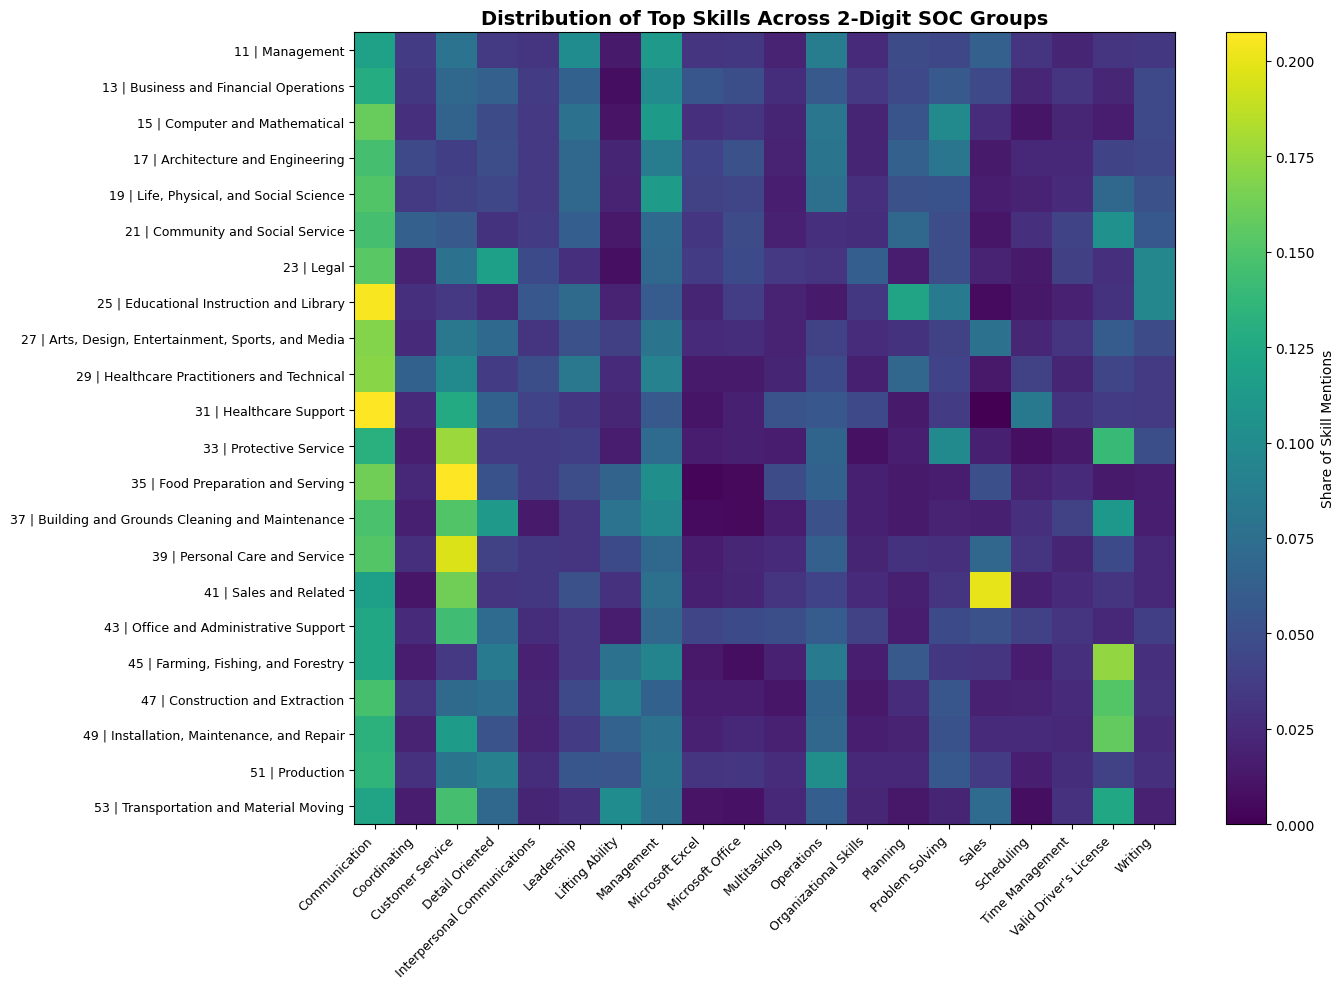

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# PREP DATA
# =========================================================

# skill_counts should already exist from your pipeline
# columns: SOC2 Code, SOC2 Name, Skill, Skill_Postings

df = skill_counts.copy()

# keep top N skills overall to avoid clutter
TOP_SKILLS = 20

top_skills = (
    df.groupby("Skill")["Skill_Postings"]
    .sum()
    .sort_values(ascending=False)
    .head(TOP_SKILLS)
    .index
)

df = df[df["Skill"].isin(top_skills)]

# pivot to matrix
heatmap_df = df.pivot_table(
    index=["SOC2 Code", "SOC2 Name"],
    columns="Skill",
    values="Skill_Postings",
    aggfunc="sum",
    fill_value=0
)

# normalize by row (optional but recommended)
heatmap_df = heatmap_df.div(heatmap_df.sum(axis=1), axis=0)

# =========================================================
# PLOT
# =========================================================

plt.figure(figsize=(14, 10))

plt.imshow(heatmap_df, aspect="auto")

plt.colorbar(label="Share of Skill Mentions")

plt.xticks(
    ticks=np.arange(len(heatmap_df.columns)),
    labels=heatmap_df.columns,
    rotation=45,
    ha="right",
    fontsize=9
)

y_labels = [
    f"{code} | {name}"
    for code, name in heatmap_df.index
]

plt.yticks(
    ticks=np.arange(len(heatmap_df.index)),
    labels=y_labels,
    fontsize=9
)

plt.title(
    "Distribution of Top Skills Across 2-Digit SOC Groups",
    fontsize=14,
    weight="bold"
)

plt.tight_layout()

plt.savefig(r"C:\Users\301533\Documents\AI Analysis\Skill_Heatmap.png", dpi=300)
plt.show()

In [ ]:
# =========================================================
# TOP 3 SKILLS PER SOC2 (CLEAN VERSION)
# =========================================================

top3 = (
    skill_counts
    .sort_values(["SOC2 Code", "Skill_Postings"], ascending=[True, False])
    .groupby(["SOC2 Code", "SOC2 Name"])
    .head(3)
)

top3["Rank"] = (
    top3.groupby(["SOC2 Code", "SOC2 Name"])
    .cumcount() + 1
)

top3_wide = top3.pivot(
    index=["SOC2 Code", "SOC2 Name"],
    columns="Rank",
    values="Skill"
).reset_index()

top3_wide.columns = [
    "SOC2 Code",
    "SOC2 Name",
    "Top Skill 1",
    "Top Skill 2",
    "Top Skill 3"
]

# sort properly
top3_wide["SOC2 Sort"] = pd.to_numeric(top3_wide["SOC2 Code"], errors="coerce")
top3_wide = top3_wide.sort_values("SOC2 Sort").drop(columns="SOC2 Sort")

print(top3_wide)

   SOC2 Code                                       SOC2 Name  \
0         11                                      Management   
1         13               Business and Financial Operations   
2         15                       Computer and Mathematical   
3         17                    Architecture and Engineering   
4         19              Life, Physical, and Social Science   
5         21                    Community and Social Service   
6         23                                           Legal   
7         25             Educational Instruction and Library   
8         27  Arts, Design, Entertainment, Sports, and Media   
9         29          Healthcare Practitioners and Technical   
10        31                              Healthcare Support   
11        33                              Protective Service   
12        35                    Food Preparation and Serving   
13        37   Building and Grounds Cleaning and Maintenance   
14        39                       Perso

In [ ]:
# =========================================================
# TOP SKILLS: HIGH VS LOW AI EXPOSURE
# =========================================================

from collections import Counter, defaultdict

TOP_N = 5

skill_counts_by_group = {
    "High": Counter(),
    "Low": Counter()
}

# map SOC -> exposure group
soc_to_exposure = dict(zip(
    soc_level["soc_code_clean"],
    soc_level["exposure_group"].astype(str)
))

# =========================================================
# LOOP THROUGH LIGHTCAST AGAIN (FAST VERSION)
# =========================================================

print("\nBuilding skill comparison (High vs Low AI)...")

chunk_num = 0

for chunk in pd.read_csv(
    LIGHTCAST_FILE,
    usecols=["YEAR", "SOC_5", "SKILLS_NAME"],
    chunksize=100000
):

    chunk_num += 1
    chunk.columns = chunk.columns.str.strip()

    chunk["YEAR"] = pd.to_numeric(chunk["YEAR"], errors="coerce")
    chunk = chunk[chunk["YEAR"] == 2024]

    if len(chunk) == 0:
        continue

    chunk["SOC_5"] = (
        chunk["SOC_5"]
        .astype(str)
        .str.strip()
        .str.replace(".00", "", regex=False)
        .apply(fix_soc_code)
    )

    chunk["exposure"] = chunk["SOC_5"].map(soc_to_exposure)

    # keep only High and Low groups
    chunk["group"] = np.where(
        chunk["exposure"].isin(["High", "Very High"]),
        "High",
        np.where(
            chunk["exposure"].isin(["Low", "Very Low"]),
            "Low",
            None
        )
    )

    chunk = chunk[chunk["group"].notna()]

    for _, row in chunk.iterrows():
        skills = parse_skill_list(row["SKILLS_NAME"])
        if not skills:
            continue

        for skill in skills:
            skill_counts_by_group[row["group"]][skill] += 1

    print(f"Chunk {chunk_num} processed")

# =========================================================
# BUILD TOP SKILL TABLE
# =========================================================

top_high = skill_counts_by_group["High"].most_common(TOP_N)
top_low = skill_counts_by_group["Low"].most_common(TOP_N)

comparison_df = pd.DataFrame({
    "Rank": range(1, TOP_N + 1),
    "High AI Exposure": [s[0] for s in top_high],
    "Low AI Exposure": [s[0] for s in top_low]
})

print("\nTop Skills Comparison:")
print(comparison_df)


Building skill comparison (High vs Low AI)...
Chunk 76 processed
Chunk 77 processed
Chunk 78 processed
Chunk 79 processed
Chunk 80 processed
Chunk 81 processed
Chunk 82 processed
Chunk 83 processed
Chunk 84 processed
Chunk 85 processed

Top Skills Comparison:
   Rank  High AI Exposure         Low AI Exposure
0     1     Communication        Customer Service
1     2  Customer Service           Communication
2     3        Management  Valid Driver's License
3     4             Sales              Management
4     5        Leadership         Lifting Ability


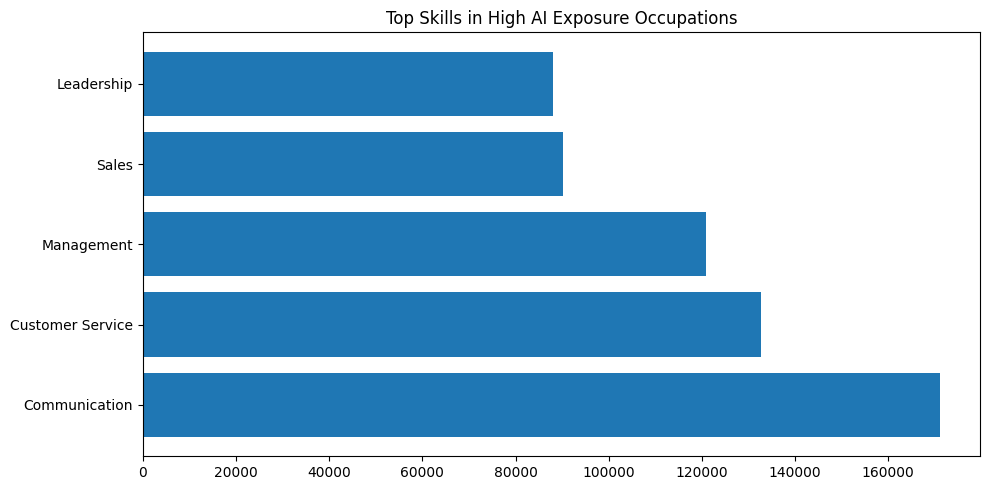

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

y = np.arange(TOP_N)

ax.barh(y, [c[1] for c in top_high])
ax.set_yticks(y)
ax.set_yticklabels([c[0] for c in top_high])
ax.set_title("Top Skills in High AI Exposure Occupations")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from ast import literal_eval
import re
from collections import Counter, defaultdict
import matplotlib.pyplot as plt

# =========================================================
# CONFIG
# =========================================================

AI_EXPOSURE_FILE = Path(r"C:\Users\301533\Documents\AI Analysis\AI Exposure Sheet\ai_exposure_composite.csv.xlsx")
LIGHTCAST_FILE = Path(r"G:\Shared drives\EO_OPERATIONS\Grants\PCIC Analysis\Job Posting Data\raw_data\df_2016_2025.csv")

OUTPUT_DIR = Path(r"C:\Users\301533\Documents\AI Analysis\AI_Figure_Output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PNG = OUTPUT_DIR / "Figure_AI_HighLow_SOC2_TopSkills_Comparison_v2.png"
OUTPUT_XLSX = OUTPUT_DIR / "Figure_AI_HighLow_SOC2_TopSkills_Comparison_v2.xlsx"

LIGHTCAST_YEAR = 2024
CHUNK_SIZE = 100000
MAX_CHUNKS = None   # set to 5 for a quick test run

TOP_N_GROUPS = 6
TOP_N_SKILLS = 3

EXPOSURE_ORDER = ["Very Low", "Low", "Medium", "High", "Very High"]
AI_HIGH_GROUPS = ["High", "Very High"]
AI_LOW_GROUPS = ["Very Low", "Low"]

# Keep generic skills in this version
REMOVE_SKILLS = set()

SOC2_LABELS = {
    "11": "Management",
    "13": "Business and Financial Operations",
    "15": "Computer and Mathematical",
    "17": "Architecture and Engineering",
    "19": "Life, Physical, and Social Science",
    "21": "Community and Social Service",
    "23": "Legal",
    "25": "Educational Instruction and Library",
    "27": "Arts, Design, Entertainment, Sports, and Media",
    "29": "Healthcare Practitioners and Technical",
    "31": "Healthcare Support",
    "33": "Protective Service",
    "35": "Food Preparation and Serving",
    "37": "Building and Grounds Cleaning and Maintenance",
    "39": "Personal Care and Service",
    "41": "Sales and Related",
    "43": "Office and Administrative Support",
    "45": "Farming, Fishing, and Forestry",
    "47": "Construction and Extraction",
    "49": "Installation, Maintenance, and Repair",
    "51": "Production",
    "53": "Transportation and Material Moving",
    "55": "Military Specific",
}

# =========================================================
# HELPERS
# =========================================================

def clean_money(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace(r"[\$,]", "", regex=True).str.strip(),
        errors="coerce"
    )

def clean_numeric(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace(",", "", regex=False).str.strip(),
        errors="coerce"
    )

def clean_percent_string(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace("%", "", regex=False).str.strip(),
        errors="coerce"
    )

def first_existing_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of these columns were found: {candidates}")

def first_non_null(series):
    s = series.dropna()
    return s.iloc[0] if len(s) > 0 else np.nan

def parse_skill_list(value):
    if pd.isna(value):
        return []
    s = str(value).strip()
    if not s or s.lower() == "nan":
        return []
    try:
        parsed = literal_eval(s)
        if isinstance(parsed, list):
            return [str(v).strip() for v in parsed if str(v).strip()]
    except Exception:
        pass
    parts = re.split(r"\||;|,", s)
    return [p.strip() for p in parts if p.strip()]

def fix_soc_code(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    # Already valid SOC code
    if re.match(r"^\d{2}-\d{4}$", s):
        return s

    # Excel text like Nov-11
    if re.match(r"^Nov-\d{2}$", s, flags=re.IGNORECASE):
        yy = s.split("-")[1]
        return f"11-20{yy}"

    # Excel full datetime string like 2011-11-01 00:00:00
    m = re.match(r"^(\d{4})-11-01(?: 00:00:00)?$", s)
    if m:
        year = m.group(1)
        return f"11-{year}"

    # Slightly different timestamp format
    m2 = re.match(r"^(\d{4})-11-01", s)
    if m2:
        year = m2.group(1)
        return f"11-{year}"

    s = s.replace(".0", "").replace(".00", "")
    return s

def soc2(code):
    if pd.isna(code):
        return np.nan
    code = str(code).strip()
    return code[:2] if len(code) >= 2 else np.nan

def add_soc2_columns(df, soc_col="soc_code_clean"):
    df = df.copy()
    df["SOC2_Code"] = df[soc_col].apply(soc2)
    df["SOC2_Name"] = df["SOC2_Code"].map(SOC2_LABELS)
    return df

def normalize_skill(s):
    s = str(s).strip()
    if not s:
        return s

    s_low = s.lower()

    if "problem solving" in s_low or "troubleshooting" in s_low:
        return "Problem Solving"
    if "excel" in s_low:
        return "Excel"
    if "project management" in s_low or "project manager" in s_low or "project" in s_low:
        return "Project Management"
    if "nurs" in s_low:
        return "Nursing"
    if "hvac" in s_low:
        return "HVAC"
    if "customer service" in s_low:
        return "Customer Service"
    if "communicat" in s_low:
        return "Communication"
    if "leadership" in s_low:
        return "Leadership"
    if "detail orient" in s_low:
        return "Detail Oriented"
    if "operations" in s_low:
        return "Operations"
    if "sales" in s_low:
        return "Sales"
    if "valid driver's license" in s_low or "driver's license" in s_low:
        return "Valid Driver's License"

    return s.title()

def wrap_name(text, width=34):
    text = str(text)
    words = text.split()
    lines = []
    current = []

    for word in words:
        trial = " ".join(current + [word])
        if len(trial) <= width:
            current.append(word)
        else:
            if current:
                lines.append(" ".join(current))
            current = [word]
    if current:
        lines.append(" ".join(current))

    return "\n".join(lines)

def make_label_row(row):
    soc_name_wrapped = wrap_name(row["SOC2_Name"], width=32)
    return (
        f"{row['SOC2_Code']} | {soc_name_wrapped}\n"
        f"AI exposure: {row['High_VeryHigh_Share_Pct']:.1f}%\n"
        f"1. {row['Top Skill 1']}\n"
        f"2. {row['Top Skill 2']}\n"
        f"3. {row['Top Skill 3']}"
    )

# =========================================================
# LOAD AI EXPOSURE FILE
# =========================================================

print("Loading AI exposure file...")
df = pd.read_excel(AI_EXPOSURE_FILE)
df.columns = [str(c).strip() for c in df.columns]

PCA_COL = "PCA Weighted Score.1"
Z_COL = "Z Score Variance.1"
TITLE_COL = "Title"
SOC_CANDIDATES = ["SOC2018.1", "O*NET-SOC Code", "SOC Code", "SOC Code1"]
WAGE_COL = "50th Percentile Wage"
OPENINGS_COL = "Annual Total Openings"
GROWTH_COL = "GrowthRate"
GROWTH_PCT_STR_COL = "Annual Percent Change"
EMPLOYMENT_COL = "Rounded Employment"

RAW_SOC_COL = first_existing_col(df, SOC_CANDIDATES)

df["soc_code_clean"] = (
    df[RAW_SOC_COL]
    .astype(str)
    .str.strip()
    .str.replace(".00", "", regex=False)
    .apply(fix_soc_code)
)

df["pca_score"] = clean_numeric(df[PCA_COL])
df["z_score"] = clean_numeric(df[Z_COL])
df["wage"] = clean_money(df[WAGE_COL])
df["openings"] = clean_numeric(df[OPENINGS_COL])
df["growth_rate"] = clean_numeric(df[GROWTH_COL])

if df["growth_rate"].isna().all() and GROWTH_PCT_STR_COL in df.columns:
    df["growth_rate"] = clean_percent_string(df[GROWTH_PCT_STR_COL])

df["employment"] = clean_numeric(df[EMPLOYMENT_COL])

print("\nSample of fixed SOC codes:")
print(df[[RAW_SOC_COL, "soc_code_clean"]].head(25))

# =========================================================
# COLLAPSE TO ONE ROW PER 6-DIGIT SOC
# =========================================================

print("\nBuilding SOC-level file...")

soc_level = (
    df.groupby("soc_code_clean", as_index=False)
      .agg({
          "pca_score": "mean",
          "z_score": "mean",
          "wage": "median",
          "openings": "median",
          "growth_rate": "median",
          "employment": "median",
          TITLE_COL: first_non_null
      })
)

soc_level = soc_level[~soc_level["pca_score"].isna()].copy()

soc_level["exposure_group"] = pd.qcut(
    soc_level["pca_score"],
    5,
    labels=EXPOSURE_ORDER
)

soc_level["exposure_group"] = pd.Categorical(
    soc_level["exposure_group"],
    categories=EXPOSURE_ORDER,
    ordered=True
)

soc_level = add_soc2_columns(soc_level)
soc_level = soc_level[
    soc_level["SOC2_Code"].notna() &
    soc_level["SOC2_Name"].notna()
].copy()

soc_level["SOC2_Sort"] = pd.to_numeric(soc_level["SOC2_Code"], errors="coerce")

print("\nSOC-level preview:")
print(soc_level[["soc_code_clean", "Title", "SOC2_Code", "SOC2_Name", "exposure_group"]].head(20))

# =========================================================
# BUILD SOC2 AI EXPOSURE SUMMARY
# =========================================================

soc2_ai = (
    soc_level.groupby(["SOC2_Code", "SOC2_Name"], observed=True)
    .agg(
        Occupation_Count=("soc_code_clean", "nunique"),
        High_VeryHigh_Count=("exposure_group", lambda s: s.astype(str).isin(AI_HIGH_GROUPS).sum())
    )
    .reset_index()
)

soc2_ai["High_VeryHigh_Share"] = soc2_ai["High_VeryHigh_Count"] / soc2_ai["Occupation_Count"]
soc2_ai["High_VeryHigh_Share_Pct"] = soc2_ai["High_VeryHigh_Share"] * 100
soc2_ai["SOC2_Sort"] = pd.to_numeric(soc2_ai["SOC2_Code"], errors="coerce")

high_soc2 = (
    soc2_ai.sort_values(
        by=["High_VeryHigh_Share", "Occupation_Count", "SOC2_Sort"],
        ascending=[False, False, True]
    )
    .head(TOP_N_GROUPS)
    .copy()
)

low_soc2 = (
    soc2_ai.sort_values(
        by=["High_VeryHigh_Share", "Occupation_Count", "SOC2_Sort"],
        ascending=[True, False, True]
    )
    .head(TOP_N_GROUPS)
    .copy()
)

print("\nHighest AI exposure SOC2 groups:")
print(high_soc2[["SOC2_Code", "SOC2_Name", "Occupation_Count", "High_VeryHigh_Share_Pct"]])

print("\nLowest AI exposure SOC2 groups:")
print(low_soc2[["SOC2_Code", "SOC2_Name", "Occupation_Count", "High_VeryHigh_Share_Pct"]])

# =========================================================
# BUILD SKILL COUNTS BY SOC2 FROM LIGHTCAST
# =========================================================

print("\nBuilding skill counts from Lightcast in chunks...")

soc_to_sector_code = dict(zip(soc_level["soc_code_clean"], soc_level["SOC2_Code"]))
soc_to_sector_name = dict(zip(soc_level["soc_code_clean"], soc_level["SOC2_Name"]))

sector_skill_counts = defaultdict(Counter)

chunk_num = 0
rows_seen = 0
rows_kept_year = 0
rows_kept_sector = 0

for chunk in pd.read_csv(
    LIGHTCAST_FILE,
    usecols=["YEAR", "SOC_5", "SKILLS_NAME"],
    chunksize=CHUNK_SIZE
):
    chunk_num += 1
    rows_seen += len(chunk)

    chunk.columns = chunk.columns.str.strip()
    chunk["YEAR"] = pd.to_numeric(chunk["YEAR"], errors="coerce")
    chunk = chunk[chunk["YEAR"] == LIGHTCAST_YEAR].copy()
    rows_kept_year += len(chunk)

    if len(chunk) == 0:
        print(f"Chunk {chunk_num}: no {LIGHTCAST_YEAR} rows")
        if MAX_CHUNKS is not None and chunk_num >= MAX_CHUNKS:
            print("Stopping early for test run.")
            break
        continue

    chunk["SOC_5"] = (
        chunk["SOC_5"]
        .astype(str)
        .str.strip()
        .str.replace(".00", "", regex=False)
        .apply(fix_soc_code)
    )

    chunk["SOC2_Code"] = chunk["SOC_5"].map(soc_to_sector_code)
    chunk["SOC2_Name"] = chunk["SOC_5"].map(soc_to_sector_name)

    chunk = chunk[chunk["SOC2_Code"].notna()].copy()
    rows_kept_sector += len(chunk)

    if len(chunk) == 0:
        print(f"Chunk {chunk_num}: no matched SOC sectors")
        if MAX_CHUNKS is not None and chunk_num >= MAX_CHUNKS:
            print("Stopping early for test run.")
            break
        continue

    for _, row in chunk.iterrows():
        sector_key = (row["SOC2_Code"], row["SOC2_Name"])
        skills = parse_skill_list(row["SKILLS_NAME"])
        if not skills:
            continue

        for skill in skills:
            skill_norm = normalize_skill(skill)
            if skill_norm in REMOVE_SKILLS:
                continue
            sector_skill_counts[sector_key][skill_norm] += 1

    print(
        f"Chunk {chunk_num}: seen={rows_seen:,}, "
        f"{LIGHTCAST_YEAR}_rows={rows_kept_year:,}, "
        f"matched_sector_rows={rows_kept_sector:,}"
    )

    if MAX_CHUNKS is not None and chunk_num >= MAX_CHUNKS:
        print("Stopping early for test run.")
        break

# =========================================================
# BUILD SKILL COUNT TABLE
# =========================================================

skill_count_rows = []
for (sector_code, sector_name), counter in sector_skill_counts.items():
    for skill, count in counter.items():
        skill_count_rows.append({
            "SOC2 Code": sector_code,
            "SOC2 Name": sector_name,
            "Skill": skill,
            "Skill_Postings": count
        })

skill_counts = pd.DataFrame(skill_count_rows)

if skill_counts.empty:
    raise ValueError("No skill counts were created. Check the Lightcast file path, year, or SOC mapping.")

skill_counts["SOC2_Sort"] = pd.to_numeric(skill_counts["SOC2 Code"], errors="coerce")
skill_counts = skill_counts.sort_values(
    by=["SOC2_Sort", "Skill_Postings"],
    ascending=[True, False]
).drop(columns=["SOC2_Sort"]).reset_index(drop=True)

print("\nSkill count preview:")
print(skill_counts.head(20))

# =========================================================
# BUILD TOP 3 SKILLS FOR EACH SOC2
# =========================================================

top3 = (
    skill_counts.sort_values(["SOC2 Code", "Skill_Postings"], ascending=[True, False])
    .groupby(["SOC2 Code", "SOC2 Name"], as_index=False, group_keys=False)
    .head(TOP_N_SKILLS)
    .copy()
)

top3["Rank"] = (
    top3.groupby(["SOC2 Code", "SOC2 Name"])
    .cumcount() + 1
)

top3_wide = (
    top3.pivot(
        index=["SOC2 Code", "SOC2 Name"],
        columns="Rank",
        values="Skill"
    )
    .reset_index()
)

top3_wide.columns = [
    "SOC2_Code",
    "SOC2_Name",
    "Top Skill 1",
    "Top Skill 2",
    "Top Skill 3"
]

for col in ["Top Skill 1", "Top Skill 2", "Top Skill 3"]:
    top3_wide[col] = top3_wide[col].fillna("—")

# =========================================================
# MERGE AI + SKILLS
# =========================================================

plot_df = soc2_ai.merge(
    top3_wide,
    left_on=["SOC2_Code", "SOC2_Name"],
    right_on=["SOC2_Code", "SOC2_Name"],
    how="left"
)

for col in ["Top Skill 1", "Top Skill 2", "Top Skill 3"]:
    plot_df[col] = plot_df[col].fillna("—")

high_plot = plot_df.merge(
    high_soc2[["SOC2_Code", "SOC2_Name"]],
    on=["SOC2_Code", "SOC2_Name"],
    how="inner"
).sort_values(
    by=["High_VeryHigh_Share", "Occupation_Count", "SOC2_Sort"],
    ascending=[False, False, True]
).reset_index(drop=True)

low_plot = plot_df.merge(
    low_soc2[["SOC2_Code", "SOC2_Name"]],
    on=["SOC2_Code", "SOC2_Name"],
    how="inner"
).sort_values(
    by=["High_VeryHigh_Share", "Occupation_Count", "SOC2_Sort"],
    ascending=[True, False, True]
).reset_index(drop=True)

# =========================================================
# EXPORT SOURCE TABLE
# =========================================================

export_df = pd.concat([
    high_plot.assign(Group="Highest AI Exposure"),
    low_plot.assign(Group="Lowest AI Exposure")
], ignore_index=True)

export_df = export_df[[
    "Group",
    "SOC2_Code",
    "SOC2_Name",
    "Occupation_Count",
    "High_VeryHigh_Share_Pct",
    "Top Skill 1",
    "Top Skill 2",
    "Top Skill 3"
]]

export_df = export_df.rename(columns={
    "SOC2_Code": "SOC2 Code",
    "SOC2_Name": "SOC2 Name",
    "Occupation_Count": "Total Occupations",
    "High_VeryHigh_Share_Pct": "High/Very High AI Exposure (%)"
})

export_df.to_excel(OUTPUT_XLSX, index=False)

# =========================================================
# MAKE FIGURE
# =========================================================

left_labels = [make_label_row(r) for _, r in high_plot.iterrows()]
right_labels = [make_label_row(r) for _, r in low_plot.iterrows()]

max_rows = max(len(high_plot), len(low_plot))

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, max_rows * 1.6 + 2.5),
    sharex=True
)

# LEFT PANEL
ax = axes[0]
y_left = np.arange(len(high_plot))
x_left = high_plot["High_VeryHigh_Share_Pct"].values

ax.barh(y_left, x_left)
ax.set_yticks(y_left)
ax.set_yticklabels(left_labels, fontsize=10)
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_title("Highest AI Exposure 2-Digit SOC Groups", fontsize=13, weight="bold")
ax.set_xlabel("High / Very High AI Exposure (%)", fontsize=11)
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

for i, val in enumerate(x_left):
    ax.text(min(val + 1, 98), i, f"{val:.1f}%", va="center", fontsize=10)

# RIGHT PANEL
ax = axes[1]
y_right = np.arange(len(low_plot))
x_right = low_plot["High_VeryHigh_Share_Pct"].values

ax.barh(y_right, x_right)
ax.set_yticks(y_right)
ax.set_yticklabels(right_labels, fontsize=10)
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_title("Lowest AI Exposure 2-Digit SOC Groups", fontsize=13, weight="bold")
ax.set_xlabel("High / Very High AI Exposure (%)", fontsize=11)
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

for i, val in enumerate(x_right):
    ax.text(min(val + 1, 98), i, f"{val:.1f}%", va="center", fontsize=10)

plt.suptitle(
    "Top Skills in Highest- and Lowest-AI-Exposure 2-Digit SOC Groups",
    fontsize=16,
    weight="bold",
    y=0.995
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(OUTPUT_PNG, dpi=300, bbox_inches="tight")
plt.close()

print("\nDone.")
print("Figure saved to:", OUTPUT_PNG)
print("Source table saved to:", OUTPUT_XLSX)

Loading AI exposure file...

Sample of fixed SOC codes:
              SOC2018.1 soc_code_clean
0               11-1011        11-1011
1               11-1011        11-1011
2               11-1021        11-1021
3   2011-11-01 00:00:00        11-2011
4   2021-11-01 00:00:00        11-2021
5   2022-11-01 00:00:00        11-2022
6   2032-11-01 00:00:00        11-2032
7   2033-11-01 00:00:00        11-2033
8   3012-11-01 00:00:00        11-3012
9   3013-11-01 00:00:00        11-3013
10  3013-11-01 00:00:00        11-3013
11  3021-11-01 00:00:00        11-3021
12  3031-11-01 00:00:00        11-3031
13  3031-11-01 00:00:00        11-3031
14  3031-11-01 00:00:00        11-3031
15  3051-11-01 00:00:00        11-3051
16  3051-11-01 00:00:00        11-3051
17  3051-11-01 00:00:00        11-3051
18  3051-11-01 00:00:00        11-3051
19  3051-11-01 00:00:00        11-3051
20  3051-11-01 00:00:00        11-3051
21  3061-11-01 00:00:00        11-3061
22  3071-11-01 00:00:00        11-3071
23  3071

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from ast import literal_eval
import re
from collections import Counter
import matplotlib.pyplot as plt

# =========================================================
# CONFIG
# =========================================================

AI_EXPOSURE_FILE = Path(r"C:\Users\301533\Documents\AI Analysis\AI Exposure Sheet\ai_exposure_composite.csv.xlsx")
LIGHTCAST_FILE = Path(r"G:\Shared drives\EO_OPERATIONS\Grants\PCIC Analysis\Job Posting Data\raw_data\df_2016_2025.csv")

OUTPUT_DIR = Path(r"C:\Users\301533\Documents\AI Analysis\AI_Figure_Output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PNG = OUTPUT_DIR / "Figure_MirrorBar_TopSkills_High_vs_Low_AI.png"
OUTPUT_XLSX = OUTPUT_DIR / "Figure_MirrorBar_TopSkills_High_vs_Low_AI.xlsx"

LIGHTCAST_YEAR = 2024
CHUNK_SIZE = 100000
MAX_CHUNKS = None   # set to 5 for quick testing

TOP_N = 10

EXPOSURE_ORDER = ["Very Low", "Low", "Medium", "High", "Very High"]
HIGH_AI_GROUPS = {"High", "Very High"}
LOW_AI_GROUPS = {"Very Low", "Low"}

# =========================================================
# SKILL FILTERS
# =========================================================

REMOVE_SKILLS_EXACT = {
    "Communication",
    "Valid Driver's License",
    "Driver's License",
    "Furniture Cleaning",
    "Housekeeping",
    "Lawsuits",
    "Mopping",
    "Cleanliness",
    "Lifting Ability",
    "Pruning",
    "Irrigation",
    "Background Check",
    "Drug Test"
}

REMOVE_SKILL_PATTERNS = [
    r"communicat",
    r"driver",
    r"license",
    r"furniture",
    r"housekeeping",
    r"mopping",
    r"cleaning",
    r"cleanliness",
    r"lawsuit",
    r"lifting",
    r"pruning",
    r"irrigation",
    r"background check",
    r"drug test"
]

# =========================================================
# HELPERS
# =========================================================

def clean_numeric(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace(",", "", regex=False).str.strip(),
        errors="coerce"
    )

def first_existing_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of these columns were found: {candidates}")

def fix_soc_code(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    # already valid
    if re.match(r"^\d{2}-\d{4}$", s):
        return s

    # Excel text like Nov-11
    if re.match(r"^Nov-\d{2}$", s, flags=re.IGNORECASE):
        yy = s.split("-")[1]
        return f"11-20{yy}"

    # Excel datetime like 2011-11-01 00:00:00
    m = re.match(r"^(\d{4})-11-01(?: 00:00:00)?$", s)
    if m:
        year = m.group(1)
        return f"11-{year}"

    # other timestamp-like strings
    m2 = re.match(r"^(\d{4})-11-01", s)
    if m2:
        year = m2.group(1)
        return f"11-{year}"

    s = s.replace(".0", "").replace(".00", "")
    return s

def parse_skill_list(value):
    if pd.isna(value):
        return []
    s = str(value).strip()
    if not s or s.lower() == "nan":
        return []
    try:
        parsed = literal_eval(s)
        if isinstance(parsed, list):
            return [str(v).strip() for v in parsed if str(v).strip()]
    except Exception:
        pass
    parts = re.split(r"\||;|,", s)
    return [p.strip() for p in parts if p.strip()]

def normalize_skill(s):
    s = str(s).strip()
    if not s:
        return s

    s_low = s.lower()

    if "problem solving" in s_low or "troubleshooting" in s_low:
        return "Problem Solving"
    if "project management" in s_low or "project manager" in s_low or "project" in s_low:
        return "Project Management"
    if "leadership" in s_low:
        return "Leadership"
    if "detail orient" in s_low:
        return "Detail Oriented"
    if "excel" in s_low:
        return "Excel"
    if "customer service" in s_low:
        return "Customer Service"
    if "operations" in s_low:
        return "Operations"
    if s_low == "sales":
        return "Sales"
    if "computer science" in s_low:
        return "Computer Science"
    if "construction" in s_low:
        return "Construction"
    if "warehous" in s_low:
        return "Warehousing"
    if "nurs" in s_low:
        return "Nursing"
    if "hvac" in s_low:
        return "HVAC"
    if "research" in s_low:
        return "Research"
    if "writing" in s_low:
        return "Writing"

    return s.title()

def skill_should_be_removed(skill):
    if pd.isna(skill):
        return True

    s = str(skill).strip()
    if not s:
        return True

    s_low = s.lower()

    if s in REMOVE_SKILLS_EXACT:
        return True

    for pattern in REMOVE_SKILL_PATTERNS:
        if re.search(pattern, s_low):
            return True

    return False

# =========================================================
# LOAD AI EXPOSURE FILE
# =========================================================

print("Loading AI exposure file...")
df = pd.read_excel(AI_EXPOSURE_FILE)
df.columns = [str(c).strip() for c in df.columns]

PCA_COL = "PCA Weighted Score.1"
SOC_CANDIDATES = ["SOC2018.1", "O*NET-SOC Code", "SOC Code", "SOC Code1"]

RAW_SOC_COL = first_existing_col(df, SOC_CANDIDATES)

df["soc_code_clean"] = (
    df[RAW_SOC_COL]
    .astype(str)
    .str.strip()
    .str.replace(".00", "", regex=False)
    .apply(fix_soc_code)
)

df["pca_score"] = clean_numeric(df[PCA_COL])

print("\nSample of fixed SOC codes:")
print(df[[RAW_SOC_COL, "soc_code_clean"]].head(25))

# =========================================================
# COLLAPSE TO SOC LEVEL
# =========================================================

print("\nBuilding SOC-level AI exposure groups...")

soc_level = (
    df.groupby("soc_code_clean", as_index=False)
      .agg({"pca_score": "mean"})
)

soc_level = soc_level[~soc_level["pca_score"].isna()].copy()

soc_level["exposure_group"] = pd.qcut(
    soc_level["pca_score"],
    5,
    labels=EXPOSURE_ORDER
)

soc_level["exposure_group"] = soc_level["exposure_group"].astype(str)

high_socs = set(soc_level.loc[soc_level["exposure_group"].isin(HIGH_AI_GROUPS), "soc_code_clean"])
low_socs = set(soc_level.loc[soc_level["exposure_group"].isin(LOW_AI_GROUPS), "soc_code_clean"])

print(f"\nHigh AI SOC count: {len(high_socs):,}")
print(f"Low AI SOC count: {len(low_socs):,}")

# =========================================================
# READ LIGHTCAST IN CHUNKS AND COUNT SKILLS
# =========================================================

print("\nReading Lightcast skills in chunks...")

high_counts = Counter()
low_counts = Counter()

chunk_num = 0
rows_seen = 0
rows_kept_year = 0
rows_matched = 0

for chunk in pd.read_csv(
    LIGHTCAST_FILE,
    usecols=["YEAR", "SOC_5", "SKILLS_NAME"],
    chunksize=CHUNK_SIZE
):
    chunk_num += 1
    rows_seen += len(chunk)

    chunk.columns = chunk.columns.str.strip()
    chunk["YEAR"] = pd.to_numeric(chunk["YEAR"], errors="coerce")
    chunk = chunk[chunk["YEAR"] == LIGHTCAST_YEAR].copy()
    rows_kept_year += len(chunk)

    if len(chunk) == 0:
        print(f"Chunk {chunk_num}: no {LIGHTCAST_YEAR} rows")
        if MAX_CHUNKS is not None and chunk_num >= MAX_CHUNKS:
            print("Stopping early for test run.")
            break
        continue

    chunk["SOC_5"] = (
        chunk["SOC_5"]
        .astype(str)
        .str.strip()
        .str.replace(".00", "", regex=False)
        .apply(fix_soc_code)
    )

    for _, row in chunk.iterrows():
        soc = row["SOC_5"]

        if soc in high_socs:
            group = "High AI"
        elif soc in low_socs:
            group = "Low AI"
        else:
            continue

        rows_matched += 1

        skills = parse_skill_list(row["SKILLS_NAME"])
        if not skills:
            continue

        for skill in skills:
            skill_norm = normalize_skill(skill)
            if skill_should_be_removed(skill_norm):
                continue

            if group == "High AI":
                high_counts[skill_norm] += 1
            else:
                low_counts[skill_norm] += 1

    print(
        f"Chunk {chunk_num}: seen={rows_seen:,}, "
        f"{LIGHTCAST_YEAR}_rows={rows_kept_year:,}, "
        f"matched_rows={rows_matched:,}"
    )

    if MAX_CHUNKS is not None and chunk_num >= MAX_CHUNKS:
        print("Stopping early for test run.")
        break

# =========================================================
# BUILD SKILL TABLES
# =========================================================

high_df = pd.DataFrame(high_counts.most_common(TOP_N), columns=["Skill", "Count_High_AI"])
low_df = pd.DataFrame(low_counts.most_common(TOP_N), columns=["Skill", "Count_Low_AI"])

# source table
export_df = pd.concat([
    high_df.assign(Group="High AI Exposure"),
    low_df.assign(Group="Low AI Exposure")
], ignore_index=True)

export_df.to_excel(OUTPUT_XLSX, index=False)

print("\nTop High AI skills:")
print(high_df)

print("\nTop Low AI skills:")
print(low_df)

# =========================================================
# MAKE MIRROR BAR CHART
# =========================================================

# reverse order so the largest appears at the top after invert_yaxis
high_plot = high_df.iloc[::-1].reset_index(drop=True)
low_plot = low_df.iloc[::-1].reset_index(drop=True)

fig, axes = plt.subplots(
    1, 2,
    figsize=(15, 8),
    sharey=False
)

# LEFT: LOW AI
axes[0].barh(low_plot["Skill"], -low_plot["Count_Low_AI"])
axes[0].set_title("Low AI Exposure Occupations", fontsize=14, weight="bold")
axes[0].set_xlabel("Skill Mentions", fontsize=11)
axes[0].axvline(0, linewidth=1)
axes[0].grid(axis="x", linestyle="--", alpha=0.35)
axes[0].set_axisbelow(True)

# RIGHT: HIGH AI
axes[1].barh(high_plot["Skill"], high_plot["Count_High_AI"])
axes[1].set_title("High AI Exposure Occupations", fontsize=14, weight="bold")
axes[1].set_xlabel("Skill Mentions", fontsize=11)
axes[1].axvline(0, linewidth=1)
axes[1].grid(axis="x", linestyle="--", alpha=0.35)
axes[1].set_axisbelow(True)

# clean x tick labels on left to show positive values
left_ticks = axes[0].get_xticks()
axes[0].set_xticklabels([f"{abs(int(x)):,}" if x != 0 else "0" for x in left_ticks])

# add labels at the end of bars
for i, (skill, val) in enumerate(zip(low_plot["Skill"], low_plot["Count_Low_AI"])):
    axes[0].text(-val - max(low_plot["Count_Low_AI"]) * 0.02, i, f"{val:,}", va="center", ha="right", fontsize=9)

for i, (skill, val) in enumerate(zip(high_plot["Skill"], high_plot["Count_High_AI"])):
    axes[1].text(val + max(high_plot["Count_High_AI"]) * 0.02, i, f"{val:,}", va="center", ha="left", fontsize=9)

fig.suptitle(
    "Top Skills in High- and Low-AI-Exposure Occupations",
    fontsize=17,
    weight="bold",
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(OUTPUT_PNG, dpi=300, bbox_inches="tight")
plt.close()

print("\nDone.")
print("Figure saved to:", OUTPUT_PNG)
print("Source table saved to:", OUTPUT_XLSX)

Loading AI exposure file...

Sample of fixed SOC codes:
              SOC2018.1 soc_code_clean
0               11-1011        11-1011
1               11-1011        11-1011
2               11-1021        11-1021
3   2011-11-01 00:00:00        11-2011
4   2021-11-01 00:00:00        11-2021
5   2022-11-01 00:00:00        11-2022
6   2032-11-01 00:00:00        11-2032
7   2033-11-01 00:00:00        11-2033
8   3012-11-01 00:00:00        11-3012
9   3013-11-01 00:00:00        11-3013
10  3013-11-01 00:00:00        11-3013
11  3021-11-01 00:00:00        11-3021
12  3031-11-01 00:00:00        11-3031
13  3031-11-01 00:00:00        11-3031
14  3031-11-01 00:00:00        11-3031
15  3051-11-01 00:00:00        11-3051
16  3051-11-01 00:00:00        11-3051
17  3051-11-01 00:00:00        11-3051
18  3051-11-01 00:00:00        11-3051
19  3051-11-01 00:00:00        11-3051
20  3051-11-01 00:00:00        11-3051
21  3061-11-01 00:00:00        11-3061
22  3071-11-01 00:00:00        11-3071
23  3071

C:\Users\301533\AppData\Local\Temp\ipykernel_26372\2072269127.py:373: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels([f"{abs(int(x)):,}" if x != 0 else "0" for x in left_ticks])



Done.
Figure saved to: C:\Users\301533\Documents\AI Analysis\AI_Figure_Output\Figure_MirrorBar_TopSkills_High_vs_Low_AI.png
Source table saved to: C:\Users\301533\Documents\AI Analysis\AI_Figure_Output\Figure_MirrorBar_TopSkills_High_vs_Low_AI.xlsx


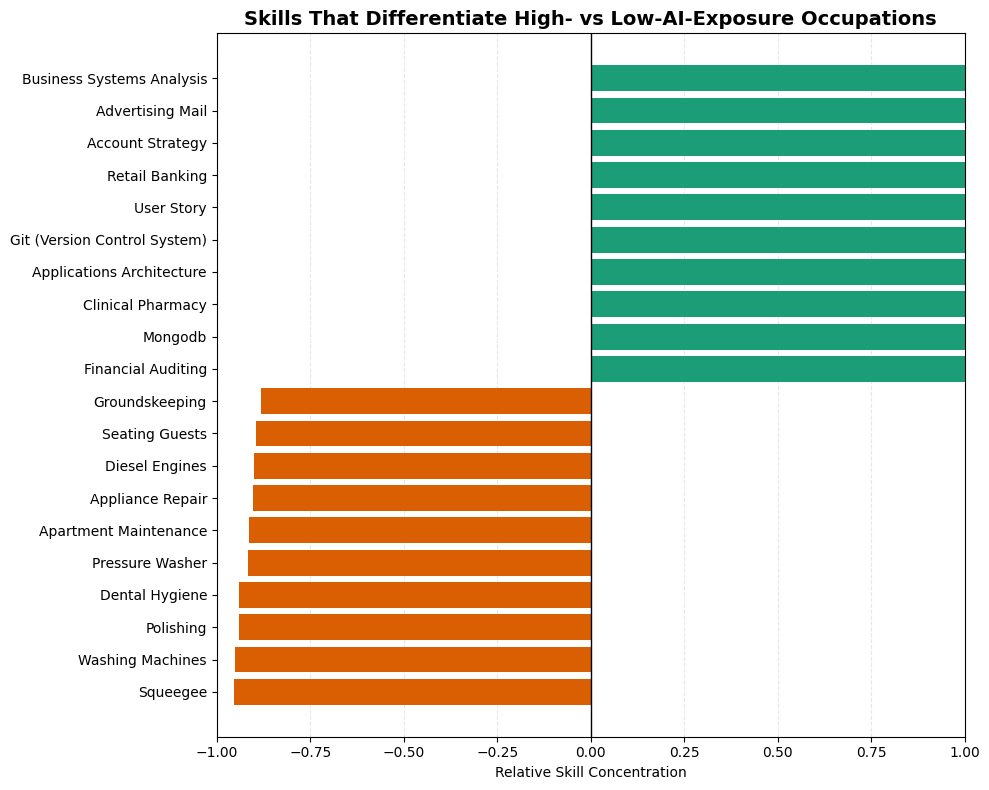

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# assume you already created:
# high_counts (Counter)
# low_counts (Counter)

# =========================================================
# BUILD COMPARISON TABLE
# =========================================================

all_skills = set(high_counts.keys()) | set(low_counts.keys())

rows = []

for skill in all_skills:
    high = high_counts.get(skill, 0)
    low = low_counts.get(skill, 0)
    total = high + low

    if total < 500:   # <-- remove low-signal noise
        continue

    score = (high - low) / total

    rows.append({
        "Skill": skill,
        "High": high,
        "Low": low,
        "Score": score
    })

df = pd.DataFrame(rows)

# split into two sides
top_high = df.sort_values("Score", ascending=False).head(10)
top_low  = df.sort_values("Score", ascending=True).head(10)

plot_df = pd.concat([top_low, top_high])

# =========================================================
# PLOT
# =========================================================

fig, ax = plt.subplots(figsize=(10, 8))

colors = ["#d95f02" if x < 0 else "#1b9e77" for x in plot_df["Score"]]

ax.barh(plot_df["Skill"], plot_df["Score"], color=colors)

ax.axvline(0, color="black", linewidth=1)

ax.set_title("Skills That Differentiate High- vs Low-AI-Exposure Occupations",
             fontsize=14, weight="bold")

ax.set_xlabel("Relative Skill Concentration")

ax.set_xlim(-1, 1)

# clean grid
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from ast import literal_eval
import re
from collections import Counter
import matplotlib.pyplot as plt

# =========================================================
# CONFIG
# =========================================================

AI_EXPOSURE_FILE = Path(r"C:\Users\301533\Documents\AI Analysis\AI Exposure Sheet\ai_exposure_composite.csv.xlsx")
LIGHTCAST_FILE = Path(r"G:\Shared drives\EO_OPERATIONS\Grants\PCIC Analysis\Job Posting Data\raw_data\df_2016_2025.csv")

OUTPUT_DIR = Path(r"C:\Users\301533\Documents\AI Analysis\AI_Figure_Output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PNG = OUTPUT_DIR / "Figure_MirrorBar_DistinguishingSkills_High_vs_Low_AI.png"
OUTPUT_XLSX = OUTPUT_DIR / "Figure_MirrorBar_DistinguishingSkills_High_vs_Low_AI.xlsx"

LIGHTCAST_YEAR = 2024
CHUNK_SIZE = 100000
MAX_CHUNKS = None   # set to 5 for quick testing

TOP_N = 10
MIN_TOTAL_MENTIONS = 500

EXPOSURE_ORDER = ["Very Low", "Low", "Medium", "High", "Very High"]
HIGH_AI_GROUPS = {"High", "Very High"}
LOW_AI_GROUPS = {"Very Low", "Low"}

# =========================================================
# SKILL FILTERS
# =========================================================

REMOVE_SKILLS_EXACT = {
    "Communication",
    "Valid Driver's License",
    "Driver's License",
    "Furniture Cleaning",
    "Housekeeping",
    "Lawsuits",
    "Mopping",
    "Cleanliness",
    "Lifting Ability",
    "Pruning",
    "Irrigation",
    "Background Check",
    "Drug Test"
}

REMOVE_SKILL_PATTERNS = [
    r"communicat",
    r"driver",
    r"license",
    r"furniture",
    r"housekeeping",
    r"mopping",
    r"cleaning",
    r"cleanliness",
    r"lawsuit",
    r"lifting",
    r"pruning",
    r"irrigation",
    r"background check",
    r"drug test"
]

# =========================================================
# HELPERS
# =========================================================

def clean_numeric(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace(",", "", regex=False).str.strip(),
        errors="coerce"
    )

def first_existing_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of these columns were found: {candidates}")

def fix_soc_code(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    # already valid
    if re.match(r"^\d{2}-\d{4}$", s):
        return s

    # Excel text like Nov-11
    if re.match(r"^Nov-\d{2}$", s, flags=re.IGNORECASE):
        yy = s.split("-")[1]
        return f"11-20{yy}"

    # Excel datetime like 2011-11-01 00:00:00
    m = re.match(r"^(\d{4})-11-01(?: 00:00:00)?$", s)
    if m:
        year = m.group(1)
        return f"11-{year}"

    # other timestamp-like strings
    m2 = re.match(r"^(\d{4})-11-01", s)
    if m2:
        year = m2.group(1)
        return f"11-{year}"

    s = s.replace(".0", "").replace(".00", "")
    return s

def parse_skill_list(value):
    if pd.isna(value):
        return []
    s = str(value).strip()
    if not s or s.lower() == "nan":
        return []
    try:
        parsed = literal_eval(s)
        if isinstance(parsed, list):
            return [str(v).strip() for v in parsed if str(v).strip()]
    except Exception:
        pass
    parts = re.split(r"\||;|,", s)
    return [p.strip() for p in parts if p.strip()]

def normalize_skill(s):
    s = str(s).strip()
    if not s:
        return s

    s_low = s.lower()

    if "problem solving" in s_low or "troubleshooting" in s_low:
        return "Problem Solving"
    if "project management" in s_low or "project manager" in s_low or "project" in s_low:
        return "Project Management"
    if "leadership" in s_low:
        return "Leadership"
    if "detail orient" in s_low:
        return "Detail Oriented"
    if "excel" in s_low:
        return "Excel"
    if "customer service" in s_low:
        return "Customer Service"
    if "operations" in s_low:
        return "Operations"
    if s_low == "sales":
        return "Sales"
    if "computer science" in s_low:
        return "Computer Science"
    if "construction" in s_low:
        return "Construction"
    if "warehous" in s_low:
        return "Warehousing"
    if "nurs" in s_low:
        return "Nursing"
    if "hvac" in s_low:
        return "HVAC"
    if "research" in s_low:
        return "Research"
    if "writing" in s_low:
        return "Writing"
    if "restaurant operation" in s_low or "restaurant operations" in s_low:
        return "Restaurant Operation"
    if "english language" in s_low:
        return "English Language"

    return s.title()

def skill_should_be_removed(skill):
    if pd.isna(skill):
        return True

    s = str(skill).strip()
    if not s:
        return True

    s_low = s.lower()

    if s in REMOVE_SKILLS_EXACT:
        return True

    for pattern in REMOVE_SKILL_PATTERNS:
        if re.search(pattern, s_low):
            return True

    return False

# =========================================================
# LOAD AI EXPOSURE FILE
# =========================================================

print("Loading AI exposure file...")
df = pd.read_excel(AI_EXPOSURE_FILE)
df.columns = [str(c).strip() for c in df.columns]

PCA_COL = "PCA Weighted Score.1"
SOC_CANDIDATES = ["SOC2018.1", "O*NET-SOC Code", "SOC Code", "SOC Code1"]

RAW_SOC_COL = first_existing_col(df, SOC_CANDIDATES)

df["soc_code_clean"] = (
    df[RAW_SOC_COL]
    .astype(str)
    .str.strip()
    .str.replace(".00", "", regex=False)
    .apply(fix_soc_code)
)

df["pca_score"] = clean_numeric(df[PCA_COL])

print("\nSample of fixed SOC codes:")
print(df[[RAW_SOC_COL, "soc_code_clean"]].head(25))

# =========================================================
# COLLAPSE TO SOC LEVEL
# =========================================================

print("\nBuilding SOC-level AI exposure groups...")

soc_level = (
    df.groupby("soc_code_clean", as_index=False)
      .agg({"pca_score": "mean"})
)

soc_level = soc_level[~soc_level["pca_score"].isna()].copy()

soc_level["exposure_group"] = pd.qcut(
    soc_level["pca_score"],
    5,
    labels=EXPOSURE_ORDER
)

soc_level["exposure_group"] = soc_level["exposure_group"].astype(str)

high_socs = set(soc_level.loc[soc_level["exposure_group"].isin(HIGH_AI_GROUPS), "soc_code_clean"])
low_socs = set(soc_level.loc[soc_level["exposure_group"].isin(LOW_AI_GROUPS), "soc_code_clean"])

print(f"\nHigh AI SOC count: {len(high_socs):,}")
print(f"Low AI SOC count: {len(low_socs):,}")

# =========================================================
# READ LIGHTCAST IN CHUNKS AND COUNT SKILLS
# =========================================================

print("\nReading Lightcast skills in chunks...")

high_counts = Counter()
low_counts = Counter()

chunk_num = 0
rows_seen = 0
rows_kept_year = 0
rows_matched = 0

for chunk in pd.read_csv(
    LIGHTCAST_FILE,
    usecols=["YEAR", "SOC_5", "SKILLS_NAME"],
    chunksize=CHUNK_SIZE
):
    chunk_num += 1
    rows_seen += len(chunk)

    chunk.columns = chunk.columns.str.strip()
    chunk["YEAR"] = pd.to_numeric(chunk["YEAR"], errors="coerce")
    chunk = chunk[chunk["YEAR"] == LIGHTCAST_YEAR].copy()
    rows_kept_year += len(chunk)

    if len(chunk) == 0:
        print(f"Chunk {chunk_num}: no {LIGHTCAST_YEAR} rows")
        if MAX_CHUNKS is not None and chunk_num >= MAX_CHUNKS:
            print("Stopping early for test run.")
            break
        continue

    chunk["SOC_5"] = (
        chunk["SOC_5"]
        .astype(str)
        .str.strip()
        .str.replace(".00", "", regex=False)
        .apply(fix_soc_code)
    )

    for _, row in chunk.iterrows():
        soc = row["SOC_5"]

        if soc in high_socs:
            group = "High AI"
        elif soc in low_socs:
            group = "Low AI"
        else:
            continue

        rows_matched += 1

        skills = parse_skill_list(row["SKILLS_NAME"])
        if not skills:
            continue

        for skill in skills:
            skill_norm = normalize_skill(skill)
            if skill_should_be_removed(skill_norm):
                continue

            if group == "High AI":
                high_counts[skill_norm] += 1
            else:
                low_counts[skill_norm] += 1

    print(
        f"Chunk {chunk_num}: seen={rows_seen:,}, "
        f"{LIGHTCAST_YEAR}_rows={rows_kept_year:,}, "
        f"matched_rows={rows_matched:,}"
    )

    if MAX_CHUNKS is not None and chunk_num >= MAX_CHUNKS:
        print("Stopping early for test run.")
        break

# =========================================================
# BUILD DISTINCTIVE SKILL TABLE
# =========================================================

all_skills = set(high_counts.keys()) | set(low_counts.keys())

rows = []
total_high = sum(high_counts.values())
total_low = sum(low_counts.values())

for skill in all_skills:
    high = high_counts.get(skill, 0)
    low = low_counts.get(skill, 0)
    total = high + low

    if total < MIN_TOTAL_MENTIONS:
        continue

    high_share = high / total_high if total_high > 0 else 0
    low_share = low / total_low if total_low > 0 else 0
    diff = high_share - low_share

    rows.append({
        "Skill": skill,
        "Count_High_AI": high,
        "Count_Low_AI": low,
        "High_Share": high_share,
        "Low_Share": low_share,
        "Difference": diff,
        "Total_Mentions": total
    })

df_diff = pd.DataFrame(rows)

if df_diff.empty:
    raise ValueError("No differentiating skills remained after filtering. Lower MIN_TOTAL_MENTIONS or loosen filters.")

# Top distinctive skills on each side
high_df = (
    df_diff.sort_values("Difference", ascending=False)
    .head(TOP_N)
    .copy()
)

low_df = (
    df_diff.sort_values("Difference", ascending=True)
    .head(TOP_N)
    .copy()
)

# Export source table
export_df = pd.concat([
    high_df.assign(Group="Distinctive for High AI"),
    low_df.assign(Group="Distinctive for Low AI")
], ignore_index=True)

export_df = export_df[[
    "Group", "Skill", "Count_High_AI", "Count_Low_AI",
    "High_Share", "Low_Share", "Difference", "Total_Mentions"
]]

export_df.to_excel(OUTPUT_XLSX, index=False)

print("\nDistinctive High AI skills:")
print(high_df[["Skill", "Count_High_AI", "Count_Low_AI", "Difference"]])

print("\nDistinctive Low AI skills:")
print(low_df[["Skill", "Count_High_AI", "Count_Low_AI", "Difference"]])

# =========================================================
# MAKE MIRROR BAR CHART
# =========================================================

low_plot = low_df.sort_values("Count_Low_AI", ascending=False).reset_index(drop=True)
high_plot = high_df.sort_values("Count_High_AI", ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(
    1, 2,
    figsize=(15, 8),
    sharey=False
)

# LEFT PANEL: LOW AI distinctive
axes[0].barh(low_plot["Skill"], -low_plot["Count_Low_AI"])
axes[0].set_title("Skills More Common in Low AI Exposure Occupations", fontsize=14, weight="bold")
axes[0].set_xlabel("Skill Mentions", fontsize=11)
axes[0].axvline(0, linewidth=1)
axes[0].grid(axis="x", linestyle="--", alpha=0.35)
axes[0].set_axisbelow(True)
axes[0].invert_yaxis()   # <-- makes highest appear at top

# RIGHT PANEL: HIGH AI distinctive
axes[1].barh(high_plot["Skill"], high_plot["Count_High_AI"])
axes[1].set_title("Skills More Common in High AI Exposure Occupations", fontsize=14, weight="bold")
axes[1].set_xlabel("Skill Mentions", fontsize=11)
axes[1].axvline(0, linewidth=1)
axes[1].grid(axis="x", linestyle="--", alpha=0.35)
axes[1].set_axisbelow(True)
axes[1].invert_yaxis()   # <-- makes highest appear at top

# Fix left tick labels to show positive numbers
left_ticks = axes[0].get_xticks()
axes[0].set_xticks(left_ticks)
axes[0].set_xticklabels([f"{abs(int(x)):,}" if x != 0 else "0" for x in left_ticks])

# Labels at ends of bars
left_max = low_plot["Count_Low_AI"].max() if len(low_plot) else 0
right_max = high_plot["Count_High_AI"].max() if len(high_plot) else 0

for i, (_, row) in enumerate(low_plot.iterrows()):
    val = row["Count_Low_AI"]
    axes[0].text(-val - left_max * 0.02, i, f"{val:,}", va="center", ha="right", fontsize=9)

for i, (_, row) in enumerate(high_plot.iterrows()):
    val = row["Count_High_AI"]
    axes[1].text(val + right_max * 0.02, i, f"{val:,}", va="center", ha="left", fontsize=9)

fig.suptitle(
    "Skills That Distinguish High- and Low-AI-Exposure Occupations",
    fontsize=17,
    weight="bold",
    y=0.98
)

axes[0].set_xlim(-left_max * 1.15, 0)
axes[1].set_xlim(0, right_max * 1.15)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(OUTPUT_PNG, dpi=300, bbox_inches="tight")
plt.close()

print("\nDone.")
print("Figure saved to:", OUTPUT_PNG)
print("Source table saved to:", OUTPUT_XLSX)

Loading AI exposure file...

Sample of fixed SOC codes:
              SOC2018.1 soc_code_clean
0               11-1011        11-1011
1               11-1011        11-1011
2               11-1021        11-1021
3   2011-11-01 00:00:00        11-2011
4   2021-11-01 00:00:00        11-2021
5   2022-11-01 00:00:00        11-2022
6   2032-11-01 00:00:00        11-2032
7   2033-11-01 00:00:00        11-2033
8   3012-11-01 00:00:00        11-3012
9   3013-11-01 00:00:00        11-3013
10  3013-11-01 00:00:00        11-3013
11  3021-11-01 00:00:00        11-3021
12  3031-11-01 00:00:00        11-3031
13  3031-11-01 00:00:00        11-3031
14  3031-11-01 00:00:00        11-3031
15  3051-11-01 00:00:00        11-3051
16  3051-11-01 00:00:00        11-3051
17  3051-11-01 00:00:00        11-3051
18  3051-11-01 00:00:00        11-3051
19  3051-11-01 00:00:00        11-3051
20  3051-11-01 00:00:00        11-3051
21  3061-11-01 00:00:00        11-3061
22  3071-11-01 00:00:00        11-3071
23  3071

# NEW TABLE 1 4/17/26

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from ast import literal_eval
import re
from collections import defaultdict, Counter
from openpyxl import load_workbook
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter

# =========================================================
# CONFIG
# =========================================================

AI_EXPOSURE_FILE = Path(r"C:\Users\301533\Documents\AI Analysis\AI Exposure Sheet\ai_exposure_composite.csv.xlsx")
LIGHTCAST_FILE = Path(r"G:\Shared drives\EO_OPERATIONS\Grants\PCIC Analysis\Job Posting Data\raw_data\df_2016_2025.csv")
OUTPUT_FILE = Path(r"C:\Users\301533\Documents\AI Analysis\AI_About_Page_Tables_Fast_v5.xlsx")

TOP_SKILLS_PER_SECTOR = 10
LIGHTCAST_YEAR = 2024
CHUNK_SIZE = 100000
MAX_CHUNKS = None   # set to an integer for testing

AI_HIGH_GROUPS = ["High", "Very High"]
AI_LOW_GROUPS = ["Very Low", "Low"]
EXPOSURE_ORDER = ["Very Low", "Low", "Medium", "High", "Very High"]

# =========================================================
# STYLING
# =========================================================

HEADER_FILL = PatternFill(fill_type="solid", fgColor="0F766E")
ROW_FILL_1 = PatternFill(fill_type="solid", fgColor="FFFFFF")
ROW_FILL_2 = PatternFill(fill_type="solid", fgColor="F6F8FA")
HEADER_FONT = Font(color="FFFFFF", bold=True, size=11)
BODY_FONT = Font(color="000000", size=10)
BOLD_FONT = Font(color="000000", bold=True, size=10)

CENTER = Alignment(horizontal="center", vertical="center", wrap_text=True)
LEFT = Alignment(horizontal="left", vertical="center", wrap_text=True)

THIN_BORDER = Border(
    left=Side(style="thin", color="D9D9D9"),
    right=Side(style="thin", color="D9D9D9"),
    top=Side(style="thin", color="D9D9D9"),
    bottom=Side(style="thin", color="D9D9D9"),
)

SOC2_LABELS = {
    "11": "Management",
    "13": "Business and Financial Operations",
    "15": "Computer and Mathematical",
    "17": "Architecture and Engineering",
    "19": "Life, Physical, and Social Science",
    "21": "Community and Social Service",
    "23": "Legal",
    "25": "Educational Instruction and Library",
    "27": "Arts, Design, Entertainment, Sports, and Media",
    "29": "Healthcare Practitioners and Technical",
    "31": "Healthcare Support",
    "33": "Protective Service",
    "35": "Food Preparation and Serving",
    "37": "Building and Grounds Cleaning and Maintenance",
    "39": "Personal Care and Service",
    "41": "Sales and Related",
    "43": "Office and Administrative Support",
    "45": "Farming, Fishing, and Forestry",
    "47": "Construction and Extraction",
    "49": "Installation, Maintenance, and Repair",
    "51": "Production",
    "53": "Transportation and Material Moving",
    "55": "Military Specific",
}

# =========================================================
# HELPERS
# =========================================================

def clean_money(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace(r"[\$,]", "", regex=True).str.strip(),
        errors="coerce"
    )

def clean_numeric(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace(",", "", regex=False).str.strip(),
        errors="coerce"
    )

def clean_percent_string(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace("%", "", regex=False).str.strip(),
        errors="coerce"
    )

def first_existing_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of these columns were found: {candidates}")

def first_existing_col_optional(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def first_non_null(series):
    s = series.dropna()
    return s.iloc[0] if len(s) > 0 else np.nan

def first_valid_exposure(series):
    valid = [x for x in series if pd.notna(x) and str(x).strip() in EXPOSURE_ORDER]
    return valid[0] if len(valid) > 0 else np.nan

def fmt_currency(x):
    if pd.isna(x):
        return ""
    return f"${x:,.0f}"

def fmt_number(x):
    if pd.isna(x):
        return ""
    return f"{x:,.0f}"

def fmt_percent(x, digits=1):
    if pd.isna(x):
        return ""
    return f"{x:.{digits}f}%"

def fmt_pp(x, digits=1):
    if pd.isna(x):
        return ""
    sign = "+" if x > 0 else ""
    return f"{sign}{x:.{digits}f} pp"

def fmt_pct_change(x, digits=1):
    if pd.isna(x):
        return ""
    sign = "+" if x > 0 else ""
    return f"{sign}{x:.{digits}f}%"

def parse_skill_list(value):
    if pd.isna(value):
        return []
    s = str(value).strip()
    if not s or s.lower() == "nan":
        return []
    try:
        parsed = literal_eval(s)
        if isinstance(parsed, list):
            return [str(v).strip() for v in parsed if str(v).strip()]
    except Exception:
        pass
    parts = re.split(r"\||;|,", s)
    return [p.strip() for p in parts if p.strip()]

def fix_soc_code(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if re.match(r"^\d{2}-\d{4}$", s):
        return s

    if re.match(r"^Nov-\d{2}$", s, flags=re.IGNORECASE):
        yy = s.split("-")[1]
        return f"11-20{yy}"

    m = re.match(r"^(\d{4})-11-01(?: 00:00:00)?$", s)
    if m:
        year = m.group(1)
        return f"11-{year}"

    m2 = re.match(r"^(\d{4})-11-01", s)
    if m2:
        year = m2.group(1)
        return f"11-{year}"

    month_map = {
        "Jan": "01", "Feb": "02", "Mar": "03", "Apr": "04",
        "May": "05", "Jun": "06", "Jul": "07", "Aug": "08",
        "Sep": "09", "Oct": "10", "Nov": "11", "Dec": "12"
    }

    if "-" in s:
        parts = s.split("-", 1)
        if len(parts) == 2:
            left, right = parts
            if left in month_map and right.isdigit():
                return f"{month_map[left]}-{right.zfill(4)}"

    s = s.replace(".0", "").replace(".00", "")
    return s

def soc2(code):
    if pd.isna(code):
        return np.nan
    code = str(code).strip()
    return code[:2] if len(code) >= 2 else np.nan

def add_soc2_columns(df, soc_col="soc_code_clean"):
    df = df.copy()
    df["SOC2_Code"] = df[soc_col].apply(soc2)
    df["SOC2_Name"] = df["SOC2_Code"].map(SOC2_LABELS)
    return df

def normalize_exposure_label(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    s_lower = s.lower()

    mapping = {
        "very low": "Very Low",
        "low": "Low",
        "medium": "Medium",
        "high": "High",
        "very high": "Very High",
    }

    return mapping.get(s_lower, np.nan)

def style_ws(ws):
    ws.freeze_panes = "A2"
    ws.sheet_view.showGridLines = False
    ws.auto_filter.ref = ws.dimensions

    for cell in ws[1]:
        cell.fill = HEADER_FILL
        cell.font = HEADER_FONT
        cell.alignment = CENTER
        cell.border = THIN_BORDER

    for row_idx in range(2, ws.max_row + 1):
        fill = ROW_FILL_1 if row_idx % 2 == 0 else ROW_FILL_2
        for cell in ws[row_idx]:
            cell.fill = fill
            cell.font = BODY_FONT
            cell.border = THIN_BORDER
            cell.alignment = LEFT if isinstance(cell.value, str) else CENTER

    if ws.title.startswith("Table"):
        for row_idx in range(2, ws.max_row + 1):
            ws.cell(row=row_idx, column=1).font = BOLD_FONT

    for col in ws.columns:
        max_len = 0
        col_letter = get_column_letter(col[0].column)
        for cell in col:
            try:
                val = "" if cell.value is None else str(cell.value)
                max_len = max(max_len, len(val))
            except Exception:
                pass
        width = min(max_len + 3, 40)
        ws.column_dimensions[col_letter].width = max(width, 12)

    ws.row_dimensions[1].height = 24
    for r in range(2, ws.max_row + 1):
        ws.row_dimensions[r].height = 20

# =========================================================
# LOAD AI EXPOSURE FILE
# =========================================================

print("Loading AI exposure file...")
df = pd.read_excel(AI_EXPOSURE_FILE)
df.columns = [str(c).strip() for c in df.columns]

print("\nColumns found in file:")
for c in df.columns:
    print("-", c)

PCA_COL = "PCA Weighted Score.1"
Z_COL = "Z Score Variance.1"
TITLE_COL = "Title"
SOC_CANDIDATES = ["SOC2018.1", "O*NET-SOC Code", "SOC Code", "SOC Code1"]
WAGE_COL = "50th Percentile Wage"
OPENINGS_COL = "Annual Total Openings"
GROWTH_COL = "GrowthRate"
GROWTH_PCT_STR_COL = "Annual Percent Change"
EMPLOYMENT_COL = "Rounded Employment"

# Try to find the existing exposure category column from the AI composite file
EXPOSURE_COL_CANDIDATES = [
    "Exposure Category",
    "AI Exposure",
    "Exposure",
    "Category",
    "Exposure_Group",
    "Exposure Group",
    "AI Exposure Category",
    "Quintile",
]

RAW_SOC_COL = first_existing_col(df, SOC_CANDIDATES)
EXPOSURE_COL = first_existing_col_optional(df, EXPOSURE_COL_CANDIDATES)

# If not found by name, try to detect a column whose values look like Very Low / Low / Medium / High / Very High
if EXPOSURE_COL is None:
    for c in df.columns:
        vals = (
            df[c]
            .dropna()
            .astype(str)
            .str.strip()
            .str.lower()
            .unique()
            .tolist()
        )
        overlap = sum(v in {"very low", "low", "medium", "high", "very high"} for v in vals)
        if overlap >= 3:
            EXPOSURE_COL = c
            break

print(f"\nUsing SOC column: {RAW_SOC_COL}")
print(f"Using exposure category column: {EXPOSURE_COL if EXPOSURE_COL is not None else 'None found, will fall back to qcut'}")

df["soc_code_clean"] = (
    df[RAW_SOC_COL]
    .astype(str)
    .str.strip()
    .str.replace(".00", "", regex=False)
    .apply(fix_soc_code)
)

df["pca_score"] = clean_numeric(df[PCA_COL])
df["z_score"] = clean_numeric(df[Z_COL])
df["wage"] = clean_money(df[WAGE_COL])
df["openings"] = clean_numeric(df[OPENINGS_COL])
df["growth_rate"] = clean_numeric(df[GROWTH_COL])

if df["growth_rate"].isna().all() and GROWTH_PCT_STR_COL in df.columns:
    df["growth_rate"] = clean_percent_string(df[GROWTH_PCT_STR_COL])

df["employment"] = clean_numeric(df[EMPLOYMENT_COL])

if EXPOSURE_COL is not None:
    df["exposure_group_source"] = df[EXPOSURE_COL].apply(normalize_exposure_label)
else:
    df["exposure_group_source"] = np.nan

print("\nSample of fixed SOC codes:")
print(df[[RAW_SOC_COL, "soc_code_clean"]].head(15))

if EXPOSURE_COL is not None:
    print("\nSource exposure category counts:")
    print(df["exposure_group_source"].value_counts(dropna=False))

# =========================================================
# BUILD EXPOSURE-ONLY SOC TABLE
# =========================================================

print("\nBuilding exposure-only SOC table...")

soc_exposure = (
    df.groupby("soc_code_clean", as_index=False)
      .agg({
          "pca_score": "mean",
          "z_score": "mean",
          "exposure_group_source": first_valid_exposure,
          TITLE_COL: first_non_null
      })
)

soc_exposure = soc_exposure[~soc_exposure["pca_score"].isna()].copy()

# Prefer the existing source category from the composite file.
# Only fall back to qcut if no usable source category exists.
if soc_exposure["exposure_group_source"].notna().sum() > 0:
    soc_exposure["exposure_group"] = soc_exposure["exposure_group_source"]
    print("\nExposure groups are being taken from the source AI composite file.")
else:
    soc_exposure["exposure_group"] = pd.qcut(
        soc_exposure["pca_score"],
        5,
        labels=EXPOSURE_ORDER,
        duplicates="drop"
    )
    print("\nNo usable source exposure category found. Falling back to qcut on pca_score.")

soc_exposure["exposure_group"] = pd.Categorical(
    soc_exposure["exposure_group"],
    categories=EXPOSURE_ORDER,
    ordered=True
)

soc_exposure = add_soc2_columns(soc_exposure)

print("\nSOC-level exposure counts:")
print(soc_exposure["exposure_group"].value_counts(dropna=False).sort_index())

# =========================================================
# BUILD METRICS SOC TABLE
# =========================================================

print("\nBuilding metrics SOC table...")

soc_metrics = (
    df.groupby("soc_code_clean", as_index=False)
      .agg({
          "wage": "median",
          "openings": "median",
          "growth_rate": "median",
          "employment": "median",
          TITLE_COL: first_non_null
      })
)

soc_metrics = add_soc2_columns(soc_metrics)

soc_level = soc_exposure.merge(
    soc_metrics.drop(columns=[TITLE_COL, "SOC2_Code", "SOC2_Name"], errors="ignore"),
    on="soc_code_clean",
    how="left"
)

# =========================================================
# TABLE 1: MAIN AI EXPOSURE TABLE
# =========================================================

table1 = (
    soc_level.groupby("exposure_group", observed=False)
    .agg(
        Median_Wage=("wage", "median"),
        Mean_Growth_Rate=("growth_rate", "mean"),
        Total_Annual_Openings=("openings", "sum"),
        Occupation_Count=("soc_code_clean", "count")
    )
    .reset_index()
)

table1["exposure_group"] = pd.Categorical(
    table1["exposure_group"],
    categories=EXPOSURE_ORDER,
    ordered=True
)
table1 = table1.sort_values("exposure_group").reset_index(drop=True)

base_row = table1.loc[table1["exposure_group"] == "Very Low"].iloc[0]

table1["Wage_vs_VeryLow_pct"] = (
    (table1["Median_Wage"] - base_row["Median_Wage"]) / base_row["Median_Wage"] * 100
)
table1["Growth_vs_VeryLow_pp"] = (
    table1["Mean_Growth_Rate"] - base_row["Mean_Growth_Rate"]
)
table1["Openings_vs_VeryLow_pct"] = (
    (table1["Total_Annual_Openings"] - base_row["Total_Annual_Openings"]) /
    base_row["Total_Annual_Openings"] * 100
)

table1_final = pd.DataFrame({
    "AI Exposure": table1["exposure_group"].astype(str),
    "Median Wage": table1["Median_Wage"].map(fmt_currency),
    "Growth Rate": table1["Mean_Growth_Rate"].map(lambda x: fmt_percent(x, 2)),
    "Total Annual Openings": table1["Total_Annual_Openings"].map(fmt_number),
    "Occupation Count": table1["Occupation_Count"].map(fmt_number),
    "Wage Difference vs Very Low": table1["Wage_vs_VeryLow_pct"].map(
        lambda x: "—" if pd.isna(x) or abs(x) < 1e-12 else fmt_pct_change(x, 1)
    ),
    "Growth Difference vs Very Low": table1["Growth_vs_VeryLow_pp"].map(
        lambda x: "—" if pd.isna(x) or abs(x) < 1e-12 else fmt_pp(x, 2)
    ),
    "Openings Difference vs Very Low": table1["Openings_vs_VeryLow_pct"].map(
        lambda x: "—" if pd.isna(x) or abs(x) < 1e-12 else fmt_pct_change(x, 1)
    ),
})

print("\nPreview: Table 1")
print(table1_final.head())

# =========================================================
# TABLE 2: VL + L VS H + VH
# =========================================================

soc_level["exposure_simple"] = np.select(
    [
        soc_level["exposure_group"].astype(str).isin(AI_LOW_GROUPS),
        soc_level["exposure_group"].astype(str).isin(AI_HIGH_GROUPS),
        soc_level["exposure_group"].astype(str).isin(["Medium"])
    ],
    [
        "Very Low + Low",
        "High + Very High",
        "Medium"
    ],
    default="Other"
)

comparison_source = soc_level[
    soc_level["exposure_simple"].isin(["Very Low + Low", "High + Very High"])
].copy()

comparison = (
    comparison_source.groupby("exposure_simple", observed=False)
    .agg(
        Median_Wage=("wage", "median"),
        Mean_Growth_Rate=("growth_rate", "mean"),
        Total_Annual_Openings=("openings", "sum"),
        Occupation_Count=("soc_code_clean", "count")
    )
    .reset_index()
    .set_index("exposure_simple")
)

low = comparison.loc["Very Low + Low"]
high = comparison.loc["High + Very High"]

comparison_table = pd.DataFrame({
    "Metric": ["Median Wage", "Growth Rate", "Total Annual Openings", "Occupation Count"],
    "Very Low + Low": [
        fmt_currency(low["Median_Wage"]),
        fmt_percent(low["Mean_Growth_Rate"], 2),
        fmt_number(low["Total_Annual_Openings"]),
        fmt_number(low["Occupation_Count"])
    ],
    "High + Very High": [
        fmt_currency(high["Median_Wage"]),
        fmt_percent(high["Mean_Growth_Rate"], 2),
        fmt_number(high["Total_Annual_Openings"]),
        fmt_number(high["Occupation_Count"])
    ],
    "Difference": [
        fmt_pct_change((high["Median_Wage"] - low["Median_Wage"]) / low["Median_Wage"] * 100, 1),
        fmt_pp(high["Mean_Growth_Rate"] - low["Mean_Growth_Rate"], 2),
        fmt_pct_change((high["Total_Annual_Openings"] - low["Total_Annual_Openings"]) / low["Total_Annual_Openings"] * 100, 1),
        fmt_pct_change((high["Occupation_Count"] - low["Occupation_Count"]) / low["Occupation_Count"] * 100, 1),
    ]
})

print("\nPreview: Table 2")
print(comparison_table)

# =========================================================
# TABLE 3: SOC2 TABLE
# =========================================================

soc2_metrics = (
    soc_level.groupby(["SOC2_Code", "SOC2_Name"], observed=False)
    .agg(
        Median_Wage=("wage", "median"),
        Mean_Growth_Rate=("growth_rate", "mean"),
        Total_Annual_Openings=("openings", "sum"),
        Occupation_Count=("soc_code_clean", "count")
    )
    .reset_index()
)

soc2_exposure = (
    soc_exposure.groupby(["SOC2_Code", "SOC2_Name"], observed=False)
    .agg(
        Share_High_VeryHigh=("exposure_group", lambda s: np.mean(s.astype(str).isin(AI_HIGH_GROUPS))),
        Exposure_Occupation_Count=("soc_code_clean", "count")
    )
    .reset_index()
)

soc2_table_raw = soc2_metrics.merge(
    soc2_exposure,
    on=["SOC2_Code", "SOC2_Name"],
    how="left"
)

soc2_table_raw["SOC2_Sort"] = pd.to_numeric(soc2_table_raw["SOC2_Code"], errors="coerce")
soc2_table_raw = soc2_table_raw.sort_values(by=["SOC2_Sort"]).reset_index(drop=True)
soc2_table_raw = soc2_table_raw.drop(columns=["SOC2_Sort"])

soc2_table = pd.DataFrame({
    "SOC2 Code": soc2_table_raw["SOC2_Code"],
    "SOC2 Name": soc2_table_raw["SOC2_Name"],
    "Median Wage": soc2_table_raw["Median_Wage"].map(fmt_currency),
    "Growth Rate": soc2_table_raw["Mean_Growth_Rate"].map(lambda x: fmt_percent(x, 2)),
    "Total Annual Openings": soc2_table_raw["Total_Annual_Openings"].map(fmt_number),
    "Occupation Count": soc2_table_raw["Occupation_Count"].map(fmt_number),
    "Exposure Occupation Count": soc2_table_raw["Exposure_Occupation_Count"].map(fmt_number),
    "Share High / Very High AI Exposure": soc2_table_raw["Share_High_VeryHigh"].map(lambda x: fmt_percent(x * 100, 1))
})

print("\nPreview: Table 3")
print(soc2_table.head(10))

print("\nSOC2 exposure diagnostic:")
print(
    soc_exposure.groupby(["SOC2_Code", "SOC2_Name", "exposure_group"], observed=False)
    .size()
    .reset_index(name="Count")
    .sort_values(["SOC2_Code", "exposure_group"])
)

# =========================================================
# FAST CHUNKED SKILLS AGGREGATION
# =========================================================

print("\nBuilding top skills by sector in chunks...")

soc_to_sector_code = dict(zip(soc_exposure["soc_code_clean"], soc_exposure["SOC2_Code"]))
soc_to_sector_name = dict(zip(soc_exposure["soc_code_clean"], soc_exposure["SOC2_Name"]))

sector_posting_counts = Counter()
sector_skill_counts = defaultdict(Counter)

chunk_num = 0
rows_seen = 0
rows_kept_year = 0
rows_kept_sector = 0

for chunk in pd.read_csv(
    LIGHTCAST_FILE,
    usecols=["YEAR", "SOC_5", "SKILLS_NAME"],
    chunksize=CHUNK_SIZE
):
    chunk_num += 1
    rows_seen += len(chunk)

    chunk.columns = chunk.columns.str.strip()

    chunk["YEAR"] = pd.to_numeric(chunk["YEAR"], errors="coerce")
    chunk = chunk[chunk["YEAR"] == LIGHTCAST_YEAR].copy()
    rows_kept_year += len(chunk)

    if chunk_num <= 3:
        print("Unique YEAR values in filtered chunk:", sorted(chunk["YEAR"].dropna().unique().tolist())[:10])

    if len(chunk) == 0:
        print(f"Chunk {chunk_num}: no {LIGHTCAST_YEAR} rows")
        if MAX_CHUNKS is not None and chunk_num >= MAX_CHUNKS:
            print("Stopping early for test run.")
            break
        continue

    chunk["SOC_5"] = (
        chunk["SOC_5"]
        .astype(str)
        .str.strip()
        .str.replace(".00", "", regex=False)
        .apply(fix_soc_code)
    )

    chunk["SOC2_Code"] = chunk["SOC_5"].map(soc_to_sector_code)
    chunk["SOC2_Name"] = chunk["SOC2_Name"] = chunk["SOC_5"].map(soc_to_sector_name)

    chunk = chunk[chunk["SOC2_Code"].notna()].copy()
    rows_kept_sector += len(chunk)

    if len(chunk) == 0:
        print(f"Chunk {chunk_num}: no matched SOC sectors")
        if MAX_CHUNKS is not None and chunk_num >= MAX_CHUNKS:
            print("Stopping early for test run.")
            break
        continue

    for _, row in chunk.iterrows():
        sector_key = (row["SOC2_Code"], row["SOC2_Name"])
        sector_posting_counts[sector_key] += 1

        skills = parse_skill_list(row["SKILLS_NAME"])
        if not skills:
            continue

        # count each skill at most once per posting
        unique_skills = set(skills)
        for skill in unique_skills:
            sector_skill_counts[sector_key][skill] += 1

    print(
        f"Chunk {chunk_num}: seen={rows_seen:,}, "
        f"{LIGHTCAST_YEAR}_rows={rows_kept_year:,}, "
        f"matched_sector_rows={rows_kept_sector:,}"
    )

    if MAX_CHUNKS is not None and chunk_num >= MAX_CHUNKS:
        print("Stopping early for test run.")
        break

# =========================================================
# SKILL FREQUENCY / PROPORTION TABLE
# =========================================================

top_sector_list = sorted(
    sector_posting_counts.keys(),
    key=lambda x: int(x[0]) if pd.notna(x[0]) else 999
)

skill_frequency_rows = []
for sector_code, sector_name in top_sector_list:
    total_postings = sector_posting_counts[(sector_code, sector_name)]

    for skill, count in sector_skill_counts[(sector_code, sector_name)].most_common(200):
        skill_frequency_rows.append({
            "SOC2 Code": sector_code,
            "SOC2 Name": sector_name,
            "Skill": skill,
            "Skill_Postings": count,
            "Sector_Postings": total_postings,
            "Skill_Frequency": count / total_postings if total_postings else np.nan
        })

skill_frequencies = pd.DataFrame(skill_frequency_rows)

if not skill_frequencies.empty:
    skill_frequencies["SOC2_Sort"] = pd.to_numeric(skill_frequencies["SOC2 Code"], errors="coerce")
    skill_frequencies = skill_frequencies.sort_values(
        by=["SOC2_Sort", "Skill_Frequency"],
        ascending=[True, False]
    ).drop(columns=["SOC2_Sort"]).reset_index(drop=True)

# =========================================================
# TABLE 4: TOP SKILLS BY SECTOR USING FREQUENCY
# =========================================================

top_skills_records = []

for sector_code, sector_name in top_sector_list:
    sector_df = skill_frequencies[
        (skill_frequencies["SOC2 Code"] == sector_code) &
        (skill_frequencies["SOC2 Name"] == sector_name)
    ].sort_values("Skill_Frequency", ascending=False)

    row = {
        "SOC2 Code": sector_code,
        "SOC2 Name": sector_name
    }

    top_n = sector_df.head(TOP_SKILLS_PER_SECTOR).reset_index(drop=True)

    for rank in range(1, TOP_SKILLS_PER_SECTOR + 1):
        if rank <= len(top_n):
            skill_name = top_n.loc[rank - 1, "Skill"]
            skill_freq = top_n.loc[rank - 1, "Skill_Frequency"]
            row[f"Top Skill {rank}"] = f"{skill_name} ({skill_freq:.1%})"
        else:
            row[f"Top Skill {rank}"] = ""

    top_skills_records.append(row)

top_skills_wide = pd.DataFrame(top_skills_records)
if not top_skills_wide.empty:
    top_skills_wide["SOC2_Sort"] = pd.to_numeric(top_skills_wide["SOC2 Code"], errors="coerce")
    top_skills_wide = top_skills_wide.sort_values("SOC2_Sort").drop(columns=["SOC2_Sort"]).reset_index(drop=True)

print("\nPreview: Table 4")
print(top_skills_wide.head())

# =========================================================
# TABLE 5: EXPOSURE MIX BY SOC2
# =========================================================

sector_exposure_summary = (
    soc_exposure.groupby(["SOC2_Code", "SOC2_Name", "exposure_group"], observed=False)
    .agg(Occupation_Count=("soc_code_clean", "count"))
    .reset_index()
)

sector_exposure_pivot = (
    sector_exposure_summary.pivot(
        index=["SOC2_Code", "SOC2_Name"],
        columns="exposure_group",
        values="Occupation_Count"
    )
    .reset_index()
    .fillna(0)
)

for col in EXPOSURE_ORDER:
    if col not in sector_exposure_pivot.columns:
        sector_exposure_pivot[col] = 0

sector_exposure_pivot["Total"] = sector_exposure_pivot[EXPOSURE_ORDER].sum(axis=1)
sector_exposure_pivot["High/Very High Share"] = (
    (sector_exposure_pivot["High"] + sector_exposure_pivot["Very High"]) /
    sector_exposure_pivot["Total"].replace(0, np.nan)
)

sector_exposure_pivot["SOC2_Sort"] = pd.to_numeric(sector_exposure_pivot["SOC2_Code"], errors="coerce")
sector_exposure_pivot = sector_exposure_pivot.sort_values(by="SOC2_Sort", ascending=True).reset_index(drop=True)
sector_exposure_pivot = sector_exposure_pivot.drop(columns=["SOC2_Sort"])

sector_exposure_pivot_fmt = sector_exposure_pivot.copy()
for col in EXPOSURE_ORDER + ["Total"]:
    sector_exposure_pivot_fmt[col] = sector_exposure_pivot_fmt[col].map(fmt_number)

sector_exposure_pivot_fmt["High/Very High Share"] = sector_exposure_pivot["High/Very High Share"].map(
    lambda x: fmt_percent(x * 100, 1)
)

sector_exposure_pivot_fmt = sector_exposure_pivot_fmt.rename(columns={
    "SOC2_Code": "SOC2 Code",
    "SOC2_Name": "SOC2 Name"
})

# =========================================================
# EXPORT
# =========================================================

print("\nSaving workbook...")

with pd.ExcelWriter(OUTPUT_FILE, engine="openpyxl") as writer:
    table1_final.to_excel(writer, sheet_name="Table1_AI_Exposure", index=False)
    comparison_table.to_excel(writer, sheet_name="Table2_VL+L_vs_H+VH", index=False)
    soc2_table.to_excel(writer, sheet_name="Table3_SOC2_Occupations", index=False)
    top_skills_wide.to_excel(writer, sheet_name="Table4_Top_Skills_Sector", index=False)
    sector_exposure_pivot_fmt.to_excel(writer, sheet_name="Table5_SOC2_ExposureMix", index=False)

    soc_exposure.to_excel(writer, sheet_name="RAW_SOC_Exposure", index=False)
    soc_level.to_excel(writer, sheet_name="RAW_SOC_Level", index=False)
    skill_frequencies.to_excel(writer, sheet_name="RAW_Skill_Frequencies", index=False)

wb = load_workbook(OUTPUT_FILE)
for ws in wb.worksheets:
    style_ws(ws)
wb.save(OUTPUT_FILE)

print("\nDone. Saved formatted workbook to:")
print(OUTPUT_FILE)

print("\nCreated sheets:")
for s in wb.sheetnames:
    print("-", s)

Loading AI exposure file...

Columns found in file:
- SOC2018.1
- PCA Weighted Score.1
- Z Score Variance.1
- O*NET-SOC Code
- Title
- Description
- SOC Code
- Annual Total Openings
- Annual Percent Change
- EducationValue
- WorkExperienceValue
- GrowthRate
- SOC Code1
- 50th Percentile Wage
- Rounded Employment
- exposure

Using SOC column: SOC2018.1
Using exposure category column: exposure

Sample of fixed SOC codes:
              SOC2018.1 soc_code_clean
0               11-1011        11-1011
1               11-1011        11-1011
2               11-1021        11-1021
3   2011-11-01 00:00:00        11-2011
4   2021-11-01 00:00:00        11-2021
5   2022-11-01 00:00:00        11-2022
6   2032-11-01 00:00:00        11-2032
7   2033-11-01 00:00:00        11-2033
8   3012-11-01 00:00:00        11-3012
9   3013-11-01 00:00:00        11-3013
10  3013-11-01 00:00:00        11-3013
11  3021-11-01 00:00:00        11-3021
12  3031-11-01 00:00:00        11-3031
13  3031-11-01 00:00:00        

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from ast import literal_eval
import re
from collections import Counter, defaultdict
import matplotlib.pyplot as plt

# =========================================================
# CONFIG
# =========================================================

AI_EXPOSURE_FILE = Path(r"C:\Users\301533\Documents\AI Analysis\AI Exposure Sheet\ai_exposure_composite.csv.xlsx")
LIGHTCAST_FILE = Path(r"G:\Shared drives\EO_OPERATIONS\Grants\PCIC Analysis\Job Posting Data\raw_data\df_2016_2025.csv")
OUTPUT_DIR = Path(r"C:\Users\301533\Documents\AI Analysis\AI_Figure_Output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LIGHTCAST_YEAR = 2024
CHUNK_SIZE = 100000
MAX_CHUNKS = None  # set to a small integer for testing

EXPOSURE_ORDER = ["Very Low", "Low", "Medium", "High", "Very High"]
HIGH_AI_GROUPS = {"High", "Very High"}
LOW_AI_GROUPS = {"Very Low", "Low"}

TOP_SOC2_COUNT = 8
TOP_GENERAL_SKILLS = 15
TOP_AI_SKILLS = 15
TOP_SOC2_SKILLS = 3
MIN_TOTAL_MENTIONS = 500
MIN_SOC2_OCC_COUNT = 5

SOC2_LABELS = {
    "11": "Management",
    "13": "Business and Financial Operations",
    "15": "Computer and Mathematical",
    "17": "Architecture and Engineering",
    "19": "Life, Physical, and Social Science",
    "21": "Community and Social Service",
    "23": "Legal",
    "25": "Educational Instruction and Library",
    "27": "Arts, Design, Entertainment, Sports, and Media",
    "29": "Healthcare Practitioners and Technical",
    "31": "Healthcare Support",
    "33": "Protective Service",
    "35": "Food Preparation and Serving",
    "37": "Building and Grounds Cleaning and Maintenance",
    "39": "Personal Care and Service",
    "41": "Sales and Related",
    "43": "Office and Administrative Support",
    "45": "Farming, Fishing, and Forestry",
    "47": "Construction and Extraction",
    "49": "Installation, Maintenance, and Repair",
    "51": "Production",
    "53": "Transportation and Material Moving",
    "55": "Military Specific",
}

REMOVE_SKILLS_EXACT = {
    "Communication",
    "Driver'S License",
    "Valid Driver'S License",
    "Drug Test",
    "Background Check",
}

REMOVE_SKILL_PATTERNS = [
    r"communicat",
    r"driver",
    r"license",
    r"background check",
    r"drug test",
]

# =========================================================
# HELPERS
# =========================================================

def clean_numeric(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace(",", "", regex=False).str.strip(),
        errors="coerce"
    )


def clean_money(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace(r"[\$,]", "", regex=True).str.strip(),
        errors="coerce"
    )


def clean_percent_string(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace("%", "", regex=False).str.strip(),
        errors="coerce"
    )


def first_existing_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of these columns were found: {candidates}")


def first_existing_col_optional(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def first_non_null(series):
    s = series.dropna()
    return s.iloc[0] if len(s) > 0 else np.nan


def first_valid_exposure(series):
    for val in series:
        if pd.notna(val) and str(val).strip() in EXPOSURE_ORDER:
            return str(val).strip()
    return np.nan


def fix_soc_code(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if re.match(r"^\d{2}-\d{4}$", s):
        return s

    if re.match(r"^Nov-\d{2}$", s, flags=re.IGNORECASE):
        yy = s.split("-")[1]
        return f"11-20{yy}"

    m = re.match(r"^(\d{4})-11-01(?: 00:00:00)?$", s)
    if m:
        return f"11-{m.group(1)}"

    m2 = re.match(r"^(\d{4})-11-01", s)
    if m2:
        return f"11-{m2.group(1)}"

    s = s.replace(".0", "").replace(".00", "")
    return s


def soc2(code):
    if pd.isna(code):
        return np.nan
    code = str(code).strip()
    return code[:2] if len(code) >= 2 else np.nan


def add_soc2_columns(df, soc_col="soc_code_clean"):
    out = df.copy()
    out["SOC2_Code"] = out[soc_col].apply(soc2)
    out["SOC2_Name"] = out["SOC2_Code"].map(SOC2_LABELS)
    return out


def normalize_exposure_label(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    mapping = {
        "very low": "Very Low",
        "low": "Low",
        "medium": "Medium",
        "high": "High",
        "very high": "Very High",
    }
    return mapping.get(s, np.nan)


def parse_skill_list(value):
    if pd.isna(value):
        return []
    s = str(value).strip()
    if not s or s.lower() == "nan":
        return []
    try:
        parsed = literal_eval(s)
        if isinstance(parsed, list):
            return [str(v).strip() for v in parsed if str(v).strip()]
    except Exception:
        pass
    parts = re.split(r"\||;|,", s)
    return [p.strip() for p in parts if p.strip()]


def normalize_skill(s):
    s = str(s).strip()
    if not s:
        return s

    s_low = s.lower()

    if "problem solving" in s_low or "troubleshooting" in s_low:
        return "Problem Solving"
    if "project management" in s_low or "project manager" in s_low:
        return "Project Management"
    if "customer service" in s_low:
        return "Customer Service"
    if "detail orient" in s_low:
        return "Detail Oriented"
    if "excel" in s_low:
        return "Excel"
    if "leadership" in s_low:
        return "Leadership"
    if "research" in s_low:
        return "Research"
    if "writing" in s_low:
        return "Writing"
    if "python" in s_low:
        return "Python"
    if "sql" in s_low:
        return "SQL"
    if "data analysis" in s_low:
        return "Data Analysis"
    if "machine learning" in s_low:
        return "Machine Learning"
    if "artificial intelligence" in s_low:
        return "Artificial Intelligence"
    if "computer science" in s_low:
        return "Computer Science"

    return s.title()


def skill_should_be_removed(skill):
    if pd.isna(skill):
        return True
    s = str(skill).strip()
    if not s:
        return True
    if s in REMOVE_SKILLS_EXACT:
        return True
    s_low = s.lower()
    return any(re.search(pattern, s_low) for pattern in REMOVE_SKILL_PATTERNS)


def wrap_text(text, width=34):
    words = str(text).split()
    lines = []
    current = []
    for word in words:
        trial = " ".join(current + [word])
        if len(trial) <= width:
            current.append(word)
        else:
            if current:
                lines.append(" ".join(current))
            current = [word]
    if current:
        lines.append(" ".join(current))
    return "\n".join(lines)

# =========================================================
# LOAD AI EXPOSURE FILE
# =========================================================

print("Loading AI exposure file...")
df = pd.read_excel(AI_EXPOSURE_FILE)
df.columns = [str(c).strip() for c in df.columns]

PCA_COL = "PCA Weighted Score.1"
Z_COL = "Z Score Variance.1"
TITLE_COL = "Title"
SOC_CANDIDATES = ["SOC2018.1", "O*NET-SOC Code", "SOC Code", "SOC Code1"]
WAGE_COL = "50th Percentile Wage"
OPENINGS_COL = "Annual Total Openings"
GROWTH_COL = "GrowthRate"
GROWTH_PCT_STR_COL = "Annual Percent Change"
EMPLOYMENT_COL = "Rounded Employment"
EXPOSURE_COL_CANDIDATES = [
    "Exposure Category",
    "AI Exposure",
    "Exposure",
    "Category",
    "Exposure_Group",
    "Exposure Group",
    "AI Exposure Category",
    "Quintile",
]

RAW_SOC_COL = first_existing_col(df, SOC_CANDIDATES)
EXPOSURE_COL = first_existing_col_optional(df, EXPOSURE_COL_CANDIDATES)

if EXPOSURE_COL is None:
    for c in df.columns:
        vals = (
            df[c].dropna().astype(str).str.strip().str.lower().unique().tolist()
        )
        overlap = sum(v in {"very low", "low", "medium", "high", "very high"} for v in vals)
        if overlap >= 3:
            EXPOSURE_COL = c
            break

print(f"Using SOC column: {RAW_SOC_COL}")
print(f"Using exposure column: {EXPOSURE_COL}")

df["soc_code_clean"] = (
    df[RAW_SOC_COL].astype(str).str.strip().str.replace(".00", "", regex=False).apply(fix_soc_code)
)
df["pca_score"] = clean_numeric(df[PCA_COL])
df["z_score"] = clean_numeric(df[Z_COL])
df["wage"] = clean_money(df[WAGE_COL])
df["openings"] = clean_numeric(df[OPENINGS_COL])
df["growth_rate"] = clean_numeric(df[GROWTH_COL])
if df["growth_rate"].isna().all() and GROWTH_PCT_STR_COL in df.columns:
    df["growth_rate"] = clean_percent_string(df[GROWTH_PCT_STR_COL])
df["employment"] = clean_numeric(df[EMPLOYMENT_COL])

df["exposure_group_source"] = (
    df[EXPOSURE_COL].apply(normalize_exposure_label) if EXPOSURE_COL is not None else np.nan
)

# =========================================================
# BUILD SOC-LEVEL TABLES
# =========================================================

print("Building SOC-level exposure table...")

soc_exposure = (
    df.groupby("soc_code_clean", as_index=False)
      .agg({
          "pca_score": "mean",
          "z_score": "mean",
          "exposure_group_source": first_valid_exposure,
          TITLE_COL: first_non_null
      })
)

soc_exposure = soc_exposure[~soc_exposure["pca_score"].isna()].copy()

if soc_exposure["exposure_group_source"].notna().sum() > 0:
    soc_exposure["exposure_group"] = soc_exposure["exposure_group_source"]
    print("Using source exposure labels from the AI composite file.")
else:
# FIND EXISTING EXPOSURE COLUMN
EXPOSURE_COL = None
for col in df.columns:
    if "exposure" in col.lower():
        EXPOSURE_COL = col
        break

if EXPOSURE_COL is None:
    raise ValueError("Could not find exposure column in file")

print("Using exposure column:", EXPOSURE_COL)
soc_exposure = add_soc2_columns(soc_exposure)
soc_exposure = soc_exposure[
    soc_exposure["SOC2_Code"].notna() & soc_exposure["SOC2_Name"].notna()
].copy()

soc_metrics = (
    df.groupby("soc_code_clean", as_index=False)
      .agg({
          "wage": "median",
          "openings": "median",
          "growth_rate": "median",
          "employment": "median",
          TITLE_COL: first_non_null
      })
)

soc_metrics = add_soc2_columns(soc_metrics)

soc_level = soc_exposure.merge(
    soc_metrics.drop(columns=[TITLE_COL, "SOC2_Code", "SOC2_Name"], errors="ignore"),
    on="soc_code_clean",
    how="left"
)

# =========================================================
# FIGURE 1: SHARE OF HIGH/VERY HIGH AI EXPOSURE BY SOC2
# =========================================================

soc2_share = (
    soc_exposure.groupby(["SOC2_Code", "SOC2_Name"], observed=True)
    .agg(
        Occupation_Count=("soc_code_clean", "nunique"),
        High_VeryHigh_Count=("exposure_group", lambda s: s.astype(str).isin(HIGH_AI_GROUPS).sum())
    )
    .reset_index()
)

soc2_share["High_VeryHigh_Share"] = soc2_share["High_VeryHigh_Count"] / soc2_share["Occupation_Count"]
soc2_share["High_VeryHigh_Share_Pct"] = soc2_share["High_VeryHigh_Share"] * 100
soc2_share["SOC2_Sort"] = pd.to_numeric(soc2_share["SOC2_Code"], errors="coerce")
soc2_share = soc2_share.sort_values(["High_VeryHigh_Share", "SOC2_Sort"], ascending=[False, True]).reset_index(drop=True)

soc2_share.to_excel(OUTPUT_DIR / "Figure1_SOC2_HighAI_Share.xlsx", index=False)

plt.figure(figsize=(13, 10))
y = np.arange(len(soc2_share))
labels = [wrap_text(f"{r['SOC2_Code']} | {r['SOC2_Name']} (n={int(r['Occupation_Count'])})", 38) for _, r in soc2_share.iterrows()]
vals = soc2_share["High_VeryHigh_Share_Pct"].values
plt.barh(y, vals)
plt.yticks(y, labels, fontsize=10)
plt.xlabel("Share of Occupations Classified as High or Very High AI Exposure (%)")
plt.title("Share of Occupations Classified as High or Very High AI Exposure by 2-Digit SOC Group", weight="bold")
plt.xlim(0, 100)
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.35)
for i, val in enumerate(vals):
    plt.text(min(val + 1, 98), i, f"{val:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "Figure1_SOC2_HighAI_Share.png", dpi=300, bbox_inches="tight")
plt.close()

# =========================================================
# READ LIGHTCAST ONCE AND BUILD SKILL STRUCTURES
# =========================================================

print("Reading Lightcast skill data...")

soc_to_exposure = dict(zip(soc_exposure["soc_code_clean"], soc_exposure["exposure_group"].astype(str)))
soc_to_soc2_code = dict(zip(soc_exposure["soc_code_clean"], soc_exposure["SOC2_Code"]))
soc_to_soc2_name = dict(zip(soc_exposure["soc_code_clean"], soc_exposure["SOC2_Name"]))

high_counts = Counter()
low_counts = Counter()
high_postings_total = 0
low_postings_total = 0

sector_posting_counts = Counter()
sector_skill_counts = defaultdict(Counter)

chunk_num = 0
for chunk in pd.read_csv(
    LIGHTCAST_FILE,
    usecols=["YEAR", "SOC_5", "SKILLS_NAME"],
    chunksize=CHUNK_SIZE
):
    chunk_num += 1
    chunk.columns = chunk.columns.str.strip()
    chunk["YEAR"] = pd.to_numeric(chunk["YEAR"], errors="coerce")
    chunk = chunk[chunk["YEAR"] == LIGHTCAST_YEAR].copy()

    if len(chunk) == 0:
        if MAX_CHUNKS is not None and chunk_num >= MAX_CHUNKS:
            break
        continue

    chunk["SOC_5"] = (
        chunk["SOC_5"].astype(str).str.strip().str.replace(".00", "", regex=False).apply(fix_soc_code)
    )

    for _, row in chunk.iterrows():
        soc = row["SOC_5"]
        exposure = soc_to_exposure.get(soc)
        soc2_code_val = soc_to_soc2_code.get(soc)
        soc2_name_val = soc_to_soc2_name.get(soc)

        skills = parse_skill_list(row["SKILLS_NAME"])
        if not skills:
            continue

        clean_skills = []
        for skill in set(skills):
            skill_norm = normalize_skill(skill)
            if skill_should_be_removed(skill_norm):
                continue
            clean_skills.append(skill_norm)

        if not clean_skills:
            continue

        if soc2_code_val and soc2_name_val:
            sector_key = (soc2_code_val, soc2_name_val)
            sector_posting_counts[sector_key] += 1
            for skill in clean_skills:
                sector_skill_counts[sector_key][skill] += 1

        if exposure in HIGH_AI_GROUPS:
            high_postings_total += 1
            for skill in clean_skills:
                high_counts[skill] += 1
        elif exposure in LOW_AI_GROUPS:
            low_postings_total += 1
            for skill in clean_skills:
                low_counts[skill] += 1

    print(f"Chunk {chunk_num} processed")
    if MAX_CHUNKS is not None and chunk_num >= MAX_CHUNKS:
        break

print(f"High AI postings: {high_postings_total:,}")
print(f"Low AI postings: {low_postings_total:,}")

# =========================================================
# FIGURE 2: GENERAL SKILL FREQUENCY BY GROUP
# =========================================================

all_skills = set(high_counts.keys()) | set(low_counts.keys())
rows = []
for skill in all_skills:
    high = high_counts.get(skill, 0)
    low = low_counts.get(skill, 0)
    total = high + low
    if total < MIN_TOTAL_MENTIONS:
        continue
    rows.append({
        "Skill": skill,
        "Count_High": high,
        "Count_Low": low,
        "Freq_High": high / high_postings_total if high_postings_total else 0,
        "Freq_Low": low / low_postings_total if low_postings_total else 0,
        "Difference": (high / high_postings_total if high_postings_total else 0) - (low / low_postings_total if low_postings_total else 0),
        "Total_Mentions": total,
    })

skill_compare = pd.DataFrame(rows)
if skill_compare.empty:
    raise ValueError("No skill comparison rows were created. Lower MIN_TOTAL_MENTIONS or check inputs.")

skill_compare.to_excel(OUTPUT_DIR / "Figure2_Skill_Frequency_High_vs_Low.xlsx", index=False)

general_top = (
    skill_compare.assign(Overall_Freq=skill_compare["Freq_High"] + skill_compare["Freq_Low"])
    .sort_values("Overall_Freq", ascending=False)
    .head(TOP_GENERAL_SKILLS)
    .sort_values("Overall_Freq", ascending=True)
)

plt.figure(figsize=(12, 8))
plt.barh(general_top["Skill"], general_top["Freq_High"] * 100)
plt.xlabel("Share of High-AI Postings Mentioning Skill (%)")
plt.title("General Skill Frequency in High-AI Occupations", weight="bold")
plt.grid(axis="x", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "Figure2_GeneralSkillFrequency_HighAI.png", dpi=300, bbox_inches="tight")
plt.close()

# =========================================================
# FIGURE 3: AI-SPECIFIC / DISTINCTIVE SKILL FREQUENCY
# =========================================================

high_distinct = skill_compare.sort_values("Difference", ascending=False).head(TOP_AI_SKILLS).copy()
low_distinct = skill_compare.sort_values("Difference", ascending=True).head(TOP_AI_SKILLS).copy()

export_diff = pd.concat([
    high_distinct.assign(Group="Distinctive for High AI"),
    low_distinct.assign(Group="Distinctive for Low AI")
], ignore_index=True)
export_diff.to_excel(OUTPUT_DIR / "Figure3_Distinctive_AI_Skills.xlsx", index=False)

high_plot = high_distinct.sort_values("Difference", ascending=True)
low_plot = low_distinct.sort_values("Difference", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=False)
axes[0].barh(low_plot["Skill"], low_plot["Difference"] * 100)
axes[0].set_title("Skills More Common in Low-AI Occupations", weight="bold")
axes[0].set_xlabel("Difference in Skill Frequency (pp)")
axes[0].axvline(0, color="black", linewidth=1)
axes[0].grid(axis="x", linestyle="--", alpha=0.35)

axes[1].barh(high_plot["Skill"], high_plot["Difference"] * 100)
axes[1].set_title("Skills More Common in High-AI Occupations", weight="bold")
axes[1].set_xlabel("Difference in Skill Frequency (pp)")
axes[1].axvline(0, color="black", linewidth=1)
axes[1].grid(axis="x", linestyle="--", alpha=0.35)

fig.suptitle("Skills That Distinguish High- and Low-AI-Exposure Occupations", weight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(OUTPUT_DIR / "Figure3_Distinctive_AI_Skills.png", dpi=300, bbox_inches="tight")
plt.close()

# =========================================================
# FIGURE 4: TOP 3 SKILLS FOR HIGHEST / LOWEST SOC2 GROUPS
# =========================================================

skill_frequency_rows = []
for (sector_code, sector_name), counter in sector_skill_counts.items():
    total_postings = sector_posting_counts[(sector_code, sector_name)]
    if total_postings <= 0:
        continue
    for skill, count in counter.items():
        skill_frequency_rows.append({
            "SOC2_Code": sector_code,
            "SOC2_Name": sector_name,
            "Skill": skill,
            "Skill_Postings": count,
            "Sector_Postings": total_postings,
            "Skill_Frequency": count / total_postings,
        })

skill_freq_df = pd.DataFrame(skill_frequency_rows)
if skill_freq_df.empty:
    raise ValueError("No SOC2 skill frequency rows were created.")

skill_freq_df.to_excel(OUTPUT_DIR / "Figure4_SOC2_Skill_Frequencies.xlsx", index=False)

top3 = (
    skill_freq_df.sort_values(["SOC2_Code", "Skill_Frequency"], ascending=[True, False])
    .groupby(["SOC2_Code", "SOC2_Name"], as_index=False, group_keys=False)
    .head(TOP_SOC2_SKILLS)
    .copy()
)

top3["Rank"] = top3.groupby(["SOC2_Code", "SOC2_Name"]).cumcount() + 1

top3_wide = top3.pivot(index=["SOC2_Code", "SOC2_Name"], columns="Rank", values="Skill").reset_index()
top3_wide.columns = ["SOC2_Code", "SOC2_Name", "Top Skill 1", "Top Skill 2", "Top Skill 3"]
for col in ["Top Skill 1", "Top Skill 2", "Top Skill 3"]:
    top3_wide[col] = top3_wide[col].fillna("—")

soc2_filtered = soc2_share[soc2_share["Occupation_Count"] >= MIN_SOC2_OCC_COUNT].copy()
high_soc2 = soc2_filtered.sort_values(["High_VeryHigh_Share", "Occupation_Count", "SOC2_Sort"], ascending=[False, False, True]).head(TOP_SOC2_COUNT)
low_soc2 = soc2_filtered.sort_values(["High_VeryHigh_Share", "Occupation_Count", "SOC2_Sort"], ascending=[True, False, True]).head(TOP_SOC2_COUNT)

plot_df = soc2_share.merge(top3_wide, on=["SOC2_Code", "SOC2_Name"], how="left")
for col in ["Top Skill 1", "Top Skill 2", "Top Skill 3"]:
    plot_df[col] = plot_df[col].fillna("—")

high_plot_soc2 = plot_df.merge(high_soc2[["SOC2_Code", "SOC2_Name"]], on=["SOC2_Code", "SOC2_Name"], how="inner")
low_plot_soc2 = plot_df.merge(low_soc2[["SOC2_Code", "SOC2_Name"]], on=["SOC2_Code", "SOC2_Name"], how="inner")

export_soc2 = pd.concat([
    high_plot_soc2.assign(Group="Highest AI Exposure"),
    low_plot_soc2.assign(Group="Lowest AI Exposure")
], ignore_index=True)
export_soc2.to_excel(OUTPUT_DIR / "Figure4_SOC2_TopSkills_HighLow.xlsx", index=False)

# =========================================================
# FIGURE 5: HEATMAP USING AI-DISTINGUISHING SKILLS
# =========================================================

ai_skill_list = high_distinct["Skill"].tolist()
heatmap_df = skill_freq_df[skill_freq_df["Skill"].isin(ai_skill_list)].copy()
heatmap_df = heatmap_df.merge(
    soc2_filtered[["SOC2_Code", "SOC2_Name"]],
    on=["SOC2_Code", "SOC2_Name"],
    how="inner"
)

heatmap_matrix = heatmap_df.pivot_table(
    index=["SOC2_Code", "SOC2_Name"],
    columns="Skill",
    values="Skill_Frequency",
    aggfunc="max",
    fill_value=0
)

heatmap_matrix.to_excel(OUTPUT_DIR / "Figure5_AI_Skill_Heatmap.xlsx")

plt.figure(figsize=(14, 10))
plt.imshow(heatmap_matrix, aspect="auto")
plt.colorbar(label="Share of Postings Mentioning Skill")
plt.xticks(np.arange(len(heatmap_matrix.columns)), heatmap_matrix.columns, rotation=45, ha="right", fontsize=9)
y_labels = [f"{code} | {name}" for code, name in heatmap_matrix.index]
plt.yticks(np.arange(len(heatmap_matrix.index)), y_labels, fontsize=9)
plt.title("AI-Focused Skill Frequency Across 2-Digit SOC Groups", weight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "Figure5_AI_Skill_Heatmap.png", dpi=300, bbox_inches="tight")
plt.close()

print("Done. Outputs saved to:")
print(OUTPUT_DIR)
print("Created:")
for p in sorted(OUTPUT_DIR.glob("Figure*.png")):
    print("-", p.name)
for p in sorted(OUTPUT_DIR.glob("Figure*.xlsx")):
    print("-", p.name)


Loading AI exposure file...
Using SOC column: SOC2018.1
Using exposure column: exposure
Building SOC-level exposure table...
Using source exposure labels from the AI composite file.
Reading Lightcast skill data...
Chunk 76 processed
Chunk 77 processed
Chunk 78 processed
Chunk 79 processed
Chunk 80 processed
Chunk 81 processed
Chunk 82 processed
Chunk 83 processed
Chunk 84 processed
Chunk 85 processed
High AI postings: 338,093
Low AI postings: 209,148
Done. Outputs saved to:
C:\Users\301533\Documents\AI Analysis\AI_Figure_Output
Created:
- Figure1_SOC2_HighAI_Share.png
- Figure2_GeneralSkillFrequency_HighAI.png
- Figure3_Distinctive_AI_Skills.png
- Figure5_AI_Skill_Heatmap.png
- Figure_AI_HighExposure_Share_by_SOC2.png
- Figure_AI_HighExposure_Share_by_SOC2_v2.png
- Figure_AI_HighLow_SOC2_TopSkills_Comparison.png
- Figure_AI_HighLow_SOC2_TopSkills_Comparison_v2.png
- Figure_MirrorBar_DistinguishingSkills_High_vs_Low_AI.png
- Figure_MirrorBar_TopSkills_High_vs_Low_AI.png
- Figure_SOC2_To

In [ ]:
pd.qcut

<function pandas.core.reshape.tile.qcut(x, q, labels=None, retbins: 'bool' = False, precision: 'int' = 3, duplicates: 'str' = 'raise')>

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from ast import literal_eval
import re
from collections import Counter
import matplotlib.pyplot as plt

# =========================================================
# CONFIG
# =========================================================

AI_EXPOSURE_FILE = Path(r"C:\Users\301533\Documents\AI Analysis\AI Exposure Sheet\ai_exposure_composite.csv.xlsx")
LIGHTCAST_FILE = Path(r"G:\Shared drives\EO_OPERATIONS\Grants\PCIC Analysis\Job Posting Data\raw_data\df_2016_2025.csv")

OUTPUT_DIR = Path(r"C:\Users\301533\Documents\AI Analysis\AI_Figure_Output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PNG = OUTPUT_DIR / "Figure2_Skills_High_vs_Low_AI_Frequency.png"
OUTPUT_XLSX = OUTPUT_DIR / "Figure2_Skills_High_vs_Low_AI_Frequency.xlsx"

LIGHTCAST_YEAR = 2024
CHUNK_SIZE = 100000
MAX_CHUNKS = None   # set to 5 for quick testing

TOP_N = 10
MIN_TOTAL_POSTINGS_WITH_SKILL = 500

EXPOSURE_ORDER = ["Very Low", "Low", "Medium", "High", "Very High"]
HIGH_AI_GROUPS = {"High", "Very High"}
LOW_AI_GROUPS = {"Very Low", "Low"}

# =========================================================
# OPTIONAL SKILL FILTERS
# =========================================================

REMOVE_SKILLS_EXACT = {
    "Communication",
    "Valid Driver's License",
    "Driver's License",
    "Background Check",
    "Drug Test",
}

REMOVE_SKILL_PATTERNS = [
    r"communicat",
    r"driver",
    r"license",
    r"background check",
    r"drug test",
]

# =========================================================
# HELPERS
# =========================================================

def clean_numeric(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace(",", "", regex=False).str.strip(),
        errors="coerce"
    )

def first_existing_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of these columns were found: {candidates}")

def first_existing_col_optional(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def first_non_null(series):
    s = series.dropna()
    return s.iloc[0] if len(s) > 0 else np.nan

def first_valid_exposure(series):
    for val in series:
        if pd.notna(val):
            s = str(val).strip()
            if s in EXPOSURE_ORDER:
                return s
    return np.nan

def fix_soc_code(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if re.match(r"^\d{2}-\d{4}$", s):
        return s

    if re.match(r"^Nov-\d{2}$", s, flags=re.IGNORECASE):
        yy = s.split("-")[1]
        return f"11-20{yy}"

    m = re.match(r"^(\d{4})-11-01(?: 00:00:00)?$", s)
    if m:
        year = m.group(1)
        return f"11-{year}"

    m2 = re.match(r"^(\d{4})-11-01", s)
    if m2:
        year = m2.group(1)
        return f"11-{year}"

    s = s.replace(".0", "").replace(".00", "")
    return s

def parse_skill_list(value):
    if pd.isna(value):
        return []
    s = str(value).strip()
    if not s or s.lower() == "nan":
        return []
    try:
        parsed = literal_eval(s)
        if isinstance(parsed, list):
            return [str(v).strip() for v in parsed if str(v).strip()]
    except Exception:
        pass
    parts = re.split(r"\||;|,", s)
    return [p.strip() for p in parts if p.strip()]

def normalize_exposure_label(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    mapping = {
        "very low": "Very Low",
        "low": "Low",
        "medium": "Medium",
        "high": "High",
        "very high": "Very High",
    }
    return mapping.get(s, np.nan)

def normalize_skill(s):
    s = str(s).strip()
    if not s:
        return s

    s_low = s.lower()

    if "problem solving" in s_low or "troubleshooting" in s_low:
        return "Problem Solving"
    if "project management" in s_low or "project manager" in s_low:
        return "Project Management"
    if "customer service" in s_low:
        return "Customer Service"
    if "detail orient" in s_low:
        return "Detail Oriented"
    if "excel" in s_low:
        return "Excel"
    if "leadership" in s_low:
        return "Leadership"
    if "research" in s_low:
        return "Research"
    if "writing" in s_low:
        return "Writing"
    if "python" in s_low:
        return "Python"
    if "sql" in s_low:
        return "SQL"
    if "machine learning" in s_low:
        return "Machine Learning"
    if "artificial intelligence" in s_low:
        return "Artificial Intelligence"
    if "data analysis" in s_low:
        return "Data Analysis"

    return s.title()

def skill_should_be_removed(skill):
    if pd.isna(skill):
        return True

    s = str(skill).strip()
    if not s:
        return True

    if s in REMOVE_SKILLS_EXACT:
        return True

    s_low = s.lower()
    for pattern in REMOVE_SKILL_PATTERNS:
        if re.search(pattern, s_low):
            return True

    return False

# =========================================================
# LOAD AI EXPOSURE FILE
# =========================================================

print("Loading AI exposure file...")
df = pd.read_excel(AI_EXPOSURE_FILE)
df.columns = [str(c).strip() for c in df.columns]

PCA_COL = "PCA Weighted Score.1"
SOC_CANDIDATES = ["SOC2018.1", "O*NET-SOC Code", "SOC Code", "SOC Code1"]
TITLE_COL = "Title"

EXPOSURE_COL_CANDIDATES = [
    "Exposure Category",
    "AI Exposure",
    "Exposure",
    "Category",
    "Exposure_Group",
    "Exposure Group",
    "AI Exposure Category",
    "Quintile",
]

RAW_SOC_COL = first_existing_col(df, SOC_CANDIDATES)
EXPOSURE_COL = first_existing_col_optional(df, EXPOSURE_COL_CANDIDATES)

if EXPOSURE_COL is None:
    for c in df.columns:
        vals = (
            df[c]
            .dropna()
            .astype(str)
            .str.strip()
            .str.lower()
            .unique()
            .tolist()
        )
        overlap = sum(v in {"very low", "low", "medium", "high", "very high"} for v in vals)
        if overlap >= 3:
            EXPOSURE_COL = c
            break

print("Using SOC column:", RAW_SOC_COL)
print("Using exposure column:", EXPOSURE_COL if EXPOSURE_COL is not None else "None found, will fall back to qcut")

df["soc_code_clean"] = (
    df[RAW_SOC_COL]
    .astype(str)
    .str.strip()
    .str.replace(".00", "", regex=False)
    .apply(fix_soc_code)
)

df["pca_score"] = clean_numeric(df[PCA_COL])

if EXPOSURE_COL is not None:
    df["exposure_group_source"] = df[EXPOSURE_COL].apply(normalize_exposure_label)
else:
    df["exposure_group_source"] = np.nan

# =========================================================
# BUILD SOC-LEVEL EXPOSURE TABLE
# =========================================================

soc_level = (
    df.groupby("soc_code_clean", as_index=False)
      .agg({
          "pca_score": "mean",
          "exposure_group_source": first_valid_exposure,
          TITLE_COL: first_non_null
      })
)

soc_level = soc_level[~soc_level["pca_score"].isna()].copy()

if soc_level["exposure_group_source"].notna().sum() > 0:
    soc_level["exposure_group"] = soc_level["exposure_group_source"]
    print("Using source exposure labels from the AI composite file.")
else:
    soc_level["exposure_group"] = pd.qcut(
        soc_level["pca_score"],
        5,
        labels=EXPOSURE_ORDER,
        duplicates="drop"
    )
    print("No usable exposure label found. Falling back to qcut.")

soc_level["exposure_group"] = soc_level["exposure_group"].astype(str)

high_socs = set(soc_level.loc[soc_level["exposure_group"].isin(HIGH_AI_GROUPS), "soc_code_clean"])
low_socs = set(soc_level.loc[soc_level["exposure_group"].isin(LOW_AI_GROUPS), "soc_code_clean"])

print(f"High AI SOC count: {len(high_socs):,}")
print(f"Low AI SOC count: {len(low_socs):,}")

# =========================================================
# READ LIGHTCAST IN CHUNKS AND COUNT SKILL FREQUENCY
# =========================================================

print("\nReading Lightcast skills in chunks...")

high_counts = Counter()
low_counts = Counter()

high_postings_total = 0
low_postings_total = 0

chunk_num = 0
rows_seen = 0
rows_kept_year = 0
rows_matched = 0

for chunk in pd.read_csv(
    LIGHTCAST_FILE,
    usecols=["YEAR", "SOC_5", "SKILLS_NAME"],
    chunksize=CHUNK_SIZE
):
    chunk_num += 1
    rows_seen += len(chunk)

    chunk.columns = chunk.columns.str.strip()
    chunk["YEAR"] = pd.to_numeric(chunk["YEAR"], errors="coerce")
    chunk = chunk[chunk["YEAR"] == LIGHTCAST_YEAR].copy()
    rows_kept_year += len(chunk)

    if len(chunk) == 0:
        print(f"Chunk {chunk_num}: no {LIGHTCAST_YEAR} rows")
        if MAX_CHUNKS is not None and chunk_num >= MAX_CHUNKS:
            print("Stopping early for test run.")
            break
        continue

    chunk["SOC_5"] = (
        chunk["SOC_5"]
        .astype(str)
        .str.strip()
        .str.replace(".00", "", regex=False)
        .apply(fix_soc_code)
    )

    for _, row in chunk.iterrows():
        soc = row["SOC_5"]

        if soc in high_socs:
            group = "High AI"
            high_postings_total += 1
        elif soc in low_socs:
            group = "Low AI"
            low_postings_total += 1
        else:
            continue

        rows_matched += 1

        skills = parse_skill_list(row["SKILLS_NAME"])
        if not skills:
            continue

        # count each skill once per posting
        unique_skills = set()
        for skill in skills:
            skill_norm = normalize_skill(skill)
            if skill_should_be_removed(skill_norm):
                continue
            if skill_norm:
                unique_skills.add(skill_norm)

        if not unique_skills:
            continue

        if group == "High AI":
            for skill in unique_skills:
                high_counts[skill] += 1
        else:
            for skill in unique_skills:
                low_counts[skill] += 1

    print(
        f"Chunk {chunk_num}: seen={rows_seen:,}, "
        f"{LIGHTCAST_YEAR}_rows={rows_kept_year:,}, "
        f"matched_rows={rows_matched:,}"
    )

    if MAX_CHUNKS is not None and chunk_num >= MAX_CHUNKS:
        print("Stopping early for test run.")
        break

print(f"\nTotal High AI postings: {high_postings_total:,}")
print(f"Total Low AI postings: {low_postings_total:,}")

# =========================================================
# BUILD FREQUENCY COMPARISON TABLE
# =========================================================

all_skills = set(high_counts.keys()) | set(low_counts.keys())

rows = []
for skill in all_skills:
    high = high_counts.get(skill, 0)
    low = low_counts.get(skill, 0)
    total = high + low

    if total < MIN_TOTAL_POSTINGS_WITH_SKILL:
        continue

    high_freq = high / high_postings_total if high_postings_total > 0 else 0
    low_freq = low / low_postings_total if low_postings_total > 0 else 0
    diff = high_freq - low_freq

    rows.append({
        "Skill": skill,
        "Postings_with_Skill_High_AI": high,
        "Postings_with_Skill_Low_AI": low,
        "High_AI_Posting_Frequency": high_freq,
        "Low_AI_Posting_Frequency": low_freq,
        "Frequency_Difference": diff,
        "Total_Postings_with_Skill": total
    })

df_diff = pd.DataFrame(rows)

if df_diff.empty:
    raise ValueError("No skills remained after filtering. Lower MIN_TOTAL_POSTINGS_WITH_SKILL or loosen filters.")

# Top distinctive skills on each side
high_df = df_diff.sort_values("Frequency_Difference", ascending=False).head(TOP_N).copy()
low_df = df_diff.sort_values("Frequency_Difference", ascending=True).head(TOP_N).copy()

# Export source table
export_df = pd.concat([
    high_df.assign(Group="Distinctive for High AI"),
    low_df.assign(Group="Distinctive for Low AI")
], ignore_index=True)

export_df = export_df[[
    "Group",
    "Skill",
    "Postings_with_Skill_High_AI",
    "Postings_with_Skill_Low_AI",
    "High_AI_Posting_Frequency",
    "Low_AI_Posting_Frequency",
    "Frequency_Difference",
    "Total_Postings_with_Skill"
]]

export_df.to_excel(OUTPUT_XLSX, index=False)

print("\nDistinctive High AI skills:")
print(high_df[["Skill", "High_AI_Posting_Frequency", "Low_AI_Posting_Frequency", "Frequency_Difference"]])

print("\nDistinctive Low AI skills:")
print(low_df[["Skill", "High_AI_Posting_Frequency", "Low_AI_Posting_Frequency", "Frequency_Difference"]])

# =========================================================
# MAKE MIRROR BAR CHART USING FREQUENCY
# =========================================================

low_plot = low_df.sort_values("Frequency_Difference", ascending=True).reset_index(drop=True)
high_plot = high_df.sort_values("Frequency_Difference", ascending=True).reset_index(drop=True)

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 8),
    sharey=False
)

# LEFT PANEL: LOW AI distinctive
axes[0].barh(low_plot["Skill"], low_plot["Frequency_Difference"] * 100)
axes[0].set_title("Skills More Common in Low AI Exposure Occupations", fontsize=14, weight="bold")
axes[0].set_xlabel("Difference in Posting Frequency (pp)", fontsize=11)
axes[0].axvline(0, linewidth=1)
axes[0].grid(axis="x", linestyle="--", alpha=0.35)
axes[0].set_axisbelow(True)

for i, (_, row) in enumerate(low_plot.iterrows()):
    val = row["Frequency_Difference"] * 100
    axes[0].text(val - 0.05, i, f"{val:.2f}", va="center", ha="right", fontsize=9)

# RIGHT PANEL: HIGH AI distinctive
axes[1].barh(high_plot["Skill"], high_plot["Frequency_Difference"] * 100)
axes[1].set_title("Skills More Common in High AI Exposure Occupations", fontsize=14, weight="bold")
axes[1].set_xlabel("Difference in Posting Frequency (pp)", fontsize=11)
axes[1].axvline(0, linewidth=1)
axes[1].grid(axis="x", linestyle="--", alpha=0.35)
axes[1].set_axisbelow(True)

for i, (_, row) in enumerate(high_plot.iterrows()):
    val = row["Frequency_Difference"] * 100
    axes[1].text(val + 0.05, i, f"{val:.2f}", va="center", ha="left", fontsize=9)

fig.suptitle(
    "Skills That Distinguish High and Low AI Exposure Occupations",
    fontsize=17,
    weight="bold",
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(OUTPUT_PNG, dpi=300, bbox_inches="tight")
plt.close()

print("\nDone.")
print("Figure saved to:", OUTPUT_PNG)
print("Source table saved to:", OUTPUT_XLSX)

Loading AI exposure file...
Using SOC column: SOC2018.1
Using exposure column: exposure
Using source exposure labels from the AI composite file.
High AI SOC count: 264
Low AI SOC count: 343

Reading Lightcast skills in chunks...
Chunk 1: no 2024 rows
Chunk 2: no 2024 rows
Chunk 3: no 2024 rows
Chunk 4: no 2024 rows
Chunk 5: no 2024 rows
Chunk 6: no 2024 rows
Chunk 7: no 2024 rows
Chunk 8: no 2024 rows
Chunk 9: no 2024 rows
Chunk 10: no 2024 rows
Chunk 11: no 2024 rows
Chunk 12: no 2024 rows
Chunk 13: no 2024 rows
Chunk 14: no 2024 rows
Chunk 15: no 2024 rows
Chunk 16: no 2024 rows
Chunk 17: no 2024 rows
Chunk 18: no 2024 rows
Chunk 19: no 2024 rows
Chunk 20: no 2024 rows
Chunk 21: no 2024 rows
Chunk 22: no 2024 rows
Chunk 23: no 2024 rows
Chunk 24: no 2024 rows
Chunk 25: no 2024 rows
Chunk 26: no 2024 rows
Chunk 27: no 2024 rows
Chunk 28: no 2024 rows
Chunk 29: no 2024 rows
Chunk 30: no 2024 rows
Chunk 31: no 2024 rows
Chunk 32: no 2024 rows
Chunk 33: no 2024 rows
Chunk 34: no 2024 row

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# =========================================================
# CONFIG
# =========================================================

OUTPUT_DIR = Path(r"C:\Users\301533\Documents\AI Analysis\AI_Figure_Output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PNG = OUTPUT_DIR / "Figure2_Final_Publishable_Wrapped.png"
OUTPUT_XLSX = OUTPUT_DIR / "Figure2_Final_Publishable_Wrapped.xlsx"

TOP_N = 10

TEAL = "#17C3B2"
ORANGE = "#F79732"
TEXT = "#111827"
GRID = "#D1D5DB"
BG = "white"

# Remove broad / noisy skills
REMOVE_SKILLS = {
    "Communication",
    "Customer Service",
    "Leadership",
    "Management",
    "Operations",
    "Cleanliness",
    "Lifting Ability",
    "Good Driving Record",
    "Sanitation",
    "Housekeeping",
    "Food Safety And Sanitation",
    "Loading And Unloading",
    "Warehousing",
    "Hand Tools",
    "Mopping",
    "Restaurant Operation",
    "Hvac",
    "HVAC",
    "Food Handler'S Card",
    "Power Tool Operation",
    "Forklift Truck",
    "Cardiopulmonary Resuscitation (Cpr) Certification",
}

# =========================================================
# HELPERS
# =========================================================

def wrap_text(text, width=20):
    words = str(text).split()
    lines = []
    current = []

    for word in words:
        trial = " ".join(current + [word])
        if len(trial) <= width:
            current.append(word)
        else:
            if current:
                lines.append(" ".join(current))
            current = [word]

    if current:
        lines.append(" ".join(current))

    return "\n".join(lines)

# =========================================================
# INPUT
# =========================================================
# df_diff must already exist and contain:
# Skill
# Frequency_Difference
# High_AI_Posting_Frequency
# Low_AI_Posting_Frequency
# Postings_with_Skill_High_AI
# Postings_with_Skill_Low_AI

plot_df = df_diff.copy()

plot_df["Skill"] = plot_df["Skill"].astype(str).str.strip()
plot_df = plot_df[~plot_df["Skill"].isin(REMOVE_SKILLS)].copy()

# Optional: remove anything tiny so the figure is more meaningful
plot_df = plot_df[
    (plot_df["High_AI_Posting_Frequency"] >= 0.01) |
    (plot_df["Low_AI_Posting_Frequency"] >= 0.01)
].copy()

# =========================================================
# SPLIT INTO LOW VS HIGH
# =========================================================

high_df = (
    plot_df.sort_values("Frequency_Difference", ascending=False)
    .head(TOP_N)
    .sort_values("Frequency_Difference", ascending=True)
    .reset_index(drop=True)
)

low_df = (
    plot_df.sort_values("Frequency_Difference", ascending=True)
    .head(TOP_N)
    .sort_values("Frequency_Difference", ascending=True)
    .reset_index(drop=True)
)

# Export source table
export_df = pd.concat([
    low_df.assign(Group="More Common in Low AI Occupations"),
    high_df.assign(Group="More Common in High AI Occupations")
], ignore_index=True)

export_df.to_excel(OUTPUT_XLSX, index=False)

# =========================================================
# DEBUG TABLE: SEE WHERE THE SKILLS ARE COMING FROM
# =========================================================

print("\nLow AI side:")
print(low_df[[
    "Skill",
    "Postings_with_Skill_High_AI",
    "Postings_with_Skill_Low_AI",
    "High_AI_Posting_Frequency",
    "Low_AI_Posting_Frequency",
    "Frequency_Difference"
]])

print("\nHigh AI side:")
print(high_df[[
    "Skill",
    "Postings_with_Skill_High_AI",
    "Postings_with_Skill_Low_AI",
    "High_AI_Posting_Frequency",
    "Low_AI_Posting_Frequency",
    "Frequency_Difference"
]])

# =========================================================
# PLOT
# =========================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 8),
    gridspec_kw={"wspace": 0.32}
)

fig.patch.set_facecolor(BG)

for ax in axes:
    ax.set_facecolor(BG)
    ax.grid(axis="x", linestyle="--", alpha=0.5, color=GRID)
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

    ax.tick_params(axis="x", labelsize=11, colors=TEXT)
    ax.tick_params(axis="y", labelsize=11, colors=TEXT)

# =========================================================
# LEFT PANEL: LOW AI
# =========================================================

ax = axes[0]

y_left = np.arange(len(low_df))
x_left = low_df["Frequency_Difference"].values

ax.barh(
    y_left,
    x_left,
    color=ORANGE,
    edgecolor="none",
    height=0.72
)

ax.set_yticks(y_left)
ax.set_yticklabels(
    [wrap_text(s, 20) for s in low_df["Skill"]],
    fontsize=11
)

ax.set_title(
    "More Common in Low AI Occupations",
    fontsize=17,
    weight="bold",
    color=ORANGE
)

left_min = min(x_left.min(), -0.01)
ax.set_xlim(left_min * 1.28, 0.0)

for i, val in enumerate(x_left):
    ax.text(
        val - abs(left_min) * 0.05,
        i,
        f"{val:.3f}",
        va="center",
        ha="right",
        fontsize=10,
        color="black"
    )

# =========================================================
# RIGHT PANEL: HIGH AI
# =========================================================

ax = axes[1]

y_right = np.arange(len(high_df))
x_right = high_df["Frequency_Difference"].values

ax.barh(
    y_right,
    x_right,
    color=TEAL,
    edgecolor="none",
    height=0.72
)

ax.set_yticks(y_right)
ax.set_yticklabels(
    [wrap_text(s, 16) for s in high_df["Skill"]],
    fontsize=11
)
ax.set_title(
    "More Common in High AI Occupations",
    fontsize=17,
    weight="bold",
    color=TEAL
)

right_max = max(x_right.max(), 0.01)
ax.set_xlim(0.0, right_max * 1.28)

for i, val in enumerate(x_right):
    ax.text(
        val + right_max * 0.05,
        i,
        f"{val:.3f}",
        va="center",
        ha="left",
        fontsize=10,
        color="black"
    )

# =========================================================
# TITLES
# =========================================================

fig.suptitle(
    "Skills That Differentiate High vs Low AI Occupations",
    fontsize=24,
    weight="bold",
    color="black",
    y=0.97
)

fig.text(
    0.5, 0.05,
    "Difference in Skill Frequency (High AI − Low AI)",
    ha="center",
    fontsize=15,
    color=TEXT
)

plt.tight_layout(rect=[0, 0.08, 1, 0.92])
plt.savefig(OUTPUT_PNG, dpi=300, bbox_inches="tight", facecolor=BG)
plt.close()

print("\nDone.")
print("Saved figure to:", OUTPUT_PNG)
print("Saved source table to:", OUTPUT_XLSX)


Low AI side:
                Skill  Postings_with_Skill_High_AI  \
0            Plumbing                         2664   
1             Cooking                         1106   
2           Machinery                         3307   
3            Painting                         1239   
4    Food Preparation                         1366   
5  Furniture Cleaning                          541   
6    English Language                        20687   
7           Carpentry                          845   
8    Safety Standards                         4082   
9       Food Services                         3253   

   Postings_with_Skill_Low_AI  High_AI_Posting_Frequency  \
0                        8065                   0.007724   
1                        6968                   0.003207   
2                        7902                   0.009589   
3                        6490                   0.003592   
4                        6213                   0.003961   
5                        5514  

C:\Users\301533\AppData\Local\Temp\ipykernel_30232\1853652922.py:276: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 0.92])



Done.
Saved figure to: C:\Users\301533\Documents\AI Analysis\AI_Figure_Output\Figure2_Final_Publishable_Wrapped.png
Saved source table to: C:\Users\301533\Documents\AI Analysis\AI_Figure_Output\Figure2_Final_Publishable_Wrapped.xlsx


# NEW High Vs Low AI Skills FIgure

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# =========================================================
# CONFIG
# =========================================================

OUTPUT_DIR = Path(r"C:\Users\301533\Documents\AI Analysis\AI_Figure_Output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PNG = OUTPUT_DIR / "Figure2_Final_Publishable_Cleaned.png"
OUTPUT_XLSX = OUTPUT_DIR / "Figure2_Final_Publishable_Cleaned.xlsx"

TOP_N = 10

TEAL = "#17C3B2"
ORANGE = "#F79732"
TEXT = "#111827"
GRID = "#D1D5DB"
BG = "white"

# =========================================================
# REMOVE BROAD / NOISY SKILLS
# =========================================================

REMOVE_SKILLS = {
    # broad / soft / less helpful
    "Communication",
    "Customer Service",
    "Leadership",
    "Management",
    "Operations",
    "English Language",
    "Safety Standards",
    "Food Services",

    # operational / noisy / too specific
    "Cleanliness",
    "Lifting Ability",
    "Good Driving Record",
    "Sanitation",
    "Housekeeping",
    "Food Safety And Sanitation",
    "Loading And Unloading",
    "Warehousing",
    "Hand Tools",
    "Mopping",
    "Restaurant Operation",
    "Hvac",
    "HVAC",
    "Positivity",
    "Food Handler'S Card",
    "Power Tool Operation",
    "Pallet Jacks",
    "Forklift Truck",
    "Cardiopulmonary Resuscitation (Cpr) Certification",
    "Furniture Cleaning",

    # redundant food/service items
    "Cooking",
    "Food Preparation",
    "Swimming Pool Maintenance",
"Basic Life Support (Bls) Certification",
"General Mathematics",
"Physical Therapy",
"Safety Procedures",
"Preventive Maintenance",
}

def is_informative_skill(skill):
    s = skill.lower()

    # REMOVE soft / generic skills
    if any(x in s for x in [
        "communication", "positivity", "team", "math", "general",
        "customer", "service", "leadership", "management"
    ]):
        return False

    # REMOVE certifications / niche credentials
    if any(x in s for x in [
        "certification", "license", "bls", "cpr"
    ]):
        return False

    # REMOVE overly specific occupation skills
    if any(x in s for x in [
        "therapy", "nursing"
    ]):
        return False

    return True
# =========================================================
# HELPERS
# =========================================================

def wrap_text(text, width=12):
    words = str(text).split()
    lines = []
    current = []

    for word in words:
        trial = " ".join(current + [word])
        if len(trial) <= width:
            current.append(word)
        else:
            if current:
                lines.append(" ".join(current))
            current = [word]

    if current:
        lines.append(" ".join(current))

    return "\n".join(lines)

# =========================================================
# INPUT
# =========================================================
# df_diff must already exist and contain:
# Skill
# Frequency_Difference
# High_AI_Posting_Frequency
# Low_AI_Posting_Frequency
# Postings_with_Skill_High_AI
# Postings_with_Skill_Low_AI

plot_df = df_diff.copy()

plot_df["Skill"] = plot_df["Skill"].astype(str).str.strip()
plot_df = plot_df[~plot_df["Skill"].isin(REMOVE_SKILLS)].copy()

# keep only skills that show up enough to matter
plot_df = plot_df[
    (plot_df["High_AI_Posting_Frequency"] >= 0.01) |
    (plot_df["Low_AI_Posting_Frequency"] >= 0.01)
].copy()

# =========================================================
# SPLIT INTO LOW VS HIGH
# =========================================================

high_df = (
    plot_df.sort_values("Frequency_Difference", ascending=False)
    .head(TOP_N)
    .sort_values("Frequency_Difference", ascending=True)
    .reset_index(drop=True)
)

low_df = (
    plot_df.sort_values("Frequency_Difference", ascending=True)
    .head(TOP_N)
    .sort_values("Frequency_Difference", ascending=True)
    .reset_index(drop=True)
)

# export source table
export_df = pd.concat([
    low_df.assign(Group="More Common in Low AI Occupations"),
    high_df.assign(Group="More Common in High AI Occupations")
], ignore_index=True)

export_df.to_excel(OUTPUT_XLSX, index=False)

# =========================================================
# DEBUG TABLES
# =========================================================

print("\nLow AI side:")
print(low_df[[
    "Skill",
    "Postings_with_Skill_High_AI",
    "Postings_with_Skill_Low_AI",
    "High_AI_Posting_Frequency",
    "Low_AI_Posting_Frequency",
    "Frequency_Difference"
]])

print("\nHigh AI side:")
print(high_df[[
    "Skill",
    "Postings_with_Skill_High_AI",
    "Postings_with_Skill_Low_AI",
    "High_AI_Posting_Frequency",
    "Low_AI_Posting_Frequency",
    "Frequency_Difference"
]])

# =========================================================
# PLOT
# =========================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 8),
    gridspec_kw={"wspace": 0.32}
)

fig.patch.set_facecolor(BG)

for ax in axes:
    ax.set_facecolor(BG)
    ax.grid(axis="x", linestyle="--", alpha=0.5, color=GRID)
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

    ax.tick_params(axis="x", labelsize=11, colors=TEXT)
    ax.tick_params(axis="y", labelsize=11, colors=TEXT)

# =========================================================
# LEFT PANEL: LOW AI
# =========================================================

ax = axes[0]

y_left = np.arange(len(low_df))
x_left = low_df["Frequency_Difference"].values

ax.barh(
    y_left,
    x_left,
    color=ORANGE,
    edgecolor="none",
    height=0.72
)

ax.set_yticks(y_left)
ax.set_yticklabels(
    [wrap_text(s, 18) for s in low_df["Skill"]],
    fontsize=11
)

ax.set_title(
    "More Common in Low AI Occupations",
    fontsize=17,
    weight="bold",
    color=ORANGE
)

left_min = min(x_left.min(), -0.01)
ax.set_xlim(left_min * 1.28, 0.0)

for i, val in enumerate(x_left):
    ax.text(
        val - abs(left_min) * 0.05,
        i,
        f"{val:.3f}",
        va="center",
        ha="right",
        fontsize=10,
        color="black"
    )

# =========================================================
# RIGHT PANEL: HIGH AI
# =========================================================

ax = axes[1]

y_right = np.arange(len(high_df))
x_right = high_df["Frequency_Difference"].values

ax.barh(
    y_right,
    x_right,
    color=TEAL,
    edgecolor="none",
    height=0.72
)

ax.set_yticks(y_right)
ax.set_yticklabels(
    [wrap_text(s, 12) for s in high_df["Skill"]],
    fontsize=10
)

for lab in ax.get_yticklabels():
    lab.set_horizontalalignment("right")
    lab.set_linespacing(0.9)

ax.set_title(
    "More Common in High AI Occupations",
    fontsize=17,
    weight="bold",
    color=TEAL
)

right_max = max(x_right.max(), 0.01)
ax.set_xlim(0.0, right_max * 1.28)

for i, val in enumerate(x_right):
    ax.text(
        val + right_max * 0.05,
        i,
        f"{val:.3f}",
        va="center",
        ha="left",
        fontsize=10,
        color="black"
    )

# =========================================================
# TITLES
# =========================================================

fig.suptitle(
    "Skills That Differentiate High vs Low AI Occupations",
    fontsize=24,
    weight="bold",
    color="black",
    y=0.97
)

fig.text(
    0.5, 0.05,
    "Difference in Skill Frequency (High AI − Low AI)",
    ha="center",
    fontsize=15,
    color=TEXT
)

plt.tight_layout(rect=[0, 0.08, 1, 0.92])
plt.savefig(OUTPUT_PNG, dpi=300, bbox_inches="tight", facecolor=BG)
plt.close()

print("\nDone.")
print("Saved figure to:", OUTPUT_PNG)
print("Saved source table to:", OUTPUT_XLSX)


Low AI side:
                     Skill  Postings_with_Skill_High_AI  \
0                 Plumbing                         2664   
1                Machinery                         3307   
2                 Painting                         1239   
3                Carpentry                          845   
4            Truck Driving                           70   
5   Packaging And Labeling                         4975   
6  First Aid Certification                         2423   
7             Disinfecting                          366   
8              Landscaping                         1094   
9         Physical Stamina                          685   

   Postings_with_Skill_Low_AI  High_AI_Posting_Frequency  \
0                        8065                   0.007724   
1                        7902                   0.009589   
2                        6490                   0.003592   
3                        5536                   0.002450   
4                        3456       

C:\Users\301533\AppData\Local\Temp\ipykernel_30232\2669261149.py:326: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 0.92])



Done.
Saved figure to: C:\Users\301533\Documents\AI Analysis\AI_Figure_Output\Figure2_Final_Publishable_Cleaned.png
Saved source table to: C:\Users\301533\Documents\AI Analysis\AI_Figure_Output\Figure2_Final_Publishable_Cleaned.xlsx


# Figure 1: share of high/very high AI exposure by SOC2

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from ast import literal_eval
import re
from collections import Counter, defaultdict
import matplotlib.pyplot as plt

# =========================================================
# CONFIG
# =========================================================

AI_EXPOSURE_FILE = Path(r"C:\Users\301533\Documents\AI Analysis\AI Exposure Sheet\ai_exposure_composite.csv.xlsx")
LIGHTCAST_FILE = Path(r"G:\Shared drives\EO_OPERATIONS\Grants\PCIC Analysis\Job Posting Data\raw_data\df_2016_2025.csv")
OUTPUT_DIR = Path(r"C:\Users\301533\Documents\AI Analysis\AI_Figure_Output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LIGHTCAST_YEAR = 2024
CHUNK_SIZE = 100000
MAX_CHUNKS = None

EXPOSURE_ORDER = ["Very Low", "Low", "Medium", "High", "Very High"]
HIGH_AI_GROUPS = {"High", "Very High"}
LOW_AI_GROUPS = {"Very Low", "Low"}

TOP_SOC2_COUNT = 8
TOP_GENERAL_SKILLS = 15
TOP_SOC2_SKILLS = 3
TOP_HEATMAP_SKILLS = 10
MIN_TOTAL_MENTIONS = 500
MIN_SOC2_OCC_COUNT = 5

SOC2_LABELS = {
    "11": "Management",
    "13": "Business and Financial Operations",
    "15": "Computer and Mathematical",
    "17": "Architecture and Engineering",
    "19": "Life, Physical, and Social Science",
    "21": "Community and Social Service",
    "23": "Legal",
    "25": "Educational Instruction and Library",
    "27": "Arts, Design, Entertainment, Sports, and Media",
    "29": "Healthcare Practitioners and Technical",
    "31": "Healthcare Support",
    "33": "Protective Service",
    "35": "Food Preparation and Serving",
    "37": "Building and Grounds Cleaning and Maintenance",
    "39": "Personal Care and Service",
    "41": "Sales and Related",
    "43": "Office and Administrative Support",
    "45": "Farming, Fishing, and Forestry",
    "47": "Construction and Extraction",
    "49": "Installation, Maintenance, and Repair",
    "51": "Production",
    "53": "Transportation and Material Moving",
    "55": "Military Specific",
}

REMOVE_SKILLS_EXACT = {
    "Communication",
    "Driver'S License",
    "Valid Driver'S License",
    "Drug Test",
    "Background Check",
}

REMOVE_SKILL_PATTERNS = [
    r"communicat",
    r"driver",
    r"license",
    r"background check",
    r"drug test",
]

# =========================================================
# HELPERS
# =========================================================

def clean_numeric(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace(",", "", regex=False).str.strip(),
        errors="coerce"
    )

def clean_money(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace(r"[\$,]", "", regex=True).str.strip(),
        errors="coerce"
    )

def clean_percent_string(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace("%", "", regex=False).str.strip(),
        errors="coerce"
    )

def first_existing_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of these columns were found: {candidates}")

def first_existing_col_optional(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def first_non_null(series):
    s = series.dropna()
    return s.iloc[0] if len(s) > 0 else np.nan

def first_valid_exposure(series):
    for val in series:
        if pd.notna(val) and str(val).strip() in EXPOSURE_ORDER:
            return str(val).strip()
    return np.nan

def fix_soc_code(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    # already valid SOC code
    if re.match(r"^\d{2}-\d{4}$", s):
        return s

    # Excel text like Nov-11, Nov-21, Nov-31
    # These should map to 11-1011, 11-2021, 11-3031, etc.
    m = re.match(r"^Nov-(\d{2})$", s, flags=re.IGNORECASE)
    if m:
        yy = m.group(1)
        return f"11-{yy[0]}0{yy}"

    # Excel full datetime string like 2011-11-01 00:00:00
    m = re.match(r"^(\d{4})-11-01(?: 00:00:00)?$", s)
    if m:
        year = m.group(1)
        return f"11-{year}"

    # Slightly different timestamp format
    m2 = re.match(r"^(\d{4})-11-01", s)
    if m2:
        year = m2.group(1)
        return f"11-{year}"

    s = s.replace(".0", "").replace(".00", "")
    return s

def soc2(code):
    if pd.isna(code):
        return np.nan
    code = str(code).strip()
    return code[:2] if len(code) >= 2 else np.nan

def add_soc2_columns(df, soc_col="soc_code_clean"):
    out = df.copy()
    out["SOC2_Code"] = out[soc_col].apply(soc2)
    out["SOC2_Name"] = out["SOC2_Code"].map(SOC2_LABELS)
    return out

def normalize_exposure_label(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    mapping = {
        "very low": "Very Low",
        "low": "Low",
        "medium": "Medium",
        "high": "High",
        "very high": "Very High",
    }
    return mapping.get(s, np.nan)

def parse_skill_list(value):
    if pd.isna(value):
        return []
    s = str(value).strip()
    if not s or s.lower() == "nan":
        return []
    try:
        parsed = literal_eval(s)
        if isinstance(parsed, list):
            return [str(v).strip() for v in parsed if str(v).strip()]
    except Exception:
        pass
    parts = re.split(r"\||;|,", s)
    return [p.strip() for p in parts if p.strip()]

def normalize_skill(s):
    s = str(s).strip()
    if not s:
        return s

    s_low = s.lower()

    if "problem solving" in s_low or "troubleshooting" in s_low:
        return "Problem Solving"
    if "project management" in s_low or "project manager" in s_low:
        return "Project Management"
    if "customer service" in s_low:
        return "Customer Service"
    if "detail orient" in s_low:
        return "Detail Oriented"
    if "excel" in s_low:
        return "Excel"
    if "leadership" in s_low:
        return "Leadership"
    if "research" in s_low:
        return "Research"
    if "writing" in s_low:
        return "Writing"
    if "python" in s_low:
        return "Python"
    if "sql" in s_low:
        return "SQL"
    if "data analysis" in s_low:
        return "Data Analysis"
    if "machine learning" in s_low:
        return "Machine Learning"
    if "artificial intelligence" in s_low:
        return "Artificial Intelligence"
    if "computer science" in s_low:
        return "Computer Science"
    if "marketing" in s_low:
        return "Marketing"
    if "planning" in s_low:
        return "Planning"
    if "accounting" in s_low:
        return "Accounting"
    if "sales" in s_low:
        return "Sales"
    if "microsoft office" in s_low:
        return "Microsoft Office"

    return s.title()

def skill_should_be_removed(skill):
    if pd.isna(skill):
        return True
    s = str(skill).strip()
    if not s:
        return True
    if s in REMOVE_SKILLS_EXACT:
        return True
    s_low = s.lower()
    return any(re.search(pattern, s_low) for pattern in REMOVE_SKILL_PATTERNS)

def wrap_text(text, width=34):
    words = str(text).split()
    lines = []
    current = []
    for word in words:
        trial = " ".join(current + [word])
        if len(trial) <= width:
            current.append(word)
        else:
            if current:
                lines.append(" ".join(current))
            current = [word]
    if current:
        lines.append(" ".join(current))
    return "\n".join(lines)

# =========================================================
# LOAD AI EXPOSURE FILE
# =========================================================

print("Loading AI exposure file...")
df = pd.read_excel(AI_EXPOSURE_FILE)
df.columns = [str(c).strip() for c in df.columns]

PCA_COL = "PCA Weighted Score.1"
Z_COL = "Z Score Variance.1"
TITLE_COL = "Title"
SOC_CANDIDATES = ["SOC2018.1", "O*NET-SOC Code", "SOC Code", "SOC Code1"]
WAGE_COL = "50th Percentile Wage"
OPENINGS_COL = "Annual Total Openings"
GROWTH_COL = "GrowthRate"
GROWTH_PCT_STR_COL = "Annual Percent Change"
EMPLOYMENT_COL = "Rounded Employment"
EXPOSURE_COL_CANDIDATES = [
    "Exposure Category",
    "AI Exposure",
    "Exposure",
    "Category",
    "Exposure_Group",
    "Exposure Group",
    "AI Exposure Category",
    "Quintile",
]

RAW_SOC_COL = first_existing_col(df, SOC_CANDIDATES)
EXPOSURE_COL = first_existing_col_optional(df, EXPOSURE_COL_CANDIDATES)

if EXPOSURE_COL is None:
    for c in df.columns:
        vals = (
            df[c].dropna().astype(str).str.strip().str.lower().unique().tolist()
        )
        overlap = sum(v in {"very low", "low", "medium", "high", "very high"} for v in vals)
        if overlap >= 3:
            EXPOSURE_COL = c
            break

print(f"Using SOC column: {RAW_SOC_COL}")
print(f"Using exposure column: {EXPOSURE_COL}")

df["soc_code_clean"] = (
    df[RAW_SOC_COL].astype(str).str.strip().str.replace(".00", "", regex=False).apply(fix_soc_code)
)
df["pca_score"] = clean_numeric(df[PCA_COL])
df["z_score"] = clean_numeric(df[Z_COL])
df["wage"] = clean_money(df[WAGE_COL])
df["openings"] = clean_numeric(df[OPENINGS_COL])
df["growth_rate"] = clean_numeric(df[GROWTH_COL])

if df["growth_rate"].isna().all() and GROWTH_PCT_STR_COL in df.columns:
    df["growth_rate"] = clean_percent_string(df[GROWTH_PCT_STR_COL])

df["employment"] = clean_numeric(df[EMPLOYMENT_COL])

df["exposure_group_source"] = (
    df[EXPOSURE_COL].apply(normalize_exposure_label) if EXPOSURE_COL is not None else np.nan
)

# =========================================================
# BUILD SOC-LEVEL TABLES
# =========================================================

print("Building SOC-level exposure table...")

soc_exposure = (
    df.groupby("soc_code_clean", as_index=False)
      .agg({
          "pca_score": "mean",
          "z_score": "mean",
          "exposure_group_source": first_valid_exposure,
          TITLE_COL: first_non_null
      })
)

soc_exposure = soc_exposure[~soc_exposure["pca_score"].isna()].copy()

if soc_exposure["exposure_group_source"].notna().sum() > 0:
    soc_exposure["exposure_group"] = soc_exposure["exposure_group_source"]
    print("Using source exposure labels from the AI composite file.")
else:
    soc_exposure["exposure_group"] = pd.qcut(
        soc_exposure["pca_score"],
        5,
        labels=EXPOSURE_ORDER,
        duplicates="drop"
    )
    print("No usable source exposure labels found. Falling back to qcut.")

soc_exposure = add_soc2_columns(soc_exposure)
soc_exposure = soc_exposure[
    soc_exposure["SOC2_Code"].notna() & soc_exposure["SOC2_Name"].notna()
].copy()

soc_metrics = (
    df.groupby("soc_code_clean", as_index=False)
      .agg({
          "wage": "median",
          "openings": "median",
          "growth_rate": "median",
          "employment": "median",
          TITLE_COL: first_non_null
      })
)

soc_metrics = add_soc2_columns(soc_metrics)

soc_level = soc_exposure.merge(
    soc_metrics.drop(columns=[TITLE_COL, "SOC2_Code", "SOC2_Name"], errors="ignore"),
    on="soc_code_clean",
    how="left"
)

# =========================================================
# FIGURE 1: SHARE OF HIGH/VERY HIGH AI EXPOSURE BY SOC2
# =========================================================

soc2_share = (
    soc_exposure.groupby(["SOC2_Code", "SOC2_Name"], observed=True)
    .agg(
        Occupation_Count=("soc_code_clean", "nunique"),
        High_VeryHigh_Count=("exposure_group", lambda s: s.astype(str).isin(HIGH_AI_GROUPS).sum())
    )
    .reset_index()
)

soc2_share["High_VeryHigh_Share"] = soc2_share["High_VeryHigh_Count"] / soc2_share["Occupation_Count"]
soc2_share["High_VeryHigh_Share_Pct"] = soc2_share["High_VeryHigh_Share"] * 100
soc2_share["SOC2_Sort"] = pd.to_numeric(soc2_share["SOC2_Code"], errors="coerce")
soc2_share = soc2_share.sort_values(
    ["High_VeryHigh_Share", "SOC2_Sort"],
    ascending=[False, True]
).reset_index(drop=True)

soc2_share.to_excel(OUTPUT_DIR / "Figure1_SOC2_HighAI_Share.xlsx", index=False)

plt.figure(figsize=(13, 10))
y = np.arange(len(soc2_share))
labels = [
    wrap_text(f"{r['SOC2_Code']} | {r['SOC2_Name']} (n={int(r['Occupation_Count'])})", 38)
    for _, r in soc2_share.iterrows()
]
vals = soc2_share["High_VeryHigh_Share_Pct"].values
plt.barh(y, vals)
plt.yticks(y, labels, fontsize=10)
plt.xlabel("Share of Occupations Classified as High or Very High AI Exposure (%)")
plt.title("Share of Occupations Classified as High or Very High AI Exposure by 2-Digit SOC Group", weight="bold")
plt.xlim(0, 100)
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.35)
for i, val in enumerate(vals):
    plt.text(min(val + 1, 98), i, f"{val:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "Figure1_SOC2_HighAI_Share.png", dpi=300, bbox_inches="tight")
plt.close()

# =========================================================
# READ LIGHTCAST ONCE AND BUILD SKILL STRUCTURES
# =========================================================

print("Reading Lightcast skill data...")

soc_to_exposure = dict(zip(soc_exposure["soc_code_clean"], soc_exposure["exposure_group"].astype(str)))
soc_to_soc2_code = dict(zip(soc_exposure["soc_code_clean"], soc_exposure["SOC2_Code"]))
soc_to_soc2_name = dict(zip(soc_exposure["soc_code_clean"], soc_exposure["SOC2_Name"]))

high_counts = Counter()
low_counts = Counter()
high_postings_total = 0
low_postings_total = 0

sector_posting_counts = Counter()
sector_skill_counts = defaultdict(Counter)

chunk_num = 0
for chunk in pd.read_csv(
    LIGHTCAST_FILE,
    usecols=["YEAR", "SOC_5", "SKILLS_NAME"],
    chunksize=CHUNK_SIZE
):
    chunk_num += 1
    chunk.columns = chunk.columns.str.strip()
    chunk["YEAR"] = pd.to_numeric(chunk["YEAR"], errors="coerce")
    chunk = chunk[chunk["YEAR"] == LIGHTCAST_YEAR].copy()

    if len(chunk) == 0:
        if MAX_CHUNKS is not None and chunk_num >= MAX_CHUNKS:
            break
        continue

    chunk["SOC_5"] = (
        chunk["SOC_5"].astype(str).str.strip().str.replace(".00", "", regex=False).apply(fix_soc_code)
    )

    for _, row in chunk.iterrows():
        soc = row["SOC_5"]
        exposure = soc_to_exposure.get(soc)
        soc2_code_val = soc_to_soc2_code.get(soc)
        soc2_name_val = soc_to_soc2_name.get(soc)

        skills = parse_skill_list(row["SKILLS_NAME"])
        if not skills:
            continue

        clean_skills = []
        for skill in set(skills):
            skill_norm = normalize_skill(skill)
            if skill_should_be_removed(skill_norm):
                continue
            clean_skills.append(skill_norm)

        if not clean_skills:
            continue

        if soc2_code_val and soc2_name_val:
            sector_key = (soc2_code_val, soc2_name_val)
            sector_posting_counts[sector_key] += 1
            for skill in clean_skills:
                sector_skill_counts[sector_key][skill] += 1

        if exposure in HIGH_AI_GROUPS:
            high_postings_total += 1
            for skill in clean_skills:
                high_counts[skill] += 1
        elif exposure in LOW_AI_GROUPS:
            low_postings_total += 1
            for skill in clean_skills:
                low_counts[skill] += 1

    print(f"Chunk {chunk_num} processed")
    if MAX_CHUNKS is not None and chunk_num >= MAX_CHUNKS:
        break

print(f"High AI postings: {high_postings_total:,}")
print(f"Low AI postings: {low_postings_total:,}")

# =========================================================
# BUILD SHARED SKILL FREQUENCY TABLE
# =========================================================

all_skills = set(high_counts.keys()) | set(low_counts.keys())
rows = []

for skill in all_skills:
    high = high_counts.get(skill, 0)
    low = low_counts.get(skill, 0)
    total = high + low

    if total < MIN_TOTAL_MENTIONS:
        continue

    freq_high = high / high_postings_total if high_postings_total else 0
    freq_low = low / low_postings_total if low_postings_total else 0

    rows.append({
        "Skill": skill,
        "Count_High": high,
        "Count_Low": low,
        "Freq_High": freq_high,
        "Freq_Low": freq_low,
        "Difference": freq_high - freq_low,
        "Total_Mentions": total,
    })

skill_compare = pd.DataFrame(rows)
if skill_compare.empty:
    raise ValueError("No skill comparison rows were created. Lower MIN_TOTAL_MENTIONS or check inputs.")

skill_compare.to_excel(OUTPUT_DIR / "Figure2_Skill_Frequency_High_vs_Low.xlsx", index=False)

Loading AI exposure file...
Using SOC column: SOC2018.1
Using exposure column: exposure
Building SOC-level exposure table...
Using source exposure labels from the AI composite file.
Reading Lightcast skill data...
Chunk 76 processed
Chunk 77 processed
Chunk 78 processed
Chunk 79 processed
Chunk 80 processed
Chunk 81 processed
Chunk 82 processed
Chunk 83 processed
Chunk 84 processed
Chunk 85 processed
High AI postings: 338,112
Low AI postings: 209,148


# Figure 2: general skill frequency in high-AI occupations

In [ ]:
# =========================================================
# FIGURE 2: GENERAL SKILL FREQUENCY IN HIGH-AI OCCUPATIONS
# =========================================================

general_top = (
    skill_compare.assign(Overall_Freq=skill_compare["Freq_High"] + skill_compare["Freq_Low"])
    .sort_values("Overall_Freq", ascending=False)
    .head(TOP_GENERAL_SKILLS)
    .sort_values("Freq_High", ascending=True)
)

plt.figure(figsize=(12, 8))
plt.barh(general_top["Skill"], general_top["Freq_High"] * 100)
plt.xlabel("Share of High-AI Postings Mentioning Skill (%)")
plt.title("General Skill Frequency in High-AI Occupations", weight="bold")
plt.grid(axis="x", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "Figure2_GeneralSkillFrequency_HighAI.png", dpi=300, bbox_inches="tight")
plt.close()

# =========================================================
# SELECT AI-FOCUSED SKILLS FOR FIGURE 5
# =========================================================

high_ai_skill_pool = (
    skill_compare.sort_values("Difference", ascending=False)
    .head(TOP_HEATMAP_SKILLS)
    .copy()
)

ai_skill_list = high_ai_skill_pool["Skill"].tolist()

# Figure 4: top 3 skills for highest and lowest AI-exposure SOC2 groups

In [ ]:
# =========================================================
# FIGURE 4: TOP 3 SKILLS FOR HIGHEST / LOWEST SOC2 GROUPS
# =========================================================

skill_frequency_rows = []
for (sector_code, sector_name), counter in sector_skill_counts.items():
    total_postings = sector_posting_counts[(sector_code, sector_name)]
    if total_postings <= 0:
        continue
    for skill, count in counter.items():
        skill_frequency_rows.append({
            "SOC2_Code": sector_code,
            "SOC2_Name": sector_name,
            "Skill": skill,
            "Skill_Postings": count,
            "Sector_Postings": total_postings,
            "Skill_Frequency": count / total_postings,
        })

skill_freq_df = pd.DataFrame(skill_frequency_rows)
if skill_freq_df.empty:
    raise ValueError("No SOC2 skill frequency rows were created.")

skill_freq_df.to_excel(OUTPUT_DIR / "Figure4_SOC2_Skill_Frequencies.xlsx", index=False)

top3 = (
    skill_freq_df.sort_values(["SOC2_Code", "Skill_Frequency"], ascending=[True, False])
    .groupby(["SOC2_Code", "SOC2_Name"], as_index=False, group_keys=False)
    .head(TOP_SOC2_SKILLS)
    .copy()
)

top3["Rank"] = top3.groupby(["SOC2_Code", "SOC2_Name"]).cumcount() + 1

top3_wide = top3.pivot(index=["SOC2_Code", "SOC2_Name"], columns="Rank", values="Skill").reset_index()
top3_wide.columns = ["SOC2_Code", "SOC2_Name", "Top Skill 1", "Top Skill 2", "Top Skill 3"]

for col in ["Top Skill 1", "Top Skill 2", "Top Skill 3"]:
    top3_wide[col] = top3_wide[col].fillna("—")

soc2_filtered = soc2_share[soc2_share["Occupation_Count"] >= MIN_SOC2_OCC_COUNT].copy()

high_soc2 = soc2_filtered.sort_values(
    ["High_VeryHigh_Share", "Occupation_Count", "SOC2_Sort"],
    ascending=[False, False, True]
).head(TOP_SOC2_COUNT)

low_soc2 = soc2_filtered.sort_values(
    ["High_VeryHigh_Share", "Occupation_Count", "SOC2_Sort"],
    ascending=[True, False, True]
).head(TOP_SOC2_COUNT)

plot_df = soc2_share.merge(top3_wide, on=["SOC2_Code", "SOC2_Name"], how="left")

for col in ["Top Skill 1", "Top Skill 2", "Top Skill 3"]:
    plot_df[col] = plot_df[col].fillna("—")

high_plot_soc2 = plot_df.merge(
    high_soc2[["SOC2_Code", "SOC2_Name"]],
    on=["SOC2_Code", "SOC2_Name"],
    how="inner"
)

low_plot_soc2 = plot_df.merge(
    low_soc2[["SOC2_Code", "SOC2_Name"]],
    on=["SOC2_Code", "SOC2_Name"],
    how="inner"
)

export_soc2 = pd.concat([
    high_plot_soc2.assign(Group="Highest AI Exposure"),
    low_plot_soc2.assign(Group="Lowest AI Exposure")
], ignore_index=True)

export_soc2.to_excel(OUTPUT_DIR / "Figure4_SOC2_TopSkills_HighLow.xlsx", index=False)

# =========================================================
# FIGURE 5: HEATMAP USING AI-FOCUSED SKILLS
# =========================================================

heatmap_df = skill_freq_df[skill_freq_df["Skill"].isin(ai_skill_list)].copy()

heatmap_soc2 = high_soc2[["SOC2_Code", "SOC2_Name"]].copy()

heatmap_df = heatmap_df.merge(
    heatmap_soc2,
    on=["SOC2_Code", "SOC2_Name"],
    how="inner"
)

heatmap_matrix = heatmap_df.pivot_table(
    index=["SOC2_Code", "SOC2_Name"],
    columns="Skill",
    values="Skill_Frequency",
    aggfunc="max",
    fill_value=0
)

heatmap_matrix = heatmap_matrix.reset_index()
heatmap_matrix["SOC2_Sort"] = pd.to_numeric(heatmap_matrix["SOC2_Code"], errors="coerce")
heatmap_matrix = heatmap_matrix.sort_values("SOC2_Sort").drop(columns="SOC2_Sort")
heatmap_matrix = heatmap_matrix.set_index(["SOC2_Code", "SOC2_Name"])

heatmap_matrix.to_excel(OUTPUT_DIR / "Figure5_AI_Skill_Heatmap.xlsx")

plt.figure(figsize=(12, 8))
plt.imshow(heatmap_matrix, aspect="auto")
plt.colorbar(label="Share of Postings Mentioning Skill")

wrapped_x = [wrap_text(col, 14) for col in heatmap_matrix.columns]
plt.xticks(
    np.arange(len(heatmap_matrix.columns)),
    wrapped_x,
    rotation=0,
    ha="center",
    fontsize=9
)

y_labels = [wrap_text(f"{code} | {name}", 28) for code, name in heatmap_matrix.index]
plt.yticks(np.arange(len(heatmap_matrix.index)), y_labels, fontsize=9)

plt.title("AI-Focused Skill Frequency Across High-AI 2-Digit SOC Groups", weight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "Figure5_AI_Skill_Heatmap.png", dpi=300, bbox_inches="tight")
plt.close()

print("Done. Outputs saved to:")
print(OUTPUT_DIR)
print("Created:")
for p in sorted(OUTPUT_DIR.glob("Figure*.png")):
    print("-", p.name)
for p in sorted(OUTPUT_DIR.glob("Figure*.xlsx")):
    print("-", p.name)

Done. Outputs saved to:
C:\Users\301533\Documents\AI Analysis\AI_Figure_Output
Created:
- Figure1_SOC2_HighAI_Share.png
- Figure2_Distinctive_Skills_Publishable.png
- Figure2_Final_Publishable.png
- Figure2_Final_Publishable_Cleaned.png
- Figure2_Final_Publishable_FIXED.png
- Figure2_Final_Publishable_Wrapped.png
- Figure2_GeneralSkillFrequency_HighAI.png
- Figure2_Skills_High_vs_Low_AI_Frequency.png
- Figure3_Distinctive_AI_Skills.png
- Figure5_AI_Skill_Heatmap.png
- Figure_AI_HighExposure_Share_by_SOC2.png
- Figure_AI_HighExposure_Share_by_SOC2_FIXED.png
- Figure_AI_HighExposure_Share_by_SOC2_v2.png
- Figure_AI_HighLow_SOC2_TopSkills_Comparison.png
- Figure_AI_HighLow_SOC2_TopSkills_Comparison_v2.png
- Figure_MirrorBar_DistinguishingSkills_High_vs_Low_AI.png
- Figure_MirrorBar_TopSkills_High_vs_Low_AI.png
- Figure_SOC2_TopSkills_HighLow_AI_SkillsOnly.png
- Figure1_SOC2_HighAI_Share.xlsx
- Figure2_Distinctive_Skills_Publishable.xlsx
- Figure2_Final_Publishable_Cleaned.xlsx
- Figure2_F

# Figure 5

In [ ]:
# =========================================================
# FIGURE 5: HEATMAP USING AI-FOCUSED SKILLS
# =========================================================

heatmap_df = skill_freq_df[skill_freq_df["Skill"].isin(ai_skill_list)].copy()

heatmap_soc2 = high_soc2[["SOC2_Code", "SOC2_Name"]].copy()

heatmap_df = heatmap_df.merge(
    heatmap_soc2,
    on=["SOC2_Code", "SOC2_Name"],
    how="inner"
)

heatmap_matrix = heatmap_df.pivot_table(
    index=["SOC2_Code", "SOC2_Name"],
    columns="Skill",
    values="Skill_Frequency",
    aggfunc="max",
    fill_value=0
)

heatmap_matrix = heatmap_matrix.reset_index()
heatmap_matrix["SOC2_Sort"] = pd.to_numeric(heatmap_matrix["SOC2_Code"], errors="coerce")
heatmap_matrix = heatmap_matrix.sort_values("SOC2_Sort").drop(columns="SOC2_Sort")
heatmap_matrix = heatmap_matrix.set_index(["SOC2_Code", "SOC2_Name"])

heatmap_matrix.to_excel(OUTPUT_DIR / "Figure5_AI_Skill_Heatmap.xlsx")

plt.figure(figsize=(12, 8))
plt.imshow(heatmap_matrix, aspect="auto")
plt.colorbar(label="Share of Postings Mentioning Skill")

wrapped_x = [wrap_text(col, 14) for col in heatmap_matrix.columns]
plt.xticks(
    np.arange(len(heatmap_matrix.columns)),
    wrapped_x,
    rotation=0,
    ha="center",
    fontsize=9
)

y_labels = [wrap_text(f"{code} | {name}", 28) for code, name in heatmap_matrix.index]
plt.yticks(np.arange(len(heatmap_matrix.index)), y_labels, fontsize=9)

plt.title("AI-Focused Skill Frequency Across High-AI 2-Digit SOC Groups", weight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "Figure5_AI_Skill_Heatmap.png", dpi=300, bbox_inches="tight")
plt.close()

print("Done. Outputs saved to:")
print(OUTPUT_DIR)
print("Created:")
for p in sorted(OUTPUT_DIR.glob("Figure*.png")):
    print("-", p.name)
for p in sorted(OUTPUT_DIR.glob("Figure*.xlsx")):
    print("-", p.name)

Done. Outputs saved to:
C:\Users\301533\Documents\AI Analysis\AI_Figure_Output
Created:
- Figure1_SOC2_HighAI_Share.png
- Figure2_Distinctive_Skills_Publishable.png
- Figure2_Final_Publishable.png
- Figure2_Final_Publishable_Cleaned.png
- Figure2_Final_Publishable_FIXED.png
- Figure2_Final_Publishable_Wrapped.png
- Figure2_GeneralSkillFrequency_HighAI.png
- Figure2_Skills_High_vs_Low_AI_Frequency.png
- Figure3_Distinctive_AI_Skills.png
- Figure5_AI_Skill_Heatmap.png
- Figure_AI_HighExposure_Share_by_SOC2.png
- Figure_AI_HighExposure_Share_by_SOC2_FIXED.png
- Figure_AI_HighExposure_Share_by_SOC2_v2.png
- Figure_AI_HighLow_SOC2_TopSkills_Comparison.png
- Figure_AI_HighLow_SOC2_TopSkills_Comparison_v2.png
- Figure_MirrorBar_DistinguishingSkills_High_vs_Low_AI.png
- Figure_MirrorBar_TopSkills_High_vs_Low_AI.png
- Figure_SOC2_TopSkills_HighLow_AI_SkillsOnly.png
- Figure1_SOC2_HighAI_Share.xlsx
- Figure2_Distinctive_Skills_Publishable.xlsx
- Figure2_Final_Publishable_Cleaned.xlsx
- Figure2_F

# 2-digit figures

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import re
import matplotlib.pyplot as plt

# =========================================================
# CONFIG
# =========================================================
AI_EXPOSURE_FILE = Path(r"C:\Users\301533\Documents\AI Analysis\AI Exposure Sheet\ai_exposure_composite.csv.xlsx")
OUTPUT_DIR = Path(r"C:\Users\301533\Documents\AI Analysis\AI_Figure_Output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PNG = OUTPUT_DIR / "Figure1_SOC2_HighAI_Share_FIXED.png"
OUTPUT_XLSX = OUTPUT_DIR / "Figure1_SOC2_HighAI_Share_FIXED.xlsx"

EXPOSURE_ORDER = ["Very Low", "Low", "Medium", "High", "Very High"]
HIGH_AI_GROUPS = {"High", "Very High"}

SOC2_LABELS = {
    "11": "Management",
    "13": "Business and Financial Operations",
    "15": "Computer and Mathematical",
    "17": "Architecture and Engineering",
    "19": "Life, Physical, and Social Science",
    "21": "Community and Social Service",
    "23": "Legal",
    "25": "Educational Instruction and Library",
    "27": "Arts, Design, Entertainment, Sports, and Media",
    "29": "Healthcare Practitioners and Technical",
    "31": "Healthcare Support",
    "33": "Protective Service",
    "35": "Food Preparation and Serving",
    "37": "Building and Grounds Cleaning and Maintenance",
    "39": "Personal Care and Service",
    "41": "Sales and Related",
    "43": "Office and Administrative Support",
    "45": "Farming, Fishing, and Forestry",
    "47": "Construction and Extraction",
    "49": "Installation, Maintenance, and Repair",
    "51": "Production",
    "53": "Transportation and Material Moving",
    "55": "Military Specific",
}

# =========================================================
# HELPERS
# =========================================================
def clean_numeric(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace(",", "", regex=False).str.strip(),
        errors="coerce"
    )

def first_existing_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of these columns were found: {candidates}")

def first_existing_col_optional(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def first_non_null(series):
    s = series.dropna()
    return s.iloc[0] if len(s) > 0 else np.nan

def first_valid_exposure(series):
    for val in series:
        if pd.notna(val):
            s = str(val).strip()
            if s in EXPOSURE_ORDER:
                return s
    return np.nan

def normalize_exposure_label(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    mapping = {
        "very low": "Very Low",
        "low": "Low",
        "medium": "Medium",
        "high": "High",
        "very high": "Very High",
    }
    return mapping.get(s, np.nan)

def fix_soc_code(x):
    """
    Fix SOC codes that Excel converted to dates, especially Management (11-xxxx).
    """
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if s == "" or s.lower() == "nan":
        return np.nan

    # already valid SOC format
    if re.fullmatch(r"\d{2}-\d{4}", s):
        return s

    # remove trailing Excel decimals
    s = re.sub(r"\.0+$", "", s)

    # Case 1: Excel changed 11-1011 -> Nov-11
    m = re.fullmatch(r"Nov-(\d{2})", s, flags=re.IGNORECASE)
    if m:
        yy = m.group(1)
        return f"11-{yy[0]}0{yy}"

    # Case 2: datetime string such as 2011-11-01 00:00:00
    # should map back to 11-1011
    m = re.fullmatch(r"(\d{4})-11-01(?: 00:00:00)?", s)
    if m:
        year_part = m.group(1)
        return f"11-{year_part}"

    # Case 3: partial timestamp/string beginning with yyyy-11-01
    m = re.match(r"^(\d{4})-11-01", s)
    if m:
        year_part = m.group(1)
        return f"11-{year_part}"

    # Case 4: try to recover plain 6 digit or 7 digit SOC-like string
    digits = re.sub(r"\D", "", s)
    if len(digits) == 6:
        return f"{digits[:2]}-{digits[2:]}"
    if len(digits) == 7 and digits.startswith("0"):
        digits = digits[1:]
        return f"{digits[:2]}-{digits[2:]}"

    return s

def soc2(code):
    if pd.isna(code):
        return np.nan
    code = str(code).strip()
    if len(code) >= 2:
        return code[:2]
    return np.nan

def add_soc2_columns(df, soc_col="soc_code_clean"):
    out = df.copy()
    out["SOC2_Code"] = out[soc_col].apply(soc2)
    out["SOC2_Name"] = out["SOC2_Code"].map(SOC2_LABELS)
    return out

def wrap_text(text, width=38):
    words = str(text).split()
    lines = []
    current = []

    for word in words:
        trial = " ".join(current + [word])
        if len(trial) <= width:
            current.append(word)
        else:
            if current:
                lines.append(" ".join(current))
            current = [word]

    if current:
        lines.append(" ".join(current))

    return "\n".join(lines)

# =========================================================
# LOAD FILE
# =========================================================
print("Loading AI exposure file...")
df = pd.read_excel(AI_EXPOSURE_FILE)
df.columns = [str(c).strip() for c in df.columns]

PCA_COL = "PCA Weighted Score.1"
TITLE_COL = "Title"
SOC_CANDIDATES = ["SOC2018.1", "O*NET-SOC Code", "SOC Code", "SOC Code1"]
EXPOSURE_COL_CANDIDATES = [
    "Exposure Category",
    "AI Exposure",
    "Exposure",
    "Category",
    "Exposure_Group",
    "Exposure Group",
    "AI Exposure Category",
    "Quintile",
]

RAW_SOC_COL = first_existing_col(df, SOC_CANDIDATES)
EXPOSURE_COL = first_existing_col_optional(df, EXPOSURE_COL_CANDIDATES)

if EXPOSURE_COL is None:
    for c in df.columns:
        vals = df[c].dropna().astype(str).str.strip().str.lower().unique().tolist()
        overlap = sum(v in {"very low", "low", "medium", "high", "very high"} for v in vals)
        if overlap >= 3:
            EXPOSURE_COL = c
            break

print(f"Using SOC column: {RAW_SOC_COL}")
print(f"Using exposure column: {EXPOSURE_COL}")

# =========================================================
# CLEAN CORE FIELDS
# =========================================================
df["soc_code_clean"] = (
    df[RAW_SOC_COL]
    .astype(str)
    .str.strip()
    .apply(fix_soc_code)
)

df["pca_score"] = clean_numeric(df[PCA_COL])

if EXPOSURE_COL is not None:
    df["exposure_group_source"] = df[EXPOSURE_COL].apply(normalize_exposure_label)
else:
    df["exposure_group_source"] = np.nan

# =========================================================
# OPTIONAL CHECK: see management rows after fixing
# =========================================================
management_check = df[df["soc_code_clean"].astype(str).str.startswith("11-")].copy()
print("\nSample Management SOC codes after fixing:")
print(management_check[[RAW_SOC_COL, "soc_code_clean"]].drop_duplicates().head(20))

# =========================================================
# BUILD SOC-LEVEL EXPOSURE TABLE
# =========================================================
print("\nBuilding SOC-level exposure table...")

soc_exposure = (
    df.groupby("soc_code_clean", as_index=False)
      .agg({
          "pca_score": "mean",
          "exposure_group_source": first_valid_exposure,
          TITLE_COL: first_non_null
      })
)

soc_exposure = soc_exposure[~soc_exposure["pca_score"].isna()].copy()

if soc_exposure["exposure_group_source"].notna().sum() > 0:
    soc_exposure["exposure_group"] = soc_exposure["exposure_group_source"]
    print("Using source exposure labels from the AI composite file.")
else:
    soc_exposure["exposure_group"] = pd.qcut(
        soc_exposure["pca_score"],
        5,
        labels=EXPOSURE_ORDER,
        duplicates="drop"
    )
    print("No usable source exposure labels found. Falling back to qcut.")

soc_exposure = add_soc2_columns(soc_exposure)
soc_exposure = soc_exposure[
    soc_exposure["SOC2_Code"].notna() & soc_exposure["SOC2_Name"].notna()
].copy()

# =========================================================
# BUILD FIGURE TABLE
# =========================================================
soc2_share = (
    soc_exposure.groupby(["SOC2_Code", "SOC2_Name"], observed=True)
    .agg(
        Occupation_Count=("soc_code_clean", "nunique"),
        High_VeryHigh_Count=("exposure_group", lambda s: s.astype(str).isin(HIGH_AI_GROUPS).sum())
    )
    .reset_index()
)

soc2_share["High_VeryHigh_Share"] = soc2_share["High_VeryHigh_Count"] / soc2_share["Occupation_Count"]
soc2_share["High_VeryHigh_Share_Pct"] = soc2_share["High_VeryHigh_Share"] * 100
soc2_share["SOC2_Sort"] = pd.to_numeric(soc2_share["SOC2_Code"], errors="coerce")

soc2_share = soc2_share.sort_values(
    ["High_VeryHigh_Share", "SOC2_Sort"],
    ascending=[False, True]
).reset_index(drop=True)

print("\nSOC2 summary:")
print(soc2_share[[
    "SOC2_Code", "SOC2_Name", "Occupation_Count",
    "High_VeryHigh_Count", "High_VeryHigh_Share_Pct"
]])

soc2_share.to_excel(OUTPUT_XLSX, index=False)

# =========================================================
# PLOT
# =========================================================
plt.figure(figsize=(13, 10))

y = np.arange(len(soc2_share))
labels = [
    wrap_text(f"{r['SOC2_Code']} | {r['SOC2_Name']} (n={int(r['Occupation_Count'])})", 38)
    for _, r in soc2_share.iterrows()
]
vals = soc2_share["High_VeryHigh_Share_Pct"].values

plt.barh(y, vals)
plt.yticks(y, labels, fontsize=10)
plt.xlabel("Share of High / Very High AI Exposure Occupations (%)")
plt.title(
    "Share of High or Very High AI Exposure Occupations by 2-Digit SOC Group",
    weight="bold"
)
plt.xlim(0, 100)
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.35)

for i, val in enumerate(vals):
    x_text = min(val + 1.0, 99.0)
    plt.text(x_text, i, f"{val:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_PNG, dpi=300, bbox_inches="tight")
plt.close()

print(f"\nSaved figure to: {OUTPUT_PNG}")
print(f"Saved data to: {OUTPUT_XLSX}")

Loading AI exposure file...
Using SOC column: SOC2018.1
Using exposure column: exposure

Sample Management SOC codes after fixing:
              SOC2018.1 soc_code_clean
0               11-1011        11-1011
2               11-1021        11-1021
3   2011-11-01 00:00:00        11-2011
4   2021-11-01 00:00:00        11-2021
5   2022-11-01 00:00:00        11-2022
6   2032-11-01 00:00:00        11-2032
7   2033-11-01 00:00:00        11-2033
8   3012-11-01 00:00:00        11-3012
9   3013-11-01 00:00:00        11-3013
11  3021-11-01 00:00:00        11-3021
12  3031-11-01 00:00:00        11-3031
15  3051-11-01 00:00:00        11-3051
21  3061-11-01 00:00:00        11-3061
22  3071-11-01 00:00:00        11-3071
24  3111-11-01 00:00:00        11-3111
25  3121-11-01 00:00:00        11-3121
26  3131-11-01 00:00:00        11-3131
27  9013-11-01 00:00:00        11-9013
28  9021-11-01 00:00:00        11-9021
29  9031-11-01 00:00:00        11-9031

Building SOC-level exposure table...
Using source

#   Add in Table 2 other comparisons (VL + L vs. H + VH)


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import re
import matplotlib.pyplot as plt

# =========================================================
# CONFIG
# =========================================================
AI_EXPOSURE_FILE = Path(r"C:\Users\301533\Documents\AI Analysis\AI Exposure Sheet\ai_exposure_composite.csv.xlsx")
OUTPUT_DIR = Path(r"C:\Users\301533\Documents\AI Analysis\AI_Figure_Output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PNG = OUTPUT_DIR / "Figure_Table2_GroupedComparison_VL_L_vs_H_VH.png"
OUTPUT_XLSX = OUTPUT_DIR / "Figure_Table2_GroupedComparison_VL_L_vs_H_VH.xlsx"

EXPOSURE_ORDER = ["Very Low", "Low", "Medium", "High", "Very High"]

# =========================================================
# HELPERS
# =========================================================
def clean_numeric(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace(",", "", regex=False).str.strip(),
        errors="coerce"
    )

def clean_money(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace(r"[\$,]", "", regex=True).str.strip(),
        errors="coerce"
    )

def clean_percent_string(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace("%", "", regex=False).str.strip(),
        errors="coerce"
    )

def first_existing_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of these columns were found: {candidates}")

def first_existing_col_optional(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def first_non_null(series):
    s = series.dropna()
    return s.iloc[0] if len(s) > 0 else np.nan

def normalize_exposure_label(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    mapping = {
        "very low": "Very Low",
        "low": "Low",
        "medium": "Medium",
        "high": "High",
        "very high": "Very High",
    }
    return mapping.get(s, np.nan)

def fix_soc_code(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if re.fullmatch(r"\d{2}-\d{4}", s):
        return s

    s = re.sub(r"\.0+$", "", s)

    m = re.fullmatch(r"Nov-(\d{2})", s, flags=re.IGNORECASE)
    if m:
        yy = m.group(1)
        return f"11-{yy[0]}0{yy}"

    m = re.fullmatch(r"(\d{4})-11-01(?: 00:00:00)?", s)
    if m:
        return f"11-{m.group(1)}"

    m = re.match(r"^(\d{4})-11-01", s)
    if m:
        return f"11-{m.group(1)}"

    digits = re.sub(r"\D", "", s)
    if len(digits) == 6:
        return f"{digits[:2]}-{digits[2:]}"
    if len(digits) == 7 and digits.startswith("0"):
        digits = digits[1:]
        return f"{digits[:2]}-{digits[2:]}"

    return s

# =========================================================
# LOAD FILE
# =========================================================
print("Loading AI exposure file...")
df = pd.read_excel(AI_EXPOSURE_FILE)
df.columns = [str(c).strip() for c in df.columns]

PCA_COL = "PCA Weighted Score.1"
TITLE_COL = "Title"
SOC_CANDIDATES = ["SOC2018.1", "O*NET-SOC Code", "SOC Code", "SOC Code1"]
WAGE_COL = "50th Percentile Wage"
OPENINGS_COL = "Annual Total Openings"
GROWTH_COL = "GrowthRate"
GROWTH_PCT_STR_COL = "Annual Percent Change"
EMPLOYMENT_COL = "Rounded Employment"

EXPOSURE_COL_CANDIDATES = [
    "Exposure Category",
    "AI Exposure",
    "Exposure",
    "Category",
    "Exposure_Group",
    "Exposure Group",
    "AI Exposure Category",
    "Quintile",
]

RAW_SOC_COL = first_existing_col(df, SOC_CANDIDATES)
EXPOSURE_COL = first_existing_col_optional(df, EXPOSURE_COL_CANDIDATES)

if EXPOSURE_COL is None:
    for c in df.columns:
        vals = df[c].dropna().astype(str).str.strip().str.lower().unique().tolist()
        overlap = sum(v in {"very low", "low", "medium", "high", "very high"} for v in vals)
        if overlap >= 3:
            EXPOSURE_COL = c
            break

print(f"Using SOC column: {RAW_SOC_COL}")
print(f"Using exposure column: {EXPOSURE_COL}")

# =========================================================
# CLEAN CORE FIELDS
# =========================================================
df["soc_code_clean"] = (
    df[RAW_SOC_COL]
    .astype(str)
    .str.strip()
    .apply(fix_soc_code)
)

df["pca_score"] = clean_numeric(df[PCA_COL])
df["wage"] = clean_money(df[WAGE_COL])
df["openings"] = clean_numeric(df[OPENINGS_COL])
df["growth_rate"] = clean_numeric(df[GROWTH_COL])

if df["growth_rate"].isna().all() and GROWTH_PCT_STR_COL in df.columns:
    df["growth_rate"] = clean_percent_string(df[GROWTH_PCT_STR_COL])

df["employment"] = clean_numeric(df[EMPLOYMENT_COL])

if EXPOSURE_COL is not None:
    df["exposure_group_source"] = df[EXPOSURE_COL].apply(normalize_exposure_label)
else:
    df["exposure_group_source"] = np.nan

# =========================================================
# BUILD SOC-LEVEL FILE
# one row per SOC
# =========================================================
soc_level = (
    df.groupby("soc_code_clean", as_index=False)
      .agg({
          "pca_score": "mean",
          "wage": "median",
          "openings": "median",
          "growth_rate": "median",
          "employment": "median",
          "exposure_group_source": first_non_null,
          TITLE_COL: first_non_null
      })
)

soc_level = soc_level[~soc_level["pca_score"].isna()].copy()

if soc_level["exposure_group_source"].notna().sum() > 0:
    soc_level["exposure_group"] = soc_level["exposure_group_source"]
    print("Using source exposure labels.")
else:
    soc_level["exposure_group"] = pd.qcut(
        soc_level["pca_score"],
        5,
        labels=EXPOSURE_ORDER,
        duplicates="drop"
    )
    print("Using qcut exposure labels.")

soc_level["exposure_group"] = soc_level["exposure_group"].astype(str).str.strip()

# =========================================================
# GROUP INTO FERRIS COMPARISON
# VL + L vs H + VH
# =========================================================
def collapse_exposure(x):
    if x in ["Very Low", "Low"]:
        return "Very Low + Low"
    elif x in ["High", "Very High"]:
        return "High + Very High"
    elif x == "Medium":
        return "Medium"
    return np.nan

soc_level["exposure_simple"] = soc_level["exposure_group"].apply(collapse_exposure)

comparison_df = soc_level[
    soc_level["exposure_simple"].isin(["Very Low + Low", "High + Very High"])
].copy()

# =========================================================
# BUILD SUMMARY TABLE
# =========================================================
summary = (
    comparison_df.groupby("exposure_simple", as_index=False)
    .agg(
        Median_Wage=("wage", "median"),
        Mean_Growth_Rate=("growth_rate", "mean"),
        Mean_Annual_Openings=("openings", "mean"),
        Occupation_Count=("soc_code_clean", "nunique")
    )
)

group_order = ["Very Low + Low", "High + Very High"]
summary["sort_order"] = summary["exposure_simple"].map({g: i for i, g in enumerate(group_order)})
summary = summary.sort_values("sort_order").drop(columns="sort_order")

# difference row
low_row = summary.loc[summary["exposure_simple"] == "Very Low + Low"].iloc[0]
high_row = summary.loc[summary["exposure_simple"] == "High + Very High"].iloc[0]

difference_row = pd.DataFrame([{
    "exposure_simple": "Difference (High + Very High minus Very Low + Low)",
    "Median_Wage": high_row["Median_Wage"] - low_row["Median_Wage"],
    "Mean_Growth_Rate": high_row["Mean_Growth_Rate"] - low_row["Mean_Growth_Rate"],
    "Mean_Annual_Openings": high_row["Mean_Annual_Openings"] - low_row["Mean_Annual_Openings"],
    "Occupation_Count": high_row["Occupation_Count"] - low_row["Occupation_Count"],
}])

summary_export = pd.concat([summary, difference_row], ignore_index=True)
summary_export.to_excel(OUTPUT_XLSX, index=False)

print("\nGrouped comparison summary:")
print(summary_export)

# =========================================================
# FIGURE
# =========================================================
plot_df = summary.copy()

labels = plot_df["exposure_simple"].tolist()
wages = plot_df["Median_Wage"].tolist()
growth = plot_df["Mean_Growth_Rate"].tolist()
openings = plot_df["Mean_Annual_Openings"].tolist()
counts = plot_df["Occupation_Count"].tolist()

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

# 1. Wage
axes[0].bar(labels, wages)
axes[0].set_title("Median Wage", weight="bold")
axes[0].set_ylabel("Dollars")
for i, v in enumerate(wages):
    axes[0].text(i, v + max(wages) * 0.015, f"${v:,.0f}", ha="center", fontsize=10)

# 2. Growth
axes[1].bar(labels, growth)
axes[1].set_title("Mean Growth Rate", weight="bold")
axes[1].set_ylabel("Percent")
for i, v in enumerate(growth):
    axes[1].text(i, v + max(growth) * 0.03 if max(growth) > 0 else v + 0.1, f"{v:.2f}%", ha="center", fontsize=10)

# 3. Openings
axes[2].bar(labels, openings)
axes[2].set_title("Mean Annual Openings", weight="bold")
axes[2].set_ylabel("Openings")
for i, v in enumerate(openings):
    axes[2].text(i, v + max(openings) * 0.015, f"{v:,.0f}", ha="center", fontsize=10)

# 4. Count
axes[3].bar(labels, counts)
axes[3].set_title("Occupation Count", weight="bold")
axes[3].set_ylabel("Count")
for i, v in enumerate(counts):
    axes[3].text(i, v + max(counts) * 0.015, f"{int(v):,}", ha="center", fontsize=10)

for ax in axes:
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)
    ax.tick_params(axis="x", labelrotation=0)

fig.suptitle(
    "Comparison of Lower and Higher AI Exposure Occupations\n(Very Low + Low vs. High + Very High)",
    fontsize=16,
    weight="bold",
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(OUTPUT_PNG, dpi=300, bbox_inches="tight")
plt.close()

print(f"\nSaved figure to: {OUTPUT_PNG}")
print(f"Saved source table to: {OUTPUT_XLSX}")

Loading AI exposure file...
Using SOC column: SOC2018.1
Using exposure column: exposure
Using source exposure labels.

Grouped comparison summary:
                                     exposure_simple  Median_Wage  \
0                                     Very Low + Low      46640.0   
1                                   High + Very High      72830.0   
2  Difference (High + Very High minus Very Low + ...      26190.0   

   Mean_Growth_Rate  Mean_Annual_Openings  Occupation_Count  
0          0.944932            572.635569               343  
1          0.847867            469.348485               264  
2         -0.097065           -103.287084               -79  

Saved figure to: C:\Users\301533\Documents\AI Analysis\AI_Figure_Output\Figure_Table2_GroupedComparison_VL_L_vs_H_VH.png
Saved source table to: C:\Users\301533\Documents\AI Analysis\AI_Figure_Output\Figure_Table2_GroupedComparison_VL_L_vs_H_VH.xlsx


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import re
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# =========================================================
# CONFIG
# =========================================================
AI_EXPOSURE_FILE = Path(r"C:\Users\301533\Documents\AI Analysis\AI Exposure Sheet\ai_exposure_composite.csv.xlsx")
OUTPUT_DIR = Path(r"C:\Users\301533\Documents\AI Analysis\AI_Figure_Output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PNG = OUTPUT_DIR / "Figure_Table2_GroupedComparison_VL_L_vs_H_VH_Publishable.png"
OUTPUT_XLSX = OUTPUT_DIR / "Figure_Table2_GroupedComparison_VL_L_vs_H_VH_Publishable.xlsx"

EXPOSURE_ORDER = ["Very Low", "Low", "Medium", "High", "Very High"]

LOW_COLOR = "#17C3B2"   # Very Low + Low
HIGH_COLOR = "#F79732"  # High + Very High
GRID_COLOR = "#D9D9D9"
TEXT_COLOR = "#222222"

# =========================================================
# HELPERS
# =========================================================
def clean_numeric(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace(",", "", regex=False).str.strip(),
        errors="coerce"
    )

def clean_money(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace(r"[\$,]", "", regex=True).str.strip(),
        errors="coerce"
    )

def clean_percent_string(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace("%", "", regex=False).str.strip(),
        errors="coerce"
    )

def first_existing_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of these columns were found: {candidates}")

def first_existing_col_optional(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def first_non_null(series):
    s = series.dropna()
    return s.iloc[0] if len(s) > 0 else np.nan

def normalize_exposure_label(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    mapping = {
        "very low": "Very Low",
        "low": "Low",
        "medium": "Medium",
        "high": "High",
        "very high": "Very High",
    }
    return mapping.get(s, np.nan)

def fix_soc_code(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if re.fullmatch(r"\d{2}-\d{4}", s):
        return s

    s = re.sub(r"\.0+$", "", s)

    m = re.fullmatch(r"Nov-(\d{2})", s, flags=re.IGNORECASE)
    if m:
        yy = m.group(1)
        return f"11-{yy[0]}0{yy}"

    m = re.fullmatch(r"(\d{4})-11-01(?: 00:00:00)?", s)
    if m:
        return f"11-{m.group(1)}"

    m = re.match(r"^(\d{4})-11-01", s)
    if m:
        return f"11-{m.group(1)}"

    digits = re.sub(r"\D", "", s)
    if len(digits) == 6:
        return f"{digits[:2]}-{digits[2:]}"
    if len(digits) == 7 and digits.startswith("0"):
        digits = digits[1:]
        return f"{digits[:2]}-{digits[2:]}"

    return s

def collapse_exposure(x):
    if x in ["Very Low", "Low"]:
        return "Very Low + Low"
    elif x in ["High", "Very High"]:
        return "High + Very High"
    elif x == "Medium":
        return "Medium"
    return np.nan

def add_bar_labels(ax, values, fmt_func, pad_frac=0.02, fontsize=11):
    y_max = ax.get_ylim()[1]
    offset = y_max * pad_frac
    for i, v in enumerate(values):
        ax.text(
            i, v + offset, fmt_func(v),
            ha="center", va="bottom",
            fontsize=fontsize, fontweight="bold",
            color=TEXT_COLOR
        )

def style_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#666666")
    ax.spines["bottom"].set_color("#666666")
    ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.8, color=GRID_COLOR)
    ax.set_axisbelow(True)
    ax.tick_params(axis="x", labelsize=11, colors=TEXT_COLOR)
    ax.tick_params(axis="y", labelsize=10.5, colors=TEXT_COLOR)

# =========================================================
# LOAD FILE
# =========================================================
print("Loading AI exposure file...")
df = pd.read_excel(AI_EXPOSURE_FILE)
df.columns = [str(c).strip() for c in df.columns]

PCA_COL = "PCA Weighted Score.1"
TITLE_COL = "Title"
SOC_CANDIDATES = ["SOC2018.1", "O*NET-SOC Code", "SOC Code", "SOC Code1"]
WAGE_COL = "50th Percentile Wage"
OPENINGS_COL = "Annual Total Openings"
GROWTH_COL = "GrowthRate"
GROWTH_PCT_STR_COL = "Annual Percent Change"
EMPLOYMENT_COL = "Rounded Employment"

EXPOSURE_COL_CANDIDATES = [
    "Exposure Category",
    "AI Exposure",
    "Exposure",
    "Category",
    "Exposure_Group",
    "Exposure Group",
    "AI Exposure Category",
    "Quintile",
]

RAW_SOC_COL = first_existing_col(df, SOC_CANDIDATES)
EXPOSURE_COL = first_existing_col_optional(df, EXPOSURE_COL_CANDIDATES)

if EXPOSURE_COL is None:
    for c in df.columns:
        vals = df[c].dropna().astype(str).str.strip().str.lower().unique().tolist()
        overlap = sum(v in {"very low", "low", "medium", "high", "very high"} for v in vals)
        if overlap >= 3:
            EXPOSURE_COL = c
            break

print(f"Using SOC column: {RAW_SOC_COL}")
print(f"Using exposure column: {EXPOSURE_COL}")

# =========================================================
# CLEAN CORE FIELDS
# =========================================================
df["soc_code_clean"] = (
    df[RAW_SOC_COL]
    .astype(str)
    .str.strip()
    .apply(fix_soc_code)
)

df["pca_score"] = clean_numeric(df[PCA_COL])
df["wage"] = clean_money(df[WAGE_COL])
df["openings"] = clean_numeric(df[OPENINGS_COL])
df["growth_rate"] = clean_numeric(df[GROWTH_COL])

if df["growth_rate"].isna().all() and GROWTH_PCT_STR_COL in df.columns:
    df["growth_rate"] = clean_percent_string(df[GROWTH_PCT_STR_COL])

df["employment"] = clean_numeric(df[EMPLOYMENT_COL])

if EXPOSURE_COL is not None:
    df["exposure_group_source"] = df[EXPOSURE_COL].apply(normalize_exposure_label)
else:
    df["exposure_group_source"] = np.nan

# =========================================================
# BUILD SOC-LEVEL FILE
# =========================================================
soc_level = (
    df.groupby("soc_code_clean", as_index=False)
      .agg({
          "pca_score": "mean",
          "wage": "median",
          "openings": "median",
          "growth_rate": "median",
          "employment": "median",
          "exposure_group_source": first_non_null,
          TITLE_COL: first_non_null
      })
)

soc_level = soc_level[~soc_level["pca_score"].isna()].copy()

if soc_level["exposure_group_source"].notna().sum() > 0:
    soc_level["exposure_group"] = soc_level["exposure_group_source"]
    print("Using source exposure labels.")
else:
    soc_level["exposure_group"] = pd.qcut(
        soc_level["pca_score"],
        5,
        labels=EXPOSURE_ORDER,
        duplicates="drop"
    )
    print("Using qcut exposure labels.")

soc_level["exposure_group"] = soc_level["exposure_group"].astype(str).str.strip()
soc_level["exposure_simple"] = soc_level["exposure_group"].apply(collapse_exposure)

comparison_df = soc_level[
    soc_level["exposure_simple"].isin(["Very Low + Low", "High + Very High"])
].copy()

# =========================================================
# SUMMARY TABLE
# =========================================================
summary = (
    comparison_df.groupby("exposure_simple", as_index=False)
    .agg(
        Median_Wage=("wage", "median"),
        Mean_Growth_Rate=("growth_rate", "mean"),
        Mean_Annual_Openings=("openings", "mean"),
        Occupation_Count=("soc_code_clean", "nunique")
    )
)

group_order = ["Very Low + Low", "High + Very High"]
summary["sort_order"] = summary["exposure_simple"].map({g: i for i, g in enumerate(group_order)})
summary = summary.sort_values("sort_order").drop(columns="sort_order")

# export source table
low_row = summary.loc[summary["exposure_simple"] == "Very Low + Low"].iloc[0]
high_row = summary.loc[summary["exposure_simple"] == "High + Very High"].iloc[0]

difference_row = pd.DataFrame([{
    "exposure_simple": "Difference (High + Very High minus Very Low + Low)",
    "Median_Wage": high_row["Median_Wage"] - low_row["Median_Wage"],
    "Mean_Growth_Rate": high_row["Mean_Growth_Rate"] - low_row["Mean_Growth_Rate"],
    "Mean_Annual_Openings": high_row["Mean_Annual_Openings"] - low_row["Mean_Annual_Openings"],
    "Occupation_Count": high_row["Occupation_Count"] - low_row["Occupation_Count"],
}])

summary_export = pd.concat([summary, difference_row], ignore_index=True)
summary_export.to_excel(OUTPUT_XLSX, index=False)

print("\nGrouped comparison summary:")
print(summary_export)

# =========================================================
# PLOT
# =========================================================
labels = summary["exposure_simple"].tolist()
colors = [LOW_COLOR, HIGH_COLOR]

wages = summary["Median_Wage"].tolist()
growth = summary["Mean_Growth_Rate"].tolist()
openings = summary["Mean_Annual_Openings"].tolist()
counts = summary["Occupation_Count"].tolist()

fig, axes = plt.subplots(2, 2, figsize=(13.8, 8.9))
fig.patch.set_facecolor("white")
axes = axes.flatten()

# Panel 1: Median Wage
axes[0].bar(labels, wages, color=colors, width=0.62)
axes[0].set_title("Median Wage", fontsize=16, fontweight="bold", color=TEXT_COLOR, pad=16)
axes[0].set_ylabel("Dollars", fontsize=12, color=TEXT_COLOR)
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"${x:,.0f}"))
style_axis(axes[0])
add_bar_labels(axes[0], wages, lambda v: f"${v:,.0f}", pad_frac=0.01)

# Panel 2: Mean Growth Rate
axes[1].bar(labels, growth, color=colors, width=0.62)
axes[1].set_title("Mean Growth Rate", fontsize=16, fontweight="bold", color=TEXT_COLOR, pad=16)
axes[1].set_ylabel("Percent", fontsize=12, color=TEXT_COLOR)
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:.1f}%"))
style_axis(axes[1])
add_bar_labels(axes[1], growth, lambda v: f"{v:.2f}%", pad_frac=0.02)

# Panel 3: Mean Annual Openings
axes[2].bar(labels, openings, color=colors, width=0.62)
axes[2].set_title("Mean Annual Openings", fontsize=16, fontweight="bold", color=TEXT_COLOR, pad=16)
axes[2].set_ylabel("Openings", fontsize=12, color=TEXT_COLOR)
axes[2].yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}"))
style_axis(axes[2])
add_bar_labels(axes[2], openings, lambda v: f"{v:,.0f}", pad_frac=0.01)

# Panel 4: Occupation Count
axes[3].bar(labels, counts, color=colors, width=0.62)
axes[3].set_title("Occupation Count", fontsize=16, fontweight="bold", color=TEXT_COLOR, pad=16)
axes[3].set_ylabel("Count", fontsize=12, color=TEXT_COLOR)
axes[3].yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}"))
style_axis(axes[3])
add_bar_labels(axes[3], counts, lambda v: f"{int(v):,}", pad_frac=0.012)

# Main title + subtitle
fig.suptitle(
    "Comparison of Lower and Higher AI Exposure Occupations",
    fontsize=24,
    fontweight="bold",
    color=TEXT_COLOR,
    y=0.975
)

fig.text(
    0.5, 0.915,
    "(Very Low + Low vs. High + Very High)",
    ha="center",
    fontsize=17,
    fontweight="bold",
    color=TEXT_COLOR
)

# Note
fig.text(
    0.5, 0.028,
    "Note: Medium AI exposure occupations are excluded from this comparison.",
    ha="center",
    fontsize=11.5,
    color="#555555",
    style="italic"
)

# spacing so subtitle does not run into top row
plt.subplots_adjust(
    top=0.83,
    bottom=0.10,
    left=0.08,
    right=0.98,
    hspace=0.34,
    wspace=0.14
)

plt.savefig(OUTPUT_PNG, dpi=400, bbox_inches="tight", facecolor="white")
plt.close()

print(f"\nSaved figure to: {OUTPUT_PNG}")
print(f"Saved source table to: {OUTPUT_XLSX}")

Loading AI exposure file...
Using SOC column: SOC2018.1
Using exposure column: exposure
Using source exposure labels.

Grouped comparison summary:
                                     exposure_simple  Median_Wage  \
0                                     Very Low + Low      46640.0   
1                                   High + Very High      72830.0   
2  Difference (High + Very High minus Very Low + ...      26190.0   

   Mean_Growth_Rate  Mean_Annual_Openings  Occupation_Count  
0          0.944932            572.635569               343  
1          0.847867            469.348485               264  
2         -0.097065           -103.287084               -79  

Saved figure to: C:\Users\301533\Documents\AI Analysis\AI_Figure_Output\Figure_Table2_GroupedComparison_VL_L_vs_H_VH_Publishable.png
Saved source table to: C:\Users\301533\Documents\AI Analysis\AI_Figure_Output\Figure_Table2_GroupedComparison_VL_L_vs_H_VH_Publishable.xlsx


# 4/22/26 New scoring columns for Skills Figure

# How This Figure Was Created

## Goal
The goal of this figure is to show which skills are more common in:

- High AI occupations  
- Low AI occupations  

In simple terms, we are comparing the skill language in job postings across these two groups.

---

## Step 1: Start with job postings
We used the 2024 Lightcast job postings data.

Each posting includes a list of skills from the `SKILLS_NAME` field.

---

## Step 2: Link postings to AI exposure groups
Each occupation was matched to an AI exposure category using SOC codes.

Postings were grouped into:
- High / Very High AI exposure  
- Low / Very Low AI exposure  

---

## Step 3: Clean the skill data
Skill names were cleaned and standardized so that similar skills were counted consistently.

Some overly generic or unhelpful entries were reviewed and filtered.

---

## Step 4: Count skill frequency
For each skill, we calculated:
- Count_High → number of High AI postings mentioning the skill  
- Count_Low → number of Low AI postings mentioning the skill  
- Total_Mentions → total number of postings mentioning the skill  

---

## Step 5: Convert counts into shares
We calculated how common each skill is within each group:

- Freq_High = Count_High / Total High AI postings  
- Freq_Low = Count_Low / Total Low AI postings  

This ensures a fair comparison between groups of different sizes.

---

## Step 6: Calculate the difference
For each skill:

- Share Difference = Freq_High - Freq_Low  

Interpretation:
- Positive → more common in High AI occupations  
- Negative → more common in Low AI occupations  

---

## Step 7: Apply weighting to reduce noise
To prevent rare niche skills from dominating, we applied a weighting:

- Weighted Score = (Freq_High - Freq_Low) × log(1 + Total_Mentions)

This does two things:
- Captures how different the skill is between groups  
- Gives more importance to skills that appear frequently enough to matter  

---

## Step 8: Filter out narrow or unhelpful skills
We removed:
- Highly niche technical terms  
- Certifications and licenses  
- Very occupation-specific or clinical language  

This helps ensure the figure reflects broader, interpretable skill patterns.

---

## Step 9: Rank skills
Skills were ranked using the weighted score:

- Highest positive values → High AI skills  
- Most negative values → Low AI skills  

---

## Step 10: Select final skills
We selected the top skills on each side for visualization:
- Top High AI skills  
- Top Low AI skills  

---

## How to interpret the figure

### Right side (High AI)
Skills that appear more frequently in High AI occupations.

### Left side (Low AI)
Skills that appear more frequently in Low AI occupations.

Larger values indicate a stronger association with that group.

---

## Key takeaway
High AI occupations are associated with:
- Sales  
- Leadership  
- Planning  
- Management  
- Writing  
- Problem solving  

Low AI occupations are associated with:
- Lifting ability  
- Cleanliness  
- Restaurant operation  
- Sanitation  
- Loading and unloading  

---

## Formula summary

- Freq_High = Count_High / Total High AI postings  
- Freq_Low = Count_Low / Total Low AI postings  
- Share Difference = Freq_High - Freq_Low  
- Weighted Score = (Freq_High - Freq_Low) × log(1 + Total_Mentions)

---

## One-sentence summary
This figure compares how often each skill appears in High AI versus Low AI job postings, then weights those differences so that broadly relevant skills are prioritized over rare niche terms.

C:\Users\301533\AppData\Local\Temp\ipykernel_30232\2369321916.py:348: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


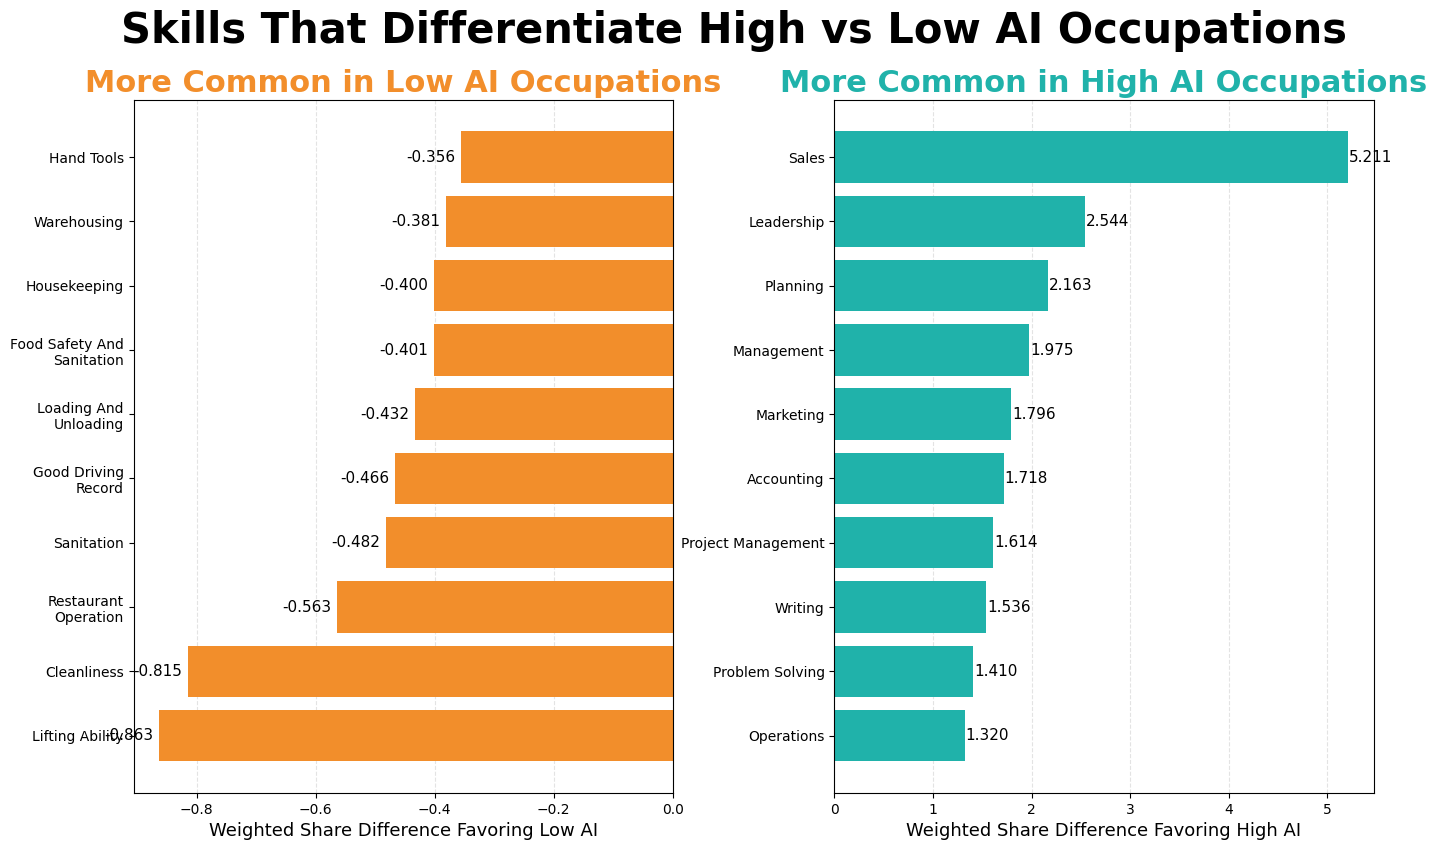


Saved files to:
C:\Users\301533\Documents\AI Analysis\AI Exposure Sheet\outputs\revised_skill_figures

Top High AI candidates:
                   Skill  Freq_High  Freq_Low  Total_Mentions  weighted_score
45                 Sales   0.526985  0.099901          199074        5.211046
1471          Leadership   0.290105  0.071476          113037        2.543857
793             Planning   0.280170  0.094445          114482        2.163363
592           Management   0.313769  0.146800          136792        1.974606
1243           Marketing   0.178911  0.016601           63964        1.796142
618           Accounting   0.164108  0.007268           57007        1.717555
688   Project Management   0.160340  0.012972           56926        1.613617
1051             Writing   0.194527  0.058145           77933        1.536153
1357     Problem Solving   0.271153  0.150903          123241        1.409560
1281          Operations   0.222556  0.107646           97763        1.320354
1383    Micros

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import textwrap
import re

# =========================================================
# CONFIG
# =========================================================

INPUT_SKILL_FILE = Path(r"C:\Users\301533\Downloads\Figure2_Skill_Frequency_High_vs_Low.xlsx")

OUTPUT_DIR = Path(r"C:\Users\301533\Documents\AI Analysis\AI Exposure Sheet\outputs\revised_skill_figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TOP_N_FINAL = 10

# Stronger frequency filters to reduce weird niche skills
MIN_TOTAL_MENTIONS = 100
MIN_FREQ_EITHER_SIDE = 0.005   # skill must appear in at least 0.5% of one side

LEFT_COLOR = "#F28E2B"
RIGHT_COLOR = "#20B2AA"

# =========================================================
# OPTIONAL MANUAL EXCLUSION LIST
# Add anything ugly, niche, or overly occupation-specific here
# =========================================================

MANUAL_EXCLUDE = {
    "apache kafka",
    "mongodb",
    "git (version control system)",
    "user story",
    "tax laws",
    "truth in lending act",
    "retail banking",
    "certified information system auditor (cisa)",
    "periodontology",
    "squeegee",
    "breads",
    "dental radiography",
    "truck driving",
    "radiology certification",
    "dental hygiene",
    "washing machines",
    "oral hygiene",
    "no-touch freight",
    "microservices",
    "tax preparation"
}

# =========================================================
# OPTIONAL PATTERN EXCLUSIONS
# These help remove certifications, software products, and very narrow terms
# =========================================================

EXCLUDE_PATTERNS = [
    r"\bcertification\b",
    r"\bcertified\b",
    r"\blicense\b",
    r"\blicensing\b",
    r"\bexam\b",
    r"\bboard\b",
    r"\bact\b",
    r"\blaws\b",
    r"\bsystem\b",
    r"\bsoftware\b",
    r"\bmodule\b",
    r"\bprotocol\b",
    r"\bframework\b",
    r"\bapi\b",
    r"\bserver\b",
    r"\bdatabase\b",
    r"\bperiodont",
    r"\bdental\b",
    r"\bradiology\b",
    r"\boral\b",
    r"\bfreight\b",
    r"\bkafka\b",
    r"\bmongodb\b",
    r"\bmicroservices\b",
    r"\bgit\b",
    r"\bcisa\b"
]

# =========================================================
# HELPERS
# =========================================================

def wrap_label(text, width=18):
    return "\n".join(textwrap.wrap(str(text), width=width))

def clean_text(s):
    return str(s).strip()

def norm_text(s):
    return str(s).strip().lower()

def safe_numeric(df, cols):
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

def check_required_columns(df, required_cols):
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise KeyError(
            f"Missing required columns: {missing}\n"
            f"Available columns: {list(df.columns)}"
        )

def should_exclude(skill):
    s = norm_text(skill)

    if s in MANUAL_EXCLUDE:
        return True

    for pattern in EXCLUDE_PATTERNS:
        if re.search(pattern, s):
            return True

    # Exclude skills that are mostly numbers / codes / highly odd formatting
    if re.fullmatch(r"[\W\d_]+", s):
        return True

    return False

# =========================================================
# LOAD
# =========================================================

skill_df = pd.read_excel(INPUT_SKILL_FILE)
skill_df.columns = [clean_text(c) for c in skill_df.columns]

required_cols = [
    "Skill",
    "Count_High",
    "Count_Low",
    "Freq_High",
    "Freq_Low",
    "Difference",
    "Total_Mentions"
]
check_required_columns(skill_df, required_cols)

skill_df = safe_numeric(
    skill_df,
    ["Count_High", "Count_Low", "Freq_High", "Freq_Low", "Difference", "Total_Mentions"]
)

skill_df = skill_df.dropna(subset=["Skill"]).copy()
skill_df["Skill"] = skill_df["Skill"].astype(str).str.strip()

# =========================================================
# FILTER 1: FREQUENCY / PRESENCE
# =========================================================

skill_df = skill_df[
    (skill_df["Total_Mentions"] >= MIN_TOTAL_MENTIONS) &
    (
        (skill_df["Freq_High"] >= MIN_FREQ_EITHER_SIDE) |
        (skill_df["Freq_Low"] >= MIN_FREQ_EITHER_SIDE)
    )
].copy()

# =========================================================
# BUILD BETTER SCORES
# =========================================================
# This is the main change:
# weighted_score rewards both distinctiveness and meaningful prevalence

skill_df["share_diff"] = skill_df["Freq_High"] - skill_df["Freq_Low"]
skill_df["mention_weight"] = np.log1p(skill_df["Total_Mentions"])
skill_df["weighted_score"] = skill_df["share_diff"] * skill_df["mention_weight"]

# Helpful review columns
skill_df["dominant_group"] = np.where(
    skill_df["weighted_score"] > 0,
    "High AI",
    np.where(skill_df["weighted_score"] < 0, "Low AI", "Tie")
)

# =========================================================
# FILTER 2: REMOVE OBVIOUSLY BAD / NARROW TERMS
# =========================================================

skill_df["exclude_flag"] = skill_df["Skill"].apply(should_exclude)
filtered_df = skill_df[~skill_df["exclude_flag"]].copy()

# =========================================================
# EXPORT FULL TABLES FOR REVIEW
# =========================================================

skill_df.sort_values("weighted_score", ascending=False).to_excel(
    OUTPUT_DIR / "skills_full_with_weighted_score.xlsx",
    index=False
)

filtered_df.sort_values("weighted_score", ascending=False).to_excel(
    OUTPUT_DIR / "skills_filtered_with_weighted_score.xlsx",
    index=False
)

# =========================================================
# BUILD CANDIDATE LISTS
# =========================================================

high_candidates = (
    filtered_df
    .sort_values(["weighted_score", "Freq_High", "Total_Mentions"], ascending=[False, False, False])
    .copy()
)

low_candidates = (
    filtered_df
    .sort_values(["weighted_score", "Freq_Low", "Total_Mentions"], ascending=[True, False, False])
    .copy()
)

# Export bigger candidate lists for manual review
high_candidates.head(40).to_excel(
    OUTPUT_DIR / "high_ai_skill_candidates_top40.xlsx",
    index=False
)

low_candidates.head(40).to_excel(
    OUTPUT_DIR / "low_ai_skill_candidates_top40.xlsx",
    index=False
)

# =========================================================
# OPTIONAL MANUAL KEEP LIST
# If you want full control, edit these lists after looking at the top40 exports.
# Leave them empty for now to use the automatic top 10.
# =========================================================

MANUAL_KEEP_HIGH = []
MANUAL_KEEP_LOW = []

if MANUAL_KEEP_HIGH:
    high_plot_df = high_candidates[
        high_candidates["Skill"].isin(MANUAL_KEEP_HIGH)
    ].copy()
else:
    high_plot_df = high_candidates.head(TOP_N_FINAL).copy()

if MANUAL_KEEP_LOW:
    low_plot_df = low_candidates[
        low_candidates["Skill"].isin(MANUAL_KEEP_LOW)
    ].copy()
else:
    low_plot_df = low_candidates.head(TOP_N_FINAL).copy()

# =========================================================
# PREP FOR PLOT
# =========================================================

# left side negative
low_plot_df["plot_value"] = low_plot_df["weighted_score"]
high_plot_df["plot_value"] = high_plot_df["weighted_score"]

low_plot_df = low_plot_df.sort_values("plot_value", ascending=True).copy()
high_plot_df = high_plot_df.sort_values("plot_value", ascending=True).copy()

# Save final selected skills
final_selected = pd.concat([
    low_plot_df.assign(Group="More Common in Low AI Occupations"),
    high_plot_df.assign(Group="More Common in High AI Occupations")
], ignore_index=True)

final_selected.to_excel(
    OUTPUT_DIR / "figure2_final_selected_skills.xlsx",
    index=False
)

# =========================================================
# PLOT FIGURE 2
# =========================================================

fig, (ax1, ax2) = plt.subplots(
    ncols=2,
    figsize=(16, 9),
    gridspec_kw={"wspace": 0.30}
)

# Left panel
ax1.barh(
    [wrap_label(x) for x in low_plot_df["Skill"]],
    low_plot_df["plot_value"],
    color=LEFT_COLOR
)
ax1.set_title(
    "More Common in Low AI Occupations",
    fontsize=22,
    weight="bold",
    color=LEFT_COLOR
)
ax1.set_xlabel("Weighted Share Difference Favoring Low AI", fontsize=13)
ax1.grid(axis="x", linestyle="--", alpha=0.35)
ax1.set_axisbelow(True)

for i, v in enumerate(low_plot_df["plot_value"]):
    ax1.text(
        v - 0.01,
        i,
        f"{v:.3f}",
        va="center",
        ha="right",
        fontsize=11
    )

# Right panel
ax2.barh(
    [wrap_label(x) for x in high_plot_df["Skill"]],
    high_plot_df["plot_value"],
    color=RIGHT_COLOR
)
ax2.set_title(
    "More Common in High AI Occupations",
    fontsize=22,
    weight="bold",
    color=RIGHT_COLOR
)
ax2.set_xlabel("Weighted Share Difference Favoring High AI", fontsize=13)
ax2.grid(axis="x", linestyle="--", alpha=0.35)
ax2.set_axisbelow(True)

for i, v in enumerate(high_plot_df["plot_value"]):
    ax2.text(
        v + 0.01,
        i,
        f"{v:.3f}",
        va="center",
        ha="left",
        fontsize=11
    )

fig.suptitle(
    "Skills That Differentiate High vs Low AI Occupations",
    fontsize=30,
    weight="bold",
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(
    OUTPUT_DIR / "Figure2_WeightedShare_MirrorChart.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

# =========================================================
# PRINT QUICK CHECKS
# =========================================================

print("\nSaved files to:")
print(OUTPUT_DIR)

print("\nTop High AI candidates:")
print(
    high_candidates.head(15)[[
        "Skill", "Freq_High", "Freq_Low", "Total_Mentions", "weighted_score"
    ]]
)

print("\nTop Low AI candidates:")
print(
    low_candidates.head(15)[[
        "Skill", "Freq_High", "Freq_Low", "Total_Mentions", "weighted_score"
    ]]
)

print("\nFinal plotted High AI skills:")
print(high_plot_df["Skill"].tolist())

print("\nFinal plotted Low AI skills:")
print(low_plot_df["Skill"].tolist())

print("\nDone.")

C:\Users\301533\AppData\Local\Temp\ipykernel_30232\3316668470.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


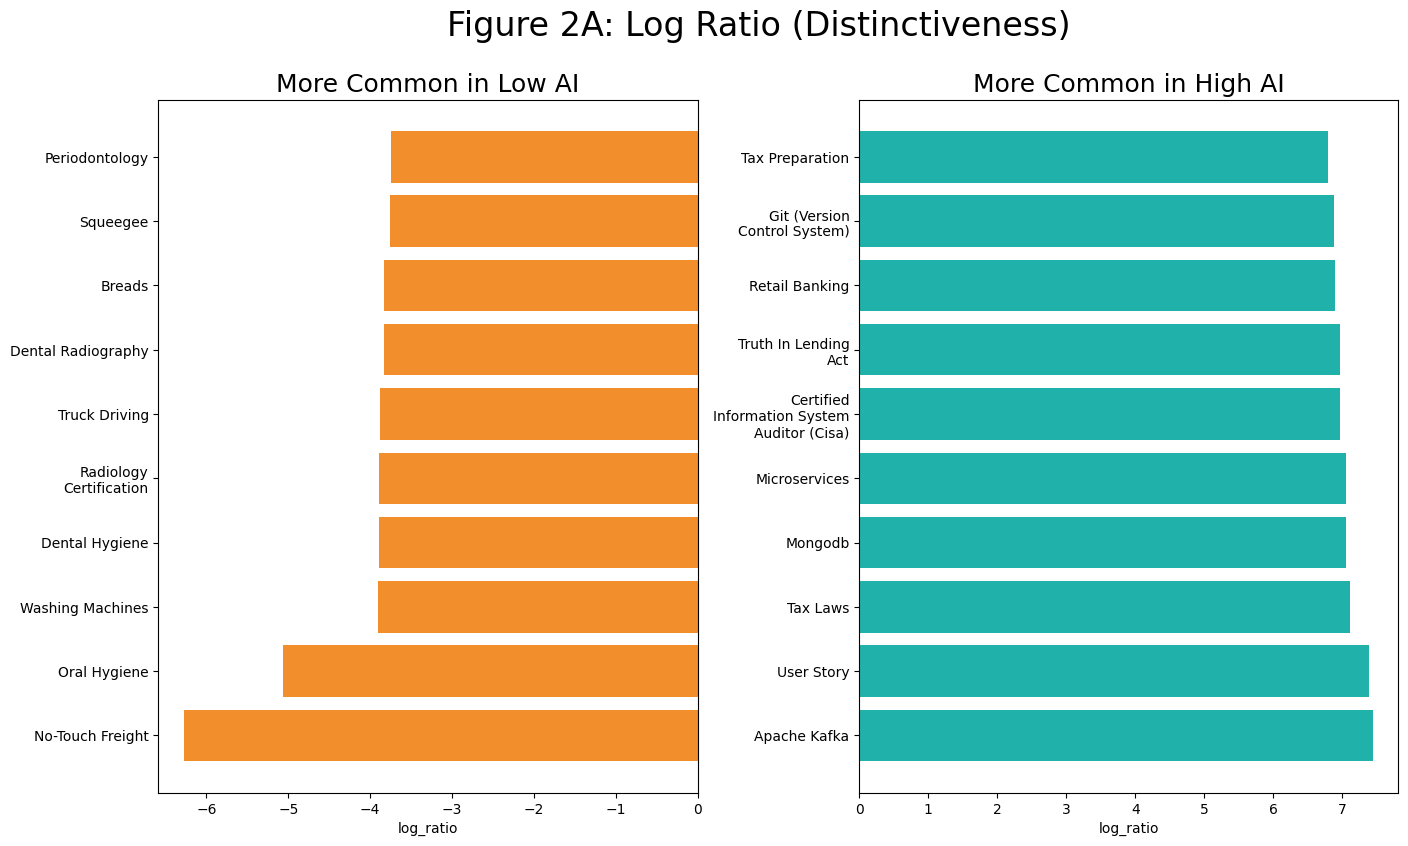

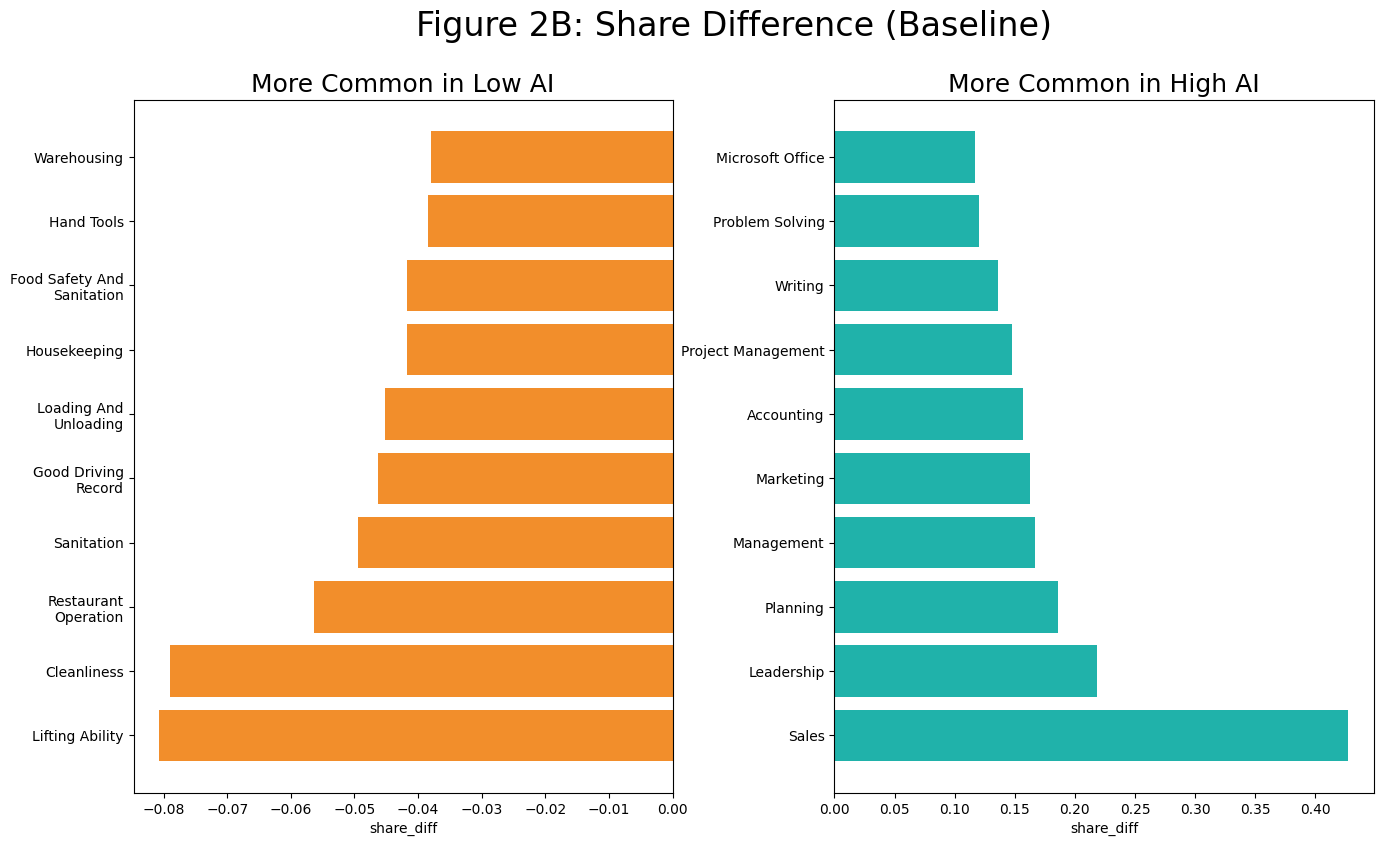

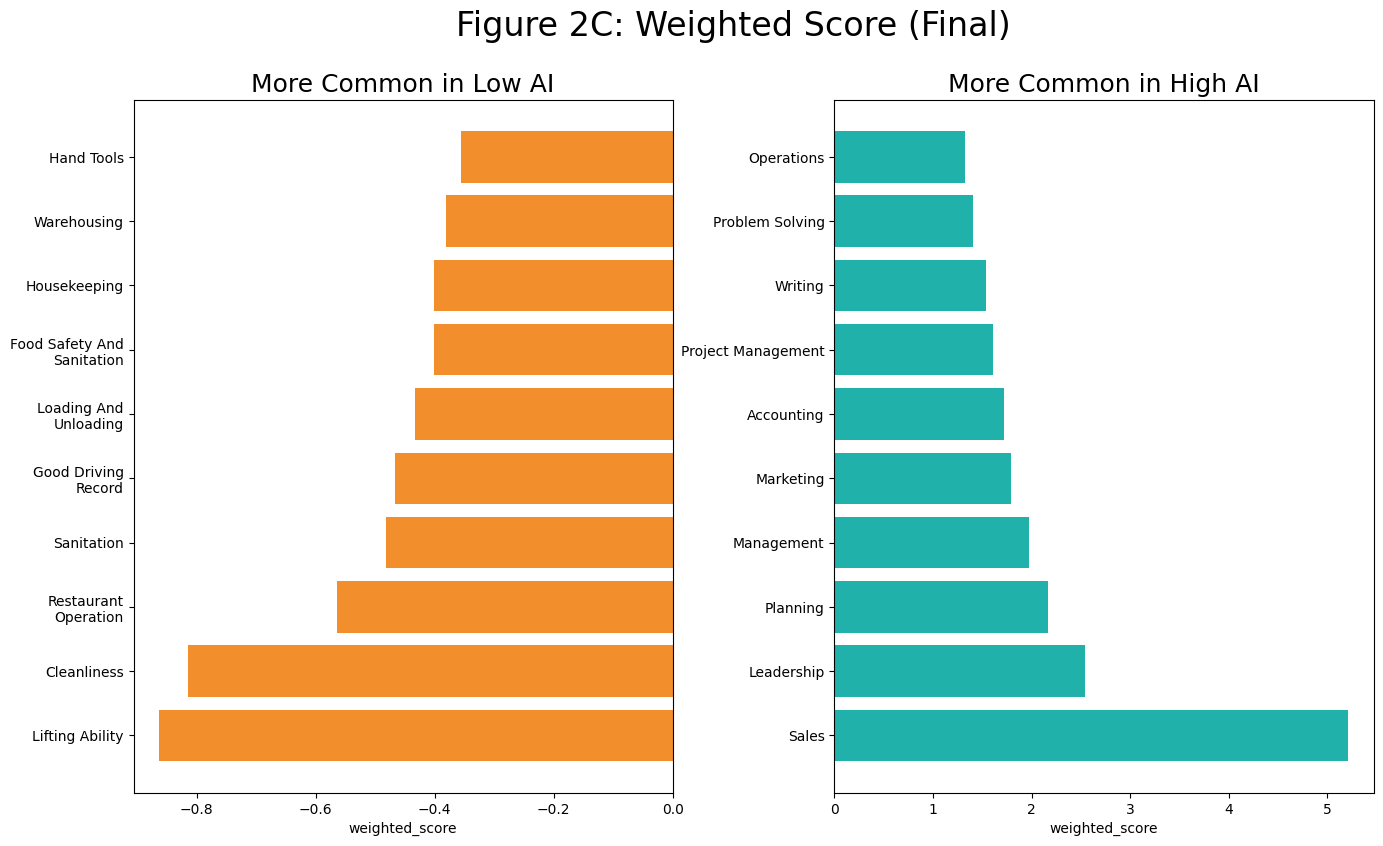

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import textwrap

# =========================================================
# LOAD DATA
# =========================================================

file_path = Path(r"C:\Users\301533\Downloads\Figure2_Skill_Frequency_High_vs_Low.xlsx")
df = pd.read_excel(file_path)

# Clean
df.columns = df.columns.str.strip()
df["Skill"] = df["Skill"].astype(str).str.strip()

# =========================================================
# BUILD 3 SCORES
# =========================================================

# 1. LOG RATIO
df["log_ratio"] = np.log((df["Count_High"] + 1) / (df["Count_Low"] + 1))

# 2. SHARE DIFFERENCE
df["share_diff"] = df["Freq_High"] - df["Freq_Low"]

# 3. WEIGHTED SCORE
df["weighted_score"] = df["share_diff"] * np.log1p(df["Total_Mentions"])

# =========================================================
# HELPER FUNCTION
# =========================================================

def wrap(text, width=18):
    return "\n".join(textwrap.wrap(str(text), width))

def plot_version(df, score_col, title, filename):
    
    high = df.sort_values(score_col, ascending=False).head(10)
    low = df.sort_values(score_col, ascending=True).head(10)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 9), gridspec_kw={"wspace": 0.3})

    # LOW SIDE
    ax1.barh(
        [wrap(x) for x in low["Skill"]],
        low[score_col],
        color="#F28E2B"
    )
    ax1.set_title("More Common in Low AI", fontsize=18)
    ax1.set_xlabel(score_col)

    # HIGH SIDE
    ax2.barh(
        [wrap(x) for x in high["Skill"]],
        high[score_col],
        color="#20B2AA"
    )
    ax2.set_title("More Common in High AI", fontsize=18)
    ax2.set_xlabel(score_col)

    fig.suptitle(title, fontsize=24)
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

# =========================================================
# CREATE ALL 3 FIGURES
# =========================================================

plot_version(df, "log_ratio",
             "Figure 2A: Log Ratio (Distinctiveness)",
             "figure_2A_log_ratio.png")

plot_version(df, "share_diff",
             "Figure 2B: Share Difference (Baseline)",
             "figure_2B_share_diff.png")

plot_version(df, "weighted_score",
             "Figure 2C: Weighted Score (Final)",
             "figure_2C_weighted.png")

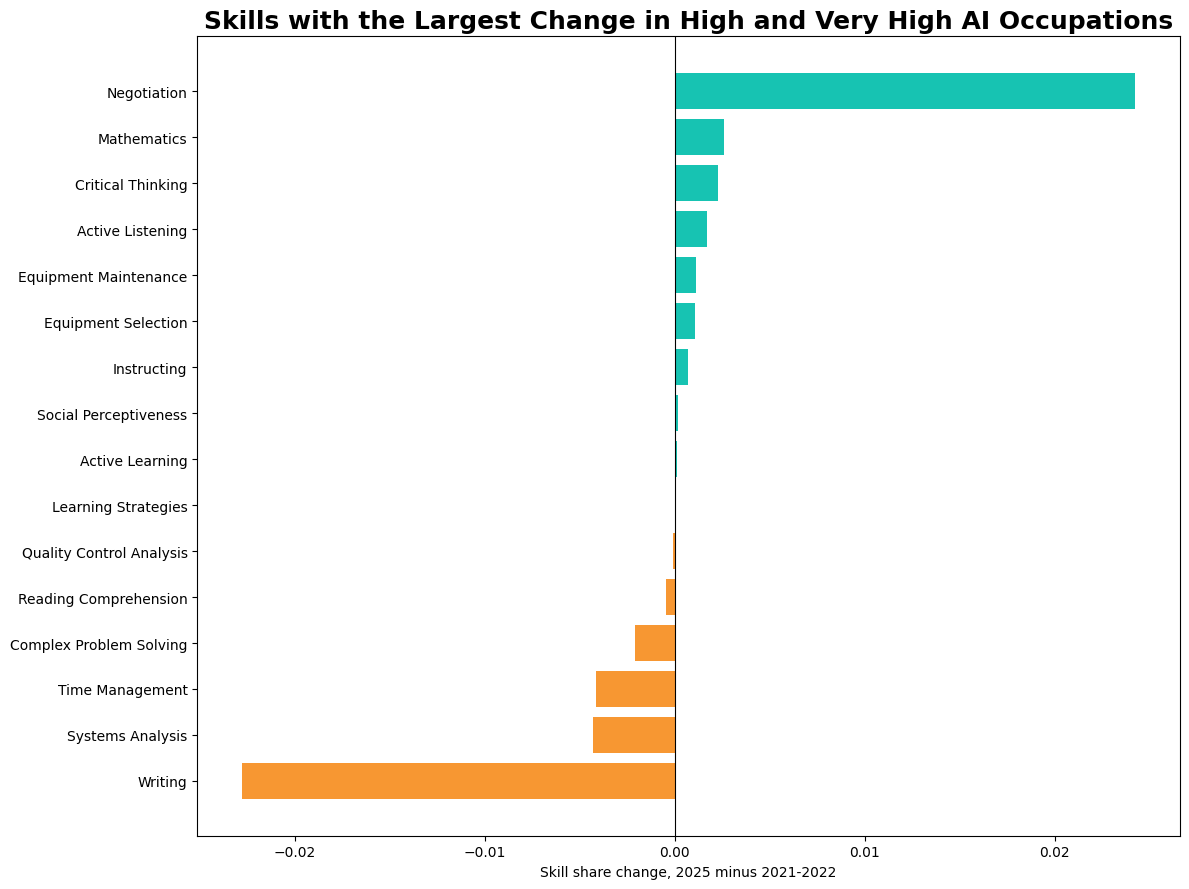

Done.
Period                     Skill               skill_clean  Current, 2025  \
9                    Negotiation               negotiation         3840.0   
15                       Writing                   writing        11948.0   
13              Systems Analysis          systems analysis          299.0   
14               Time Management           time management         7482.0   
8                    Mathematics               mathematics         3993.0   
3              Critical Thinking         critical thinking         3455.0   
2        Complex Problem Solving   complex problem solving          425.0   
1               Active Listening          active listening          764.0   
4          Equipment Maintenance     equipment maintenance          262.0   
5            Equipment Selection       equipment selection           65.0   
6                    Instructing               instructing          192.0   
11         Reading Comprehension     reading comprehension           9

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import textwrap

OUT_FOLDER = Path(
    r"C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO\Skill Outputs"
)

PRE_YEARS = [2021, 2022]
CURRENT_YEARS = [2025]

PATINA = "#17C3B2"
CARROT = "#F79732"

def wrap(text, width=24):
    return "\n".join(textwrap.wrap(str(text), width))

def build_high_ai_pre_post(time_agg):
    temp = time_agg.copy()
    temp["Year"] = pd.to_numeric(temp["Year"], errors="coerce")

    temp = temp[temp["Exposure"].isin(["High", "Very High"])].copy()

    temp["Period"] = None
    temp.loc[temp["Year"].isin(PRE_YEARS), "Period"] = "Pre-ChatGPT, 2021-2022"
    temp.loc[temp["Year"].isin(CURRENT_YEARS), "Period"] = "Current, 2025"

    temp = temp[temp["Period"].notna()].copy()

    counts = (
        temp.groupby(["Skill", "skill_clean", "Period"], as_index=False)
        .agg(Count=("Count", "sum"))
    )

    wide = counts.pivot_table(
        index=["Skill", "skill_clean"],
        columns="Period",
        values="Count",
        fill_value=0
    ).reset_index()

    for col in ["Pre-ChatGPT, 2021-2022", "Current, 2025"]:
        if col not in wide.columns:
            wide[col] = 0

    total_pre = wide["Pre-ChatGPT, 2021-2022"].sum()
    total_current = wide["Current, 2025"].sum()

    wide["Freq_Pre"] = wide["Pre-ChatGPT, 2021-2022"] / total_pre
    wide["Freq_Current"] = wide["Current, 2025"] / total_current

    wide["Count_Change"] = wide["Current, 2025"] - wide["Pre-ChatGPT, 2021-2022"]
    wide["Share_Change"] = wide["Freq_Current"] - wide["Freq_Pre"]
    wide["Abs_Share_Change"] = wide["Share_Change"].abs()

    return wide.sort_values("Abs_Share_Change", ascending=False)

def plot_high_ai_pre_post(change_df, out_file, top_n=20):
    plot_df = change_df.head(top_n).copy()
    plot_df = plot_df.sort_values("Share_Change", ascending=True)

    colors = np.where(plot_df["Share_Change"] >= 0, PATINA, CARROT)

    plt.figure(figsize=(12, 9))

    plt.barh(
        [wrap(x) for x in plot_df["Skill"]],
        plot_df["Share_Change"],
        color=colors
    )

    plt.axvline(0, color="black", linewidth=0.8)

    plt.title(
        "Skills with the Largest Change in High and Very High AI Occupations",
        fontsize=18,
        weight="bold"
    )

    plt.xlabel("Skill share change, 2025 minus 2021-2022")
    plt.ylabel("")

    plt.tight_layout()
    plt.savefig(out_file, dpi=300, bbox_inches="tight")
    plt.show()

high_ai_change = build_high_ai_pre_post(time_agg)

high_ai_change.to_excel(
    OUT_FOLDER / "High_VeryHigh_PreChatGPT_vs_2025_Skill_Change.xlsx",
    index=False
)

plot_high_ai_pre_post(
    high_ai_change,
    OUT_FOLDER / "Figure_High_VeryHigh_PreChatGPT_vs_2025_Skill_Change.png",
    top_n=20
)

print("Done.")
print(high_ai_change.head(50))

Reading Very High Lightcast files: 162
Reading High Lightcast files: 143

WORD BANK BUILT
Raw word bank rows: 36,600
Unique word bank terms: 119
                       term_clean                 Word_Bank_Term  \
55                    mathematics                    Mathematics   
0                 active learning                Active Learning   
1                active listening               Active Listening   
2   administration and management  Administration and Management   
3             arm-hand steadiness            Arm-Hand Steadiness   
4              auditory attention             Auditory Attention   
5                         biology                        Biology   
6       building and construction      Building and Construction   
7            category flexibility           Category Flexibility   
8                       chemistry                      Chemistry   
9                        clerical                       Clerical   
10       communications and media      

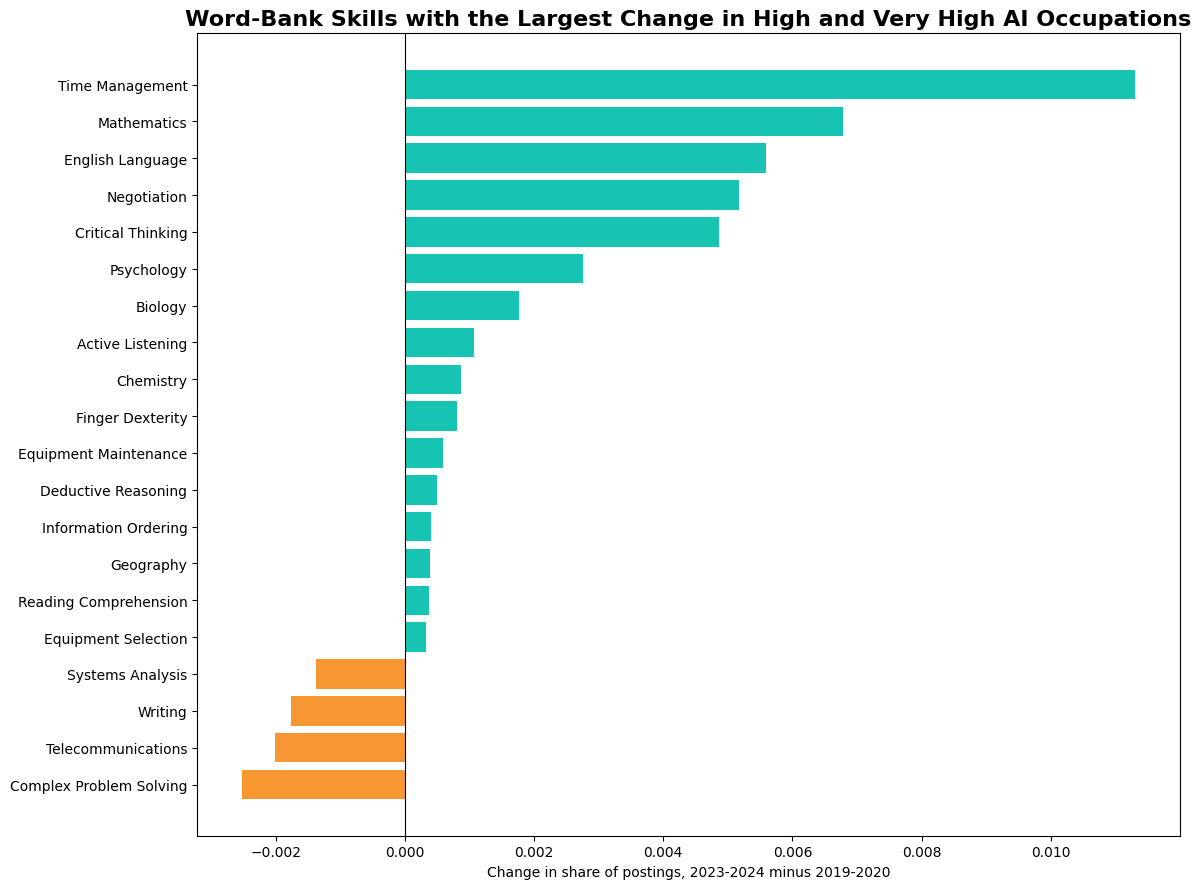

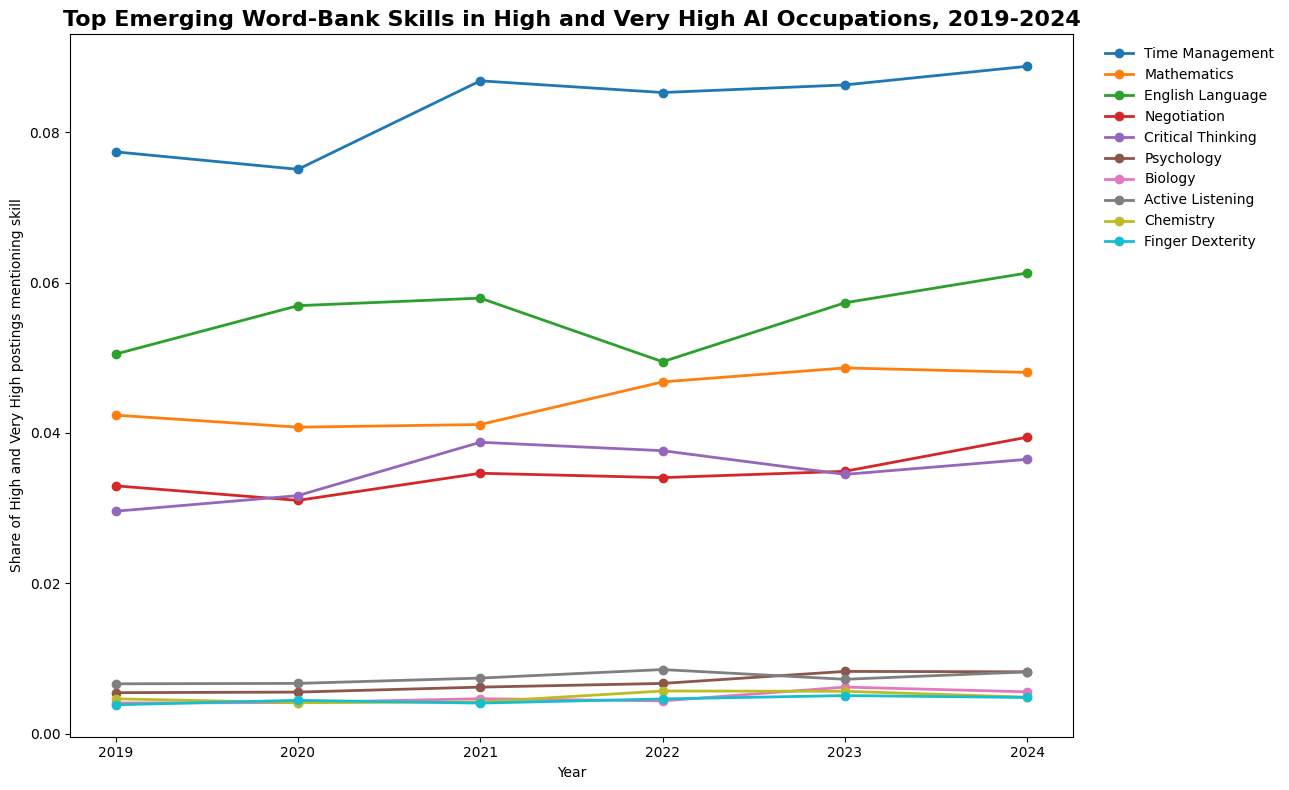


DONE.
Outputs saved to: C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO\Skill Outputs

Top emerging word-bank skills:
                    Skill                                    Source_Sheets  \
30        Time Management                            Competencies - Skills   
18            Mathematics  Competencies - Knowledge; Competencies - Skills   
8        English Language                         Competencies - Knowledge   
19            Negotiation                            Competencies - Skills   
5       Critical Thinking                            Competencies - Skills   
23             Psychology                         Competencies - Knowledge   
2                 Biology                         Competencies - Knowledge   
1        Active Listening                            Competencies - Skills   
3               Chemistry                         Competencies - Knowledge   
11       Finger Dexterity                         Competencies - Abilities   
9   Equipme

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
import ast, json, re, textwrap

# =========================================================
# PATHS
# =========================================================

VERY_HIGH_FOLDER = Path(
    r"C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO"
)

HIGH_FOLDER = Path(
    r"C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO\High AI"
)

POSTINGS_FILE = Path(
    r"G:\Shared drives\EO_OPERATIONS\Grants\PCIC Analysis\Job Posting Data\raw_data\df_2016_2025.csv"
)

AI_COMPOSITE_FILE = Path(
    r"G:\Shared drives\EO_ECONOMIC ANALYSIS\ea_common\Projects\AI\risk_index\ai_exposure_composite_clean.csv"
)

OUT_FOLDER = Path(
    r"C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO\Skill Outputs"
)
OUT_FOLDER.mkdir(parents=True, exist_ok=True)

# =========================================================
# SETTINGS
# =========================================================

SOC_COL = "SOC_5"
YEAR_COL = "YEAR"
SKILL_COLS = ["SKILLS_NAME", "SOFTWARE_SKILLS_NAME"]

YEARS_TO_USE = list(range(2019, 2025))
HIGH_EXPOSURE_GROUPS = ["High", "Very High"]

CHUNK_SIZE = 250_000
TOP_N = 20

PATINA = "#17C3B2"
CARROT = "#F79732"

# Include more Lightcast sheets than just skills if you want a larger word bank
LIGHTCAST_SHEETS_TO_USE = [
    "Competencies - Skills",
    "Competencies - Knowledge",
    "Competencies - Abilities"
]

# =========================================================
# HELPERS
# =========================================================

def clean_skill_name(x):
    return (
        str(x).strip().lower()
        .replace("’", "'")
        .replace("–", "-")
        .replace("—", "-")
    )

def wrap_label(x, width=28):
    return "\n".join(textwrap.wrap(str(x), width))

def fix_soc(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip().replace(".0", "")

    if re.match(r"^\d{2}-\d{4}$", s):
        return s

    if s.startswith("Nov-"):
        nov_map = {
            "11": "11-2011", "21": "11-2021", "22": "11-2022",
            "32": "11-2032", "33": "11-2033", "12": "11-3012",
            "13": "11-3013", "31": "11-3031", "51": "11-3051",
            "61": "11-3061", "71": "11-3071", "41": "11-9041",
            "72": "11-9072", "81": "11-9081", "79": "11-9179",
            "99": "11-9199",
        }
        return nov_map.get(s.replace("Nov-", "").strip(), np.nan)

    return s

def standardize_exposure(x):
    s = str(x).strip().lower()
    mapping = {
        "very low": "Very Low",
        "low": "Low",
        "medium": "Medium",
        "high": "High",
        "very high": "Very High"
    }
    return mapping.get(s, str(x).strip())

def parse_skill_list(x):
    if pd.isna(x):
        return []

    s = str(x).strip()

    if s in ["", "[]", "nan", "None"]:
        return []

    try:
        parsed = ast.literal_eval(s)
        if isinstance(parsed, list):
            return [str(v).strip() for v in parsed if str(v).strip()]
    except:
        pass

    try:
        parsed = json.loads(s)
        if isinstance(parsed, list):
            return [str(v).strip() for v in parsed if str(v).strip()]
    except:
        pass

    return [v.strip() for v in s.split(",") if v.strip()]

def infer_occupation_from_filename(path):
    name = path.stem
    name = re.sub(r"^Skills_Transferability_", "", name)
    name = re.sub(r"_in_(United_States|Arizona).*", "", name)
    name = name.replace("_", " ")
    return name.strip()

def find_lightcast_sheets(xlsx_path):
    xl = pd.ExcelFile(xlsx_path)
    keep = []

    for desired in LIGHTCAST_SHEETS_TO_USE:
        if desired in xl.sheet_names:
            keep.append(desired)

    return keep

def read_lightcast_word_bank_from_folder(folder, exposure_source):
    rows = []
    files = sorted(folder.glob("Skills_Transferability_*.xlsx"))

    print(f"Reading {exposure_source} Lightcast files: {len(files)}")

    for file in files:
        try:
            sheets = find_lightcast_sheets(file)

            for sheet in sheets:
                df = pd.read_excel(file, sheet_name=sheet, header=2)
                df.columns = df.columns.astype(str).str.strip()

                # Sheet first column may be Skill, Knowledge, or Ability
                name_col = None
                for c in df.columns:
                    if c.lower() in ["skill", "knowledge", "ability"]:
                        name_col = c
                        break

                if name_col is None:
                    continue

                temp = df[[name_col]].copy()
                temp = temp.rename(columns={name_col: "Term"})
                temp["Term"] = temp["Term"].astype(str).str.strip()
                temp = temp[temp["Term"].str.lower() != "nan"]
                temp = temp[temp["Term"] != ""]

                temp["term_clean"] = temp["Term"].apply(clean_skill_name)
                temp["Word_Bank_Source_Sheet"] = sheet
                temp["Lightcast Exposure Source"] = exposure_source
                temp["Lightcast Occupation"] = infer_occupation_from_filename(file)
                temp["Source File"] = file.name

                rows.append(temp)

        except Exception as e:
            print(f"Error reading {file.name}: {e}")

    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

def build_word_bank():
    very_high = read_lightcast_word_bank_from_folder(VERY_HIGH_FOLDER, "Very High")
    high = read_lightcast_word_bank_from_folder(HIGH_FOLDER, "High")

    raw = pd.concat([very_high, high], ignore_index=True)

    bank = (
        raw.groupby("term_clean", as_index=False)
        .agg(
            Word_Bank_Term=("Term", "first"),
            Source_Sheets=("Word_Bank_Source_Sheet", lambda x: "; ".join(sorted(set(x)))),
            Lightcast_Mentions=("Term", "size"),
            Lightcast_Occupation_Count=("Lightcast Occupation", "nunique")
        )
        .sort_values(
            ["Lightcast_Occupation_Count", "Lightcast_Mentions"],
            ascending=[False, False]
        )
    )

    return raw, bank

# =========================================================
# STEP 1: BUILD APPROVED WORD BANK
# =========================================================

word_bank_raw, word_bank = build_word_bank()
word_bank_set = set(word_bank["term_clean"])

word_bank_raw.to_excel(
    OUT_FOLDER / "Word_Bank_Raw_From_Lightcast_High_VeryHigh.xlsx",
    index=False
)

word_bank.to_excel(
    OUT_FOLDER / "Word_Bank_Final_From_Lightcast_High_VeryHigh.xlsx",
    index=False
)

print("\nWORD BANK BUILT")
print(f"Raw word bank rows: {len(word_bank_raw):,}")
print(f"Unique word bank terms: {len(word_bank_set):,}")
print(word_bank.head(30))

# =========================================================
# STEP 2: LOAD AI COMPOSITE EXPOSURE LOOKUP
# =========================================================

ai = pd.read_csv(AI_COMPOSITE_FILE)
ai.columns = ai.columns.astype(str).str.strip()

ai["SOC"] = ai["SOC"].apply(fix_soc)
ai["Exposure"] = ai["AI Exposure Category"].astype(str).apply(standardize_exposure)

ai_lookup = (
    ai[["SOC", "Exposure"]]
    .dropna()
    .drop_duplicates(subset=["SOC"])
)

exposure_map = dict(zip(ai_lookup["SOC"], ai_lookup["Exposure"]))

print("\nAI exposure counts:")
print(ai_lookup["Exposure"].value_counts(dropna=False))

# =========================================================
# STEP 3: COUNT ONLY WORD BANK TERMS IN POSTINGS OVER TIME
# =========================================================

term_year_counter = Counter()
term_soc2_year_counter = Counter()
year_posting_counter = Counter()

usecols = [SOC_COL, YEAR_COL] + SKILL_COLS

total_kept_postings = 0
total_term_matches = 0

for i, chunk in enumerate(
    pd.read_csv(
        POSTINGS_FILE,
        usecols=lambda c: c in usecols,
        chunksize=CHUNK_SIZE,
        low_memory=False
    ),
    start=1
):
    chunk[SOC_COL] = chunk[SOC_COL].astype(str).str.strip()
    chunk[YEAR_COL] = pd.to_numeric(chunk[YEAR_COL], errors="coerce")

    chunk = chunk[chunk[SOC_COL].str.match(r"^\d{2}-\d{4}$", na=False)].copy()
    chunk = chunk[chunk[YEAR_COL].isin(YEARS_TO_USE)].copy()

    chunk["Exposure"] = chunk[SOC_COL].map(exposure_map)
    chunk["Exposure"] = chunk["Exposure"].apply(standardize_exposure)
    chunk = chunk[chunk["Exposure"].isin(HIGH_EXPOSURE_GROUPS)].copy()

    for row in chunk.itertuples(index=False):
        row_dict = row._asdict()

        soc = row_dict[SOC_COL]
        soc2 = str(soc)[:2]
        year = int(row_dict[YEAR_COL])

        posting_skills = []
        for col in SKILL_COLS:
            posting_skills += parse_skill_list(row_dict.get(col))

        posting_skills_clean = {
            clean_skill_name(s): s
            for s in posting_skills
            if str(s).strip()
        }

        matched_terms = set(posting_skills_clean.keys()).intersection(word_bank_set)

        year_posting_counter[year] += 1
        total_kept_postings += 1

        for term_clean in matched_terms:
            original_term = posting_skills_clean[term_clean]

            term_year_counter[(original_term, term_clean, year)] += 1
            term_soc2_year_counter[(soc2, original_term, term_clean, year)] += 1
            total_term_matches += 1

    print(
        f"Processed chunk {i}. "
        f"High/VH postings counted: {total_kept_postings:,}. "
        f"Word-bank matches counted: {total_term_matches:,}."
    )

# =========================================================
# STEP 4: CREATE TIME SERIES TABLES
# =========================================================

term_year = pd.DataFrame([
    {
        "Skill": k[0],
        "skill_clean": k[1],
        "Year": k[2],
        "Skill_Count": v
    }
    for k, v in term_year_counter.items()
])

year_totals = pd.DataFrame([
    {
        "Year": k,
        "Total_High_VeryHigh_Postings": v
    }
    for k, v in year_posting_counter.items()
])

term_year = term_year.merge(year_totals, on="Year", how="left")
term_year["Skill_Share"] = term_year["Skill_Count"] / term_year["Total_High_VeryHigh_Postings"]

term_year.to_excel(
    OUT_FOLDER / "WordBank_High_VeryHigh_Skill_Timeline_2019_2024.xlsx",
    index=False
)

year_totals.to_excel(
    OUT_FOLDER / "WordBank_High_VeryHigh_Posting_Counts_2019_2024.xlsx",
    index=False
)

term_soc2_year = pd.DataFrame([
    {
        "SOC2": k[0],
        "Skill": k[1],
        "skill_clean": k[2],
        "Year": k[3],
        "Skill_Count": v
    }
    for k, v in term_soc2_year_counter.items()
])

term_soc2_year.to_excel(
    OUT_FOLDER / "WordBank_High_VeryHigh_Skill_Timeline_SOC2_2019_2024.xlsx",
    index=False
)

# =========================================================
# STEP 5: EMERGENCE SCORES
# =========================================================

wide = term_year.pivot_table(
    index=["Skill", "skill_clean"],
    columns="Year",
    values="Skill_Share",
    fill_value=0
).reset_index()

for y in YEARS_TO_USE:
    if y not in wide.columns:
        wide[y] = 0

wide["Share_2019_2020"] = wide[[2019, 2020]].mean(axis=1)
wide["Share_2023_2024"] = wide[[2023, 2024]].mean(axis=1)
wide["Share_Change"] = wide["Share_2023_2024"] - wide["Share_2019_2020"]
wide["Abs_Share_Change"] = wide["Share_Change"].abs()

wide["Emergence_Ratio"] = np.where(
    wide["Share_2019_2020"] > 0,
    wide["Share_2023_2024"] / wide["Share_2019_2020"],
    np.nan
)

wide = wide.merge(
    word_bank[["term_clean", "Word_Bank_Term", "Source_Sheets", "Lightcast_Occupation_Count"]],
    left_on="skill_clean",
    right_on="term_clean",
    how="left"
)

wide = wide.sort_values("Abs_Share_Change", ascending=False)

wide.to_excel(
    OUT_FOLDER / "WordBank_High_VeryHigh_Emerging_Skills_2019_2024.xlsx",
    index=False
)

# =========================================================
# STEP 6: FIGURE, BIGGEST CHANGES
# =========================================================

plot_df = wide.head(TOP_N).copy()
plot_df = plot_df.sort_values("Share_Change", ascending=True)

colors = np.where(plot_df["Share_Change"] >= 0, PATINA, CARROT)

plt.figure(figsize=(12, 9))
plt.barh(
    [wrap_label(x) for x in plot_df["Skill"]],
    plot_df["Share_Change"],
    color=colors
)
plt.axvline(0, color="black", linewidth=0.8)
plt.title(
    "Word-Bank Skills with the Largest Change in High and Very High AI Occupations",
    fontsize=16,
    weight="bold"
)
plt.xlabel("Change in share of postings, 2023-2024 minus 2019-2020")
plt.ylabel("")
plt.tight_layout()
plt.savefig(
    OUT_FOLDER / "Figure_WordBank_Emerging_Skills_High_VeryHigh_2019_2024.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# =========================================================
# STEP 7: FIGURE, TIME SERIES FOR TOP EMERGING WORD-BANK TERMS
# =========================================================

top_emerging = (
    wide[wide["Share_Change"] > 0]
    .sort_values("Share_Change", ascending=False)
    .head(10)
)

line_data = term_year[
    term_year["skill_clean"].isin(top_emerging["skill_clean"])
].copy()

plt.figure(figsize=(13, 8))

for skill in top_emerging["Skill"]:
    temp = line_data[line_data["Skill"] == skill].sort_values("Year")
    plt.plot(
        temp["Year"],
        temp["Skill_Share"],
        marker="o",
        linewidth=2,
        label=skill
    )

plt.title(
    "Top Emerging Word-Bank Skills in High and Very High AI Occupations, 2019-2024",
    fontsize=16,
    weight="bold"
)
plt.xlabel("Year")
plt.ylabel("Share of High and Very High postings mentioning skill")
plt.xticks(YEARS_TO_USE)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.savefig(
    OUT_FOLDER / "Figure_WordBank_Top_Emerging_Skills_Time_Series_High_VeryHigh.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("\nDONE.")
print(f"Outputs saved to: {OUT_FOLDER}")

print("\nTop emerging word-bank skills:")
print(
    wide.sort_values("Share_Change", ascending=False)
    [["Skill", "Source_Sheets", "Share_2019_2020", "Share_2023_2024", "Share_Change", "Emergence_Ratio"]]
    .head(20)
)


Reading Very High files: 162

Reading High files: 143

KSA WORD BANK COMPLETE
Unique KSA terms: 119
Processed chunk 1
Processed chunk 2
Processed chunk 3
Processed chunk 4
Processed chunk 5
Processed chunk 6
Processed chunk 7
Processed chunk 8
Processed chunk 9
Processed chunk 10
Processed chunk 11
Processed chunk 12
Processed chunk 13
Processed chunk 14
Processed chunk 15
Processed chunk 16
Processed chunk 17
Processed chunk 18
Processed chunk 19
Processed chunk 20
Processed chunk 21
Processed chunk 22
Processed chunk 23
Processed chunk 24
Processed chunk 25
Processed chunk 26
Processed chunk 27
Processed chunk 28
Processed chunk 29
Processed chunk 30
Processed chunk 31
Processed chunk 32
Processed chunk 33
Processed chunk 34
Processed chunk 35


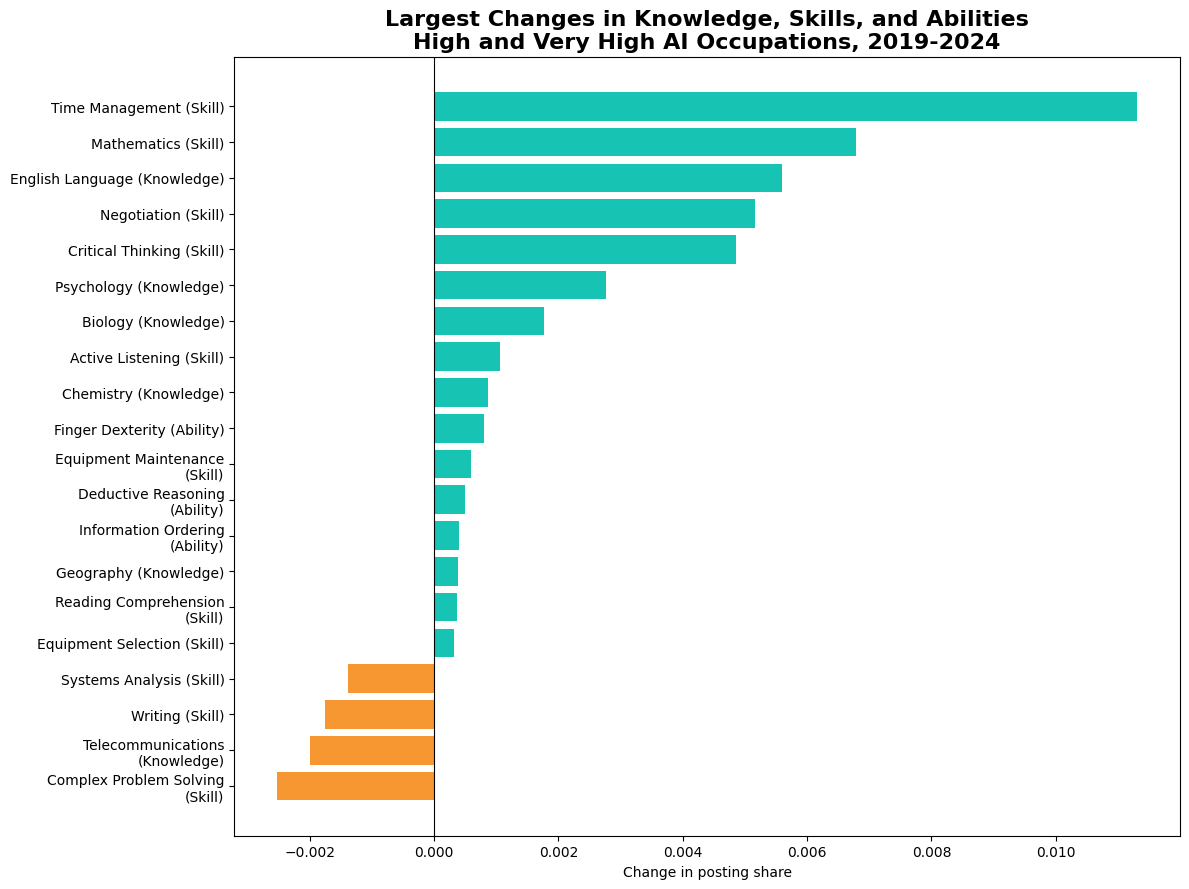

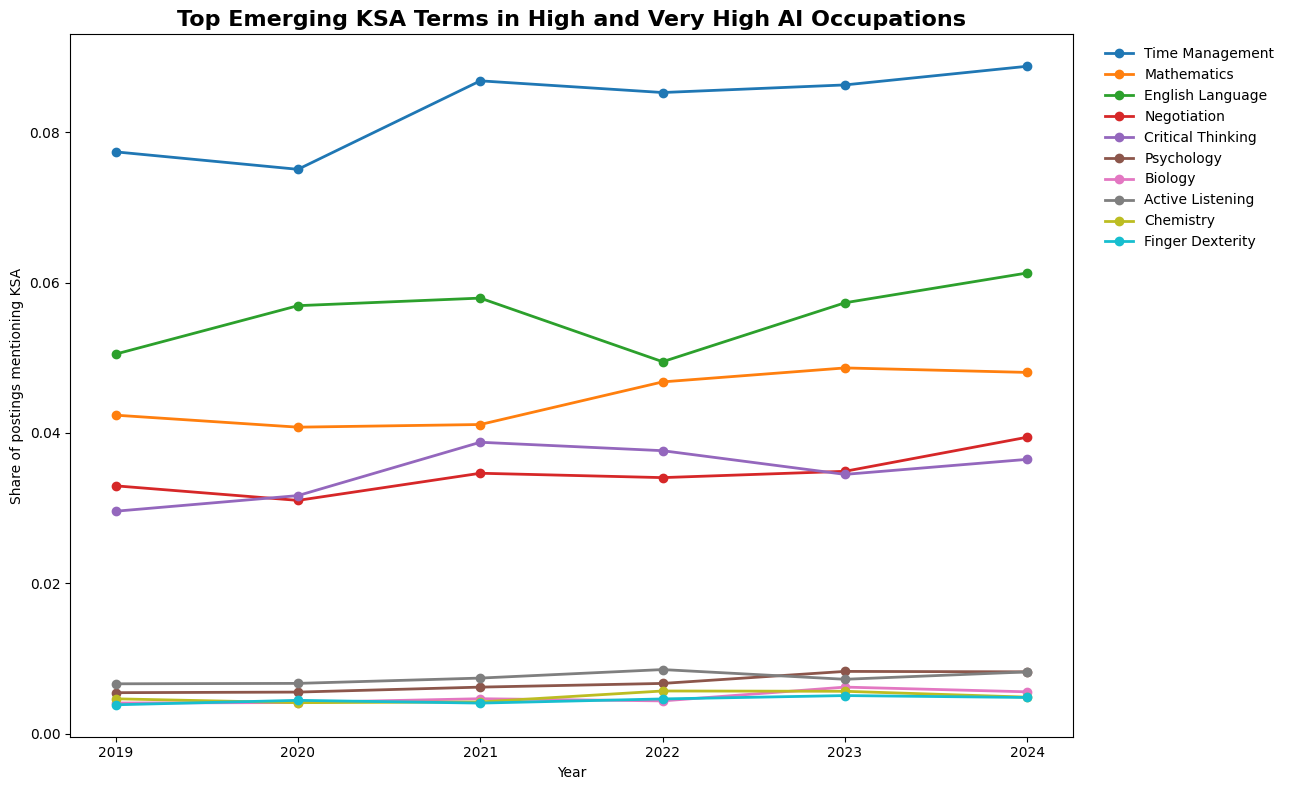


DONE.
Outputs saved to: C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO\KSA Outputs

Top emerging KSAs:
Year                   Term   KSA_Type    Pre_AI   Post_AI  Share_Change  \
30          Time Management      Skill  0.076227  0.087534      0.011306   
18              Mathematics      Skill  0.041564  0.048347      0.006784   
8          English Language  Knowledge  0.053706  0.059297      0.005591   
19              Negotiation      Skill  0.031995  0.037164      0.005169   
5         Critical Thinking      Skill  0.030624  0.035486      0.004861   
23               Psychology  Knowledge  0.005486  0.008249      0.002763   
2                   Biology  Knowledge  0.004102  0.005874      0.001772   
1          Active Listening      Skill  0.006655  0.007721      0.001066   
3                 Chemistry  Knowledge  0.004374  0.005241      0.000867   
11         Finger Dexterity    Ability  0.004131  0.004934      0.000803   
9     Equipment Maintenance      Skill  0.00218

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
import ast
import json
import re
import textwrap

# =========================================================
# PURPOSE
# =========================================================
# Build a FULL KSA (Knowledge / Skills / Abilities)
# timeline analysis using:
#
# 1. Lightcast transferability Excel sheets
#    as the approved KSA word bank
#
# 2. Large postings dataset
#    to measure how often those KSAs
#    appear over time in High + Very High
#    AI exposure occupations
#
# OUTPUTS:
# - KSA word bank
# - KSA timeline tables
# - Emerging KSAs
# - Declining KSAs
# - SOC2-level trends
# - Publication-ready figures
#
# =========================================================

# =========================================================
# PATHS
# =========================================================

VERY_HIGH_FOLDER = Path(
    r"C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO"
)

HIGH_FOLDER = Path(
    r"C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO\High AI"
)

POSTINGS_FILE = Path(
    r"G:\Shared drives\EO_OPERATIONS\Grants\PCIC Analysis\Job Posting Data\raw_data\df_2016_2025.csv"
)

AI_COMPOSITE_FILE = Path(
    r"G:\Shared drives\EO_ECONOMIC ANALYSIS\ea_common\Projects\AI\risk_index\ai_exposure_composite_clean.csv"
)

OUT_FOLDER = Path(
    r"C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO\KSA Outputs"
)
OUT_FOLDER.mkdir(parents=True, exist_ok=True)

# =========================================================
# SETTINGS
# =========================================================

SOC_COL = "SOC_5"
YEAR_COL = "YEAR"

YEARS_TO_USE = list(range(2019, 2025))
HIGH_EXPOSURE_GROUPS = ["High", "Very High"]

CHUNK_SIZE = 250_000
TOP_N = 20

PATINA = "#17C3B2"
CARROT = "#F79732"
DARK = "#003057"

# =========================================================
# LIGHTCAST KSA SHEETS
# =========================================================

KSA_SHEETS = {
    "Competencies - Knowledge": "Knowledge",
    "Competencies - Skills": "Skill",
    "Competencies - Abilities": "Ability"
}

# =========================================================
# HELPERS
# =========================================================

def clean_term(x):
    return (
        str(x)
        .strip()
        .lower()
        .replace("’", "'")
        .replace("–", "-")
        .replace("—", "-")
    )

def wrap(text, width=28):
    return "\n".join(textwrap.wrap(str(text), width))

def standardize_exposure(x):
    s = str(x).strip().lower()

    mapping = {
        "very low": "Very Low",
        "low": "Low",
        "medium": "Medium",
        "high": "High",
        "very high": "Very High"
    }

    return mapping.get(s, str(x).strip())

def fix_soc(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip().replace(".0", "")

    if re.match(r"^\d{2}-\d{4}$", s):
        return s

    if s.startswith("Nov-"):
        nov_map = {
            "11": "11-2011",
            "21": "11-2021",
            "22": "11-2022",
            "32": "11-2032",
            "33": "11-2033",
            "12": "11-3012",
            "13": "11-3013",
            "31": "11-3031",
            "51": "11-3051",
            "61": "11-3061",
            "71": "11-3071",
            "41": "11-9041",
            "72": "11-9072",
            "81": "11-9081",
            "79": "11-9179",
            "99": "11-9199",
        }

        return nov_map.get(s.replace("Nov-", "").strip(), np.nan)

    return s

def parse_list(x):
    if pd.isna(x):
        return []

    s = str(x).strip()

    if s in ["", "[]", "nan", "None"]:
        return []

    try:
        parsed = ast.literal_eval(s)
        if isinstance(parsed, list):
            return [str(v).strip() for v in parsed if str(v).strip()]
    except:
        pass

    try:
        parsed = json.loads(s)
        if isinstance(parsed, list):
            return [str(v).strip() for v in parsed if str(v).strip()]
    except:
        pass

    return [v.strip() for v in s.split(",") if v.strip()]

def infer_occupation(path):
    name = path.stem

    name = re.sub(r"^Skills_Transferability_", "", name)
    name = re.sub(r"_in_(United_States|Arizona).*", "", name)

    name = name.replace("_", " ")

    return name.strip()

# =========================================================
# STEP 1: BUILD KSA WORD BANK
# =========================================================

ksa_rows = []

folders = [
    (VERY_HIGH_FOLDER, "Very High"),
    (HIGH_FOLDER, "High")
]

for folder, exposure_group in folders:

    files = sorted(folder.glob("Skills_Transferability_*.xlsx"))

    print(f"\nReading {exposure_group} files: {len(files)}")

    for file in files:

        try:

            xl = pd.ExcelFile(file)

            for sheet_name, ksa_type in KSA_SHEETS.items():

                if sheet_name not in xl.sheet_names:
                    continue

                df = pd.read_excel(
                    file,
                    sheet_name=sheet_name,
                    header=2
                )

                df.columns = df.columns.astype(str).str.strip()

                first_col = df.columns[0]

                temp = df[[first_col]].copy()

                temp.columns = ["Term"]

                temp["Term"] = temp["Term"].astype(str).str.strip()

                temp = temp[temp["Term"] != ""]
                temp = temp[temp["Term"].str.lower() != "nan"]

                temp["term_clean"] = temp["Term"].apply(clean_term)

                temp["KSA_Type"] = ksa_type
                temp["Exposure_Source"] = exposure_group
                temp["Occupation"] = infer_occupation(file)
                temp["Source_File"] = file.name

                ksa_rows.append(temp)

        except Exception as e:
            print(f"Error reading {file.name}: {e}")

ksa_raw = pd.concat(ksa_rows, ignore_index=True)

ksa_word_bank = (
    ksa_raw.groupby(
        ["term_clean", "KSA_Type"],
        as_index=False
    )
    .agg(
        Term=("Term", "first"),
        Occupation_Count=("Occupation", "nunique"),
        Mention_Count=("Term", "size")
    )
)

ksa_word_bank = ksa_word_bank.sort_values(
    ["Occupation_Count", "Mention_Count"],
    ascending=False
)

ksa_word_bank.to_excel(
    OUT_FOLDER / "KSA_Word_Bank.xlsx",
    index=False
)

print("\nKSA WORD BANK COMPLETE")
print(f"Unique KSA terms: {ksa_word_bank['term_clean'].nunique():,}")

# =========================================================
# STEP 2: LOAD AI EXPOSURE LOOKUP
# =========================================================

ai = pd.read_csv(AI_COMPOSITE_FILE)

ai.columns = ai.columns.astype(str).str.strip()

ai["SOC"] = ai["SOC"].apply(fix_soc)

ai["Exposure"] = (
    ai["AI Exposure Category"]
    .astype(str)
    .apply(standardize_exposure)
)

ai_lookup = (
    ai[["SOC", "Exposure"]]
    .dropna()
    .drop_duplicates(subset=["SOC"])
)

exposure_map = dict(zip(ai_lookup["SOC"], ai_lookup["Exposure"]))

# =========================================================
# STEP 3: BUILD KSA LOOKUP SET
# =========================================================

ksa_lookup = dict(
    zip(
        ksa_word_bank["term_clean"],
        ksa_word_bank["KSA_Type"]
    )
)

ksa_set = set(ksa_lookup.keys())

# =========================================================
# STEP 4: COUNT KSA TERMS IN POSTINGS OVER TIME
# =========================================================

term_counter = Counter()
soc2_counter = Counter()
year_counter = Counter()

usecols = [
    SOC_COL,
    YEAR_COL,
    "SKILLS_NAME",
    "SOFTWARE_SKILLS_NAME"
]

for i, chunk in enumerate(
    pd.read_csv(
        POSTINGS_FILE,
        usecols=lambda c: c in usecols,
        chunksize=CHUNK_SIZE,
        low_memory=False
    ),
    start=1
):

    chunk[SOC_COL] = chunk[SOC_COL].astype(str).str.strip()

    chunk[YEAR_COL] = pd.to_numeric(
        chunk[YEAR_COL],
        errors="coerce"
    )

    chunk = chunk[
        chunk[SOC_COL].str.match(r"^\d{2}-\d{4}$", na=False)
    ].copy()

    chunk = chunk[
        chunk[YEAR_COL].isin(YEARS_TO_USE)
    ].copy()

    chunk["Exposure"] = chunk[SOC_COL].map(exposure_map)

    chunk["Exposure"] = chunk["Exposure"].apply(
        standardize_exposure
    )

    chunk = chunk[
        chunk["Exposure"].isin(HIGH_EXPOSURE_GROUPS)
    ].copy()

    for row in chunk.itertuples(index=False):

        row_dict = row._asdict()

        soc = row_dict[SOC_COL]
        soc2 = str(soc)[:2]

        year = int(row_dict[YEAR_COL])

        posting_terms = []

        posting_terms += parse_list(
            row_dict.get("SKILLS_NAME")
        )

        posting_terms += parse_list(
            row_dict.get("SOFTWARE_SKILLS_NAME")
        )

        posting_terms_clean = {
            clean_term(t): t
            for t in posting_terms
            if str(t).strip()
        }

        matched = set(posting_terms_clean.keys()).intersection(
            ksa_set
        )

        year_counter[year] += 1

        for term_clean in matched:

            original_term = posting_terms_clean[term_clean]

            ksa_type = ksa_lookup[term_clean]

            term_counter[
                (
                    original_term,
                    term_clean,
                    ksa_type,
                    year
                )
            ] += 1

            soc2_counter[
                (
                    soc2,
                    original_term,
                    term_clean,
                    ksa_type,
                    year
                )
            ] += 1

    print(f"Processed chunk {i}")

# =========================================================
# STEP 5: CREATE MAIN TIMELINE TABLE
# =========================================================

timeline = pd.DataFrame([
    {
        "Term": k[0],
        "term_clean": k[1],
        "KSA_Type": k[2],
        "Year": k[3],
        "Count": v
    }
    for k, v in term_counter.items()
])

year_totals = pd.DataFrame([
    {
        "Year": k,
        "Total_Postings": v
    }
    for k, v in year_counter.items()
])

timeline = timeline.merge(
    year_totals,
    on="Year",
    how="left"
)

timeline["Share"] = (
    timeline["Count"] /
    timeline["Total_Postings"]
)

timeline.to_excel(
    OUT_FOLDER / "KSA_Timeline_2019_2024.xlsx",
    index=False
)

# =========================================================
# STEP 6: SOC2 TABLE
# =========================================================

soc2_timeline = pd.DataFrame([
    {
        "SOC2": k[0],
        "Term": k[1],
        "term_clean": k[2],
        "KSA_Type": k[3],
        "Year": k[4],
        "Count": v
    }
    for k, v in soc2_counter.items()
])

soc2_timeline.to_excel(
    OUT_FOLDER / "KSA_SOC2_Timeline_2019_2024.xlsx",
    index=False
)

# =========================================================
# STEP 7: EMERGING / DECLINING KSAs
# =========================================================

wide = timeline.pivot_table(
    index=["Term", "term_clean", "KSA_Type"],
    columns="Year",
    values="Share",
    fill_value=0
).reset_index()

for y in YEARS_TO_USE:

    if y not in wide.columns:
        wide[y] = 0

wide["Pre_AI"] = wide[[2019, 2020]].mean(axis=1)

wide["Post_AI"] = wide[[2023, 2024]].mean(axis=1)

wide["Share_Change"] = (
    wide["Post_AI"] -
    wide["Pre_AI"]
)

wide["Abs_Change"] = wide["Share_Change"].abs()

wide["Emergence_Ratio"] = np.where(
    wide["Pre_AI"] > 0,
    wide["Post_AI"] / wide["Pre_AI"],
    np.nan
)

wide = wide.sort_values(
    "Abs_Change",
    ascending=False
)

wide.to_excel(
    OUT_FOLDER / "Emerging_KSAs_2019_2024.xlsx",
    index=False
)

# =========================================================
# STEP 8: PLOT EMERGING / DECLINING KSA TERMS
# =========================================================

plot_df = wide.head(TOP_N).copy()

plot_df = plot_df.sort_values(
    "Share_Change",
    ascending=True
)

colors = np.where(
    plot_df["Share_Change"] >= 0,
    PATINA,
    CARROT
)

plt.figure(figsize=(12, 9))

plt.barh(
    [
        wrap(
            f"{x} ({y})"
        )
        for x, y in zip(
            plot_df["Term"],
            plot_df["KSA_Type"]
        )
    ],
    plot_df["Share_Change"],
    color=colors
)

plt.axvline(
    0,
    color="black",
    linewidth=0.8
)

plt.title(
    "Largest Changes in Knowledge, Skills, and Abilities\nHigh and Very High AI Occupations, 2019-2024",
    fontsize=16,
    weight="bold"
)

plt.xlabel(
    "Change in posting share"
)

plt.tight_layout()

plt.savefig(
    OUT_FOLDER / "Figure_Emerging_KSAs_2019_2024.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =========================================================
# STEP 9: TOP EMERGING TIMELINES
# =========================================================

top_emerging = (
    wide[wide["Share_Change"] > 0]
    .sort_values(
        "Share_Change",
        ascending=False
    )
    .head(10)
)

line_data = timeline[
    timeline["term_clean"].isin(
        top_emerging["term_clean"]
    )
].copy()

plt.figure(figsize=(13, 8))

for term in top_emerging["Term"]:

    temp = line_data[
        line_data["Term"] == term
    ].sort_values("Year")

    plt.plot(
        temp["Year"],
        temp["Share"],
        marker="o",
        linewidth=2,
        label=term
    )

plt.title(
    "Top Emerging KSA Terms in High and Very High AI Occupations",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Year")

plt.ylabel(
    "Share of postings mentioning KSA"
)

plt.xticks(YEARS_TO_USE)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

plt.tight_layout()

plt.savefig(
    OUT_FOLDER / "Figure_Top_Emerging_KSAs_TimeSeries.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =========================================================
# FINAL
# =========================================================

print("\nDONE.")
print(f"Outputs saved to: {OUT_FOLDER}")

print("\nTop emerging KSAs:")
print(
    wide.sort_values(
        "Share_Change",
        ascending=False
    )[
        [
            "Term",
            "KSA_Type",
            "Pre_AI",
            "Post_AI",
            "Share_Change",
            "Emergence_Ratio"
        ]
    ].head(20)
)

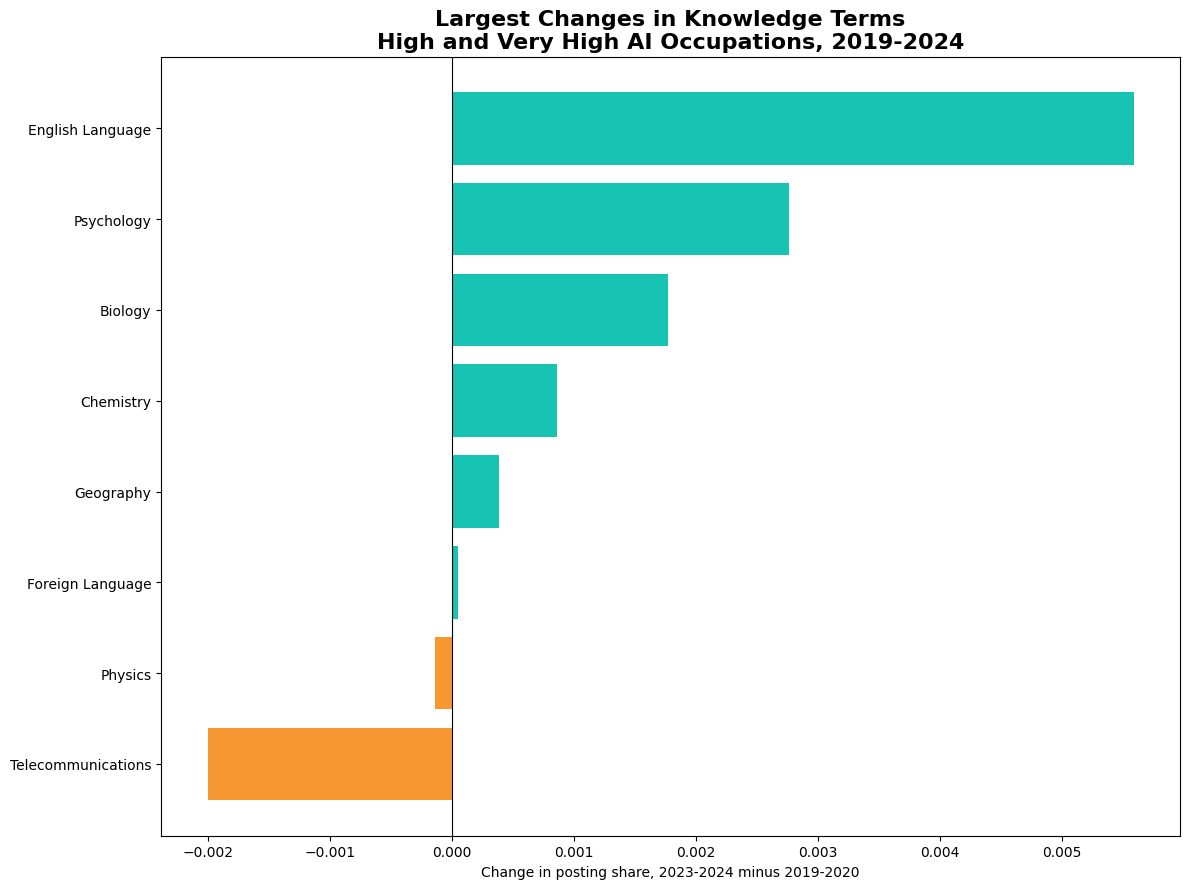

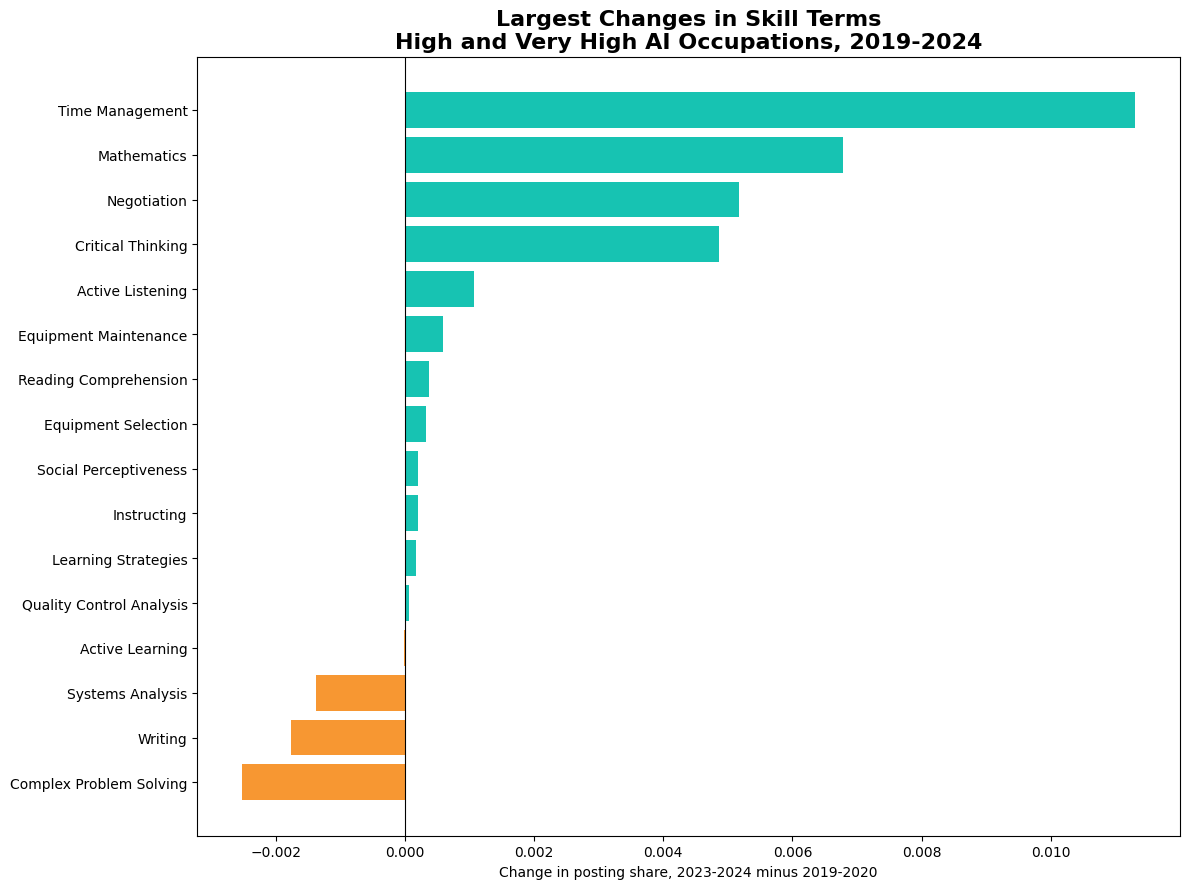

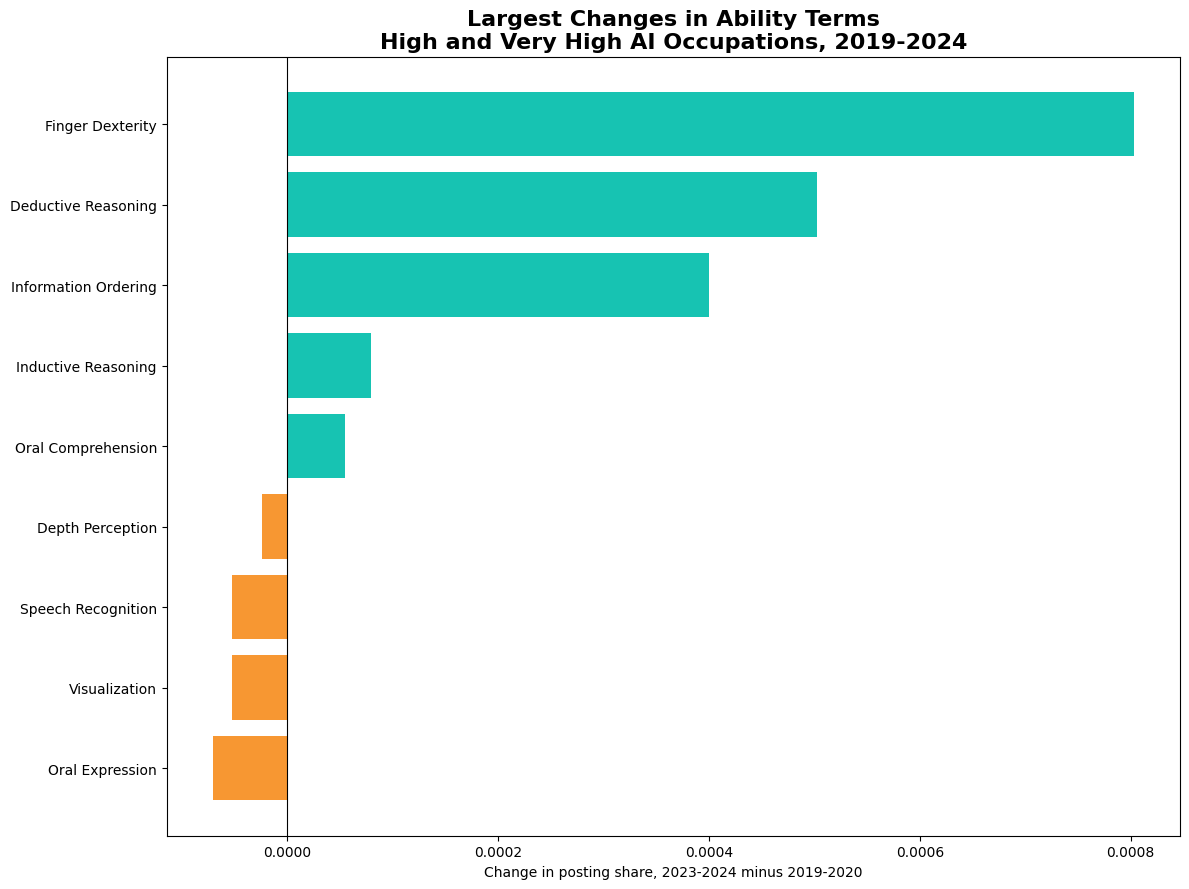

Separate Knowledge, Skill, and Ability outputs saved.


In [32]:
# =========================================================
# STEP 7B: SEPARATE K, S, AND A OUTPUTS
# =========================================================

for ksa_type in ["Knowledge", "Skill", "Ability"]:

    subset = wide[wide["KSA_Type"] == ksa_type].copy()

    subset = subset.sort_values("Abs_Change", ascending=False)

    subset.to_excel(
        OUT_FOLDER / f"Emerging_{ksa_type}_Terms_2019_2024.xlsx",
        index=False
    )

    # Plot largest changes within this KSA type
    plot_df = subset.head(TOP_N).copy()
    plot_df = plot_df.sort_values("Share_Change", ascending=True)

    colors = np.where(
        plot_df["Share_Change"] >= 0,
        PATINA,
        CARROT
    )

    plt.figure(figsize=(12, 9))

    plt.barh(
        [wrap(x) for x in plot_df["Term"]],
        plot_df["Share_Change"],
        color=colors
    )

    plt.axvline(0, color="black", linewidth=0.8)

    plt.title(
        f"Largest Changes in {ksa_type} Terms\nHigh and Very High AI Occupations, 2019-2024",
        fontsize=16,
        weight="bold"
    )

    plt.xlabel("Change in posting share, 2023-2024 minus 2019-2020")
    plt.ylabel("")

    plt.tight_layout()

    plt.savefig(
        OUT_FOLDER / f"Figure_Emerging_{ksa_type}_Terms_2019_2024.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

print("Separate Knowledge, Skill, and Ability outputs saved.")

AI exposure counts:
Exposure
Medium       216
Low          154
Very High    152
Very Low     152
High         151
Name: count, dtype: int64
Processed chunk 1. Postings kept: 0. Skill mentions counted: 0.
Processed chunk 2. Postings kept: 0. Skill mentions counted: 0.
Processed chunk 3. Postings kept: 0. Skill mentions counted: 0.
Processed chunk 4. Postings kept: 0. Skill mentions counted: 0.
Processed chunk 5. Postings kept: 0. Skill mentions counted: 0.
Processed chunk 6. Postings kept: 0. Skill mentions counted: 0.
Processed chunk 7. Postings kept: 0. Skill mentions counted: 0.
Processed chunk 8. Postings kept: 0. Skill mentions counted: 0.
Processed chunk 9. Postings kept: 152,926. Skill mentions counted: 2,000,924.
Processed chunk 10. Postings kept: 392,011. Skill mentions counted: 5,104,228.
Processed chunk 11. Postings kept: 631,133. Skill mentions counted: 8,228,619.
Processed chunk 12. Postings kept: 870,328. Skill mentions counted: 11,341,049.
Processed chunk 13. Postings kep

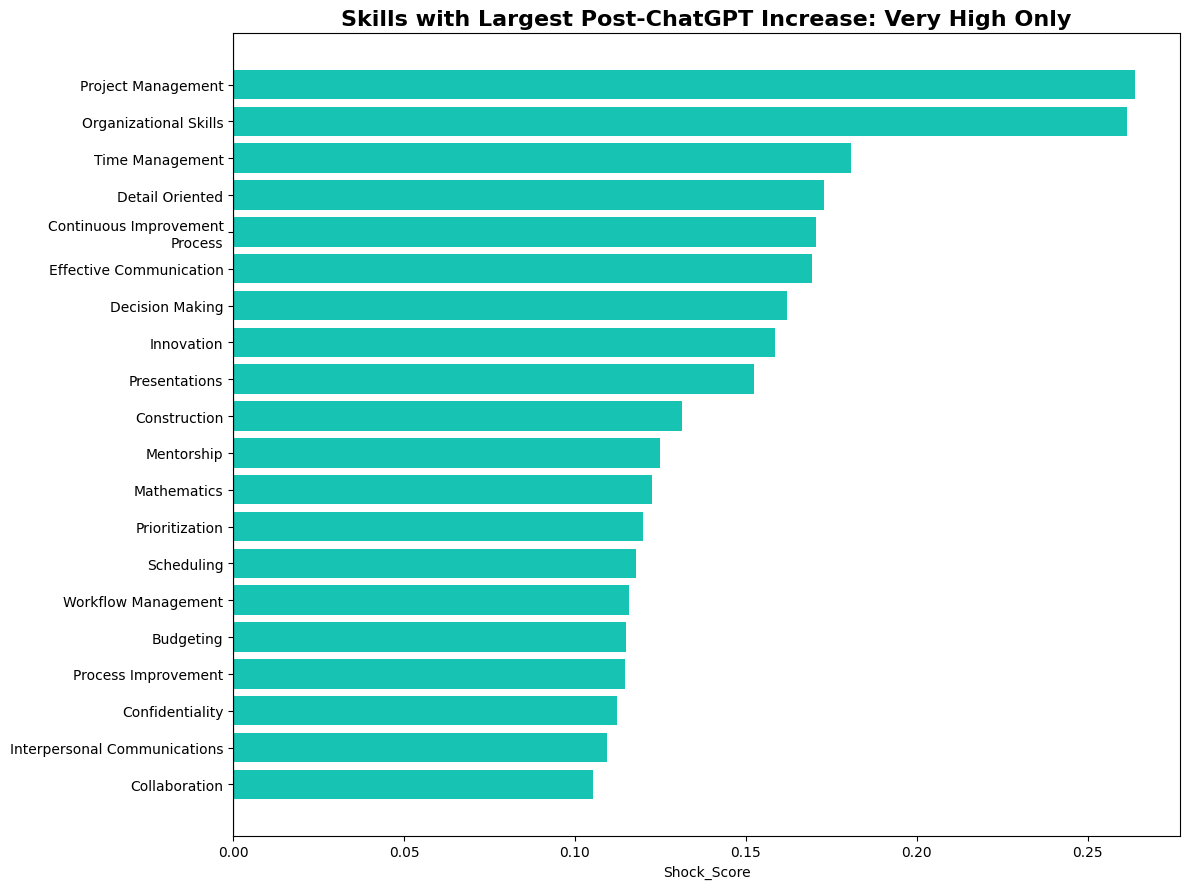

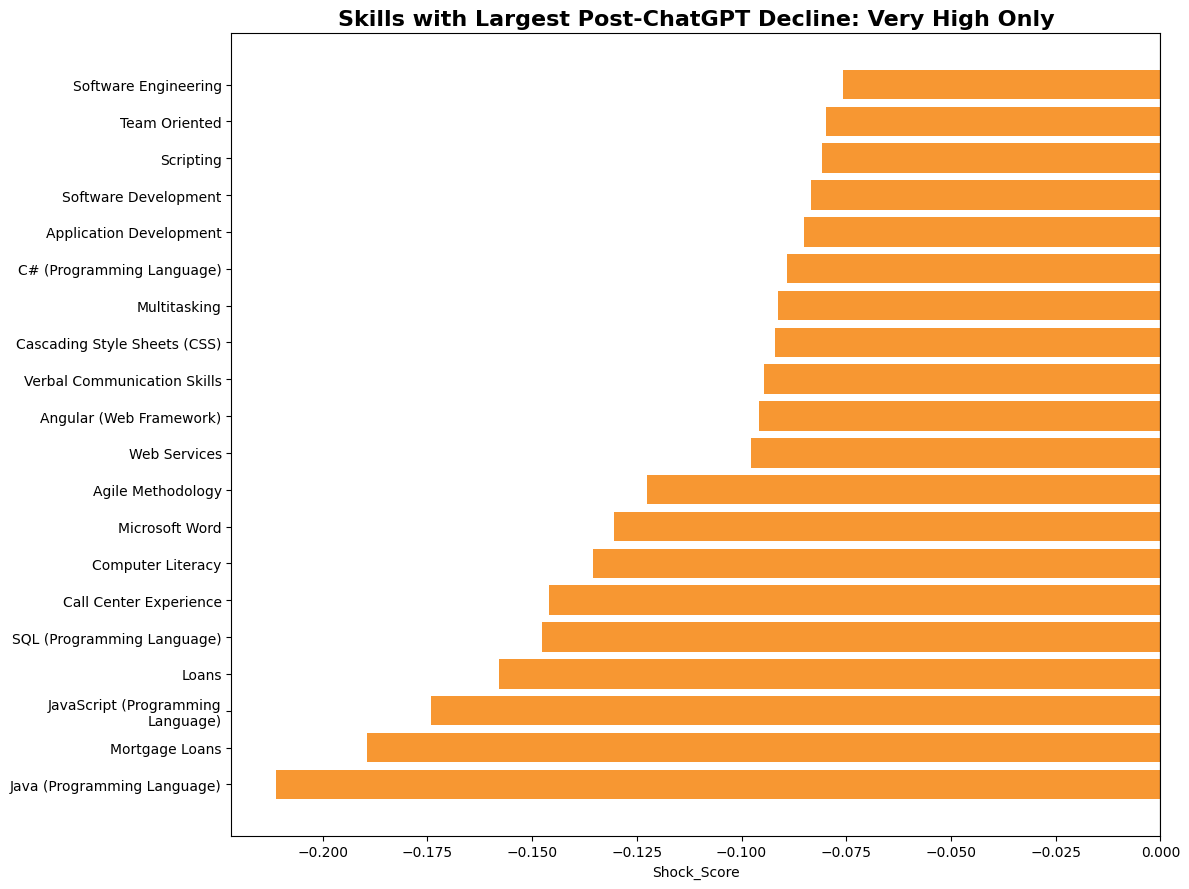

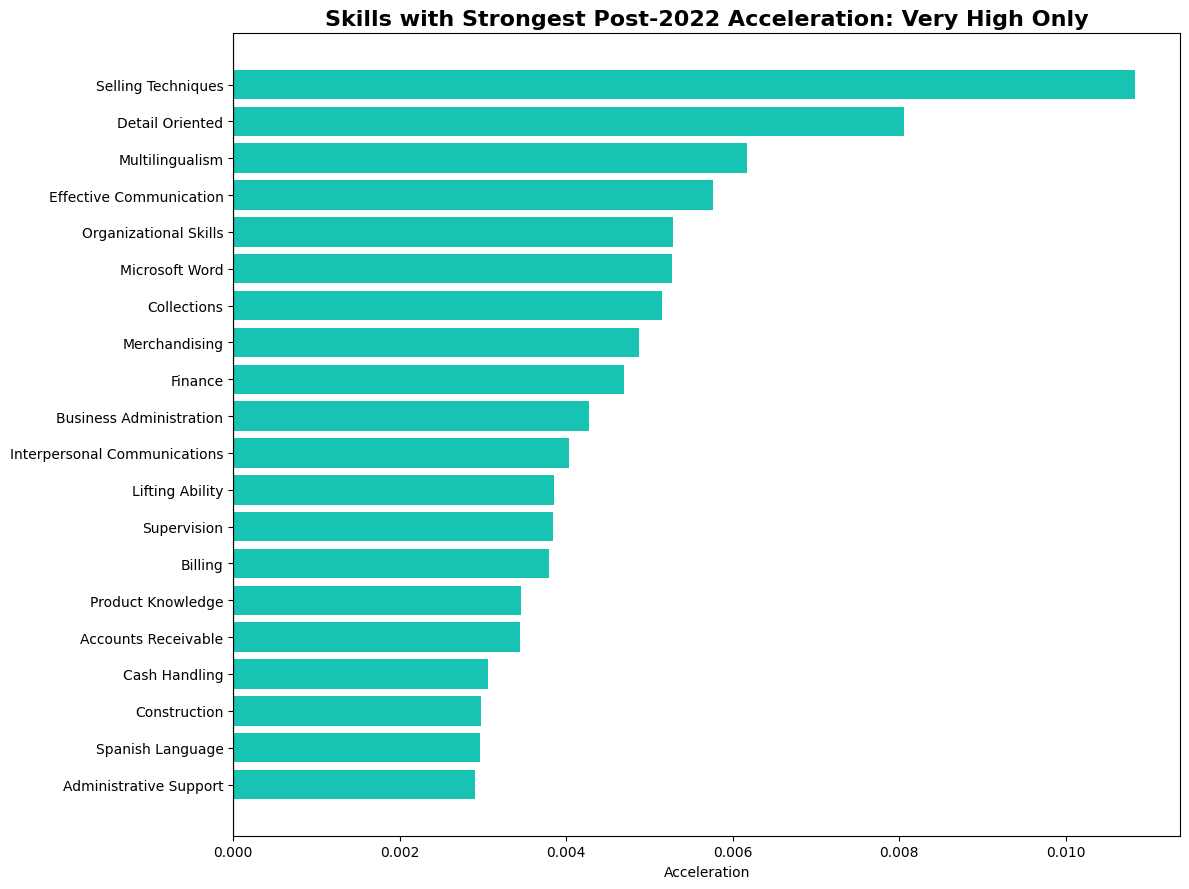

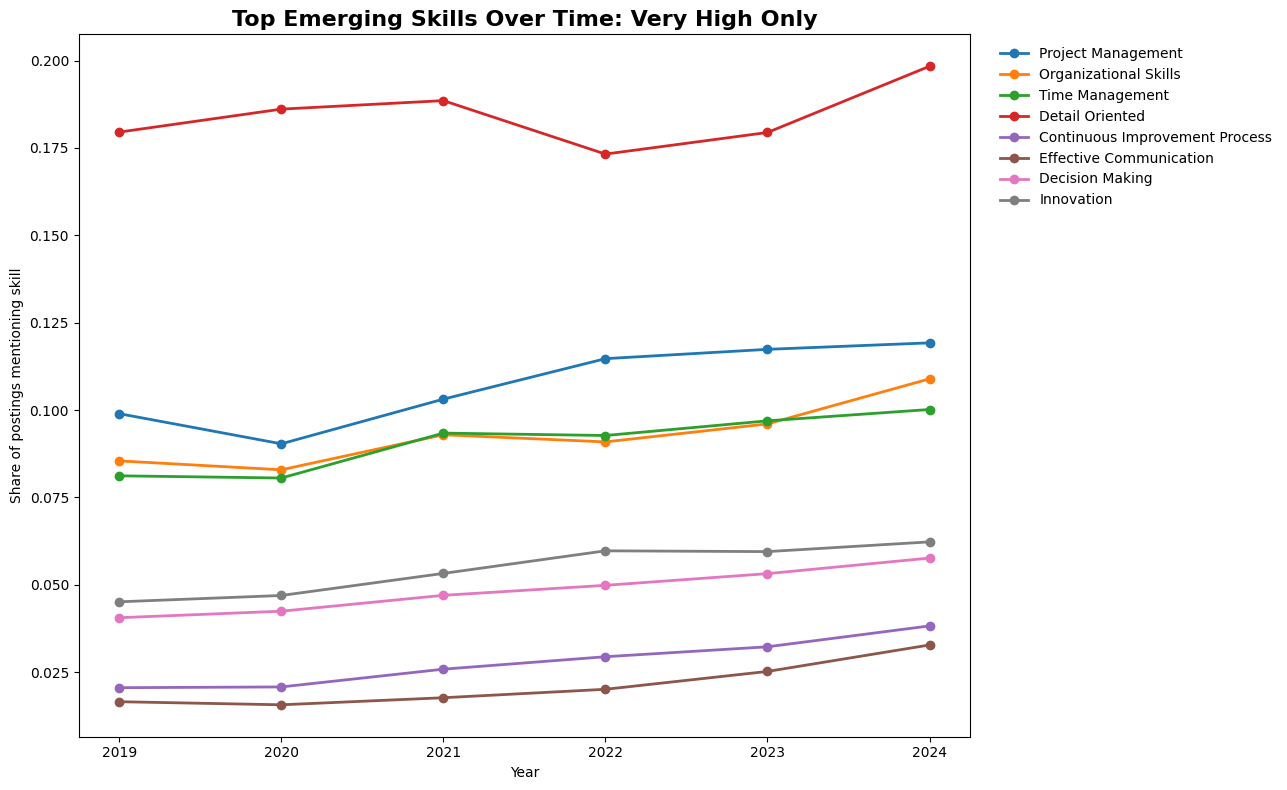

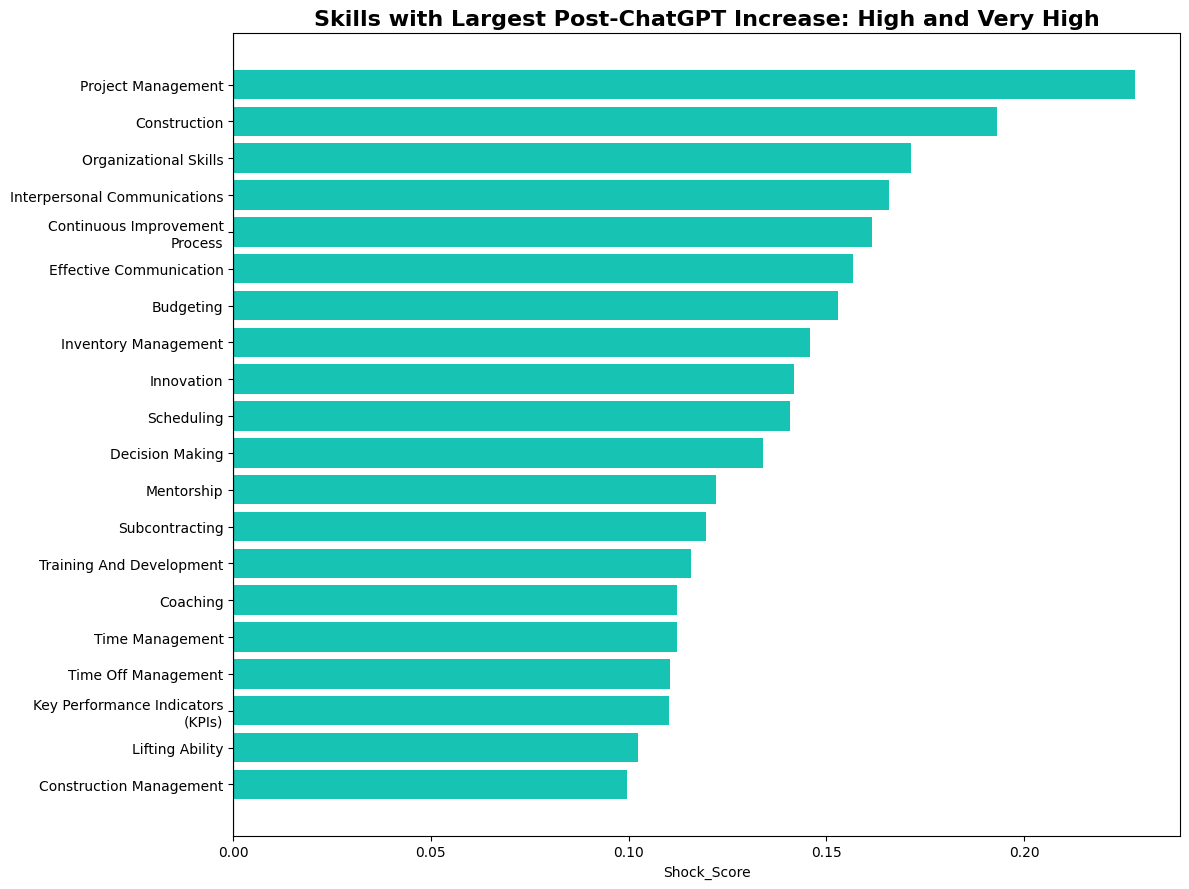

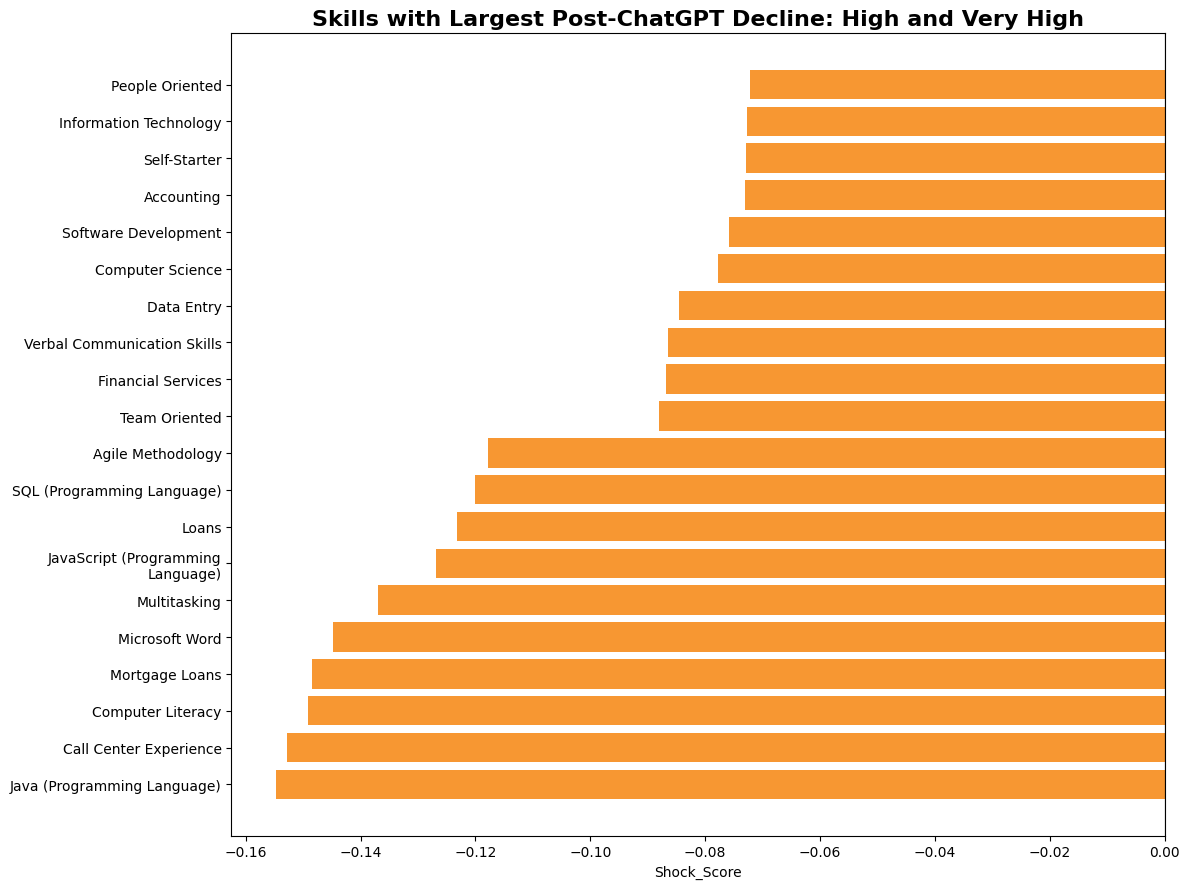

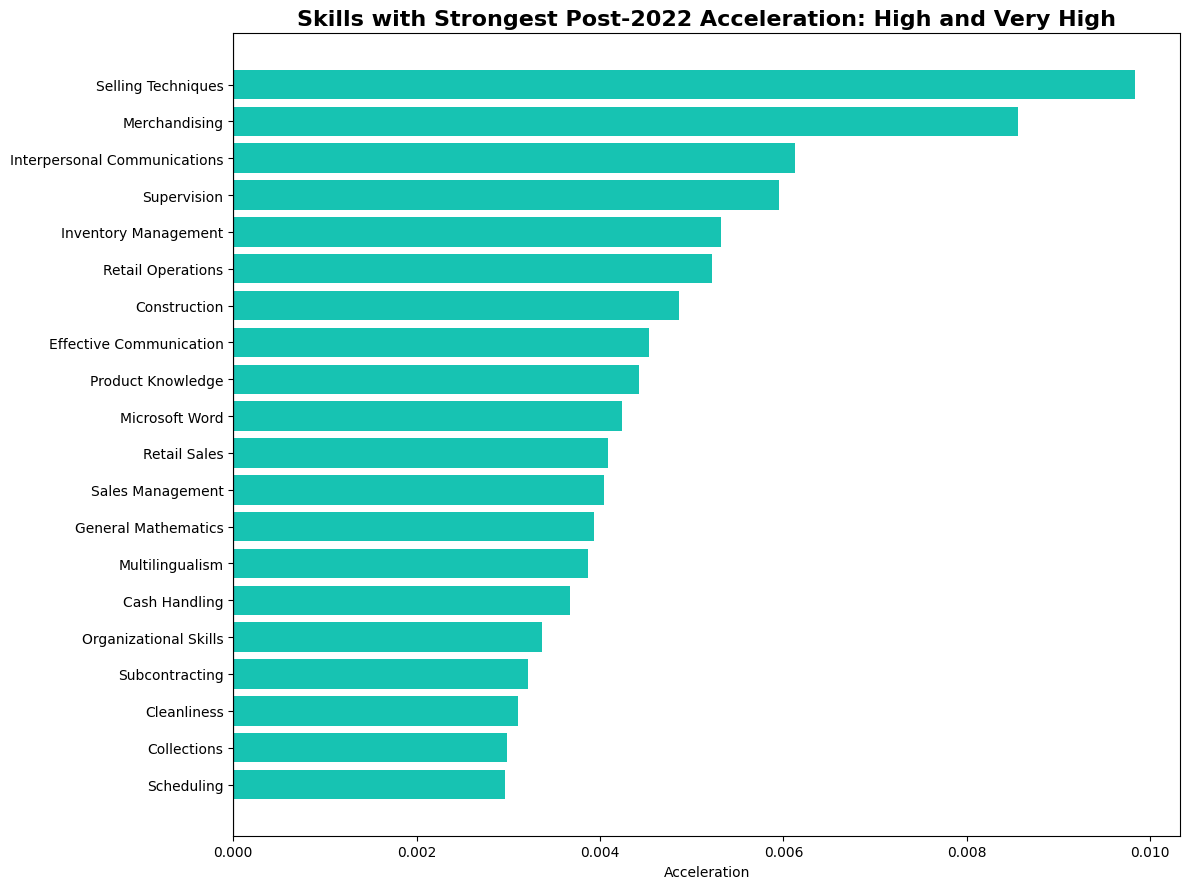

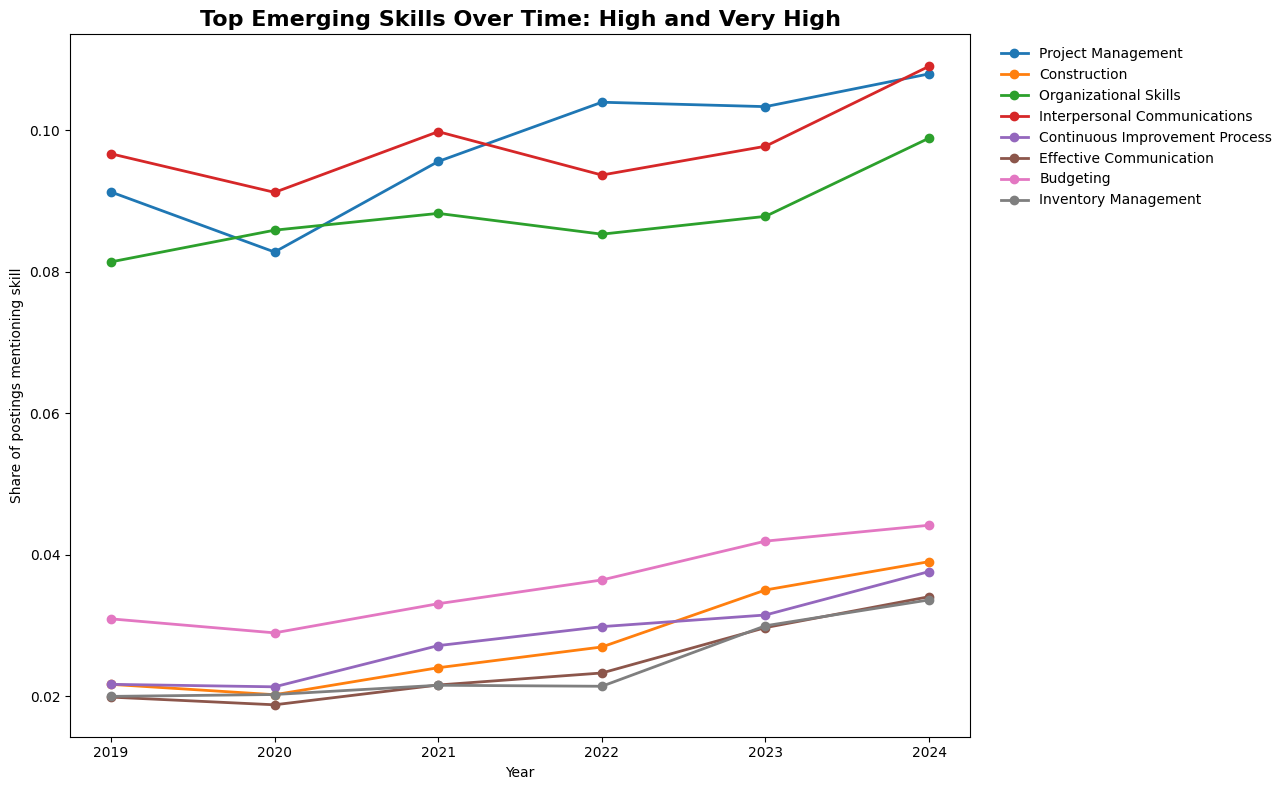


DONE.
Outputs saved to: C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO\Skill Outputs\ChatGPT_Shock

Top Very High Only increases:
                             Skill  Pre_Share  Post_Share  Pre_to_Post_Change  \
0               Project Management   0.097491    0.119237            0.021745   
1            Organizational Skills   0.087111    0.108936            0.021825   
4                  Time Management   0.085065    0.100171            0.015107   
6                  Detail Oriented   0.184724    0.198367            0.013643   
7   Continuous Improvement Process   0.022425    0.038258            0.015833   
8          Effective Communication   0.016660    0.032805            0.016145   
9                  Decision Making   0.043361    0.057670            0.014308   
10                      Innovation   0.048466    0.062299            0.013832   
12                   Presentations   0.069674    0.082588            0.012915   
16                    Construction   0.012699 

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
import ast, json, re, textwrap

# =========================================================
# PATHS
# =========================================================

POSTINGS_FILE = Path(
    r"G:\Shared drives\EO_OPERATIONS\Grants\PCIC Analysis\Job Posting Data\raw_data\df_2016_2025.csv"
)

AI_COMPOSITE_FILE = Path(
    r"G:\Shared drives\EO_ECONOMIC ANALYSIS\ea_common\Projects\AI\risk_index\ai_exposure_composite_clean.csv"
)

OUT_FOLDER = Path(
    r"C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO\Skill Outputs\ChatGPT_Shock"
)
OUT_FOLDER.mkdir(parents=True, exist_ok=True)

# =========================================================
# SETTINGS
# =========================================================

SOC_COL = "SOC_5"
YEAR_COL = "YEAR"
SKILL_COLS = ["SKILLS_NAME", "SOFTWARE_SKILLS_NAME"]

YEARS_TO_USE = list(range(2019, 2025))

PRE_YEARS = [2019, 2020, 2021]
TRANSITION_YEARS = [2022, 2023]
POST_YEARS = [2024]

CHUNK_SIZE = 250_000
TOP_N = 20

PATINA = "#17C3B2"
CARROT = "#F79732"

BROAD_EXCLUDE = {
    "communication", "communications", "leadership", "management",
    "operations", "planning", "coordinating", "coordination",
    "problem solving", "research", "writing", "sales",
    "customer service", "valid driver's license",
    "microsoft excel", "microsoft office", "english language"
}

MIN_POST_COUNT = 100
MIN_POST_SHARE = 0.0005

# =========================================================
# HELPERS
# =========================================================

def clean_skill(x):
    return (
        str(x).strip().lower()
        .replace("’", "'")
        .replace("–", "-")
        .replace("—", "-")
    )

def wrap(x, width=28):
    return "\n".join(textwrap.wrap(str(x), width))

def fix_soc(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip().replace(".0", "")

    if re.match(r"^\d{2}-\d{4}$", s):
        return s

    if s.startswith("Nov-"):
        nov_map = {
            "11": "11-2011", "21": "11-2021", "22": "11-2022",
            "32": "11-2032", "33": "11-2033", "12": "11-3012",
            "13": "11-3013", "31": "11-3031", "51": "11-3051",
            "61": "11-3061", "71": "11-3071", "41": "11-9041",
            "72": "11-9072", "81": "11-9081", "79": "11-9179",
            "99": "11-9199",
        }
        return nov_map.get(s.replace("Nov-", "").strip(), np.nan)

    return s

def standardize_exposure(x):
    s = str(x).strip().lower()
    mapping = {
        "very low": "Very Low",
        "low": "Low",
        "medium": "Medium",
        "high": "High",
        "very high": "Very High"
    }
    return mapping.get(s, str(x).strip())

def parse_skill_list(x):
    if pd.isna(x):
        return []

    s = str(x).strip()

    if s in ["", "[]", "nan", "None"]:
        return []

    try:
        parsed = ast.literal_eval(s)
        if isinstance(parsed, list):
            return [str(v).strip() for v in parsed if str(v).strip()]
    except:
        pass

    try:
        parsed = json.loads(s)
        if isinstance(parsed, list):
            return [str(v).strip() for v in parsed if str(v).strip()]
    except:
        pass

    return [v.strip() for v in s.split(",") if v.strip()]

def plot_bar(df, value_col, title, filename, top_n=20):
    plot_df = df.head(top_n).copy()
    plot_df = plot_df.sort_values(value_col, ascending=True)

    colors = np.where(plot_df[value_col] >= 0, PATINA, CARROT)

    plt.figure(figsize=(12, 9))
    plt.barh(
        [wrap(x) for x in plot_df["Skill"]],
        plot_df[value_col],
        color=colors
    )
    plt.axvline(0, color="black", linewidth=0.8)
    plt.title(title, fontsize=16, weight="bold")
    plt.xlabel(value_col)
    plt.ylabel("")
    plt.tight_layout()
    plt.savefig(OUT_FOLDER / filename, dpi=300, bbox_inches="tight")
    plt.show()

def plot_lines(skill_year, selected_skills, title, filename):
    line_data = skill_year[
        skill_year["skill_clean"].isin(selected_skills["skill_clean"])
    ].copy()

    plt.figure(figsize=(13, 8))

    for skill in selected_skills["Skill"]:
        temp = line_data[line_data["Skill"] == skill].sort_values("Year")
        plt.plot(
            temp["Year"],
            temp["Skill_Share"],
            marker="o",
            linewidth=2,
            label=skill
        )

    plt.title(title, fontsize=16, weight="bold")
    plt.xlabel("Year")
    plt.ylabel("Share of postings mentioning skill")
    plt.xticks(YEARS_TO_USE)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    plt.tight_layout()
    plt.savefig(OUT_FOLDER / filename, dpi=300, bbox_inches="tight")
    plt.show()

# =========================================================
# STEP 1: AI EXPOSURE LOOKUP
# =========================================================

ai = pd.read_csv(AI_COMPOSITE_FILE)
ai.columns = ai.columns.astype(str).str.strip()

ai["SOC"] = ai["SOC"].apply(fix_soc)
ai["Exposure"] = ai["AI Exposure Category"].astype(str).apply(standardize_exposure)

ai_lookup = (
    ai[["SOC", "Exposure"]]
    .dropna()
    .drop_duplicates(subset=["SOC"])
)

exposure_map = dict(zip(ai_lookup["SOC"], ai_lookup["Exposure"]))

print("AI exposure counts:")
print(ai_lookup["Exposure"].value_counts(dropna=False))

# =========================================================
# STEP 2: COUNT POSTING SKILLS BY YEAR + EXPOSURE
# =========================================================

skill_year_counter = Counter()
year_posting_counter = Counter()
soc2_skill_year_counter = Counter()

usecols = [SOC_COL, YEAR_COL] + SKILL_COLS

total_postings_kept = 0
total_skill_mentions = 0

for i, chunk in enumerate(
    pd.read_csv(
        POSTINGS_FILE,
        usecols=lambda c: c in usecols,
        chunksize=CHUNK_SIZE,
        low_memory=False
    ),
    start=1
):
    chunk[SOC_COL] = chunk[SOC_COL].astype(str).str.strip()
    chunk[YEAR_COL] = pd.to_numeric(chunk[YEAR_COL], errors="coerce")

    chunk = chunk[chunk[SOC_COL].str.match(r"^\d{2}-\d{4}$", na=False)].copy()
    chunk = chunk[chunk[YEAR_COL].isin(YEARS_TO_USE)].copy()

    chunk["Exposure"] = chunk[SOC_COL].map(exposure_map)
    chunk["Exposure"] = chunk["Exposure"].apply(standardize_exposure)

    chunk = chunk[chunk["Exposure"].isin(["Very Low", "Low", "Medium", "High", "Very High"])].copy()

    for row in chunk.itertuples(index=False):
        row_dict = row._asdict()

        soc = row_dict[SOC_COL]
        soc2 = str(soc)[:2]
        year = int(row_dict[YEAR_COL])
        exposure = row_dict["Exposure"]

        skills = []
        for col in SKILL_COLS:
            skills += parse_skill_list(row_dict.get(col))

        skills = sorted(set([s for s in skills if str(s).strip()]))

        year_posting_counter[(exposure, year)] += 1
        total_postings_kept += 1

        for skill in skills:
            skill_clean = clean_skill(skill)

            skill_year_counter[(skill, skill_clean, exposure, year)] += 1
            soc2_skill_year_counter[(soc2, skill, skill_clean, exposure, year)] += 1
            total_skill_mentions += 1

    print(
        f"Processed chunk {i}. "
        f"Postings kept: {total_postings_kept:,}. "
        f"Skill mentions counted: {total_skill_mentions:,}."
    )

# =========================================================
# STEP 3: BUILD TABLES
# =========================================================

skill_year = pd.DataFrame([
    {
        "Skill": k[0],
        "skill_clean": k[1],
        "Exposure": k[2],
        "Year": k[3],
        "Skill_Count": v
    }
    for k, v in skill_year_counter.items()
])

year_totals = pd.DataFrame([
    {
        "Exposure": k[0],
        "Year": k[1],
        "Total_Postings": v
    }
    for k, v in year_posting_counter.items()
])

skill_year = skill_year.merge(
    year_totals,
    on=["Exposure", "Year"],
    how="left"
)

skill_year["Skill_Share"] = skill_year["Skill_Count"] / skill_year["Total_Postings"]

skill_year.to_excel(
    OUT_FOLDER / "All_Posting_Skills_By_Exposure_Year_2019_2024.xlsx",
    index=False
)

soc2_skill_year = pd.DataFrame([
    {
        "SOC2": k[0],
        "Skill": k[1],
        "skill_clean": k[2],
        "Exposure": k[3],
        "Year": k[4],
        "Skill_Count": v
    }
    for k, v in soc2_skill_year_counter.items()
])

soc2_skill_year.to_csv(
    OUT_FOLDER / "SOC2_Posting_Skills_By_Exposure_Year_2019_2024.csv",
    index=False
)

year_totals.to_excel(
    OUT_FOLDER / "Posting_Counts_By_Exposure_Year_2019_2024.xlsx",
    index=False
)

# =========================================================
# STEP 4: CHATGPT SHOCK FUNCTION
# =========================================================

def build_chatgpt_shock(skill_year, exposure_groups, label):
    temp = skill_year[skill_year["Exposure"].isin(exposure_groups)].copy()

    grouped = (
        temp.groupby(["Skill", "skill_clean", "Year"], as_index=False)
        .agg(
            Skill_Count=("Skill_Count", "sum"),
            Total_Postings=("Total_Postings", "sum")
        )
    )

    grouped["Skill_Share"] = grouped["Skill_Count"] / grouped["Total_Postings"]

    wide = grouped.pivot_table(
        index=["Skill", "skill_clean"],
        columns="Year",
        values="Skill_Share",
        fill_value=0
    ).reset_index()

    counts = grouped.groupby(["Skill", "skill_clean"], as_index=False).agg(
        Total_Count=("Skill_Count", "sum")
    )

    wide = wide.merge(counts, on=["Skill", "skill_clean"], how="left")

    for y in YEARS_TO_USE:
        if y not in wide.columns:
            wide[y] = 0

    wide["Pre_Share"] = wide[PRE_YEARS].mean(axis=1)
    wide["Transition_Share"] = wide[TRANSITION_YEARS].mean(axis=1)
    wide["Post_Share"] = wide[POST_YEARS].mean(axis=1)

    wide["Pre_to_Post_Change"] = wide["Post_Share"] - wide["Pre_Share"]
    wide["Transition_Change"] = wide["Transition_Share"] - wide["Pre_Share"]

    wide["Pre_Slope"] = (wide[2021] - wide[2019]) / 2
    wide["Post_Slope"] = (wide[2024] - wide[2022]) / 2
    wide["Acceleration"] = wide["Post_Slope"] - wide["Pre_Slope"]

    wide["Emergence_Ratio"] = np.where(
        wide["Pre_Share"] > 0,
        wide["Post_Share"] / wide["Pre_Share"],
        np.nan
    )

    wide["Shock_Score"] = (
        wide["Pre_to_Post_Change"] *
        np.log1p(wide["Total_Count"])
    )

    wide["Abs_Shock_Score"] = wide["Shock_Score"].abs()

    wide["Analysis_Group"] = label

    filtered = wide[
        (~wide["skill_clean"].isin(BROAD_EXCLUDE)) &
        (wide["Total_Count"] >= MIN_POST_COUNT) &
        (
            (wide["Pre_Share"] >= MIN_POST_SHARE) |
            (wide["Post_Share"] >= MIN_POST_SHARE)
        )
    ].copy()

    return wide.sort_values("Abs_Shock_Score", ascending=False), filtered.sort_values("Abs_Shock_Score", ascending=False), grouped

# =========================================================
# STEP 5: RUN ANALYSES
# =========================================================

analyses = {
    "Very_High_Only": ["Very High"],
    "High_and_Very_High": ["High", "Very High"]
}

all_results = []

for label, groups in analyses.items():
    shock_all, shock_filtered, grouped_ts = build_chatgpt_shock(
        skill_year,
        exposure_groups=groups,
        label=label
    )

    shock_all.to_excel(
        OUT_FOLDER / f"{label}_ChatGPT_Shock_All_Skills.xlsx",
        index=False
    )

    shock_filtered.to_excel(
        OUT_FOLDER / f"{label}_ChatGPT_Shock_Filtered_Skills.xlsx",
        index=False
    )

    grouped_ts.to_excel(
        OUT_FOLDER / f"{label}_Skill_TimeSeries_Data.xlsx",
        index=False
    )

    all_results.append(shock_filtered)

    # Biggest increases
    increases = shock_filtered[shock_filtered["Shock_Score"] > 0].sort_values(
        "Shock_Score",
        ascending=False
    )

    plot_bar(
        increases,
        "Shock_Score",
        f"Skills with Largest Post-ChatGPT Increase: {label.replace('_', ' ')}",
        f"Figure_{label}_PostChatGPT_Increases.png",
        top_n=TOP_N
    )

    # Biggest declines
    declines = shock_filtered[shock_filtered["Shock_Score"] < 0].sort_values(
        "Shock_Score",
        ascending=True
    )

    plot_bar(
        declines,
        "Shock_Score",
        f"Skills with Largest Post-ChatGPT Decline: {label.replace('_', ' ')}",
        f"Figure_{label}_PostChatGPT_Declines.png",
        top_n=TOP_N
    )

    # Acceleration
    accel = shock_filtered.sort_values("Acceleration", ascending=False).head(TOP_N)
    plot_bar(
        accel,
        "Acceleration",
        f"Skills with Strongest Post-2022 Acceleration: {label.replace('_', ' ')}",
        f"Figure_{label}_Skill_Acceleration.png",
        top_n=TOP_N
    )

    # Time series lines for top increasing skills
    top_line = increases.head(8)
    plot_lines(
        grouped_ts,
        top_line,
        f"Top Emerging Skills Over Time: {label.replace('_', ' ')}",
        f"Figure_{label}_Top_Emerging_Skills_TimeSeries.png"
    )

# =========================================================
# STEP 6: TOP 50 PRE VS POST TABLES
# =========================================================

for label, groups in analyses.items():
    temp = skill_year[skill_year["Exposure"].isin(groups)].copy()

    pre = (
        temp[temp["Year"].isin(PRE_YEARS)]
        .groupby(["Skill", "skill_clean"], as_index=False)
        .agg(
            Skill_Count_Pre=("Skill_Count", "sum"),
            Posting_Total_Pre=("Total_Postings", "sum")
        )
    )
    pre["Skill_Share_Pre"] = pre["Skill_Count_Pre"] / pre["Posting_Total_Pre"]

    post = (
        temp[temp["Year"].isin(POST_YEARS)]
        .groupby(["Skill", "skill_clean"], as_index=False)
        .agg(
            Skill_Count_Post=("Skill_Count", "sum"),
            Posting_Total_Post=("Total_Postings", "sum")
        )
    )
    post["Skill_Share_Post"] = post["Skill_Count_Post"] / post["Posting_Total_Post"]

    comparison = pre.merge(post, on=["Skill", "skill_clean"], how="outer").fillna(0)
    comparison["Skill_Share_Change"] = (
        comparison["Skill_Share_Post"] -
        comparison["Skill_Share_Pre"]
    )

    top50_pre = pre.sort_values("Skill_Share_Pre", ascending=False).head(50)
    top50_post = post.sort_values("Skill_Share_Post", ascending=False).head(50)

    with pd.ExcelWriter(
        OUT_FOLDER / f"{label}_Top50_Pre_vs_Post_ChatGPT.xlsx",
        engine="openpyxl"
    ) as writer:
        top50_pre.to_excel(writer, sheet_name="Top 50 Pre", index=False)
        top50_post.to_excel(writer, sheet_name="Top 50 Post", index=False)
        comparison.to_excel(writer, sheet_name="All Skill Comparison", index=False)

# =========================================================
# STEP 7: COMBINED OUTPUT
# =========================================================

combined = pd.concat(all_results, ignore_index=True)

combined.to_excel(
    OUT_FOLDER / "Combined_Filtered_ChatGPT_Shock_Results.xlsx",
    index=False
)

print("\nDONE.")
print(f"Outputs saved to: {OUT_FOLDER}")

print("\nTop Very High Only increases:")
print(
    combined[
        combined["Analysis_Group"] == "Very_High_Only"
    ].sort_values("Shock_Score", ascending=False)[
        ["Skill", "Pre_Share", "Post_Share", "Pre_to_Post_Change", "Shock_Score", "Acceleration", "Total_Count"]
    ].head(20)
)

print("\nTop High + Very High increases:")
print(
    combined[
        combined["Analysis_Group"] == "High_and_Very_High"
    ].sort_values("Shock_Score", ascending=False)[
        ["Skill", "Pre_Share", "Post_Share", "Pre_to_Post_Change", "Shock_Score", "Acceleration", "Total_Count"]
    ].head(20)
)

AI composite columns:
['SOC', 'AI Exposure Category', 'Data Source', 'Occupation Title', 'PCA Weighted Score', 'Z Score Variance', 'SCM Employment', 'SCM Employment Donors', 'SCM Employment RMPSE', 'SCM Employment Normalized Risk Score', 'SCM Postings', 'SCM Postings Donors', 'SCM Postings RMPSE', 'SCM Postings Normalized Risk Score', 'Layoff AI Risk', 'Layoff Normalized AI Risk', 'Layoff Observed In Layoff', 'Layoff Likelihood Estimate', 'Layoff Normalized Likelihood', 'Layoff Total Occupational Impact', 'Layoff Occupational Impact', 'Layoff Relatedness Risk', 'Layoff Normalized Relatedness Risk', 'Annual Total Openings', 'Annual Percent Change', 'Education Value', 'Work Experience Value', 'Growth Rate', '50th Percentile Wage']

AI exposure groups:
Exposure
Medium       216
Low          154
Very High    152
Very Low     152
High         151
Name: count, dtype: int64
Processed chunk 1
Processed chunk 2
Processed chunk 3
Processed chunk 4
Processed chunk 5
Processed chunk 6
Processed ch

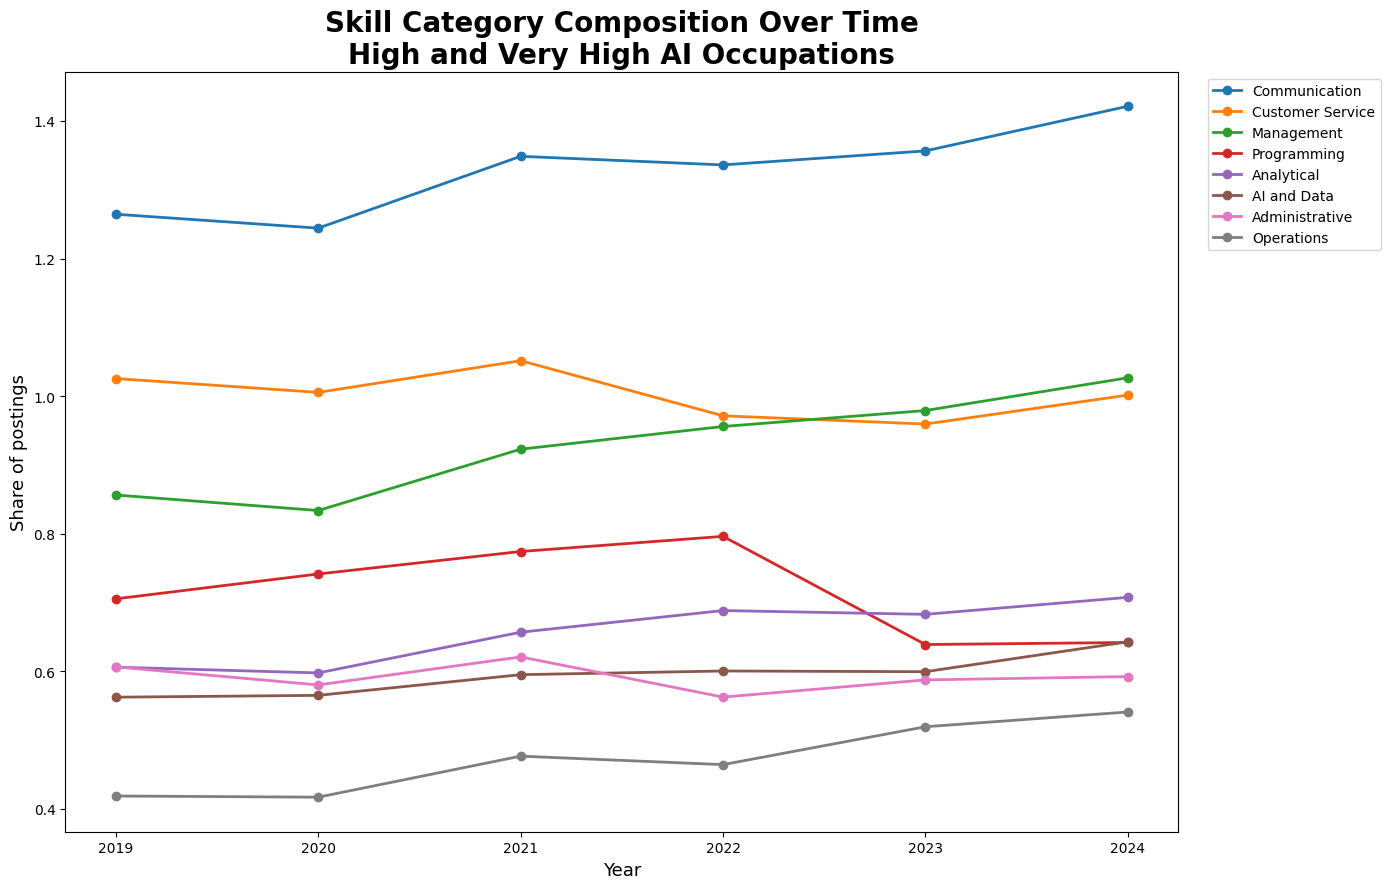

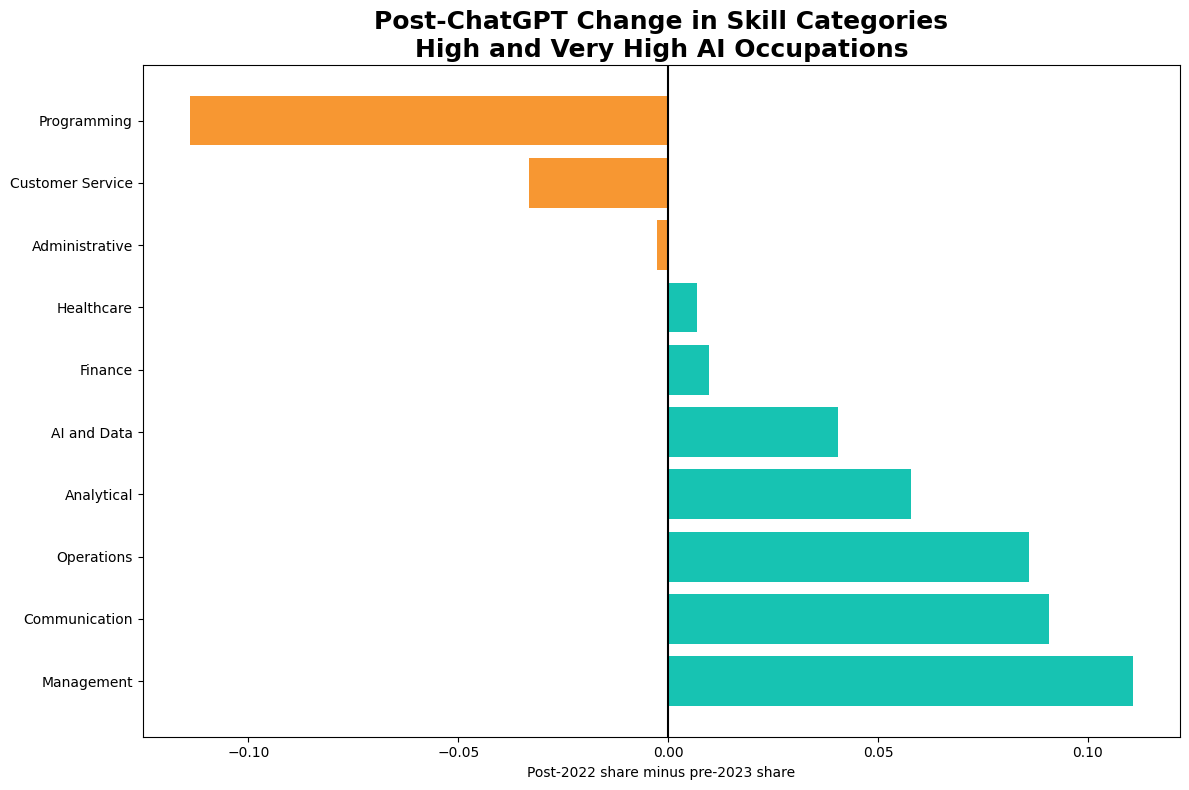

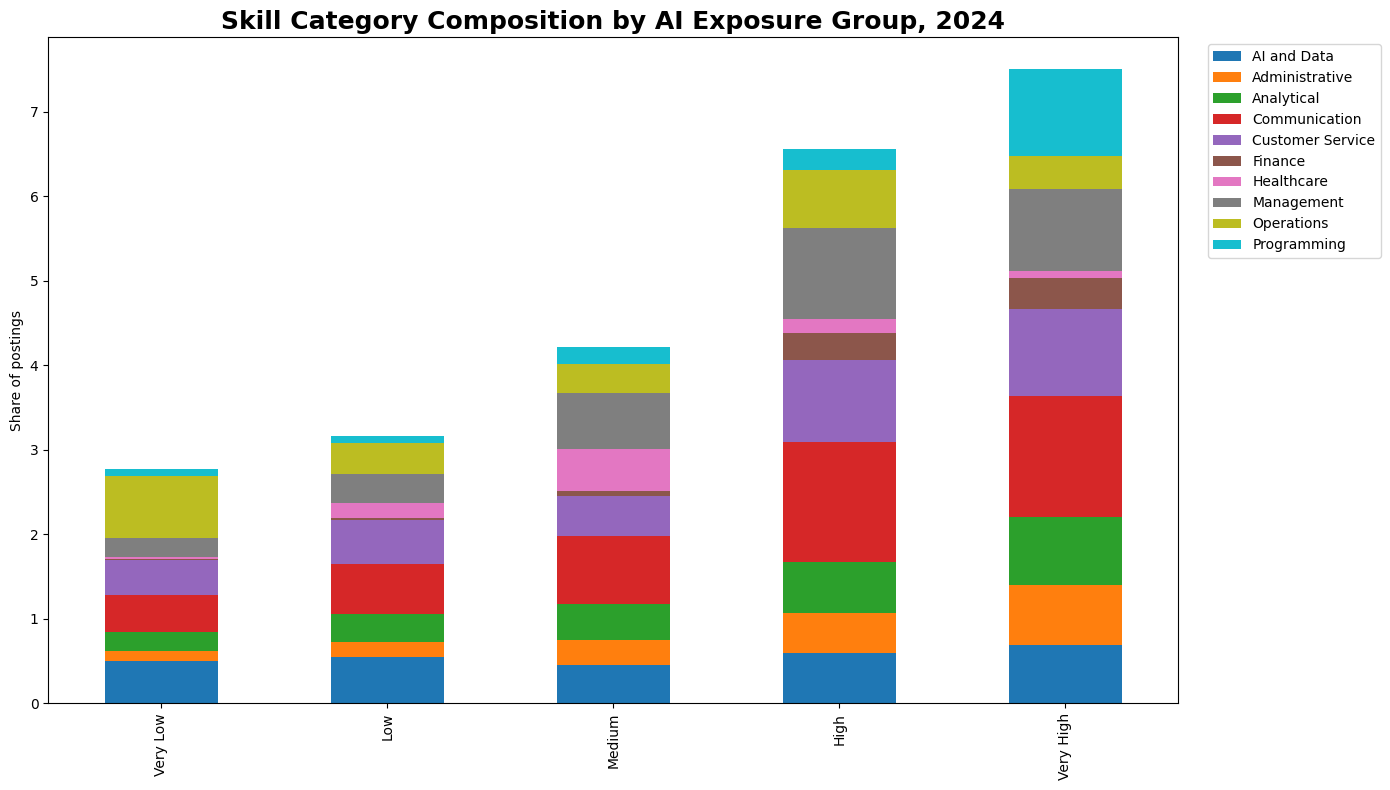


DONE.
Outputs saved to: C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO\Category Skill Outputs

Top categories:
           Category  Skill_Count  Posting_Count
3     Communication          286        5961914
4  Customer Service          459        4465094
7        Management          270        4149211
0       AI and Data         1087        3168612
2        Analytical          436        3050965
9       Programming         1607        2883348
8        Operations          226        2635888
1    Administrative          130        2561230
6        Healthcare          251        1276941
5           Finance          153        1162742


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import ast
import json
import re
from collections import Counter, defaultdict
import textwrap

# =========================================================
# PATHS
# =========================================================

POSTINGS_FILE = Path(
    r"G:\Shared drives\EO_OPERATIONS\Grants\PCIC Analysis\Job Posting Data\raw_data\df_2016_2025.csv"
)

AI_COMPOSITE_FILE = Path(
    r"G:\Shared drives\EO_ECONOMIC ANALYSIS\ea_common\Projects\AI\risk_index\ai_exposure_composite_clean.csv"
)

OUT_FOLDER = Path(
    r"C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO\Category Skill Outputs"
)

OUT_FOLDER.mkdir(parents=True, exist_ok=True)

# =========================================================
# SETTINGS
# =========================================================

START_YEAR = 2019
END_YEAR = 2024

TOP_N = 15
CHUNK_SIZE = 100_000

PATINA = "#17C3B2"
CARROT = "#F79732"
DARK_BLUE = "#003057"

# =========================================================
# CATEGORY KEYWORD RULES
# =========================================================

CATEGORY_MAP = {

    "Programming": [
        "python", "sql", "java", "javascript", "software",
        "coding", "programming", "web development",
        "application development", "c#", "css", "html",
        "agile", "scrum", "cloud", "git", "api"
    ],

    "AI and Data": [
        "machine learning", "artificial intelligence",
        "data science", "analytics", "data analysis",
        "automation", "data visualization", "ai",
        "business intelligence"
    ],

    "Communication": [
        "communication", "presentation", "leadership",
        "interpersonal", "collaboration", "negotiation",
        "public speaking", "writing", "speaking",
        "relationship management"
    ],

    "Management": [
        "project management", "scheduling", "workflow",
        "coordination", "planning", "organization",
        "organizational", "time management",
        "supervision", "mentorship", "coaching",
        "prioritization", "kpi"
    ],

    "Analytical": [
        "problem solving", "critical thinking",
        "decision making", "analysis", "research",
        "mathematics", "troubleshooting",
        "continuous improvement"
    ],

    "Administrative": [
        "microsoft word", "data entry", "billing",
        "administrative", "clerical", "documentation",
        "computer literacy", "office", "typing",
        "records management"
    ],

    "Customer Service": [
        "customer service", "sales", "retail",
        "hospitality", "service", "client relations",
        "call center", "customer support"
    ],

    "Operations": [
        "inventory", "warehousing", "construction",
        "logistics", "supply chain", "shipping",
        "forklift", "loading", "sanitation",
        "operations"
    ],

    "Finance": [
        "accounting", "budgeting", "finance",
        "financial analysis", "bookkeeping",
        "accounts payable", "accounts receivable",
        "business administration", "economics"
    ],

    "Healthcare": [
        "patient care", "nursing", "medical records",
        "clinical", "healthcare", "ehr",
        "electronic medical records", "phlebotomy"
    ]
}

# =========================================================
# HELPERS
# =========================================================
def fix_soc(x):

    s = str(x).strip()

    # Fix Excel month conversion issue
    month_map = {
        "Jan": "01",
        "Feb": "02",
        "Mar": "03",
        "Apr": "04",
        "May": "05",
        "Jun": "06",
        "Jul": "07",
        "Aug": "08",
        "Sep": "09",
        "Oct": "10",
        "Nov": "11",
        "Dec": "12"
    }

    for month, num in month_map.items():

        if s.startswith(month + "-"):
            s = s.replace(month + "-", num + "-", 1)

    # Keep standard SOC format
    match = re.search(r"(\d{2}-\d{4})", s)

    if match:
        return match.group(1)

    return np.nan

def wrap(text, width=28):
    return "\n".join(textwrap.wrap(str(text), width))

def clean_skill(skill):

    return (
        str(skill)
        .lower()
        .strip()
        .replace("’", "'")
        .replace("–", "-")
        .replace("—", "-")
    )

def parse_skill_list(x):

    if pd.isna(x):
        return []

    s = str(x).strip()

    if s in ["", "[]", "nan", "None"]:
        return []

    try:
        parsed = ast.literal_eval(s)

        if isinstance(parsed, list):
            return [str(v).strip() for v in parsed if str(v).strip()]

    except:
        pass

    try:
        parsed = json.loads(s)

        if isinstance(parsed, list):
            return [str(v).strip() for v in parsed if str(v).strip()]

    except:
        pass

    return []

def assign_category(skill):

    s = clean_skill(skill)

    for category, keywords in CATEGORY_MAP.items():

        for kw in keywords:

            if kw in s:
                return category

    return "Other"

def standardize_exposure(x):

    s = str(x).strip().lower()

    mapping = {
        "very low": "Very Low",
        "low": "Low",
        "medium": "Medium",
        "high": "High",
        "very high": "Very High"
    }

    return mapping.get(s, np.nan)

# =========================================================
# LOAD AI COMPOSITE
# =========================================================

ai = pd.read_csv(AI_COMPOSITE_FILE)
ai.columns = ai.columns.astype(str).str.strip()

print("AI composite columns:")
print(ai.columns.tolist())

# Find SOC column
soc_candidates = ["SOC", "SOC Code", "SOC2018.1", "SOC Code1", "O*NET-SOC Code"]
soc_ai_col = next((c for c in soc_candidates if c in ai.columns), None)

# Find exposure column
exposure_candidates = ["AI Exposure Category", "exposure", "Exposure", "Category", "exposure_group"]
exposure_ai_col = next((c for c in exposure_candidates if c in ai.columns), None)

if soc_ai_col is None:
    raise KeyError("Could not find SOC column in AI composite file.")

if exposure_ai_col is None:
    raise KeyError("Could not find exposure/category column in AI composite file.")

ai[soc_ai_col] = ai[soc_ai_col].astype(str).str.strip()
ai[exposure_ai_col] = ai[exposure_ai_col].astype(str).str.strip()

ai = ai[[soc_ai_col, exposure_ai_col]].drop_duplicates()
ai.columns = ["SOC_5", "Exposure"]

ai["SOC_5"] = ai["SOC_5"].apply(fix_soc)
ai["Exposure"] = ai["Exposure"].apply(standardize_exposure)

ai = ai.dropna(subset=["SOC_5", "Exposure"]).copy()

print("\nAI exposure groups:")
print(ai["Exposure"].value_counts())

# =========================================================
# PROCESS POSTINGS FILE
# =========================================================

category_counter = Counter()

category_year_counter = Counter()

category_exposure_counter = Counter()

category_exposure_year_counter = Counter()

year_totals = Counter()

matched_rows = []

usecols = [
    "SOC_5",
    "YEAR",
    "SKILLS_NAME",
    "SOFTWARE_SKILLS_NAME"
]

for i, chunk in enumerate(

    pd.read_csv(
        POSTINGS_FILE,
        usecols=lambda c: c in usecols,
        chunksize=CHUNK_SIZE,
        low_memory=False
    ),

    start=1
):

    chunk["SOC_5"] = chunk["SOC_5"].astype(str).str.strip()

    chunk["YEAR"] = pd.to_numeric(
        chunk["YEAR"],
        errors="coerce"
    )

    chunk = chunk[
        chunk["YEAR"].between(START_YEAR, END_YEAR)
    ].copy()

    chunk = chunk.merge(
        ai,
        on="SOC_5",
        how="left"
    )

    chunk = chunk[
        chunk["Exposure"].notna()
    ].copy()

    for _, row in chunk.iterrows():

        year = int(row["YEAR"])
        exposure = row["Exposure"]

        year_totals[(year, exposure)] += 1

        skills = []

        skills += parse_skill_list(row.get("SKILLS_NAME"))
        skills += parse_skill_list(row.get("SOFTWARE_SKILLS_NAME"))

        if not skills:
            continue

        unique_skills = sorted(set(skills))

        for skill in unique_skills:

            category = assign_category(skill)

            if category == "Other":
                continue

            category_counter[category] += 1

            category_year_counter[(category, year)] += 1

            category_exposure_counter[(category, exposure)] += 1

            category_exposure_year_counter[
                (category, exposure, year)
            ] += 1

            matched_rows.append({
                "Year": year,
                "Exposure": exposure,
                "Skill": skill,
                "Category": category
            })

    print(f"Processed chunk {i}")

# =========================================================
# BUILD DATAFRAMES
# =========================================================

matched = pd.DataFrame(matched_rows)

category_year = pd.DataFrame([

    {
        "Category": k[0],
        "Year": k[1],
        "Count": v
    }

    for k, v in category_year_counter.items()

])

category_exposure_year = pd.DataFrame([

    {
        "Category": k[0],
        "Exposure": k[1],
        "Year": k[2],
        "Count": v
    }

    for k, v in category_exposure_year_counter.items()

])

year_totals_df = pd.DataFrame([

    {
        "Year": k[0],
        "Exposure": k[1],
        "Posting_Count": v
    }

    for k, v in year_totals.items()

])

# =========================================================
# CALCULATE SHARES
# =========================================================

category_exposure_year = category_exposure_year.merge(
    year_totals_df,
    on=["Year", "Exposure"],
    how="left"
)

category_exposure_year["Share"] = (
    category_exposure_year["Count"] /
    category_exposure_year["Posting_Count"]
)

# =========================================================
# SAVE OUTPUTS
# =========================================================

matched.to_csv(
    OUT_FOLDER / "Matched_Skills_Category_Level.csv",
    index=False
)

category_exposure_year.to_excel(
    OUT_FOLDER / "Category_Exposure_Year_Shares.xlsx",
    index=False
)

# =========================================================
# FIGURE 1
# HIGH + VERY HIGH OVER TIME
# =========================================================

high_vh = category_exposure_year[
    category_exposure_year["Exposure"].isin(
        ["High", "Very High"]
    )
].copy()

high_vh = (
    high_vh
    .groupby(["Category", "Year"], as_index=False)
    .agg(
        Share=("Share", "mean")
    )
)

top_categories = (
    high_vh
    .groupby("Category")["Share"]
    .mean()
    .sort_values(ascending=False)
    .head(8)
    .index
)

plot_df = high_vh[
    high_vh["Category"].isin(top_categories)
]

plt.figure(figsize=(14, 9))

for category in top_categories:

    temp = plot_df[
        plot_df["Category"] == category
    ].sort_values("Year")

    plt.plot(
        temp["Year"],
        temp["Share"],
        marker="o",
        linewidth=2,
        label=category
    )

plt.title(
    "Skill Category Composition Over Time\nHigh and Very High AI Occupations",
    fontsize=20,
    weight="bold"
)

plt.xlabel("Year", fontsize=13)
plt.ylabel("Share of postings", fontsize=13)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    OUT_FOLDER / "Figure_Skill_Category_TimeSeries_High_VeryHigh.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =========================================================
# FIGURE 2
# PRE VS POST CHATGPT
# =========================================================

temp = category_exposure_year[
    category_exposure_year["Exposure"].isin(
        ["High", "Very High"]
    )
].copy()

temp["Period"] = np.where(
    temp["Year"] <= 2022,
    "Pre",
    "Post"
)

period = (
    temp
    .groupby(["Category", "Period"], as_index=False)
    .agg(
        Share=("Share", "mean")
    )
)

wide = period.pivot(
    index="Category",
    columns="Period",
    values="Share"
).reset_index()

wide["Change"] = wide["Post"] - wide["Pre"]

wide = wide.sort_values("Change", ascending=False)

plot_df = wide.copy()

colors = np.where(
    plot_df["Change"] >= 0,
    PATINA,
    CARROT
)

plt.figure(figsize=(12, 8))

plt.barh(
    [wrap(x) for x in plot_df["Category"]],
    plot_df["Change"],
    color=colors
)

plt.axvline(0, color="black")

plt.title(
    "Post-ChatGPT Change in Skill Categories\nHigh and Very High AI Occupations",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Post-2022 share minus pre-2023 share")

plt.tight_layout()

plt.savefig(
    OUT_FOLDER / "Figure_PostChatGPT_Category_Change.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =========================================================
# FIGURE 3
# EXPOSURE COMPARISON
# =========================================================

latest = category_exposure_year[
    category_exposure_year["Year"] == 2024
].copy()

latest = (
    latest
    .groupby(["Exposure", "Category"], as_index=False)
    .agg(
        Share=("Share", "mean")
    )
)

pivot = latest.pivot(
    index="Exposure",
    columns="Category",
    values="Share"
).fillna(0)

pivot = pivot.loc[
    ["Very Low", "Low", "Medium", "High", "Very High"]
]

pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 8)
)

plt.title(
    "Skill Category Composition by AI Exposure Group, 2024",
    fontsize=18,
    weight="bold"
)

plt.ylabel("Share of postings")
plt.xlabel("")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    OUT_FOLDER / "Figure_Stacked_Category_Exposure.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =========================================================
# SUMMARY TABLE
# =========================================================

summary = (
    matched
    .groupby("Category", as_index=False)
    .agg(
        Skill_Count=("Skill", "nunique"),
        Posting_Count=("Skill", "size")
    )
    .sort_values("Posting_Count", ascending=False)
)

summary.to_excel(
    OUT_FOLDER / "Summary_Category_Counts.xlsx",
    index=False
)

print("\nDONE.")
print(f"Outputs saved to: {OUT_FOLDER}")

print("\nTop categories:")
print(summary)

AI occupations included:
Exposure
Very High    152
High         151
Name: count, dtype: int64
Processed chunk 1
Processed chunk 2
Processed chunk 3
Processed chunk 4
Processed chunk 5
Processed chunk 6
Processed chunk 7
Processed chunk 8
Processed chunk 9
Processed chunk 10
Processed chunk 11
Processed chunk 12
Processed chunk 13
Processed chunk 14
Processed chunk 15
Processed chunk 16
Processed chunk 17
Processed chunk 18
Processed chunk 19
Processed chunk 20
Processed chunk 21
Processed chunk 22
Processed chunk 23
Processed chunk 24
Processed chunk 25
Processed chunk 26
Processed chunk 27
Processed chunk 28
Processed chunk 29
Processed chunk 30
Processed chunk 31
Processed chunk 32
Processed chunk 33
Processed chunk 34
Processed chunk 35
Processed chunk 36
Processed chunk 37
Processed chunk 38
Processed chunk 39
Processed chunk 40
Processed chunk 41
Processed chunk 42
Processed chunk 43
Processed chunk 44
Processed chunk 45
Processed chunk 46
Processed chunk 47
Processed chunk 48
Pro

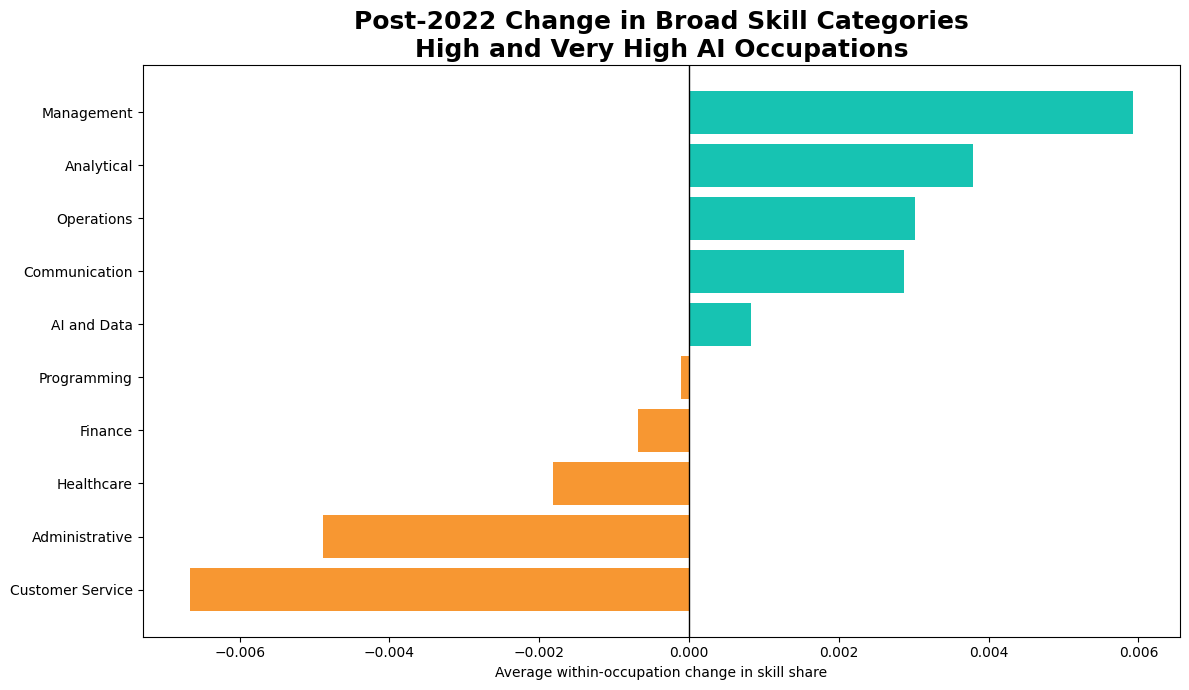

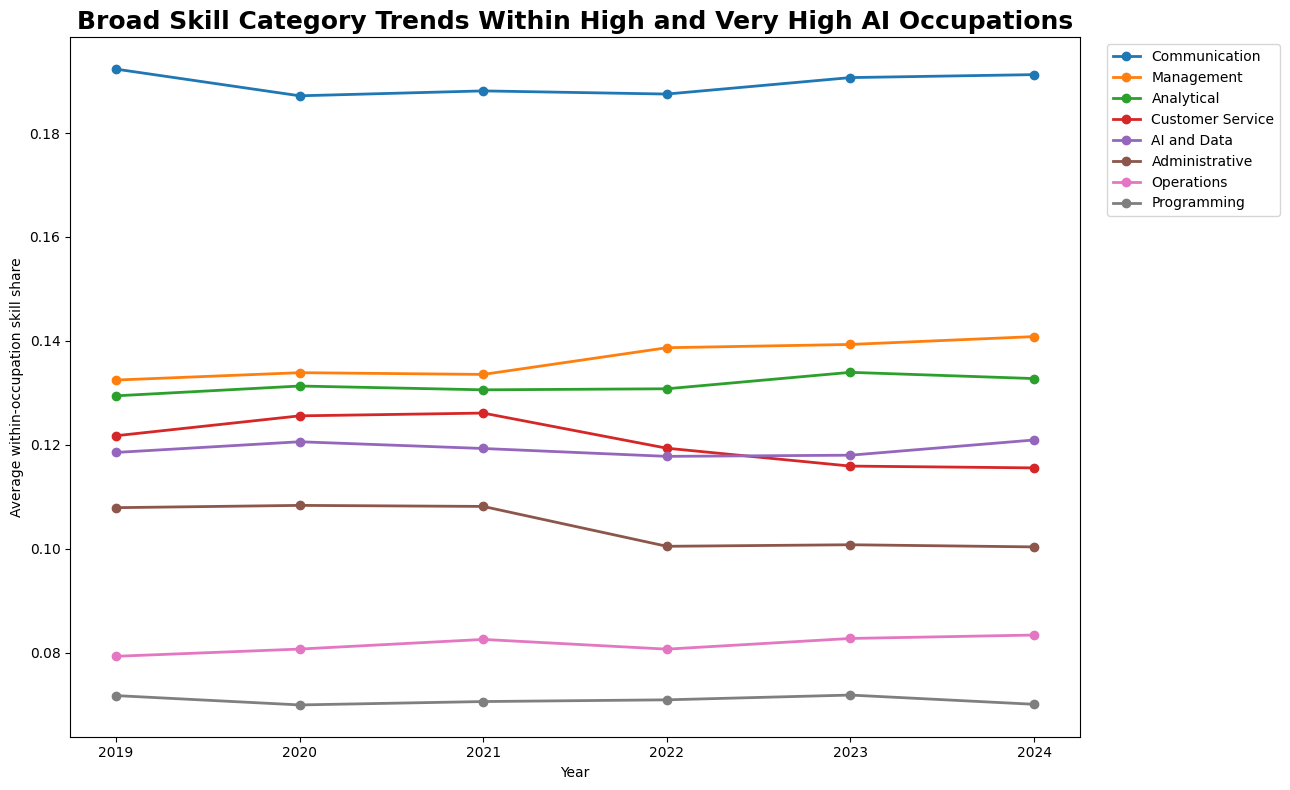


DONE.
Outputs saved to: C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO\Category Skill Outputs\Within Occupation Analysis


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import ast
import json
import re
from collections import Counter

# =========================================================
# PATHS
# =========================================================

POSTINGS_FILE = Path(
    r"G:\Shared drives\EO_OPERATIONS\Grants\PCIC Analysis\Job Posting Data\raw_data\df_2016_2025.csv"
)

AI_COMPOSITE_FILE = Path(
    r"G:\Shared drives\EO_ECONOMIC ANALYSIS\ea_common\Projects\AI\risk_index\ai_exposure_composite_clean.csv"
)

OUT_FOLDER = Path(
    r"C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO\Category Skill Outputs\Within Occupation Analysis"
)

OUT_FOLDER.mkdir(parents=True, exist_ok=True)

# =========================================================
# SETTINGS
# =========================================================

START_YEAR = 2019
END_YEAR = 2024
CHUNK_SIZE = 100_000

PATINA = "#17C3B2"
CARROT = "#F79732"

# =========================================================
# BROAD CATEGORY RULES
# =========================================================

CATEGORY_MAP = {

    "Programming": [
        "python", "sql", "java", "javascript", "software",
        "coding", "programming", "web development",
        "application development", "c#", "css", "html",
        "agile", "scrum", "cloud", "git", "api"
    ],

    "AI and Data": [
        "machine learning", "artificial intelligence",
        "data science", "analytics", "data analysis",
        "automation", "data visualization", "ai",
        "business intelligence"
    ],

    "Communication": [
        "communication", "presentation", "leadership",
        "interpersonal", "collaboration", "negotiation",
        "public speaking", "writing", "speaking",
        "relationship management"
    ],

    "Management": [
        "project management", "scheduling", "workflow",
        "coordination", "planning", "organization",
        "organizational", "time management",
        "supervision", "mentorship", "coaching",
        "prioritization", "kpi"
    ],

    "Analytical": [
        "problem solving", "critical thinking",
        "decision making", "analysis", "research",
        "mathematics", "troubleshooting",
        "continuous improvement"
    ],

    "Administrative": [
        "microsoft word", "data entry", "billing",
        "administrative", "clerical", "documentation",
        "computer literacy", "office", "typing",
        "records management"
    ],

    "Customer Service": [
        "customer service", "sales", "retail",
        "hospitality", "service", "client relations",
        "call center", "customer support"
    ],

    "Operations": [
        "inventory", "warehousing", "construction",
        "logistics", "supply chain", "shipping",
        "forklift", "loading", "sanitation",
        "operations"
    ],

    "Finance": [
        "accounting", "budgeting", "finance",
        "financial analysis", "bookkeeping",
        "accounts payable", "accounts receivable",
        "business administration", "economics"
    ],

    "Healthcare": [
        "patient care", "nursing", "medical records",
        "clinical", "healthcare", "ehr",
        "electronic medical records", "phlebotomy"
    ]
}

# =========================================================
# HELPERS
# =========================================================

def fix_soc(x):

    s = str(x).strip()

    month_map = {
        "Jan": "01", "Feb": "02", "Mar": "03", "Apr": "04",
        "May": "05", "Jun": "06", "Jul": "07", "Aug": "08",
        "Sep": "09", "Oct": "10", "Nov": "11", "Dec": "12"
    }

    for month, num in month_map.items():
        if s.startswith(month + "-"):
            s = s.replace(month + "-", num + "-", 1)

    match = re.search(r"(\d{2}-\d{4})", s)

    if match:
        return match.group(1)

    return np.nan


def clean_skill(skill):

    return (
        str(skill)
        .lower()
        .strip()
        .replace("’", "'")
        .replace("–", "-")
        .replace("—", "-")
    )


def parse_skill_list(x):

    if pd.isna(x):
        return []

    s = str(x).strip()

    if s in ["", "[]", "nan", "None"]:
        return []

    try:
        parsed = ast.literal_eval(s)
        if isinstance(parsed, list):
            return [str(v).strip() for v in parsed if str(v).strip()]
    except:
        pass

    try:
        parsed = json.loads(s)
        if isinstance(parsed, list):
            return [str(v).strip() for v in parsed if str(v).strip()]
    except:
        pass

    return []


def assign_category(skill):

    s = clean_skill(skill)

    for category, keywords in CATEGORY_MAP.items():
        for kw in keywords:
            if kw in s:
                return category

    return "Other"


def standardize_exposure(x):

    s = str(x).strip().lower()

    mapping = {
        "very low": "Very Low",
        "low": "Low",
        "medium": "Medium",
        "high": "High",
        "very high": "Very High"
    }

    return mapping.get(s, np.nan)

# =========================================================
# LOAD AI EXPOSURE FILE
# =========================================================

ai = pd.read_csv(AI_COMPOSITE_FILE)
ai.columns = ai.columns.astype(str).str.strip()

soc_candidates = ["SOC", "SOC Code", "SOC2018.1", "SOC Code1", "O*NET-SOC Code"]
exposure_candidates = ["AI Exposure Category", "exposure", "Exposure", "Category", "exposure_group"]

soc_ai_col = next((c for c in soc_candidates if c in ai.columns), None)
exposure_ai_col = next((c for c in exposure_candidates if c in ai.columns), None)

if soc_ai_col is None:
    raise KeyError("Could not find SOC column in AI composite file.")

if exposure_ai_col is None:
    raise KeyError("Could not find exposure column in AI composite file.")

ai = ai[[soc_ai_col, exposure_ai_col]].drop_duplicates()
ai.columns = ["SOC_5", "Exposure"]

ai["SOC_5"] = ai["SOC_5"].apply(fix_soc)
ai["Exposure"] = ai["Exposure"].apply(standardize_exposure)

ai = ai.dropna(subset=["SOC_5", "Exposure"]).copy()

# Only High and Very High
ai = ai[ai["Exposure"].isin(["High", "Very High"])].copy()

print("AI occupations included:")
print(ai["Exposure"].value_counts())

# =========================================================
# PROCESS POSTINGS
# =========================================================

records = []

usecols = [
    "SOC_5",
    "YEAR",
    "SKILLS_NAME",
    "SOFTWARE_SKILLS_NAME"
]

for i, chunk in enumerate(
    pd.read_csv(
        POSTINGS_FILE,
        usecols=lambda c: c in usecols,
        chunksize=CHUNK_SIZE,
        low_memory=False
    ),
    start=1
):

    chunk["SOC_5"] = chunk["SOC_5"].apply(fix_soc)

    chunk["YEAR"] = pd.to_numeric(
        chunk["YEAR"],
        errors="coerce"
    )

    chunk = chunk[
        chunk["YEAR"].between(START_YEAR, END_YEAR)
    ].copy()

    chunk = chunk.merge(
        ai,
        on="SOC_5",
        how="inner"
    )

    for _, row in chunk.iterrows():

        soc = row["SOC_5"]
        year = int(row["YEAR"])

        skills = []
        skills += parse_skill_list(row.get("SKILLS_NAME"))
        skills += parse_skill_list(row.get("SOFTWARE_SKILLS_NAME"))

        if not skills:
            continue

        categories = sorted(set(assign_category(skill) for skill in skills))
        categories = [c for c in categories if c != "Other"]

        if not categories:
            continue

        for category in categories:

            records.append({
                "SOC_5": soc,
                "Year": year,
                "Category": category
            })

    print(f"Processed chunk {i}")

df = pd.DataFrame(records)

# =========================================================
# WITHIN-OCCUPATION CATEGORY SHARES
# =========================================================

counts = (
    df
    .groupby(["SOC_5", "Year", "Category"], as_index=False)
    .size()
    .rename(columns={"size": "Category_Count"})
)

totals = (
    df
    .groupby(["SOC_5", "Year"], as_index=False)
    .size()
    .rename(columns={"size": "Total_Category_Mentions"})
)

shares = counts.merge(
    totals,
    on=["SOC_5", "Year"],
    how="left"
)

shares["Share"] = shares["Category_Count"] / shares["Total_Category_Mentions"]

shares["Period"] = np.where(
    shares["Year"] <= 2022,
    "Pre",
    "Post"
)

# =========================================================
# PRE / POST WITHIN EACH OCCUPATION
# =========================================================

period = (
    shares
    .groupby(["SOC_5", "Category", "Period"], as_index=False)
    .agg(Share=("Share", "mean"))
)

wide = (
    period
    .pivot_table(
        index=["SOC_5", "Category"],
        columns="Period",
        values="Share"
    )
    .reset_index()
)

wide = wide.dropna(subset=["Pre", "Post"]).copy()
wide["Change"] = wide["Post"] - wide["Pre"]

# Average the within-occupation changes across occupations
category_change = (
    wide
    .groupby("Category", as_index=False)
    .agg(
        Avg_Within_Occ_Change=("Change", "mean"),
        Occupation_Count=("SOC_5", "nunique")
    )
    .sort_values("Avg_Within_Occ_Change", ascending=False)
)

category_change.to_excel(
    OUT_FOLDER / "Within_Occupation_Category_Pre_Post_Change.xlsx",
    index=False
)

# =========================================================
# FIGURE 1: CLEAN PRE/POST CATEGORY CHANGE
# =========================================================

plot_df = category_change.copy()

colors = np.where(
    plot_df["Avg_Within_Occ_Change"] >= 0,
    PATINA,
    CARROT
)

plt.figure(figsize=(12, 7))

plt.barh(
    plot_df["Category"],
    plot_df["Avg_Within_Occ_Change"],
    color=colors
)

plt.axvline(0, color="black", linewidth=1)

plt.title(
    "Post-2022 Change in Broad Skill Categories\nHigh and Very High AI Occupations",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Average within-occupation change in skill share")
plt.ylabel("")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    OUT_FOLDER / "Figure_Within_Occupation_Category_Change.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =========================================================
# FIGURE 2: CATEGORY TREND OVER TIME
# =========================================================

trend = (
    shares
    .groupby(["Category", "Year"], as_index=False)
    .agg(Share=("Share", "mean"))
)

top_categories = (
    trend
    .groupby("Category")["Share"]
    .mean()
    .sort_values(ascending=False)
    .head(8)
    .index
)

plot_trend = trend[
    trend["Category"].isin(top_categories)
].copy()

plt.figure(figsize=(13, 8))

for category in top_categories:

    temp = plot_trend[
        plot_trend["Category"] == category
    ].sort_values("Year")

    plt.plot(
        temp["Year"],
        temp["Share"],
        marker="o",
        linewidth=2,
        label=category
    )

plt.title(
    "Broad Skill Category Trends Within High and Very High AI Occupations",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Year")
plt.ylabel("Average within-occupation skill share")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    OUT_FOLDER / "Figure_Within_Occupation_Category_Trends.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =========================================================
# SAVE SUPPORTING FILES
# =========================================================

shares.to_csv(
    OUT_FOLDER / "Within_Occupation_Category_Year_Shares.csv",
    index=False
)

wide.to_excel(
    OUT_FOLDER / "Within_Occupation_Category_SOC_Pre_Post_Detail.xlsx",
    index=False
)

print("\nDONE.")
print(f"Outputs saved to: {OUT_FOLDER}")

In [4]:
from pathlib import Path

POSTINGS_FILE = Path(
    r"G:\Shared drives\EO_OPERATIONS\Grants\PCIC Analysis\Job Posting Data\raw_data\df_2016_2025.csv"
)

from collections import Counter
import pandas as pd

skill_counter = Counter()

usecols = [
    "SKILLS_NAME",
    "SOFTWARE_SKILLS_NAME"
]

for chunk in pd.read_csv(
    POSTINGS_FILE,
    usecols=usecols,
    chunksize=100_000,
    low_memory=False
):

    for col in usecols:

        parsed_skills = chunk[col].dropna().apply(parse_skill_list)

        for skill_list in parsed_skills:
            for skill in skill_list:

                cleaned = clean_skill(skill)

                if cleaned:
                    skill_counter[cleaned] += 1

# Top 100 most common skills
top_skills = pd.DataFrame(
    skill_counter.most_common(100),
    columns=["Skill", "Count"]
)

print(top_skills)

                             Skill    Count
0                    communication  2866077
1                 customer service  2407318
2                       management  1936424
3                            sales  1398344
4                  microsoft excel  1395144
..                             ...      ...
95                office equipment   176687
96               product knowledge   176465
97                      purchasing   173544
98                      enthusiasm   172970
99  continuous improvement process   171537

[100 rows x 2 columns]


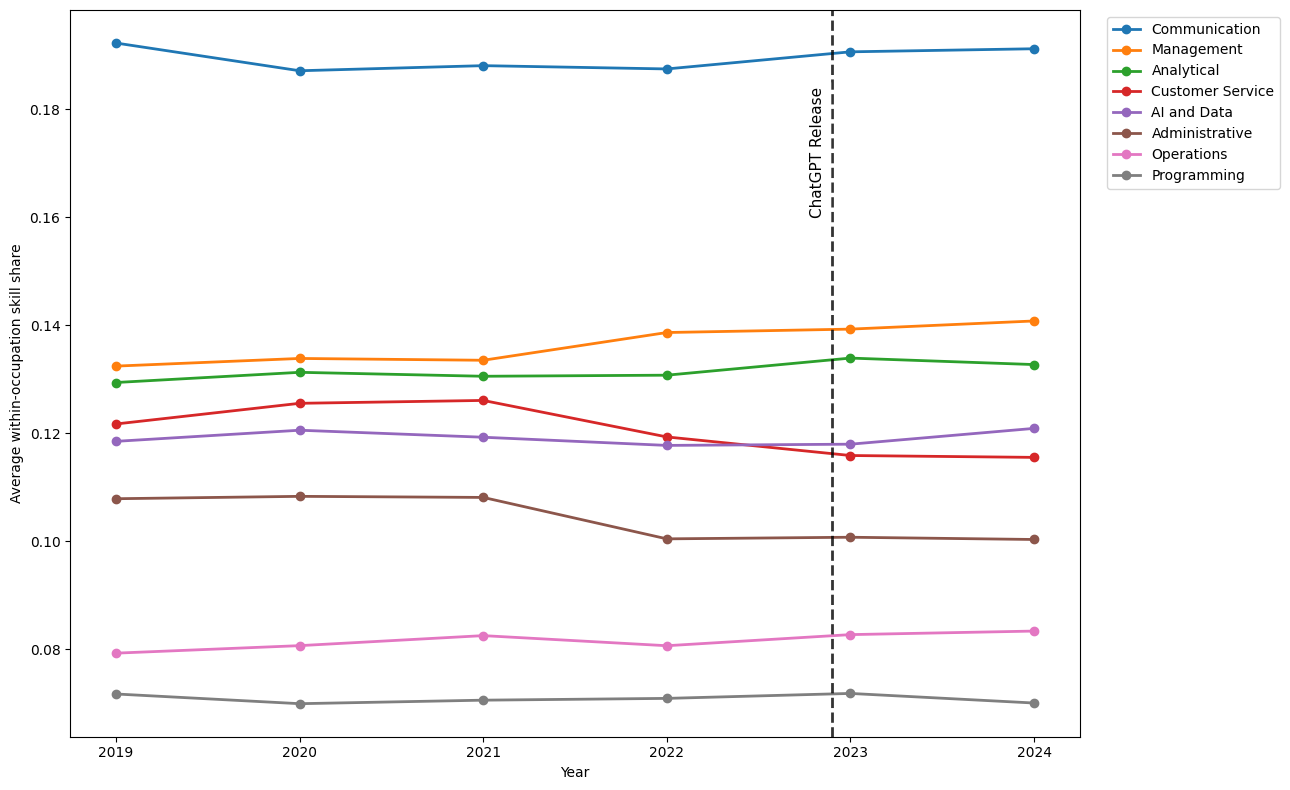

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

OUT_FOLDER = Path(
    r"C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO\Category Skill Outputs\Within Occupation Analysis"
)

PATINA = "#17C3B2"
CARROT = "#F79732"

shares = pd.read_csv(
    OUT_FOLDER / "Within_Occupation_Category_Year_Shares.csv"
)

trend = (
    shares
    .groupby(["Category", "Year"], as_index=False)
    .agg(Share=("Share", "mean"))
)

top_categories = (
    trend
    .groupby("Category")["Share"]
    .mean()
    .sort_values(ascending=False)
    .head(8)
    .index
)

plot_trend = trend[
    trend["Category"].isin(top_categories)
].copy()

plt.figure(figsize=(13, 8))

for category in top_categories:
    temp = plot_trend[
        plot_trend["Category"] == category
    ].sort_values("Year")

    plt.plot(
        temp["Year"],
        temp["Share"],
        marker="o",
        linewidth=2,
        label=category
    )

# ChatGPT launched publicly in late 2022
plt.axvline(
    x=2022.9,
    color="black",
    linestyle="--",
    linewidth=2,
    alpha=0.8
)

plt.text(
    2022.86,
    0.172,   # LOWER
    "ChatGPT Release",
    rotation=90,
    va="center",
    ha="right",
    fontsize=11,
    backgroundcolor="white"
)

plt.xlabel("Year")
plt.ylabel("Average within-occupation skill share")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    OUT_FOLDER / "Figure_Within_Occupation_Category_Trends_With_ChatGPT_Line.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

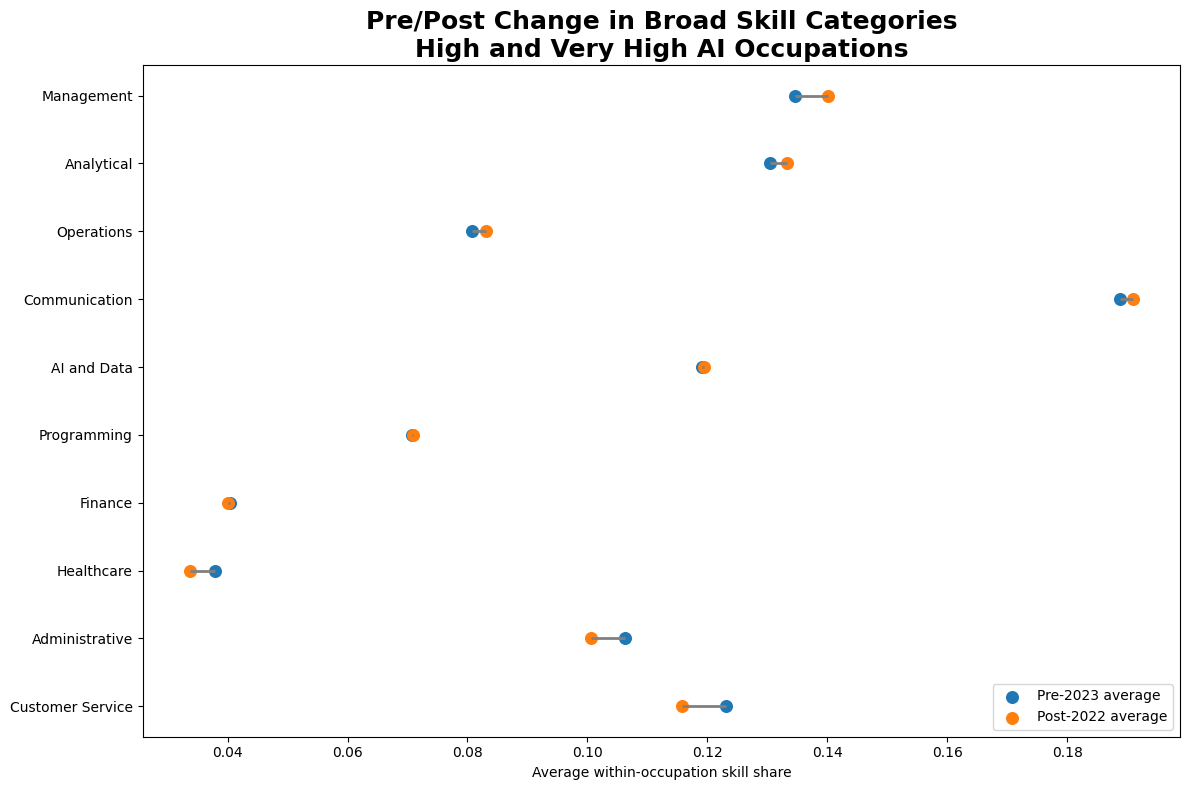

In [17]:
# =========================================================
# FIGURE 3: PRE VS POST AVERAGE SHARE BY CATEGORY
# This helps explain the bar chart and trend chart together
# =========================================================

pre_post = (
    shares
    .groupby(["Category", "Period"], as_index=False)
    .agg(Share=("Share", "mean"))
)

pre_post_wide = (
    pre_post
    .pivot(index="Category", columns="Period", values="Share")
    .reset_index()
)

pre_post_wide["Change"] = pre_post_wide["Post"] - pre_post_wide["Pre"]

pre_post_wide = pre_post_wide.sort_values("Change", ascending=True)

plt.figure(figsize=(12, 8))

y_pos = range(len(pre_post_wide))

plt.hlines(
    y=y_pos,
    xmin=pre_post_wide["Pre"],
    xmax=pre_post_wide["Post"],
    color="gray",
    linewidth=2
)

plt.scatter(
    pre_post_wide["Pre"],
    y_pos,
    label="Pre-2023 average",
    s=70
)

plt.scatter(
    pre_post_wide["Post"],
    y_pos,
    label="Post-2022 average",
    s=70
)

plt.yticks(
    y_pos,
    pre_post_wide["Category"]
)

plt.xlabel("Average within-occupation skill share")
plt.ylabel("")

plt.title(
    "Pre/Post Change in Broad Skill Categories\nHigh and Very High AI Occupations",
    fontsize=18,
    weight="bold"
)

plt.legend(loc="lower right")

plt.tight_layout()

plt.savefig(
    OUT_FOLDER / "Figure_Pre_Post_Category_Dot_Change.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

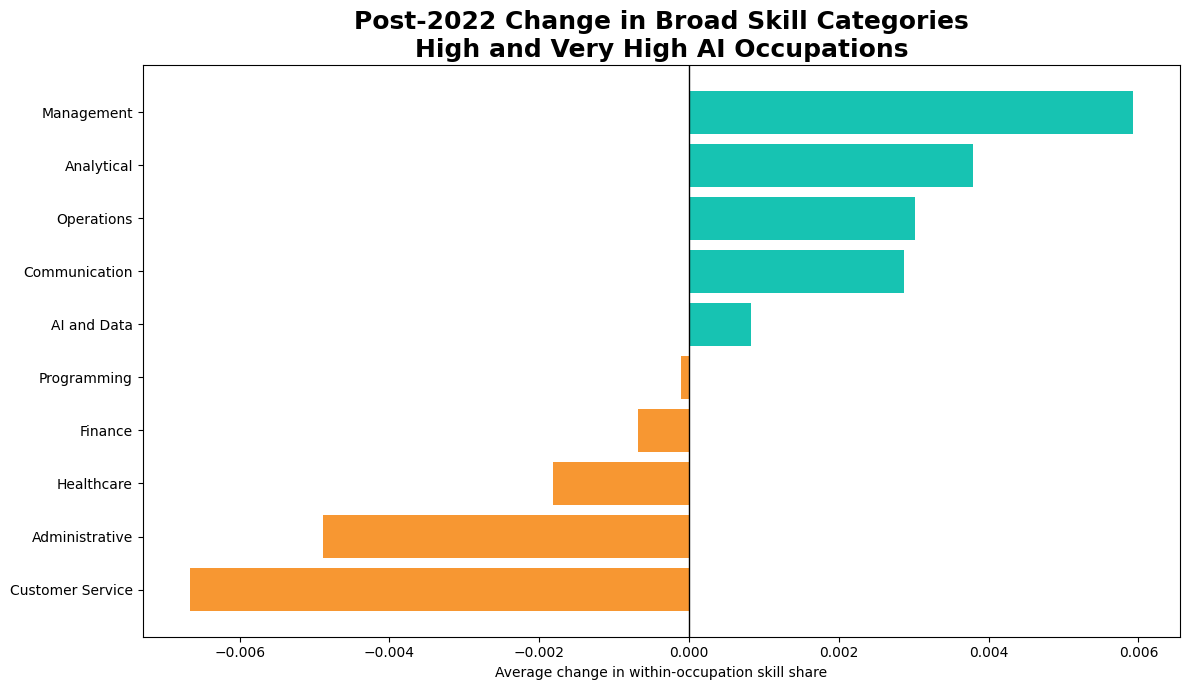

In [19]:
# =========================================================
# FIGURE 1: CLEAN PRE/POST CATEGORY CHANGE
# =========================================================

plot_df = category_change.copy()

colors = np.where(
    plot_df["Avg_Within_Occ_Change"] >= 0,
    PATINA,
    CARROT
)

plt.figure(figsize=(12, 7))

plt.barh(
    plot_df["Category"],
    plot_df["Avg_Within_Occ_Change"],
    color=colors
)

plt.axvline(0, color="black", linewidth=1)

plt.title(
    "Post-2022 Change in Broad Skill Categories\nHigh and Very High AI Occupations",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Average change in within-occupation skill share")
plt.ylabel("")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    OUT_FOLDER / "Figure_Within_Occupation_Category_Change.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

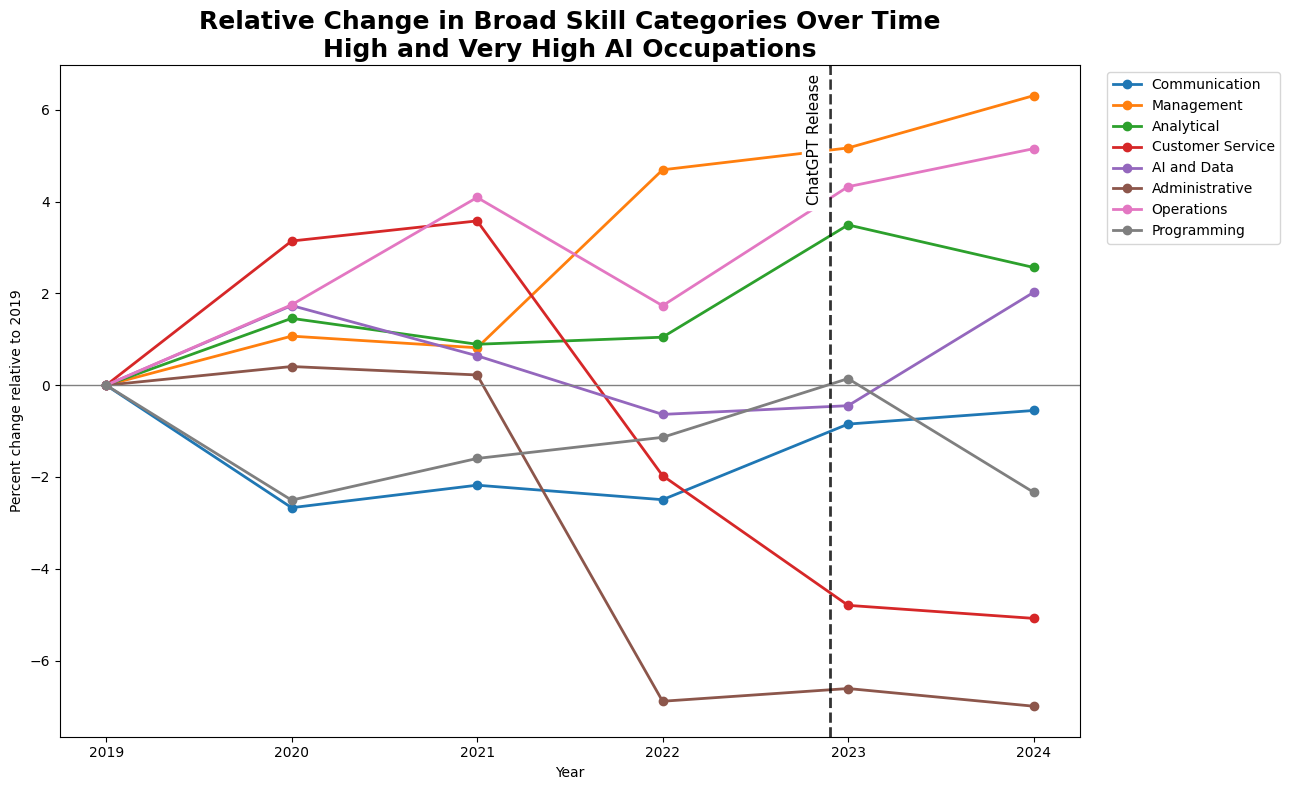

In [20]:
# =========================================================
# FIGURE 2: INDEXED CATEGORY CHANGE OVER TIME
# Shows change relative to 2019 baseline
# =========================================================

trend = (
    shares
    .groupby(["Category", "Year"], as_index=False)
    .agg(Share=("Share", "mean"))
)

top_categories = (
    trend
    .groupby("Category")["Share"]
    .mean()
    .sort_values(ascending=False)
    .head(8)
    .index
)

plot_trend = trend[
    trend["Category"].isin(top_categories)
].copy()

# =========================================================
# INDEX TO 2019
# =========================================================

baseline = (
    plot_trend[
        plot_trend["Year"] == 2019
    ][["Category", "Share"]]
    .rename(columns={"Share": "Baseline_2019"})
)

plot_trend = plot_trend.merge(
    baseline,
    on="Category",
    how="left"
)

plot_trend["Indexed_Change"] = (
    (
        plot_trend["Share"] -
        plot_trend["Baseline_2019"]
    )
    /
    plot_trend["Baseline_2019"]
) * 100

# =========================================================
# PLOT
# =========================================================

plt.figure(figsize=(13, 8))

for category in top_categories:

    temp = plot_trend[
        plot_trend["Category"] == category
    ].sort_values("Year")

    plt.plot(
        temp["Year"],
        temp["Indexed_Change"],
        marker="o",
        linewidth=2,
        label=category
    )

# ChatGPT release marker
plt.axvline(
    x=2022.9,
    color="black",
    linestyle="--",
    linewidth=2,
    alpha=0.8
)

plt.text(
    2022.86,
    plot_trend["Indexed_Change"].max() * 0.85,
    "ChatGPT Release",
    rotation=90,
    va="center",
    ha="right",
    fontsize=11,
    backgroundcolor="white"
)

plt.axhline(
    0,
    color="gray",
    linewidth=1
)

plt.title(
    "Relative Change in Broad Skill Categories Over Time\nHigh and Very High AI Occupations",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Year")

plt.ylabel(
    "Percent change relative to 2019"
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    OUT_FOLDER / "Figure_Indexed_Category_Trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

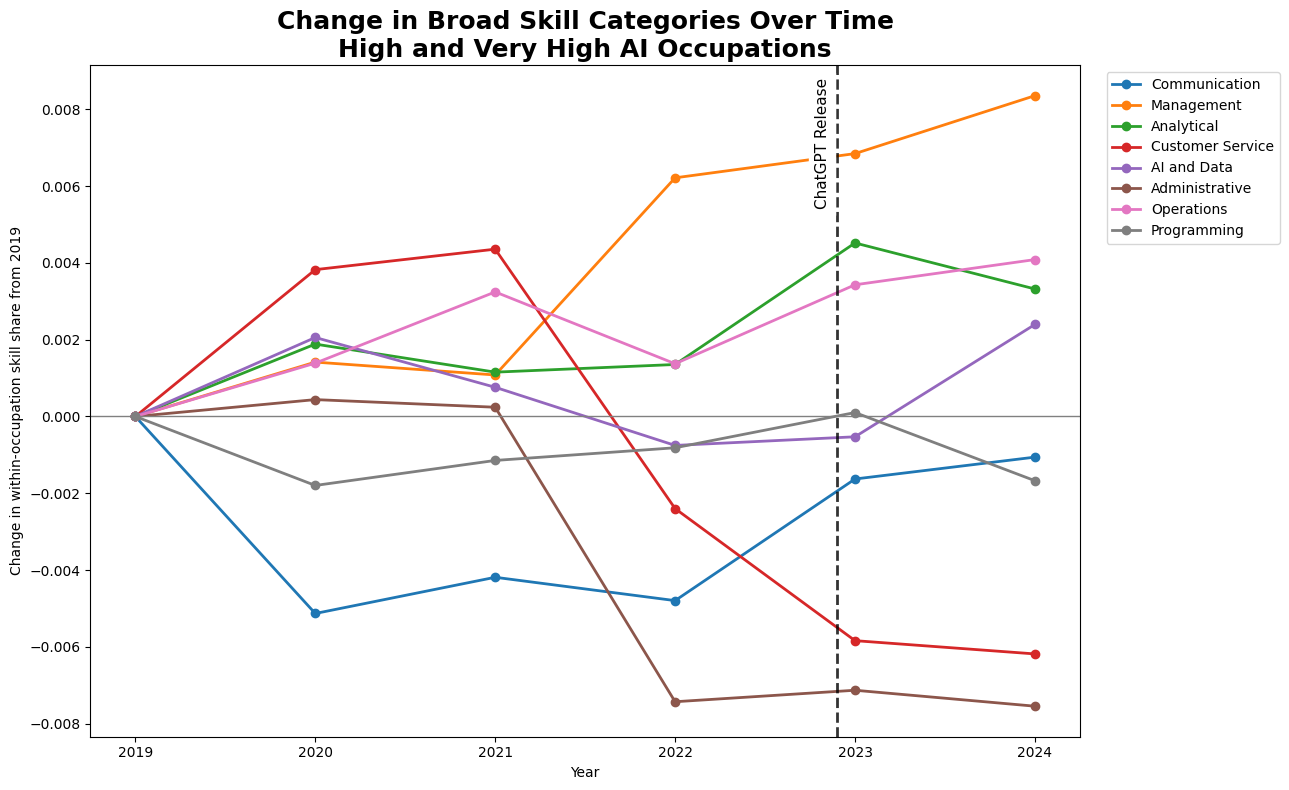

In [ ]:
# =========================================================
# FIGURE 2: CATEGORY CHANGE OVER TIME FROM 2019 BASELINE
# Shows percentage-point change in skill share relative to 2019
# =========================================================

trend = (
    shares
    .groupby(["Category", "Year"], as_index=False)
    .agg(Share=("Share", "mean"))
)

top_categories = (
    trend
    .groupby("Category")["Share"]
    .mean()
    .sort_values(ascending=False)
    .head(8)
    .index
)

plot_trend = trend[
    trend["Category"].isin(top_categories)
].copy()

# =========================================================
# BASELINE TO 2019
# =========================================================

baseline = (
    plot_trend[
        plot_trend["Year"] == 2019
    ][["Category", "Share"]]
    .rename(columns={"Share": "Baseline_2019"})
)

plot_trend = plot_trend.merge(
    baseline,
    on="Category",
    how="left"
)

plot_trend["Change_From_2019"] = (
    plot_trend["Share"] -
    plot_trend["Baseline_2019"]
)

# =========================================================
# PLOT
# =========================================================

plt.figure(figsize=(13, 8))

for category in top_categories:

    temp = plot_trend[
        plot_trend["Category"] == category
    ].sort_values("Year")

    plt.plot(
        temp["Year"],
        temp["Change_From_2019"],
        marker="o",
        linewidth=2,
        label=category
    )

plt.axvline(
    x=2022.9,
    color="black",
    linestyle="--",
    linewidth=2,
    alpha=0.8
)

plt.text(
    2022.86,
    plot_trend["Change_From_2019"].max() * 0.85,
    "ChatGPT Release",
    rotation=90,
    va="center",
    ha="right",
    fontsize=11,
    backgroundcolor="white"
)

plt.axhline(
    0,
    color="gray",
    linewidth=1
)

plt.title(
    "Change in Broad Skill Categories Over Time\nHigh and Very High AI Occupations",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Year")
plt.ylabel("Change in within-occupation skill share from 2019")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    OUT_FOLDER / "Figure_Category_Change_From_2019.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

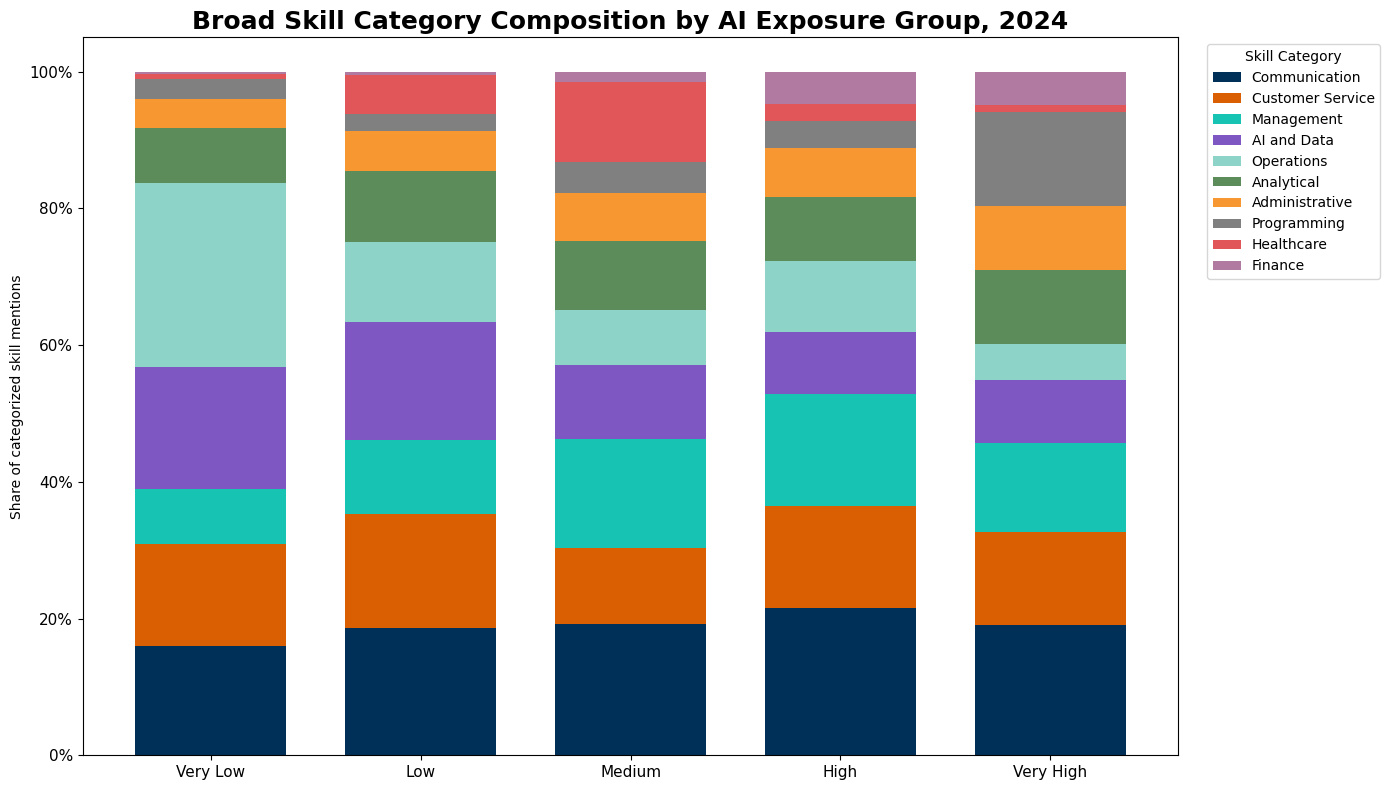

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import PercentFormatter

OUT_FOLDER = Path(
    r"C:\Users\301533\Documents\AI Analysis\Ligthcast Skills & RO\Category Skill Outputs"
)

CATEGORY_FILE = OUT_FOLDER / "Category_Exposure_Year_Shares.xlsx"

PATINA = "#17C3B2"
CARROT = "#F79732"
DARK_BLUE = "#003057"

# =========================================================
# LOAD CATEGORY SHARES
# =========================================================

df = pd.read_excel(CATEGORY_FILE)

df = df[
    df["Year"] == 2024
].copy()

# =========================================================
# EXPOSURE ORDER
# =========================================================

exposure_order = [
    "Very Low",
    "Low",
    "Medium",
    "High",
    "Very High"
]

df = df[
    df["Exposure"].isin(exposure_order)
].copy()

# =========================================================
# BUILD 100% STACKED DATA
# =========================================================

plot_df = (
    df
    .groupby(["Exposure", "Category"], as_index=False)
    .agg(Count=("Count", "sum"))
)

pivot = (
    plot_df
    .pivot(index="Exposure", columns="Category", values="Count")
    .fillna(0)
)

pivot = pivot.loc[exposure_order]

# Convert to 100% within each exposure group
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)

# Optional: order categories by average share
category_order = (
    pivot_pct
    .mean(axis=0)
    .sort_values(ascending=False)
    .index
)

pivot_pct = pivot_pct[category_order]

# =========================================================
# COLORS
# =========================================================

color_map = {
    "Communication": "#003057",
    "Management": "#17C3B2",
    "Analytical": "#5B8C5A",
    "AI and Data": "#7E57C2",
    "Administrative": "#F79732",
    "Customer Service": "#D95F02",
    "Operations": "#8DD3C7",
    "Programming": "#808080",
    "Finance": "#B07AA1",
    "Healthcare": "#E15759"
}

colors = [
    color_map.get(category, "#999999")
    for category in pivot_pct.columns
]

# =========================================================
# PLOT
# =========================================================

ax = pivot_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 8),
    color=colors,
    width=0.72
)

plt.title(
    "Broad Skill Category Composition by AI Exposure Group, 2024",
    fontsize=18,
    weight="bold"
)

plt.xlabel("")
plt.ylabel("Share of categorized skill mentions")

ax.yaxis.set_major_formatter(PercentFormatter(1.0))

plt.xticks(
    rotation=0,
    fontsize=11
)

plt.yticks(fontsize=11)

plt.legend(
    title="Skill Category",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    OUT_FOLDER / "Figure_100pct_Stacked_Category_By_Exposure_2024.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()